# PHASE 0 — Local RTX 3050 Environment and Project Setup

## Objective

This phase prepares the local Windows environment for the complete
TrustSeg-XAI brain tumor MRI study.

The local implementation will preserve the original experimental design used
in the Google Colab study as closely as possible.

## Hardware

The experiment will use the local NVIDIA RTX 3050 GPU whenever CUDA is
available.

## Research Pipeline

### Segmentation
- U-Net + ResNet34
- U-Net++ + ResNet34
- TrustSeg-XAI segmentation branch

### Classification
- EfficientNet-B0
- ConvNeXt-Tiny
- TrustSeg-XAI classification branch

### Trustworthiness
- Mask Dependency
- Grad-CAM++ quantitative XAI
- Causal Faithfulness
- Cross-Plane Analysis
- No-Tumor Negative Control
- Calibration
- Statistical Analysis

## Core Experimental Configuration

- Random seed: 42
- Input resolution: 256 × 256
- Number of classes: 4
- Classes: Glioma, Meningioma, Pituitary, No Tumor
- Optimizer: AdamW
- Learning rate: 1e-4
- Weight decay: 1e-4
- Early stopping patience: 3
- Segmentation threshold: 0.50
- Mixed precision: enabled when CUDA is available

## Important Reproducibility Rule

The dataset organization, class mapping, preprocessing strategy, model
architectures, evaluation metrics, and test protocol will remain consistent
with the original TrustSeg-XAI experiment.

The official test set will not be used for model selection.

In [40]:
# ============================================================
# PHASE 0A.1 — Verify active Jupyter Python environment
# ============================================================

import sys
import subprocess

print("=" * 80)
print("ACTIVE JUPYTER ENVIRONMENT")
print("=" * 80)

print("Python version :", sys.version)
print("Python path    :", sys.executable)

print("\nPIP INFORMATION")
print("-" * 80)

subprocess.run(
    [
        sys.executable,
        "-m",
        "pip",
        "--version"
    ]
)

ACTIVE JUPYTER ENVIRONMENT
Python version : 3.12.10 (tags/v3.12.10:0cc8128, Apr  8 2025, 12:21:36) [MSC v.1943 64 bit (AMD64)]
Python path    : c:\Program Files\Python312\python.exe

PIP INFORMATION
--------------------------------------------------------------------------------


CompletedProcess(args=['c:\\Program Files\\Python312\\python.exe', '-m', 'pip', '--version'], returncode=0)

In [41]:
# ============================================================
# PHASE 0A.2 — Confirm GPU-enabled PyTorch
# ============================================================

import torch
import torchvision

print("=" * 80)
print("CURRENT PYTORCH INSTALLATION")
print("=" * 80)

print("Torch        :", torch.__version__)
print("TorchVision  :", torchvision.__version__)
print("CUDA build   :", torch.version.cuda)
print("CUDA usable  :", torch.cuda.is_available())
print("Torch path   :", torch.__file__)

assert torch.cuda.is_available(), (
    "CUDA is not available in the current PyTorch environment."
)

print("\n✅ GPU-enabled PyTorch is installed.")
print("✅ CUDA is available.")

CURRENT PYTORCH INSTALLATION
Torch        : 2.13.0+cu126
TorchVision  : 0.28.0+cu126
CUDA build   : 12.6
CUDA usable  : True
Torch path   : C:\Users\Acer\AppData\Roaming\Python\Python312\site-packages\torch\__init__.py

✅ GPU-enabled PyTorch is installed.
✅ CUDA is available.


In [42]:
# ============================================================
# PHASE 0A.3 — Verify Python Environment and GPU
# ============================================================

import sys
import torch

print("=" * 80)
print("PYTHON ENVIRONMENT & GPU CHECK")
print("=" * 80)

print("Python executable :", sys.executable)
print("Python version    :", sys.version.split()[0])
print("Torch version     :", torch.__version__)
print("CUDA version      :", torch.version.cuda)
print("CUDA available    :", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU count         :", torch.cuda.device_count())
    print("GPU name          :", torch.cuda.get_device_name(0))
    print("Current GPU       :", torch.cuda.current_device())

print("=" * 80)

PYTHON ENVIRONMENT & GPU CHECK
Python executable : c:\Program Files\Python312\python.exe
Python version    : 3.12.10
Torch version     : 2.13.0+cu126
CUDA version      : 12.6
CUDA available    : True
GPU count         : 1
GPU name          : NVIDIA GeForce RTX 3050 6GB Laptop GPU
Current GPU       : 0


In [43]:
# ============================================================
# PHASE 0A.5 — Confirm selected virtual environment
# ============================================================

import sys

print("=" * 80)
print("ACTIVE PYTHON ENVIRONMENT")
print("=" * 80)

print("Python executable :", sys.executable)
print("Python version    :", sys.version.split()[0])

print("=" * 80)

ACTIVE PYTHON ENVIRONMENT
Python executable : c:\Program Files\Python312\python.exe
Python version    : 3.12.10


In [44]:
# ============================================================
# PHASE 0B.1 — Uninstall CPU-only PyTorch packages
# ============================================================

import sys
import subprocess

packages = [
    "torch",
    "torchvision",
    "torchaudio"
]

subprocess.check_call(
    [
        sys.executable,
        "-m",
        "pip",
        "uninstall",
        "-y",
        *packages
    ]
)

print(
    "\n✅ Old PyTorch packages removed."
)


✅ Old PyTorch packages removed.


In [45]:
# ============================================================
# PHASE 0C.1 — Install CUDA-enabled PyTorch
# ============================================================

import sys
import subprocess

subprocess.check_call(
    [
        sys.executable,
        "-m",
        "pip",
        "install",
        "--force-reinstall",
        "--no-cache-dir",
        "torch==2.13.0+cu126",
        "torchvision==0.28.0+cu126",
        "--index-url",
        "https://download.pytorch.org/whl/cu126"
    ]
)

print(
    "\n✅ CUDA 12.6 PyTorch packages installed."
)

print(
    "⚠️ RESTART THE JUPYTER KERNEL NOW."
)


✅ CUDA 12.6 PyTorch packages installed.
⚠️ RESTART THE JUPYTER KERNEL NOW.


In [46]:
# ============================================================
# PHASE 0D.1 — Verify CUDA-enabled PyTorch
# ============================================================

import torch
import torchvision

print("=" * 80)
print("PYTORCH CUDA ENVIRONMENT")
print("=" * 80)

print(
    "PyTorch version    :",
    torch.__version__
)

print(
    "TorchVision version:",
    torchvision.__version__
)

print(
    "CUDA available     :",
    torch.cuda.is_available()
)

print(
    "PyTorch CUDA       :",
    torch.version.cuda
)


if torch.cuda.is_available():

    print(
        "GPU                :",
        torch.cuda.get_device_name(0)
    )

    gpu_properties = (
        torch.cuda.get_device_properties(0)
    )

    gpu_memory_gb = (
        gpu_properties.total_memory
        / 1024**3
    )

    print(
        f"GPU VRAM           : "
        f"{gpu_memory_gb:.2f} GB"
    )

    print(
        "cuDNN version      :",
        torch.backends.cudnn.version()
    )


else:

    print(
        "\n❌ CUDA STILL NOT AVAILABLE."
    )

PYTORCH CUDA ENVIRONMENT
PyTorch version    : 2.13.0+cu126
TorchVision version: 0.28.0+cu126
CUDA available     : True
PyTorch CUDA       : 12.6
GPU                : NVIDIA GeForce RTX 3050 6GB Laptop GPU
GPU VRAM           : 6.00 GB
cuDNN version      : 91002


In [47]:
# ============================================================
# PHASE 0D.2 — Real CUDA computation test
# ============================================================

import torch

assert torch.cuda.is_available(), (
    "❌ CUDA is unavailable. Do not continue."
)


DEVICE = torch.device(
    "cuda:0"
)


# Create matrices directly on GPU
x = torch.randn(
    2000,
    2000,
    device=DEVICE
)

y = torch.randn(
    2000,
    2000,
    device=DEVICE
)


# Actual CUDA operation
z = torch.matmul(
    x,
    y
)


# Synchronize to ensure GPU calculation completed
torch.cuda.synchronize()


print("=" * 80)

print(
    "RTX 3050 REAL COMPUTATION TEST"
)

print("=" * 80)

print(
    "Result device :",
    z.device
)

print(
    "Result shape  :",
    z.shape
)

print(
    "GPU           :",
    torch.cuda.get_device_name(0)
)

print(
    "CUDA runtime  :",
    torch.version.cuda
)

print(
    "Allocated VRAM:",
    round(
        torch.cuda.memory_allocated(0)
        / 1024**3,
        3
    ),
    "GB"
)


assert (
    z.device.type
    == "cuda"
)


print(
    "\n✅ RTX 3050 CUDA computation PASSED."
)


# Clean temporary tensors
del x, y, z

torch.cuda.empty_cache()

RTX 3050 REAL COMPUTATION TEST
Result device : cuda:0
Result shape  : torch.Size([2000, 2000])
GPU           : NVIDIA GeForce RTX 3050 6GB Laptop GPU
CUDA runtime  : 12.6
Allocated VRAM: 0.055 GB

✅ RTX 3050 CUDA computation PASSED.


In [48]:
# ============================================================
# PHASE 0D.3 — Final CUDA gate
# ============================================================

import torch

cuda_checks = {

    "CUDA available":
        torch.cuda.is_available(),

    "CUDA-enabled Torch":
        "+cu" in torch.__version__,

    "CUDA runtime present":
        torch.version.cuda is not None,

    "RTX 3050 detected":
        (
            torch.cuda.is_available()
            and
            "RTX 3050"
            in torch.cuda.get_device_name(0)
        )
}


print("=" * 80)

print(
    "FINAL CUDA VERIFICATION"
)

print("=" * 80)


for check, passed in (
    cuda_checks.items()
):

    print(
        "✅" if passed else "❌",
        check
    )


assert all(
    cuda_checks.values()
), (
    "\n❌ CUDA configuration is not ready."
)


print("\n" + "=" * 80)

print(
    "🎯 CUDA FIX COMPLETE — RTX 3050 READY"
)

print("=" * 80)

print(
    "PyTorch :",
    torch.__version__
)

print(
    "CUDA    :",
    torch.version.cuda
)

print(
    "GPU     :",
    torch.cuda.get_device_name(0)
)

print(
    "✅ We can now continue the TrustSeg-XAI local pipeline."
)

FINAL CUDA VERIFICATION
✅ CUDA available
✅ CUDA-enabled Torch
✅ CUDA runtime present
✅ RTX 3050 detected

🎯 CUDA FIX COMPLETE — RTX 3050 READY
PyTorch : 2.13.0+cu126
CUDA    : 12.6
GPU     : NVIDIA GeForce RTX 3050 6GB Laptop GPU
✅ We can now continue the TrustSeg-XAI local pipeline.


# PHASE 1 — Dataset Structure and Integrity Verification

## Objective

This phase verifies the local Brain Tumor MRI dataset before any preprocessing
or model training.

The dataset itself will not be modified.

## What Will Be Checked

### Classification Dataset

The classification task should contain:

- Training images
- Official test images
- Four diagnostic classes:
  - Glioma
  - Meningioma
  - Pituitary
  - No Tumor

The phase will determine:

- Training directory
- Test directory
- Class folders
- Number of images per class
- Total classification image count

### Segmentation Dataset

The segmentation task should contain:

- Training MRI images
- Training expert masks
- Test MRI images
- Test expert masks

The phase will verify:

- Image directory
- Mask directory
- Number of MRI images
- Number of segmentation masks
- Whether image and mask counts match

## Why This Phase Is Important

Before building metadata, splitting the development data, or training models,
we must ensure that:

1. The expected task folders exist.
2. Classification classes are correctly identified.
3. Segmentation images and masks are available.
4. No dataset path is accidentally misconfigured.
5. The official test set remains clearly separated from training data.

## Outputs

This phase will save:

- `metadata/paths_config.json`
- `metadata/dataset_structure.json`

These files will be reused in later phases.

## Research Rule

No image is renamed, moved, deleted, resized, or modified during this phase.

In [49]:
# ============================================================
# PHASE 1.1 — Automatically detect local dataset structure
# ============================================================

from pathlib import Path
import json


# Notebook/project directory
PROJECT_ROOT = Path.cwd().resolve()


print("=" * 85)
print("PHASE 1 — AUTOMATIC DATASET DISCOVERY")
print("=" * 85)

print("Project root:", PROJECT_ROOT)


# ------------------------------------------------------------
# Find classification_task
# ------------------------------------------------------------

classification_matches = [
    p.resolve()
    for p in PROJECT_ROOT.rglob("*")
    if (
        p.is_dir()
        and p.name.lower() == "classification_task"
    )
]


# ------------------------------------------------------------
# Find segmentation_task
# ------------------------------------------------------------

segmentation_matches = [
    p.resolve()
    for p in PROJECT_ROOT.rglob("*")
    if (
        p.is_dir()
        and p.name.lower() == "segmentation_task"
    )
]


print("\nclassification_task found:")

for path in classification_matches:
    print("  →", path)


print("\nsegmentation_task found:")

for path in segmentation_matches:
    print("  →", path)


assert len(classification_matches) > 0, (
    "❌ classification_task could not be found."
)

assert len(segmentation_matches) > 0, (
    "❌ segmentation_task could not be found."
)


# ------------------------------------------------------------
# Find pair having same dataset parent
# ------------------------------------------------------------

valid_pairs = []


for cls_root in classification_matches:

    for seg_root in segmentation_matches:

        if cls_root.parent == seg_root.parent:

            valid_pairs.append(
                (cls_root, seg_root)
            )


assert len(valid_pairs) > 0, (
    "❌ classification_task and segmentation_task were found, "
    "but no common dataset parent was detected."
)


CLASSIFICATION_ROOT = valid_pairs[0][0]

SEGMENTATION_ROOT = valid_pairs[0][1]

DATASET_ROOT = CLASSIFICATION_ROOT.parent


print("\n" + "=" * 85)
print("DETECTED DATASET PATHS")
print("=" * 85)

print("PROJECT_ROOT        :", PROJECT_ROOT)
print("DATASET_ROOT        :", DATASET_ROOT)
print("CLASSIFICATION_ROOT :", CLASSIFICATION_ROOT)
print("SEGMENTATION_ROOT   :", SEGMENTATION_ROOT)


assert PROJECT_ROOT.exists()
assert DATASET_ROOT.exists()
assert CLASSIFICATION_ROOT.exists()
assert SEGMENTATION_ROOT.exists()


print("\n✅ Dataset automatically detected successfully.")

PHASE 1 — AUTOMATIC DATASET DISCOVERY
Project root: D:\brain_tumor

classification_task found:
  → D:\brain_tumor\🧠 Brain Tumor MRI Dataset\classification_task

segmentation_task found:
  → D:\brain_tumor\🧠 Brain Tumor MRI Dataset\segmentation_task

DETECTED DATASET PATHS
PROJECT_ROOT        : D:\brain_tumor
DATASET_ROOT        : D:\brain_tumor\🧠 Brain Tumor MRI Dataset
CLASSIFICATION_ROOT : D:\brain_tumor\🧠 Brain Tumor MRI Dataset\classification_task
SEGMENTATION_ROOT   : D:\brain_tumor\🧠 Brain Tumor MRI Dataset\segmentation_task

✅ Dataset automatically detected successfully.


In [50]:
# ============================================================
# PHASE 1.2 — Show compact dataset directory tree
# ============================================================

def show_folder_tree(
    root,
    max_depth=4,
    max_items=10
):
    """
    Compact tree display.
    Prevents thousands of image filenames from flooding output.
    """

    root = Path(root)

    print(root.name + "/")


    def walk(
        folder,
        prefix="",
        depth=0
    ):

        if depth >= max_depth:
            return


        items = sorted(
            list(folder.iterdir()),
            key=lambda p: (
                p.is_file(),
                p.name.lower()
            )
        )


        for i, item in enumerate(
            items[:max_items]
        ):

            is_last = (
                i == min(
                    len(items),
                    max_items
                ) - 1
            )


            branch = (
                "└── "
                if is_last
                else "├── "
            )


            suffix = (
                "/"
                if item.is_dir()
                else ""
            )


            print(
                prefix
                + branch
                + item.name
                + suffix
            )


            if item.is_dir():

                walk(
                    item,
                    prefix + (
                        "    "
                        if is_last
                        else "│   "
                    ),
                    depth + 1
                )


        if len(items) > max_items:

            print(
                prefix
                + f"... {len(items)-max_items} more items"
            )


    walk(root)


print("=" * 85)
print("DATASET DIRECTORY TREE")
print("=" * 85)

show_folder_tree(
    DATASET_ROOT,
    max_depth=4,
    max_items=10
)

DATASET DIRECTORY TREE
🧠 Brain Tumor MRI Dataset/
├── classification_task/
│   ├── test/
│   │   ├── glioma/
│   │   │   ├── brisc2025_test_00001_gl_ax_t1.jpg
│   │   │   ├── brisc2025_test_00002_gl_ax_t1.jpg
│   │   │   ├── brisc2025_test_00003_gl_ax_t1.jpg
│   │   │   ├── brisc2025_test_00004_gl_ax_t1.jpg
│   │   │   ├── brisc2025_test_00005_gl_ax_t1.jpg
│   │   │   ├── brisc2025_test_00006_gl_ax_t1.jpg
│   │   │   ├── brisc2025_test_00007_gl_ax_t1.jpg
│   │   │   ├── brisc2025_test_00008_gl_ax_t1.jpg
│   │   │   ├── brisc2025_test_00009_gl_ax_t1.jpg
│   │   │   └── brisc2025_test_00010_gl_ax_t1.jpg
│   │   │   ... 244 more items
│   │   ├── meningioma/
│   │   │   ├── brisc2025_test_00255_me_ax_t1.jpg
│   │   │   ├── brisc2025_test_00256_me_ax_t1.jpg
│   │   │   ├── brisc2025_test_00257_me_ax_t1.jpg
│   │   │   ├── brisc2025_test_00258_me_ax_t1.jpg
│   │   │   ├── brisc2025_test_00259_me_ax_t1.jpg
│   │   │   ├── brisc2025_test_00260_me_ax_t1.jpg
│   │   │   ├── brisc2025_test_00261

In [51]:
# ============================================================
# PHASE 1.3 — Image-file utilities
# ============================================================

SUPPORTED_IMAGE_EXTENSIONS = {
    ".jpg",
    ".jpeg",
    ".png",
    ".bmp",
    ".tif",
    ".tiff"
}


def list_image_files(root):
    """
    Return all supported images recursively.
    """

    root = Path(root)

    if not root.exists():
        return []


    files = [
        p
        for p in root.rglob("*")
        if (
            p.is_file()
            and p.suffix.lower()
            in SUPPORTED_IMAGE_EXTENSIONS
        )
    ]


    return sorted(
        files,
        key=lambda p: str(p).lower()
    )



def count_images(root):

    return len(
        list_image_files(root)
    )


print(
    "✅ Image utilities ready."
)

✅ Image utilities ready.


In [52]:
# ============================================================
# PHASE 1.4 — Detect train/test split folders
# ============================================================

def find_split_directory(
    root,
    candidate_names
):
    """
    Prefer direct children, then recursively search.
    """

    root = Path(root)

    candidate_names = {
        name.lower()
        for name in candidate_names
    }


    # --------------------------------------------------------
    # First: direct children
    # --------------------------------------------------------

    for child in root.iterdir():

        if (
            child.is_dir()
            and child.name.lower()
            in candidate_names
        ):

            return child.resolve()


    # --------------------------------------------------------
    # Second: recursive search
    # --------------------------------------------------------

    matches = [
        p.resolve()
        for p in root.rglob("*")
        if (
            p.is_dir()
            and p.name.lower()
            in candidate_names
        )
    ]


    if not matches:
        return None


    # Prefer shallowest
    matches.sort(
        key=lambda p: (
            len(p.parts),
            str(p).lower()
        )
    )


    return matches[0]



CLASSIFICATION_TRAIN_DIR = (
    find_split_directory(
        CLASSIFICATION_ROOT,
        [
            "train",
            "training"
        ]
    )
)


CLASSIFICATION_TEST_DIR = (
    find_split_directory(
        CLASSIFICATION_ROOT,
        [
            "test",
            "testing"
        ]
    )
)


SEGMENTATION_TRAIN_DIR = (
    find_split_directory(
        SEGMENTATION_ROOT,
        [
            "train",
            "training"
        ]
    )
)


SEGMENTATION_TEST_DIR = (
    find_split_directory(
        SEGMENTATION_ROOT,
        [
            "test",
            "testing"
        ]
    )
)


print("=" * 85)
print("DETECTED TRAIN / TEST SPLITS")
print("=" * 85)

print(
    "Classification train:",
    CLASSIFICATION_TRAIN_DIR
)

print(
    "Classification test :",
    CLASSIFICATION_TEST_DIR
)

print(
    "Segmentation train  :",
    SEGMENTATION_TRAIN_DIR
)

print(
    "Segmentation test   :",
    SEGMENTATION_TEST_DIR
)


assert (
    CLASSIFICATION_TRAIN_DIR
    is not None
), "❌ Classification train split not found."


assert (
    CLASSIFICATION_TEST_DIR
    is not None
), "❌ Classification test split not found."


assert (
    SEGMENTATION_TRAIN_DIR
    is not None
), "❌ Segmentation train split not found."


assert (
    SEGMENTATION_TEST_DIR
    is not None
), "❌ Segmentation test split not found."


print(
    "\n✅ All train/test splits detected."
)

DETECTED TRAIN / TEST SPLITS
Classification train: D:\brain_tumor\🧠 Brain Tumor MRI Dataset\classification_task\train
Classification test : D:\brain_tumor\🧠 Brain Tumor MRI Dataset\classification_task\test
Segmentation train  : D:\brain_tumor\🧠 Brain Tumor MRI Dataset\segmentation_task\train
Segmentation test   : D:\brain_tumor\🧠 Brain Tumor MRI Dataset\segmentation_task\test

✅ All train/test splits detected.


In [53]:
# ============================================================
# PHASE 1.5 — Detect classification class folders
# ============================================================

def find_class_folders(split_dir):

    split_dir = Path(split_dir)

    output = {}


    for child in sorted(
        split_dir.iterdir(),
        key=lambda p: p.name.lower()
    ):

        if not child.is_dir():
            continue


        n_images = count_images(
            child
        )


        if n_images > 0:

            output[
                child.name
            ] = child.resolve()


    return output



classification_train_classes = (
    find_class_folders(
        CLASSIFICATION_TRAIN_DIR
    )
)


classification_test_classes = (
    find_class_folders(
        CLASSIFICATION_TEST_DIR
    )
)


print("=" * 85)
print("CLASSIFICATION CLASS DIRECTORIES")
print("=" * 85)


print("\nTRAIN")


for name, path in (
    classification_train_classes.items()
):

    print(
        f"{name:<30} "
        f"{count_images(path):>6} images"
    )


print("\nTEST")


for name, path in (
    classification_test_classes.items()
):

    print(
        f"{name:<30} "
        f"{count_images(path):>6} images"
    )


print(
    "\nTraining classes:",
    len(
        classification_train_classes
    )
)

print(
    "Test classes    :",
    len(
        classification_test_classes
    )
)


assert (
    len(
        classification_train_classes
    )
    == 4
), (
    "❌ Expected exactly 4 training classes."
)


assert (
    len(
        classification_test_classes
    )
    == 4
), (
    "❌ Expected exactly 4 test classes."
)


print(
    "\n✅ Four classes detected in both splits."
)

CLASSIFICATION CLASS DIRECTORIES

TRAIN
glioma                           1147 images
meningioma                       1329 images
no_tumor                         1067 images
pituitary                        1457 images

TEST
glioma                            254 images
meningioma                        306 images
no_tumor                          140 images
pituitary                         300 images

Training classes: 4
Test classes    : 4

✅ Four classes detected in both splits.


In [54]:
# ============================================================
# PHASE 1.6 — Normalize class identities
# ============================================================

import re


EXPECTED_CLASSES = {
    "glioma",
    "meningioma",
    "pituitary",
    "no_tumor"
}


CLASS_TO_IDX = {
    "glioma": 0,
    "meningioma": 1,
    "pituitary": 2,
    "no_tumor": 3
}



def normalize_class_name(name):

    text = (
        str(name)
        .strip()
        .lower()
    )


    text = re.sub(
        r"[\s\-]+",
        "_",
        text
    )


    if "glioma" in text:
        return "glioma"


    if "meningioma" in text:
        return "meningioma"


    if "pituitary" in text:
        return "pituitary"


    no_tumor_aliases = [
        "no_tumor",
        "notumor",
        "no_tumour",
        "notumour"
    ]


    if any(
        alias in text
        for alias
        in no_tumor_aliases
    ):

        return "no_tumor"


    return text



train_classes_normalized = {
    normalize_class_name(name)
    for name
    in classification_train_classes
}


test_classes_normalized = {
    normalize_class_name(name)
    for name
    in classification_test_classes
}


print(
    "Expected:",
    sorted(
        EXPECTED_CLASSES
    )
)


print(
    "Train   :",
    sorted(
        train_classes_normalized
    )
)


print(
    "Test    :",
    sorted(
        test_classes_normalized
    )
)


assert (
    train_classes_normalized
    == EXPECTED_CLASSES
)


assert (
    test_classes_normalized
    == EXPECTED_CLASSES
)


print(
    "\n✅ Four diagnostic classes verified."
)

Expected: ['glioma', 'meningioma', 'no_tumor', 'pituitary']
Train   : ['glioma', 'meningioma', 'no_tumor', 'pituitary']
Test    : ['glioma', 'meningioma', 'no_tumor', 'pituitary']

✅ Four diagnostic classes verified.


In [55]:
# ============================================================
# PHASE 1.7 — Classification image counts
# ============================================================

import pandas as pd


classification_count_records = []


for split_name, class_map in [

    (
        "train",
        classification_train_classes
    ),

    (
        "test",
        classification_test_classes
    )

]:

    for original_name, class_path in (
        class_map.items()
    ):

        classification_count_records.append({

            "split":
                split_name,

            "class":
                normalize_class_name(
                    original_name
                ),

            "original_folder":
                original_name,

            "image_count":
                count_images(
                    class_path
                )
        })


classification_counts_df = pd.DataFrame(
    classification_count_records
)


print("=" * 85)
print("CLASSIFICATION IMAGE COUNTS")
print("=" * 85)


display(
    classification_counts_df[
        [
            "split",
            "class",
            "image_count"
        ]
    ]
)


classification_totals = (

    classification_counts_df

    .groupby(
        "split"
    )[
        "image_count"
    ]

    .sum()
)


CLASSIFICATION_TRAIN_TOTAL = int(
    classification_totals[
        "train"
    ]
)


CLASSIFICATION_TEST_TOTAL = int(
    classification_totals[
        "test"
    ]
)


CLASSIFICATION_TOTAL = (
    CLASSIFICATION_TRAIN_TOTAL
    +
    CLASSIFICATION_TEST_TOTAL
)


print(
    "\nTrain images:",
    CLASSIFICATION_TRAIN_TOTAL
)

print(
    "Test images :",
    CLASSIFICATION_TEST_TOTAL
)

print(
    "Total       :",
    CLASSIFICATION_TOTAL
)

CLASSIFICATION IMAGE COUNTS


,split,class,image_count
0,train,glioma,1147
1,train,meningioma,1329
2,train,no_tumor,1067
3,train,pituitary,1457
4,test,glioma,254
5,test,meningioma,306
6,test,no_tumor,140
7,test,pituitary,300



Train images: 5000
Test images : 1000
Total       : 6000


In [56]:
# ============================================================
# PHASE 1.8 — Detect segmentation image/mask directories
# ============================================================

def find_named_image_folder(
    root,
    candidates
):

    root = Path(root)

    candidates = {
        name.lower()
        for name in candidates
    }


    # Direct children first
    for child in root.iterdir():

        if (
            child.is_dir()
            and child.name.lower()
            in candidates
            and count_images(child) > 0
        ):

            return child.resolve()


    # Recursive fallback
    matches = [
        p.resolve()
        for p in root.rglob("*")
        if (
            p.is_dir()
            and p.name.lower()
            in candidates
            and count_images(p) > 0
        )
    ]


    if not matches:
        return None


    matches.sort(
        key=lambda p: (
            len(p.parts),
            str(p).lower()
        )
    )


    return matches[0]



IMAGE_FOLDER_NAMES = {
    "images",
    "image",
    "imgs",
    "mri",
    "mris"
}


MASK_FOLDER_NAMES = {
    "masks",
    "mask",
    "labels",
    "annotations"
}



SEG_TRAIN_IMAGES_DIR = (
    find_named_image_folder(
        SEGMENTATION_TRAIN_DIR,
        IMAGE_FOLDER_NAMES
    )
)


SEG_TRAIN_MASKS_DIR = (
    find_named_image_folder(
        SEGMENTATION_TRAIN_DIR,
        MASK_FOLDER_NAMES
    )
)


SEG_TEST_IMAGES_DIR = (
    find_named_image_folder(
        SEGMENTATION_TEST_DIR,
        IMAGE_FOLDER_NAMES
    )
)


SEG_TEST_MASKS_DIR = (
    find_named_image_folder(
        SEGMENTATION_TEST_DIR,
        MASK_FOLDER_NAMES
    )
)


print("=" * 85)
print("SEGMENTATION IMAGE / MASK DIRECTORIES")
print("=" * 85)


print(
    "Train images:",
    SEG_TRAIN_IMAGES_DIR
)

print(
    "Train masks :",
    SEG_TRAIN_MASKS_DIR
)

print(
    "Test images :",
    SEG_TEST_IMAGES_DIR
)

print(
    "Test masks  :",
    SEG_TEST_MASKS_DIR
)


assert (
    SEG_TRAIN_IMAGES_DIR
    is not None
)


assert (
    SEG_TRAIN_MASKS_DIR
    is not None
)


assert (
    SEG_TEST_IMAGES_DIR
    is not None
)


assert (
    SEG_TEST_MASKS_DIR
    is not None
)


print(
    "\n✅ Segmentation directories detected."
)

SEGMENTATION IMAGE / MASK DIRECTORIES
Train images: D:\brain_tumor\🧠 Brain Tumor MRI Dataset\segmentation_task\train\images
Train masks : D:\brain_tumor\🧠 Brain Tumor MRI Dataset\segmentation_task\train\masks
Test images : D:\brain_tumor\🧠 Brain Tumor MRI Dataset\segmentation_task\test\images
Test masks  : D:\brain_tumor\🧠 Brain Tumor MRI Dataset\segmentation_task\test\masks

✅ Segmentation directories detected.


In [57]:
# ============================================================
# PHASE 1.9 — Count segmentation images and masks
# ============================================================

seg_train_images = list_image_files(
    SEG_TRAIN_IMAGES_DIR
)


seg_train_masks = list_image_files(
    SEG_TRAIN_MASKS_DIR
)


seg_test_images = list_image_files(
    SEG_TEST_IMAGES_DIR
)


seg_test_masks = list_image_files(
    SEG_TEST_MASKS_DIR
)


SEG_TRAIN_IMAGE_COUNT = len(
    seg_train_images
)


SEG_TRAIN_MASK_COUNT = len(
    seg_train_masks
)


SEG_TEST_IMAGE_COUNT = len(
    seg_test_images
)


SEG_TEST_MASK_COUNT = len(
    seg_test_masks
)


print("=" * 85)
print("SEGMENTATION COUNTS")
print("=" * 85)


print(
    "Train MRI images :",
    SEG_TRAIN_IMAGE_COUNT
)

print(
    "Train masks      :",
    SEG_TRAIN_MASK_COUNT
)

print(
    "Test MRI images  :",
    SEG_TEST_IMAGE_COUNT
)

print(
    "Test masks       :",
    SEG_TEST_MASK_COUNT
)


print(
    "\nTotal MRI images:",
    SEG_TRAIN_IMAGE_COUNT
    +
    SEG_TEST_IMAGE_COUNT
)


print(
    "Total masks     :",
    SEG_TRAIN_MASK_COUNT
    +
    SEG_TEST_MASK_COUNT
)

SEGMENTATION COUNTS
Train MRI images : 3933
Train masks      : 3933
Test MRI images  : 860
Test masks       : 860

Total MRI images: 4793
Total masks     : 4793


In [58]:
# ============================================================
# PHASE 1.10 — Basic image/mask count verification
# ============================================================

TRAIN_SEG_COUNT_MATCH = (
    SEG_TRAIN_IMAGE_COUNT
    ==
    SEG_TRAIN_MASK_COUNT
)


TEST_SEG_COUNT_MATCH = (
    SEG_TEST_IMAGE_COUNT
    ==
    SEG_TEST_MASK_COUNT
)


print("=" * 85)
print("SEGMENTATION BASIC INTEGRITY")
print("=" * 85)


print(
    "Train image/mask count match:",
    TRAIN_SEG_COUNT_MATCH
)


print(
    "Test image/mask count match :",
    TEST_SEG_COUNT_MATCH
)


assert TRAIN_SEG_COUNT_MATCH, (
    "❌ Train segmentation image/mask counts differ."
)


assert TEST_SEG_COUNT_MATCH, (
    "❌ Test segmentation image/mask counts differ."
)


print(
    "\n✅ Basic segmentation counts verified."
)

SEGMENTATION BASIC INTEGRITY
Train image/mask count match: True
Test image/mask count match : True

✅ Basic segmentation counts verified.


In [59]:
# ============================================================
# PHASE 1.11 — Inspect example filenames
# ============================================================

def print_examples(
    title,
    files,
    n=5
):

    print(
        "\n" + "=" * 85
    )

    print(title)

    print("=" * 85)


    for path in files[:n]:

        print(
            path.name
        )



classification_train_files = (
    list_image_files(
        CLASSIFICATION_TRAIN_DIR
    )
)


classification_test_files = (
    list_image_files(
        CLASSIFICATION_TEST_DIR
    )
)


print_examples(
    "CLASSIFICATION TRAIN EXAMPLES",
    classification_train_files
)


print_examples(
    "CLASSIFICATION TEST EXAMPLES",
    classification_test_files
)


print_examples(
    "SEGMENTATION TRAIN MRI EXAMPLES",
    seg_train_images
)


print_examples(
    "SEGMENTATION TRAIN MASK EXAMPLES",
    seg_train_masks
)


print_examples(
    "SEGMENTATION TEST MRI EXAMPLES",
    seg_test_images
)


print_examples(
    "SEGMENTATION TEST MASK EXAMPLES",
    seg_test_masks
)


CLASSIFICATION TRAIN EXAMPLES
brisc2025_train_00001_gl_ax_t1.jpg
brisc2025_train_00002_gl_ax_t1.jpg
brisc2025_train_00003_gl_ax_t1.jpg
brisc2025_train_00004_gl_ax_t1.jpg
brisc2025_train_00005_gl_ax_t1.jpg

CLASSIFICATION TEST EXAMPLES
brisc2025_test_00001_gl_ax_t1.jpg
brisc2025_test_00002_gl_ax_t1.jpg
brisc2025_test_00003_gl_ax_t1.jpg
brisc2025_test_00004_gl_ax_t1.jpg
brisc2025_test_00005_gl_ax_t1.jpg

SEGMENTATION TRAIN MRI EXAMPLES
brisc2025_train_00001_gl_ax_t1.jpg
brisc2025_train_00002_gl_ax_t1.jpg
brisc2025_train_00003_gl_ax_t1.jpg
brisc2025_train_00004_gl_ax_t1.jpg
brisc2025_train_00005_gl_ax_t1.jpg

SEGMENTATION TRAIN MASK EXAMPLES
brisc2025_train_00001_gl_ax_t1.png
brisc2025_train_00002_gl_ax_t1.png
brisc2025_train_00003_gl_ax_t1.png
brisc2025_train_00004_gl_ax_t1.png
brisc2025_train_00005_gl_ax_t1.png

SEGMENTATION TEST MRI EXAMPLES
brisc2025_test_00001_gl_ax_t1.jpg
brisc2025_test_00002_gl_ax_t1.jpg
brisc2025_test_00003_gl_ax_t1.jpg
brisc2025_test_00004_gl_ax_t1.jpg
brisc2025

In [60]:
# ============================================================
# PHASE 1.12 — Save classification counts
# ============================================================

METADATA_DIR = (
    PROJECT_ROOT
    / "metadata"
)


METADATA_DIR.mkdir(
    parents=True,
    exist_ok=True
)


CLASSIFICATION_COUNTS_FILE = (
    METADATA_DIR
    / "classification_counts.csv"
)


classification_counts_df.to_csv(
    CLASSIFICATION_COUNTS_FILE,
    index=False
)


print(
    "✅ Saved:",
    CLASSIFICATION_COUNTS_FILE
)

✅ Saved: D:\brain_tumor\metadata\classification_counts.csv


In [61]:
# ============================================================
# PHASE 1.13 — Save dataset path configuration
# ============================================================

PATHS_CONFIG_FILE = (
    METADATA_DIR
    / "paths_config.json"
)


paths_config = {

    "project_root":
        str(PROJECT_ROOT),

    "dataset_root":
        str(DATASET_ROOT),

    "classification_root":
        str(CLASSIFICATION_ROOT),

    "classification_train":
        str(CLASSIFICATION_TRAIN_DIR),

    "classification_test":
        str(CLASSIFICATION_TEST_DIR),

    "segmentation_root":
        str(SEGMENTATION_ROOT),

    "segmentation_train":
        str(SEGMENTATION_TRAIN_DIR),

    "segmentation_test":
        str(SEGMENTATION_TEST_DIR),

    "segmentation_train_images":
        str(SEG_TRAIN_IMAGES_DIR),

    "segmentation_train_masks":
        str(SEG_TRAIN_MASKS_DIR),

    "segmentation_test_images":
        str(SEG_TEST_IMAGES_DIR),

    "segmentation_test_masks":
        str(SEG_TEST_MASKS_DIR)
}


with open(
    PATHS_CONFIG_FILE,
    "w",
    encoding="utf-8"
) as f:

    json.dump(
        paths_config,
        f,
        indent=4,
        ensure_ascii=False
    )


print(
    "✅ Verified paths saved:"
)

print(
    PATHS_CONFIG_FILE
)

✅ Verified paths saved:
D:\brain_tumor\metadata\paths_config.json


In [62]:
# ============================================================
# PHASE 1.14 — Save dataset structure summary
# ============================================================

DATASET_STRUCTURE_FILE = (
    METADATA_DIR
    / "dataset_structure.json"
)


classification_per_class = {}


for _, row in (
    classification_counts_df
    .iterrows()
):

    split = row["split"]

    class_name = row["class"]

    count = int(
        row["image_count"]
    )


    if split not in classification_per_class:

        classification_per_class[
            split
        ] = {}


    classification_per_class[
        split
    ][
        class_name
    ] = count



dataset_structure = {

    "classification": {

        "num_classes":
            4,

        "classes":
            [
                "glioma",
                "meningioma",
                "pituitary",
                "no_tumor"
            ],

        "train_images":
            CLASSIFICATION_TRAIN_TOTAL,

        "test_images":
            CLASSIFICATION_TEST_TOTAL,

        "total_images":
            CLASSIFICATION_TOTAL,

        "per_class":
            classification_per_class
    },


    "segmentation": {

        "train_images":
            SEG_TRAIN_IMAGE_COUNT,

        "train_masks":
            SEG_TRAIN_MASK_COUNT,

        "test_images":
            SEG_TEST_IMAGE_COUNT,

        "test_masks":
            SEG_TEST_MASK_COUNT,

        "total_image_mask_pairs":
            (
                SEG_TRAIN_IMAGE_COUNT
                +
                SEG_TEST_IMAGE_COUNT
            ),

        "train_count_match":
            TRAIN_SEG_COUNT_MATCH,

        "test_count_match":
            TEST_SEG_COUNT_MATCH
    }
}


with open(
    DATASET_STRUCTURE_FILE,
    "w",
    encoding="utf-8"
) as f:

    json.dump(
        dataset_structure,
        f,
        indent=4,
        ensure_ascii=False
    )


print(
    "✅ Dataset structure saved:"
)

print(
    DATASET_STRUCTURE_FILE
)

✅ Dataset structure saved:
D:\brain_tumor\metadata\dataset_structure.json


In [63]:
# ============================================================
# PHASE 1.15 — Final Phase 1 verification
# ============================================================

phase1_checks = {

    "Dataset root detected":
        DATASET_ROOT.exists(),

    "Classification task":
        CLASSIFICATION_ROOT.exists(),

    "Segmentation task":
        SEGMENTATION_ROOT.exists(),

    "Classification train":
        CLASSIFICATION_TRAIN_DIR.exists(),

    "Classification test":
        CLASSIFICATION_TEST_DIR.exists(),

    "Four train classes":
        (
            len(
                classification_train_classes
            )
            == 4
        ),

    "Four test classes":
        (
            len(
                classification_test_classes
            )
            == 4
        ),

    "Correct class identities":
        (
            train_classes_normalized
            ==
            EXPECTED_CLASSES
        ),

    "Classification train images":
        CLASSIFICATION_TRAIN_TOTAL > 0,

    "Classification test images":
        CLASSIFICATION_TEST_TOTAL > 0,

    "Seg train images":
        SEG_TRAIN_IMAGE_COUNT > 0,

    "Seg train masks":
        SEG_TRAIN_MASK_COUNT > 0,

    "Seg test images":
        SEG_TEST_IMAGE_COUNT > 0,

    "Seg test masks":
        SEG_TEST_MASK_COUNT > 0,

    "Train segmentation counts match":
        TRAIN_SEG_COUNT_MATCH,

    "Test segmentation counts match":
        TEST_SEG_COUNT_MATCH,

    "Paths config saved":
        PATHS_CONFIG_FILE.exists(),

    "Dataset structure saved":
        DATASET_STRUCTURE_FILE.exists()
}


print("\n" + "=" * 95)

print(
    "PHASE 1 — FINAL VERIFICATION"
)

print("=" * 95)


for name, passed in (
    phase1_checks.items()
):

    print(
        "✅" if passed else "❌",
        name
    )


assert all(
    phase1_checks.values()
)


print("\n" + "=" * 95)

print(
    "🎯 PHASE 1 PASSED — LOCAL DATASET STRUCTURE VERIFIED"
)

print("=" * 95)


print("\nCLASSIFICATION")

print(
    "Train images :",
    CLASSIFICATION_TRAIN_TOTAL
)

print(
    "Test images  :",
    CLASSIFICATION_TEST_TOTAL
)

print(
    "Total images :",
    CLASSIFICATION_TOTAL
)


print("\nSEGMENTATION")

print(
    "Train pairs  :",
    SEG_TRAIN_IMAGE_COUNT
)

print(
    "Test pairs   :",
    SEG_TEST_IMAGE_COUNT
)

print(
    "Total pairs  :",
    SEG_TRAIN_IMAGE_COUNT
    +
    SEG_TEST_IMAGE_COUNT
)


print("\nPATHS")

print(
    "Dataset root :",
    DATASET_ROOT
)


print(
    "\n✅ Dataset was not modified."
)

print(
    "✅ Official test set remains separate."
)

print(
    "✅ Four classification classes verified."
)

print(
    "✅ Basic segmentation integrity verified."
)


print("\n" + "=" * 95)

print(
    "🚀 READY FOR PHASE 2 — "
    "FULL DATASET AUDIT + METADATA + LEAKAGE ANALYSIS"
)

print("=" * 95)


PHASE 1 — FINAL VERIFICATION
✅ Dataset root detected
✅ Classification task
✅ Segmentation task
✅ Classification train
✅ Classification test
✅ Four train classes
✅ Four test classes
✅ Correct class identities
✅ Classification train images
✅ Classification test images
✅ Seg train images
✅ Seg train masks
✅ Seg test images
✅ Seg test masks
✅ Train segmentation counts match
✅ Test segmentation counts match
✅ Paths config saved
✅ Dataset structure saved

🎯 PHASE 1 PASSED — LOCAL DATASET STRUCTURE VERIFIED

CLASSIFICATION
Train images : 5000
Test images  : 1000
Total images : 6000

SEGMENTATION
Train pairs  : 3933
Test pairs   : 860
Total pairs  : 4793

PATHS
Dataset root : D:\brain_tumor\🧠 Brain Tumor MRI Dataset

✅ Dataset was not modified.
✅ Official test set remains separate.
✅ Four classification classes verified.
✅ Basic segmentation integrity verified.

🚀 READY FOR PHASE 2 — FULL DATASET AUDIT + METADATA + LEAKAGE ANALYSIS


# PHASE 2 — Full Dataset Audit, Metadata and Leakage Analysis

## Objective

This phase performs a comprehensive integrity, metadata, duplicate, and
data-leakage audit before any train/validation split or model training.

The dataset will NOT be modified.

## Dataset Confirmed in Phase 1

### Classification
- Training images: 5,000
- Official test images: 1,000
- Total: 6,000
- Classes:
  - Glioma
  - Meningioma
  - Pituitary
  - No Tumor

### Expert Segmentation
- Training image-mask pairs: 3,933
- Official test image-mask pairs: 860
- Total expert-mask pairs: 4,793

## Audit Performed in This Phase

The following checks are performed:

### 1. Image Integrity
- Corrupted image detection
- Width and height
- Channel count
- File format
- File size

### 2. Classification Metadata
- Split
- Class label
- Numeric class ID
- MRI plane
- SHA-256 hash
- Perceptual hash (pHash)

### 3. Segmentation Integrity
- Exact image-mask pairing
- Mask readability
- Mask dimensions
- Empty-mask detection
- Tumor pixel count
- Tumor-area ratio
- Image-mask spatial-size agreement

### 4. Cross-Task Mapping
Expert segmentation masks are mapped back to the corresponding
classification MRI images.

This creates a unified metadata table that will later support
the proposed TrustSeg-XAI multi-task model.

### 5. Exact Duplicate / Leakage Audit
SHA-256 is used to detect:
- Exact duplicate images
- Duplicate groups
- Conflicting labels
- Exact train-test overlap

### 6. Near-Duplicate Audit
Perceptual hashing is used to identify visually similar MRI images.

Near-duplicate candidates are reported at multiple Hamming-distance
thresholds without automatically deleting any image.

### 7. Segmentation Supervision

For later TrustSeg-XAI training:

- Expert tumor mask -> valid segmentation target
- No-Tumor image -> derived all-zero segmentation target
- Tumor image without an expert mask -> segmentation loss ignored

No zero masks are physically written to disk in this phase.

## Important Leakage Rule

The official test set is never used for:

- model selection
- hyperparameter tuning
- threshold tuning
- early stopping
- validation splitting

The test set is used only for final evaluation.

## Patient-Level Limitation

Original patient identifiers are not available in this dataset.
Therefore, exact-hash and perceptual-hash audits are used to reduce
duplicate-related leakage risk.

## Main Outputs

- `metadata/classification_metadata.csv`
- `metadata/segmentation_metadata.csv`
- `metadata/master_metadata.csv`
- `metadata/exact_duplicate_groups.csv`
- `metadata/train_test_exact_leakage.csv`
- `metadata/phash_train_test_candidates_le8.csv`
- `metadata/phash_train_internal_candidates_le6.csv`
- `metadata/phase2_audit_summary.json`

In [64]:
# ============================================================
# PHASE 2.1 — Reload Phase 1 paths and initialize Phase 2
# ============================================================

from pathlib import Path
from collections import defaultdict

import os
import re
import json
import hashlib

import numpy as np
import pandas as pd

from PIL import Image
import imagehash

from tqdm.auto import tqdm

from IPython.display import display


# ------------------------------------------------------------
# Project paths
# ------------------------------------------------------------

PROJECT_ROOT = Path.cwd().resolve()

METADATA_DIR = (
    PROJECT_ROOT
    / "metadata"
)

PATHS_CONFIG_FILE = (
    METADATA_DIR
    / "paths_config.json"
)


assert PATHS_CONFIG_FILE.exists(), (
    "❌ paths_config.json was not found.\n"
    "Run Phase 1 first."
)


# ------------------------------------------------------------
# Load paths saved in Phase 1
# ------------------------------------------------------------

with open(
    PATHS_CONFIG_FILE,
    "r",
    encoding="utf-8"
) as f:

    PATHS = json.load(f)


required_path_keys = [

    "dataset_root",

    "classification_root",
    "classification_train",
    "classification_test",

    "segmentation_root",

    "segmentation_train_images",
    "segmentation_train_masks",

    "segmentation_test_images",
    "segmentation_test_masks"
]


for key in required_path_keys:

    assert key in PATHS, (
        f"❌ Missing key in paths_config.json: {key}"
    )


# ------------------------------------------------------------
# Convert strings back to Path objects
# ------------------------------------------------------------

DATASET_ROOT = Path(
    PATHS[
        "dataset_root"
    ]
)


CLASSIFICATION_ROOT = Path(
    PATHS[
        "classification_root"
    ]
)


CLASSIFICATION_TRAIN_DIR = Path(
    PATHS[
        "classification_train"
    ]
)


CLASSIFICATION_TEST_DIR = Path(
    PATHS[
        "classification_test"
    ]
)


SEGMENTATION_ROOT = Path(
    PATHS[
        "segmentation_root"
    ]
)


SEG_TRAIN_IMAGES_DIR = Path(
    PATHS[
        "segmentation_train_images"
    ]
)


SEG_TRAIN_MASKS_DIR = Path(
    PATHS[
        "segmentation_train_masks"
    ]
)


SEG_TEST_IMAGES_DIR = Path(
    PATHS[
        "segmentation_test_images"
    ]
)


SEG_TEST_MASKS_DIR = Path(
    PATHS[
        "segmentation_test_masks"
    ]
)


# ------------------------------------------------------------
# Verify every path
# ------------------------------------------------------------

paths_to_verify = {

    "Dataset":
        DATASET_ROOT,

    "Classification train":
        CLASSIFICATION_TRAIN_DIR,

    "Classification test":
        CLASSIFICATION_TEST_DIR,

    "Segmentation train images":
        SEG_TRAIN_IMAGES_DIR,

    "Segmentation train masks":
        SEG_TRAIN_MASKS_DIR,

    "Segmentation test images":
        SEG_TEST_IMAGES_DIR,

    "Segmentation test masks":
        SEG_TEST_MASKS_DIR
}


print("=" * 95)
print("PHASE 2 — PATH RELOAD")
print("=" * 95)


for name, path in paths_to_verify.items():

    exists = path.exists()

    print(
        "✅" if exists else "❌",
        f"{name:<30}",
        path
    )

    assert exists, (
        f"Missing path:\n{path}"
    )


# ------------------------------------------------------------
# Global settings
# ------------------------------------------------------------

SUPPORTED_IMAGE_EXTENSIONS = {

    ".jpg",
    ".jpeg",
    ".png",
    ".bmp",
    ".tif",
    ".tiff"
}


CLASS_TO_IDX = {

    "glioma": 0,

    "meningioma": 1,

    "pituitary": 2,

    "no_tumor": 3
}


EXPECTED_TEST_DISTRIBUTION = {

    "glioma": 254,

    "meningioma": 306,

    "pituitary": 300,

    "no_tumor": 140
}


print("\n" + "=" * 95)

print(
    "✅ PHASE 2 ENVIRONMENT INITIALIZED"
)

print("=" * 95)

print(
    "Project root:",
    PROJECT_ROOT
)

print(
    "Dataset root:",
    DATASET_ROOT
)

PHASE 2 — PATH RELOAD
✅ Dataset                        D:\brain_tumor\🧠 Brain Tumor MRI Dataset
✅ Classification train           D:\brain_tumor\🧠 Brain Tumor MRI Dataset\classification_task\train
✅ Classification test            D:\brain_tumor\🧠 Brain Tumor MRI Dataset\classification_task\test
✅ Segmentation train images      D:\brain_tumor\🧠 Brain Tumor MRI Dataset\segmentation_task\train\images
✅ Segmentation train masks       D:\brain_tumor\🧠 Brain Tumor MRI Dataset\segmentation_task\train\masks
✅ Segmentation test images       D:\brain_tumor\🧠 Brain Tumor MRI Dataset\segmentation_task\test\images
✅ Segmentation test masks        D:\brain_tumor\🧠 Brain Tumor MRI Dataset\segmentation_task\test\masks

✅ PHASE 2 ENVIRONMENT INITIALIZED
Project root: D:\brain_tumor
Dataset root: D:\brain_tumor\🧠 Brain Tumor MRI Dataset


In [65]:
# ============================================================
# PHASE 2.2 — RED test before implementing audit helpers
# ============================================================

print("=" * 90)
print("TDD RED TEST")
print("=" * 90)


red_test_passed = False


try:

    make_pair_key(
        "case_001_mask.png"
    )

except NameError:

    red_test_passed = True


assert red_test_passed


print(
    "✅ RED confirmed — helper has not been implemented yet."
)

TDD RED TEST


AssertionError: 

In [ ]:
# ============================================================
# PHASE 2.3 — Core Phase 2 helper functions
# ============================================================

def list_image_files(root):
    """
    Recursively list supported image files.
    """

    root = Path(root)


    files = [

        path

        for path in root.rglob("*")

        if (
            path.is_file()
            and
            path.suffix.lower()
            in SUPPORTED_IMAGE_EXTENSIONS
        )
    ]


    return sorted(
        files,
        key=lambda p: str(p).lower()
    )



def normalize_class_name(name):
    """
    Normalize dataset class-folder names.
    """

    text = (
        str(name)
        .strip()
        .lower()
    )


    text = re.sub(
        r"[\s\-]+",
        "_",
        text
    )


    if "glioma" in text:

        return "glioma"


    if "meningioma" in text:

        return "meningioma"


    if "pituitary" in text:

        return "pituitary"


    no_tumor_aliases = [

        "no_tumor",
        "notumor",
        "no_tumour",
        "notumour"
    ]


    if any(
        alias in text
        for alias
        in no_tumor_aliases
    ):

        return "no_tumor"


    return text



def make_pair_key(filename):
    """
    Create comparable keys for segmentation image/mask filenames.
    """

    stem = (
        Path(str(filename))
        .stem
        .lower()
    )


    stem = re.sub(
        r"[^a-z0-9]+",
        "_",
        stem
    )


    removable_tokens = {

        "image",
        "images",
        "img",

        "mask",
        "masks",

        "seg",
        "segmentation",

        "label",
        "labels",

        "annotation",
        "annotations",

        "mri"
    }


    tokens = [

        token

        for token in stem.split("_")

        if (
            token
            and
            token not in removable_tokens
        )
    ]


    return "".join(
        tokens
    )



def infer_plane_from_text(value):
    """
    Detect plane only when explicit plane information exists
    in filename/path text.

    Unknown is retained rather than guessing.
    """

    text = (
        str(value)
        .lower()
    )


    text = re.sub(
        r"[^a-z0-9]+",
        "_",
        text
    )


    axial_patterns = [

        r"(^|_)axial($|_)",
        r"(^|_)ax($|_)"
    ]


    coronal_patterns = [

        r"(^|_)coronal($|_)",
        r"(^|_)cor($|_)"
    ]


    sagittal_patterns = [

        r"(^|_)sagittal($|_)",
        r"(^|_)sag($|_)"
    ]


    if any(
        re.search(pattern, text)
        for pattern in axial_patterns
    ):

        return "axial"


    if any(
        re.search(pattern, text)
        for pattern in coronal_patterns
    ):

        return "coronal"


    if any(
        re.search(pattern, text)
        for pattern in sagittal_patterns
    ):

        return "sagittal"


    return "unknown"



def sha256_file(path):
    """
    Calculate SHA-256 for exact duplicate detection.
    """

    hasher = hashlib.sha256()


    with open(
        path,
        "rb"
    ) as file:

        while True:

            chunk = file.read(
                1024 * 1024
            )


            if not chunk:

                break


            hasher.update(
                chunk
            )


    return hasher.hexdigest()



def calculate_phash(path):
    """
    Calculate 64-bit perceptual hash.
    """

    with Image.open(
        path
    ) as image:

        image = image.convert(
            "L"
        )


        return str(
            imagehash.phash(
                image,
                hash_size=8
            )
        )



def inspect_image(path):
    """
    Validate image and collect metadata.
    """

    path = Path(path)


    output = {

        "valid":
            False,

        "error":
            "",

        "width":
            np.nan,

        "height":
            np.nan,

        "channels":
            np.nan,

        "mode":
            "",

        "format":
            "",

        "file_size_bytes":
            np.nan,

        "sha256":
            "",

        "phash":
            ""
    }


    try:

        # Integrity verification
        with Image.open(
            path
        ) as image:

            image.verify()


        # Reopen after verify()
        with Image.open(
            path
        ) as image:

            image.load()

            width, height = (
                image.size
            )


            channels = len(
                image.getbands()
            )


            mode = image.mode


            image_format = (
                image.format
                if image.format
                else path.suffix
            )


        output.update({

            "valid":
                True,

            "width":
                int(width),

            "height":
                int(height),

            "channels":
                int(channels),

            "mode":
                str(mode),

            "format":
                str(image_format),

            "file_size_bytes":
                int(
                    path.stat().st_size
                ),

            "sha256":
                sha256_file(
                    path
                ),

            "phash":
                calculate_phash(
                    path
                )
        })


    except Exception as error:

        output[
            "error"
        ] = repr(
            error
        )


    return output



def phash_to_int(hash_string):

    return int(
        hash_string,
        16
    )



def phash_distance(hash_a, hash_b):

    return (
        phash_to_int(hash_a)
        ^
        phash_to_int(hash_b)
    ).bit_count()


print(
    "✅ Phase 2 helper functions created."
)

✅ Phase 2 helper functions created.


In [ ]:
# ============================================================
# PHASE 2.3 — Core Phase 2 helper functions
# ============================================================

def list_image_files(root):
    """
    Recursively list supported image files.
    """

    root = Path(root)


    files = [

        path

        for path in root.rglob("*")

        if (
            path.is_file()
            and
            path.suffix.lower()
            in SUPPORTED_IMAGE_EXTENSIONS
        )
    ]


    return sorted(
        files,
        key=lambda p: str(p).lower()
    )



def normalize_class_name(name):
    """
    Normalize dataset class-folder names.
    """

    text = (
        str(name)
        .strip()
        .lower()
    )


    text = re.sub(
        r"[\s\-]+",
        "_",
        text
    )


    if "glioma" in text:

        return "glioma"


    if "meningioma" in text:

        return "meningioma"


    if "pituitary" in text:

        return "pituitary"


    no_tumor_aliases = [

        "no_tumor",
        "notumor",
        "no_tumour",
        "notumour"
    ]


    if any(
        alias in text
        for alias
        in no_tumor_aliases
    ):

        return "no_tumor"


    return text



def make_pair_key(filename):
    """
    Create comparable keys for segmentation image/mask filenames.
    """

    stem = (
        Path(str(filename))
        .stem
        .lower()
    )


    stem = re.sub(
        r"[^a-z0-9]+",
        "_",
        stem
    )


    removable_tokens = {

        "image",
        "images",
        "img",

        "mask",
        "masks",

        "seg",
        "segmentation",

        "label",
        "labels",

        "annotation",
        "annotations",

        "mri"
    }


    tokens = [

        token

        for token in stem.split("_")

        if (
            token
            and
            token not in removable_tokens
        )
    ]


    return "".join(
        tokens
    )



def infer_plane_from_text(value):
    """
    Detect plane only when explicit plane information exists
    in filename/path text.

    Unknown is retained rather than guessing.
    """

    text = (
        str(value)
        .lower()
    )


    text = re.sub(
        r"[^a-z0-9]+",
        "_",
        text
    )


    axial_patterns = [

        r"(^|_)axial($|_)",
        r"(^|_)ax($|_)"
    ]


    coronal_patterns = [

        r"(^|_)coronal($|_)",
        r"(^|_)cor($|_)"
    ]


    sagittal_patterns = [

        r"(^|_)sagittal($|_)",
        r"(^|_)sag($|_)"
    ]


    if any(
        re.search(pattern, text)
        for pattern in axial_patterns
    ):

        return "axial"


    if any(
        re.search(pattern, text)
        for pattern in coronal_patterns
    ):

        return "coronal"


    if any(
        re.search(pattern, text)
        for pattern in sagittal_patterns
    ):

        return "sagittal"


    return "unknown"



def sha256_file(path):
    """
    Calculate SHA-256 for exact duplicate detection.
    """

    hasher = hashlib.sha256()


    with open(
        path,
        "rb"
    ) as file:

        while True:

            chunk = file.read(
                1024 * 1024
            )


            if not chunk:

                break


            hasher.update(
                chunk
            )


    return hasher.hexdigest()



def calculate_phash(path):
    """
    Calculate 64-bit perceptual hash.
    """

    with Image.open(
        path
    ) as image:

        image = image.convert(
            "L"
        )


        return str(
            imagehash.phash(
                image,
                hash_size=8
            )
        )



def inspect_image(path):
    """
    Validate image and collect metadata.
    """

    path = Path(path)


    output = {

        "valid":
            False,

        "error":
            "",

        "width":
            np.nan,

        "height":
            np.nan,

        "channels":
            np.nan,

        "mode":
            "",

        "format":
            "",

        "file_size_bytes":
            np.nan,

        "sha256":
            "",

        "phash":
            ""
    }


    try:

        # Integrity verification
        with Image.open(
            path
        ) as image:

            image.verify()


        # Reopen after verify()
        with Image.open(
            path
        ) as image:

            image.load()

            width, height = (
                image.size
            )


            channels = len(
                image.getbands()
            )


            mode = image.mode


            image_format = (
                image.format
                if image.format
                else path.suffix
            )


        output.update({

            "valid":
                True,

            "width":
                int(width),

            "height":
                int(height),

            "channels":
                int(channels),

            "mode":
                str(mode),

            "format":
                str(image_format),

            "file_size_bytes":
                int(
                    path.stat().st_size
                ),

            "sha256":
                sha256_file(
                    path
                ),

            "phash":
                calculate_phash(
                    path
                )
        })


    except Exception as error:

        output[
            "error"
        ] = repr(
            error
        )


    return output



def phash_to_int(hash_string):

    return int(
        hash_string,
        16
    )



def phash_distance(hash_a, hash_b):

    return (
        phash_to_int(hash_a)
        ^
        phash_to_int(hash_b)
    ).bit_count()


print(
    "✅ Phase 2 helper functions created."
)

✅ Phase 2 helper functions created.


In [ ]:
# ============================================================
# PHASE 2.5 — Full classification MRI audit
# ============================================================

def audit_classification_split(
    split_directory,
    split_name
):

    records = []


    class_directories = [

        path

        for path in split_directory.iterdir()

        if path.is_dir()
    ]


    class_directories = sorted(
        class_directories,
        key=lambda p: p.name.lower()
    )


    audit_items = []


    for class_directory in class_directories:

        class_name = normalize_class_name(
            class_directory.name
        )


        assert class_name in CLASS_TO_IDX, (
            f"Unexpected class folder: "
            f"{class_directory.name}"
        )


        for image_path in list_image_files(
            class_directory
        ):

            audit_items.append(
                (
                    class_name,
                    image_path
                )
            )


    for class_name, image_path in tqdm(
        audit_items,
        desc=f"Auditing classification {split_name}"
    ):

        image_info = inspect_image(
            image_path
        )


        record = {

            "task":
                "classification",

            "split":
                split_name,

            "class_name":
                class_name,

            "class_idx":
                CLASS_TO_IDX[
                    class_name
                ],

            "filename":
                image_path.name,

            "stem":
                image_path.stem,

            "pair_key":
                make_pair_key(
                    image_path.name
                ),

            "extension":
                image_path.suffix.lower(),

            "path":
                str(
                    image_path.resolve()
                ),

            "relative_path":
                str(
                    image_path.resolve()
                    .relative_to(
                        PROJECT_ROOT
                    )
                ),

            "plane":
                infer_plane_from_text(
                    image_path
                )
        }


        record.update(
            image_info
        )


        records.append(
            record
        )


    return pd.DataFrame(
        records
    )



classification_train_df = (
    audit_classification_split(
        CLASSIFICATION_TRAIN_DIR,
        "train"
    )
)


classification_test_df = (
    audit_classification_split(
        CLASSIFICATION_TEST_DIR,
        "test"
    )
)


classification_df = pd.concat(
    [
        classification_train_df,
        classification_test_df
    ],
    ignore_index=True
)


CLASSIFICATION_METADATA_FILE = (
    METADATA_DIR
    / "classification_metadata.csv"
)


classification_df.to_csv(
    CLASSIFICATION_METADATA_FILE,
    index=False
)


print("\n" + "=" * 95)

print(
    "CLASSIFICATION AUDIT COMPLETE"
)

print("=" * 95)


print(
    "Train records :",
    len(
        classification_train_df
    )
)


print(
    "Test records  :",
    len(
        classification_test_df
    )
)


print(
    "Total records :",
    len(
        classification_df
    )
)


print(
    "Valid MRI     :",
    int(
        classification_df[
            "valid"
        ].sum()
    )
)


print(
    "Invalid MRI   :",
    int(
        (
            ~classification_df[
                "valid"
            ]
        ).sum()
    )
)


print(
    "\n✅ classification_metadata.csv saved."
)

Auditing classification train:   0%|          | 0/5000 [00:00<?, ?it/s]

Auditing classification test:   0%|          | 0/1000 [00:00<?, ?it/s]


CLASSIFICATION AUDIT COMPLETE
Train records : 5000
Test records  : 1000
Total records : 6000
Valid MRI     : 6000
Invalid MRI   : 0

✅ classification_metadata.csv saved.


In [ ]:
# ============================================================
# PHASE 2.6 — Verify classification counts and labels
# ============================================================

train_count = int(
    (
        classification_df[
            "split"
        ]
        == "train"
    ).sum()
)


test_count = int(
    (
        classification_df[
            "split"
        ]
        == "test"
    ).sum()
)


invalid_classification_count = int(
    (
        ~classification_df[
            "valid"
        ]
    ).sum()
)


actual_test_distribution = (

    classification_df[
        classification_df[
            "split"
        ]
        == "test"
    ]

    .groupby(
        "class_name"
    )

    .size()

    .to_dict()
)


print("=" * 95)

print(
    "CLASSIFICATION DATASET VERIFICATION"
)

print("=" * 95)


print(
    "Train MRI:",
    train_count
)

print(
    "Test MRI :",
    test_count
)

print(
    "Total    :",
    len(
        classification_df
    )
)


print(
    "\nOFFICIAL TEST DISTRIBUTION"
)


for class_name in [

    "glioma",
    "meningioma",
    "pituitary",
    "no_tumor"
]:

    print(
        f"{class_name:<15}: "
        f"{actual_test_distribution.get(class_name, 0)}"
    )


print(
    "\nCorrupted MRI:",
    invalid_classification_count
)


assert train_count == 5000

assert test_count == 1000

assert len(
    classification_df
) == 6000


assert (
    actual_test_distribution
    ==
    EXPECTED_TEST_DISTRIBUTION
)


assert (
    invalid_classification_count
    == 0
)


print(
    "\n✅ Classification dataset verified."
)

CLASSIFICATION DATASET VERIFICATION
Train MRI: 5000
Test MRI : 1000
Total    : 6000

OFFICIAL TEST DISTRIBUTION
glioma         : 254
meningioma     : 306
pituitary      : 300
no_tumor       : 140

Corrupted MRI: 0

✅ Classification dataset verified.


In [ ]:
# ============================================================
# PHASE 2.7 — Image dimension and MRI-plane audit
# ============================================================

print("=" * 90)
print("IMAGE DIMENSIONS")
print("=" * 90)


dimension_summary = (

    classification_df

    .groupby(
        [
            "width",
            "height"
        ]
    )

    .size()

    .reset_index(
        name="count"
    )

    .sort_values(
        "count",
        ascending=False
    )
)


display(
    dimension_summary.head(
        20
    )
)


DIMENSION_SUMMARY_FILE = (
    METADATA_DIR
    / "image_dimension_summary.csv"
)


dimension_summary.to_csv(
    DIMENSION_SUMMARY_FILE,
    index=False
)


print("\n" + "=" * 90)

print(
    "MRI PLANE DISTRIBUTION"
)

print("=" * 90)


plane_summary = (

    classification_df

    .groupby(
        [
            "split",
            "plane"
        ]
    )

    .size()

    .reset_index(
        name="count"
    )
)


display(
    plane_summary
)


PLANE_SUMMARY_FILE = (
    METADATA_DIR
    / "mri_plane_summary.csv"
)


plane_summary.to_csv(
    PLANE_SUMMARY_FILE,
    index=False
)


unknown_planes = int(
    (
        classification_df[
            "plane"
        ]
        == "unknown"
    ).sum()
)


print(
    "\nUnknown plane labels:",
    unknown_planes
)


if unknown_planes == 0:

    print(
        "✅ Explicit MRI plane information "
        "was found for all MRI."
    )

else:

    print(
        "⚠️ Plane information is not explicitly "
        "encoded for all MRI filenames/paths."
    )

    print(
        "This will NOT be guessed automatically."
    )

IMAGE DIMENSIONS


,width,height,count
157,512,512,4881
126,369,369,363
34,216,369,354
80,256,256,32
2,187,369,21
42,225,225,20
14,202,369,19
23,210,369,12
65,236,236,11
138,442,442,10



MRI PLANE DISTRIBUTION


,split,plane,count
0,test,axial,398
1,test,unknown,602
2,train,axial,1595
3,train,unknown,3405



Unknown plane labels: 4007
⚠️ Plane information is not explicitly encoded for all MRI filenames/paths.
This will NOT be guessed automatically.


In [ ]:
# ============================================================
# PHASE 2.8 — Exact segmentation image-mask pairing
# ============================================================

def pair_segmentation_files(
    image_directory,
    mask_directory,
    split_name
):

    image_files = list_image_files(
        image_directory
    )


    mask_files = list_image_files(
        mask_directory
    )


    image_key_map = defaultdict(
        list
    )


    mask_key_map = defaultdict(
        list
    )


    for image_path in image_files:

        image_key_map[
            make_pair_key(
                image_path.name
            )
        ].append(
            image_path
        )


    for mask_path in mask_files:

        mask_key_map[
            make_pair_key(
                mask_path.name
            )
        ].append(
            mask_path
        )


    all_keys = sorted(
        set(
            image_key_map.keys()
        )
        |
        set(
            mask_key_map.keys()
        )
    )


    pairs = []

    problems = []


    for key in all_keys:

        images = image_key_map.get(
            key,
            []
        )


        masks = mask_key_map.get(
            key,
            []
        )


        if (
            len(images) == 1
            and
            len(masks) == 1
        ):

            pairs.append({

                "split":
                    split_name,

                "pair_key":
                    key,

                "image_path":
                    str(
                        images[0].resolve()
                    ),

                "mask_path":
                    str(
                        masks[0].resolve()
                    )
            })


        else:

            problems.append({

                "split":
                    split_name,

                "pair_key":
                    key,

                "image_count":
                    len(images),

                "mask_count":
                    len(masks),

                "images":
                    " | ".join(
                        str(path)
                        for path in images
                    ),

                "masks":
                    " | ".join(
                        str(path)
                        for path in masks
                    )
            })


    return (
        pd.DataFrame(
            pairs
        ),
        pd.DataFrame(
            problems
        )
    )



train_pairs_df, train_pair_problems_df = (
    pair_segmentation_files(
        SEG_TRAIN_IMAGES_DIR,
        SEG_TRAIN_MASKS_DIR,
        "train"
    )
)


test_pairs_df, test_pair_problems_df = (
    pair_segmentation_files(
        SEG_TEST_IMAGES_DIR,
        SEG_TEST_MASKS_DIR,
        "test"
    )
)


segmentation_pairs_df = pd.concat(
    [
        train_pairs_df,
        test_pairs_df
    ],
    ignore_index=True
)


pair_problems_df = pd.concat(
    [
        train_pair_problems_df,
        test_pair_problems_df
    ],
    ignore_index=True
)


print("=" * 95)
print("SEGMENTATION IMAGE ↔ MASK PAIRING")
print("=" * 95)


print(
    "Train pairs     :",
    len(
        train_pairs_df
    )
)

print(
    "Test pairs      :",
    len(
        test_pairs_df
    )
)

print(
    "Total pairs     :",
    len(
        segmentation_pairs_df
    )
)

print(
    "Pairing problems:",
    len(
        pair_problems_df
    )
)


PAIR_PROBLEMS_FILE = (
    METADATA_DIR
    / "segmentation_pairing_problems.csv"
)


pair_problems_df.to_csv(
    PAIR_PROBLEMS_FILE,
    index=False
)


assert (
    len(
        train_pairs_df
    )
    == 3933
)


assert (
    len(
        test_pairs_df
    )
    == 860
)


assert (
    len(
        segmentation_pairs_df
    )
    == 4793
)


assert (
    len(
        pair_problems_df
    )
    == 0
)


print(
    "\n✅ All 4,793 segmentation pairs matched."
)

SEGMENTATION IMAGE ↔ MASK PAIRING
Train pairs     : 3933
Test pairs      : 860
Total pairs     : 4793
Pairing problems: 0

✅ All 4,793 segmentation pairs matched.


In [ ]:
# ============================================================
# PHASE 2.9 — Expert segmentation-mask integrity audit
# ============================================================

segmentation_records = []


for row in tqdm(
    segmentation_pairs_df.itertuples(
        index=False
    ),
    total=len(
        segmentation_pairs_df
    ),
    desc="Auditing 4,793 expert masks"
):

    image_path = Path(
        row.image_path
    )


    mask_path = Path(
        row.mask_path
    )


    record = {

        "split":
            row.split,

        "pair_key":
            row.pair_key,

        "image_path":
            str(
                image_path
            ),

        "mask_path":
            str(
                mask_path
            ),

        "image_valid":
            False,

        "mask_valid":
            False,

        "image_width":
            np.nan,

        "image_height":
            np.nan,

        "mask_width":
            np.nan,

        "mask_height":
            np.nan,

        "size_match":
            False,

        "mask_empty":
            True,

        "tumor_pixels":
            np.nan,

        "total_pixels":
            np.nan,

        "tumor_area_ratio":
            np.nan,

        "mask_min":
            np.nan,

        "mask_max":
            np.nan,

        "mask_unique_values":
            np.nan,

        "image_sha256":
            "",

        "mask_sha256":
            "",

        "error":
            ""
    }


    try:

        # ----------------------------------------------------
        # MRI
        # ----------------------------------------------------

        with Image.open(
            image_path
        ) as image:

            image.load()

            image_width, image_height = (
                image.size
            )


        # ----------------------------------------------------
        # Expert mask
        # ----------------------------------------------------

        with Image.open(
            mask_path
        ) as mask:

            mask = mask.convert(
                "L"
            )

            mask_array = np.asarray(
                mask
            )

            mask_width, mask_height = (
                mask.size
            )


        # Any positive annotated pixel is tumor
        binary_mask = (
            mask_array > 0
        )


        tumor_pixels = int(
            binary_mask.sum()
        )


        total_pixels = int(
            binary_mask.size
        )


        tumor_area_ratio = (
            tumor_pixels
            /
            total_pixels
        )


        record.update({

            "image_valid":
                True,

            "mask_valid":
                True,

            "image_width":
                int(
                    image_width
                ),

            "image_height":
                int(
                    image_height
                ),

            "mask_width":
                int(
                    mask_width
                ),

            "mask_height":
                int(
                    mask_height
                ),

            "size_match":
                (
                    image_width
                    == mask_width
                    and
                    image_height
                    == mask_height
                ),

            "mask_empty":
                (
                    tumor_pixels
                    == 0
                ),

            "tumor_pixels":
                tumor_pixels,

            "total_pixels":
                total_pixels,

            "tumor_area_ratio":
                float(
                    tumor_area_ratio
                ),

            "mask_min":
                int(
                    mask_array.min()
                ),

            "mask_max":
                int(
                    mask_array.max()
                ),

            "mask_unique_values":
                int(
                    len(
                        np.unique(
                            mask_array
                        )
                    )
                ),

            "image_sha256":
                sha256_file(
                    image_path
                ),

            "mask_sha256":
                sha256_file(
                    mask_path
                )
        })


    except Exception as error:

        record[
            "error"
        ] = repr(
            error
        )


    segmentation_records.append(
        record
    )



segmentation_df = pd.DataFrame(
    segmentation_records
)


SEGMENTATION_METADATA_FILE = (
    METADATA_DIR
    / "segmentation_metadata.csv"
)


segmentation_df.to_csv(
    SEGMENTATION_METADATA_FILE,
    index=False
)


invalid_seg_images = int(
    (
        ~segmentation_df[
            "image_valid"
        ]
    ).sum()
)


invalid_seg_masks = int(
    (
        ~segmentation_df[
            "mask_valid"
        ]
    ).sum()
)


empty_expert_masks = int(
    segmentation_df[
        "mask_empty"
    ].sum()
)


size_mismatches = int(
    (
        ~segmentation_df[
            "size_match"
        ]
    ).sum()
)


print("\n" + "=" * 95)

print(
    "EXPERT SEGMENTATION MASK AUDIT"
)

print("=" * 95)


print(
    "Total expert pairs :",
    len(
        segmentation_df
    )
)

print(
    "Invalid MRI        :",
    invalid_seg_images
)

print(
    "Invalid masks      :",
    invalid_seg_masks
)

print(
    "Empty masks        :",
    empty_expert_masks
)

print(
    "Size mismatches    :",
    size_mismatches
)


print(
    "Mean tumor ratio   :",
    round(
        segmentation_df[
            "tumor_area_ratio"
        ].mean(),
        6
    )
)


print(
    "Median tumor ratio :",
    round(
        segmentation_df[
            "tumor_area_ratio"
        ].median(),
        6
    )
)


assert invalid_seg_images == 0

assert invalid_seg_masks == 0

assert empty_expert_masks == 0

assert size_mismatches == 0


print(
    "\n✅ All expert segmentation masks passed integrity checks."
)

Auditing 4,793 expert masks:   0%|          | 0/4793 [00:00<?, ?it/s]


EXPERT SEGMENTATION MASK AUDIT
Total expert pairs : 4793
Invalid MRI        : 0
Invalid masks      : 0
Empty masks        : 0
Size mismatches    : 0
Mean tumor ratio   : 0.018851
Median tumor ratio : 0.014286

✅ All expert segmentation masks passed integrity checks.


In [ ]:
# ============================================================
# PHASE 2.10 — Map expert masks to classification MRI
# ============================================================

# ------------------------------------------------------------
# Build classification SHA lookup
# ------------------------------------------------------------

classification_sha_lookup = defaultdict(
    list
)


classification_key_lookup = defaultdict(
    list
)


for idx, row in (
    classification_df.iterrows()
):

    classification_sha_lookup[
        (
            row[
                "split"
            ],

            row[
                "sha256"
            ]
        )
    ].append(
        idx
    )


    classification_key_lookup[
        (
            row[
                "split"
            ],

            row[
                "pair_key"
            ]
        )
    ].append(
        idx
    )



mapping_records = []


for segmentation_index, row in (
    segmentation_df.iterrows()
):

    split_name = row[
        "split"
    ]


    image_hash = row[
        "image_sha256"
    ]


    pair_key = row[
        "pair_key"
    ]


    candidates = (
        classification_sha_lookup.get(
            (
                split_name,
                image_hash
            ),
            []
        )
    )


    mapping_method = (
        "sha256"
    )


    # --------------------------------------------------------
    # If exact duplicate image exists more than once,
    # use filename/pair key to disambiguate
    # --------------------------------------------------------

    if len(
        candidates
    ) > 1:

        candidates_by_key = [

            idx

            for idx in candidates

            if (
                classification_df.loc[
                    idx,
                    "pair_key"
                ]
                == pair_key
            )
        ]


        if len(
            candidates_by_key
        ) == 1:

            candidates = (
                candidates_by_key
            )


    # --------------------------------------------------------
    # Fallback if image bytes differ but identity key matches
    # --------------------------------------------------------

    if len(
        candidates
    ) == 0:

        candidates = (
            classification_key_lookup.get(
                (
                    split_name,
                    pair_key
                ),
                []
            )
        )


        mapping_method = (
            "pair_key"
        )


    if len(
        candidates
    ) == 1:

        classification_index = (
            candidates[0]
        )

        status = (
            "matched"
        )


    elif len(
        candidates
    ) == 0:

        classification_index = None

        status = (
            "unmatched"
        )


    else:

        classification_index = None

        status = (
            "ambiguous"
        )


    mapping_records.append({

        "segmentation_index":
            segmentation_index,

        "classification_index":
            classification_index,

        "split":
            split_name,

        "pair_key":
            pair_key,

        "mapping_method":
            mapping_method,

        "status":
            status
    })



expert_mapping_df = pd.DataFrame(
    mapping_records
)


print("=" * 95)

print(
    "EXPERT MASK → CLASSIFICATION MRI MAPPING"
)

print("=" * 95)


display(
    expert_mapping_df[
        "status"
    ].value_counts()
)


matched_expert_masks = int(
    (
        expert_mapping_df[
            "status"
        ]
        == "matched"
    ).sum()
)


unmatched_expert_masks = int(
    (
        expert_mapping_df[
            "status"
        ]
        == "unmatched"
    ).sum()
)


ambiguous_expert_masks = int(
    (
        expert_mapping_df[
            "status"
        ]
        == "ambiguous"
    ).sum()
)


print(
    "\nMatched   :",
    matched_expert_masks
)

print(
    "Unmatched :",
    unmatched_expert_masks
)

print(
    "Ambiguous :",
    ambiguous_expert_masks
)


assert (
    matched_expert_masks
    == 4793
)


assert (
    unmatched_expert_masks
    == 0
)


assert (
    ambiguous_expert_masks
    == 0
)


print(
    "\n✅ All 4,793 expert masks mapped successfully."
)

EXPERT MASK → CLASSIFICATION MRI MAPPING


status
matched    4793
Name: count, dtype: int64


Matched   : 4793
Unmatched : 0
Ambiguous : 0

✅ All 4,793 expert masks mapped successfully.


In [ ]:
# ============================================================
# PHASE 2.11 — Build unified master metadata
# ============================================================

master_df = (
    classification_df
    .copy()
)


# ------------------------------------------------------------
# Default = tumor image without expert segmentation
# ------------------------------------------------------------

master_df[
    "has_expert_mask"
] = False


master_df[
    "expert_mask_path"
] = ""


master_df[
    "mask_source"
] = "missing"


# ------------------------------------------------------------
# Insert expert masks
# ------------------------------------------------------------

for mapping in (
    expert_mapping_df.itertuples(
        index=False
    )
):

    if (
        mapping.status
        != "matched"
    ):

        continue


    classification_index = int(
        mapping.classification_index
    )


    segmentation_index = int(
        mapping.segmentation_index
    )


    mask_path = (
        segmentation_df.loc[
            segmentation_index,
            "mask_path"
        ]
    )


    master_df.loc[
        classification_index,
        "has_expert_mask"
    ] = True


    master_df.loc[
        classification_index,
        "expert_mask_path"
    ] = mask_path


    master_df.loc[
        classification_index,
        "mask_source"
    ] = "expert"


# ------------------------------------------------------------
# No-Tumor images use dynamically derived zero target
# ------------------------------------------------------------

no_tumor_without_expert = (

    (
        master_df[
            "class_name"
        ]
        == "no_tumor"
    )

    &

    (
        ~master_df[
            "has_expert_mask"
        ]
    )
)


master_df.loc[
    no_tumor_without_expert,
    "mask_source"
] = "derived_zero"


# ------------------------------------------------------------
# Valid segmentation supervision
# ------------------------------------------------------------

master_df[
    "seg_target_valid"
] = (

    master_df[
        "has_expert_mask"
    ]

    |

    (
        master_df[
            "class_name"
        ]
        == "no_tumor"
    )
)


expert_total = int(
    master_df[
        "has_expert_mask"
    ].sum()
)


expert_train = int(

    master_df.loc[
        master_df[
            "split"
        ]
        == "train",

        "has_expert_mask"
    ].sum()
)


expert_test = int(

    master_df.loc[
        master_df[
            "split"
        ]
        == "test",

        "has_expert_mask"
    ].sum()
)


MASTER_METADATA_FILE = (
    METADATA_DIR
    / "master_metadata.csv"
)


master_df.to_csv(
    MASTER_METADATA_FILE,
    index=False
)


print("=" * 95)

print(
    "MASTER METADATA"
)

print("=" * 95)


print(
    "Total classification MRI :",
    len(
        master_df
    )
)

print(
    "Expert masks total       :",
    expert_total
)

print(
    "Expert masks train       :",
    expert_train
)

print(
    "Expert masks test        :",
    expert_test
)


print(
    "\nMASK SOURCE DISTRIBUTION"
)


display(
    master_df[
        "mask_source"
    ].value_counts()
)


assert expert_total == 4793

assert expert_train == 3933

assert expert_test == 860


print(
    "\n✅ master_metadata.csv created."
)

MASTER METADATA
Total classification MRI : 6000
Expert masks total       : 4793
Expert masks train       : 3933
Expert masks test        : 860

MASK SOURCE DISTRIBUTION


mask_source
expert          4793
derived_zero    1207
Name: count, dtype: int64


✅ master_metadata.csv created.


In [ ]:
# ============================================================
# PHASE 2.12 — Verify segmentation supervision policy
# ============================================================

test_expert_df = master_df[

    (
        master_df[
            "split"
        ]
        == "test"
    )

    &

    (
        master_df[
            "has_expert_mask"
        ]
    )
]


test_no_tumor_df = master_df[

    (
        master_df[
            "split"
        ]
        == "test"
    )

    &

    (
        master_df[
            "class_name"
        ]
        == "no_tumor"
    )
]


no_tumor_expert_df = master_df[

    (
        master_df[
            "class_name"
        ]
        == "no_tumor"
    )

    &

    (
        master_df[
            "has_expert_mask"
        ]
    )
]


print("=" * 95)

print(
    "SEGMENTATION SUPERVISION POLICY"
)

print("=" * 95)


print(
    "Official test expert masks:",
    len(
        test_expert_df
    )
)


print(
    "Official test No-Tumor MRI:",
    len(
        test_no_tumor_df
    )
)


print(
    "No-Tumor with expert mask:",
    len(
        no_tumor_expert_df
    )
)


assert (
    len(
        test_expert_df
    )
    == 860
)


assert (
    len(
        test_no_tumor_df
    )
    == 140
)


assert (
    len(
        no_tumor_expert_df
    )
    == 0
)


print(
    "\n✅ 860 real expert test masks verified."
)

print(
    "✅ 140 No-Tumor test MRI verified."
)

print(
    "✅ No-Tumor zero targets will be generated dynamically later."
)

SEGMENTATION SUPERVISION POLICY
Official test expert masks: 860
Official test No-Tumor MRI: 140
No-Tumor with expert mask: 0

✅ 860 real expert test masks verified.
✅ 140 No-Tumor test MRI verified.
✅ No-Tumor zero targets will be generated dynamically later.


In [ ]:
# ============================================================
# PHASE 2.13A — Inspect exact train-test leakage groups
# ============================================================

print("=" * 100)
print("EXACT TRAIN ↔ TEST LEAKAGE INSPECTION")
print("=" * 100)


# ------------------------------------------------------------
# Safety checks
# ------------------------------------------------------------

required_columns = {
    "split",
    "class_name",
    "filename",
    "sha256",
    "path",
}

missing_columns = required_columns - set(master_df.columns)

assert not missing_columns, (
    f"master_df is missing required columns: {sorted(missing_columns)}"
)


# ------------------------------------------------------------
# Find hashes occurring in BOTH train and test
# ------------------------------------------------------------

hash_split_summary = (
    master_df
    .groupby("sha256")["split"]
    .agg(
        split_count="nunique",
        splits=lambda x: sorted(set(x))
    )
    .reset_index()
)


train_test_exact_groups = (
    hash_split_summary[
        hash_split_summary["splits"].apply(
            lambda x: "train" in x and "test" in x
        )
    ]
    .reset_index(drop=True)
)


# ------------------------------------------------------------
# Extract leaking hashes
# ------------------------------------------------------------

leaking_hashes = set(
    train_test_exact_groups["sha256"].tolist()
)


# ------------------------------------------------------------
# Collect all affected rows
# ------------------------------------------------------------

train_test_leakage_rows = (
    master_df[
        master_df["sha256"].isin(leaking_hashes)
    ][
        [
            "split",
            "class_name",
            "filename",
            "sha256",
            "path",
        ]
    ]
    .sort_values(
        [
            "sha256",
            "split",
            "class_name",
            "filename",
        ]
    )
    .reset_index(drop=True)
)


display(train_test_leakage_rows)


# ------------------------------------------------------------
# Summary
# ------------------------------------------------------------

print(
    "\nLeakage groups:",
    train_test_leakage_rows["sha256"].nunique()
)

print(
    "Train images involved:",
    int(
        (train_test_leakage_rows["split"] == "train").sum()
    )
)

print(
    "Test images involved:",
    int(
        (train_test_leakage_rows["split"] == "test").sum()
    )
)

print(
    "Unique classes involved:",
    sorted(
        train_test_leakage_rows["class_name"]
        .dropna()
        .unique()
        .tolist()
    )
)

EXACT TRAIN ↔ TEST LEAKAGE INSPECTION


,split,class_name,filename,sha256,path
0,test,pituitary,brisc2025_test_00827_pi_co_t1.jpg,02799f7863d49de182357e72179f3cc4e65e70099355f2...,D:\brain_tumor\🧠 Brain Tumor MRI Dataset\class...
1,train,pituitary,brisc2025_train_04194_pi_co_t1.jpg,02799f7863d49de182357e72179f3cc4e65e70099355f2...,D:\brain_tumor\🧠 Brain Tumor MRI Dataset\class...
2,test,pituitary,brisc2025_test_00751_pi_ax_t1.jpg,08690b76457b2b44d58682cece62ec951ef6d30d935ce0...,D:\brain_tumor\🧠 Brain Tumor MRI Dataset\class...
3,train,pituitary,brisc2025_train_03749_pi_ax_t1.jpg,08690b76457b2b44d58682cece62ec951ef6d30d935ce0...,D:\brain_tumor\🧠 Brain Tumor MRI Dataset\class...
4,test,pituitary,brisc2025_test_00737_pi_ax_t1.jpg,39f4f7b252d7809d8d3d2e4521607de2195bf0f66c0592...,D:\brain_tumor\🧠 Brain Tumor MRI Dataset\class...
5,train,pituitary,brisc2025_train_03705_pi_ax_t1.jpg,39f4f7b252d7809d8d3d2e4521607de2195bf0f66c0592...,D:\brain_tumor\🧠 Brain Tumor MRI Dataset\class...
6,test,pituitary,brisc2025_test_00825_pi_co_t1.jpg,3e802dd22f483ce4d442fe2c7f1890c1c810ec8c1131b3...,D:\brain_tumor\🧠 Brain Tumor MRI Dataset\class...
7,train,pituitary,brisc2025_train_04176_pi_co_t1.jpg,3e802dd22f483ce4d442fe2c7f1890c1c810ec8c1131b3...,D:\brain_tumor\🧠 Brain Tumor MRI Dataset\class...
8,train,pituitary,brisc2025_train_04177_pi_co_t1.jpg,3e802dd22f483ce4d442fe2c7f1890c1c810ec8c1131b3...,D:\brain_tumor\🧠 Brain Tumor MRI Dataset\class...
9,train,pituitary,brisc2025_train_04178_pi_co_t1.jpg,3e802dd22f483ce4d442fe2c7f1890c1c810ec8c1131b3...,D:\brain_tumor\🧠 Brain Tumor MRI Dataset\class...



Leakage groups: 7
Train images involved: 9
Test images involved: 7
Unique classes involved: ['meningioma', 'pituitary']


In [66]:
# ============================================================
# PHASE 2.13B — Verify labels inside leakage groups
# ============================================================

leakage_label_check = (

    train_test_leakage_rows

    .groupby(
        "sha256"
    )

    .agg(

        group_size=(
            "sha256",
            "size"
        ),

        split_count=(
            "split",
            "nunique"
        ),

        class_count=(
            "class_name",
            "nunique"
        ),

        classes=(
            "class_name",
            lambda x:
                "|".join(
                    sorted(
                        set(x)
                    )
                )
        )
    )

    .reset_index()
)


display(
    leakage_label_check
)


assert (
    leakage_label_check[
        "class_count"
    ].max()
    == 1
), (
    "❌ A train-test duplicate has conflicting labels."
)


print(
    "✅ All exact train-test duplicates have consistent labels."
)

,sha256,group_size,split_count,class_count,classes
0,02799f7863d49de182357e72179f3cc4e65e70099355f2...,2,2,1,pituitary
1,08690b76457b2b44d58682cece62ec951ef6d30d935ce0...,2,2,1,pituitary
2,39f4f7b252d7809d8d3d2e4521607de2195bf0f66c0592...,2,2,1,pituitary
3,3e802dd22f483ce4d442fe2c7f1890c1c810ec8c1131b3...,4,2,1,pituitary
4,960155b05ea8f0ddcbcd3a5e29905c2a4b55832f03e5b7...,2,2,1,meningioma
5,b5e17076d1427e41a618f92bc72100c1be4df266082235...,2,2,1,pituitary
6,f3d00bbb942117c2fb62466414d3c466ca283b678200fe...,2,2,1,meningioma


✅ All exact train-test duplicates have consistent labels.


In [67]:
# ============================================================
# PHASE 2.13C — Quantify duplicate burden in official training
# ============================================================

official_train_df = (

    master_df[
        master_df[
            "split"
        ]
        == "train"
    ]

    .copy()
)


# ------------------------------------------------------------
# 1. Train images whose exact hash also occurs in test
# ------------------------------------------------------------

train_overlap_with_test_mask = (

    official_train_df[
        "sha256"
    ].isin(
        leaking_hashes
    )
)


n_train_overlap_with_test = int(
    train_overlap_with_test_mask.sum()
)


# ------------------------------------------------------------
# 2. Exact duplicates occurring within training itself
# ------------------------------------------------------------

train_hash_counts = (

    official_train_df[
        "sha256"
    ]

    .value_counts()
)


train_duplicate_hashes = set(

    train_hash_counts[
        train_hash_counts > 1
    ].index
)


n_train_duplicate_groups = len(
    train_duplicate_hashes
)


n_train_extra_duplicate_copies = int(

    (
        train_hash_counts[
            train_hash_counts > 1
        ]
        - 1
    ).sum()
)


print("=" * 100)
print("TRAINING DUPLICATE BURDEN")
print("=" * 100)


print(
    "Official training MRI               :",
    len(
        official_train_df
    )
)


print(
    "Train images duplicated in test      :",
    n_train_overlap_with_test
)


print(
    "Internal train duplicate hash groups :",
    n_train_duplicate_groups
)


print(
    "Internal train extra duplicate copies:",
    n_train_extra_duplicate_copies
)

TRAINING DUPLICATE BURDEN
Official training MRI               : 5000
Train images duplicated in test      : 9
Internal train duplicate hash groups : 35
Internal train extra duplicate copies: 38


In [68]:
# ============================================================
# PHASE 2.13D — Build exact-leakage-safe development pool
# ============================================================

development_clean_df = (

    official_train_df[
        ~official_train_df[
            "sha256"
        ].isin(
            leaking_hashes
        )
    ]

    .copy()
)


# ------------------------------------------------------------
# Keep one representative for every exact hash inside
# the development pool.
# ------------------------------------------------------------

development_clean_df = (

    development_clean_df

    .sort_values(
        [
            "class_name",
            "path"
        ]
    )

    .drop_duplicates(
        subset=[
            "sha256"
        ],
        keep="first"
    )

    .reset_index(
        drop=True
    )
)


print("=" * 100)
print("EXACT-LEAKAGE-SAFE DEVELOPMENT POOL")
print("=" * 100)


print(
    "Raw official training MRI :",
    len(
        official_train_df
    )
)


print(
    "Clean development MRI     :",
    len(
        development_clean_df
    )
)


print(
    "Removed/excluded          :",
    (
        len(
            official_train_df
        )
        -
        len(
            development_clean_df
        )
    )
)


print(
    "\nClass distribution:"
)


display(

    development_clean_df

    .groupby(
        "class_name"
    )

    .size()

    .reset_index(
        name="count"
    )
)

EXACT-LEAKAGE-SAFE DEVELOPMENT POOL
Raw official training MRI : 5000
Clean development MRI     : 4955
Removed/excluded          : 45

Class distribution:


,class_name,count
0,glioma,1147
1,meningioma,1310
2,no_tumor,1058
3,pituitary,1440


In [69]:
# ============================================================
# PHASE 2.13E — Verify zero exact leakage after cleaning
# ============================================================

official_test_df = (

    master_df[
        master_df[
            "split"
        ]
        == "test"
    ]

    .copy()
)


clean_dev_hashes = set(
    development_clean_df[
        "sha256"
    ]
)


official_test_hashes = set(
    official_test_df[
        "sha256"
    ]
)


remaining_exact_overlap = (

    clean_dev_hashes

    &

    official_test_hashes
)


print("=" * 100)
print("POST-CLEANING EXACT LEAKAGE CHECK")
print("=" * 100)


print(
    "Clean development images:",
    len(
        development_clean_df
    )
)


print(
    "Official test images    :",
    len(
        official_test_df
    )
)


print(
    "Shared SHA-256 hashes   :",
    len(
        remaining_exact_overlap
    )
)


assert (
    len(
        remaining_exact_overlap
    )
    == 0
)


print(
    "\n✅ ZERO exact SHA-256 overlap "
    "between cleaned development and official test."
)

POST-CLEANING EXACT LEAKAGE CHECK
Clean development images: 4955
Official test images    : 1000
Shared SHA-256 hashes   : 0

✅ ZERO exact SHA-256 overlap between cleaned development and official test.


In [70]:
# ============================================================
# PHASE 2.13F — Add exact-duplicate audit flags
# ============================================================

master_df[
    "exact_duplicate"
] = (

    master_df[
        "sha256"
    ].isin(
        set(
            exact_duplicate_groups[
                "sha256"
            ]
        )
    )
)


master_df[
    "exact_train_test_overlap"
] = (

    master_df[
        "sha256"
    ].isin(
        leaking_hashes
    )
)


clean_development_paths = set(
    development_clean_df[
        "path"
    ]
)


master_df[
    "use_in_development"
] = (

    (
        master_df[
            "split"
        ]
        == "train"
    )

    &

    (
        master_df[
            "path"
        ].isin(
            clean_development_paths
        )
    )
)


print("=" * 100)

print(
    "MASTER METADATA AUDIT FLAGS"
)

print("=" * 100)


print(
    master_df[
        [
            "exact_duplicate",
            "exact_train_test_overlap",
            "use_in_development"
        ]
    ].sum()
)

NameError: name 'exact_duplicate_groups' is not defined

In [71]:
# ============================================================
# PHASE 2.13G — Save leakage-safe development metadata
# ============================================================

DEVELOPMENT_CLEAN_FILE = (
    METADATA_DIR
    / "development_exact_clean.csv"
)


TRAIN_TEST_LEAKAGE_ROWS_FILE = (
    METADATA_DIR
    / "train_test_exact_leakage_rows.csv"
)


UPDATED_MASTER_FILE = (
    METADATA_DIR
    / "master_metadata.csv"
)


development_clean_df.to_csv(
    DEVELOPMENT_CLEAN_FILE,
    index=False
)


train_test_leakage_rows.to_csv(
    TRAIN_TEST_LEAKAGE_ROWS_FILE,
    index=False
)


master_df.to_csv(
    UPDATED_MASTER_FILE,
    index=False
)


print(
    "✅ Saved:",
    DEVELOPMENT_CLEAN_FILE
)


print(
    "✅ Saved:",
    TRAIN_TEST_LEAKAGE_ROWS_FILE
)


print(
    "✅ Updated:",
    UPDATED_MASTER_FILE
)

✅ Saved: D:\brain_tumor\metadata\development_exact_clean.csv
✅ Saved: D:\brain_tumor\metadata\train_test_exact_leakage_rows.csv
✅ Updated: D:\brain_tumor\metadata\master_metadata.csv


In [72]:
# ============================================================
# PHASE 2.14 — Verify leakage-safe development pool
# ============================================================

required_objects = [
    "master_df",
    "development_clean_df",
    "official_test_df",
    "leaking_hashes"
]


print("=" * 100)
print("CLEAN DEVELOPMENT POOL CHECK")
print("=" * 100)


for object_name in required_objects:

    exists = (
        object_name
        in globals()
    )

    print(
        "✅" if exists else "❌",
        object_name
    )


assert all(
    name in globals()
    for name in required_objects
), (
    "\n❌ Run Phase 2.13A–2.13G first."
)


print(
    "\nRaw official train :",
    int(
        (
            master_df["split"]
            == "train"
        ).sum()
    )
)


print(
    "Clean development :",
    len(
        development_clean_df
    )
)


print(
    "Official test     :",
    len(
        official_test_df
    )
)


print(
    "\n✅ Clean development metadata is available."
)

CLEAN DEVELOPMENT POOL CHECK
✅ master_df
✅ development_clean_df
✅ official_test_df
✅ leaking_hashes

Raw official train : 5000
Clean development : 4955
Official test     : 1000

✅ Clean development metadata is available.


In [73]:
# ============================================================
# PHASE 2.15 — Final exact-leakage verification
# ============================================================

clean_dev_duplicate_count = int(

    development_clean_df[
        "sha256"
    ].duplicated().sum()
)


clean_dev_hashes = set(

    development_clean_df[
        "sha256"
    ]
)


official_test_hashes = set(

    official_test_df[
        "sha256"
    ]
)


clean_test_exact_overlap = (

    clean_dev_hashes
    &
    official_test_hashes
)


print("=" * 100)
print("FINAL EXACT-LEAKAGE CHECK")
print("=" * 100)


print(
    "Clean development MRI          :",
    len(
        development_clean_df
    )
)


print(
    "Official test MRI              :",
    len(
        official_test_df
    )
)


print(
    "Internal exact duplicate copies:",
    clean_dev_duplicate_count
)


print(
    "Clean dev ↔ test shared hashes :",
    len(
        clean_test_exact_overlap
    )
)


assert (
    len(
        official_test_df
    )
    == 1000
)


assert (
    clean_dev_duplicate_count
    == 0
)


assert (
    len(
        clean_test_exact_overlap
    )
    == 0
)


print(
    "\n✅ Development pool has no internal exact duplicates."
)

print(
    "✅ Development pool has zero exact overlap with test."
)

print(
    "✅ Official test remains untouched."
)

FINAL EXACT-LEAKAGE CHECK
Clean development MRI          : 4955
Official test MRI              : 1000
Internal exact duplicate copies: 0
Clean dev ↔ test shared hashes : 0

✅ Development pool has no internal exact duplicates.
✅ Development pool has zero exact overlap with test.
✅ Official test remains untouched.


In [74]:
# ============================================================
# PHASE 2.16 — Reproduction-alignment check
# ============================================================

EXPECTED_DEVELOPMENT_SIZE = 4955


actual_development_size = len(
    development_clean_df
)


development_size_match = (

    actual_development_size
    ==
    EXPECTED_DEVELOPMENT_SIZE
)


print("=" * 100)
print("ORIGINAL STUDY ALIGNMENT")
print("=" * 100)


print(
    "Expected development MRI:",
    EXPECTED_DEVELOPMENT_SIZE
)


print(
    "Actual development MRI  :",
    actual_development_size
)


print(
    "Size match              :",
    development_size_match
)


if development_size_match:

    print(
        "\n✅ EXACT MATCH with the original "
        "TrustSeg-XAI development pool size."
    )


else:

    print(
        "\n⚠️ Development size does NOT yet match "
        "the original study."
    )

    print(
        "Do not create the train/validation split yet."
    )

ORIGINAL STUDY ALIGNMENT
Expected development MRI: 4955
Actual development MRI  : 4955
Size match              : True

✅ EXACT MATCH with the original TrustSeg-XAI development pool size.


In [75]:
# ============================================================
# PHASE 2.17 — Clean development class distribution
# ============================================================

development_class_summary = (

    development_clean_df

    .groupby(
        "class_name"
    )

    .size()

    .reset_index(
        name="count"
    )

    .sort_values(
        "class_name"
    )
)


print("=" * 100)
print("CLEAN DEVELOPMENT CLASS DISTRIBUTION")
print("=" * 100)


display(
    development_class_summary
)


print(
    "\nTotal:",
    int(
        development_class_summary[
            "count"
        ].sum()
    )
)

CLEAN DEVELOPMENT CLASS DISTRIBUTION


,class_name,count
0,glioma,1147
1,meningioma,1310
2,no_tumor,1058
3,pituitary,1440



Total: 4955


In [76]:
# ============================================================
# PHASE 2.18 — Raw segmentation train-test exact-overlap audit
# ============================================================

segmentation_hash_summary = (

    segmentation_df

    .groupby(
        "image_sha256"
    )

    .agg(

        image_count=(
            "image_sha256",
            "size"
        ),

        split_count=(
            "split",
            "nunique"
        ),

        splits=(
            "split",

            lambda values:
                "|".join(
                    sorted(
                        set(values)
                    )
                )
        )
    )

    .reset_index()
)


segmentation_train_test_overlap = (

    segmentation_hash_summary[

        segmentation_hash_summary[
            "split_count"
        ]
        > 1

    ]

    .copy()
)


print("=" * 100)
print("RAW SEGMENTATION EXACT-LEAKAGE AUDIT")
print("=" * 100)


print(
    "Raw segmentation train↔test "
    "overlap groups:",
    len(
        segmentation_train_test_overlap
    )
)


if len(
    segmentation_train_test_overlap
) == 0:

    print(
        "\n✅ No raw segmentation train-test "
        "exact overlap."
    )


else:

    print(
        "\n⚠️ Raw segmentation train-test "
        "exact overlap exists."
    )

    print(
        "These train-side MRI will NOT be used "
        "if they were excluded from the cleaned "
        "development pool."
    )

RAW SEGMENTATION EXACT-LEAKAGE AUDIT
Raw segmentation train↔test overlap groups: 7

⚠️ Raw segmentation train-test exact overlap exists.
These train-side MRI will NOT be used if they were excluded from the cleaned development pool.


In [77]:
# ============================================================
# PHASE 2.19 — Inspect raw segmentation overlap rows
# ============================================================

seg_overlap_hashes = set(

    segmentation_train_test_overlap[
        "image_sha256"
    ]
)


if len(
    seg_overlap_hashes
) > 0:

    segmentation_overlap_rows = (

        segmentation_df[

            segmentation_df[
                "image_sha256"
            ].isin(
                seg_overlap_hashes
            )

        ]

        [
            [
                "split",
                "pair_key",
                "image_path",
                "mask_path",
                "image_sha256"
            ]
        ]

        .sort_values(
            [
                "image_sha256",
                "split"
            ]
        )

        .reset_index(
            drop=True
        )
    )


else:

    segmentation_overlap_rows = pd.DataFrame(
        columns=[
            "split",
            "pair_key",
            "image_path",
            "mask_path",
            "image_sha256"
        ]
    )


print("=" * 100)
print("SEGMENTATION OVERLAP DETAILS")
print("=" * 100)


print(
    "Rows involved:",
    len(
        segmentation_overlap_rows
    )
)


if len(
    segmentation_overlap_rows
) > 0:

    display(
        segmentation_overlap_rows
    )


else:

    print(
        "✅ Nothing to inspect."
    )

SEGMENTATION OVERLAP DETAILS
Rows involved: 16


,split,pair_key,image_path,mask_path,image_sha256
0,test,brisc2025test00827picot1,D:\brain_tumor\🧠 Brain Tumor MRI Dataset\segme...,D:\brain_tumor\🧠 Brain Tumor MRI Dataset\segme...,02799f7863d49de182357e72179f3cc4e65e70099355f2...
1,train,brisc2025train04194picot1,D:\brain_tumor\🧠 Brain Tumor MRI Dataset\segme...,D:\brain_tumor\🧠 Brain Tumor MRI Dataset\segme...,02799f7863d49de182357e72179f3cc4e65e70099355f2...
2,test,brisc2025test00751piaxt1,D:\brain_tumor\🧠 Brain Tumor MRI Dataset\segme...,D:\brain_tumor\🧠 Brain Tumor MRI Dataset\segme...,08690b76457b2b44d58682cece62ec951ef6d30d935ce0...
3,train,brisc2025train03749piaxt1,D:\brain_tumor\🧠 Brain Tumor MRI Dataset\segme...,D:\brain_tumor\🧠 Brain Tumor MRI Dataset\segme...,08690b76457b2b44d58682cece62ec951ef6d30d935ce0...
4,test,brisc2025test00737piaxt1,D:\brain_tumor\🧠 Brain Tumor MRI Dataset\segme...,D:\brain_tumor\🧠 Brain Tumor MRI Dataset\segme...,39f4f7b252d7809d8d3d2e4521607de2195bf0f66c0592...
5,train,brisc2025train03705piaxt1,D:\brain_tumor\🧠 Brain Tumor MRI Dataset\segme...,D:\brain_tumor\🧠 Brain Tumor MRI Dataset\segme...,39f4f7b252d7809d8d3d2e4521607de2195bf0f66c0592...
6,test,brisc2025test00825picot1,D:\brain_tumor\🧠 Brain Tumor MRI Dataset\segme...,D:\brain_tumor\🧠 Brain Tumor MRI Dataset\segme...,3e802dd22f483ce4d442fe2c7f1890c1c810ec8c1131b3...
7,train,brisc2025train04176picot1,D:\brain_tumor\🧠 Brain Tumor MRI Dataset\segme...,D:\brain_tumor\🧠 Brain Tumor MRI Dataset\segme...,3e802dd22f483ce4d442fe2c7f1890c1c810ec8c1131b3...
8,train,brisc2025train04177picot1,D:\brain_tumor\🧠 Brain Tumor MRI Dataset\segme...,D:\brain_tumor\🧠 Brain Tumor MRI Dataset\segme...,3e802dd22f483ce4d442fe2c7f1890c1c810ec8c1131b3...
9,train,brisc2025train04178picot1,D:\brain_tumor\🧠 Brain Tumor MRI Dataset\segme...,D:\brain_tumor\🧠 Brain Tumor MRI Dataset\segme...,3e802dd22f483ce4d442fe2c7f1890c1c810ec8c1131b3...


In [78]:
# ============================================================
# PHASE 2.20 — Verify segmentation leakage exclusion
# ============================================================

clean_dev_sha256 = set(

    development_clean_df[
        "sha256"
    ]
)


seg_test_hashes = set(

    segmentation_df.loc[

        segmentation_df[
            "split"
        ]
        == "test",

        "image_sha256"
    ]
)


remaining_seg_test_hashes_in_dev = (

    clean_dev_sha256
    &
    seg_test_hashes
)


print("=" * 100)
print("SEGMENTATION TEST ↔ CLEAN DEVELOPMENT CHECK")
print("=" * 100)


print(
    "Segmentation test unique hashes:",
    len(
        seg_test_hashes
    )
)


print(
    "Shared with clean development :",
    len(
        remaining_seg_test_hashes_in_dev
    )
)


assert (
    len(
        remaining_seg_test_hashes_in_dev
    )
    == 0
), (
    "❌ Expert segmentation test MRI "
    "still exists in development pool."
)


print(
    "\n✅ Zero exact overlap between expert-mask "
    "test MRI and cleaned development pool."
)

SEGMENTATION TEST ↔ CLEAN DEVELOPMENT CHECK
Segmentation test unique hashes: 856
Shared with clean development : 0

✅ Zero exact overlap between expert-mask test MRI and cleaned development pool.


In [79]:
# ============================================================
# PHASE 2.21 — RED test for pHash candidate finder
# ============================================================

print("=" * 100)
print("pHASH HELPER RED TEST")
print("=" * 100)


red_passed = False


try:

    find_phash_candidates(
        [],
        [],
        max_distance=8
    )


except NameError:

    red_passed = True


assert red_passed


print(
    "✅ RED confirmed — "
    "candidate finder not implemented yet."
)

pHASH HELPER RED TEST
✅ RED confirmed — candidate finder not implemented yet.


In [80]:
# ============================================================
# PHASE 2.22 — pHash candidate finder
# ============================================================

def find_phash_candidates(
    records_a,
    records_b,
    max_distance
):
    """
    Compare two pHash record collections.

    Each record:
    (index, phash_integer, class_name, path)
    """

    candidates = []


    for (
        index_a,
        hash_a,
        class_a,
        path_a
    ) in tqdm(
        records_a,
        desc="pHash comparison"
    ):

        for (
            index_b,
            hash_b,
            class_b,
            path_b
        ) in records_b:

            distance = (

                hash_a
                ^
                hash_b

            ).bit_count()


            if (
                distance
                <=
                max_distance
            ):

                candidates.append({

                    "index_a":
                        index_a,

                    "index_b":
                        index_b,

                    "distance":
                        distance,

                    "class_a":
                        class_a,

                    "class_b":
                        class_b,

                    "same_class":
                        (
                            class_a
                            ==
                            class_b
                        ),

                    "path_a":
                        path_a,

                    "path_b":
                        path_b
                })


    return pd.DataFrame(
        candidates
    )


print(
    "✅ pHash candidate finder implemented."
)

✅ pHash candidate finder implemented.


In [81]:
# ============================================================
# PHASE 2.23 — GREEN test for pHash helper
# ============================================================

toy_a = [
    (
        0,
        int(
            "0000000000000000",
            16
        ),
        "glioma",
        "a.jpg"
    )
]


toy_b = [
    (
        1,
        int(
            "0000000000000001",
            16
        ),
        "glioma",
        "b.jpg"
    )
]


toy_result = find_phash_candidates(
    toy_a,
    toy_b,
    max_distance=1
)


assert len(
    toy_result
) == 1


assert int(
    toy_result.iloc[0][
        "distance"
    ]
) == 1


print(
    "✅ GREEN — pHash candidate finder works."
)

pHash comparison:   0%|          | 0/1 [00:00<?, ?it/s]

✅ GREEN — pHash candidate finder works.


In [82]:
# ============================================================
# PHASE 2.24 — Prepare pHash records
# ============================================================

clean_development_phash_records = [

    (
        int(index),

        phash_to_int(
            row[
                "phash"
            ]
        ),

        row[
            "class_name"
        ],

        row[
            "path"
        ]
    )

    for index, row
    in development_clean_df.iterrows()
]


official_test_phash_records = [

    (
        int(index),

        phash_to_int(
            row[
                "phash"
            ]
        ),

        row[
            "class_name"
        ],

        row[
            "path"
        ]
    )

    for index, row
    in official_test_df.iterrows()
]


print("=" * 100)
print("pHASH AUDIT DATA")
print("=" * 100)


print(
    "Clean development:",
    len(
        clean_development_phash_records
    )
)


print(
    "Official test    :",
    len(
        official_test_phash_records
    )
)

pHASH AUDIT DATA
Clean development: 4955
Official test    : 1000


In [83]:
# ============================================================
# PHASE 2.25 — Clean development vs official test pHash audit
# ============================================================

MAX_CROSS_SPLIT_PHASH_DISTANCE = 8


clean_test_phash_df = (
    find_phash_candidates(

        clean_development_phash_records,

        official_test_phash_records,

        max_distance=(
            MAX_CROSS_SPLIT_PHASH_DISTANCE
        )
    )
)


print("\n" + "=" * 100)

print(
    "CLEAN DEVELOPMENT ↔ TEST pHASH AUDIT"
)

print("=" * 100)


print(
    "Candidate pairs ≤ 8:",
    len(
        clean_test_phash_df
    )
)


if len(
    clean_test_phash_df
) > 0:

    display(
        clean_test_phash_df

        .sort_values(
            "distance"
        )

        .head(
            30
        )
    )

pHash comparison:   0%|          | 0/4955 [00:00<?, ?it/s]


CLEAN DEVELOPMENT ↔ TEST pHASH AUDIT
Candidate pairs ≤ 8: 2189


,index_a,index_b,distance,class_a,class_b,same_class,path_a,path_b
916,1659,5420,0,meningioma,meningioma,True,D:\brain_tumor\🧠 Brain Tumor MRI Dataset\class...,D:\brain_tumor\🧠 Brain Tumor MRI Dataset\class...
895,1644,5397,0,meningioma,meningioma,True,D:\brain_tumor\🧠 Brain Tumor MRI Dataset\class...,D:\brain_tumor\🧠 Brain Tumor MRI Dataset\class...
894,1643,5396,0,meningioma,meningioma,True,D:\brain_tumor\🧠 Brain Tumor MRI Dataset\class...,D:\brain_tumor\🧠 Brain Tumor MRI Dataset\class...
893,1642,5393,0,meningioma,meningioma,True,D:\brain_tumor\🧠 Brain Tumor MRI Dataset\class...,D:\brain_tumor\🧠 Brain Tumor MRI Dataset\class...
897,1646,5399,0,meningioma,meningioma,True,D:\brain_tumor\🧠 Brain Tumor MRI Dataset\class...,D:\brain_tumor\🧠 Brain Tumor MRI Dataset\class...
896,1645,5398,0,meningioma,meningioma,True,D:\brain_tumor\🧠 Brain Tumor MRI Dataset\class...,D:\brain_tumor\🧠 Brain Tumor MRI Dataset\class...
900,1647,5400,0,meningioma,meningioma,True,D:\brain_tumor\🧠 Brain Tumor MRI Dataset\class...,D:\brain_tumor\🧠 Brain Tumor MRI Dataset\class...
901,1648,5401,0,meningioma,meningioma,True,D:\brain_tumor\🧠 Brain Tumor MRI Dataset\class...,D:\brain_tumor\🧠 Brain Tumor MRI Dataset\class...
906,1652,5401,0,meningioma,meningioma,True,D:\brain_tumor\🧠 Brain Tumor MRI Dataset\class...,D:\brain_tumor\🧠 Brain Tumor MRI Dataset\class...
907,1652,5407,0,meningioma,meningioma,True,D:\brain_tumor\🧠 Brain Tumor MRI Dataset\class...,D:\brain_tumor\🧠 Brain Tumor MRI Dataset\class...


In [84]:
# ============================================================
# PHASE 2.26 — Cross-split pHash threshold summary
# ============================================================

PHASH_THRESHOLDS = [
    0,
    2,
    4,
    6,
    8
]


phash_threshold_records = []


for threshold in PHASH_THRESHOLDS:

    if len(
        clean_test_phash_df
    ) == 0:

        candidate_count = 0


    else:

        candidate_count = int(

            (
                clean_test_phash_df[
                    "distance"
                ]
                <= threshold
            ).sum()
        )


    phash_threshold_records.append({

        "threshold":
            threshold,

        "candidate_pairs":
            candidate_count
    })



phash_threshold_summary_df = pd.DataFrame(
    phash_threshold_records
)


print("=" * 100)
print("CLEAN DEVELOPMENT ↔ TEST pHASH SUMMARY")
print("=" * 100)


display(
    phash_threshold_summary_df
)


print(
    "\n⚠️ pHash candidates are screening candidates only."
)

print(
    "They are NOT automatically removed."
)

CLEAN DEVELOPMENT ↔ TEST pHASH SUMMARY


,threshold,candidate_pairs
0,0,110
1,2,194
2,4,421
3,6,947
4,8,2189



⚠️ pHash candidates are screening candidates only.
They are NOT automatically removed.


In [85]:
# ============================================================
# PHASE 2.27 — Internal clean-development pHash audit
# ============================================================

INTERNAL_PHASH_THRESHOLD = 6


internal_phash_candidates = []


records = (
    clean_development_phash_records
)


n_records = len(
    records
)


for i in tqdm(
    range(
        n_records
    ),
    desc="Internal development pHash"
):

    (
        index_a,
        hash_a,
        class_a,
        path_a
    ) = records[i]


    for j in range(
        i + 1,
        n_records
    ):

        (
            index_b,
            hash_b,
            class_b,
            path_b
        ) = records[j]


        distance = (

            hash_a
            ^
            hash_b

        ).bit_count()


        if (
            distance
            <=
            INTERNAL_PHASH_THRESHOLD
        ):

            internal_phash_candidates.append({

                "index_a":
                    index_a,

                "index_b":
                    index_b,

                "distance":
                    distance,

                "class_a":
                    class_a,

                "class_b":
                    class_b,

                "same_class":
                    (
                        class_a
                        ==
                        class_b
                    ),

                "path_a":
                    path_a,

                "path_b":
                    path_b
            })



development_internal_phash_df = pd.DataFrame(
    internal_phash_candidates
)


print("\n" + "=" * 100)

print(
    "INTERNAL CLEAN DEVELOPMENT pHASH AUDIT"
)

print("=" * 100)


print(
    "Candidate pairs ≤ 6:",
    len(
        development_internal_phash_df
    )
)


if len(
    development_internal_phash_df
) > 0:

    display(

        development_internal_phash_df

        .sort_values(
            "distance"
        )

        .head(
            30
        )
    )

Internal development pHash:   0%|          | 0/4955 [00:00<?, ?it/s]


INTERNAL CLEAN DEVELOPMENT pHASH AUDIT
Candidate pairs ≤ 6: 2143


,index_a,index_b,distance,class_a,class_b,same_class,path_a,path_b
878,1538,1539,0,meningioma,meningioma,True,D:\brain_tumor\🧠 Brain Tumor MRI Dataset\class...,D:\brain_tumor\🧠 Brain Tumor MRI Dataset\class...
858,1519,1520,0,meningioma,meningioma,True,D:\brain_tumor\🧠 Brain Tumor MRI Dataset\class...,D:\brain_tumor\🧠 Brain Tumor MRI Dataset\class...
2020,4792,4793,0,pituitary,pituitary,True,D:\brain_tumor\🧠 Brain Tumor MRI Dataset\class...,D:\brain_tumor\🧠 Brain Tumor MRI Dataset\class...
785,1340,1341,0,meningioma,meningioma,True,D:\brain_tumor\🧠 Brain Tumor MRI Dataset\class...,D:\brain_tumor\🧠 Brain Tumor MRI Dataset\class...
924,1648,1652,0,meningioma,meningioma,True,D:\brain_tumor\🧠 Brain Tumor MRI Dataset\class...,D:\brain_tumor\🧠 Brain Tumor MRI Dataset\class...
745,1266,1287,0,meningioma,meningioma,True,D:\brain_tumor\🧠 Brain Tumor MRI Dataset\class...,D:\brain_tumor\🧠 Brain Tumor MRI Dataset\class...
742,1252,1289,0,meningioma,meningioma,True,D:\brain_tumor\🧠 Brain Tumor MRI Dataset\class...,D:\brain_tumor\🧠 Brain Tumor MRI Dataset\class...
740,1248,1290,0,meningioma,meningioma,True,D:\brain_tumor\🧠 Brain Tumor MRI Dataset\class...,D:\brain_tumor\🧠 Brain Tumor MRI Dataset\class...
744,1254,1395,0,meningioma,meningioma,True,D:\brain_tumor\🧠 Brain Tumor MRI Dataset\class...,D:\brain_tumor\🧠 Brain Tumor MRI Dataset\class...
69,61,62,0,glioma,glioma,True,D:\brain_tumor\🧠 Brain Tumor MRI Dataset\class...,D:\brain_tumor\🧠 Brain Tumor MRI Dataset\class...


In [86]:
# ============================================================
# PHASE 2.28 — Save corrected leakage-audit outputs
# ============================================================

SEGMENTATION_LEAKAGE_FILE = (
    METADATA_DIR
    / "segmentation_train_test_exact_leakage.csv"
)


PHASH_CROSS_FILE = (
    METADATA_DIR
    / "phash_clean_development_test_le8.csv"
)


PHASH_INTERNAL_FILE = (
    METADATA_DIR
    / "phash_clean_development_internal_le6.csv"
)


PHASH_SUMMARY_FILE = (
    METADATA_DIR
    / "phash_clean_development_test_summary.csv"
)


DEVELOPMENT_CLASS_FILE = (
    METADATA_DIR
    / "development_class_distribution.csv"
)


segmentation_overlap_rows.to_csv(
    SEGMENTATION_LEAKAGE_FILE,
    index=False
)


clean_test_phash_df.to_csv(
    PHASH_CROSS_FILE,
    index=False
)


development_internal_phash_df.to_csv(
    PHASH_INTERNAL_FILE,
    index=False
)


phash_threshold_summary_df.to_csv(
    PHASH_SUMMARY_FILE,
    index=False
)


development_class_summary.to_csv(
    DEVELOPMENT_CLASS_FILE,
    index=False
)


print(
    "✅ Segmentation exact-leakage report saved."
)

print(
    "✅ Clean-development/test pHash report saved."
)

print(
    "✅ Internal-development pHash report saved."
)

print(
    "✅ pHash threshold summary saved."
)

print(
    "✅ Development class distribution saved."
)

✅ Segmentation exact-leakage report saved.
✅ Clean-development/test pHash report saved.
✅ Internal-development pHash report saved.
✅ pHash threshold summary saved.
✅ Development class distribution saved.


In [88]:
# ============================================================
# PHASE 2.29 — Save corrected final Phase 2 summary
# ============================================================

import json

print("=" * 100)
print("PHASE 2 FINAL AUDIT SUMMARY")
print("=" * 100)


# ------------------------------------------------------------
# 1. Safety checks
# ------------------------------------------------------------

assert "master_df" in globals(), (
    "master_df is not available. Run the dataset metadata phases first."
)

assert "sha256" in master_df.columns, (
    "master_df does not contain the required 'sha256' column."
)

assert "split" in master_df.columns, (
    "master_df does not contain the required 'split' column."
)


# ------------------------------------------------------------
# 2. Recalculate raw exact duplicate groups directly
#    from master_df
# ------------------------------------------------------------

exact_duplicate_group_counts = (
    master_df
    .groupby("sha256")
    .size()
)

exact_duplicate_group_count = int(
    (exact_duplicate_group_counts > 1).sum()
)


# ------------------------------------------------------------
# 3. Recalculate exact train ↔ test overlap groups directly
# ------------------------------------------------------------

hash_split_sets = (
    master_df
    .groupby("sha256")["split"]
    .agg(lambda x: set(x))
)

raw_train_test_overlap_group_count = int(
    hash_split_sets.apply(
        lambda splits:
            "train" in splits
            and
            "test" in splits
    ).sum()
)


# ------------------------------------------------------------
# 4. Verify variables produced by later Phase 2 audit steps
# ------------------------------------------------------------

required_phase2_objects = [
    "development_clean_df",
    "development_size_match",
    "clean_dev_duplicate_count",
    "clean_test_exact_overlap",
    "official_test_df",
    "segmentation_train_test_overlap",
    "remaining_seg_test_hashes_in_dev",
    "clean_test_phash_df",
    "development_internal_phash_df",
]

missing_phase2_objects = [
    name
    for name in required_phase2_objects
    if name not in globals()
]

if missing_phase2_objects:
    raise RuntimeError(
        "The following Phase 2 objects are missing from the current "
        "notebook session:\n\n"
        + "\n".join(
            f" - {name}"
            for name in missing_phase2_objects
        )
        + "\n\nRun the corresponding earlier Phase 2 cells before "
          "saving the final summary."
    )


# ------------------------------------------------------------
# 5. Output file
# ------------------------------------------------------------

PHASE2_FINAL_SUMMARY_FILE = (
    METADATA_DIR
    / "phase2_final_audit_summary.json"
)


# ------------------------------------------------------------
# 6. Build final summary
# ------------------------------------------------------------

phase2_final_summary = {

    "raw_classification": {

        "official_train":
            int(
                (
                    master_df["split"]
                    == "train"
                ).sum()
            ),

        "official_test":
            int(
                (
                    master_df["split"]
                    == "test"
                ).sum()
            ),

        "exact_duplicate_groups":
            exact_duplicate_group_count,

        "raw_train_test_overlap_groups":
            raw_train_test_overlap_group_count
    },


    "clean_development": {

        "images":
            int(
                len(
                    development_clean_df
                )
            ),

        "expected_original_study_size":
            4955,

        "matches_original_study_size":
            bool(
                development_size_match
            ),

        "internal_exact_duplicates":
            int(
                clean_dev_duplicate_count
            ),

        "exact_test_overlap":
            int(
                len(
                    clean_test_exact_overlap
                )
            )
    },


    "official_test": {

        "images":
            int(
                len(
                    official_test_df
                )
            ),

        "untouched":
            True
    },


    "segmentation": {

        "expert_train_pairs":
            3933,

        "expert_test_pairs":
            860,

        "raw_train_test_exact_overlap_groups":
            int(
                len(
                    segmentation_train_test_overlap
                )
            ),

        "clean_development_vs_expert_test_overlap":
            int(
                len(
                    remaining_seg_test_hashes_in_dev
                )
            )
    },


    "near_duplicate_screening": {

        "clean_development_test_threshold":
            8,

        "clean_development_test_candidates":
            int(
                len(
                    clean_test_phash_df
                )
            ),

        "internal_development_threshold":
            6,

        "internal_development_candidates":
            int(
                len(
                    development_internal_phash_df
                )
            )
    },


    "patient_identifiers_available":
        False
}


# ------------------------------------------------------------
# 7. Save JSON
# ------------------------------------------------------------

with open(
    PHASE2_FINAL_SUMMARY_FILE,
    "w",
    encoding="utf-8"
) as file:

    json.dump(
        phase2_final_summary,
        file,
        indent=4,
        ensure_ascii=False
    )


# ------------------------------------------------------------
# 8. Verification
# ------------------------------------------------------------

assert PHASE2_FINAL_SUMMARY_FILE.exists(), (
    "Phase 2 summary JSON was not created."
)


print("\nRAW CLASSIFICATION")
print(
    "Official train                 :",
    phase2_final_summary[
        "raw_classification"
    ][
        "official_train"
    ]
)

print(
    "Official test                  :",
    phase2_final_summary[
        "raw_classification"
    ][
        "official_test"
    ]
)

print(
    "Exact duplicate groups         :",
    exact_duplicate_group_count
)

print(
    "Raw train-test overlap groups  :",
    raw_train_test_overlap_group_count
)


print("\n✅ Final Phase 2 summary saved:")
print(PHASE2_FINAL_SUMMARY_FILE)

PHASE 2 FINAL AUDIT SUMMARY

RAW CLASSIFICATION
Official train                 : 5000
Official test                  : 1000
Exact duplicate groups         : 46
Raw train-test overlap groups  : 7

✅ Final Phase 2 summary saved:
D:\brain_tumor\metadata\phase2_final_audit_summary.json


In [90]:
# ============================================================
# PHASE 2.30 — Final Phase 2 gate
# ============================================================

print("=" * 110)
print("PHASE 2 — FINAL LEAKAGE-SAFE VERIFICATION")
print("=" * 110)


# ------------------------------------------------------------
# 1. Recalculate raw duplicate statistics directly
#    from master_df
# ------------------------------------------------------------

raw_hash_counts = (
    master_df
    .groupby("sha256")
    .size()
)

raw_exact_duplicate_group_count = int(
    (raw_hash_counts > 1).sum()
)


raw_hash_split_sets = (
    master_df
    .groupby("sha256")["split"]
    .agg(lambda x: set(x))
)

raw_train_test_overlap_group_count = int(
    raw_hash_split_sets
    .apply(
        lambda splits:
            "train" in splits
            and
            "test" in splits
    )
    .sum()
)


# ------------------------------------------------------------
# 2. Precompute all report values BEFORE declaring success
# ------------------------------------------------------------

raw_train_count = int(
    (
        master_df["split"]
        == "train"
    ).sum()
)

official_test_count = int(
    len(
        official_test_df
    )
)

development_count = int(
    len(
        development_clean_df
    )
)

clean_test_overlap_count = int(
    len(
        clean_test_exact_overlap
    )
)

segmentation_raw_overlap_count = int(
    len(
        segmentation_train_test_overlap
    )
)

segmentation_clean_overlap_count = int(
    len(
        remaining_seg_test_hashes_in_dev
    )
)

clean_test_phash_count = int(
    len(
        clean_test_phash_df
    )
)

development_internal_phash_count = int(
    len(
        development_internal_phash_df
    )
)

unknown_plane_count = int(
    (
        master_df["plane"]
        == "unknown"
    ).sum()
)


# ------------------------------------------------------------
# 3. Critical Phase 2 checks
# ------------------------------------------------------------

critical_phase2_checks = {

    "6000 total classification MRI":
        (
            len(master_df)
            == 6000
        ),

    "1000 official test MRI preserved":
        (
            official_test_count
            == 1000
        ),

    "No internal exact duplicates in development":
        (
            clean_dev_duplicate_count
            == 0
        ),

    "Zero exact development-test leakage":
        (
            clean_test_overlap_count
            == 0
        ),

    "Zero expert-test/development exact overlap":
        (
            segmentation_clean_overlap_count
            == 0
        ),

    "Development metadata saved":
        (
            DEVELOPMENT_CLEAN_FILE.exists()
        ),

    "Final Phase 2 summary saved":
        (
            PHASE2_FINAL_SUMMARY_FILE.exists()
        )
}


# ------------------------------------------------------------
# 4. Print critical checks
# ------------------------------------------------------------

for check_name, passed in critical_phase2_checks.items():

    print(
        "✅" if passed else "❌",
        check_name
    )


# ------------------------------------------------------------
# 5. Fail immediately if any critical condition failed
# ------------------------------------------------------------

assert all(
    critical_phase2_checks.values()
), (
    "\n❌ Critical Phase 2 check failed."
)


# ------------------------------------------------------------
# 6. Only now declare Phase 2 passed
# ------------------------------------------------------------

print("\n" + "=" * 110)

print(
    "🎯 PHASE 2 PASSED — LEAKAGE-SAFE DATASET READY"
)

print("=" * 110)


# ------------------------------------------------------------
# 7. Raw dataset report
# ------------------------------------------------------------

print("\nRAW DATASET")

print(
    "Official training MRI        :",
    raw_train_count
)

print(
    "Official test MRI            :",
    official_test_count
)

print(
    "Raw exact duplicate groups   :",
    raw_exact_duplicate_group_count
)

print(
    "Raw train↔test overlap groups:",
    raw_train_test_overlap_group_count
)


# ------------------------------------------------------------
# 8. Clean development report
# ------------------------------------------------------------

print("\nCLEAN DEVELOPMENT")

print(
    "Development MRI              :",
    development_count
)

print(
    "Internal exact duplicates    :",
    int(
        clean_dev_duplicate_count
    )
)

print(
    "Exact overlap with test      :",
    clean_test_overlap_count
)

print(
    "Matches original 4955        :",
    bool(
        development_size_match
    )
)


# ------------------------------------------------------------
# 9. Segmentation report
# ------------------------------------------------------------

print("\nSEGMENTATION")

print(
    "Raw train↔test overlap groups:",
    segmentation_raw_overlap_count
)

print(
    "Clean dev↔expert test overlap:",
    segmentation_clean_overlap_count
)


# ------------------------------------------------------------
# 10. Near-duplicate screening
# ------------------------------------------------------------

print("\nNEAR-DUPLICATE SCREENING")

print(
    "Clean dev↔test pHash ≤ 8     :",
    clean_test_phash_count
)

print(
    "Internal development pHash ≤6:",
    development_internal_phash_count
)


# ------------------------------------------------------------
# 11. MRI planes
# ------------------------------------------------------------

print("\nMRI PLANES")

print(
    master_df[
        "plane"
    ].value_counts(
        dropna=False
    )
)

print(
    "\nUnknown plane labels         :",
    unknown_plane_count
)


# ------------------------------------------------------------
# 12. Final interpretation
# ------------------------------------------------------------

print("\n" + "=" * 110)


if development_size_match:

    print(
        "✅ Development size matches the "
        "original TrustSeg-XAI study."
    )

else:

    print(
        "⚠️ Development size does not match 4,955."
    )


print(
    "✅ Official test remains untouched."
)

print(
    "✅ Exact leakage removed from model development."
)

print(
    "✅ Near-duplicate candidates documented."
)

print(
    "✅ Dataset files themselves were not modified."
)


print("\n" + "=" * 110)

print(
    "🚀 WAIT FOR REVIEW BEFORE PHASE 3"
)

print("=" * 110)

PHASE 2 — FINAL LEAKAGE-SAFE VERIFICATION
✅ 6000 total classification MRI
✅ 1000 official test MRI preserved
✅ No internal exact duplicates in development
✅ Zero exact development-test leakage
✅ Zero expert-test/development exact overlap
✅ Development metadata saved
✅ Final Phase 2 summary saved

🎯 PHASE 2 PASSED — LEAKAGE-SAFE DATASET READY

RAW DATASET
Official training MRI        : 5000
Official test MRI            : 1000
Raw exact duplicate groups   : 46
Raw train↔test overlap groups: 7

CLEAN DEVELOPMENT
Development MRI              : 4955
Internal exact duplicates    : 0
Exact overlap with test      : 0
Matches original 4955        : True

SEGMENTATION
Raw train↔test overlap groups: 7
Clean dev↔expert test overlap: 0

NEAR-DUPLICATE SCREENING
Clean dev↔test pHash ≤ 8     : 2189
Internal development pHash ≤6: 2143

MRI PLANES
plane
unknown    4007
axial      1993
Name: count, dtype: int64

Unknown plane labels         : 4007

✅ Development size matches the original TrustSeg-XAI st

In [91]:
# ============================================================
# PHASE 2.31 — Inspect unknown MRI-plane samples
# ============================================================

unknown_plane_df = (

    master_df[
        master_df[
            "plane"
        ]
        == "unknown"
    ]

    .copy()
)


axial_plane_df = (

    master_df[
        master_df[
            "plane"
        ]
        == "axial"
    ]

    .copy()
)


print("=" * 100)
print("MRI PLANE DIAGNOSTIC")
print("=" * 100)

print(
    "Total MRI   :",
    len(master_df)
)

print(
    "Axial       :",
    len(axial_plane_df)
)

print(
    "Unknown     :",
    len(unknown_plane_df)
)


print("\n" + "=" * 100)
print("FIRST 30 UNKNOWN-PLANE FILES")
print("=" * 100)


display(

    unknown_plane_df[
        [
            "split",
            "class_name",
            "filename",
            "relative_path"
        ]
    ]

    .head(30)
)

MRI PLANE DIAGNOSTIC
Total MRI   : 6000
Axial       : 1993
Unknown     : 4007

FIRST 30 UNKNOWN-PLANE FILES


,split,class_name,filename,relative_path
394,train,glioma,brisc2025_train_00395_gl_co_t1.jpg,🧠 Brain Tumor MRI Dataset\classification_task\...
395,train,glioma,brisc2025_train_00396_gl_co_t1.jpg,🧠 Brain Tumor MRI Dataset\classification_task\...
396,train,glioma,brisc2025_train_00397_gl_co_t1.jpg,🧠 Brain Tumor MRI Dataset\classification_task\...
397,train,glioma,brisc2025_train_00398_gl_co_t1.jpg,🧠 Brain Tumor MRI Dataset\classification_task\...
398,train,glioma,brisc2025_train_00399_gl_co_t1.jpg,🧠 Brain Tumor MRI Dataset\classification_task\...
399,train,glioma,brisc2025_train_00400_gl_co_t1.jpg,🧠 Brain Tumor MRI Dataset\classification_task\...
400,train,glioma,brisc2025_train_00401_gl_co_t1.jpg,🧠 Brain Tumor MRI Dataset\classification_task\...
401,train,glioma,brisc2025_train_00402_gl_co_t1.jpg,🧠 Brain Tumor MRI Dataset\classification_task\...
402,train,glioma,brisc2025_train_00403_gl_co_t1.jpg,🧠 Brain Tumor MRI Dataset\classification_task\...
403,train,glioma,brisc2025_train_00404_gl_co_t1.jpg,🧠 Brain Tumor MRI Dataset\classification_task\...


In [92]:
# ============================================================
# PHASE 2.32 — Inspect folder structure of unknown-plane MRI
# ============================================================

from pathlib import Path


unknown_folder_records = []


for _, row in unknown_plane_df.iterrows():

    image_path = Path(
        row[
            "path"
        ]
    )


    unknown_folder_records.append({

        "filename":
            image_path.name,

        "parent":
            image_path.parent.name,

        "grandparent":
            (
                image_path.parent.parent.name
                if len(image_path.parents) >= 2
                else ""
            ),

        "great_grandparent":
            (
                image_path.parent.parent.parent.name
                if len(image_path.parents) >= 3
                else ""
            )
    })


unknown_folder_df = pd.DataFrame(
    unknown_folder_records
)


print("=" * 100)
print("UNKNOWN-PLANE FOLDER DISTRIBUTION")
print("=" * 100)


print("\nPARENT FOLDERS")

display(

    unknown_folder_df[
        "parent"
    ]

    .value_counts()

    .reset_index(
        name="count"
    )

    .head(30)
)


print("\nGRANDPARENT FOLDERS")

display(

    unknown_folder_df[
        "grandparent"
    ]

    .value_counts()

    .reset_index(
        name="count"
    )

    .head(30)
)


print("\nGREAT-GRANDPARENT FOLDERS")

display(

    unknown_folder_df[
        "great_grandparent"
    ]

    .value_counts()

    .reset_index(
        name="count"
    )

    .head(30)
)

UNKNOWN-PLANE FOLDER DISTRIBUTION

PARENT FOLDERS


,parent,count
0,pituitary,1207
1,meningioma,1075
2,glioma,922
3,no_tumor,803



GRANDPARENT FOLDERS


,grandparent,count
0,train,3405
1,test,602



GREAT-GRANDPARENT FOLDERS


,great_grandparent,count
0,classification_task,4007


In [93]:
# ============================================================
# PHASE 2.33 — Inspect common filename tokens
# ============================================================

from collections import Counter
import re


token_counter = Counter()


for filename in unknown_plane_df[
    "filename"
]:

    stem = Path(
        filename
    ).stem.lower()


    tokens = re.split(
        r"[^a-z0-9]+",
        stem
    )


    for token in tokens:

        if token:

            token_counter[
                token
            ] += 1


token_summary_df = pd.DataFrame(

    token_counter.most_common(
        60
    ),

    columns=[
        "token",
        "count"
    ]
)


print("=" * 100)
print("MOST COMMON TOKENS IN UNKNOWN-PLANE FILENAMES")
print("=" * 100)


display(
    token_summary_df
)

MOST COMMON TOKENS IN UNKNOWN-PLANE FILENAMES


,token,count
0,brisc2025,4007
1,t1,4007
2,train,3405
3,sa,2026
4,co,1981
5,pi,1207
6,me,1075
7,gl,922
8,no,803
9,test,602


In [94]:
# ============================================================
# PHASE 2.34 — Search possible MRI-plane keywords
# ============================================================

possible_plane_terms = [

    # Axial
    "axial",
    "ax",
    "transverse",
    "trans",

    # Coronal
    "coronal",
    "cor",
    "frontal",

    # Sagittal
    "sagittal",
    "sag",
    "sagi",
    "sagit",

    # Possible abbreviations
    "a",
    "c",
    "s"
]


term_records = []


for term in possible_plane_terms:

    pattern = (
        rf"(^|[^a-z0-9])"
        rf"{re.escape(term)}"
        rf"([^a-z0-9]|$)"
    )


    count = int(

        unknown_plane_df[
            "path"
        ]

        .str.lower()

        .str.contains(
            pattern,
            regex=True
        )

        .sum()
    )


    term_records.append({

        "term":
            term,

        "matches":
            count
    })


possible_term_df = pd.DataFrame(
    term_records
)


print("=" * 100)
print("POSSIBLE PLANE KEYWORD MATCHES")
print("=" * 100)


display(
    possible_term_df
)

C:\Users\Acer\AppData\Local\Temp\ipykernel_28172\3695651741.py:51: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  .str.contains(


POSSIBLE PLANE KEYWORD MATCHES


,term,matches
0,axial,0
1,ax,0
2,transverse,0
3,trans,0
4,coronal,0
5,cor,0
6,frontal,0
7,sagittal,0
8,sag,0
9,sagi,0


In [95]:
# ============================================================
# PHASE 2.35 — Inspect filename-prefix patterns
# ============================================================

def filename_prefix(
    filename
):

    stem = (
        Path(filename)
        .stem
        .lower()
    )


    parts = re.split(
        r"[_\-\s]+",
        stem
    )


    if len(parts) == 0:

        return stem


    return parts[0]



unknown_plane_df[
    "filename_prefix"
] = (

    unknown_plane_df[
        "filename"
    ]

    .apply(
        filename_prefix
    )
)


prefix_summary = (

    unknown_plane_df[
        "filename_prefix"
    ]

    .value_counts()

    .reset_index(
        name="count"
    )
)


print("=" * 100)
print("UNKNOWN MRI FILENAME PREFIXES")
print("=" * 100)


display(
    prefix_summary.head(
        50
    )
)

UNKNOWN MRI FILENAME PREFIXES


,filename_prefix,count
0,brisc2025,4007


In [96]:
# ============================================================
# PHASE 2.36 — Compare known axial and unknown naming
# ============================================================

print("=" * 100)
print("KNOWN AXIAL EXAMPLES")
print("=" * 100)


display(

    axial_plane_df[
        [
            "split",
            "class_name",
            "filename",
            "relative_path"
        ]
    ]

    .head(
        25
    )
)


print("\n" + "=" * 100)

print(
    "UNKNOWN EXAMPLES"
)

print("=" * 100)


display(

    unknown_plane_df[
        [
            "split",
            "class_name",
            "filename",
            "relative_path"
        ]
    ]

    .head(
        25
    )
)

KNOWN AXIAL EXAMPLES


,split,class_name,filename,relative_path
0,train,glioma,brisc2025_train_00001_gl_ax_t1.jpg,🧠 Brain Tumor MRI Dataset\classification_task\...
1,train,glioma,brisc2025_train_00002_gl_ax_t1.jpg,🧠 Brain Tumor MRI Dataset\classification_task\...
2,train,glioma,brisc2025_train_00003_gl_ax_t1.jpg,🧠 Brain Tumor MRI Dataset\classification_task\...
3,train,glioma,brisc2025_train_00004_gl_ax_t1.jpg,🧠 Brain Tumor MRI Dataset\classification_task\...
4,train,glioma,brisc2025_train_00005_gl_ax_t1.jpg,🧠 Brain Tumor MRI Dataset\classification_task\...
5,train,glioma,brisc2025_train_00006_gl_ax_t1.jpg,🧠 Brain Tumor MRI Dataset\classification_task\...
6,train,glioma,brisc2025_train_00007_gl_ax_t1.jpg,🧠 Brain Tumor MRI Dataset\classification_task\...
7,train,glioma,brisc2025_train_00008_gl_ax_t1.jpg,🧠 Brain Tumor MRI Dataset\classification_task\...
8,train,glioma,brisc2025_train_00009_gl_ax_t1.jpg,🧠 Brain Tumor MRI Dataset\classification_task\...
9,train,glioma,brisc2025_train_00010_gl_ax_t1.jpg,🧠 Brain Tumor MRI Dataset\classification_task\...



UNKNOWN EXAMPLES


,split,class_name,filename,relative_path
394,train,glioma,brisc2025_train_00395_gl_co_t1.jpg,🧠 Brain Tumor MRI Dataset\classification_task\...
395,train,glioma,brisc2025_train_00396_gl_co_t1.jpg,🧠 Brain Tumor MRI Dataset\classification_task\...
396,train,glioma,brisc2025_train_00397_gl_co_t1.jpg,🧠 Brain Tumor MRI Dataset\classification_task\...
397,train,glioma,brisc2025_train_00398_gl_co_t1.jpg,🧠 Brain Tumor MRI Dataset\classification_task\...
398,train,glioma,brisc2025_train_00399_gl_co_t1.jpg,🧠 Brain Tumor MRI Dataset\classification_task\...
399,train,glioma,brisc2025_train_00400_gl_co_t1.jpg,🧠 Brain Tumor MRI Dataset\classification_task\...
400,train,glioma,brisc2025_train_00401_gl_co_t1.jpg,🧠 Brain Tumor MRI Dataset\classification_task\...
401,train,glioma,brisc2025_train_00402_gl_co_t1.jpg,🧠 Brain Tumor MRI Dataset\classification_task\...
402,train,glioma,brisc2025_train_00403_gl_co_t1.jpg,🧠 Brain Tumor MRI Dataset\classification_task\...
403,train,glioma,brisc2025_train_00404_gl_co_t1.jpg,🧠 Brain Tumor MRI Dataset\classification_task\...


In [97]:
# ============================================================
# PHASE 2.37 — Save MRI-plane diagnostic outputs
# ============================================================

PLANE_DIAGNOSTIC_FILE = (
    METADATA_DIR
    / "mri_plane_unknown_diagnostic.csv"
)


PLANE_TOKEN_FILE = (
    METADATA_DIR
    / "mri_plane_unknown_tokens.csv"
)


PLANE_PREFIX_FILE = (
    METADATA_DIR
    / "mri_plane_unknown_prefixes.csv"
)


unknown_plane_df.to_csv(
    PLANE_DIAGNOSTIC_FILE,
    index=False
)


token_summary_df.to_csv(
    PLANE_TOKEN_FILE,
    index=False
)


prefix_summary.to_csv(
    PLANE_PREFIX_FILE,
    index=False
)


print(
    "✅ Unknown-plane diagnostic saved."
)

print(
    "✅ Filename-token report saved."
)

print(
    "✅ Filename-prefix report saved."
)

✅ Unknown-plane diagnostic saved.
✅ Filename-token report saved.
✅ Filename-prefix report saved.


In [98]:
# ============================================================
# PHASE 2.31 — Complete MRI-plane diagnostic
# ============================================================

from pathlib import Path
from collections import Counter

import re
import pandas as pd


# ------------------------------------------------------------
# Separate known axial and unknown MRI
# ------------------------------------------------------------

unknown_plane_df = (

    master_df[
        master_df[
            "plane"
        ]
        == "unknown"
    ]

    .copy()
)


axial_plane_df = (

    master_df[
        master_df[
            "plane"
        ]
        == "axial"
    ]

    .copy()
)


print("=" * 100)
print("MRI PLANE DIAGNOSTIC")
print("=" * 100)


print(
    "Total MRI :",
    len(
        master_df
    )
)


print(
    "Axial     :",
    len(
        axial_plane_df
    )
)


print(
    "Unknown   :",
    len(
        unknown_plane_df
    )
)


# ============================================================
# PART A — Unknown filename examples
# ============================================================

print("\n" + "=" * 100)
print("A. UNKNOWN-PLANE FILE EXAMPLES")
print("=" * 100)


display(

    unknown_plane_df[
        [
            "split",
            "class_name",
            "filename",
            "relative_path"
        ]
    ]

    .head(
        40
    )
)


# ============================================================
# PART B — Known axial examples
# ============================================================

print("\n" + "=" * 100)
print("B. KNOWN AXIAL FILE EXAMPLES")
print("=" * 100)


display(

    axial_plane_df[
        [
            "split",
            "class_name",
            "filename",
            "relative_path"
        ]
    ]

    .head(
        30
    )
)


# ============================================================
# PART C — Parent-folder analysis
# ============================================================

folder_records = []


for _, row in unknown_plane_df.iterrows():

    path = Path(
        row[
            "path"
        ]
    )


    folder_records.append({

        "filename":
            path.name,

        "parent":
            path.parent.name,

        "grandparent":
            (
                path.parent.parent.name
                if len(path.parents) >= 2
                else ""
            ),

        "great_grandparent":
            (
                path.parent.parent.parent.name
                if len(path.parents) >= 3
                else ""
            )
    })


unknown_folder_df = pd.DataFrame(
    folder_records
)


print("\n" + "=" * 100)
print("C. UNKNOWN-PLANE PARENT FOLDERS")
print("=" * 100)


print("\nParent folders:")

display(

    unknown_folder_df[
        "parent"
    ]

    .value_counts()

    .reset_index(
        name="count"
    )

    .head(
        30
    )
)


print("\nGrandparent folders:")

display(

    unknown_folder_df[
        "grandparent"
    ]

    .value_counts()

    .reset_index(
        name="count"
    )

    .head(
        30
    )
)


print("\nGreat-grandparent folders:")

display(

    unknown_folder_df[
        "great_grandparent"
    ]

    .value_counts()

    .reset_index(
        name="count"
    )

    .head(
        30
    )
)


# ============================================================
# PART D — Common filename tokens
# ============================================================

token_counter = Counter()


for filename in unknown_plane_df[
    "filename"
]:

    stem = (
        Path(filename)
        .stem
        .lower()
    )


    tokens = re.split(
        r"[^a-z0-9]+",
        stem
    )


    for token in tokens:

        if token:

            token_counter[
                token
            ] += 1


token_summary_df = pd.DataFrame(

    token_counter.most_common(
        80
    ),

    columns=[
        "token",
        "count"
    ]
)


print("\n" + "=" * 100)
print("D. MOST COMMON UNKNOWN-FILENAME TOKENS")
print("=" * 100)


display(
    token_summary_df
)


# ============================================================
# PART E — Possible plane keywords
# ============================================================

possible_plane_terms = [

    # Axial
    "axial",
    "ax",
    "transverse",
    "trans",

    # Coronal
    "coronal",
    "cor",
    "frontal",

    # Sagittal
    "sagittal",
    "sag",
    "sagi",
    "sagit"
]


plane_keyword_records = []


for term in possible_plane_terms:

    pattern = (

        rf"(^|[^a-z0-9])"
        rf"{re.escape(term)}"
        rf"([^a-z0-9]|$)"
    )


    match_count = int(

        unknown_plane_df[
            "path"
        ]

        .str.lower()

        .str.contains(
            pattern,
            regex=True
        )

        .sum()
    )


    plane_keyword_records.append({

        "term":
            term,

        "matches":
            match_count
    })


plane_keyword_df = pd.DataFrame(
    plane_keyword_records
)


print("\n" + "=" * 100)
print("E. POSSIBLE PLANE KEYWORD MATCHES")
print("=" * 100)


display(
    plane_keyword_df
)


# ============================================================
# PART F — Filename prefixes
# ============================================================

def get_filename_prefix(
    filename
):

    stem = (
        Path(filename)
        .stem
        .lower()
    )


    pieces = re.split(
        r"[_\-\s]+",
        stem
    )


    if len(
        pieces
    ) == 0:

        return stem


    return pieces[0]



unknown_plane_df[
    "filename_prefix"
] = (

    unknown_plane_df[
        "filename"
    ]

    .apply(
        get_filename_prefix
    )
)


prefix_summary_df = (

    unknown_plane_df[
        "filename_prefix"
    ]

    .value_counts()

    .reset_index(
        name="count"
    )
)


print("\n" + "=" * 100)
print("F. UNKNOWN-FILENAME PREFIXES")
print("=" * 100)


display(

    prefix_summary_df

    .head(
        60
    )
)


# ============================================================
# PART G — Suffix patterns
# ============================================================

def get_filename_suffix(
    filename
):

    stem = (
        Path(filename)
        .stem
        .lower()
    )


    pieces = re.split(
        r"[_\-\s]+",
        stem
    )


    if len(
        pieces
    ) == 0:

        return stem


    return pieces[-1]



unknown_plane_df[
    "filename_suffix"
] = (

    unknown_plane_df[
        "filename"
    ]

    .apply(
        get_filename_suffix
    )
)


suffix_summary_df = (

    unknown_plane_df[
        "filename_suffix"
    ]

    .value_counts()

    .reset_index(
        name="count"
    )
)


print("\n" + "=" * 100)
print("G. UNKNOWN-FILENAME SUFFIXES")
print("=" * 100)


display(

    suffix_summary_df

    .head(
        60
    )
)


# ============================================================
# PART H — Save diagnostic reports
# ============================================================

PLANE_UNKNOWN_FILE = (
    METADATA_DIR
    / "mri_plane_unknown_diagnostic.csv"
)


PLANE_TOKEN_FILE = (
    METADATA_DIR
    / "mri_plane_unknown_tokens.csv"
)


PLANE_PREFIX_FILE = (
    METADATA_DIR
    / "mri_plane_unknown_prefixes.csv"
)


PLANE_SUFFIX_FILE = (
    METADATA_DIR
    / "mri_plane_unknown_suffixes.csv"
)


PLANE_KEYWORD_FILE = (
    METADATA_DIR
    / "mri_plane_keyword_matches.csv"
)


unknown_plane_df.to_csv(
    PLANE_UNKNOWN_FILE,
    index=False
)


token_summary_df.to_csv(
    PLANE_TOKEN_FILE,
    index=False
)


prefix_summary_df.to_csv(
    PLANE_PREFIX_FILE,
    index=False
)


suffix_summary_df.to_csv(
    PLANE_SUFFIX_FILE,
    index=False
)


plane_keyword_df.to_csv(
    PLANE_KEYWORD_FILE,
    index=False
)


print("\n" + "=" * 100)

print(
    "✅ MRI-plane diagnostic files saved."
)

print("=" * 100)

MRI PLANE DIAGNOSTIC
Total MRI : 6000
Axial     : 1993
Unknown   : 4007

A. UNKNOWN-PLANE FILE EXAMPLES


,split,class_name,filename,relative_path
394,train,glioma,brisc2025_train_00395_gl_co_t1.jpg,🧠 Brain Tumor MRI Dataset\classification_task\...
395,train,glioma,brisc2025_train_00396_gl_co_t1.jpg,🧠 Brain Tumor MRI Dataset\classification_task\...
396,train,glioma,brisc2025_train_00397_gl_co_t1.jpg,🧠 Brain Tumor MRI Dataset\classification_task\...
397,train,glioma,brisc2025_train_00398_gl_co_t1.jpg,🧠 Brain Tumor MRI Dataset\classification_task\...
398,train,glioma,brisc2025_train_00399_gl_co_t1.jpg,🧠 Brain Tumor MRI Dataset\classification_task\...
399,train,glioma,brisc2025_train_00400_gl_co_t1.jpg,🧠 Brain Tumor MRI Dataset\classification_task\...
400,train,glioma,brisc2025_train_00401_gl_co_t1.jpg,🧠 Brain Tumor MRI Dataset\classification_task\...
401,train,glioma,brisc2025_train_00402_gl_co_t1.jpg,🧠 Brain Tumor MRI Dataset\classification_task\...
402,train,glioma,brisc2025_train_00403_gl_co_t1.jpg,🧠 Brain Tumor MRI Dataset\classification_task\...
403,train,glioma,brisc2025_train_00404_gl_co_t1.jpg,🧠 Brain Tumor MRI Dataset\classification_task\...



B. KNOWN AXIAL FILE EXAMPLES


,split,class_name,filename,relative_path
0,train,glioma,brisc2025_train_00001_gl_ax_t1.jpg,🧠 Brain Tumor MRI Dataset\classification_task\...
1,train,glioma,brisc2025_train_00002_gl_ax_t1.jpg,🧠 Brain Tumor MRI Dataset\classification_task\...
2,train,glioma,brisc2025_train_00003_gl_ax_t1.jpg,🧠 Brain Tumor MRI Dataset\classification_task\...
3,train,glioma,brisc2025_train_00004_gl_ax_t1.jpg,🧠 Brain Tumor MRI Dataset\classification_task\...
4,train,glioma,brisc2025_train_00005_gl_ax_t1.jpg,🧠 Brain Tumor MRI Dataset\classification_task\...
5,train,glioma,brisc2025_train_00006_gl_ax_t1.jpg,🧠 Brain Tumor MRI Dataset\classification_task\...
6,train,glioma,brisc2025_train_00007_gl_ax_t1.jpg,🧠 Brain Tumor MRI Dataset\classification_task\...
7,train,glioma,brisc2025_train_00008_gl_ax_t1.jpg,🧠 Brain Tumor MRI Dataset\classification_task\...
8,train,glioma,brisc2025_train_00009_gl_ax_t1.jpg,🧠 Brain Tumor MRI Dataset\classification_task\...
9,train,glioma,brisc2025_train_00010_gl_ax_t1.jpg,🧠 Brain Tumor MRI Dataset\classification_task\...



C. UNKNOWN-PLANE PARENT FOLDERS

Parent folders:


...


F. UNKNOWN-FILENAME PREFIXES


,filename_prefix,count
0,brisc2025,4007



G. UNKNOWN-FILENAME SUFFIXES


,filename_suffix,count
0,t1,4007



✅ MRI-plane diagnostic files saved.


In [99]:
# ============================================================
# PHASE 2.32A — RED TEST for BRISC plane abbreviations
# ============================================================

print("=" * 100)
print("BRISC MRI PLANE PARSER — RED TEST")
print("=" * 100)


red_failures = []


test_cases = {

    "brisc2025_train_00001_gl_ax_t1.jpg":
        "axial",

    "brisc2025_train_00395_gl_co_t1.jpg":
        "coronal",

    "brisc2025_train_01000_gl_sa_t1.jpg":
        "sagittal"
}


for filename, expected in test_cases.items():

    predicted = infer_plane_from_text(
        filename
    )

    passed = (
        predicted
        == expected
    )


    print(
        f"{filename:<45} "
        f"predicted={predicted:<10} "
        f"expected={expected:<10} "
        f"{'✅' if passed else '❌'}"
    )


    if not passed:

        red_failures.append(
            filename
        )


assert len(
    red_failures
) > 0, (
    "RED test unexpectedly passed."
)


print(
    "\n✅ RED confirmed:"
)

print(
    "Current parser does not correctly "
    "recognize all BRISC plane abbreviations."
)

BRISC MRI PLANE PARSER — RED TEST
brisc2025_train_00001_gl_ax_t1.jpg            predicted=axial      expected=axial      ✅
brisc2025_train_00395_gl_co_t1.jpg            predicted=unknown    expected=coronal    ❌
brisc2025_train_01000_gl_sa_t1.jpg            predicted=unknown    expected=sagittal   ❌

✅ RED confirmed:
Current parser does not correctly recognize all BRISC plane abbreviations.


In [100]:
# ============================================================
# PHASE 2.32B — Correct BRISC MRI-plane parser
# ============================================================

def infer_plane_from_text(value):
    """
    Infer MRI anatomical plane from BRISC2025 filename/path.

    BRISC encoding:
        ax -> axial
        co -> coronal
        sa -> sagittal

    Also supports full anatomical names.
    """

    text = (
        str(value)
        .strip()
        .lower()
    )


    # Normalize separators
    text = re.sub(
        r"[^a-z0-9]+",
        "_",
        text
    )


    # Add boundaries
    text = (
        "_"
        + text.strip("_")
        + "_"
    )


    # --------------------------------------------------------
    # Axial
    # --------------------------------------------------------

    axial_tokens = [

        "_ax_",
        "_axial_"
    ]


    if any(
        token in text
        for token in axial_tokens
    ):

        return "axial"


    # --------------------------------------------------------
    # Coronal
    # --------------------------------------------------------

    coronal_tokens = [

        "_co_",
        "_cor_",
        "_coronal_"
    ]


    if any(
        token in text
        for token in coronal_tokens
    ):

        return "coronal"


    # --------------------------------------------------------
    # Sagittal
    # --------------------------------------------------------

    sagittal_tokens = [

        "_sa_",
        "_sag_",
        "_sagi_",
        "_sagittal_"
    ]


    if any(
        token in text
        for token in sagittal_tokens
    ):

        return "sagittal"


    return "unknown"


print(
    "✅ Correct BRISC MRI-plane parser implemented."
)

✅ Correct BRISC MRI-plane parser implemented.


In [101]:
# ============================================================
# PHASE 2.32C — GREEN TEST
# ============================================================

print("=" * 100)
print("BRISC MRI PLANE PARSER — GREEN TEST")
print("=" * 100)


for filename, expected in test_cases.items():

    predicted = infer_plane_from_text(
        filename
    )


    print(
        f"{filename:<45} "
        f"→ {predicted}"
    )


    assert (
        predicted
        == expected
    )


print(
    "\n🎯 GREEN — AX / CO / SA parsing works correctly."
)

BRISC MRI PLANE PARSER — GREEN TEST
brisc2025_train_00001_gl_ax_t1.jpg            → axial
brisc2025_train_00395_gl_co_t1.jpg            → coronal
brisc2025_train_01000_gl_sa_t1.jpg            → sagittal

🎯 GREEN — AX / CO / SA parsing works correctly.


In [102]:
# ============================================================
# PHASE 2.33 — Recompute plane labels for all classification MRI
# ============================================================

classification_df[
    "plane"
] = (

    classification_df[
        "path"
    ]

    .apply(
        infer_plane_from_text
    )
)


print("=" * 100)
print("CORRECTED CLASSIFICATION MRI PLANE DISTRIBUTION")
print("=" * 100)


classification_plane_counts = (

    classification_df[
        "plane"
    ]

    .value_counts()

    .reindex(
        [
            "axial",
            "coronal",
            "sagittal",
            "unknown"
        ],

        fill_value=0
    )
)


print(
    classification_plane_counts
)


print(
    "\nTotal:",
    int(
        classification_plane_counts.sum()
    )
)

CORRECTED CLASSIFICATION MRI PLANE DISTRIBUTION
plane
axial       1993
coronal     1981
sagittal    2026
unknown        0
Name: count, dtype: int64

Total: 6000


In [103]:
# ============================================================
# PHASE 2.33 — Recompute plane labels for all classification MRI
# ============================================================

classification_df[
    "plane"
] = (

    classification_df[
        "path"
    ]

    .apply(
        infer_plane_from_text
    )
)


print("=" * 100)
print("CORRECTED CLASSIFICATION MRI PLANE DISTRIBUTION")
print("=" * 100)


classification_plane_counts = (

    classification_df[
        "plane"
    ]

    .value_counts()

    .reindex(
        [
            "axial",
            "coronal",
            "sagittal",
            "unknown"
        ],

        fill_value=0
    )
)


print(
    classification_plane_counts
)


print(
    "\nTotal:",
    int(
        classification_plane_counts.sum()
    )
)

CORRECTED CLASSIFICATION MRI PLANE DISTRIBUTION
plane
axial       1993
coronal     1981
sagittal    2026
unknown        0
Name: count, dtype: int64

Total: 6000


In [104]:
# ============================================================
# PHASE 2.35 — Plane distribution by official split
# ============================================================

plane_split_summary = (

    classification_df

    .groupby(
        [
            "split",
            "plane"
        ]
    )

    .size()

    .reset_index(
        name="count"
    )
)


print("=" * 100)
print("MRI PLANE DISTRIBUTION BY SPLIT")
print("=" * 100)


display(
    plane_split_summary
)


print(
    "\nOfficial training total:",
    int(

        plane_split_summary.loc[

            plane_split_summary[
                "split"
            ]
            == "train",

            "count"
        ].sum()
    )
)


print(
    "Official test total    :",
    int(

        plane_split_summary.loc[

            plane_split_summary[
                "split"
            ]
            == "test",

            "count"
        ].sum()
    )
)

MRI PLANE DISTRIBUTION BY SPLIT


,split,plane,count
0,test,axial,398
1,test,coronal,305
2,test,sagittal,297
3,train,axial,1595
4,train,coronal,1676
5,train,sagittal,1729



Official training total: 5000
Official test total    : 1000


In [105]:
# ============================================================
# PHASE 2.36 — Class × MRI-plane distribution
# ============================================================

class_plane_summary = (

    classification_df

    .groupby(
        [
            "split",
            "class_name",
            "plane"
        ]
    )

    .size()

    .reset_index(
        name="count"
    )
)


print("=" * 100)
print("CLASS × MRI PLANE DISTRIBUTION")
print("=" * 100)


display(
    class_plane_summary
)

CLASS × MRI PLANE DISTRIBUTION


,split,class_name,plane,count
0,test,glioma,axial,85
1,test,glioma,coronal,81
2,test,glioma,sagittal,88
3,test,meningioma,axial,137
4,test,meningioma,coronal,86
5,test,meningioma,sagittal,83
6,test,no_tumor,axial,52
7,test,no_tumor,coronal,48
8,test,no_tumor,sagittal,40
9,test,pituitary,axial,124


In [106]:
# ============================================================
# PHASE 2.37 — Propagate corrected plane labels to master_df
# ============================================================

plane_lookup_by_path = (

    classification_df[
        [
            "path",
            "plane"
        ]
    ]

    .drop_duplicates(
        subset=[
            "path"
        ]
    )

    .set_index(
        "path"
    )[
        "plane"
    ]

    .to_dict()
)


master_df[
    "plane"
] = (

    master_df[
        "path"
    ]

    .map(
        plane_lookup_by_path
    )
)


missing_master_plane = int(
    master_df[
        "plane"
    ].isna().sum()
)


unknown_master_plane = int(
    (
        master_df[
            "plane"
        ]
        == "unknown"
    ).sum()
)


print("=" * 100)
print("MASTER METADATA PLANE UPDATE")
print("=" * 100)


print(
    master_df[
        "plane"
    ].value_counts()
)


print(
    "\nMissing:",
    missing_master_plane
)

print(
    "Unknown:",
    unknown_master_plane
)


assert (
    missing_master_plane
    == 0
)


assert (
    unknown_master_plane
    == 0
)


print(
    "\n✅ Correct plane labels propagated to master_df."
)

MASTER METADATA PLANE UPDATE
plane
sagittal    2026
axial       1993
coronal     1981
Name: count, dtype: int64

Missing: 0
Unknown: 0

✅ Correct plane labels propagated to master_df.


In [107]:
# ============================================================
# PHASE 2.38 — Update clean development plane labels
# ============================================================

development_clean_df[
    "plane"
] = (

    development_clean_df[
        "path"
    ]

    .map(
        plane_lookup_by_path
    )
)


development_plane_summary = (

    development_clean_df

    .groupby(
        "plane"
    )

    .size()

    .reset_index(
        name="count"
    )
)


print("=" * 100)
print("CLEAN DEVELOPMENT MRI PLANES")
print("=" * 100)


display(
    development_plane_summary
)


assert (
    development_clean_df[
        "plane"
    ].notna().all()
)


assert (
    (
        development_clean_df[
            "plane"
        ]
        == "unknown"
    ).sum()
    == 0
)


assert (
    len(
        development_clean_df
    )
    == 4955
)


print(
    "\n✅ All 4,955 clean-development MRI "
    "have valid plane labels."
)

CLEAN DEVELOPMENT MRI PLANES


,plane,count
0,axial,1587
1,coronal,1661
2,sagittal,1707



✅ All 4,955 clean-development MRI have valid plane labels.


In [108]:
# ============================================================
# PHASE 2.39 — Update untouched official test plane metadata
# ============================================================

official_test_df[
    "plane"
] = (

    official_test_df[
        "path"
    ]

    .map(
        plane_lookup_by_path
    )
)


official_test_plane_summary = (

    official_test_df

    .groupby(
        "plane"
    )

    .size()

    .reset_index(
        name="count"
    )
)


print("=" * 100)
print("OFFICIAL TEST MRI PLANE DISTRIBUTION")
print("=" * 100)


display(
    official_test_plane_summary
)


assert (
    len(
        official_test_df
    )
    == 1000
)


assert (
    official_test_df[
        "plane"
    ].notna().all()
)


assert (
    (
        official_test_df[
            "plane"
        ]
        == "unknown"
    ).sum()
    == 0
)


print(
    "\n✅ All 1,000 official test MRI "
    "have valid plane labels."
)

OFFICIAL TEST MRI PLANE DISTRIBUTION


,plane,count
0,axial,398
1,coronal,305
2,sagittal,297



✅ All 1,000 official test MRI have valid plane labels.


In [109]:
# ============================================================
# PHASE 2.40 — Add plane metadata to expert segmentation MRI
# ============================================================

sha_plane_lookup = (

    classification_df[
        [
            "sha256",
            "plane"
        ]
    ]

    .drop_duplicates(
        subset=[
            "sha256"
        ]
    )

    .set_index(
        "sha256"
    )[
        "plane"
    ]

    .to_dict()
)


segmentation_df[
    "plane"
] = (

    segmentation_df[
        "image_sha256"
    ]

    .map(
        sha_plane_lookup
    )
)


seg_plane_missing = int(
    segmentation_df[
        "plane"
    ].isna().sum()
)


print("=" * 100)
print("EXPERT SEGMENTATION MRI PLANE DISTRIBUTION")
print("=" * 100)


seg_plane_summary = (

    segmentation_df

    .groupby(
        [
            "split",
            "plane"
        ]
    )

    .size()

    .reset_index(
        name="count"
    )
)


display(
    seg_plane_summary
)


print(
    "\nMissing segmentation plane labels:",
    seg_plane_missing
)


assert (
    seg_plane_missing
    == 0
)


print(
    "\n✅ Plane metadata added to all expert-mask MRI."
)

EXPERT SEGMENTATION MRI PLANE DISTRIBUTION


,split,plane,count
0,test,axial,348
1,test,coronal,255
2,test,sagittal,257
3,train,axial,1253
4,train,coronal,1361
5,train,sagittal,1319



Missing segmentation plane labels: 0

✅ Plane metadata added to all expert-mask MRI.


In [110]:
# ============================================================
# PHASE 2.41 — Verify expert test plane distribution
# ============================================================

expert_test_plane_counts = (

    segmentation_df[
        segmentation_df[
            "split"
        ]
        == "test"
    ]

    .groupby(
        "plane"
    )

    .size()

    .to_dict()
)


print("=" * 100)
print("OFFICIAL EXPERT-MASK TEST PLANES")
print("=" * 100)


for plane in [

    "axial",
    "coronal",
    "sagittal"
]:

    print(
        f"{plane:<10}: "
        f"{expert_test_plane_counts.get(plane, 0)}"
    )


print(
    "\nTotal:",
    sum(
        expert_test_plane_counts.values()
    )
)


assert (
    sum(
        expert_test_plane_counts.values()
    )
    == 860
)


EXPECTED_EXPERT_TEST_PLANES = {

    "axial": 346,

    "coronal": 257,

    "sagittal": 257
}


plane_reproduction_match = (

    expert_test_plane_counts
    ==
    EXPECTED_EXPERT_TEST_PLANES
)


print(
    "\nMatches original study:",
    plane_reproduction_match
)


if plane_reproduction_match:

    print(
        "✅ Exact expert-test plane distribution reproduced."
    )

else:

    print(
        "⚠️ Plane labels are valid, but expert-test "
        "distribution differs from the previous run."
    )

OFFICIAL EXPERT-MASK TEST PLANES
axial     : 348
coronal   : 255
sagittal  : 257

Total: 860

Matches original study: False
⚠️ Plane labels are valid, but expert-test distribution differs from the previous run.


In [111]:
# ============================================================
# PHASE 2.42 — Save corrected plane metadata
# ============================================================

CLASSIFICATION_METADATA_FILE = (
    METADATA_DIR
    / "classification_metadata.csv"
)


MASTER_METADATA_FILE = (
    METADATA_DIR
    / "master_metadata.csv"
)


DEVELOPMENT_CLEAN_FILE = (
    METADATA_DIR
    / "development_exact_clean.csv"
)


SEGMENTATION_METADATA_FILE = (
    METADATA_DIR
    / "segmentation_metadata.csv"
)


PLANE_SPLIT_FILE = (
    METADATA_DIR
    / "mri_plane_split_summary.csv"
)


CLASS_PLANE_FILE = (
    METADATA_DIR
    / "mri_class_plane_summary.csv"
)


TEST_PLANE_FILE = (
    METADATA_DIR
    / "official_test_plane_summary.csv"
)


classification_df.to_csv(
    CLASSIFICATION_METADATA_FILE,
    index=False
)


master_df.to_csv(
    MASTER_METADATA_FILE,
    index=False
)


development_clean_df.to_csv(
    DEVELOPMENT_CLEAN_FILE,
    index=False
)


segmentation_df.to_csv(
    SEGMENTATION_METADATA_FILE,
    index=False
)


plane_split_summary.to_csv(
    PLANE_SPLIT_FILE,
    index=False
)


class_plane_summary.to_csv(
    CLASS_PLANE_FILE,
    index=False
)


official_test_plane_summary.to_csv(
    TEST_PLANE_FILE,
    index=False
)


print(
    "✅ classification_metadata.csv updated."
)

print(
    "✅ master_metadata.csv updated."
)

print(
    "✅ development_exact_clean.csv updated."
)

print(
    "✅ segmentation_metadata.csv updated."
)

print(
    "✅ Plane summary tables saved."
)

✅ classification_metadata.csv updated.
✅ master_metadata.csv updated.
✅ development_exact_clean.csv updated.
✅ segmentation_metadata.csv updated.
✅ Plane summary tables saved.


In [112]:
# ============================================================
# PHASE 2.43 — Final Phase 2 seal
# ============================================================

FINAL_PLANE_COUNTS = {

    "axial":
        int(
            (
                master_df[
                    "plane"
                ]
                == "axial"
            ).sum()
        ),

    "coronal":
        int(
            (
                master_df[
                    "plane"
                ]
                == "coronal"
            ).sum()
        ),

    "sagittal":
        int(
            (
                master_df[
                    "plane"
                ]
                == "sagittal"
            ).sum()
        )
}


phase2_final_checks = {

    "6000 classification MRI":
        len(
            master_df
        ) == 6000,

    "Clean development = 4955":
        len(
            development_clean_df
        ) == 4955,

    "Official test = 1000":
        len(
            official_test_df
        ) == 1000,

    "Exact dev-test overlap = 0":
        len(
            clean_test_exact_overlap
        ) == 0,

    "No unknown plane labels":
        (
            master_df[
                "plane"
            ]
            == "unknown"
        ).sum() == 0,

    "Axial = 1993":
        FINAL_PLANE_COUNTS[
            "axial"
        ] == 1993,

    "Coronal = 1981":
        FINAL_PLANE_COUNTS[
            "coronal"
        ] == 1981,

    "Sagittal = 2026":
        FINAL_PLANE_COUNTS[
            "sagittal"
        ] == 2026,

    "All expert masks mapped":
        expert_total == 4793,

    "Official expert test = 860":
        expert_test == 860
}


print("\n" + "=" * 110)

print(
    "PHASE 2 — FINAL SEALED VERIFICATION"
)

print("=" * 110)


for name, passed in (
    phase2_final_checks.items()
):

    print(
        "✅" if passed else "❌",
        name
    )


assert all(
    phase2_final_checks.values()
)


print("\n" + "=" * 110)

print(
    "🎯 PHASE 2 FULLY PASSED — DATASET READY FOR MODEL DEVELOPMENT"
)

print("=" * 110)


print("\nDATASET")

print(
    "Raw classification MRI :",
    len(
        master_df
    )
)

print(
    "Clean development MRI  :",
    len(
        development_clean_df
    )
)

print(
    "Official test MRI      :",
    len(
        official_test_df
    )
)


print("\nEXACT LEAKAGE")

print(
    "Development ↔ test:",
    len(
        clean_test_exact_overlap
    )
)


print("\nMRI PLANES")

for plane, count in (
    FINAL_PLANE_COUNTS.items()
):

    print(
        f"{plane:<10}: {count}"
    )


print(
    "unknown   :",
    int(
        (
            master_df[
                "plane"
            ]
            == "unknown"
        ).sum()
    )
)


print("\nEXPERT TEST PLANES")

for plane in [

    "axial",
    "coronal",
    "sagittal"
]:

    print(
        f"{plane:<10}: "
        f"{expert_test_plane_counts.get(plane, 0)}"
    )


print(
    "\nMatches previous expert-test plane distribution:",
    plane_reproduction_match
)


print("\n" + "=" * 110)

print(
    "✅ Exact leakage controlled."
)

print(
    "✅ Official test remains untouched."
)

print(
    "✅ MRI plane metadata corrected."
)

print(
    "✅ Clean development size = 4,955."
)

print(
    "✅ Metadata files updated."
)


print("\n" + "=" * 110)

print(
    "🚀 READY FOR PHASE 3 — "
    "TRAIN / VALIDATION SPLIT + PREPROCESSING + DATALOADERS"
)

print("=" * 110)


PHASE 2 — FINAL SEALED VERIFICATION
✅ 6000 classification MRI
✅ Clean development = 4955
✅ Official test = 1000
✅ Exact dev-test overlap = 0
✅ No unknown plane labels
✅ Axial = 1993
✅ Coronal = 1981
✅ Sagittal = 2026
✅ All expert masks mapped
✅ Official expert test = 860

🎯 PHASE 2 FULLY PASSED — DATASET READY FOR MODEL DEVELOPMENT

DATASET
Raw classification MRI : 6000
Clean development MRI  : 4955
Official test MRI      : 1000

EXACT LEAKAGE
Development ↔ test: 0

MRI PLANES
axial     : 1993
coronal   : 1981
sagittal  : 2026
unknown   : 0

EXPERT TEST PLANES
axial     : 348
coronal   : 255
sagittal  : 257

Matches previous expert-test plane distribution: False

✅ Exact leakage controlled.
✅ Official test remains untouched.
✅ MRI plane metadata corrected.
✅ Clean development size = 4,955.
✅ Metadata files updated.

🚀 READY FOR PHASE 3 — TRAIN / VALIDATION SPLIT + PREPROCESSING + DATALOADERS


In [113]:
# ============================================================
# PHASE 2.44A — Check SHA-256 ↔ plane ambiguity
# ============================================================

sha_plane_summary = (

    classification_df

    .groupby(
        "sha256"
    )

    .agg(

        image_count=(
            "sha256",
            "size"
        ),

        plane_count=(
            "plane",
            "nunique"
        ),

        planes=(
            "plane",
            lambda values:
                "|".join(
                    sorted(
                        set(values)
                    )
                )
        )
    )

    .reset_index()
)


sha_plane_conflicts = (

    sha_plane_summary[
        sha_plane_summary[
            "plane_count"
        ] > 1
    ]

    .copy()
)


print("=" * 100)
print("SHA-256 ↔ MRI PLANE AMBIGUITY")
print("=" * 100)


print(
    "SHA groups appearing in >1 plane:",
    len(
        sha_plane_conflicts
    )
)


if len(
    sha_plane_conflicts
) > 0:

    display(
        sha_plane_conflicts
    )

else:

    print(
        "✅ No SHA-256 hash occurs under multiple plane labels."
    )

SHA-256 ↔ MRI PLANE AMBIGUITY
SHA groups appearing in >1 plane: 13


,sha256,image_count,plane_count,planes
304,0de951286256834bd2ddc4e26fe9795265fc200a9f7c85...,2,2,axial|coronal
380,1105b29d6d5b9c2a3c59314b8fc63c661df43e488beb0d...,2,2,axial|coronal
976,2c8be230a33c267864fdce27d56db309cd612981d9bb68...,2,2,axial|coronal
2236,622644677145b5202656ca1d281cc6680c12f440a077e4...,2,2,axial|coronal
2386,6850de4414799ffeff8453156b05e59049870b1e0801f9...,2,2,axial|sagittal
3412,94247e44617a135f0ce0ad29fcdff8c7bf484f3f2e4a98...,2,2,axial|coronal
3848,a75f3d6a34ffafc4fb88ae4bbd95408fbe07bae9404dcb...,2,2,axial|coronal
3924,aa050bde7cc73aaa0e59adc79f95ba3018346d444340ae...,2,2,axial|sagittal
4185,b53353cf2ca67b3a2cfc03843a14a774c08257de9a0f44...,2,2,axial|coronal
5012,d8934847ee16e6194ed30b5ba09727b530eaade5f86606...,2,2,axial|sagittal


In [114]:
# ============================================================
# PHASE 2.44B — Recover plane using exact classification mapping
# ============================================================

segmentation_plane_from_mapping = {}


for row in expert_mapping_df.itertuples(
    index=False
):

    if row.status != "matched":

        continue


    seg_idx = int(
        row.segmentation_index
    )


    cls_idx = int(
        row.classification_index
    )


    segmentation_plane_from_mapping[
        seg_idx
    ] = classification_df.loc[
        cls_idx,
        "plane"
    ]


plane_by_exact_mapping = (

    segmentation_df.index

    .to_series()

    .map(
        segmentation_plane_from_mapping
    )
)


print("=" * 100)
print("EXACT CLASSIFICATION-MAPPING PLANE CHECK")
print("=" * 100)


print(
    "Mapped segmentation MRI:",
    plane_by_exact_mapping.notna().sum()
)


print(
    "Missing plane labels    :",
    plane_by_exact_mapping.isna().sum()
)


exact_mapping_test_counts = (

    plane_by_exact_mapping[
        segmentation_df[
            "split"
        ]
        == "test"
    ]

    .value_counts()
)


print(
    "\nEXPERT TEST PLANES — EXACT RECORD MAPPING"
)

print(
    exact_mapping_test_counts
)


assert (
    plane_by_exact_mapping.notna().sum()
    == 4793
)

EXACT CLASSIFICATION-MAPPING PLANE CHECK
Mapped segmentation MRI: 4793
Missing plane labels    : 0

EXPERT TEST PLANES — EXACT RECORD MAPPING
axial       346
coronal     257
sagittal    257
Name: count, dtype: int64


In [115]:
# ============================================================
# PHASE 2.44C — Compare two plane-mapping methods
# ============================================================

plane_comparison_df = pd.DataFrame({

    "split":
        segmentation_df[
            "split"
        ],

    "pair_key":
        segmentation_df[
            "pair_key"
        ],

    "image_path":
        segmentation_df[
            "image_path"
        ],

    "plane_current_sha":
        segmentation_df[
            "plane"
        ],

    "plane_exact_mapping":
        plane_by_exact_mapping
})


plane_comparison_df[
    "match"
] = (

    plane_comparison_df[
        "plane_current_sha"
    ]

    ==

    plane_comparison_df[
        "plane_exact_mapping"
    ]
)


plane_disagreements = (

    plane_comparison_df[
        ~plane_comparison_df[
            "match"
        ]
    ]

    .copy()
)


print("=" * 100)
print("SHA MAPPING vs EXACT RECORD MAPPING")
print("=" * 100)


print(
    "Total segmentation MRI:",
    len(
        plane_comparison_df
    )
)


print(
    "Agreements            :",
    int(
        plane_comparison_df[
            "match"
        ].sum()
    )
)


print(
    "Disagreements         :",
    len(
        plane_disagreements
    )
)


if len(
    plane_disagreements
) > 0:

    display(
        plane_disagreements.head(
            30
        )
    )

else:

    print(
        "\n✅ Both mapping methods give identical plane labels."
    )

SHA MAPPING vs EXACT RECORD MAPPING
Total segmentation MRI: 4793
Agreements            : 4780
Disagreements         : 13


,split,pair_key,image_path,plane_current_sha,plane_exact_mapping,match
1647,train,brisc2025train01648mecot1,D:\brain_tumor\🧠 Brain Tumor MRI Dataset\segme...,axial,coronal,False
1648,train,brisc2025train01649mecot1,D:\brain_tumor\🧠 Brain Tumor MRI Dataset\segme...,axial,coronal,False
1649,train,brisc2025train01650mecot1,D:\brain_tumor\🧠 Brain Tumor MRI Dataset\segme...,axial,coronal,False
1650,train,brisc2025train01651mecot1,D:\brain_tumor\🧠 Brain Tumor MRI Dataset\segme...,axial,coronal,False
1651,train,brisc2025train01652mecot1,D:\brain_tumor\🧠 Brain Tumor MRI Dataset\segme...,axial,coronal,False
1886,train,brisc2025train01887mecot1,D:\brain_tumor\🧠 Brain Tumor MRI Dataset\segme...,axial,coronal,False
1996,train,brisc2025train01997mesat1,D:\brain_tumor\🧠 Brain Tumor MRI Dataset\segme...,coronal,sagittal,False
2285,train,brisc2025train02286mesat1,D:\brain_tumor\🧠 Brain Tumor MRI Dataset\segme...,axial,sagittal,False
2309,train,brisc2025train02310mesat1,D:\brain_tumor\🧠 Brain Tumor MRI Dataset\segme...,axial,sagittal,False
2364,train,brisc2025train02365mesat1,D:\brain_tumor\🧠 Brain Tumor MRI Dataset\segme...,axial,sagittal,False


In [116]:
# ============================================================
# PHASE 2.44D — Direct segmentation-filename plane audit
# ============================================================

segmentation_filename_planes = (

    segmentation_df[
        "image_path"
    ]

    .apply(
        infer_plane_from_text
    )
)


direct_unknown_count = int(
    (
        segmentation_filename_planes
        == "unknown"
    ).sum()
)


print("=" * 100)
print("DIRECT SEGMENTATION-FILENAME PLANE AUDIT")
print("=" * 100)


print(
    "Direct filename labels:"
)


print(
    segmentation_filename_planes
    .value_counts()
)


print(
    "\nUnknown:",
    direct_unknown_count
)


direct_test_counts = (

    segmentation_filename_planes[
        segmentation_df[
            "split"
        ]
        == "test"
    ]

    .value_counts()
)


print(
    "\nEXPERT TEST — DIRECT FILENAME COUNTS"
)


print(
    direct_test_counts
)

DIRECT SEGMENTATION-FILENAME PLANE AUDIT
Direct filename labels:
image_path
coronal     1623
axial       1589
sagittal    1581
Name: count, dtype: int64

Unknown: 0

EXPERT TEST — DIRECT FILENAME COUNTS
image_path
axial       346
coronal     257
sagittal    257
Name: count, dtype: int64


In [117]:
# ============================================================
# PHASE 2.44E — Three-way plane verification
# ============================================================

three_way_df = pd.DataFrame({

    "split":
        segmentation_df[
            "split"
        ],

    "image_path":
        segmentation_df[
            "image_path"
        ],

    "sha_mapping":
        segmentation_df[
            "plane"
        ],

    "exact_mapping":
        plane_by_exact_mapping,

    "filename_mapping":
        segmentation_filename_planes
})


three_way_df[
    "sha_vs_exact"
] = (

    three_way_df[
        "sha_mapping"
    ]
    ==
    three_way_df[
        "exact_mapping"
    ]
)


three_way_df[
    "exact_vs_filename"
] = (

    three_way_df[
        "exact_mapping"
    ]
    ==
    three_way_df[
        "filename_mapping"
    ]
)


print("=" * 100)
print("THREE-WAY MRI PLANE VERIFICATION")
print("=" * 100)


print(
    "SHA vs exact disagreements:",
    int(
        (
            ~three_way_df[
                "sha_vs_exact"
            ]
        ).sum()
    )
)


print(
    "Exact vs filename disagreements:",
    int(
        (
            ~three_way_df[
                "exact_vs_filename"
            ]
        ).sum()
    )
)


problem_rows = (

    three_way_df[
        (
            ~three_way_df[
                "sha_vs_exact"
            ]
        )
        |
        (
            ~three_way_df[
                "exact_vs_filename"
            ]
        )
    ]
)


if len(
    problem_rows
) > 0:

    print(
        "\nRows requiring investigation:",
        len(
            problem_rows
        )
    )

    display(
        problem_rows.head(
            30
        )
    )


else:

    print(
        "\n✅ All three mapping methods agree."
    )

THREE-WAY MRI PLANE VERIFICATION
SHA vs exact disagreements: 13
Exact vs filename disagreements: 0

Rows requiring investigation: 13


,split,image_path,sha_mapping,exact_mapping,filename_mapping,sha_vs_exact,exact_vs_filename
1647,train,D:\brain_tumor\🧠 Brain Tumor MRI Dataset\segme...,axial,coronal,coronal,False,True
1648,train,D:\brain_tumor\🧠 Brain Tumor MRI Dataset\segme...,axial,coronal,coronal,False,True
1649,train,D:\brain_tumor\🧠 Brain Tumor MRI Dataset\segme...,axial,coronal,coronal,False,True
1650,train,D:\brain_tumor\🧠 Brain Tumor MRI Dataset\segme...,axial,coronal,coronal,False,True
1651,train,D:\brain_tumor\🧠 Brain Tumor MRI Dataset\segme...,axial,coronal,coronal,False,True
1886,train,D:\brain_tumor\🧠 Brain Tumor MRI Dataset\segme...,axial,coronal,coronal,False,True
1996,train,D:\brain_tumor\🧠 Brain Tumor MRI Dataset\segme...,coronal,sagittal,sagittal,False,True
2285,train,D:\brain_tumor\🧠 Brain Tumor MRI Dataset\segme...,axial,sagittal,sagittal,False,True
2309,train,D:\brain_tumor\🧠 Brain Tumor MRI Dataset\segme...,axial,sagittal,sagittal,False,True
2364,train,D:\brain_tumor\🧠 Brain Tumor MRI Dataset\segme...,axial,sagittal,sagittal,False,True


In [118]:
# ============================================================
# PHASE 2.44F — Apply verified expert-segmentation plane labels
# ============================================================

# Preserve the incorrect SHA-based result for audit history
segmentation_df[
    "plane_sha_audit"
] = segmentation_df[
    "plane"
].copy()


# Exact classification-record mapping
segmentation_df[
    "plane_exact_mapping"
] = plane_by_exact_mapping.values


# Direct BRISC filename mapping
segmentation_df[
    "plane_filename"
] = segmentation_filename_planes.values


# ------------------------------------------------------------
# Verify exact-record and filename methods agree completely
# ------------------------------------------------------------

exact_filename_agreement = (

    segmentation_df[
        "plane_exact_mapping"
    ]

    ==

    segmentation_df[
        "plane_filename"
    ]
)


n_exact_filename_disagreements = int(
    (
        ~exact_filename_agreement
    ).sum()
)


print("=" * 105)
print("EXPERT SEGMENTATION PLANE CORRECTION")
print("=" * 105)


print(
    "Total expert MRI                :",
    len(
        segmentation_df
    )
)


print(
    "Exact ↔ filename disagreements :",
    n_exact_filename_disagreements
)


assert (
    n_exact_filename_disagreements
    == 0
), (
    "❌ Exact mapping and filename mapping disagree."
)


# ------------------------------------------------------------
# Final authoritative plane
# Explicit BRISC filename token is used as primary source.
# ------------------------------------------------------------

segmentation_df[
    "plane"
] = segmentation_df[
    "plane_filename"
]


segmentation_df[
    "plane_source"
] = "brisc_filename_token"


segmentation_df[
    "plane_verified"
] = exact_filename_agreement


print(
    "\n✅ Final plane labels corrected using "
    "explicit BRISC filename tokens."
)

print(
    "✅ Exact classification mapping independently confirms "
    "all 4,793 labels."
)

EXPERT SEGMENTATION PLANE CORRECTION
Total expert MRI                : 4793
Exact ↔ filename disagreements : 0

✅ Final plane labels corrected using explicit BRISC filename tokens.
✅ Exact classification mapping independently confirms all 4,793 labels.


In [119]:
# ============================================================
# PHASE 2.44G — Verify corrected expert plane distribution
# ============================================================

corrected_expert_plane_summary = (

    segmentation_df

    .groupby(
        [
            "split",
            "plane"
        ]
    )

    .size()

    .reset_index(
        name="count"
    )
)


print("=" * 105)
print("CORRECTED EXPERT SEGMENTATION PLANE DISTRIBUTION")
print("=" * 105)


display(
    corrected_expert_plane_summary
)


expert_unknown_planes = int(
    (
        segmentation_df[
            "plane"
        ]
        == "unknown"
    ).sum()
)


expert_missing_planes = int(
    segmentation_df[
        "plane"
    ].isna().sum()
)


print(
    "\nUnknown:",
    expert_unknown_planes
)

print(
    "Missing:",
    expert_missing_planes
)


assert (
    expert_unknown_planes
    == 0
)


assert (
    expert_missing_planes
    == 0
)


assert (
    len(
        segmentation_df
    )
    == 4793
)


print(
    "\n✅ All 4,793 expert-mask MRI have verified plane labels."
)

CORRECTED EXPERT SEGMENTATION PLANE DISTRIBUTION


,split,plane,count
0,test,axial,346
1,test,coronal,257
2,test,sagittal,257
3,train,axial,1243
4,train,coronal,1366
5,train,sagittal,1324



Unknown: 0
Missing: 0

✅ All 4,793 expert-mask MRI have verified plane labels.


In [120]:
# ============================================================
# PHASE 2.44H — Final official expert-test plane verification
# ============================================================

expert_test_plane_counts = (

    segmentation_df[
        segmentation_df[
            "split"
        ]
        == "test"
    ]

    .groupby(
        "plane"
    )

    .size()

    .to_dict()
)


EXPECTED_EXPERT_TEST_PLANES = {

    "axial": 346,

    "coronal": 257,

    "sagittal": 257
}


print("=" * 105)
print("OFFICIAL EXPERT TEST — FINAL PLANE DISTRIBUTION")
print("=" * 105)


for plane in [

    "axial",
    "coronal",
    "sagittal"
]:

    print(
        f"{plane:<10}: "
        f"{expert_test_plane_counts.get(plane, 0)}"
    )


print(
    "\nTotal:",
    sum(
        expert_test_plane_counts.values()
    )
)


expert_test_plane_match = (

    expert_test_plane_counts
    ==
    EXPECTED_EXPERT_TEST_PLANES
)


print(
    "\nMatches verified distribution:",
    expert_test_plane_match
)


assert (
    sum(
        expert_test_plane_counts.values()
    )
    == 860
)


assert (
    expert_test_plane_match
)


print(
    "\n✅ Expert-test plane distribution verified exactly."
)

OFFICIAL EXPERT TEST — FINAL PLANE DISTRIBUTION
axial     : 346
coronal   : 257
sagittal  : 257

Total: 860

Matches verified distribution: True

✅ Expert-test plane distribution verified exactly.


In [121]:
# ============================================================
# PHASE 2.44I — Save SHA-plane ambiguity audit
# ============================================================

sha_plane_error_rows = (

    segmentation_df[

        segmentation_df[
            "plane_sha_audit"
        ]

        !=

        segmentation_df[
            "plane"
        ]
    ]

    [
        [
            "split",
            "pair_key",
            "image_path",
            "image_sha256",
            "plane_sha_audit",
            "plane_exact_mapping",
            "plane_filename",
            "plane"
        ]
    ]

    .copy()
)


print("=" * 105)
print("SHA-BASED PLANE ASSIGNMENT ERRORS")
print("=" * 105)


print(
    "Incorrect SHA-based assignments:",
    len(
        sha_plane_error_rows
    )
)


display(
    sha_plane_error_rows
)


assert (
    len(
        sha_plane_error_rows
    )
    == 13
)


SHA_PLANE_ERROR_FILE = (
    METADATA_DIR
    / "sha_plane_mapping_errors.csv"
)


sha_plane_error_rows.to_csv(
    SHA_PLANE_ERROR_FILE,
    index=False
)


print(
    "\n✅ Audit saved:",
    SHA_PLANE_ERROR_FILE
)

SHA-BASED PLANE ASSIGNMENT ERRORS
Incorrect SHA-based assignments: 13


,split,pair_key,image_path,image_sha256,plane_sha_audit,plane_exact_mapping,plane_filename,plane
1647,train,brisc2025train01648mecot1,D:\brain_tumor\🧠 Brain Tumor MRI Dataset\segme...,622644677145b5202656ca1d281cc6680c12f440a077e4...,axial,coronal,coronal,coronal
1648,train,brisc2025train01649mecot1,D:\brain_tumor\🧠 Brain Tumor MRI Dataset\segme...,1105b29d6d5b9c2a3c59314b8fc63c661df43e488beb0d...,axial,coronal,coronal,coronal
1649,train,brisc2025train01650mecot1,D:\brain_tumor\🧠 Brain Tumor MRI Dataset\segme...,b53353cf2ca67b3a2cfc03843a14a774c08257de9a0f44...,axial,coronal,coronal,coronal
1650,train,brisc2025train01651mecot1,D:\brain_tumor\🧠 Brain Tumor MRI Dataset\segme...,a75f3d6a34ffafc4fb88ae4bbd95408fbe07bae9404dcb...,axial,coronal,coronal,coronal
1651,train,brisc2025train01652mecot1,D:\brain_tumor\🧠 Brain Tumor MRI Dataset\segme...,2c8be230a33c267864fdce27d56db309cd612981d9bb68...,axial,coronal,coronal,coronal
1886,train,brisc2025train01887mecot1,D:\brain_tumor\🧠 Brain Tumor MRI Dataset\segme...,db01a452cd2bc8950a03e6ea270b6b20e439fde923c9a2...,axial,coronal,coronal,coronal
1996,train,brisc2025train01997mesat1,D:\brain_tumor\🧠 Brain Tumor MRI Dataset\segme...,fce25282f9c298280721e6608db8dd49289984e7004b61...,coronal,sagittal,sagittal,sagittal
2285,train,brisc2025train02286mesat1,D:\brain_tumor\🧠 Brain Tumor MRI Dataset\segme...,e2a955142f1b608205f3bc0ef078d801a644682d608e89...,axial,sagittal,sagittal,sagittal
2309,train,brisc2025train02310mesat1,D:\brain_tumor\🧠 Brain Tumor MRI Dataset\segme...,6850de4414799ffeff8453156b05e59049870b1e0801f9...,axial,sagittal,sagittal,sagittal
2364,train,brisc2025train02365mesat1,D:\brain_tumor\🧠 Brain Tumor MRI Dataset\segme...,d8934847ee16e6194ed30b5ba09727b530eaade5f86606...,axial,sagittal,sagittal,sagittal



✅ Audit saved: D:\brain_tumor\metadata\sha_plane_mapping_errors.csv


In [122]:
# ============================================================
# PHASE 2.44J — Save corrected segmentation metadata
# ============================================================

SEGMENTATION_METADATA_FILE = (
    METADATA_DIR
    / "segmentation_metadata.csv"
)


segmentation_df.to_csv(
    SEGMENTATION_METADATA_FILE,
    index=False
)


EXPERT_TEST_PLANE_FILE = (
    METADATA_DIR
    / "expert_test_plane_distribution.csv"
)


expert_test_plane_df = pd.DataFrame({

    "plane": [
        "axial",
        "coronal",
        "sagittal"
    ],

    "count": [

        expert_test_plane_counts.get(
            "axial",
            0
        ),

        expert_test_plane_counts.get(
            "coronal",
            0
        ),

        expert_test_plane_counts.get(
            "sagittal",
            0
        )
    ]
})


expert_test_plane_df.to_csv(
    EXPERT_TEST_PLANE_FILE,
    index=False
)


print(
    "✅ segmentation_metadata.csv corrected."
)

print(
    "✅ expert_test_plane_distribution.csv saved."
)

✅ segmentation_metadata.csv corrected.
✅ expert_test_plane_distribution.csv saved.


In [123]:
# ============================================================
# PHASE 2.45 — Update final Phase 2 audit summary
# ============================================================

PHASE2_FINAL_SUMMARY_FILE = (
    METADATA_DIR
    / "phase2_final_audit_summary.json"
)


# Load existing summary if available
if PHASE2_FINAL_SUMMARY_FILE.exists():

    with open(
        PHASE2_FINAL_SUMMARY_FILE,
        "r",
        encoding="utf-8"
    ) as file:

        phase2_final_summary = json.load(
            file
        )

else:

    phase2_final_summary = {}


phase2_final_summary[
    "mri_planes"
] = {

    "all_classification": {

        "axial": 1993,

        "coronal": 1981,

        "sagittal": 2026,

        "unknown": 0
    },


    "expert_test": {

        "axial":
            int(
                expert_test_plane_counts[
                    "axial"
                ]
            ),

        "coronal":
            int(
                expert_test_plane_counts[
                    "coronal"
                ]
            ),

        "sagittal":
            int(
                expert_test_plane_counts[
                    "sagittal"
                ]
            ),

        "total":
            860
    },


    "plane_source":
        "BRISC2025 filename token",


    "verification_source":
        "exact classification-record mapping",


    "sha_plane_ambiguous_groups":
        int(
            len(
                sha_plane_conflicts
            )
        ),


    "incorrect_sha_plane_assignments":
        int(
            len(
                sha_plane_error_rows
            )
        ),


    "exact_vs_filename_disagreements":
        0
}


with open(
    PHASE2_FINAL_SUMMARY_FILE,
    "w",
    encoding="utf-8"
) as file:

    json.dump(
        phase2_final_summary,
        file,
        indent=4,
        ensure_ascii=False
    )


print(
    "✅ Final Phase 2 summary updated:"
)

print(
    PHASE2_FINAL_SUMMARY_FILE
)

✅ Final Phase 2 summary updated:
D:\brain_tumor\metadata\phase2_final_audit_summary.json


In [124]:
# ============================================================
# PHASE 2.45 — Update final Phase 2 audit summary
# ============================================================

PHASE2_FINAL_SUMMARY_FILE = (
    METADATA_DIR
    / "phase2_final_audit_summary.json"
)


# Load existing summary if available
if PHASE2_FINAL_SUMMARY_FILE.exists():

    with open(
        PHASE2_FINAL_SUMMARY_FILE,
        "r",
        encoding="utf-8"
    ) as file:

        phase2_final_summary = json.load(
            file
        )

else:

    phase2_final_summary = {}


phase2_final_summary[
    "mri_planes"
] = {

    "all_classification": {

        "axial": 1993,

        "coronal": 1981,

        "sagittal": 2026,

        "unknown": 0
    },


    "expert_test": {

        "axial":
            int(
                expert_test_plane_counts[
                    "axial"
                ]
            ),

        "coronal":
            int(
                expert_test_plane_counts[
                    "coronal"
                ]
            ),

        "sagittal":
            int(
                expert_test_plane_counts[
                    "sagittal"
                ]
            ),

        "total":
            860
    },


    "plane_source":
        "BRISC2025 filename token",


    "verification_source":
        "exact classification-record mapping",


    "sha_plane_ambiguous_groups":
        int(
            len(
                sha_plane_conflicts
            )
        ),


    "incorrect_sha_plane_assignments":
        int(
            len(
                sha_plane_error_rows
            )
        ),


    "exact_vs_filename_disagreements":
        0
}


with open(
    PHASE2_FINAL_SUMMARY_FILE,
    "w",
    encoding="utf-8"
) as file:

    json.dump(
        phase2_final_summary,
        file,
        indent=4,
        ensure_ascii=False
    )


print(
    "✅ Final Phase 2 summary updated:"
)

print(
    PHASE2_FINAL_SUMMARY_FILE
)

✅ Final Phase 2 summary updated:
D:\brain_tumor\metadata\phase2_final_audit_summary.json


# PHASE 3 — Train/Validation Split, Preprocessing and DataLoaders

## Objective

This phase prepares the leakage-safe development dataset for model training.

### Input Dataset

- Raw classification MRI: 6,000
- Clean development MRI: 4,955
- Official test MRI: 1,000
- Exact development-test overlap: 0

### Development Split

The 4,955 clean development MRI are divided into:

- Training: 4,211
- Validation: 744

The official 1,000-image test set remains completely untouched.

### Stratification

The development split is stratified jointly by:

- Tumor class
- MRI anatomical plane

This preserves diagnostic-class and plane distributions across training and
validation sets.

### MRI Planes

- Axial
- Coronal
- Sagittal

### Image Configuration

- Input size: 256 × 256
- RGB conversion
- ImageNet normalization
- Seed: 42

### Supervision

#### Classification
All valid MRI images are used.

#### Segmentation Baselines
Only MRI images with real expert tumor masks are used.

#### TrustSeg-XAI Multi-task Training

- Expert mask → segmentation supervision enabled
- No-Tumor MRI → dynamically generated zero mask
- Tumor MRI without expert mask → segmentation loss disabled
- Classification supervision → always enabled

### DataLoaders

Separate loaders are created for:

- Classification
- Expert segmentation
- TrustSeg-XAI multi-task learning
- Official test evaluation

The official test set is never used for model selection or early stopping.

In [125]:
# ============================================================
# PHASE 3.1 — Reload sealed Phase 2 metadata
# ============================================================

from pathlib import Path

import json
import random
import os

import numpy as np
import pandas as pd

import torch

from PIL import Image

from sklearn.model_selection import train_test_split

from torch.utils.data import (
    Dataset,
    DataLoader
)

import torchvision.transforms.functional as TF

from torchvision.transforms import InterpolationMode


# ------------------------------------------------------------
# Project
# ------------------------------------------------------------

PROJECT_ROOT = Path.cwd().resolve()

METADATA_DIR = (
    PROJECT_ROOT
    / "metadata"
)


DEVELOPMENT_CLEAN_FILE = (
    METADATA_DIR
    / "development_exact_clean.csv"
)


MASTER_METADATA_FILE = (
    METADATA_DIR
    / "master_metadata.csv"
)


SEGMENTATION_METADATA_FILE = (
    METADATA_DIR
    / "segmentation_metadata.csv"
)


assert DEVELOPMENT_CLEAN_FILE.exists()
assert MASTER_METADATA_FILE.exists()
assert SEGMENTATION_METADATA_FILE.exists()


# ------------------------------------------------------------
# Load metadata
# ------------------------------------------------------------

development_df = pd.read_csv(
    DEVELOPMENT_CLEAN_FILE
)


master_df = pd.read_csv(
    MASTER_METADATA_FILE
)


segmentation_df = pd.read_csv(
    SEGMENTATION_METADATA_FILE
)


print("=" * 100)
print("PHASE 3 — SEALED DATASET RELOAD")
print("=" * 100)


print(
    "Clean development:",
    len(
        development_df
    )
)


print(
    "Complete dataset :",
    len(
        master_df
    )
)


print(
    "Expert pairs     :",
    len(
        segmentation_df
    )
)


assert len(
    development_df
) == 4955


assert len(
    master_df
) == 6000


assert len(
    segmentation_df
) == 4793


print(
    "\n✅ Phase 2 metadata successfully reloaded."
)

PHASE 3 — SEALED DATASET RELOAD
Clean development: 4955
Complete dataset : 6000
Expert pairs     : 4793

✅ Phase 2 metadata successfully reloaded.


In [126]:
# ============================================================
# PHASE 3.2 — Verify corrected plane metadata
# ============================================================

classification_plane_counts = (

    master_df[
        "plane"
    ]

    .value_counts()

    .to_dict()
)


expert_test_plane_counts = (

    segmentation_df[
        segmentation_df[
            "split"
        ]
        == "test"
    ]

    .groupby(
        "plane"
    )

    .size()

    .to_dict()
)


print("=" * 100)
print("SEALED MRI PLANE VERIFICATION")
print("=" * 100)


print(
    "Classification:",
    classification_plane_counts
)


print(
    "Expert test:",
    expert_test_plane_counts
)


assert (
    classification_plane_counts.get(
        "axial", 0
    )
    == 1993
)


assert (
    classification_plane_counts.get(
        "coronal", 0
    )
    == 1981
)


assert (
    classification_plane_counts.get(
        "sagittal", 0
    )
    == 2026
)


assert expert_test_plane_counts == {

    "axial": 346,
    "coronal": 257,
    "sagittal": 257
}


print(
    "\n✅ Corrected MRI-plane metadata verified."
)

SEALED MRI PLANE VERIFICATION
Classification: {'sagittal': 2026, 'axial': 1993, 'coronal': 1981}
Expert test: {'axial': 346, 'coronal': 257, 'sagittal': 257}

✅ Corrected MRI-plane metadata verified.


In [127]:
# ============================================================
# PHASE 3.3 — Reproducibility and hardware configuration
# ============================================================

SEED = 42

IMAGE_SIZE = 256


def seed_everything(seed=42):

    random.seed(
        seed
    )

    os.environ[
        "PYTHONHASHSEED"
    ] = str(
        seed
    )

    np.random.seed(
        seed
    )

    torch.manual_seed(
        seed
    )


    if torch.cuda.is_available():

        torch.cuda.manual_seed(
            seed
        )

        torch.cuda.manual_seed_all(
            seed
        )


    # Reproducibility-first configuration
    torch.backends.cudnn.deterministic = True

    torch.backends.cudnn.benchmark = False



seed_everything(
    SEED
)


DEVICE = torch.device(

    "cuda"

    if torch.cuda.is_available()

    else "cpu"
)


print("=" * 100)
print("REPRODUCIBILITY / DEVICE")
print("=" * 100)


print(
    "Seed       :",
    SEED
)


print(
    "Image size :",
    IMAGE_SIZE
)


print(
    "Device     :",
    DEVICE
)


print(
    "PyTorch    :",
    torch.__version__
)


if torch.cuda.is_available():

    print(
        "GPU        :",
        torch.cuda.get_device_name(
            0
        )
    )

    print(
        "CUDA       :",
        torch.version.cuda
    )


else:

    print(
        "⚠️ CUDA is NOT available."
    )

REPRODUCIBILITY / DEVICE
Seed       : 42
Image size : 256
Device     : cuda
PyTorch    : 2.13.0+cu126
GPU        : NVIDIA GeForce RTX 3050 6GB Laptop GPU
CUDA       : 12.6


In [128]:
# ============================================================
# PHASE 3.4 — RED test for split helper
# ============================================================

print("=" * 100)
print("TRAIN / VALIDATION SPLIT — RED TEST")
print("=" * 100)


red_confirmed = False


try:

    create_development_split(
        development_df
    )


except NameError:

    red_confirmed = True


assert red_confirmed


print(
    "✅ RED confirmed — split helper not implemented yet."
)

TRAIN / VALIDATION SPLIT — RED TEST
✅ RED confirmed — split helper not implemented yet.


In [129]:
# ============================================================
# PHASE 3.5 — Deterministic class+plane stratified split
# ============================================================

def create_development_split(
    dataframe,
    validation_size=744,
    seed=42
):

    df = (
        dataframe
        .copy()
        .reset_index(
            drop=True
        )
    )


    # --------------------------------------------------------
    # Joint stratification:
    # diagnostic class + anatomical plane
    # --------------------------------------------------------

    df[
        "stratify_key"
    ] = (

        df[
            "class_name"
        ].astype(str)

        + "__"

        + df[
            "plane"
        ].astype(str)
    )


    train_df, val_df = train_test_split(

        df,

        test_size=validation_size,

        random_state=seed,

        shuffle=True,

        stratify=df[
            "stratify_key"
        ]
    )


    train_df = (

        train_df

        .copy()

        .sort_values(
            "path"
        )

        .reset_index(
            drop=True
        )
    )


    val_df = (

        val_df

        .copy()

        .sort_values(
            "path"
        )

        .reset_index(
            drop=True
        )
    )


    train_df[
        "development_split"
    ] = "train"


    val_df[
        "development_split"
    ] = "val"


    return (
        train_df,
        val_df
    )


print(
    "✅ Development split helper implemented."
)

✅ Development split helper implemented.


In [130]:
# ============================================================
# PHASE 3.6 — GREEN test and create final development split
# ============================================================

train_df, val_df = (
    create_development_split(

        development_df,

        validation_size=744,

        seed=SEED
    )
)


print("=" * 100)
print("DEVELOPMENT SPLIT")
print("=" * 100)


print(
    "Train      :",
    len(
        train_df
    )
)


print(
    "Validation :",
    len(
        val_df
    )
)


print(
    "Total      :",
    len(
        train_df
    )
    +
    len(
        val_df
    )
)


assert len(
    train_df
) == 4211


assert len(
    val_df
) == 744


assert (
    len(
        train_df
    )
    +
    len(
        val_df
    )
    == 4955
)


print(
    "\n🎯 GREEN — exact 4211 / 744 split created."
)

DEVELOPMENT SPLIT
Train      : 4211
Validation : 744
Total      : 4955

🎯 GREEN — exact 4211 / 744 split created.


In [131]:
# ============================================================
# PHASE 3.7 — Split leakage verification
# ============================================================

train_paths = set(
    train_df[
        "path"
    ]
)


val_paths = set(
    val_df[
        "path"
    ]
)


train_hashes = set(
    train_df[
        "sha256"
    ]
)


val_hashes = set(
    val_df[
        "sha256"
    ]
)


official_test_df = (

    master_df[
        master_df[
            "split"
        ]
        == "test"
    ]

    .copy()

    .reset_index(
        drop=True
    )
)


test_hashes = set(
    official_test_df[
        "sha256"
    ]
)


print("=" * 100)
print("SPLIT LEAKAGE VERIFICATION")
print("=" * 100)


print(
    "Train ↔ validation path overlap:",
    len(
        train_paths
        &
        val_paths
    )
)


print(
    "Train ↔ validation SHA overlap :",
    len(
        train_hashes
        &
        val_hashes
    )
)


print(
    "Train ↔ official test overlap  :",
    len(
        train_hashes
        &
        test_hashes
    )
)


print(
    "Val ↔ official test overlap    :",
    len(
        val_hashes
        &
        test_hashes
    )
)


assert len(
    train_paths
    &
    val_paths
) == 0


assert len(
    train_hashes
    &
    val_hashes
) == 0


assert len(
    train_hashes
    &
    test_hashes
) == 0


assert len(
    val_hashes
    &
    test_hashes
) == 0


print(
    "\n✅ Exact leakage remains zero across all final splits."
)

SPLIT LEAKAGE VERIFICATION
Train ↔ validation path overlap: 0
Train ↔ validation SHA overlap : 0
Train ↔ official test overlap  : 0
Val ↔ official test overlap    : 0

✅ Exact leakage remains zero across all final splits.


In [132]:
# ============================================================
# PHASE 3.8 — Class distribution audit
# ============================================================

class_distribution = pd.concat(

    [

        train_df.groupby(
            "class_name"
        ).size().rename(
            "train"
        ),

        val_df.groupby(
            "class_name"
        ).size().rename(
            "validation"
        ),

        official_test_df.groupby(
            "class_name"
        ).size().rename(
            "test"
        )
    ],

    axis=1
)


print("=" * 100)
print("CLASS DISTRIBUTION")
print("=" * 100)


display(
    class_distribution
)


print(
    "\nTrain total:",
    int(
        class_distribution[
            "train"
        ].sum()
    )
)


print(
    "Validation total:",
    int(
        class_distribution[
            "validation"
        ].sum()
    )
)


print(
    "Test total:",
    int(
        class_distribution[
            "test"
        ].sum()
    )
)

CLASS DISTRIBUTION


,train,validation,test
class_name,,,
glioma,975,172,254
meningioma,1113,197,306
no_tumor,899,159,140
pituitary,1224,216,300



Train total: 4211
Validation total: 744
Test total: 1000


In [133]:
# ============================================================
# PHASE 3.9 — MRI-plane distribution audit
# ============================================================

plane_distribution = pd.concat(

    [

        train_df.groupby(
            "plane"
        ).size().rename(
            "train"
        ),

        val_df.groupby(
            "plane"
        ).size().rename(
            "validation"
        ),

        official_test_df.groupby(
            "plane"
        ).size().rename(
            "test"
        )
    ],

    axis=1
)


print("=" * 100)
print("MRI PLANE DISTRIBUTION")
print("=" * 100)


display(
    plane_distribution
)


assert (
    "unknown"
    not in
    set(
        train_df[
            "plane"
        ]
    )
)


assert (
    "unknown"
    not in
    set(
        val_df[
            "plane"
        ]
    )
)


print(
    "\n✅ Anatomical-plane stratification verified."
)

MRI PLANE DISTRIBUTION


,train,validation,test
plane,,,
axial,1348,239,398
coronal,1411,250,305
sagittal,1452,255,297



✅ Anatomical-plane stratification verified.


In [134]:
# ============================================================
# PHASE 3.10 — Save permanent development split
# ============================================================

TRAIN_SPLIT_FILE = (
    METADATA_DIR
    / "train_split.csv"
)


VAL_SPLIT_FILE = (
    METADATA_DIR
    / "validation_split.csv"
)


OFFICIAL_TEST_FILE = (
    METADATA_DIR
    / "official_test_metadata.csv"
)


PHASE3_SPLIT_FILE = (
    METADATA_DIR
    / "phase3_split_metadata.csv"
)


train_df.to_csv(
    TRAIN_SPLIT_FILE,
    index=False
)


val_df.to_csv(
    VAL_SPLIT_FILE,
    index=False
)


official_test_df.to_csv(
    OFFICIAL_TEST_FILE,
    index=False
)


combined_split_df = pd.concat(

    [

        train_df.assign(
            final_split="train"
        ),

        val_df.assign(
            final_split="validation"
        ),

        official_test_df.assign(
            final_split="test"
        )
    ],

    ignore_index=True
)


combined_split_df.to_csv(
    PHASE3_SPLIT_FILE,
    index=False
)


print(
    "✅ train_split.csv"
)

print(
    "✅ validation_split.csv"
)

print(
    "✅ official_test_metadata.csv"
)

print(
    "✅ phase3_split_metadata.csv"
)

✅ train_split.csv
✅ validation_split.csv
✅ official_test_metadata.csv
✅ phase3_split_metadata.csv


In [135]:
# ============================================================
# PHASE 3.11 — Preprocessing constants
# ============================================================

IMAGENET_MEAN = torch.tensor(
    [
        0.485,
        0.456,
        0.406
    ],
    dtype=torch.float32
).view(
    3,
    1,
    1
)


IMAGENET_STD = torch.tensor(
    [
        0.229,
        0.224,
        0.225
    ],
    dtype=torch.float32
).view(
    3,
    1,
    1
)


print(
    "Image size:",
    IMAGE_SIZE
)


print(
    "Mean:",
    IMAGENET_MEAN.flatten().tolist()
)


print(
    "Std :",
    IMAGENET_STD.flatten().tolist()
)

Image size: 256
Mean: [0.48500001430511475, 0.4560000002384186, 0.4059999883174896]
Std : [0.2290000021457672, 0.2240000069141388, 0.22499999403953552]


In [136]:
# ============================================================
# PHASE 3.12 — Joint image/mask preprocessing
# ============================================================

class JointMRITransform:

    def __init__(
        self,
        image_size=256,
        training=False
    ):

        self.image_size = (
            image_size
        )

        self.training = (
            training
        )


    def __call__(
        self,
        image,
        mask=None
    ):

        # ----------------------------------------------------
        # Resize
        # ----------------------------------------------------

        image = TF.resize(

            image,

            [
                self.image_size,
                self.image_size
            ],

            interpolation=(
                InterpolationMode.BILINEAR
            ),

            antialias=True
        )


        if mask is not None:

            mask = TF.resize(

                mask,

                [
                    self.image_size,
                    self.image_size
                ],

                interpolation=(
                    InterpolationMode.NEAREST
                )
            )


        # ----------------------------------------------------
        # Training augmentation
        # ----------------------------------------------------

        if self.training:

            # Horizontal flip
            if random.random() < 0.5:

                image = TF.hflip(
                    image
                )

                if mask is not None:

                    mask = TF.hflip(
                        mask
                    )


            # Small rotation
            angle = random.uniform(
                -10.0,
                10.0
            )


            image = TF.rotate(

                image,

                angle,

                interpolation=(
                    InterpolationMode.BILINEAR
                ),

                fill=0
            )


            if mask is not None:

                mask = TF.rotate(

                    mask,

                    angle,

                    interpolation=(
                        InterpolationMode.NEAREST
                    ),

                    fill=0
                )


        # ----------------------------------------------------
        # Image → Tensor
        # ----------------------------------------------------

        image = TF.to_tensor(
            image
        )


        image = (

            image
            -
            IMAGENET_MEAN

        ) / IMAGENET_STD


        # ----------------------------------------------------
        # Mask → binary tensor
        # ----------------------------------------------------

        if mask is not None:

            mask = TF.pil_to_tensor(
                mask
            ).float()


            if mask.max() > 1:

                mask = (
                    mask
                    / 255.0
                )


            mask = (
                mask > 0
            ).float()


        return (
            image,
            mask
        )


print(
    "✅ Joint MRI/mask preprocessing implemented."
)

✅ Joint MRI/mask preprocessing implemented.


In [137]:
# ============================================================
# PHASE 3.13 — RED test for dataset implementation
# ============================================================

red_confirmed = False


try:

    BrainTumorDataset(
        train_df
    )


except NameError:

    red_confirmed = True


assert red_confirmed


print(
    "✅ RED confirmed — BrainTumorDataset not implemented yet."
)

✅ RED confirmed — BrainTumorDataset not implemented yet.


In [138]:
# ============================================================
# PHASE 3.14 — Unified classification / multitask dataset
# ============================================================

CLASS_TO_IDX = {

    "glioma": 0,

    "meningioma": 1,

    "pituitary": 2,

    "no_tumor": 3
}


class BrainTumorDataset(
    Dataset
):

    def __init__(
        self,
        dataframe,
        image_size=256,
        training=False,
        mode="multitask"
    ):

        self.df = (

            dataframe
            .copy()
            .reset_index(
                drop=True
            )
        )


        self.mode = mode


        self.transform = JointMRITransform(

            image_size=image_size,

            training=training
        )


    def __len__(
        self
    ):

        return len(
            self.df
        )


    def __getitem__(
        self,
        index
    ):

        row = self.df.iloc[
            index
        ]


        image_path = Path(
            row[
                "path"
            ]
        )


        class_name = str(
            row[
                "class_name"
            ]
        )


        label = CLASS_TO_IDX[
            class_name
        ]


        # ----------------------------------------------------
        # MRI
        # ----------------------------------------------------

        with Image.open(
            image_path
        ) as img:

            image = (
                img
                .convert(
                    "RGB"
                )
                .copy()
            )


        # ----------------------------------------------------
        # Classification-only
        # ----------------------------------------------------

        if self.mode == "classification":

            image, _ = self.transform(
                image,
                None
            )


            return {

                "image":
                    image,

                "label":
                    torch.tensor(
                        label,
                        dtype=torch.long
                    ),

                "class_name":
                    class_name,

                "plane":
                    str(
                        row[
                            "plane"
                        ]
                    ),

                "path":
                    str(
                        image_path
                    )
            }


        # ----------------------------------------------------
        # Segmentation supervision
        # ----------------------------------------------------

        has_expert_mask = bool(
            row.get(
                "has_expert_mask",
                False
            )
        )


        mask_source = str(
            row.get(
                "mask_source",
                "missing"
            )
        )


        mask = None

        seg_valid = False


        # Real expert mask
        if has_expert_mask:

            mask_path_value = str(
                row[
                    "expert_mask_path"
                ]
            )


            mask_path = Path(
                mask_path_value
            )


            with Image.open(
                mask_path
            ) as mask_img:

                mask = (
                    mask_img
                    .convert(
                        "L"
                    )
                    .copy()
                )


            seg_valid = True


        # No-tumor → dynamically generated zero mask
        elif (
            class_name
            == "no_tumor"
        ):

            mask = Image.new(

                "L",

                image.size,

                color=0
            )


            mask_source = (
                "derived_zero"
            )


            seg_valid = True


        # Tumor without expert mask
        else:

            mask = Image.new(

                "L",

                image.size,

                color=0
            )


            mask_source = (
                "missing"
            )


            seg_valid = False


        image, mask = self.transform(
            image,
            mask
        )


        return {

            "image":
                image,

            "mask":
                mask,

            "label":
                torch.tensor(
                    label,
                    dtype=torch.long
                ),

            "seg_valid":
                torch.tensor(
                    seg_valid,
                    dtype=torch.bool
                ),

            "mask_source":
                mask_source,

            "class_name":
                class_name,

            "plane":
                str(
                    row[
                        "plane"
                    ]
                ),

            "path":
                str(
                    image_path
                )
        }


print(
    "✅ BrainTumorDataset implemented."
)

✅ BrainTumorDataset implemented.


In [139]:
# ============================================================
# PHASE 3.15 — Expert-only segmentation subsets
# ============================================================

seg_train_df = (

    train_df[
        train_df[
            "has_expert_mask"
        ]
        == True
    ]

    .copy()

    .reset_index(
        drop=True
    )
)


seg_val_df = (

    val_df[
        val_df[
            "has_expert_mask"
        ]
        == True
    ]

    .copy()

    .reset_index(
        drop=True
    )
)


seg_test_df = (

    official_test_df[
        official_test_df[
            "has_expert_mask"
        ]
        == True
    ]

    .copy()

    .reset_index(
        drop=True
    )
)


print("=" * 100)
print("EXPERT SEGMENTATION SUBSETS")
print("=" * 100)


print(
    "Train expert MRI:",
    len(
        seg_train_df
    )
)


print(
    "Val expert MRI  :",
    len(
        seg_val_df
    )
)


print(
    "Test expert MRI :",
    len(
        seg_test_df
    )
)


assert len(
    seg_test_df
) == 860


print(
    "\n✅ Expert-only segmentation subsets created."
)

EXPERT SEGMENTATION SUBSETS
Train expert MRI: 3312
Val expert MRI  : 585
Test expert MRI : 860

✅ Expert-only segmentation subsets created.


In [140]:
# ============================================================
# PHASE 3.16 — Dataset GREEN tests
# ============================================================

classification_test_dataset = (
    BrainTumorDataset(

        train_df.head(
            4
        ),

        image_size=IMAGE_SIZE,

        training=False,

        mode="classification"
    )
)


sample = (
    classification_test_dataset[
        0
    ]
)


assert sample[
    "image"
].shape == (
    3,
    256,
    256
)


assert sample[
    "label"
].dtype == torch.long


multitask_test_dataset = (
    BrainTumorDataset(

        train_df.head(
            20
        ),

        image_size=IMAGE_SIZE,

        training=False,

        mode="multitask"
    )
)


multi_sample = (
    multitask_test_dataset[
        0
    ]
)


assert multi_sample[
    "image"
].shape == (
    3,
    256,
    256
)


assert multi_sample[
    "mask"
].shape == (
    1,
    256,
    256
)


print(
    "✅ Classification dataset test passed."
)

print(
    "✅ Multitask dataset test passed."
)

print(
    "🎯 Dataset implementation GREEN."
)

✅ Classification dataset test passed.
✅ Multitask dataset test passed.
🎯 Dataset implementation GREEN.


In [141]:
# ============================================================
# PHASE 3.17 — Create all final dataset objects
# ============================================================

# ------------------------------------------------------------
# Classification
# ------------------------------------------------------------

cls_train_dataset = BrainTumorDataset(

    train_df,

    image_size=IMAGE_SIZE,

    training=True,

    mode="classification"
)


cls_val_dataset = BrainTumorDataset(

    val_df,

    image_size=IMAGE_SIZE,

    training=False,

    mode="classification"
)


cls_test_dataset = BrainTumorDataset(

    official_test_df,

    image_size=IMAGE_SIZE,

    training=False,

    mode="classification"
)


# ------------------------------------------------------------
# Segmentation baseline
# ------------------------------------------------------------

seg_train_dataset = BrainTumorDataset(

    seg_train_df,

    image_size=IMAGE_SIZE,

    training=True,

    mode="multitask"
)


seg_val_dataset = BrainTumorDataset(

    seg_val_df,

    image_size=IMAGE_SIZE,

    training=False,

    mode="multitask"
)


seg_test_dataset = BrainTumorDataset(

    seg_test_df,

    image_size=IMAGE_SIZE,

    training=False,

    mode="multitask"
)


# ------------------------------------------------------------
# TrustSeg-XAI multitask
# ------------------------------------------------------------

multi_train_dataset = BrainTumorDataset(

    train_df,

    image_size=IMAGE_SIZE,

    training=True,

    mode="multitask"
)


multi_val_dataset = BrainTumorDataset(

    val_df,

    image_size=IMAGE_SIZE,

    training=False,

    mode="multitask"
)


multi_test_dataset = BrainTumorDataset(

    official_test_df,

    image_size=IMAGE_SIZE,

    training=False,

    mode="multitask"
)


print(
    "✅ All classification, segmentation and "
    "multitask datasets created."
)

✅ All classification, segmentation and multitask datasets created.


In [142]:
# ============================================================
# PHASE 3.18 — DataLoader configuration
# ============================================================

CLASSIFICATION_BATCH_SIZE = 32

SEGMENTATION_BATCH_SIZE = 8

MULTITASK_BATCH_SIZE = 8

NUM_WORKERS = 0

PIN_MEMORY = (
    DEVICE.type
    == "cuda"
)


print("=" * 100)
print("DATALOADER CONFIGURATION")
print("=" * 100)


print(
    "Classification batch:",
    CLASSIFICATION_BATCH_SIZE
)


print(
    "Segmentation batch  :",
    SEGMENTATION_BATCH_SIZE
)


print(
    "Multitask batch     :",
    MULTITASK_BATCH_SIZE
)


print(
    "Workers             :",
    NUM_WORKERS
)


print(
    "Pin memory          :",
    PIN_MEMORY
)

DATALOADER CONFIGURATION
Classification batch: 32
Segmentation batch  : 8
Multitask batch     : 8
Workers             : 0
Pin memory          : True


In [143]:
# ============================================================
# PHASE 3.19 — Create DataLoaders
# ============================================================

loader_generator = (
    torch.Generator()
)


loader_generator.manual_seed(
    SEED
)


# ------------------------------------------------------------
# Classification
# ------------------------------------------------------------

cls_train_loader = DataLoader(

    cls_train_dataset,

    batch_size=(
        CLASSIFICATION_BATCH_SIZE
    ),

    shuffle=True,

    num_workers=(
        NUM_WORKERS
    ),

    pin_memory=(
        PIN_MEMORY
    ),

    generator=(
        loader_generator
    )
)


cls_val_loader = DataLoader(

    cls_val_dataset,

    batch_size=(
        CLASSIFICATION_BATCH_SIZE
    ),

    shuffle=False,

    num_workers=(
        NUM_WORKERS
    ),

    pin_memory=(
        PIN_MEMORY
    )
)


cls_test_loader = DataLoader(

    cls_test_dataset,

    batch_size=(
        CLASSIFICATION_BATCH_SIZE
    ),

    shuffle=False,

    num_workers=(
        NUM_WORKERS
    ),

    pin_memory=(
        PIN_MEMORY
    )
)


# ------------------------------------------------------------
# Expert segmentation
# ------------------------------------------------------------

seg_train_loader = DataLoader(

    seg_train_dataset,

    batch_size=(
        SEGMENTATION_BATCH_SIZE
    ),

    shuffle=True,

    num_workers=(
        NUM_WORKERS
    ),

    pin_memory=(
        PIN_MEMORY
    )
)


seg_val_loader = DataLoader(

    seg_val_dataset,

    batch_size=(
        SEGMENTATION_BATCH_SIZE
    ),

    shuffle=False,

    num_workers=(
        NUM_WORKERS
    ),

    pin_memory=(
        PIN_MEMORY
    )
)


seg_test_loader = DataLoader(

    seg_test_dataset,

    batch_size=(
        SEGMENTATION_BATCH_SIZE
    ),

    shuffle=False,

    num_workers=(
        NUM_WORKERS
    ),

    pin_memory=(
        PIN_MEMORY
    )
)


# ------------------------------------------------------------
# TrustSeg-XAI
# ------------------------------------------------------------

multi_train_loader = DataLoader(

    multi_train_dataset,

    batch_size=(
        MULTITASK_BATCH_SIZE
    ),

    shuffle=True,

    num_workers=(
        NUM_WORKERS
    ),

    pin_memory=(
        PIN_MEMORY
    )
)


multi_val_loader = DataLoader(

    multi_val_dataset,

    batch_size=(
        MULTITASK_BATCH_SIZE
    ),

    shuffle=False,

    num_workers=(
        NUM_WORKERS
    ),

    pin_memory=(
        PIN_MEMORY
    )
)


multi_test_loader = DataLoader(

    multi_test_dataset,

    batch_size=(
        MULTITASK_BATCH_SIZE
    ),

    shuffle=False,

    num_workers=(
        NUM_WORKERS
    ),

    pin_memory=(
        PIN_MEMORY
    )
)


print(
    "✅ All DataLoaders created."
)

✅ All DataLoaders created.


In [144]:
# ============================================================
# PHASE 3.20 — DataLoader + GPU smoke test
# ============================================================

print("=" * 100)
print("DATALOADER SMOKE TEST")
print("=" * 100)


# ------------------------------------------------------------
# Classification batch
# ------------------------------------------------------------

cls_batch = next(
    iter(
        cls_train_loader
    )
)


cls_images = cls_batch[
    "image"
]


cls_labels = cls_batch[
    "label"
]


print(
    "Classification images:",
    cls_images.shape
)


print(
    "Classification labels:",
    cls_labels.shape
)


assert cls_images.shape[1:] == (
    3,
    256,
    256
)


# ------------------------------------------------------------
# Multitask batch
# ------------------------------------------------------------

multi_batch = next(
    iter(
        multi_train_loader
    )
)


multi_images = multi_batch[
    "image"
]


multi_masks = multi_batch[
    "mask"
]


multi_labels = multi_batch[
    "label"
]


multi_seg_valid = multi_batch[
    "seg_valid"
]


print(
    "\nMultitask images:",
    multi_images.shape
)


print(
    "Multitask masks :",
    multi_masks.shape
)


print(
    "Labels          :",
    multi_labels.shape
)


print(
    "Seg-valid       :",
    multi_seg_valid.shape
)


assert multi_images.shape[1:] == (
    3,
    256,
    256
)


assert multi_masks.shape[1:] == (
    1,
    256,
    256
)


# ------------------------------------------------------------
# Actual GPU transfer
# ------------------------------------------------------------

if DEVICE.type == "cuda":

    gpu_images = cls_images.to(
        DEVICE,
        non_blocking=True
    )


    test_output = (

        gpu_images
        *
        2.0
    ).mean()


    print(
        "\nGPU test value:",
        float(
            test_output
        )
    )


    print(
        "GPU memory allocated:",
        round(
            torch.cuda.memory_allocated()
            /
            1024**2,
            2
        ),
        "MB"
    )


    del gpu_images
    del test_output

    torch.cuda.empty_cache()


    print(
        "\n✅ Real CUDA batch transfer PASSED."
    )


else:

    print(
        "\n⚠️ Running on CPU."
    )

DATALOADER SMOKE TEST
Classification images: torch.Size([32, 3, 256, 256])
Classification labels: torch.Size([32])

Multitask images: torch.Size([8, 3, 256, 256])
Multitask masks : torch.Size([8, 1, 256, 256])
Labels          : torch.Size([8])
Seg-valid       : torch.Size([8])

GPU test value: -2.418710231781006
GPU memory allocated: 32.13 MB

✅ Real CUDA batch transfer PASSED.


In [145]:
# ============================================================
# PHASE 3.21 — Multitask segmentation-supervision audit
# ============================================================

def supervision_summary(
    dataframe,
    split_name
):

    df = dataframe.copy()


    expert = int(
        df[
            "has_expert_mask"
        ].sum()
    )


    no_tumor = int(
        (
            df[
                "class_name"
            ]
            == "no_tumor"
        ).sum()
    )


    tumor_without_expert = int(

        (
            (
                df[
                    "class_name"
                ]
                != "no_tumor"
            )

            &

            (
                ~df[
                    "has_expert_mask"
                ].astype(bool)
            )
        ).sum()
    )


    print(
        f"\n{split_name}"
    )


    print(
        "Expert mask          :",
        expert
    )


    print(
        "Derived-zero NoTumor :",
        no_tumor
    )


    print(
        "Tumor mask ignored   :",
        tumor_without_expert
    )


print("=" * 100)

print(
    "TRUSTSEG-XAI SEGMENTATION SUPERVISION"
)

print("=" * 100)


supervision_summary(
    train_df,
    "TRAIN"
)


supervision_summary(
    val_df,
    "VALIDATION"
)


supervision_summary(
    official_test_df,
    "OFFICIAL TEST"
)

TRUSTSEG-XAI SEGMENTATION SUPERVISION

TRAIN
Expert mask          : 3312
Derived-zero NoTumor : 899
Tumor mask ignored   : 0

VALIDATION
Expert mask          : 585
Derived-zero NoTumor : 159
Tumor mask ignored   : 0

OFFICIAL TEST
Expert mask          : 860
Derived-zero NoTumor : 140
Tumor mask ignored   : 0


In [146]:
# ============================================================
# PHASE 3.22 — Save final Phase 3 configuration
# ============================================================

PHASE3_CONFIG_FILE = (
    METADATA_DIR
    / "phase3_config.json"
)


phase3_config = {

    "seed":
        SEED,

    "image_size":
        IMAGE_SIZE,

    "clean_development":
        4955,

    "train":
        len(
            train_df
        ),

    "validation":
        len(
            val_df
        ),

    "official_test":
        len(
            official_test_df
        ),

    "stratification":
        "class_name + plane",

    "normalization":
        "ImageNet",

    "classification_batch_size":
        CLASSIFICATION_BATCH_SIZE,

    "segmentation_batch_size":
        SEGMENTATION_BATCH_SIZE,

    "multitask_batch_size":
        MULTITASK_BATCH_SIZE,

    "num_workers":
        NUM_WORKERS,

    "pin_memory":
        PIN_MEMORY,

    "device":
        str(
            DEVICE
        )
}


with open(
    PHASE3_CONFIG_FILE,
    "w",
    encoding="utf-8"
) as file:

    json.dump(
        phase3_config,
        file,
        indent=4,
        ensure_ascii=False
    )


print(
    "✅ Phase 3 configuration saved:"
)

print(
    PHASE3_CONFIG_FILE
)

✅ Phase 3 configuration saved:
D:\brain_tumor\metadata\phase3_config.json


In [147]:
# ============================================================
# PHASE 3.23 — Final Phase 3 verification
# ============================================================

phase3_checks = {

    "Clean development = 4955":
        (
            len(
                train_df
            )
            +
            len(
                val_df
            )
            == 4955
        ),

    "Train = 4211":
        len(
            train_df
        ) == 4211,

    "Validation = 744":
        len(
            val_df
        ) == 744,

    "Official test = 1000":
        len(
            official_test_df
        ) == 1000,

    "Train-val exact overlap = 0":
        len(
            train_hashes
            &
            val_hashes
        ) == 0,

    "Train-test exact overlap = 0":
        len(
            train_hashes
            &
            test_hashes
        ) == 0,

    "Val-test exact overlap = 0":
        len(
            val_hashes
            &
            test_hashes
        ) == 0,

    "No unknown train planes":
        (
            train_df[
                "plane"
            ]
            == "unknown"
        ).sum() == 0,

    "No unknown validation planes":
        (
            val_df[
                "plane"
            ]
            == "unknown"
        ).sum() == 0,

    "Expert test = 860":
        len(
            seg_test_df
        ) == 860,

    "Classification loaders ready":
        (
            len(
                cls_train_loader
            )
            > 0
        ),

    "Segmentation loaders ready":
        (
            len(
                seg_train_loader
            )
            > 0
        ),

    "Multitask loaders ready":
        (
            len(
                multi_train_loader
            )
            > 0
        ),

    "Phase 3 config saved":
        PHASE3_CONFIG_FILE.exists()
}


print("\n" + "=" * 110)
print("PHASE 3 — FINAL VERIFICATION")
print("=" * 110)


for name, passed in (
    phase3_checks.items()
):

    print(
        "✅" if passed else "❌",
        name
    )


assert all(
    phase3_checks.values()
)


print("\n" + "=" * 110)

print(
    "🎯 PHASE 3 FULLY PASSED — "
    "TRAINING PIPELINE READY"
)

print("=" * 110)


print("\nFINAL SPLITS")

print(
    "Train              :",
    len(
        train_df
    )
)

print(
    "Validation         :",
    len(
        val_df
    )
)

print(
    "Official test      :",
    len(
        official_test_df
    )
)


print("\nEXPERT SEGMENTATION")

print(
    "Train expert       :",
    len(
        seg_train_df
    )
)

print(
    "Validation expert  :",
    len(
        seg_val_df
    )
)

print(
    "Official test expert:",
    len(
        seg_test_df
    )
)


print("\nDATALOADERS")

print(
    "Classification train batches:",
    len(
        cls_train_loader
    )
)

print(
    "Segmentation train batches  :",
    len(
        seg_train_loader
    )
)

print(
    "Multitask train batches     :",
    len(
        multi_train_loader
    )
)


print("\nDEVICE")

print(
    "Device:",
    DEVICE
)


if torch.cuda.is_available():

    print(
        "GPU   :",
        torch.cuda.get_device_name(
            0
        )
    )


print("\n" + "=" * 110)

print(
    "✅ Official test remains untouched."
)

print(
    "✅ Exact leakage remains zero."
)

print(
    "✅ Class + MRI-plane stratification complete."
)

print(
    "✅ 256×256 preprocessing ready."
)

print(
    "✅ Classification loaders ready."
)

print(
    "✅ Expert-segmentation loaders ready."
)

print(
    "✅ TrustSeg-XAI multitask loaders ready."
)


print("\n" + "=" * 110)

print(
    "🚀 READY FOR PHASE 4 — "
    "U-NET RESNET34 SEGMENTATION BASELINE"
)

print("=" * 110)


PHASE 3 — FINAL VERIFICATION
✅ Clean development = 4955
✅ Train = 4211
✅ Validation = 744
✅ Official test = 1000
✅ Train-val exact overlap = 0
✅ Train-test exact overlap = 0
✅ Val-test exact overlap = 0
✅ No unknown train planes
✅ No unknown validation planes
✅ Expert test = 860
✅ Classification loaders ready
✅ Segmentation loaders ready
✅ Multitask loaders ready
✅ Phase 3 config saved

🎯 PHASE 3 FULLY PASSED — TRAINING PIPELINE READY

FINAL SPLITS
Train              : 4211
Validation         : 744
Official test      : 1000

EXPERT SEGMENTATION
Train expert       : 3312
Validation expert  : 585
Official test expert: 860

DATALOADERS
Classification train batches: 132
Segmentation train batches  : 414
Multitask train batches     : 527

DEVICE
Device: cuda
GPU   : NVIDIA GeForce RTX 3050 6GB Laptop GPU

✅ Official test remains untouched.
✅ Exact leakage remains zero.
✅ Class + MRI-plane stratification complete.
✅ 256×256 preprocessing ready.
✅ Classification loaders ready.
✅ Expert-segme

# PHASE 4 — U-Net with ResNet34 Segmentation Baseline

## Objective

This phase trains the first expert-segmentation baseline model:

**U-Net + ImageNet-pretrained ResNet34 encoder**

The model is trained only using MRI images with real expert tumor masks.

## Dataset

### Training
- Expert-mask MRI: 3,312

### Validation
- Expert-mask MRI: 585

### Official Test
- Expert-mask MRI: 860

The official test set is not used for:

- training
- early stopping
- learning-rate scheduling
- model selection

## Model

- Architecture: U-Net
- Encoder: ResNet34
- Encoder initialization: ImageNet
- Input: 3 × 256 × 256
- Output: 1 × 256 × 256 segmentation logit map

## Training

- Loss: 0.5 × BCE + 0.5 × Soft Dice Loss
- Optimizer: AdamW
- Learning rate: 1e-4
- Weight decay: 1e-4
- Maximum epochs: 15
- Early stopping patience: 3
- Gradient clipping: 1.0
- Mixed precision: enabled on CUDA
- Batch size: 8
- Model selection metric: validation Dice
- Seed: 42

## Validation Metrics

- Dice
- IoU
- Precision
- Recall / Sensitivity
- Specificity

The best checkpoint is selected only using validation Dice.

## Reproducibility

All training history, configuration, and the best model checkpoint are saved
locally for later comparison with U-Net++, TrustSeg-XAI, and the final paper
results.

In [148]:
# ============================================================
# PHASE 4.1 — Imports and output directories
# ============================================================

from pathlib import Path
import json
import time
import math

import numpy as np
import pandas as pd

import torch
import torch.nn as nn
import torch.nn.functional as F

import segmentation_models_pytorch as smp

from tqdm.auto import tqdm


# ------------------------------------------------------------
# Phase 4 directories
# ------------------------------------------------------------

PHASE4_DIR = (
    PROJECT_ROOT
    / "phase4_unet_resnet34"
)


CHECKPOINT_DIR = (
    PHASE4_DIR
    / "checkpoints"
)


RESULTS_DIR = (
    PHASE4_DIR
    / "results"
)


CHECKPOINT_DIR.mkdir(
    parents=True,
    exist_ok=True
)


RESULTS_DIR.mkdir(
    parents=True,
    exist_ok=True
)


BEST_MODEL_FILE = (
    CHECKPOINT_DIR
    / "unet_resnet34_best.pth"
)


HISTORY_FILE = (
    RESULTS_DIR
    / "unet_resnet34_history.csv"
)


CONFIG_FILE = (
    RESULTS_DIR
    / "unet_resnet34_config.json"
)


print("=" * 100)
print("PHASE 4 — U-NET RESNET34")
print("=" * 100)

print(
    "PyTorch :",
    torch.__version__
)

print(
    "SMP     :",
    smp.__version__
)

print(
    "Device  :",
    DEVICE
)

if torch.cuda.is_available():

    print(
        "GPU     :",
        torch.cuda.get_device_name(
            0
        )
    )

print(
    "\nPhase 4 directory:",
    PHASE4_DIR
)

PHASE 4 — U-NET RESNET34
PyTorch : 2.13.0+cu126
SMP     : 0.5.0
Device  : cuda
GPU     : NVIDIA GeForce RTX 3050 6GB Laptop GPU

Phase 4 directory: D:\brain_tumor\phase4_unet_resnet34


In [149]:
# ============================================================
# PHASE 4.2 — Verify expert segmentation data
# ============================================================

print("=" * 100)
print("EXPERT SEGMENTATION DATA")
print("=" * 100)


print(
    "Train expert MRI:",
    len(
        seg_train_df
    )
)


print(
    "Val expert MRI  :",
    len(
        seg_val_df
    )
)


print(
    "Test expert MRI :",
    len(
        seg_test_df
    )
)


assert len(
    seg_train_df
) == 3312


assert len(
    seg_val_df
) == 585


assert len(
    seg_test_df
) == 860


assert (
    seg_train_df[
        "has_expert_mask"
    ].astype(bool).all()
)


assert (
    seg_val_df[
        "has_expert_mask"
    ].astype(bool).all()
)


assert (
    seg_test_df[
        "has_expert_mask"
    ].astype(bool).all()
)


print(
    "\n✅ Expert segmentation subsets verified."
)

EXPERT SEGMENTATION DATA
Train expert MRI: 3312
Val expert MRI  : 585
Test expert MRI : 860

✅ Expert segmentation subsets verified.


In [150]:
# ============================================================
# PHASE 4.3 — RED test
# ============================================================

print("=" * 100)
print("TDD RED TEST — SEGMENTATION MODEL")
print("=" * 100)


model_red = False
loss_red = False


try:

    build_unet_resnet34()

except NameError:

    model_red = True


try:

    SegmentationBCEDiceLoss()

except NameError:

    loss_red = True


assert model_red
assert loss_red


print(
    "✅ RED confirmed — model builder not implemented."
)

print(
    "✅ RED confirmed — segmentation loss not implemented."
)

TDD RED TEST — SEGMENTATION MODEL
✅ RED confirmed — model builder not implemented.
✅ RED confirmed — segmentation loss not implemented.


In [151]:
# ============================================================
# PHASE 4.4 — Build U-Net + ResNet34
# ============================================================

def build_unet_resnet34():

    model = smp.Unet(

        encoder_name="resnet34",

        encoder_weights="imagenet",

        in_channels=3,

        classes=1,

        activation=None
    )

    return model


print(
    "✅ U-Net ResNet34 builder implemented."
)

✅ U-Net ResNet34 builder implemented.


In [152]:
# ============================================================
# PHASE 4.5 — BCE + Soft Dice loss
# ============================================================

class SegmentationBCEDiceLoss(
    nn.Module
):

    def __init__(
        self,
        bce_weight=0.5,
        dice_weight=0.5,
        smooth=1.0
    ):

        super().__init__()

        self.bce_weight = (
            bce_weight
        )

        self.dice_weight = (
            dice_weight
        )

        self.smooth = (
            smooth
        )


    def forward(
        self,
        logits,
        targets
    ):

        # ----------------------------------------------------
        # BCE
        # ----------------------------------------------------

        bce = F.binary_cross_entropy_with_logits(
            logits,
            targets
        )


        # ----------------------------------------------------
        # Soft Dice
        # ----------------------------------------------------

        probabilities = torch.sigmoid(
            logits
        )


        dimensions = (
            1,
            2,
            3
        )


        intersection = (

            probabilities
            *
            targets

        ).sum(
            dim=dimensions
        )


        denominator = (

            probabilities.sum(
                dim=dimensions
            )

            +

            targets.sum(
                dim=dimensions
            )
        )


        dice = (

            (
                2.0
                *
                intersection
            )

            +
            self.smooth

        ) / (

            denominator
            +
            self.smooth
        )


        dice_loss = (

            1.0
            -
            dice.mean()
        )


        total_loss = (

            self.bce_weight
            *
            bce

            +

            self.dice_weight
            *
            dice_loss
        )


        return total_loss

In [153]:
# ============================================================
# PHASE 4.6 — GREEN tests
# ============================================================

print("=" * 100)
print("TDD GREEN TEST")
print("=" * 100)


# ------------------------------------------------------------
# Build model
# ------------------------------------------------------------

unet_test_model = (
    build_unet_resnet34()
)


unet_test_model = (
    unet_test_model.to(
        DEVICE
    )
)


# ------------------------------------------------------------
# Real segmentation batch
# ------------------------------------------------------------

test_batch = next(
    iter(
        seg_train_loader
    )
)


test_images = (
    test_batch[
        "image"
    ].to(
        DEVICE
    )
)


test_masks = (
    test_batch[
        "mask"
    ].to(
        DEVICE
    )
)


with torch.no_grad():

    test_logits = (
        unet_test_model(
            test_images
        )
    )


print(
    "Input :",
    test_images.shape
)

print(
    "Target:",
    test_masks.shape
)

print(
    "Output:",
    test_logits.shape
)


assert (
    test_logits.shape
    ==
    test_masks.shape
)


# ------------------------------------------------------------
# Loss
# ------------------------------------------------------------

test_criterion = (
    SegmentationBCEDiceLoss()
)


test_loss = (
    test_criterion(
        test_logits,
        test_masks
    )
)


assert torch.isfinite(
    test_loss
)


print(
    "Test loss:",
    float(
        test_loss.item()
    )
)


print(
    "\n🎯 GREEN — model forward and loss passed."
)


# ------------------------------------------------------------
# Free GPU memory
# ------------------------------------------------------------

del unet_test_model
del test_images
del test_masks
del test_logits
del test_loss

torch.cuda.empty_cache()

TDD GREEN TEST
Input : torch.Size([8, 3, 256, 256])
Target: torch.Size([8, 1, 256, 256])
Output: torch.Size([8, 1, 256, 256])
Test loss: 0.9436097145080566

🎯 GREEN — model forward and loss passed.


In [154]:
# ============================================================
# PHASE 4.7 — Segmentation metrics
# ============================================================

@torch.no_grad()
def calculate_segmentation_metrics(
    logits,
    targets,
    threshold=0.5,
    eps=1e-7
):

    probabilities = torch.sigmoid(
        logits
    )


    predictions = (
        probabilities
        >= threshold
    ).float()


    targets = (
        targets
        >= 0.5
    ).float()


    dimensions = (
        1,
        2,
        3
    )


    tp = (
        predictions
        *
        targets
    ).sum(
        dim=dimensions
    )


    fp = (
        predictions
        *
        (
            1.0
            -
            targets
        )
    ).sum(
        dim=dimensions
    )


    fn = (
        (
            1.0
            -
            predictions
        )
        *
        targets
    ).sum(
        dim=dimensions
    )


    tn = (
        (
            1.0
            -
            predictions
        )
        *
        (
            1.0
            -
            targets
        )
    ).sum(
        dim=dimensions
    )


    dice = (

        2.0
        *
        tp
        +
        eps

    ) / (

        2.0
        *
        tp
        +
        fp
        +
        fn
        +
        eps
    )


    iou = (

        tp
        +
        eps

    ) / (

        tp
        +
        fp
        +
        fn
        +
        eps
    )


    precision = (

        tp
        +
        eps

    ) / (

        tp
        +
        fp
        +
        eps
    )


    recall = (

        tp
        +
        eps

    ) / (

        tp
        +
        fn
        +
        eps
    )


    specificity = (

        tn
        +
        eps

    ) / (

        tn
        +
        fp
        +
        eps
    )


    return {

        "dice":
            float(
                dice.mean().item()
            ),

        "iou":
            float(
                iou.mean().item()
            ),

        "precision":
            float(
                precision.mean().item()
            ),

        "recall":
            float(
                recall.mean().item()
            ),

        "specificity":
            float(
                specificity.mean().item()
            )
    }

In [155]:
# ============================================================
# PHASE 4.8 — Training configuration
# ============================================================

UNET_MAX_EPOCHS = 15

UNET_LEARNING_RATE = 1e-4

UNET_WEIGHT_DECAY = 1e-4

UNET_EARLY_STOP_PATIENCE = 3

UNET_GRAD_CLIP = 1.0

UNET_THRESHOLD = 0.5


AMP_ENABLED = (
    DEVICE.type
    == "cuda"
)


unet_config = {

    "architecture":
        "U-Net",

    "encoder":
        "ResNet34",

    "encoder_weights":
        "ImageNet",

    "image_size":
        IMAGE_SIZE,

    "train_expert_mri":
        len(
            seg_train_df
        ),

    "validation_expert_mri":
        len(
            seg_val_df
        ),

    "official_test_expert_mri":
        len(
            seg_test_df
        ),

    "batch_size":
        SEGMENTATION_BATCH_SIZE,

    "epochs":
        UNET_MAX_EPOCHS,

    "learning_rate":
        UNET_LEARNING_RATE,

    "weight_decay":
        UNET_WEIGHT_DECAY,

    "early_stopping_patience":
        UNET_EARLY_STOP_PATIENCE,

    "gradient_clip":
        UNET_GRAD_CLIP,

    "loss":
        "0.5 BCE + 0.5 Soft Dice",

    "selection_metric":
        "validation Dice",

    "threshold":
        UNET_THRESHOLD,

    "amp":
        AMP_ENABLED,

    "seed":
        SEED
}


with open(
    CONFIG_FILE,
    "w",
    encoding="utf-8"
) as file:

    json.dump(
        unet_config,
        file,
        indent=4
    )


print("=" * 100)
print("U-NET TRAINING CONFIGURATION")
print("=" * 100)


for key, value in (
    unet_config.items()
):

    print(
        f"{key:<28}: {value}"
    )

U-NET TRAINING CONFIGURATION
architecture                : U-Net
encoder                     : ResNet34
encoder_weights             : ImageNet
image_size                  : 256
train_expert_mri            : 3312
validation_expert_mri       : 585
official_test_expert_mri    : 860
batch_size                  : 8
epochs                      : 15
learning_rate               : 0.0001
weight_decay                : 0.0001
early_stopping_patience     : 3
gradient_clip               : 1.0
loss                        : 0.5 BCE + 0.5 Soft Dice
selection_metric            : validation Dice
threshold                   : 0.5
amp                         : True
seed                        : 42


In [156]:
# ============================================================
# PHASE 4.9 — Train one segmentation epoch
# ============================================================

def train_segmentation_epoch(
    model,
    loader,
    criterion,
    optimizer,
    scaler
):

    model.train()


    total_loss = 0.0

    total_samples = 0


    metric_totals = {

        "dice": 0.0,

        "iou": 0.0,

        "precision": 0.0,

        "recall": 0.0,

        "specificity": 0.0
    }


    progress = tqdm(
        loader,
        leave=False,
        desc="Train"
    )


    for batch in progress:

        images = (
            batch[
                "image"
            ].to(
                DEVICE,
                non_blocking=True
            )
        )


        masks = (
            batch[
                "mask"
            ].to(
                DEVICE,
                non_blocking=True
            )
        )


        batch_size = (
            images.size(
                0
            )
        )


        optimizer.zero_grad(
            set_to_none=True
        )


        with torch.amp.autocast(

            device_type=DEVICE.type,

            enabled=AMP_ENABLED
        ):

            logits = model(
                images
            )


            loss = criterion(
                logits,
                masks
            )


        scaler.scale(
            loss
        ).backward()


        scaler.unscale_(
            optimizer
        )


        torch.nn.utils.clip_grad_norm_(

            model.parameters(),

            max_norm=(
                UNET_GRAD_CLIP
            )
        )


        scaler.step(
            optimizer
        )


        scaler.update()


        metrics = (
            calculate_segmentation_metrics(
                logits.detach(),
                masks,
                threshold=UNET_THRESHOLD
            )
        )


        total_loss += (
            float(
                loss.item()
            )
            *
            batch_size
        )


        for metric_name in (
            metric_totals
        ):

            metric_totals[
                metric_name
            ] += (

                metrics[
                    metric_name
                ]
                *
                batch_size
            )


        total_samples += (
            batch_size
        )


        progress.set_postfix(

            loss=f"{loss.item():.4f}",

            dice=f"{metrics['dice']:.4f}"
        )


    result = {

        "loss":
            total_loss
            /
            total_samples
    }


    for metric_name in (
        metric_totals
    ):

        result[
            metric_name
        ] = (

            metric_totals[
                metric_name
            ]
            /
            total_samples
        )


    return result

In [157]:
# ============================================================
# PHASE 4.10 — Validation function
# ============================================================

@torch.no_grad()
def evaluate_segmentation_loader(
    model,
    loader,
    criterion
):

    model.eval()


    total_loss = 0.0

    total_samples = 0


    metric_totals = {

        "dice": 0.0,

        "iou": 0.0,

        "precision": 0.0,

        "recall": 0.0,

        "specificity": 0.0
    }


    progress = tqdm(
        loader,
        leave=False,
        desc="Validation"
    )


    for batch in progress:

        images = (
            batch[
                "image"
            ].to(
                DEVICE,
                non_blocking=True
            )
        )


        masks = (
            batch[
                "mask"
            ].to(
                DEVICE,
                non_blocking=True
            )
        )


        batch_size = (
            images.size(
                0
            )
        )


        with torch.amp.autocast(

            device_type=DEVICE.type,

            enabled=AMP_ENABLED
        ):

            logits = model(
                images
            )


            loss = criterion(
                logits,
                masks
            )


        metrics = (
            calculate_segmentation_metrics(
                logits,
                masks,
                threshold=UNET_THRESHOLD
            )
        )


        total_loss += (

            float(
                loss.item()
            )
            *
            batch_size
        )


        for metric_name in (
            metric_totals
        ):

            metric_totals[
                metric_name
            ] += (

                metrics[
                    metric_name
                ]
                *
                batch_size
            )


        total_samples += (
            batch_size
        )


    result = {

        "loss":
            total_loss
            /
            total_samples
    }


    for metric_name in (
        metric_totals
    ):

        result[
            metric_name
        ] = (

            metric_totals[
                metric_name
            ]
            /
            total_samples
        )


    return result

In [158]:
# ============================================================
# PHASE 4.11 — Initialize final U-Net training objects
# ============================================================

seed_everything(
    SEED
)


unet_model = (
    build_unet_resnet34()
    .to(
        DEVICE
    )
)


unet_criterion = (
    SegmentationBCEDiceLoss(
        bce_weight=0.5,
        dice_weight=0.5
    )
)


unet_optimizer = (
    torch.optim.AdamW(

        unet_model.parameters(),

        lr=UNET_LEARNING_RATE,

        weight_decay=(
            UNET_WEIGHT_DECAY
        )
    )
)


unet_scheduler = (
    torch.optim.lr_scheduler.ReduceLROnPlateau(

        unet_optimizer,

        mode="max",

        factor=0.5,

        patience=1,

        min_lr=1e-7
    )
)


unet_scaler = (
    torch.amp.GradScaler(

        "cuda",

        enabled=AMP_ENABLED
    )
)


trainable_parameters = sum(

    p.numel()

    for p in unet_model.parameters()

    if p.requires_grad
)


print("=" * 100)
print("U-NET MODEL INITIALIZED")
print("=" * 100)


print(
    "Trainable parameters:",
    f"{trainable_parameters:,}"
)


print(
    "AMP enabled         :",
    AMP_ENABLED
)


if DEVICE.type == "cuda":

    print(
        "Initial GPU memory :",
        round(
            torch.cuda.memory_allocated()
            /
            1024**2,
            2
        ),
        "MB"
    )

U-NET MODEL INITIALIZED
Trainable parameters: 24,436,369
AMP enabled         : True
Initial GPU memory : 101.52 MB


In [159]:
# ============================================================
# PHASE 4.12 — Train U-Net ResNet34
# ============================================================

training_history = []


best_val_dice = -1.0

best_epoch = 0

epochs_without_improvement = 0


training_start_time = (
    time.time()
)


print("=" * 110)
print("STARTING U-NET RESNET34 TRAINING")
print("=" * 110)


for epoch in range(
    1,
    UNET_MAX_EPOCHS + 1
):

    epoch_start = (
        time.time()
    )


    # --------------------------------------------------------
    # Training
    # --------------------------------------------------------

    train_metrics = (
        train_segmentation_epoch(

            unet_model,

            seg_train_loader,

            unet_criterion,

            unet_optimizer,

            unet_scaler
        )
    )


    # --------------------------------------------------------
    # Validation
    # --------------------------------------------------------

    val_metrics = (
        evaluate_segmentation_loader(

            unet_model,

            seg_val_loader,

            unet_criterion
        )
    )


    # --------------------------------------------------------
    # LR scheduler — validation Dice only
    # --------------------------------------------------------

    unet_scheduler.step(
        val_metrics[
            "dice"
        ]
    )


    current_lr = (
        unet_optimizer
        .param_groups[0][
            "lr"
        ]
    )


    epoch_seconds = (
        time.time()
        -
        epoch_start
    )


    epoch_record = {

        "epoch":
            epoch,

        "lr":
            current_lr,

        "train_loss":
            train_metrics[
                "loss"
            ],

        "train_dice":
            train_metrics[
                "dice"
            ],

        "train_iou":
            train_metrics[
                "iou"
            ],

        "val_loss":
            val_metrics[
                "loss"
            ],

        "val_dice":
            val_metrics[
                "dice"
            ],

        "val_iou":
            val_metrics[
                "iou"
            ],

        "val_precision":
            val_metrics[
                "precision"
            ],

        "val_recall":
            val_metrics[
                "recall"
            ],

        "val_specificity":
            val_metrics[
                "specificity"
            ],

        "epoch_seconds":
            epoch_seconds
    }


    training_history.append(
        epoch_record
    )


    print(
        f"\nEpoch {epoch:02d}/{UNET_MAX_EPOCHS}"
    )


    print(
        f"Train Loss : {train_metrics['loss']:.5f} | "
        f"Dice: {train_metrics['dice']:.5f} | "
        f"IoU: {train_metrics['iou']:.5f}"
    )


    print(
        f"Val   Loss : {val_metrics['loss']:.5f} | "
        f"Dice: {val_metrics['dice']:.5f} | "
        f"IoU: {val_metrics['iou']:.5f}"
    )


    print(
        f"Precision  : {val_metrics['precision']:.5f} | "
        f"Recall: {val_metrics['recall']:.5f} | "
        f"Specificity: {val_metrics['specificity']:.5f}"
    )


    print(
        f"LR         : {current_lr:.2e} | "
        f"Time: {epoch_seconds:.1f}s"
    )


    # --------------------------------------------------------
    # Best checkpoint — validation Dice only
    # --------------------------------------------------------

    if (
        val_metrics[
            "dice"
        ]
        >
        best_val_dice
    ):

        best_val_dice = (
            val_metrics[
                "dice"
            ]
        )


        best_epoch = (
            epoch
        )


        epochs_without_improvement = 0


        torch.save(

            {

                "epoch":
                    epoch,

                "model_state_dict":
                    unet_model.state_dict(),

                "optimizer_state_dict":
                    unet_optimizer.state_dict(),

                "best_val_dice":
                    best_val_dice,

                "config":
                    unet_config

            },

            BEST_MODEL_FILE
        )


        print(
            f"✅ Best checkpoint saved "
            f"(Val Dice={best_val_dice:.5f})"
        )


    else:

        epochs_without_improvement += 1


        print(
            "No improvement:",
            f"{epochs_without_improvement}/"
            f"{UNET_EARLY_STOP_PATIENCE}"
        )


    # --------------------------------------------------------
    # Save history continuously
    # --------------------------------------------------------

    pd.DataFrame(
        training_history
    ).to_csv(
        HISTORY_FILE,
        index=False
    )


    # --------------------------------------------------------
    # Early stopping
    # --------------------------------------------------------

    if (
        epochs_without_improvement
        >=
        UNET_EARLY_STOP_PATIENCE
    ):

        print(
            "\n🛑 Early stopping triggered."
        )

        break


total_training_seconds = (
    time.time()
    -
    training_start_time
)


print("\n" + "=" * 110)
print("U-NET TRAINING COMPLETE")
print("=" * 110)


print(
    "Best epoch    :",
    best_epoch
)


print(
    "Best Val Dice :",
    round(
        best_val_dice,
        6
    )
)


print(
    "Total time    :",
    round(
        total_training_seconds
        /
        60,
        2
    ),
    "minutes"
)


print(
    "Checkpoint    :",
    BEST_MODEL_FILE
)

STARTING U-NET RESNET34 TRAINING


Train:   0%|          | 0/414 [00:00<?, ?it/s]

Validation:   0%|          | 0/74 [00:00<?, ?it/s]


Epoch 01/15
Train Loss : 0.57753 | Dice: 0.52465 | IoU: 0.40713
Val   Loss : 0.41911 | Dice: 0.65982 | IoU: 0.53047
Precision  : 0.57850 | Recall: 0.85415 | Specificity: 0.98965
LR         : 1.00e-04 | Time: 74.9s
✅ Best checkpoint saved (Val Dice=0.65982)


Train:   0%|          | 0/414 [00:00<?, ?it/s]

...

Validation:   0%|          | 0/74 [00:00<?, ?it/s]


Epoch 14/15
Train Loss : 0.07992 | Dice: 0.86355 | IoU: 0.77178
Val   Loss : 0.10158 | Dice: 0.82646 | IoU: 0.73034
Precision  : 0.86576 | Recall: 0.82023 | Specificity: 0.99785
LR         : 5.00e-05 | Time: 75.5s
No improvement: 1/3


Train:   0%|          | 0/414 [00:00<?, ?it/s]

Validation:   0%|          | 0/74 [00:00<?, ?it/s]


Epoch 15/15
Train Loss : 0.07912 | Dice: 0.86477 | IoU: 0.77342
Val   Loss : 0.10326 | Dice: 0.82287 | IoU: 0.72800
Precision  : 0.84091 | Recall: 0.83968 | Specificity: 0.99720
LR         : 2.50e-05 | Time: 75.9s
No improvement: 2/3

U-NET TRAINING COMPLETE
Best epoch    : 13
Best Val Dice : 0.829005
Total time    : 18.84 minutes
Checkpoint    : D:\brain_tumor\phase4_unet_resnet34\checkpoints\unet_resnet34_best.pth


In [160]:
# ============================================================
# PHASE 4.13 — Reload and verify best checkpoint
# ============================================================

assert BEST_MODEL_FILE.exists(), (
    "❌ Best checkpoint was not saved."
)


best_checkpoint = torch.load(

    BEST_MODEL_FILE,

    map_location=DEVICE,

    weights_only=False
)


best_unet_model = (
    build_unet_resnet34()
    .to(
        DEVICE
    )
)


best_unet_model.load_state_dict(

    best_checkpoint[
        "model_state_dict"
    ]
)


best_unet_model.eval()


print("=" * 100)
print("BEST U-NET CHECKPOINT")
print("=" * 100)


print(
    "Best epoch:",
    best_checkpoint[
        "epoch"
    ]
)


print(
    "Best validation Dice:",
    best_checkpoint[
        "best_val_dice"
    ]
)


print(
    "Checkpoint size:",
    round(
        BEST_MODEL_FILE.stat().st_size
        /
        1024**2,
        2
    ),
    "MB"
)


print(
    "\n✅ Best checkpoint reloaded successfully."
)

BEST U-NET CHECKPOINT
Best epoch: 13
Best validation Dice: 0.8290051885140248
Checkpoint size: 279.94 MB

✅ Best checkpoint reloaded successfully.


In [161]:
# ============================================================
# PHASE 4.14 — Final validation evaluation
# ============================================================

best_val_metrics = (
    evaluate_segmentation_loader(

        best_unet_model,

        seg_val_loader,

        unet_criterion
    )
)


print("=" * 100)
print("BEST U-NET — FINAL VALIDATION METRICS")
print("=" * 100)


for metric_name, value in (
    best_val_metrics.items()
):

    print(
        f"{metric_name:<15}: "
        f"{value:.6f}"
    )


assert (
    abs(
        best_val_metrics[
            "dice"
        ]
        -
        best_checkpoint[
            "best_val_dice"
        ]
    )
    < 1e-4
)


print(
    "\n✅ Best checkpoint validation result reproduced."
)

Validation:   0%|          | 0/74 [00:00<?, ?it/s]

BEST U-NET — FINAL VALIDATION METRICS
loss           : 0.099954
dice           : 0.829005
iou            : 0.732954
precision      : 0.846128
recall         : 0.841739
specificity    : 0.997446

✅ Best checkpoint validation result reproduced.


In [162]:
# ============================================================
# PHASE 4.15 — Save Phase 4 summary
# ============================================================

PHASE4_SUMMARY_FILE = (
    RESULTS_DIR
    / "phase4_unet_training_summary.json"
)


phase4_summary = {

    "model":
        "U-Net ResNet34",

    "train_expert_mri":
        len(
            seg_train_df
        ),

    "validation_expert_mri":
        len(
            seg_val_df
        ),

    "official_test_expert_mri":
        len(
            seg_test_df
        ),

    "best_epoch":
        int(
            best_checkpoint[
                "epoch"
            ]
        ),

    "best_validation_dice":
        float(
            best_checkpoint[
                "best_val_dice"
            ]
        ),

    "best_validation_metrics": {

        key:
            float(value)

        for key, value
        in best_val_metrics.items()
    },

    "training_epochs_completed":
        len(
            training_history
        ),

    "training_minutes":
        float(
            total_training_seconds
            /
            60
        ),

    "checkpoint":
        str(
            BEST_MODEL_FILE
        ),

    "official_test_used_for_model_selection":
        False
}


with open(
    PHASE4_SUMMARY_FILE,
    "w",
    encoding="utf-8"
) as file:

    json.dump(
        phase4_summary,
        file,
        indent=4
    )


print(
    "✅ Phase 4 summary saved:"
)

print(
    PHASE4_SUMMARY_FILE
)

✅ Phase 4 summary saved:
D:\brain_tumor\phase4_unet_resnet34\results\phase4_unet_training_summary.json


In [163]:
# ============================================================
# PHASE 4.16 — Final Phase 4 verification
# ============================================================

phase4_checks = {

    "Train expert MRI = 3312":
        len(
            seg_train_df
        ) == 3312,

    "Validation expert MRI = 585":
        len(
            seg_val_df
        ) == 585,

    "Official expert test = 860":
        len(
            seg_test_df
        ) == 860,

    "Best checkpoint exists":
        BEST_MODEL_FILE.exists(),

    "Training history exists":
        HISTORY_FILE.exists(),

    "Config exists":
        CONFIG_FILE.exists(),

    "Best validation Dice is valid":
        (
            0.0
            <=
            best_val_metrics[
                "dice"
            ]
            <=
            1.0
        ),

    "Official test not used for selection":
        (
            phase4_summary[
                "official_test_used_for_model_selection"
            ]
            is False
        )
}


print("\n" + "=" * 110)
print("PHASE 4 — FINAL VERIFICATION")
print("=" * 110)


for name, passed in (
    phase4_checks.items()
):

    print(
        "✅" if passed else "❌",
        name
    )


assert all(
    phase4_checks.values()
)


print("\n" + "=" * 110)

print(
    "🎯 PHASE 4 PASSED — "
    "U-NET RESNET34 BASELINE TRAINED"
)

print("=" * 110)


print("\nMODEL")

print(
    "Architecture        : U-Net"
)

print(
    "Encoder             : ResNet34"
)

print(
    "Input               : 256×256"
)


print("\nDATA")

print(
    "Train expert MRI    :",
    len(
        seg_train_df
    )
)

print(
    "Validation expert   :",
    len(
        seg_val_df
    )
)


print("\nBEST MODEL")

print(
    "Best epoch          :",
    best_checkpoint[
        "epoch"
    ]
)

print(
    "Best validation Dice:",
    round(
        best_val_metrics[
            "dice"
        ],
        6
    )
)

print(
    "Validation IoU      :",
    round(
        best_val_metrics[
            "iou"
        ],
        6
    )
)

print(
    "Validation Precision:",
    round(
        best_val_metrics[
            "precision"
        ],
        6
    )
)

print(
    "Validation Recall   :",
    round(
        best_val_metrics[
            "recall"
        ],
        6
    )
)

print(
    "Validation Specificity:",
    round(
        best_val_metrics[
            "specificity"
        ],
        6
    )
)


print("\nDEVICE")

print(
    "Device              :",
    DEVICE
)


if torch.cuda.is_available():

    print(
        "GPU                 :",
        torch.cuda.get_device_name(
            0
        )
    )


print("\n" + "=" * 110)

print(
    "✅ Best model selected using validation Dice only."
)

print(
    "✅ Official test remains unused for model selection."
)

print(
    "✅ Best checkpoint saved."
)

print(
    "✅ Training history saved."
)


print("\n" + "=" * 110)

print(
    "🚀 WAIT FOR REVIEW BEFORE OFFICIAL TEST EVALUATION"
)

print("=" * 110)


PHASE 4 — FINAL VERIFICATION
✅ Train expert MRI = 3312
✅ Validation expert MRI = 585
✅ Official expert test = 860
✅ Best checkpoint exists
✅ Training history exists
✅ Config exists
✅ Best validation Dice is valid
✅ Official test not used for selection

🎯 PHASE 4 PASSED — U-NET RESNET34 BASELINE TRAINED

MODEL
Architecture        : U-Net
Encoder             : ResNet34
Input               : 256×256

DATA
Train expert MRI    : 3312
Validation expert   : 585

BEST MODEL
Best epoch          : 13
Best validation Dice: 0.829005
Validation IoU      : 0.732954
Validation Precision: 0.846128
Validation Recall   : 0.841739
Validation Specificity: 0.997446

DEVICE
Device              : cuda
GPU                 : NVIDIA GeForce RTX 3050 6GB Laptop GPU

✅ Best model selected using validation Dice only.
✅ Official test remains unused for model selection.
✅ Best checkpoint saved.
✅ Training history saved.

🚀 WAIT FOR REVIEW BEFORE OFFICIAL TEST EVALUATION


# PHASE 4B — U-Net ResNet34 Official Test Evaluation

## Objective

The best U-Net + ResNet34 checkpoint selected exclusively using validation
Dice is evaluated once on the untouched official expert-mask test set.

## Test Set

- Total expert-mask MRI: 860
- Axial: 346
- Coronal: 257
- Sagittal: 257

## Fixed Evaluation Protocol

- Best validation checkpoint only
- Segmentation threshold: 0.5
- No threshold tuning on the test set
- No model selection using test results
- Image size: 256 × 256

## Metrics

- Dice coefficient
- IoU
- Precision
- Recall / Sensitivity
- Specificity
- HD95 in pixels

HD95 is computed from binary-mask surfaces. If a prediction is empty while the
expert mask is non-empty, standard HD95 is undefined. Such cases are recorded
separately and a penalized HD95 using the image diagonal is also reported.

## Outputs

- Per-image official-test metrics
- Overall test metrics
- Axial / Coronal / Sagittal metrics
- Local-vs-reference benchmark comparison
- Final Phase 4 U-Net result summary

In [164]:
# ============================================================
# PHASE 4.17 — Reload best U-Net checkpoint safely
# ============================================================

from pathlib import Path
import json
import numpy as np
import pandas as pd
import torch

from tqdm.auto import tqdm


print("=" * 105)
print("PHASE 4B — OFFICIAL TEST PRECHECK")
print("=" * 105)


# ------------------------------------------------------------
# Verify required objects/files
# ------------------------------------------------------------

assert "BEST_MODEL_FILE" in globals(), (
    "❌ BEST_MODEL_FILE missing. Run Phase 4 setup cells."
)

assert BEST_MODEL_FILE.exists(), (
    f"❌ Best checkpoint not found:\n{BEST_MODEL_FILE}"
)

assert "seg_test_loader" in globals(), (
    "❌ seg_test_loader missing. Run Phase 3 DataLoader cells."
)

assert "seg_test_df" in globals(), (
    "❌ seg_test_df missing."
)

assert len(seg_test_df) == 860


# ------------------------------------------------------------
# Fixed threshold
# ------------------------------------------------------------

UNET_THRESHOLD = 0.5


# ------------------------------------------------------------
# Reload checkpoint
# ------------------------------------------------------------

checkpoint = torch.load(
    BEST_MODEL_FILE,
    map_location=DEVICE,
    weights_only=False
)


best_unet_model = (
    build_unet_resnet34()
    .to(DEVICE)
)


best_unet_model.load_state_dict(
    checkpoint["model_state_dict"]
)


best_unet_model.eval()


print(
    "Best epoch          :",
    checkpoint["epoch"]
)

print(
    "Best validation Dice:",
    checkpoint["best_val_dice"]
)

print(
    "Official test MRI   :",
    len(seg_test_df)
)

print(
    "Threshold           :",
    UNET_THRESHOLD
)

print(
    "Device              :",
    DEVICE
)


assert UNET_THRESHOLD == 0.5


print(
    "\n✅ Best validation checkpoint locked."
)

print(
    "✅ Official test ready for one-time evaluation."
)

PHASE 4B — OFFICIAL TEST PRECHECK
Best epoch          : 13
Best validation Dice: 0.8290051885140248
Official test MRI   : 860
Threshold           : 0.5
Device              : cuda

✅ Best validation checkpoint locked.
✅ Official test ready for one-time evaluation.


In [165]:
# ============================================================
# PHASE 4.17 — Reload best U-Net checkpoint safely
# ============================================================

from pathlib import Path
import json
import numpy as np
import pandas as pd
import torch

from tqdm.auto import tqdm


print("=" * 105)
print("PHASE 4B — OFFICIAL TEST PRECHECK")
print("=" * 105)


# ------------------------------------------------------------
# Verify required objects/files
# ------------------------------------------------------------

assert "BEST_MODEL_FILE" in globals(), (
    "❌ BEST_MODEL_FILE missing. Run Phase 4 setup cells."
)

assert BEST_MODEL_FILE.exists(), (
    f"❌ Best checkpoint not found:\n{BEST_MODEL_FILE}"
)

assert "seg_test_loader" in globals(), (
    "❌ seg_test_loader missing. Run Phase 3 DataLoader cells."
)

assert "seg_test_df" in globals(), (
    "❌ seg_test_df missing."
)

assert len(seg_test_df) == 860


# ------------------------------------------------------------
# Fixed threshold
# ------------------------------------------------------------

UNET_THRESHOLD = 0.5


# ------------------------------------------------------------
# Reload checkpoint
# ------------------------------------------------------------

checkpoint = torch.load(
    BEST_MODEL_FILE,
    map_location=DEVICE,
    weights_only=False
)


best_unet_model = (
    build_unet_resnet34()
    .to(DEVICE)
)


best_unet_model.load_state_dict(
    checkpoint["model_state_dict"]
)


best_unet_model.eval()


print(
    "Best epoch          :",
    checkpoint["epoch"]
)

print(
    "Best validation Dice:",
    checkpoint["best_val_dice"]
)

print(
    "Official test MRI   :",
    len(seg_test_df)
)

print(
    "Threshold           :",
    UNET_THRESHOLD
)

print(
    "Device              :",
    DEVICE
)


assert UNET_THRESHOLD == 0.5


print(
    "\n✅ Best validation checkpoint locked."
)

print(
    "✅ Official test ready for one-time evaluation."
)

PHASE 4B — OFFICIAL TEST PRECHECK
Best epoch          : 13
Best validation Dice: 0.8290051885140248
Official test MRI   : 860
Threshold           : 0.5
Device              : cuda

✅ Best validation checkpoint locked.
✅ Official test ready for one-time evaluation.


In [166]:
# ============================================================
# PHASE 4.19 — Standard symmetric HD95 implementation
# ============================================================

from scipy.ndimage import (
    binary_erosion,
    distance_transform_edt
)


def compute_hd95(
    prediction,
    target
):
    """
    Symmetric 95th-percentile Hausdorff distance.

    Returns
    -------
    hd95_standard:
        Standard HD95 in pixels.
        NaN when exactly one mask is empty.

    hd95_penalized:
        Same as standard HD95 when defined.
        If exactly one mask is empty, image diagonal is used
        as a finite maximum-distance penalty.

    empty_prediction:
        True when prediction is empty and target is non-empty.
    """

    prediction = (
        np.asarray(prediction)
        > 0
    )

    target = (
        np.asarray(target)
        > 0
    )


    pred_nonempty = bool(
        prediction.any()
    )

    target_nonempty = bool(
        target.any()
    )


    # --------------------------------------------------------
    # Both empty
    # --------------------------------------------------------

    if (
        not pred_nonempty
        and
        not target_nonempty
    ):

        return (
            0.0,
            0.0,
            False
        )


    # --------------------------------------------------------
    # Exactly one mask empty
    # --------------------------------------------------------

    if (
        pred_nonempty
        != target_nonempty
    ):

        height, width = prediction.shape


        diagonal = float(
            np.sqrt(
                height ** 2
                +
                width ** 2
            )
        )


        return (
            np.nan,
            diagonal,
            (
                not pred_nonempty
                and
                target_nonempty
            )
        )


    # --------------------------------------------------------
    # Extract boundaries
    # --------------------------------------------------------

    pred_surface = (
        prediction
        ^
        binary_erosion(
            prediction
        )
    )


    target_surface = (
        target
        ^
        binary_erosion(
            target
        )
    )


    # --------------------------------------------------------
    # Distance transforms
    # --------------------------------------------------------

    distance_to_target = (
        distance_transform_edt(
            ~target_surface
        )
    )


    distance_to_prediction = (
        distance_transform_edt(
            ~pred_surface
        )
    )


    pred_to_target = (
        distance_to_target[
            pred_surface
        ]
    )


    target_to_pred = (
        distance_to_prediction[
            target_surface
        ]
    )


    distances = np.concatenate(
        [
            pred_to_target,
            target_to_pred
        ]
    )


    hd95 = float(
        np.percentile(
            distances,
            95
        )
    )


    return (
        hd95,
        hd95,
        False
    )


print(
    "✅ HD95 helper implemented."
)

✅ HD95 helper implemented.


In [167]:
# ============================================================
# PHASE 4.20 — GREEN tests for HD95
# ============================================================

print("=" * 100)
print("HD95 HELPER — GREEN TEST")
print("=" * 100)


# ------------------------------------------------------------
# Identical masks
# ------------------------------------------------------------

mask_a = np.zeros(
    (32, 32),
    dtype=np.uint8
)

mask_a[
    10:20,
    10:20
] = 1


hd_same, hd_same_penalty, empty_flag = (
    compute_hd95(
        mask_a,
        mask_a.copy()
    )
)


assert hd_same == 0.0

assert hd_same_penalty == 0.0

assert empty_flag is False


# ------------------------------------------------------------
# Shifted mask
# ------------------------------------------------------------

mask_b = np.zeros(
    (32, 32),
    dtype=np.uint8
)

mask_b[
    12:22,
    10:20
] = 1


hd_shifted, _, _ = (
    compute_hd95(
        mask_a,
        mask_b
    )
)


assert hd_shifted > 0


# ------------------------------------------------------------
# Empty prediction
# ------------------------------------------------------------

empty_prediction = np.zeros(
    (32, 32),
    dtype=np.uint8
)


hd_empty, hd_empty_penalty, empty_flag = (
    compute_hd95(
        empty_prediction,
        mask_a
    )
)


assert np.isnan(
    hd_empty
)

assert hd_empty_penalty > 0

assert empty_flag is True


print(
    "Identical HD95       :",
    hd_same
)

print(
    "Shifted HD95         :",
    hd_shifted
)

print(
    "Empty standard HD95  :",
    hd_empty
)

print(
    "Empty penalized HD95 :",
    hd_empty_penalty
)


print(
    "\n🎯 GREEN — HD95 tests passed."
)

HD95 HELPER — GREEN TEST
Identical HD95       : 0.0
Shifted HD95         : 2.0
Empty standard HD95  : nan
Empty penalized HD95 : 45.254833995939045

🎯 GREEN — HD95 tests passed.


In [168]:
# ============================================================
# PHASE 4.21 — RED test for binary segmentation metrics
# ============================================================

red_confirmed = False


try:

    compute_binary_segmentation_metrics(
        np.zeros(
            (16, 16),
            dtype=np.uint8
        ),
        np.zeros(
            (16, 16),
            dtype=np.uint8
        )
    )

except NameError:

    red_confirmed = True


assert red_confirmed


print(
    "✅ RED confirmed — per-image metric helper "
    "not implemented yet."
)

✅ RED confirmed — per-image metric helper not implemented yet.


In [169]:
# ============================================================
# PHASE 4.22 — Per-image binary segmentation metrics
# ============================================================

def compute_binary_segmentation_metrics(
    prediction,
    target,
    eps=1e-7
):

    prediction = (
        np.asarray(prediction)
        > 0
    ).astype(
        np.float32
    )


    target = (
        np.asarray(target)
        > 0
    ).astype(
        np.float32
    )


    tp = float(
        (
            prediction
            *
            target
        ).sum()
    )


    fp = float(
        (
            prediction
            *
            (
                1.0
                -
                target
            )
        ).sum()
    )


    fn = float(
        (
            (
                1.0
                -
                prediction
            )
            *
            target
        ).sum()
    )


    tn = float(
        (
            (
                1.0
                -
                prediction
            )
            *
            (
                1.0
                -
                target
            )
        ).sum()
    )


    dice = (
        2.0 * tp + eps
    ) / (
        2.0 * tp
        + fp
        + fn
        + eps
    )


    iou = (
        tp + eps
    ) / (
        tp
        + fp
        + fn
        + eps
    )


    precision = (
        tp + eps
    ) / (
        tp
        + fp
        + eps
    )


    recall = (
        tp + eps
    ) / (
        tp
        + fn
        + eps
    )


    specificity = (
        tn + eps
    ) / (
        tn
        + fp
        + eps
    )


    return {

        "dice":
            float(dice),

        "iou":
            float(iou),

        "precision":
            float(precision),

        "recall":
            float(recall),

        "specificity":
            float(specificity),

        "tp":
            tp,

        "fp":
            fp,

        "fn":
            fn,

        "tn":
            tn
    }


print(
    "✅ Binary segmentation metric helper implemented."
)

✅ Binary segmentation metric helper implemented.


In [170]:
# ============================================================
# PHASE 4.23 — GREEN test for binary metrics
# ============================================================

perfect_mask = np.zeros(
    (32, 32),
    dtype=np.uint8
)

perfect_mask[
    8:24,
    8:24
] = 1


perfect_metrics = (
    compute_binary_segmentation_metrics(
        perfect_mask,
        perfect_mask
    )
)


assert abs(
    perfect_metrics[
        "dice"
    ]
    - 1.0
) < 1e-6


assert abs(
    perfect_metrics[
        "iou"
    ]
    - 1.0
) < 1e-6


assert abs(
    perfect_metrics[
        "recall"
    ]
    - 1.0
) < 1e-6


print(
    "Perfect Dice:",
    perfect_metrics["dice"]
)

print(
    "Perfect IoU :",
    perfect_metrics["iou"]
)


print(
    "\n🎯 GREEN — segmentation metric helper verified."
)

Perfect Dice: 1.0
Perfect IoU : 1.0

🎯 GREEN — segmentation metric helper verified.


In [171]:
# ============================================================
# PHASE 4.24 — Official 860-image U-Net test evaluation
# ============================================================

best_unet_model.eval()


test_records = []


total_test_loss = 0.0

total_test_samples = 0


print("=" * 110)
print("U-NET RESNET34 — OFFICIAL EXPERT TEST")
print("=" * 110)


with torch.no_grad():

    progress = tqdm(
        seg_test_loader,
        desc="Official U-Net test"
    )


    for batch in progress:

        images = (
            batch[
                "image"
            ]
            .to(
                DEVICE,
                non_blocking=True
            )
        )


        masks = (
            batch[
                "mask"
            ]
            .to(
                DEVICE,
                non_blocking=True
            )
        )


        batch_size = (
            images.size(0)
        )


        # ----------------------------------------------------
        # Forward
        # ----------------------------------------------------

        with torch.amp.autocast(
            device_type=DEVICE.type,
            enabled=AMP_ENABLED
        ):

            logits = (
                best_unet_model(
                    images
                )
            )


            loss = (
                unet_criterion(
                    logits,
                    masks
                )
            )


        total_test_loss += (
            float(
                loss.item()
            )
            *
            batch_size
        )


        total_test_samples += (
            batch_size
        )


        probabilities = (
            torch.sigmoid(
                logits
            )
        )


        predictions = (
            probabilities
            >= UNET_THRESHOLD
        ).float()


        targets = (
            masks
            >= 0.5
        ).float()


        # ----------------------------------------------------
        # Per-image evaluation
        # ----------------------------------------------------

        for i in range(
            batch_size
        ):

            pred_np = (
                predictions[
                    i,
                    0
                ]
                .detach()
                .cpu()
                .numpy()
                .astype(
                    np.uint8
                )
            )


            target_np = (
                targets[
                    i,
                    0
                ]
                .detach()
                .cpu()
                .numpy()
                .astype(
                    np.uint8
                )
            )


            metrics = (
                compute_binary_segmentation_metrics(
                    pred_np,
                    target_np
                )
            )


            (
                hd95_standard,
                hd95_penalized,
                empty_prediction
            ) = compute_hd95(
                pred_np,
                target_np
            )


            test_records.append({

                "path":
                    batch[
                        "path"
                    ][i],

                "class_name":
                    batch[
                        "class_name"
                    ][i],

                "plane":
                    batch[
                        "plane"
                    ][i],

                "dice":
                    metrics[
                        "dice"
                    ],

                "iou":
                    metrics[
                        "iou"
                    ],

                "precision":
                    metrics[
                        "precision"
                    ],

                "recall":
                    metrics[
                        "recall"
                    ],

                "specificity":
                    metrics[
                        "specificity"
                    ],

                "hd95":
                    hd95_standard,

                "hd95_penalized":
                    hd95_penalized,

                "empty_prediction":
                    empty_prediction,

                "predicted_tumor_pixels":
                    int(
                        pred_np.sum()
                    ),

                "target_tumor_pixels":
                    int(
                        target_np.sum()
                    )
            })


test_results_df = pd.DataFrame(
    test_records
)


official_test_loss = (
    total_test_loss
    /
    total_test_samples
)


print("\n" + "=" * 110)

print(
    "OFFICIAL TEST INFERENCE COMPLETE"
)

print("=" * 110)


print(
    "Evaluated MRI:",
    len(
        test_results_df
    )
)


print(
    "Test loss    :",
    round(
        official_test_loss,
        6
    )
)


print(
    "Empty predictions:",
    int(
        test_results_df[
            "empty_prediction"
        ].sum()
    )
)


assert len(
    test_results_df
) == 860


print(
    "\n✅ All 860 official expert-mask MRI evaluated."
)

U-NET RESNET34 — OFFICIAL EXPERT TEST


Official U-Net test:   0%|          | 0/108 [00:00<?, ?it/s]


OFFICIAL TEST INFERENCE COMPLETE
Evaluated MRI: 860
Test loss    : 0.099339
Empty predictions: 3

✅ All 860 official expert-mask MRI evaluated.


In [172]:
# ============================================================
# PHASE 4.25 — Overall U-Net test metrics
# ============================================================

overall_test_metrics = {

    "n":
        int(
            len(
                test_results_df
            )
        ),

    "loss":
        float(
            official_test_loss
        ),

    "dice":
        float(
            test_results_df[
                "dice"
            ].mean()
        ),

    "iou":
        float(
            test_results_df[
                "iou"
            ].mean()
        ),

    "precision":
        float(
            test_results_df[
                "precision"
            ].mean()
        ),

    "recall":
        float(
            test_results_df[
                "recall"
            ].mean()
        ),

    "specificity":
        float(
            test_results_df[
                "specificity"
            ].mean()
        ),

    "hd95":
        float(
            test_results_df[
                "hd95"
            ].mean(
                skipna=True
            )
        ),

    "hd95_penalized":
        float(
            test_results_df[
                "hd95_penalized"
            ].mean()
        ),

    "empty_predictions":
        int(
            test_results_df[
                "empty_prediction"
            ].sum()
        )
}


print("=" * 105)
print("U-NET RESNET34 — OFFICIAL TEST METRICS")
print("=" * 105)


print(
    "N           :",
    overall_test_metrics["n"]
)

print(
    "Dice        :",
    f"{overall_test_metrics['dice']:.6f}"
)

print(
    "IoU         :",
    f"{overall_test_metrics['iou']:.6f}"
)

print(
    "Precision   :",
    f"{overall_test_metrics['precision']:.6f}"
)

print(
    "Recall      :",
    f"{overall_test_metrics['recall']:.6f}"
)

print(
    "Specificity :",
    f"{overall_test_metrics['specificity']:.6f}"
)

print(
    "HD95        :",
    f"{overall_test_metrics['hd95']:.6f} px"
)

print(
    "HD95 penalty:",
    f"{overall_test_metrics['hd95_penalized']:.6f} px"
)

print(
    "Empty pred  :",
    overall_test_metrics[
        "empty_predictions"
    ]
)

U-NET RESNET34 — OFFICIAL TEST METRICS
N           : 860
Dice        : 0.832102
IoU         : 0.740506
Precision   : 0.840236
Recall      : 0.849692
Specificity : 0.997373
HD95        : 8.482558 px
HD95 penalty: 9.715894 px
Empty pred  : 3


In [173]:
# ============================================================
# PHASE 4.26 — Plane-wise U-Net test metrics
# ============================================================

plane_records = []


for plane in [
    "axial",
    "coronal",
    "sagittal"
]:

    plane_df = (
        test_results_df[
            test_results_df[
                "plane"
            ]
            == plane
        ]
    )


    plane_records.append({

        "plane":
            plane,

        "n":
            len(
                plane_df
            ),

        "dice":
            plane_df[
                "dice"
            ].mean(),

        "iou":
            plane_df[
                "iou"
            ].mean(),

        "precision":
            plane_df[
                "precision"
            ].mean(),

        "recall":
            plane_df[
                "recall"
            ].mean(),

        "specificity":
            plane_df[
                "specificity"
            ].mean(),

        "hd95":
            plane_df[
                "hd95"
            ].mean(
                skipna=True
            ),

        "hd95_penalized":
            plane_df[
                "hd95_penalized"
            ].mean(),

        "empty_predictions":
            int(
                plane_df[
                    "empty_prediction"
                ].sum()
            )
    })


plane_metrics_df = pd.DataFrame(
    plane_records
)


print("=" * 105)
print("U-NET — OFFICIAL TEST PLANE-WISE RESULTS")
print("=" * 105)


display(
    plane_metrics_df
)


expected_plane_counts = {

    "axial": 346,

    "coronal": 257,

    "sagittal": 257
}


actual_plane_counts = (

    test_results_df[
        "plane"
    ]

    .value_counts()

    .to_dict()
)


assert (
    actual_plane_counts
    ==
    expected_plane_counts
)


print(
    "\n✅ Expert test plane distribution verified."
)

U-NET — OFFICIAL TEST PLANE-WISE RESULTS


,plane,n,dice,iou,precision,recall,specificity,hd95,hd95_penalized,empty_predictions
0,axial,346,0.820292,0.729604,0.833241,0.840202,0.997279,8.646861,11.710952,3
1,coronal,257,0.824556,0.731982,0.829848,0.843905,0.996967,8.974918,8.974918,0
2,sagittal,257,0.855550,0.763708,0.860042,0.868258,0.997906,7.770916,7.770916,0



✅ Expert test plane distribution verified.


In [174]:
# ============================================================
# PHASE 4.27 — Compare with previous U-Net result
# ============================================================

previous_unet_reference = {

    "dice":
        0.8554,

    "iou":
        0.7802,

    "precision":
        0.8560,

    "recall":
        0.8865,

    "specificity":
        0.9977,

    "hd95":
        9.7398
}


comparison_records = []


for metric in [

    "dice",
    "iou",
    "precision",
    "recall",
    "specificity",
    "hd95"
]:

    current = (
        overall_test_metrics[
            metric
        ]
    )


    reference = (
        previous_unet_reference[
            metric
        ]
    )


    comparison_records.append({

        "metric":
            metric,

        "current_local":
            current,

        "previous_reference":
            reference,

        "difference":
            current
            -
            reference
    })


unet_reference_comparison_df = (
    pd.DataFrame(
        comparison_records
    )
)


print("=" * 105)
print("LOCAL U-NET vs PREVIOUS REFERENCE")
print("=" * 105)


display(
    unet_reference_comparison_df
)


print(
    "\nImportant:"
)

print(
    "These differences are reported only."
)

print(
    "The official test result must NOT be used "
    "to retune this model."
)

LOCAL U-NET vs PREVIOUS REFERENCE


,metric,current_local,previous_reference,difference
0,dice,0.832102,0.8554,-0.023298
1,iou,0.740506,0.7802,-0.039694
2,precision,0.840236,0.8560,-0.015764
3,recall,0.849692,0.8865,-0.036808
4,specificity,0.997373,0.9977,-0.000327
5,hd95,8.482558,9.7398,-1.257242



Important:
These differences are reported only.
The official test result must NOT be used to retune this model.


In [175]:
# ============================================================
# PHASE 4.28 — Save U-Net official-test outputs
# ============================================================

UNET_TEST_PER_IMAGE_FILE = (
    RESULTS_DIR
    / "unet_resnet34_test_per_image.csv"
)


UNET_TEST_PLANE_FILE = (
    RESULTS_DIR
    / "unet_resnet34_test_plane_metrics.csv"
)


UNET_TEST_METRICS_FILE = (
    RESULTS_DIR
    / "unet_resnet34_test_metrics.json"
)


UNET_REFERENCE_COMPARISON_FILE = (
    RESULTS_DIR
    / "unet_resnet34_reference_comparison.csv"
)


test_results_df.to_csv(
    UNET_TEST_PER_IMAGE_FILE,
    index=False
)


plane_metrics_df.to_csv(
    UNET_TEST_PLANE_FILE,
    index=False
)


unet_reference_comparison_df.to_csv(
    UNET_REFERENCE_COMPARISON_FILE,
    index=False
)


unet_test_summary = {

    "model":
        "U-Net ResNet34",

    "best_epoch":
        int(
            checkpoint[
                "epoch"
            ]
        ),

    "selection_metric":
        "validation Dice",

    "best_validation_dice":
        float(
            checkpoint[
                "best_val_dice"
            ]
        ),

    "official_test_n":
        860,

    "threshold":
        UNET_THRESHOLD,

    "test_metrics":
        overall_test_metrics,

    "plane_metrics":
        plane_metrics_df.to_dict(
            orient="records"
        ),

    "previous_reference":
        previous_unet_reference,

    "official_test_used_for_tuning":
        False
}


with open(
    UNET_TEST_METRICS_FILE,
    "w",
    encoding="utf-8"
) as file:

    json.dump(
        unet_test_summary,
        file,
        indent=4,
        ensure_ascii=False
    )


print(
    "✅ Per-image metrics saved."
)

print(
    "✅ Plane metrics saved."
)

print(
    "✅ Overall test metrics saved."
)

print(
    "✅ Previous-result comparison saved."
)

✅ Per-image metrics saved.
✅ Plane metrics saved.
✅ Overall test metrics saved.
✅ Previous-result comparison saved.


In [176]:
# ============================================================
# PHASE 4.29 — Final U-Net official-test gate
# ============================================================

phase4b_checks = {

    "860 official expert MRI evaluated":
        len(
            test_results_df
        ) == 860,

    "Axial test MRI = 346":
        actual_plane_counts.get(
            "axial",
            0
        ) == 346,

    "Coronal test MRI = 257":
        actual_plane_counts.get(
            "coronal",
            0
        ) == 257,

    "Sagittal test MRI = 257":
        actual_plane_counts.get(
            "sagittal",
            0
        ) == 257,

    "Dice valid":
        (
            0
            <=
            overall_test_metrics[
                "dice"
            ]
            <=
            1
        ),

    "IoU valid":
        (
            0
            <=
            overall_test_metrics[
                "iou"
            ]
            <=
            1
        ),

    "HD95 available":
        np.isfinite(
            overall_test_metrics[
                "hd95_penalized"
            ]
        ),

    "Per-image results saved":
        UNET_TEST_PER_IMAGE_FILE.exists(),

    "Plane results saved":
        UNET_TEST_PLANE_FILE.exists(),

    "Overall metrics saved":
        UNET_TEST_METRICS_FILE.exists(),

    "Official test not used for tuning":
        (
            unet_test_summary[
                "official_test_used_for_tuning"
            ]
            is False
        )
}


print("\n" + "=" * 110)
print("PHASE 4B — FINAL VERIFICATION")
print("=" * 110)


for name, passed in (
    phase4b_checks.items()
):

    print(
        "✅" if passed else "❌",
        name
    )


assert all(
    phase4b_checks.values()
)


print("\n" + "=" * 110)

print(
    "🎯 PHASE 4B PASSED — "
    "U-NET OFFICIAL TEST COMPLETE"
)

print("=" * 110)


print("\nBEST MODEL")

print(
    "Best epoch          :",
    checkpoint[
        "epoch"
    ]
)

print(
    "Best validation Dice:",
    round(
        float(
            checkpoint[
                "best_val_dice"
            ]
        ),
        6
    )
)


print("\nOFFICIAL TEST")

print(
    "N                   :",
    overall_test_metrics[
        "n"
    ]
)

print(
    "Dice                :",
    round(
        overall_test_metrics[
            "dice"
        ],
        6
    )
)

print(
    "IoU                 :",
    round(
        overall_test_metrics[
            "iou"
        ],
        6
    )
)

print(
    "Precision           :",
    round(
        overall_test_metrics[
            "precision"
        ],
        6
    )
)

print(
    "Recall              :",
    round(
        overall_test_metrics[
            "recall"
        ],
        6
    )
)

print(
    "Specificity         :",
    round(
        overall_test_metrics[
            "specificity"
        ],
        6
    )
)

print(
    "HD95                :",
    round(
        overall_test_metrics[
            "hd95"
        ],
        6
    )
)

print(
    "HD95 penalized      :",
    round(
        overall_test_metrics[
            "hd95_penalized"
        ],
        6
    )
)

print(
    "Empty predictions   :",
    overall_test_metrics[
        "empty_predictions"
    ]
)


print("\nPLANE-WISE DICE")


for row in (
    plane_metrics_df
    .itertuples(
        index=False
    )
):

    print(
        f"{row.plane:<10}: "
        f"n={row.n:<3} | "
        f"Dice={row.dice:.6f} | "
        f"HD95={row.hd95:.6f}"
    )


print("\n" + "=" * 110)

print(
    "✅ Official test evaluated once."
)

print(
    "✅ Threshold remained fixed at 0.5."
)

print(
    "✅ No test-set model selection performed."
)

print(
    "✅ Per-image and plane-wise outputs saved."
)


print("\n" + "=" * 110)

print(
    "🚀 READY FOR PHASE 5 — "
    "U-NET++ RESNET34 SEGMENTATION BASELINE"
)

print("=" * 110)


PHASE 4B — FINAL VERIFICATION
✅ 860 official expert MRI evaluated
✅ Axial test MRI = 346
✅ Coronal test MRI = 257
✅ Sagittal test MRI = 257
✅ Dice valid
✅ IoU valid
✅ HD95 available
✅ Per-image results saved
✅ Plane results saved
✅ Overall metrics saved
✅ Official test not used for tuning

🎯 PHASE 4B PASSED — U-NET OFFICIAL TEST COMPLETE

BEST MODEL
Best epoch          : 13
Best validation Dice: 0.829005

OFFICIAL TEST
N                   : 860
Dice                : 0.832102
IoU                 : 0.740506
Precision           : 0.840236
Recall              : 0.849692
Specificity         : 0.997373
HD95                : 8.482558
HD95 penalized      : 9.715894
Empty predictions   : 3

PLANE-WISE DICE
axial     : n=346 | Dice=0.820292 | HD95=8.646861
coronal   : n=257 | Dice=0.824556 | HD95=8.974918
sagittal  : n=257 | Dice=0.855550 | HD95=7.770916

✅ Official test evaluated once.
✅ Threshold remained fixed at 0.5.
✅ No test-set model selection performed.
✅ Per-image and plane-wise output

# PHASE 5 — U-Net++ with ResNet34 Segmentation Baseline

## Objective

This phase trains the second expert-segmentation baseline:

**U-Net++ + ImageNet-pretrained ResNet34 encoder**

The experiment uses exactly the same leakage-safe data split, preprocessing,
loss function, optimizer family, threshold, seed, and evaluation protocol as
the U-Net baseline.

Only the segmentation architecture changes from U-Net to U-Net++.

## Dataset

### Training
- Expert-mask MRI: 3,312

### Validation
- Expert-mask MRI: 585

### Official Test
- Expert-mask MRI: 860
- Not used during this training phase

## Model

- Architecture: U-Net++
- Encoder: ResNet34
- Encoder initialization: ImageNet
- Input: 3 × 256 × 256
- Output: 1 × 256 × 256 logits

## Training Configuration

- Loss: 0.5 × BCE + 0.5 × Soft Dice Loss
- Optimizer: AdamW
- Learning rate: 1e-4
- Weight decay: 1e-4
- Maximum epochs: 15
- Early stopping patience: 3
- Gradient clipping: 1.0
- Mixed precision: CUDA AMP
- Batch size: 8
- Seed: 42
- Model selection: validation Dice only

The official test set remains untouched until the best U-Net++ checkpoint has
been permanently selected.

In [177]:
# ============================================================
# PHASE 5.1 — U-Net++ setup
# ============================================================

from pathlib import Path

import json
import time

import numpy as np
import pandas as pd

import torch
import torch.nn as nn

import segmentation_models_pytorch as smp

from tqdm.auto import tqdm


PHASE5_DIR = (
    PROJECT_ROOT
    / "phase5_unetplusplus_resnet34"
)

PHASE5_CHECKPOINT_DIR = (
    PHASE5_DIR
    / "checkpoints"
)

PHASE5_RESULTS_DIR = (
    PHASE5_DIR
    / "results"
)


PHASE5_CHECKPOINT_DIR.mkdir(
    parents=True,
    exist_ok=True
)

PHASE5_RESULTS_DIR.mkdir(
    parents=True,
    exist_ok=True
)


UNETPP_BEST_MODEL_FILE = (
    PHASE5_CHECKPOINT_DIR
    / "unetplusplus_resnet34_best.pth"
)

UNETPP_HISTORY_FILE = (
    PHASE5_RESULTS_DIR
    / "unetplusplus_resnet34_history.csv"
)

UNETPP_CONFIG_FILE = (
    PHASE5_RESULTS_DIR
    / "unetplusplus_resnet34_config.json"
)


print("=" * 105)
print("PHASE 5 — U-NET++ RESNET34")
print("=" * 105)


print(
    "PyTorch :",
    torch.__version__
)

print(
    "SMP     :",
    smp.__version__
)

print(
    "Device  :",
    DEVICE
)

if torch.cuda.is_available():

    print(
        "GPU     :",
        torch.cuda.get_device_name(0)
    )


print(
    "\nTrain expert MRI:",
    len(seg_train_df)
)

print(
    "Val expert MRI  :",
    len(seg_val_df)
)

print(
    "Test expert MRI :",
    len(seg_test_df)
)


assert len(seg_train_df) == 3312
assert len(seg_val_df) == 585
assert len(seg_test_df) == 860


print(
    "\n✅ Phase 5 setup verified."
)

PHASE 5 — U-NET++ RESNET34
PyTorch : 2.13.0+cu126
SMP     : 0.5.0
Device  : cuda
GPU     : NVIDIA GeForce RTX 3050 6GB Laptop GPU

Train expert MRI: 3312
Val expert MRI  : 585
Test expert MRI : 860

✅ Phase 5 setup verified.


In [178]:
# ============================================================
# PHASE 5.1 — U-Net++ setup
# ============================================================

from pathlib import Path

import json
import time

import numpy as np
import pandas as pd

import torch
import torch.nn as nn

import segmentation_models_pytorch as smp

from tqdm.auto import tqdm


PHASE5_DIR = (
    PROJECT_ROOT
    / "phase5_unetplusplus_resnet34"
)

PHASE5_CHECKPOINT_DIR = (
    PHASE5_DIR
    / "checkpoints"
)

PHASE5_RESULTS_DIR = (
    PHASE5_DIR
    / "results"
)


PHASE5_CHECKPOINT_DIR.mkdir(
    parents=True,
    exist_ok=True
)

PHASE5_RESULTS_DIR.mkdir(
    parents=True,
    exist_ok=True
)


UNETPP_BEST_MODEL_FILE = (
    PHASE5_CHECKPOINT_DIR
    / "unetplusplus_resnet34_best.pth"
)

UNETPP_HISTORY_FILE = (
    PHASE5_RESULTS_DIR
    / "unetplusplus_resnet34_history.csv"
)

UNETPP_CONFIG_FILE = (
    PHASE5_RESULTS_DIR
    / "unetplusplus_resnet34_config.json"
)


print("=" * 105)
print("PHASE 5 — U-NET++ RESNET34")
print("=" * 105)


print(
    "PyTorch :",
    torch.__version__
)

print(
    "SMP     :",
    smp.__version__
)

print(
    "Device  :",
    DEVICE
)

if torch.cuda.is_available():

    print(
        "GPU     :",
        torch.cuda.get_device_name(0)
    )


print(
    "\nTrain expert MRI:",
    len(seg_train_df)
)

print(
    "Val expert MRI  :",
    len(seg_val_df)
)

print(
    "Test expert MRI :",
    len(seg_test_df)
)


assert len(seg_train_df) == 3312
assert len(seg_val_df) == 585
assert len(seg_test_df) == 860


print(
    "\n✅ Phase 5 setup verified."
)

PHASE 5 — U-NET++ RESNET34
PyTorch : 2.13.0+cu126
SMP     : 0.5.0
Device  : cuda
GPU     : NVIDIA GeForce RTX 3050 6GB Laptop GPU

Train expert MRI: 3312
Val expert MRI  : 585
Test expert MRI : 860

✅ Phase 5 setup verified.


In [179]:
# ============================================================
# PHASE 5.2 — TDD RED test
# ============================================================

print("=" * 100)
print("U-NET++ BUILDER — RED TEST")
print("=" * 100)


red_confirmed = False


try:

    build_unetplusplus_resnet34()

except NameError:

    red_confirmed = True


assert red_confirmed, (
    "RED test did not fail. "
    "Function may already exist in this kernel."
)


print(
    "✅ RED confirmed — U-Net++ builder not implemented yet."
)

U-NET++ BUILDER — RED TEST
✅ RED confirmed — U-Net++ builder not implemented yet.


In [180]:
# ============================================================
# PHASE 5.2 — TDD RED test
# ============================================================

print("=" * 100)
print("U-NET++ BUILDER — RED TEST")
print("=" * 100)


red_confirmed = False


try:

    build_unetplusplus_resnet34()

except NameError:

    red_confirmed = True


assert red_confirmed, (
    "RED test did not fail. "
    "Function may already exist in this kernel."
)


print(
    "✅ RED confirmed — U-Net++ builder not implemented yet."
)

U-NET++ BUILDER — RED TEST
✅ RED confirmed — U-Net++ builder not implemented yet.


In [181]:
# ============================================================
# PHASE 5.3 — U-Net++ + ResNet34 model builder
# ============================================================

def build_unetplusplus_resnet34():

    model = smp.UnetPlusPlus(

        encoder_name="resnet34",

        encoder_weights="imagenet",

        in_channels=3,

        classes=1,

        activation=None
    )

    return model


print(
    "✅ U-Net++ ResNet34 builder implemented."
)

✅ U-Net++ ResNet34 builder implemented.


In [182]:
# ============================================================
# PHASE 5.4 — GREEN forward test
# ============================================================

print("=" * 100)
print("U-NET++ — GREEN FORWARD TEST")
print("=" * 100)


seed_everything(
    SEED
)


unetpp_test_model = (
    build_unetplusplus_resnet34()
    .to(DEVICE)
)


test_batch = next(
    iter(seg_train_loader)
)


test_images = (
    test_batch["image"]
    .to(
        DEVICE,
        non_blocking=True
    )
)


test_masks = (
    test_batch["mask"]
    .to(
        DEVICE,
        non_blocking=True
    )
)


with torch.no_grad():

    with torch.amp.autocast(
        device_type=DEVICE.type,
        enabled=AMP_ENABLED
    ):

        test_logits = (
            unetpp_test_model(
                test_images
            )
        )


print(
    "Image batch:",
    test_images.shape
)

print(
    "Mask batch :",
    test_masks.shape
)

print(
    "Output     :",
    test_logits.shape
)


assert (
    test_logits.shape
    ==
    test_masks.shape
)


assert torch.isfinite(
    test_logits
).all()


print(
    "\n🎯 GREEN — U-Net++ forward pass successful."
)


if DEVICE.type == "cuda":

    print(
        "GPU allocated:",
        round(
            torch.cuda.memory_allocated()
            / 1024**2,
            2
        ),
        "MB"
    )

    print(
        "GPU reserved :",
        round(
            torch.cuda.memory_reserved()
            / 1024**2,
            2
        ),
        "MB"
    )


del unetpp_test_model
del test_images
del test_masks
del test_logits

if torch.cuda.is_available():

    torch.cuda.empty_cache()

U-NET++ — GREEN FORWARD TEST
Image batch: torch.Size([8, 3, 256, 256])
Mask batch : torch.Size([8, 1, 256, 256])
Output     : torch.Size([8, 1, 256, 256])

🎯 GREEN — U-Net++ forward pass successful.
GPU allocated: 1160.9 MB
GPU reserved : 1882.0 MB


In [183]:
# ============================================================
# PHASE 5.5 — Verify shared Phase 4 functions
# ============================================================

required_functions = [

    "SegmentationBCEDiceLoss",

    "calculate_segmentation_metrics",

    "train_segmentation_epoch",

    "evaluate_segmentation_loader"
]


print("=" * 100)
print("SHARED TRAINING COMPONENT CHECK")
print("=" * 100)


for name in required_functions:

    exists = (
        name in globals()
    )

    print(
        "✅" if exists else "❌",
        name
    )


assert all(
    name in globals()
    for name in required_functions
), (
    "❌ Required Phase 4 training functions missing."
)


print(
    "\n✅ Same U-Net training/evaluation logic will be reused."
)

SHARED TRAINING COMPONENT CHECK
✅ SegmentationBCEDiceLoss
✅ calculate_segmentation_metrics
✅ train_segmentation_epoch
✅ evaluate_segmentation_loader

✅ Same U-Net training/evaluation logic will be reused.


In [184]:
# ============================================================
# PHASE 5.6 — U-Net++ training configuration
# ============================================================

UNETPP_MAX_EPOCHS = 15

UNETPP_LEARNING_RATE = 1e-4

UNETPP_WEIGHT_DECAY = 1e-4

UNETPP_EARLY_STOP_PATIENCE = 3

UNETPP_GRAD_CLIP = 1.0

UNETPP_THRESHOLD = 0.5


unetpp_config = {

    "architecture":
        "U-Net++",

    "encoder":
        "ResNet34",

    "encoder_weights":
        "ImageNet",

    "image_size":
        IMAGE_SIZE,

    "train_expert_mri":
        len(seg_train_df),

    "validation_expert_mri":
        len(seg_val_df),

    "official_test_expert_mri":
        len(seg_test_df),

    "batch_size":
        SEGMENTATION_BATCH_SIZE,

    "max_epochs":
        UNETPP_MAX_EPOCHS,

    "learning_rate":
        UNETPP_LEARNING_RATE,

    "weight_decay":
        UNETPP_WEIGHT_DECAY,

    "early_stopping_patience":
        UNETPP_EARLY_STOP_PATIENCE,

    "gradient_clip":
        UNETPP_GRAD_CLIP,

    "loss":
        "0.5 BCE + 0.5 Soft Dice",

    "threshold":
        UNETPP_THRESHOLD,

    "selection_metric":
        "validation Dice",

    "amp":
        AMP_ENABLED,

    "seed":
        SEED,

    "official_test_used_for_model_selection":
        False
}


with open(
    UNETPP_CONFIG_FILE,
    "w",
    encoding="utf-8"
) as file:

    json.dump(
        unetpp_config,
        file,
        indent=4
    )


print("=" * 100)
print("U-NET++ TRAINING CONFIGURATION")
print("=" * 100)


for key, value in unetpp_config.items():

    print(
        f"{key:<38}: {value}"
    )

U-NET++ TRAINING CONFIGURATION
architecture                          : U-Net++
encoder                               : ResNet34
encoder_weights                       : ImageNet
image_size                            : 256
train_expert_mri                      : 3312
validation_expert_mri                 : 585
official_test_expert_mri              : 860
batch_size                            : 8
max_epochs                            : 15
learning_rate                         : 0.0001
weight_decay                          : 0.0001
early_stopping_patience               : 3
gradient_clip                         : 1.0
loss                                  : 0.5 BCE + 0.5 Soft Dice
threshold                             : 0.5
selection_metric                      : validation Dice
amp                                   : True
seed                                  : 42
official_test_used_for_model_selection: False


In [185]:
# ============================================================
# PHASE 5.7 — Initialize final U-Net++ model
# ============================================================

seed_everything(
    SEED
)


if torch.cuda.is_available():

    torch.cuda.empty_cache()


unetpp_model = (
    build_unetplusplus_resnet34()
    .to(DEVICE)
)


unetpp_criterion = (
    SegmentationBCEDiceLoss(
        bce_weight=0.5,
        dice_weight=0.5
    )
)


unetpp_optimizer = (
    torch.optim.AdamW(

        unetpp_model.parameters(),

        lr=UNETPP_LEARNING_RATE,

        weight_decay=UNETPP_WEIGHT_DECAY
    )
)


unetpp_scheduler = (
    torch.optim.lr_scheduler.ReduceLROnPlateau(

        unetpp_optimizer,

        mode="max",

        factor=0.5,

        patience=1,

        min_lr=1e-7
    )
)


unetpp_scaler = (
    torch.amp.GradScaler(

        "cuda",

        enabled=AMP_ENABLED
    )
)


unetpp_trainable_params = sum(

    parameter.numel()

    for parameter
    in unetpp_model.parameters()

    if parameter.requires_grad
)


print("=" * 100)
print("U-NET++ MODEL INITIALIZED")
print("=" * 100)


print(
    "Trainable parameters:",
    f"{unetpp_trainable_params:,}"
)

print(
    "AMP enabled         :",
    AMP_ENABLED
)

print(
    "Batch size          :",
    SEGMENTATION_BATCH_SIZE
)


if DEVICE.type == "cuda":

    print(
        "GPU memory allocated:",
        round(
            torch.cuda.memory_allocated()
            / 1024**2,
            2
        ),
        "MB"
    )


print(
    "\n✅ U-Net++ training objects ready."
)

U-NET++ MODEL INITIALIZED
Trainable parameters: 26,078,609
AMP enabled         : True
Batch size          : 8
GPU memory allocated: 1151.9 MB

✅ U-Net++ training objects ready.


In [186]:
# ============================================================
# PHASE 5.8 — One-batch GPU training preflight
# ============================================================

print("=" * 105)
print("U-NET++ — GPU TRAINING PREFLIGHT")
print("=" * 105)


unetpp_model.train()


preflight_batch = next(
    iter(seg_train_loader)
)


preflight_images = (
    preflight_batch["image"]
    .to(
        DEVICE,
        non_blocking=True
    )
)


preflight_masks = (
    preflight_batch["mask"]
    .to(
        DEVICE,
        non_blocking=True
    )
)


unetpp_optimizer.zero_grad(
    set_to_none=True
)


with torch.amp.autocast(
    device_type=DEVICE.type,
    enabled=AMP_ENABLED
):

    preflight_logits = (
        unetpp_model(
            preflight_images
        )
    )


    preflight_loss = (
        unetpp_criterion(
            preflight_logits,
            preflight_masks
        )
    )


unetpp_scaler.scale(
    preflight_loss
).backward()


unetpp_scaler.unscale_(
    unetpp_optimizer
)


torch.nn.utils.clip_grad_norm_(

    unetpp_model.parameters(),

    max_norm=UNETPP_GRAD_CLIP
)


unetpp_optimizer.zero_grad(
    set_to_none=True
)


print(
    "Batch shape:",
    preflight_images.shape
)

print(
    "Loss       :",
    float(
        preflight_loss.item()
    )
)


if DEVICE.type == "cuda":

    print(
        "Peak allocated GPU memory:",
        round(
            torch.cuda.max_memory_allocated()
            / 1024**3,
            3
        ),
        "GB"
    )


assert torch.isfinite(
    preflight_loss
)


print(
    "\n✅ Forward + backward preflight PASSED."
)

print(
    "✅ Batch size 8 can proceed to full training."
)


del preflight_images
del preflight_masks
del preflight_logits
del preflight_loss

if torch.cuda.is_available():

    torch.cuda.empty_cache()

U-NET++ — GPU TRAINING PREFLIGHT
Batch shape: torch.Size([8, 3, 256, 256])
Loss       : 0.7204307913780212
Peak allocated GPU memory: 2.199 GB

✅ Forward + backward preflight PASSED.
✅ Batch size 8 can proceed to full training.


In [187]:
# ============================================================
# PHASE 5.9 — Preserve identical gradient clipping
# ============================================================

assert UNET_GRAD_CLIP == 1.0

assert UNETPP_GRAD_CLIP == 1.0


print(
    "U-Net gradient clip   :",
    UNET_GRAD_CLIP
)

print(
    "U-Net++ gradient clip :",
    UNETPP_GRAD_CLIP
)


print(
    "\n✅ Identical gradient clipping preserved."
)

U-Net gradient clip   : 1.0
U-Net++ gradient clip : 1.0

✅ Identical gradient clipping preserved.


In [188]:
# ============================================================
# PHASE 5.10 — Fresh initialization after preflight
# ============================================================

del unetpp_model
del unetpp_optimizer
del unetpp_scaler


if torch.cuda.is_available():

    torch.cuda.empty_cache()


seed_everything(
    SEED
)


unetpp_model = (
    build_unetplusplus_resnet34()
    .to(DEVICE)
)


unetpp_optimizer = (
    torch.optim.AdamW(

        unetpp_model.parameters(),

        lr=UNETPP_LEARNING_RATE,

        weight_decay=UNETPP_WEIGHT_DECAY
    )
)


unetpp_scheduler = (
    torch.optim.lr_scheduler.ReduceLROnPlateau(

        unetpp_optimizer,

        mode="max",

        factor=0.5,

        patience=1,

        min_lr=1e-7
    )
)


unetpp_scaler = (
    torch.amp.GradScaler(

        "cuda",

        enabled=AMP_ENABLED
    )
)


print(
    "✅ Fresh U-Net++ initialized from seed 42."
)

print(
    "✅ Preflight gradients discarded."
)

print(
    "✅ Ready for actual training."
)

✅ Fresh U-Net++ initialized from seed 42.
✅ Preflight gradients discarded.
✅ Ready for actual training.


In [189]:
# ============================================================
# PHASE 5.11 — Train U-Net++ ResNet34
# ============================================================

unetpp_history = []


unetpp_best_val_dice = -1.0

unetpp_best_epoch = 0

unetpp_epochs_without_improvement = 0


unetpp_training_start = (
    time.time()
)


print("=" * 110)

print(
    "STARTING U-NET++ RESNET34 TRAINING"
)

print("=" * 110)


for epoch in range(
    1,
    UNETPP_MAX_EPOCHS + 1
):

    epoch_start = (
        time.time()
    )


    # --------------------------------------------------------
    # Train
    # --------------------------------------------------------

    train_metrics = (
        train_segmentation_epoch(

            unetpp_model,

            seg_train_loader,

            unetpp_criterion,

            unetpp_optimizer,

            unetpp_scaler
        )
    )


    # --------------------------------------------------------
    # Validation
    # --------------------------------------------------------

    val_metrics = (
        evaluate_segmentation_loader(

            unetpp_model,

            seg_val_loader,

            unetpp_criterion
        )
    )


    # --------------------------------------------------------
    # Scheduler
    # --------------------------------------------------------

    unetpp_scheduler.step(
        val_metrics[
            "dice"
        ]
    )


    current_lr = (
        unetpp_optimizer
        .param_groups[0]["lr"]
    )


    epoch_seconds = (
        time.time()
        -
        epoch_start
    )


    epoch_record = {

        "epoch":
            epoch,

        "lr":
            current_lr,

        "train_loss":
            train_metrics["loss"],

        "train_dice":
            train_metrics["dice"],

        "train_iou":
            train_metrics["iou"],

        "train_precision":
            train_metrics["precision"],

        "train_recall":
            train_metrics["recall"],

        "train_specificity":
            train_metrics["specificity"],

        "val_loss":
            val_metrics["loss"],

        "val_dice":
            val_metrics["dice"],

        "val_iou":
            val_metrics["iou"],

        "val_precision":
            val_metrics["precision"],

        "val_recall":
            val_metrics["recall"],

        "val_specificity":
            val_metrics["specificity"],

        "epoch_seconds":
            epoch_seconds
    }


    unetpp_history.append(
        epoch_record
    )


    print(
        f"\nEpoch {epoch:02d}/{UNETPP_MAX_EPOCHS}"
    )


    print(
        f"Train Loss : {train_metrics['loss']:.5f} | "
        f"Dice: {train_metrics['dice']:.5f} | "
        f"IoU: {train_metrics['iou']:.5f}"
    )


    print(
        f"Val   Loss : {val_metrics['loss']:.5f} | "
        f"Dice: {val_metrics['dice']:.5f} | "
        f"IoU: {val_metrics['iou']:.5f}"
    )


    print(
        f"Precision  : {val_metrics['precision']:.5f} | "
        f"Recall: {val_metrics['recall']:.5f} | "
        f"Specificity: {val_metrics['specificity']:.5f}"
    )


    print(
        f"LR         : {current_lr:.2e} | "
        f"Time: {epoch_seconds:.1f}s"
    )


    # --------------------------------------------------------
    # Save best checkpoint
    # --------------------------------------------------------

    if (
        val_metrics["dice"]
        >
        unetpp_best_val_dice
    ):

        unetpp_best_val_dice = (
            val_metrics["dice"]
        )


        unetpp_best_epoch = (
            epoch
        )


        unetpp_epochs_without_improvement = 0


        torch.save(

            {

                "epoch":
                    epoch,

                "model_state_dict":
                    unetpp_model.state_dict(),

                "optimizer_state_dict":
                    unetpp_optimizer.state_dict(),

                "best_val_dice":
                    unetpp_best_val_dice,

                "config":
                    unetpp_config

            },

            UNETPP_BEST_MODEL_FILE
        )


        print(
            f"✅ Best checkpoint saved "
            f"(Val Dice={unetpp_best_val_dice:.5f})"
        )


    else:

        unetpp_epochs_without_improvement += 1


        print(
            "No improvement:",
            f"{unetpp_epochs_without_improvement}/"
            f"{UNETPP_EARLY_STOP_PATIENCE}"
        )


    # --------------------------------------------------------
    # Save history after every epoch
    # --------------------------------------------------------

    pd.DataFrame(
        unetpp_history
    ).to_csv(
        UNETPP_HISTORY_FILE,
        index=False
    )


    # --------------------------------------------------------
    # Early stopping
    # --------------------------------------------------------

    if (
        unetpp_epochs_without_improvement
        >=
        UNETPP_EARLY_STOP_PATIENCE
    ):

        print(
            "\n🛑 Early stopping triggered."
        )

        break


unetpp_training_seconds = (
    time.time()
    -
    unetpp_training_start
)


print("\n" + "=" * 110)

print(
    "U-NET++ TRAINING COMPLETE"
)

print("=" * 110)


print(
    "Best epoch    :",
    unetpp_best_epoch
)


print(
    "Best Val Dice :",
    round(
        unetpp_best_val_dice,
        6
    )
)


print(
    "Epochs run    :",
    len(
        unetpp_history
    )
)


print(
    "Total time    :",
    round(
        unetpp_training_seconds
        / 60,
        2
    ),
    "minutes"
)


print(
    "Checkpoint    :",
    UNETPP_BEST_MODEL_FILE
)

STARTING U-NET++ RESNET34 TRAINING


Train:   0%|          | 0/414 [00:00<?, ?it/s]

Validation:   0%|          | 0/74 [00:00<?, ?it/s]


Epoch 01/15
Train Loss : 0.42535 | Dice: 0.66192 | IoU: 0.53948
Val   Loss : 0.27290 | Dice: 0.76423 | IoU: 0.65809
Precision  : 0.77949 | Recall: 0.81372 | Specificity: 0.99657
LR         : 1.00e-04 | Time: 118.8s
✅ Best checkpoint saved (Val Dice=0.76423)


Train:   0%|          | 0/414 [00:00<?, ?it/s]

...

Validation:   0%|          | 0/74 [00:00<?, ?it/s]


Epoch 14/15
Train Loss : 0.07560 | Dice: 0.86997 | IoU: 0.78009
Val   Loss : 0.10341 | Dice: 0.82220 | IoU: 0.72798
Precision  : 0.86584 | Recall: 0.81610 | Specificity: 0.99808
LR         : 2.50e-05 | Time: 121.9s
No improvement: 2/3


Train:   0%|          | 0/414 [00:00<?, ?it/s]

Validation:   0%|          | 0/74 [00:00<?, ?it/s]


Epoch 15/15
Train Loss : 0.07282 | Dice: 0.87461 | IoU: 0.78627
Val   Loss : 0.09829 | Dice: 0.83040 | IoU: 0.73659
Precision  : 0.86864 | Recall: 0.82768 | Specificity: 0.99800
LR         : 2.50e-05 | Time: 121.3s
No improvement: 3/3

🛑 Early stopping triggered.

U-NET++ TRAINING COMPLETE
Best epoch    : 12
Best Val Dice : 0.832597
Epochs run    : 15
Total time    : 30.18 minutes
Checkpoint    : D:\brain_tumor\phase5_unetplusplus_resnet34\checkpoints\unetplusplus_resnet34_best.pth


In [190]:
# ============================================================
# PHASE 5.12 — Reload best U-Net++ checkpoint
# ============================================================

assert UNETPP_BEST_MODEL_FILE.exists(), (
    "❌ Best U-Net++ checkpoint was not saved."
)


unetpp_best_checkpoint = torch.load(

    UNETPP_BEST_MODEL_FILE,

    map_location=DEVICE,

    weights_only=False
)


best_unetpp_model = (
    build_unetplusplus_resnet34()
    .to(DEVICE)
)


best_unetpp_model.load_state_dict(

    unetpp_best_checkpoint[
        "model_state_dict"
    ]
)


best_unetpp_model.eval()


print("=" * 100)
print("BEST U-NET++ CHECKPOINT")
print("=" * 100)


print(
    "Best epoch:",
    unetpp_best_checkpoint[
        "epoch"
    ]
)


print(
    "Best validation Dice:",
    unetpp_best_checkpoint[
        "best_val_dice"
    ]
)


print(
    "Checkpoint size:",
    round(
        UNETPP_BEST_MODEL_FILE.stat().st_size
        / 1024**2,
        2
    ),
    "MB"
)


print(
    "\n✅ Best U-Net++ checkpoint reloaded."
)

BEST U-NET++ CHECKPOINT
Best epoch: 12
Best validation Dice: 0.8325966297051846
Checkpoint size: 298.8 MB

✅ Best U-Net++ checkpoint reloaded.


In [191]:
# ============================================================
# PHASE 5.13 — Final best-checkpoint validation
# ============================================================

unetpp_best_val_metrics = (
    evaluate_segmentation_loader(

        best_unetpp_model,

        seg_val_loader,

        unetpp_criterion
    )
)


print("=" * 105)
print("BEST U-NET++ — VALIDATION METRICS")
print("=" * 105)


for metric_name, value in (
    unetpp_best_val_metrics.items()
):

    print(
        f"{metric_name:<15}: "
        f"{value:.6f}"
    )


difference = abs(

    unetpp_best_val_metrics[
        "dice"
    ]

    -

    float(
        unetpp_best_checkpoint[
            "best_val_dice"
        ]
    )
)


print(
    "\nStored-vs-reloaded Dice difference:",
    difference
)


assert difference < 1e-4


print(
    "\n✅ Best validation checkpoint reproduced."
)

Validation:   0%|          | 0/74 [00:00<?, ?it/s]

BEST U-NET++ — VALIDATION METRICS
loss           : 0.097696
dice           : 0.832597
iou            : 0.736510
precision      : 0.866623
recall         : 0.829432
specificity    : 0.997923

Stored-vs-reloaded Dice difference: 0.0

✅ Best validation checkpoint reproduced.


In [192]:
# ============================================================
# PHASE 5.13 — Final best-checkpoint validation
# ============================================================

unetpp_best_val_metrics = (
    evaluate_segmentation_loader(

        best_unetpp_model,

        seg_val_loader,

        unetpp_criterion
    )
)


print("=" * 105)
print("BEST U-NET++ — VALIDATION METRICS")
print("=" * 105)


for metric_name, value in (
    unetpp_best_val_metrics.items()
):

    print(
        f"{metric_name:<15}: "
        f"{value:.6f}"
    )


difference = abs(

    unetpp_best_val_metrics[
        "dice"
    ]

    -

    float(
        unetpp_best_checkpoint[
            "best_val_dice"
        ]
    )
)


print(
    "\nStored-vs-reloaded Dice difference:",
    difference
)


assert difference < 1e-4


print(
    "\n✅ Best validation checkpoint reproduced."
)

Validation:   0%|          | 0/74 [00:00<?, ?it/s]

BEST U-NET++ — VALIDATION METRICS
loss           : 0.097696
dice           : 0.832597
iou            : 0.736510
precision      : 0.866623
recall         : 0.829432
specificity    : 0.997923

Stored-vs-reloaded Dice difference: 0.0

✅ Best validation checkpoint reproduced.


In [193]:
# ============================================================
# PHASE 5.15 — Save Phase 5 summary
# ============================================================

UNETPP_TRAINING_SUMMARY_FILE = (
    PHASE5_RESULTS_DIR
    / "phase5_unetplusplus_training_summary.json"
)


unetpp_training_summary = {

    "model":
        "U-Net++ ResNet34",

    "train_expert_mri":
        len(seg_train_df),

    "validation_expert_mri":
        len(seg_val_df),

    "official_test_expert_mri":
        len(seg_test_df),

    "best_epoch":
        int(
            unetpp_best_checkpoint[
                "epoch"
            ]
        ),

    "best_validation_dice":
        float(
            unetpp_best_checkpoint[
                "best_val_dice"
            ]
        ),

    "best_validation_metrics": {

        key:
            float(value)

        for key, value
        in unetpp_best_val_metrics.items()
    },

    "epochs_completed":
        len(
            unetpp_history
        ),

    "training_minutes":
        float(
            unetpp_training_seconds
            / 60
        ),

    "checkpoint":
        str(
            UNETPP_BEST_MODEL_FILE
        ),

    "official_test_used_for_model_selection":
        False
}


with open(
    UNETPP_TRAINING_SUMMARY_FILE,
    "w",
    encoding="utf-8"
) as file:

    json.dump(
        unetpp_training_summary,
        file,
        indent=4
    )


print(
    "✅ U-Net++ training summary saved."
)

✅ U-Net++ training summary saved.


In [194]:
# ============================================================
# PHASE 5.15 — Save Phase 5 summary
# ============================================================

UNETPP_TRAINING_SUMMARY_FILE = (
    PHASE5_RESULTS_DIR
    / "phase5_unetplusplus_training_summary.json"
)


unetpp_training_summary = {

    "model":
        "U-Net++ ResNet34",

    "train_expert_mri":
        len(seg_train_df),

    "validation_expert_mri":
        len(seg_val_df),

    "official_test_expert_mri":
        len(seg_test_df),

    "best_epoch":
        int(
            unetpp_best_checkpoint[
                "epoch"
            ]
        ),

    "best_validation_dice":
        float(
            unetpp_best_checkpoint[
                "best_val_dice"
            ]
        ),

    "best_validation_metrics": {

        key:
            float(value)

        for key, value
        in unetpp_best_val_metrics.items()
    },

    "epochs_completed":
        len(
            unetpp_history
        ),

    "training_minutes":
        float(
            unetpp_training_seconds
            / 60
        ),

    "checkpoint":
        str(
            UNETPP_BEST_MODEL_FILE
        ),

    "official_test_used_for_model_selection":
        False
}


with open(
    UNETPP_TRAINING_SUMMARY_FILE,
    "w",
    encoding="utf-8"
) as file:

    json.dump(
        unetpp_training_summary,
        file,
        indent=4
    )


print(
    "✅ U-Net++ training summary saved."
)

✅ U-Net++ training summary saved.


In [195]:
# ============================================================
# PHASE 5.17 — U-Net++ official-test precheck
# ============================================================

print("=" * 105)
print("PHASE 5B — U-NET++ OFFICIAL TEST PRECHECK")
print("=" * 105)


required_objects = [

    "UNETPP_BEST_MODEL_FILE",
    "build_unetplusplus_resnet34",
    "seg_test_loader",
    "seg_test_df",
    "DEVICE",
    "AMP_ENABLED",
    "unetpp_criterion",
    "compute_hd95",
    "compute_binary_segmentation_metrics"
]


missing_objects = [

    name

    for name in required_objects

    if name not in globals()
]


for name in required_objects:

    print(
        "✅" if name in globals() else "❌",
        name
    )


assert len(missing_objects) == 0, (
    "❌ Missing required objects: "
    + ", ".join(missing_objects)
)


assert UNETPP_BEST_MODEL_FILE.exists()

assert len(seg_test_df) == 860


UNETPP_THRESHOLD = 0.5


assert UNETPP_THRESHOLD == 0.5


print(
    "\nOfficial expert test MRI:",
    len(seg_test_df)
)

print(
    "Fixed threshold          :",
    UNETPP_THRESHOLD
)


print(
    "\n✅ Official-test evaluation prerequisites verified."
)

PHASE 5B — U-NET++ OFFICIAL TEST PRECHECK
✅ UNETPP_BEST_MODEL_FILE
✅ build_unetplusplus_resnet34
✅ seg_test_loader
✅ seg_test_df
✅ DEVICE
✅ AMP_ENABLED
✅ unetpp_criterion
✅ compute_hd95
✅ compute_binary_segmentation_metrics

Official expert test MRI: 860
Fixed threshold          : 0.5

✅ Official-test evaluation prerequisites verified.


In [196]:
# ============================================================
# PHASE 5.18 — Reload locked best U-Net++ checkpoint
# ============================================================

unetpp_test_checkpoint = torch.load(

    UNETPP_BEST_MODEL_FILE,

    map_location=DEVICE,

    weights_only=False
)


best_unetpp_model = (

    build_unetplusplus_resnet34()

    .to(DEVICE)
)


best_unetpp_model.load_state_dict(

    unetpp_test_checkpoint[
        "model_state_dict"
    ]
)


best_unetpp_model.eval()


print("=" * 105)
print("LOCKED U-NET++ CHECKPOINT")
print("=" * 105)


print(
    "Best epoch          :",
    unetpp_test_checkpoint[
        "epoch"
    ]
)


print(
    "Best validation Dice:",
    unetpp_test_checkpoint[
        "best_val_dice"
    ]
)


print(
    "Threshold           :",
    UNETPP_THRESHOLD
)


print(
    "Device              :",
    DEVICE
)


print(
    "\n✅ Best U-Net++ checkpoint loaded."
)

print(
    "✅ No test-set model selection will be performed."
)

LOCKED U-NET++ CHECKPOINT
Best epoch          : 12
Best validation Dice: 0.8325966297051846
Threshold           : 0.5
Device              : cuda

✅ Best U-Net++ checkpoint loaded.
✅ No test-set model selection will be performed.


In [197]:
# ============================================================
# PHASE 5.19 — U-Net++ test inference smoke test
# ============================================================

test_batch = next(
    iter(seg_test_loader)
)


smoke_images = (

    test_batch[
        "image"
    ]

    .to(
        DEVICE,
        non_blocking=True
    )
)


smoke_masks = (

    test_batch[
        "mask"
    ]

    .to(
        DEVICE,
        non_blocking=True
    )
)


with torch.no_grad():

    with torch.amp.autocast(

        device_type=DEVICE.type,

        enabled=AMP_ENABLED
    ):

        smoke_logits = (

            best_unetpp_model(
                smoke_images
            )
        )


print("=" * 100)
print("U-NET++ TEST INFERENCE CHECK")
print("=" * 100)


print(
    "Images:",
    smoke_images.shape
)

print(
    "Masks :",
    smoke_masks.shape
)

print(
    "Output:",
    smoke_logits.shape
)


assert (
    smoke_logits.shape
    ==
    smoke_masks.shape
)


assert torch.isfinite(
    smoke_logits
).all()


print(
    "\n✅ U-Net++ official-test forward pass verified."
)


del smoke_images
del smoke_masks
del smoke_logits


if torch.cuda.is_available():

    torch.cuda.empty_cache()

U-NET++ TEST INFERENCE CHECK
Images: torch.Size([8, 3, 256, 256])
Masks : torch.Size([8, 1, 256, 256])
Output: torch.Size([8, 1, 256, 256])

✅ U-Net++ official-test forward pass verified.


In [198]:
# ============================================================
# PHASE 5.20 — Official U-Net++ test evaluation
# ============================================================

best_unetpp_model.eval()


unetpp_test_records = []


unetpp_total_test_loss = 0.0

unetpp_total_test_samples = 0


print("=" * 110)
print("U-NET++ RESNET34 — OFFICIAL EXPERT TEST")
print("=" * 110)


with torch.no_grad():

    progress = tqdm(

        seg_test_loader,

        desc="Official U-Net++ test"
    )


    for batch in progress:

        images = (

            batch[
                "image"
            ]

            .to(
                DEVICE,
                non_blocking=True
            )
        )


        masks = (

            batch[
                "mask"
            ]

            .to(
                DEVICE,
                non_blocking=True
            )
        )


        batch_size = images.size(
            0
        )


        # ----------------------------------------------------
        # Forward
        # ----------------------------------------------------

        with torch.amp.autocast(

            device_type=DEVICE.type,

            enabled=AMP_ENABLED
        ):

            logits = (

                best_unetpp_model(
                    images
                )
            )


            loss = (

                unetpp_criterion(
                    logits,
                    masks
                )
            )


        unetpp_total_test_loss += (

            float(
                loss.item()
            )

            *
            batch_size
        )


        unetpp_total_test_samples += (
            batch_size
        )


        probabilities = torch.sigmoid(
            logits
        )


        predictions = (

            probabilities
            >=
            UNETPP_THRESHOLD

        ).float()


        targets = (

            masks
            >=
            0.5

        ).float()


        # ----------------------------------------------------
        # Per-image metrics
        # ----------------------------------------------------

        for i in range(
            batch_size
        ):

            pred_np = (

                predictions[
                    i,
                    0
                ]

                .detach()

                .cpu()

                .numpy()

                .astype(
                    np.uint8
                )
            )


            target_np = (

                targets[
                    i,
                    0
                ]

                .detach()

                .cpu()

                .numpy()

                .astype(
                    np.uint8
                )
            )


            metrics = (

                compute_binary_segmentation_metrics(

                    pred_np,

                    target_np
                )
            )


            (
                hd95_standard,
                hd95_penalized,
                empty_prediction

            ) = compute_hd95(

                pred_np,

                target_np
            )


            unetpp_test_records.append({

                "path":
                    batch[
                        "path"
                    ][i],

                "class_name":
                    batch[
                        "class_name"
                    ][i],

                "plane":
                    batch[
                        "plane"
                    ][i],

                "dice":
                    metrics[
                        "dice"
                    ],

                "iou":
                    metrics[
                        "iou"
                    ],

                "precision":
                    metrics[
                        "precision"
                    ],

                "recall":
                    metrics[
                        "recall"
                    ],

                "specificity":
                    metrics[
                        "specificity"
                    ],

                "hd95":
                    hd95_standard,

                "hd95_penalized":
                    hd95_penalized,

                "empty_prediction":
                    empty_prediction,

                "predicted_tumor_pixels":
                    int(
                        pred_np.sum()
                    ),

                "target_tumor_pixels":
                    int(
                        target_np.sum()
                    )
            })


unetpp_test_results_df = pd.DataFrame(
    unetpp_test_records
)


unetpp_official_test_loss = (

    unetpp_total_test_loss

    /

    unetpp_total_test_samples
)


print("\n" + "=" * 110)
print("U-NET++ OFFICIAL TEST INFERENCE COMPLETE")
print("=" * 110)


print(
    "Evaluated MRI     :",
    len(
        unetpp_test_results_df
    )
)


print(
    "Test loss         :",
    round(
        unetpp_official_test_loss,
        6
    )
)


print(
    "Empty predictions :",
    int(
        unetpp_test_results_df[
            "empty_prediction"
        ].sum()
    )
)


assert len(
    unetpp_test_results_df
) == 860


print(
    "\n✅ All 860 expert-test MRI evaluated."
)

U-NET++ RESNET34 — OFFICIAL EXPERT TEST


Official U-Net++ test:   0%|          | 0/108 [00:00<?, ?it/s]


U-NET++ OFFICIAL TEST INFERENCE COMPLETE
Evaluated MRI     : 860
Test loss         : 0.097069
Empty predictions : 2

✅ All 860 expert-test MRI evaluated.


In [199]:
# ============================================================
# PHASE 5.21 — Overall official-test metrics
# ============================================================

unetpp_overall_test_metrics = {

    "n":
        int(
            len(
                unetpp_test_results_df
            )
        ),

    "loss":
        float(
            unetpp_official_test_loss
        ),

    "dice":
        float(
            unetpp_test_results_df[
                "dice"
            ].mean()
        ),

    "iou":
        float(
            unetpp_test_results_df[
                "iou"
            ].mean()
        ),

    "precision":
        float(
            unetpp_test_results_df[
                "precision"
            ].mean()
        ),

    "recall":
        float(
            unetpp_test_results_df[
                "recall"
            ].mean()
        ),

    "specificity":
        float(
            unetpp_test_results_df[
                "specificity"
            ].mean()
        ),

    "hd95":
        float(
            unetpp_test_results_df[
                "hd95"
            ].mean(
                skipna=True
            )
        ),

    "hd95_penalized":
        float(
            unetpp_test_results_df[
                "hd95_penalized"
            ].mean()
        ),

    "empty_predictions":
        int(
            unetpp_test_results_df[
                "empty_prediction"
            ].sum()
        )
}


print("=" * 105)
print("U-NET++ RESNET34 — OFFICIAL TEST METRICS")
print("=" * 105)


for metric in [

    "dice",
    "iou",
    "precision",
    "recall",
    "specificity"
]:

    print(
        f"{metric:<15}: "
        f"{unetpp_overall_test_metrics[metric]:.6f}"
    )


print(
    f"{'HD95':<15}: "
    f"{unetpp_overall_test_metrics['hd95']:.6f} px"
)


print(
    f"{'HD95 penalized':<15}: "
    f"{unetpp_overall_test_metrics['hd95_penalized']:.6f} px"
)


print(
    f"{'Empty pred':<15}: "
    f"{unetpp_overall_test_metrics['empty_predictions']}"
)

U-NET++ RESNET34 — OFFICIAL TEST METRICS
dice           : 0.835310
iou            : 0.743632
precision      : 0.856876
recall         : 0.839939
specificity    : 0.997560
HD95           : 9.367526 px
HD95 penalized : 10.187692 px
Empty pred     : 2


In [200]:
# ============================================================
# PHASE 5.22 — Plane-wise official-test metrics
# ============================================================

unetpp_plane_records = []


for plane in [

    "axial",
    "coronal",
    "sagittal"
]:

    plane_df = (

        unetpp_test_results_df[

            unetpp_test_results_df[
                "plane"
            ]
            ==
            plane
        ]

        .copy()
    )


    unetpp_plane_records.append({

        "plane":
            plane,

        "n":
            int(
                len(
                    plane_df
                )
            ),

        "dice":
            float(
                plane_df[
                    "dice"
                ].mean()
            ),

        "iou":
            float(
                plane_df[
                    "iou"
                ].mean()
            ),

        "precision":
            float(
                plane_df[
                    "precision"
                ].mean()
            ),

        "recall":
            float(
                plane_df[
                    "recall"
                ].mean()
            ),

        "specificity":
            float(
                plane_df[
                    "specificity"
                ].mean()
            ),

        "hd95":
            float(
                plane_df[
                    "hd95"
                ].mean(
                    skipna=True
                )
            ),

        "hd95_penalized":
            float(
                plane_df[
                    "hd95_penalized"
                ].mean()
            ),

        "empty_predictions":
            int(
                plane_df[
                    "empty_prediction"
                ].sum()
            )
    })


unetpp_plane_metrics_df = (
    pd.DataFrame(
        unetpp_plane_records
    )
)


print("=" * 105)
print("U-NET++ — PLANE-WISE OFFICIAL TEST")
print("=" * 105)


display(
    unetpp_plane_metrics_df
)


expected_plane_counts = {

    "axial": 346,

    "coronal": 257,

    "sagittal": 257
}


actual_unetpp_plane_counts = (

    unetpp_test_results_df[
        "plane"
    ]

    .value_counts()

    .to_dict()
)


assert (
    actual_unetpp_plane_counts
    ==
    expected_plane_counts
)


print(
    "\n✅ 346 / 257 / 257 plane distribution preserved."
)

U-NET++ — PLANE-WISE OFFICIAL TEST


,plane,n,dice,iou,precision,recall,specificity,hd95,hd95_penalized,empty_predictions
0,axial,346,0.823951,0.733557,0.842768,0.831402,0.997528,9.850825,9.850825,0
1,coronal,257,0.832722,0.740180,0.861810,0.834568,0.997093,9.351802,12.096447,2
2,sagittal,257,0.853190,0.760646,0.870934,0.856803,0.998068,8.732462,8.732462,0



✅ 346 / 257 / 257 plane distribution preserved.


In [201]:
# ============================================================
# PHASE 5.23 — Load locked U-Net official-test result
# ============================================================

UNET_TEST_METRICS_FILE = (

    PROJECT_ROOT

    / "phase4_unet_resnet34"

    / "results"

    / "unet_resnet34_test_metrics.json"
)


assert UNET_TEST_METRICS_FILE.exists(), (
    f"❌ U-Net result file missing:\n"
    f"{UNET_TEST_METRICS_FILE}"
)


with open(

    UNET_TEST_METRICS_FILE,

    "r",

    encoding="utf-8"

) as file:

    locked_unet_summary = json.load(
        file
    )


locked_unet_metrics = (

    locked_unet_summary[
        "test_metrics"
    ]
)


print("=" * 100)
print("LOCKED U-NET RESULT")
print("=" * 100)


print(
    "Dice       :",
    locked_unet_metrics[
        "dice"
    ]
)

print(
    "IoU        :",
    locked_unet_metrics[
        "iou"
    ]
)

print(
    "HD95       :",
    locked_unet_metrics[
        "hd95"
    ]
)


assert int(
    locked_unet_metrics[
        "n"
    ]
) == 860


print(
    "\n✅ Phase 4B U-Net result loaded."
)

LOCKED U-NET RESULT
Dice       : 0.8321023886738097
IoU        : 0.7405057609590114
HD95       : 8.48255833651093

✅ Phase 4B U-Net result loaded.


In [202]:
# ============================================================
# PHASE 5.24 — Final segmentation baseline comparison
# ============================================================

segmentation_baseline_comparison_df = pd.DataFrame({

    "model": [

        "U-Net ResNet34",

        "U-Net++ ResNet34"
    ],

    "dice": [

        locked_unet_metrics[
            "dice"
        ],

        unetpp_overall_test_metrics[
            "dice"
        ]
    ],

    "iou": [

        locked_unet_metrics[
            "iou"
        ],

        unetpp_overall_test_metrics[
            "iou"
        ]
    ],

    "precision": [

        locked_unet_metrics[
            "precision"
        ],

        unetpp_overall_test_metrics[
            "precision"
        ]
    ],

    "recall": [

        locked_unet_metrics[
            "recall"
        ],

        unetpp_overall_test_metrics[
            "recall"
        ]
    ],

    "specificity": [

        locked_unet_metrics[
            "specificity"
        ],

        unetpp_overall_test_metrics[
            "specificity"
        ]
    ],

    "hd95": [

        locked_unet_metrics[
            "hd95"
        ],

        unetpp_overall_test_metrics[
            "hd95"
        ]
    ],

    "hd95_penalized": [

        locked_unet_metrics[
            "hd95_penalized"
        ],

        unetpp_overall_test_metrics[
            "hd95_penalized"
        ]
    ]
})


print("=" * 110)
print("FINAL SEGMENTATION BASELINE COMPARISON")
print("=" * 110)


display(
    segmentation_baseline_comparison_df
)


unetpp_minus_unet_dice = (

    unetpp_overall_test_metrics[
        "dice"
    ]

    -

    locked_unet_metrics[
        "dice"
    ]
)


print(
    "\nU-Net++ minus U-Net Dice:",
    round(
        unetpp_minus_unet_dice,
        6
    )
)

FINAL SEGMENTATION BASELINE COMPARISON


,model,dice,iou,precision,recall,specificity,hd95,hd95_penalized
0,U-Net ResNet34,0.832102,0.740506,0.840236,0.849692,0.997373,8.482558,9.715894
1,U-Net++ ResNet34,0.835310,0.743632,0.856876,0.839939,0.997560,9.367526,10.187692



U-Net++ minus U-Net Dice: 0.003208


In [203]:
# ============================================================
# PHASE 5.25 — Previous U-Net++ reference comparison
# ============================================================

previous_unetpp_reference = {

    "dice":
        0.8666,

    "iou":
        0.7991,

    "precision":
        0.8776,

    "recall":
        0.8855,

    "specificity":
        0.9983,

    "hd95":
        9.9434
}


unetpp_reference_records = []


for metric in [

    "dice",
    "iou",
    "precision",
    "recall",
    "specificity",
    "hd95"
]:

    local_value = (

        unetpp_overall_test_metrics[
            metric
        ]
    )


    reference_value = (

        previous_unetpp_reference[
            metric
        ]
    )


    unetpp_reference_records.append({

        "metric":
            metric,

        "current_local":
            local_value,

        "previous_reference":
            reference_value,

        "difference":
            (
                local_value
                -
                reference_value
            )
    })


unetpp_reference_comparison_df = (

    pd.DataFrame(
        unetpp_reference_records
    )
)


print("=" * 105)
print("LOCAL U-NET++ vs PREVIOUS STUDY")
print("=" * 105)


display(
    unetpp_reference_comparison_df
)


print(
    "\n✅ Comparison recorded only."
)

print(
    "✅ Test metrics will not be used for retraining."
)

LOCAL U-NET++ vs PREVIOUS STUDY


,metric,current_local,previous_reference,difference
0,dice,0.835310,0.8666,-0.031290
1,iou,0.743632,0.7991,-0.055468
2,precision,0.856876,0.8776,-0.020724
3,recall,0.839939,0.8855,-0.045561
4,specificity,0.997560,0.9983,-0.000740
5,hd95,9.367526,9.9434,-0.575874



✅ Comparison recorded only.
✅ Test metrics will not be used for retraining.


In [204]:
# ============================================================
# PHASE 5.26 — Save all U-Net++ official-test results
# ============================================================

UNETPP_TEST_PER_IMAGE_FILE = (

    PHASE5_RESULTS_DIR

    / "unetplusplus_resnet34_test_per_image.csv"
)


UNETPP_TEST_PLANE_FILE = (

    PHASE5_RESULTS_DIR

    / "unetplusplus_resnet34_test_plane_metrics.csv"
)


UNETPP_TEST_METRICS_FILE = (

    PHASE5_RESULTS_DIR

    / "unetplusplus_resnet34_test_metrics.json"
)


SEGMENTATION_BASELINE_COMPARISON_FILE = (

    PHASE5_RESULTS_DIR

    / "segmentation_baseline_comparison.csv"
)


UNETPP_REFERENCE_COMPARISON_FILE = (

    PHASE5_RESULTS_DIR

    / "unetplusplus_reference_comparison.csv"
)


# ------------------------------------------------------------
# Save CSV files
# ------------------------------------------------------------

unetpp_test_results_df.to_csv(

    UNETPP_TEST_PER_IMAGE_FILE,

    index=False
)


unetpp_plane_metrics_df.to_csv(

    UNETPP_TEST_PLANE_FILE,

    index=False
)


segmentation_baseline_comparison_df.to_csv(

    SEGMENTATION_BASELINE_COMPARISON_FILE,

    index=False
)


unetpp_reference_comparison_df.to_csv(

    UNETPP_REFERENCE_COMPARISON_FILE,

    index=False
)


# ------------------------------------------------------------
# JSON summary
# ------------------------------------------------------------

unetpp_test_summary = {

    "model":
        "U-Net++ ResNet34",

    "best_epoch":
        int(
            unetpp_test_checkpoint[
                "epoch"
            ]
        ),

    "best_validation_dice":
        float(
            unetpp_test_checkpoint[
                "best_val_dice"
            ]
        ),

    "selection_metric":
        "validation Dice",

    "official_test_n":
        860,

    "threshold":
        0.5,

    "test_metrics":
        unetpp_overall_test_metrics,

    "plane_metrics":
        unetpp_plane_metrics_df.to_dict(
            orient="records"
        ),

    "previous_reference":
        previous_unetpp_reference,

    "official_test_used_for_tuning":
        False
}


with open(

    UNETPP_TEST_METRICS_FILE,

    "w",

    encoding="utf-8"

) as file:

    json.dump(

        unetpp_test_summary,

        file,

        indent=4,

        ensure_ascii=False
    )


print(
    "✅ U-Net++ per-image results saved."
)

print(
    "✅ U-Net++ plane-wise results saved."
)

print(
    "✅ U-Net++ overall metrics saved."
)

print(
    "✅ U-Net vs U-Net++ comparison saved."
)

print(
    "✅ Previous-study comparison saved."
)

✅ U-Net++ per-image results saved.
✅ U-Net++ plane-wise results saved.
✅ U-Net++ overall metrics saved.
✅ U-Net vs U-Net++ comparison saved.
✅ Previous-study comparison saved.


In [205]:
# ============================================================
# PHASE 5.27 — FINAL PHASE 5 verification
# ============================================================

phase5_final_checks = {

    "U-Net++ checkpoint exists":
        UNETPP_BEST_MODEL_FILE.exists(),

    "860 official test MRI evaluated":
        len(
            unetpp_test_results_df
        ) == 860,

    "Axial = 346":
        actual_unetpp_plane_counts.get(
            "axial",
            0
        ) == 346,

    "Coronal = 257":
        actual_unetpp_plane_counts.get(
            "coronal",
            0
        ) == 257,

    "Sagittal = 257":
        actual_unetpp_plane_counts.get(
            "sagittal",
            0
        ) == 257,

    "Dice valid":
        (
            0.0
            <=
            unetpp_overall_test_metrics[
                "dice"
            ]
            <=
            1.0
        ),

    "IoU valid":
        (
            0.0
            <=
            unetpp_overall_test_metrics[
                "iou"
            ]
            <=
            1.0
        ),

    "HD95 penalized finite":
        np.isfinite(
            unetpp_overall_test_metrics[
                "hd95_penalized"
            ]
        ),

    "Per-image results saved":
        UNETPP_TEST_PER_IMAGE_FILE.exists(),

    "Plane results saved":
        UNETPP_TEST_PLANE_FILE.exists(),

    "Overall metrics saved":
        UNETPP_TEST_METRICS_FILE.exists(),

    "Baseline comparison saved":
        SEGMENTATION_BASELINE_COMPARISON_FILE.exists(),

    "Official test not used for tuning":
        (
            unetpp_test_summary[
                "official_test_used_for_tuning"
            ]
            is False
        )
}


print("\n" + "=" * 110)
print("PHASE 5 — FINAL VERIFICATION")
print("=" * 110)


for name, passed in (
    phase5_final_checks.items()
):

    print(
        "✅" if passed else "❌",
        name
    )


assert all(
    phase5_final_checks.values()
)


print("\n" + "=" * 110)

print(
    "🎯 PHASE 5 FULLY PASSED — "
    "U-NET++ BASELINE COMPLETE"
)

print("=" * 110)


print("\nU-NET++ BEST MODEL")

print(
    "Best epoch           :",
    unetpp_test_checkpoint[
        "epoch"
    ]
)

print(
    "Best validation Dice :",
    round(
        float(
            unetpp_test_checkpoint[
                "best_val_dice"
            ]
        ),
        6
    )
)


print("\nU-NET++ OFFICIAL TEST")

print(
    "Dice                 :",
    round(
        unetpp_overall_test_metrics[
            "dice"
        ],
        6
    )
)

print(
    "IoU                  :",
    round(
        unetpp_overall_test_metrics[
            "iou"
        ],
        6
    )
)

print(
    "Precision            :",
    round(
        unetpp_overall_test_metrics[
            "precision"
        ],
        6
    )
)

print(
    "Recall               :",
    round(
        unetpp_overall_test_metrics[
            "recall"
        ],
        6
    )
)

print(
    "Specificity          :",
    round(
        unetpp_overall_test_metrics[
            "specificity"
        ],
        6
    )
)

print(
    "HD95                 :",
    round(
        unetpp_overall_test_metrics[
            "hd95"
        ],
        6
    )
)

print(
    "HD95 penalized       :",
    round(
        unetpp_overall_test_metrics[
            "hd95_penalized"
        ],
        6
    )
)

print(
    "Empty predictions    :",
    unetpp_overall_test_metrics[
        "empty_predictions"
    ]
)


print("\nPLANE-WISE DICE")


for row in (

    unetpp_plane_metrics_df

    .itertuples(
        index=False
    )
):

    print(
        f"{row.plane:<10}: "
        f"n={row.n:<3} | "
        f"Dice={row.dice:.6f} | "
        f"HD95={row.hd95:.6f}"
    )


print("\nSEGMENTATION BASELINE COMPARISON")

print(
    "U-Net Dice           :",
    round(
        float(
            locked_unet_metrics[
                "dice"
            ]
        ),
        6
    )
)

print(
    "U-Net++ Dice         :",
    round(
        float(
            unetpp_overall_test_metrics[
                "dice"
            ]
        ),
        6
    )
)

print(
    "U-Net++ minus U-Net  :",
    round(
        float(
            unetpp_minus_unet_dice
        ),
        6
    )
)


print("\n" + "=" * 110)

print(
    "✅ U-Net baseline permanently locked."
)

print(
    "✅ U-Net++ baseline permanently locked."
)

print(
    "✅ Same 860 expert-test MRI used."
)

print(
    "✅ Fixed threshold = 0.5."
)

print(
    "✅ Test data not used for model selection."
)


print("\n" + "=" * 110)

print(
    "🚀 READY FOR PHASE 6 — "
    "EFFICIENTNET-B0 CLASSIFICATION BASELINE"
)

print("=" * 110)


PHASE 5 — FINAL VERIFICATION
✅ U-Net++ checkpoint exists
✅ 860 official test MRI evaluated
✅ Axial = 346
✅ Coronal = 257
✅ Sagittal = 257
✅ Dice valid
✅ IoU valid
✅ HD95 penalized finite
✅ Per-image results saved
✅ Plane results saved
✅ Overall metrics saved
✅ Baseline comparison saved
✅ Official test not used for tuning

🎯 PHASE 5 FULLY PASSED — U-NET++ BASELINE COMPLETE

U-NET++ BEST MODEL
Best epoch           : 12
Best validation Dice : 0.832597

U-NET++ OFFICIAL TEST
Dice                 : 0.83531
IoU                  : 0.743632
Precision            : 0.856876
Recall               : 0.839939
Specificity          : 0.99756
HD95                 : 9.367526
HD95 penalized       : 10.187692
Empty predictions    : 2

PLANE-WISE DICE
axial     : n=346 | Dice=0.823951 | HD95=9.850825
coronal   : n=257 | Dice=0.832722 | HD95=9.351802
sagittal  : n=257 | Dice=0.853190 | HD95=8.732462

SEGMENTATION BASELINE COMPARISON
U-Net Dice           : 0.832102
U-Net++ Dice         : 0.83531
U-Net++ min

# PHASE 6 — EfficientNet-B0 Classification Baseline

## Objective

This phase trains the first four-class brain-tumor classification baseline:

**EfficientNet-B0**

The model uses the leakage-safe development split established in Phase 3.

## Dataset

### Training
- MRI: 4,211

### Validation
- MRI: 744

### Official Test
- MRI: 1,000
- Kept untouched during Phase 6 training and model selection

## Classes

- Glioma
- Meningioma
- Pituitary
- No Tumor

## Model

- Architecture: EfficientNet-B0
- ImageNet-pretrained initialization
- Input: 3 × 256 × 256
- Output: 4 logits

## Training

- Loss: Cross-Entropy
- Optimizer: AdamW
- Learning rate: 1e-4
- Weight decay: 1e-4
- Maximum epochs: 15
- Early stopping patience: 3
- Mixed precision: CUDA AMP
- Gradient clipping: 1.0
- Batch size: 32
- Seed: 42

## Model Selection

The best checkpoint is selected using validation Macro-F1 only.

## Validation Metrics

- Accuracy
- Macro Precision
- Macro Recall
- Macro F1
- MCC
- ROC-AUC

The official test set is not used for model selection, threshold tuning, or
early stopping.

In [207]:
# ============================================================
# PHASE 6.1 — EfficientNet-B0 setup
# ============================================================

from pathlib import Path
import json
import time

import numpy as np
import pandas as pd

import torch
import torch.nn as nn

import timm

from tqdm.auto import tqdm

from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    matthews_corrcoef,
    roc_auc_score
)


PHASE6_DIR = (
    PROJECT_ROOT
    / "phase6_efficientnet_b0"
)

PHASE6_CHECKPOINT_DIR = (
    PHASE6_DIR
    / "checkpoints"
)

PHASE6_RESULTS_DIR = (
    PHASE6_DIR
    / "results"
)


PHASE6_CHECKPOINT_DIR.mkdir(
    parents=True,
    exist_ok=True
)

PHASE6_RESULTS_DIR.mkdir(
    parents=True,
    exist_ok=True
)


EFFNET_BEST_MODEL_FILE = (
    PHASE6_CHECKPOINT_DIR
    / "efficientnet_b0_best.pth"
)

EFFNET_HISTORY_FILE = (
    PHASE6_RESULTS_DIR
    / "efficientnet_b0_history.csv"
)

EFFNET_CONFIG_FILE = (
    PHASE6_RESULTS_DIR
    / "efficientnet_b0_config.json"
)


print("=" * 105)
print("PHASE 6 — EFFICIENTNET-B0 CLASSIFICATION")
print("=" * 105)


print(
    "Train MRI      :",
    len(cls_train_dataset)
)

print(
    "Validation MRI :",
    len(cls_val_dataset)
)

print(
    "Official test  :",
    len(cls_test_dataset)
)

print(
    "Device         :",
    DEVICE
)

if torch.cuda.is_available():

    print(
        "GPU            :",
        torch.cuda.get_device_name(0)
    )


assert len(cls_train_dataset) == 4211
assert len(cls_val_dataset) == 744
assert len(cls_test_dataset) == 1000


print(
    "\n✅ Phase 6 dataset verified."
)

PHASE 6 — EFFICIENTNET-B0 CLASSIFICATION
Train MRI      : 4211
Validation MRI : 744
Official test  : 1000
Device         : cuda
GPU            : NVIDIA GeForce RTX 3050 6GB Laptop GPU

✅ Phase 6 dataset verified.


In [208]:
# ============================================================
# PHASE 6.2 — Verify four-class mapping
# ============================================================

EXPECTED_CLASS_TO_IDX = {

    "glioma": 0,

    "meningioma": 1,

    "pituitary": 2,

    "no_tumor": 3
}


print("=" * 100)
print("CLASS MAPPING")
print("=" * 100)


for class_name, class_idx in CLASS_TO_IDX.items():

    print(
        f"{class_idx} → {class_name}"
    )


assert CLASS_TO_IDX == EXPECTED_CLASS_TO_IDX


NUM_CLASSES = 4


print(
    "\n✅ Four-class mapping verified."
)

CLASS MAPPING
0 → glioma
1 → meningioma
2 → pituitary
3 → no_tumor

✅ Four-class mapping verified.


In [209]:
# ============================================================
# PHASE 6.3 — TDD RED test
# ============================================================

print("=" * 100)
print("EFFICIENTNET-B0 BUILDER — RED TEST")
print("=" * 100)


red_confirmed = False


try:

    build_efficientnet_b0()

except NameError:

    red_confirmed = True


assert red_confirmed, (
    "RED test did not fail. "
    "build_efficientnet_b0 may already exist in the kernel."
)


print(
    "✅ RED confirmed — model builder not implemented yet."
)

EFFICIENTNET-B0 BUILDER — RED TEST
✅ RED confirmed — model builder not implemented yet.


In [210]:
# ============================================================
# PHASE 6.4 — EfficientNet-B0 model builder
# ============================================================

def build_efficientnet_b0():

    model = timm.create_model(

        "efficientnet_b0",

        pretrained=True,

        num_classes=NUM_CLASSES,

        in_chans=3
    )

    return model


print(
    "✅ EfficientNet-B0 builder implemented."
)

✅ EfficientNet-B0 builder implemented.


In [211]:
# ============================================================
# PHASE 6.5 — GREEN forward test
# ============================================================

print("=" * 100)
print("EFFICIENTNET-B0 — GREEN TEST")
print("=" * 100)


seed_everything(
    SEED
)


effnet_test_model = (
    build_efficientnet_b0()
    .to(DEVICE)
)


test_batch = next(
    iter(cls_train_loader)
)


test_images = (
    test_batch[
        "image"
    ]
    .to(
        DEVICE,
        non_blocking=True
    )
)


test_labels = (
    test_batch[
        "label"
    ]
    .to(
        DEVICE,
        non_blocking=True
    )
)


with torch.no_grad():

    with torch.amp.autocast(
        device_type=DEVICE.type,
        enabled=AMP_ENABLED
    ):

        test_logits = (
            effnet_test_model(
                test_images
            )
        )


print(
    "Images:",
    test_images.shape
)

print(
    "Labels:",
    test_labels.shape
)

print(
    "Logits:",
    test_logits.shape
)


assert test_logits.shape == (
    test_images.size(0),
    4
)


assert torch.isfinite(
    test_logits
).all()


print(
    "\n🎯 GREEN — EfficientNet-B0 forward test passed."
)


del effnet_test_model
del test_images
del test_labels
del test_logits


if torch.cuda.is_available():

    torch.cuda.empty_cache()

EFFICIENTNET-B0 — GREEN TEST


model.safetensors: reconstructing file:   0%|          |  0.00B / 21.4MB            

model.safetensors: downloading bytes:           |  0.00B            

C:\Users\Acer\AppData\Roaming\Python\Python312\site-packages\huggingface_hub\file_download.py:141: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\Acer\.cache\huggingface\hub\models--timm--efficientnet_b0.ra_in1k. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


Images: torch.Size([32, 3, 256, 256])
Labels: torch.Size([32])
Logits: torch.Size([32, 4])

🎯 GREEN — EfficientNet-B0 forward test passed.


In [212]:
# ============================================================
# PHASE 6.6 — RED test for classification metric helper
# ============================================================

red_confirmed = False


try:

    calculate_classification_metrics(
        np.array([0, 1]),
        np.array([0, 1]),
        np.array([
            [0.9, 0.1, 0.0, 0.0],
            [0.1, 0.9, 0.0, 0.0]
        ])
    )

except NameError:

    red_confirmed = True


assert red_confirmed


print(
    "✅ RED confirmed — classification metric helper "
    "not implemented yet."
)

✅ RED confirmed — classification metric helper not implemented yet.


In [213]:
# ============================================================
# PHASE 6.7 — Classification metric helper
# ============================================================

def calculate_classification_metrics(
    targets,
    predictions,
    probabilities
):

    targets = np.asarray(
        targets
    )

    predictions = np.asarray(
        predictions
    )

    probabilities = np.asarray(
        probabilities
    )


    accuracy = accuracy_score(
        targets,
        predictions
    )


    (
        macro_precision,
        macro_recall,
        macro_f1,
        _
    ) = precision_recall_fscore_support(

        targets,
        predictions,

        average="macro",

        zero_division=0
    )


    mcc = matthews_corrcoef(
        targets,
        predictions
    )


    # --------------------------------------------------------
    # Multiclass macro ROC-AUC
    # --------------------------------------------------------

    try:

        auc = roc_auc_score(

            targets,
            probabilities,

            multi_class="ovr",

            average="macro",

            labels=[
                0,
                1,
                2,
                3
            ]
        )

    except ValueError:

        auc = np.nan


    return {

        "accuracy":
            float(accuracy),

        "macro_precision":
            float(macro_precision),

        "macro_recall":
            float(macro_recall),

        "macro_f1":
            float(macro_f1),

        "mcc":
            float(mcc),

        "auc":
            float(auc)
            if np.isfinite(auc)
            else np.nan
    }


print(
    "✅ Classification metric helper implemented."
)

✅ Classification metric helper implemented.


In [214]:
# ============================================================
# PHASE 6.8 — GREEN metric test
# ============================================================

toy_targets = np.array([
    0,
    1,
    2,
    3
])


toy_predictions = np.array([
    0,
    1,
    2,
    3
])


toy_probabilities = np.array([

    [0.97, 0.01, 0.01, 0.01],

    [0.01, 0.97, 0.01, 0.01],

    [0.01, 0.01, 0.97, 0.01],

    [0.01, 0.01, 0.01, 0.97]
])


toy_metrics = (
    calculate_classification_metrics(

        toy_targets,

        toy_predictions,

        toy_probabilities
    )
)


print(
    toy_metrics
)


assert abs(
    toy_metrics[
        "accuracy"
    ] - 1.0
) < 1e-7


assert abs(
    toy_metrics[
        "macro_f1"
    ] - 1.0
) < 1e-7


assert abs(
    toy_metrics[
        "mcc"
    ] - 1.0
) < 1e-7


print(
    "\n🎯 GREEN — classification metrics verified."
)

{'accuracy': 1.0, 'macro_precision': 1.0, 'macro_recall': 1.0, 'macro_f1': 1.0, 'mcc': 1.0, 'auc': 1.0}

🎯 GREEN — classification metrics verified.


In [215]:
# ============================================================
# PHASE 6.9 — Training configuration
# ============================================================

EFFNET_MAX_EPOCHS = 15

EFFNET_LEARNING_RATE = 1e-4

EFFNET_WEIGHT_DECAY = 1e-4

EFFNET_EARLY_STOP_PATIENCE = 3

EFFNET_GRAD_CLIP = 1.0


effnet_config = {

    "architecture":
        "EfficientNet-B0",

    "pretrained":
        "ImageNet",

    "classes":
        4,

    "image_size":
        IMAGE_SIZE,

    "train_mri":
        len(cls_train_dataset),

    "validation_mri":
        len(cls_val_dataset),

    "official_test_mri":
        len(cls_test_dataset),

    "batch_size":
        CLASSIFICATION_BATCH_SIZE,

    "loss":
        "CrossEntropyLoss",

    "optimizer":
        "AdamW",

    "learning_rate":
        EFFNET_LEARNING_RATE,

    "weight_decay":
        EFFNET_WEIGHT_DECAY,

    "max_epochs":
        EFFNET_MAX_EPOCHS,

    "early_stopping_patience":
        EFFNET_EARLY_STOP_PATIENCE,

    "gradient_clip":
        EFFNET_GRAD_CLIP,

    "selection_metric":
        "validation Macro-F1",

    "amp":
        AMP_ENABLED,

    "seed":
        SEED,

    "official_test_used_for_selection":
        False
}


with open(
    EFFNET_CONFIG_FILE,
    "w",
    encoding="utf-8"
) as file:

    json.dump(
        effnet_config,
        file,
        indent=4
    )


print("=" * 105)
print("EFFICIENTNET-B0 TRAINING CONFIG")
print("=" * 105)


for key, value in effnet_config.items():

    print(
        f"{key:<38}: {value}"
    )

EFFICIENTNET-B0 TRAINING CONFIG
architecture                          : EfficientNet-B0
pretrained                            : ImageNet
classes                               : 4
image_size                            : 256
train_mri                             : 4211
validation_mri                        : 744
official_test_mri                     : 1000
batch_size                            : 32
loss                                  : CrossEntropyLoss
optimizer                             : AdamW
learning_rate                         : 0.0001
weight_decay                          : 0.0001
max_epochs                            : 15
early_stopping_patience               : 3
gradient_clip                         : 1.0
selection_metric                      : validation Macro-F1
amp                                   : True
seed                                  : 42
official_test_used_for_selection      : False


In [216]:
# ============================================================
# PHASE 6.10 — Initialize final EfficientNet training
# ============================================================

seed_everything(
    SEED
)


if torch.cuda.is_available():

    torch.cuda.empty_cache()


effnet_model = (
    build_efficientnet_b0()
    .to(DEVICE)
)


effnet_criterion = (
    nn.CrossEntropyLoss()
)


effnet_optimizer = (
    torch.optim.AdamW(

        effnet_model.parameters(),

        lr=EFFNET_LEARNING_RATE,

        weight_decay=EFFNET_WEIGHT_DECAY
    )
)


effnet_scheduler = (
    torch.optim.lr_scheduler.ReduceLROnPlateau(

        effnet_optimizer,

        mode="max",

        factor=0.5,

        patience=1,

        min_lr=1e-7
    )
)


effnet_scaler = (
    torch.amp.GradScaler(

        "cuda",

        enabled=AMP_ENABLED
    )
)


trainable_parameters = sum(

    parameter.numel()

    for parameter
    in effnet_model.parameters()

    if parameter.requires_grad
)


print("=" * 100)
print("EFFICIENTNET-B0 INITIALIZED")
print("=" * 100)


print(
    "Trainable parameters:",
    f"{trainable_parameters:,}"
)

print(
    "Batch size          :",
    CLASSIFICATION_BATCH_SIZE
)

print(
    "AMP                 :",
    AMP_ENABLED
)

EFFICIENTNET-B0 INITIALIZED
Trainable parameters: 4,012,672
Batch size          : 32
AMP                 : True


In [217]:
# ============================================================
# PHASE 6.11 — One-batch training preflight
# ============================================================

print("=" * 105)
print("EFFICIENTNET-B0 TRAINING PREFLIGHT")
print("=" * 105)


effnet_model.train()


batch = next(
    iter(cls_train_loader)
)


images = (
    batch[
        "image"
    ]
    .to(
        DEVICE,
        non_blocking=True
    )
)


labels = (
    batch[
        "label"
    ]
    .to(
        DEVICE,
        non_blocking=True
    )
)


effnet_optimizer.zero_grad(
    set_to_none=True
)


with torch.amp.autocast(

    device_type=DEVICE.type,

    enabled=AMP_ENABLED
):

    logits = (
        effnet_model(
            images
        )
    )


    loss = (
        effnet_criterion(
            logits,
            labels
        )
    )


effnet_scaler.scale(
    loss
).backward()


effnet_scaler.unscale_(
    effnet_optimizer
)


torch.nn.utils.clip_grad_norm_(

    effnet_model.parameters(),

    EFFNET_GRAD_CLIP
)


assert torch.isfinite(
    loss
)


print(
    "Batch:",
    images.shape
)

print(
    "Loss :",
    float(
        loss.item()
    )
)


if DEVICE.type == "cuda":

    print(
        "Peak GPU memory:",
        round(
            torch.cuda.max_memory_allocated()
            / 1024**3,
            3
        ),
        "GB"
    )


print(
    "\n✅ EfficientNet forward + backward preflight PASSED."
)


# Do not keep preflight gradients
effnet_optimizer.zero_grad(
    set_to_none=True
)


del images
del labels
del logits
del loss

EFFICIENTNET-B0 TRAINING PREFLIGHT
Batch: torch.Size([32, 3, 256, 256])
Loss : 3.354170799255371
Peak GPU memory: 3.909 GB

✅ EfficientNet forward + backward preflight PASSED.


In [218]:
# ============================================================
# PHASE 6.12 — Fresh initialization after preflight
# ============================================================

del effnet_model
del effnet_optimizer
del effnet_scaler


if torch.cuda.is_available():

    torch.cuda.empty_cache()


seed_everything(
    SEED
)


effnet_model = (
    build_efficientnet_b0()
    .to(DEVICE)
)


effnet_optimizer = (
    torch.optim.AdamW(

        effnet_model.parameters(),

        lr=EFFNET_LEARNING_RATE,

        weight_decay=EFFNET_WEIGHT_DECAY
    )
)


effnet_scheduler = (
    torch.optim.lr_scheduler.ReduceLROnPlateau(

        effnet_optimizer,

        mode="max",

        factor=0.5,

        patience=1,

        min_lr=1e-7
    )
)


effnet_scaler = (
    torch.amp.GradScaler(

        "cuda",

        enabled=AMP_ENABLED
    )
)


print(
    "✅ Fresh EfficientNet-B0 initialized from seed 42."
)

print(
    "✅ Preflight gradients discarded."
)

✅ Fresh EfficientNet-B0 initialized from seed 42.
✅ Preflight gradients discarded.


In [219]:
# ============================================================
# PHASE 6.13 — Classification training epoch
# ============================================================

def train_classification_epoch(
    model,
    loader,
    criterion,
    optimizer,
    scaler
):

    model.train()


    total_loss = 0.0

    total_samples = 0


    all_targets = []

    all_predictions = []

    all_probabilities = []


    progress = tqdm(
        loader,
        desc="Train",
        leave=False
    )


    for batch in progress:

        images = (
            batch[
                "image"
            ]
            .to(
                DEVICE,
                non_blocking=True
            )
        )


        labels = (
            batch[
                "label"
            ]
            .to(
                DEVICE,
                non_blocking=True
            )
        )


        batch_size = images.size(
            0
        )


        optimizer.zero_grad(
            set_to_none=True
        )


        with torch.amp.autocast(

            device_type=DEVICE.type,

            enabled=AMP_ENABLED
        ):

            logits = model(
                images
            )


            loss = criterion(
                logits,
                labels
            )


        scaler.scale(
            loss
        ).backward()


        scaler.unscale_(
            optimizer
        )


        torch.nn.utils.clip_grad_norm_(

            model.parameters(),

            EFFNET_GRAD_CLIP
        )


        scaler.step(
            optimizer
        )


        scaler.update()


        probabilities = torch.softmax(
            logits.detach(),
            dim=1
        )


        predictions = torch.argmax(
            probabilities,
            dim=1
        )


        total_loss += (
            float(
                loss.item()
            )
            *
            batch_size
        )


        total_samples += (
            batch_size
        )


        all_targets.extend(
            labels.detach()
            .cpu()
            .numpy()
            .tolist()
        )


        all_predictions.extend(
            predictions
            .cpu()
            .numpy()
            .tolist()
        )


        all_probabilities.append(
            probabilities
            .cpu()
            .numpy()
        )


        progress.set_postfix(
            loss=f"{loss.item():.4f}"
        )


    all_probabilities = np.concatenate(
        all_probabilities,
        axis=0
    )


    metrics = (
        calculate_classification_metrics(

            all_targets,

            all_predictions,

            all_probabilities
        )
    )


    metrics[
        "loss"
    ] = (
        total_loss
        /
        total_samples
    )


    return metrics

In [220]:
# ============================================================
# PHASE 6.14 — Classification validation
# ============================================================

@torch.no_grad()
def evaluate_classification_loader(
    model,
    loader,
    criterion
):

    model.eval()


    total_loss = 0.0

    total_samples = 0


    all_targets = []

    all_predictions = []

    all_probabilities = []


    progress = tqdm(
        loader,
        desc="Validation",
        leave=False
    )


    for batch in progress:

        images = (
            batch[
                "image"
            ]
            .to(
                DEVICE,
                non_blocking=True
            )
        )


        labels = (
            batch[
                "label"
            ]
            .to(
                DEVICE,
                non_blocking=True
            )
        )


        batch_size = images.size(
            0
        )


        with torch.amp.autocast(

            device_type=DEVICE.type,

            enabled=AMP_ENABLED
        ):

            logits = model(
                images
            )


            loss = criterion(
                logits,
                labels
            )


        probabilities = torch.softmax(
            logits,
            dim=1
        )


        predictions = torch.argmax(
            probabilities,
            dim=1
        )


        total_loss += (
            float(
                loss.item()
            )
            *
            batch_size
        )


        total_samples += (
            batch_size
        )


        all_targets.extend(
            labels.cpu()
            .numpy()
            .tolist()
        )


        all_predictions.extend(
            predictions.cpu()
            .numpy()
            .tolist()
        )


        all_probabilities.append(
            probabilities.cpu()
            .numpy()
        )


    all_probabilities = np.concatenate(
        all_probabilities,
        axis=0
    )


    metrics = (
        calculate_classification_metrics(

            all_targets,

            all_predictions,

            all_probabilities
        )
    )


    metrics[
        "loss"
    ] = (
        total_loss
        /
        total_samples
    )


    return metrics

In [221]:
# ============================================================
# PHASE 6.15 — Train EfficientNet-B0
# ============================================================

effnet_history = []


effnet_best_macro_f1 = -1.0

effnet_best_epoch = 0

effnet_epochs_without_improvement = 0


effnet_training_start = (
    time.time()
)


print("=" * 110)
print("STARTING EFFICIENTNET-B0 TRAINING")
print("=" * 110)


for epoch in range(
    1,
    EFFNET_MAX_EPOCHS + 1
):

    epoch_start = (
        time.time()
    )


    train_metrics = (
        train_classification_epoch(

            effnet_model,

            cls_train_loader,

            effnet_criterion,

            effnet_optimizer,

            effnet_scaler
        )
    )


    val_metrics = (
        evaluate_classification_loader(

            effnet_model,

            cls_val_loader,

            effnet_criterion
        )
    )


    effnet_scheduler.step(
        val_metrics[
            "macro_f1"
        ]
    )


    current_lr = (
        effnet_optimizer
        .param_groups[0]["lr"]
    )


    epoch_seconds = (
        time.time()
        -
        epoch_start
    )


    record = {

        "epoch":
            epoch,

        "lr":
            current_lr,

        "train_loss":
            train_metrics["loss"],

        "train_accuracy":
            train_metrics["accuracy"],

        "train_macro_f1":
            train_metrics["macro_f1"],

        "train_mcc":
            train_metrics["mcc"],

        "val_loss":
            val_metrics["loss"],

        "val_accuracy":
            val_metrics["accuracy"],

        "val_macro_precision":
            val_metrics["macro_precision"],

        "val_macro_recall":
            val_metrics["macro_recall"],

        "val_macro_f1":
            val_metrics["macro_f1"],

        "val_mcc":
            val_metrics["mcc"],

        "val_auc":
            val_metrics["auc"],

        "epoch_seconds":
            epoch_seconds
    }


    effnet_history.append(
        record
    )


    print(
        f"\nEpoch {epoch:02d}/{EFFNET_MAX_EPOCHS}"
    )


    print(
        f"Train Loss: {train_metrics['loss']:.5f} | "
        f"Acc: {train_metrics['accuracy']:.5f} | "
        f"Macro-F1: {train_metrics['macro_f1']:.5f}"
    )


    print(
        f"Val   Loss: {val_metrics['loss']:.5f} | "
        f"Acc: {val_metrics['accuracy']:.5f} | "
        f"Macro-F1: {val_metrics['macro_f1']:.5f}"
    )


    print(
        f"MCC: {val_metrics['mcc']:.5f} | "
        f"AUC: {val_metrics['auc']:.5f} | "
        f"LR: {current_lr:.2e}"
    )


    # --------------------------------------------------------
    # Best validation Macro-F1
    # --------------------------------------------------------

    if (
        val_metrics[
            "macro_f1"
        ]
        >
        effnet_best_macro_f1
    ):

        effnet_best_macro_f1 = (
            val_metrics[
                "macro_f1"
            ]
        )


        effnet_best_epoch = (
            epoch
        )


        effnet_epochs_without_improvement = 0


        torch.save(

            {

                "epoch":
                    epoch,

                "model_state_dict":
                    effnet_model.state_dict(),

                "optimizer_state_dict":
                    effnet_optimizer.state_dict(),

                "best_val_macro_f1":
                    effnet_best_macro_f1,

                "validation_metrics":
                    val_metrics,

                "config":
                    effnet_config

            },

            EFFNET_BEST_MODEL_FILE
        )


        print(
            f"✅ Best checkpoint saved "
            f"(Macro-F1={effnet_best_macro_f1:.6f})"
        )


    else:

        effnet_epochs_without_improvement += 1


        print(
            "No improvement:",
            f"{effnet_epochs_without_improvement}/"
            f"{EFFNET_EARLY_STOP_PATIENCE}"
        )


    pd.DataFrame(
        effnet_history
    ).to_csv(
        EFFNET_HISTORY_FILE,
        index=False
    )


    if (
        effnet_epochs_without_improvement
        >=
        EFFNET_EARLY_STOP_PATIENCE
    ):

        print(
            "\n🛑 Early stopping triggered."
        )

        break


effnet_training_seconds = (
    time.time()
    -
    effnet_training_start
)


print("\n" + "=" * 110)
print("EFFICIENTNET-B0 TRAINING COMPLETE")
print("=" * 110)


print(
    "Best epoch        :",
    effnet_best_epoch
)

print(
    "Best Val Macro-F1 :",
    round(
        effnet_best_macro_f1,
        6
    )
)

print(
    "Epochs completed  :",
    len(
        effnet_history
    )
)

print(
    "Training time     :",
    round(
        effnet_training_seconds
        / 60,
        2
    ),
    "minutes"
)

STARTING EFFICIENTNET-B0 TRAINING


Train:   0%|          | 0/132 [00:00<?, ?it/s]

Validation:   0%|          | 0/24 [00:00<?, ?it/s]


Epoch 01/15
Train Loss: 0.63107 | Acc: 0.82831 | Macro-F1: 0.82800
Val   Loss: 0.23822 | Acc: 0.92070 | Macro-F1: 0.92039
MCC: 0.89437 | AUC: nan | LR: 1.00e-04
✅ Best checkpoint saved (Macro-F1=0.920394)


Train:   0%|          | 0/132 [00:00<?, ?it/s]

...

Validation:   0%|          | 0/24 [00:00<?, ?it/s]


Epoch 14/15
Train Loss: 0.00434 | Acc: 0.99881 | Macro-F1: 0.99886
Val   Loss: 0.08683 | Acc: 0.98790 | Macro-F1: 0.98797
MCC: 0.98381 | AUC: nan | LR: 5.00e-05
No improvement: 1/3


Train:   0%|          | 0/132 [00:00<?, ?it/s]

Validation:   0%|          | 0/24 [00:00<?, ?it/s]


Epoch 15/15
Train Loss: 0.00518 | Acc: 0.99810 | Macro-F1: 0.99824
Val   Loss: 0.08825 | Acc: 0.98925 | Macro-F1: 0.98922
MCC: 0.98561 | AUC: 0.99793 | LR: 5.00e-05
No improvement: 2/3

EFFICIENTNET-B0 TRAINING COMPLETE
Best epoch        : 13
Best Val Macro-F1 : 0.990569
Epochs completed  : 15
Training time     : 14.29 minutes


In [222]:
# ============================================================
# PHASE 6.16 — Reload best EfficientNet checkpoint
# ============================================================

assert EFFNET_BEST_MODEL_FILE.exists()


effnet_best_checkpoint = torch.load(

    EFFNET_BEST_MODEL_FILE,

    map_location=DEVICE,

    weights_only=False
)


best_effnet_model = (
    build_efficientnet_b0()
    .to(DEVICE)
)


best_effnet_model.load_state_dict(

    effnet_best_checkpoint[
        "model_state_dict"
    ]
)


best_effnet_model.eval()


print("=" * 105)
print("BEST EFFICIENTNET-B0 CHECKPOINT")
print("=" * 105)


print(
    "Best epoch:",
    effnet_best_checkpoint[
        "epoch"
    ]
)


print(
    "Best validation Macro-F1:",
    effnet_best_checkpoint[
        "best_val_macro_f1"
    ]
)


print(
    "\n✅ Best EfficientNet checkpoint reloaded."
)

BEST EFFICIENTNET-B0 CHECKPOINT
Best epoch: 13
Best validation Macro-F1: 0.990568960972475

✅ Best EfficientNet checkpoint reloaded.


In [223]:
# ============================================================
# PHASE 6.17 — Best-checkpoint validation verification
# ============================================================

effnet_best_val_metrics = (
    evaluate_classification_loader(

        best_effnet_model,

        cls_val_loader,

        effnet_criterion
    )
)


print("=" * 105)
print("BEST EFFICIENTNET-B0 — VALIDATION METRICS")
print("=" * 105)


for metric, value in (
    effnet_best_val_metrics.items()
):

    print(
        f"{metric:<20}: "
        f"{value:.6f}"
    )


difference = abs(

    effnet_best_val_metrics[
        "macro_f1"
    ]

    -

    float(
        effnet_best_checkpoint[
            "best_val_macro_f1"
        ]
    )
)


print(
    "\nStored-vs-reloaded Macro-F1 difference:",
    difference
)


assert difference < 1e-4


print(
    "\n✅ Best validation result reproduced."
)

Validation:   0%|          | 0/24 [00:00<?, ?it/s]

BEST EFFICIENTNET-B0 — VALIDATION METRICS
accuracy            : 0.990591
macro_precision     : 0.991006
macro_recall        : 0.990207
macro_f1            : 0.990569
mcc                 : 0.987415
auc                 : 0.996649
loss                : 0.111917

Stored-vs-reloaded Macro-F1 difference: 0.0

✅ Best validation result reproduced.


In [224]:
# ============================================================
# PHASE 6.18 — Save EfficientNet training summary
# ============================================================

EFFNET_TRAINING_SUMMARY_FILE = (

    PHASE6_RESULTS_DIR

    / "phase6_efficientnet_training_summary.json"
)


effnet_training_summary = {

    "model":
        "EfficientNet-B0",

    "train_mri":
        len(cls_train_dataset),

    "validation_mri":
        len(cls_val_dataset),

    "official_test_mri":
        len(cls_test_dataset),

    "best_epoch":
        int(
            effnet_best_checkpoint[
                "epoch"
            ]
        ),

    "best_validation_macro_f1":
        float(
            effnet_best_checkpoint[
                "best_val_macro_f1"
            ]
        ),

    "best_validation_metrics": {

        key:
            float(value)

        for key, value
        in effnet_best_val_metrics.items()
    },

    "epochs_completed":
        len(
            effnet_history
        ),

    "training_minutes":
        float(
            effnet_training_seconds
            / 60
        ),

    "official_test_used_for_selection":
        False
}


with open(

    EFFNET_TRAINING_SUMMARY_FILE,

    "w",

    encoding="utf-8"

) as file:

    json.dump(
        effnet_training_summary,
        file,
        indent=4
    )


print(
    "✅ EfficientNet training summary saved."
)

✅ EfficientNet training summary saved.


In [225]:
# ============================================================
# PHASE 6.19 — Final Phase 6 verification
# ============================================================

phase6_checks = {

    "Train MRI = 4211":
        len(cls_train_dataset) == 4211,

    "Validation MRI = 744":
        len(cls_val_dataset) == 744,

    "Official test MRI = 1000":
        len(cls_test_dataset) == 1000,

    "Four classes":
        NUM_CLASSES == 4,

    "Best checkpoint exists":
        EFFNET_BEST_MODEL_FILE.exists(),

    "Training history exists":
        EFFNET_HISTORY_FILE.exists(),

    "Config exists":
        EFFNET_CONFIG_FILE.exists(),

    "Training summary exists":
        EFFNET_TRAINING_SUMMARY_FILE.exists(),

    "Validation Macro-F1 valid":
        (
            0.0
            <=
            effnet_best_val_metrics[
                "macro_f1"
            ]
            <=
            1.0
        ),

    "Official test unused for selection":
        (
            effnet_training_summary[
                "official_test_used_for_selection"
            ]
            is False
        )
}


print("\n" + "=" * 110)
print("PHASE 6 — FINAL VERIFICATION")
print("=" * 110)


for name, passed in phase6_checks.items():

    print(
        "✅" if passed else "❌",
        name
    )


assert all(
    phase6_checks.values()
)


print("\n" + "=" * 110)

print(
    "🎯 PHASE 6 PASSED — "
    "EFFICIENTNET-B0 BASELINE TRAINED"
)

print("=" * 110)


print("\nMODEL")

print(
    "Architecture          : EfficientNet-B0"
)

print(
    "Classes               : 4"
)

print(
    "Input                 : 256×256"
)


print("\nDATA")

print(
    "Train MRI             :",
    len(cls_train_dataset)
)

print(
    "Validation MRI        :",
    len(cls_val_dataset)
)


print("\nBEST MODEL")

print(
    "Best epoch            :",
    effnet_best_checkpoint[
        "epoch"
    ]
)

print(
    "Validation Accuracy   :",
    round(
        effnet_best_val_metrics[
            "accuracy"
        ],
        6
    )
)

print(
    "Validation Macro-F1   :",
    round(
        effnet_best_val_metrics[
            "macro_f1"
        ],
        6
    )
)

print(
    "Validation MCC        :",
    round(
        effnet_best_val_metrics[
            "mcc"
        ],
        6
    )
)

print(
    "Validation AUC        :",
    round(
        effnet_best_val_metrics[
            "auc"
        ],
        6
    )
)


print("\n" + "=" * 110)

print(
    "✅ Best model selected using validation Macro-F1 only."
)

print(
    "✅ Official 1,000-image test remains unused."
)

print(
    "✅ EfficientNet checkpoint permanently saved."
)


print("\n" + "=" * 110)

print(
    "🚀 WAIT FOR REVIEW BEFORE PHASE 6B "
    "OFFICIAL TEST EVALUATION"
)

print("=" * 110)


PHASE 6 — FINAL VERIFICATION
✅ Train MRI = 4211
✅ Validation MRI = 744
✅ Official test MRI = 1000
✅ Four classes
✅ Best checkpoint exists
✅ Training history exists
✅ Config exists
✅ Training summary exists
✅ Validation Macro-F1 valid
✅ Official test unused for selection

🎯 PHASE 6 PASSED — EFFICIENTNET-B0 BASELINE TRAINED

MODEL
Architecture          : EfficientNet-B0
Classes               : 4
Input                 : 256×256

DATA
Train MRI             : 4211
Validation MRI        : 744

BEST MODEL
Best epoch            : 13
Validation Accuracy   : 0.990591
Validation Macro-F1   : 0.990569
Validation MCC        : 0.987415
Validation AUC        : 0.996649

✅ Best model selected using validation Macro-F1 only.
✅ Official 1,000-image test remains unused.
✅ EfficientNet checkpoint permanently saved.

🚀 WAIT FOR REVIEW BEFORE PHASE 6B OFFICIAL TEST EVALUATION


In [226]:
# ============================================================
# PHASE 6.20 — Official-test precheck
# ============================================================

from sklearn.metrics import (
    confusion_matrix,
    precision_recall_fscore_support,
    roc_auc_score
)


print("=" * 105)
print("PHASE 6B — EFFICIENTNET-B0 OFFICIAL TEST PRECHECK")
print("=" * 105)


required_objects = [

    "EFFNET_BEST_MODEL_FILE",
    "build_efficientnet_b0",
    "cls_test_loader",
    "cls_test_dataset",
    "effnet_criterion",
    "calculate_classification_metrics",
    "CLASS_TO_IDX",
    "DEVICE"
]


missing = [

    name
    for name in required_objects
    if name not in globals()
]


for name in required_objects:

    print(
        "✅" if name in globals() else "❌",
        name
    )


assert len(missing) == 0, (
    "❌ Missing objects: "
    + ", ".join(missing)
)


assert EFFNET_BEST_MODEL_FILE.exists()

assert len(
    cls_test_dataset
) == 1000


# ------------------------------------------------------------
# Reload locked checkpoint
# ------------------------------------------------------------

effnet_test_checkpoint = torch.load(

    EFFNET_BEST_MODEL_FILE,

    map_location=DEVICE,

    weights_only=False
)


best_effnet_model = (

    build_efficientnet_b0()

    .to(DEVICE)
)


best_effnet_model.load_state_dict(

    effnet_test_checkpoint[
        "model_state_dict"
    ]
)


best_effnet_model.eval()


print("\n" + "=" * 105)

print(
    "LOCKED EFFICIENTNET CHECKPOINT"
)

print("=" * 105)


print(
    "Best epoch          :",
    effnet_test_checkpoint[
        "epoch"
    ]
)


print(
    "Best Val Macro-F1   :",
    effnet_test_checkpoint[
        "best_val_macro_f1"
    ]
)


print(
    "Official test MRI   :",
    len(
        cls_test_dataset
    )
)


print(
    "Device              :",
    DEVICE
)


print(
    "\n✅ Locked checkpoint loaded."
)

print(
    "✅ Official test ready for one-time evaluation."
)

PHASE 6B — EFFICIENTNET-B0 OFFICIAL TEST PRECHECK
✅ EFFNET_BEST_MODEL_FILE
✅ build_efficientnet_b0
✅ cls_test_loader
✅ cls_test_dataset
✅ effnet_criterion
✅ calculate_classification_metrics
✅ CLASS_TO_IDX
✅ DEVICE

LOCKED EFFICIENTNET CHECKPOINT
Best epoch          : 13
Best Val Macro-F1   : 0.990568960972475
Official test MRI   : 1000
Device              : cuda

✅ Locked checkpoint loaded.
✅ Official test ready for one-time evaluation.


In [227]:
# ============================================================
# PHASE 6.21 — RED test
# ============================================================

print("=" * 100)
print("PER-CLASS METRIC HELPER — RED TEST")
print("=" * 100)


red_confirmed = False


try:

    calculate_per_class_metrics(

        np.array([
            0, 1, 2, 3
        ]),

        np.array([
            0, 1, 2, 3
        ]),

        np.eye(
            4
        )
    )

except NameError:

    red_confirmed = True


assert red_confirmed


print(
    "✅ RED confirmed — per-class helper not implemented yet."
)

PER-CLASS METRIC HELPER — RED TEST
✅ RED confirmed — per-class helper not implemented yet.


In [228]:
# ============================================================
# PHASE 6.21 — RED test
# ============================================================

print("=" * 100)
print("PER-CLASS METRIC HELPER — RED TEST")
print("=" * 100)


red_confirmed = False


try:

    calculate_per_class_metrics(

        np.array([
            0, 1, 2, 3
        ]),

        np.array([
            0, 1, 2, 3
        ]),

        np.eye(
            4
        )
    )

except NameError:

    red_confirmed = True


assert red_confirmed


print(
    "✅ RED confirmed — per-class helper not implemented yet."
)

PER-CLASS METRIC HELPER — RED TEST
✅ RED confirmed — per-class helper not implemented yet.


In [229]:
# ============================================================
# PHASE 6.22 — Per-class classification metrics
# ============================================================

IDX_TO_CLASS = {

    index:
        class_name

    for class_name, index
    in CLASS_TO_IDX.items()
}


def calculate_per_class_metrics(
    targets,
    predictions,
    probabilities
):

    targets = np.asarray(
        targets
    )

    predictions = np.asarray(
        predictions
    )

    probabilities = np.asarray(
        probabilities
    )


    (
        precision,
        recall,
        f1,
        support
    ) = precision_recall_fscore_support(

        targets,

        predictions,

        labels=[
            0,
            1,
            2,
            3
        ],

        average=None,

        zero_division=0
    )


    records = []


    for class_idx in range(
        4
    ):

        binary_target = (
            targets
            ==
            class_idx
        ).astype(
            int
        )


        try:

            class_auc = (
                roc_auc_score(

                    binary_target,

                    probabilities[
                        :,
                        class_idx
                    ]
                )
            )

        except ValueError:

            class_auc = np.nan


        records.append({

            "class_idx":
                class_idx,

            "class_name":
                IDX_TO_CLASS[
                    class_idx
                ],

            "precision":
                float(
                    precision[
                        class_idx
                    ]
                ),

            "recall":
                float(
                    recall[
                        class_idx
                    ]
                ),

            "f1":
                float(
                    f1[
                        class_idx
                    ]
                ),

            "support":
                int(
                    support[
                        class_idx
                    ]
                ),

            "auc":
                float(
                    class_auc
                )
                if np.isfinite(
                    class_auc
                )
                else np.nan
        })


    return pd.DataFrame(
        records
    )


print(
    "✅ Per-class metric helper implemented."
)

✅ Per-class metric helper implemented.


In [230]:
# ============================================================
# PHASE 6.23 — GREEN test
# ============================================================

toy_targets = np.array([
    0,
    1,
    2,
    3
])


toy_predictions = np.array([
    0,
    1,
    2,
    3
])


toy_probabilities = np.array([

    [0.97, 0.01, 0.01, 0.01],

    [0.01, 0.97, 0.01, 0.01],

    [0.01, 0.01, 0.97, 0.01],

    [0.01, 0.01, 0.01, 0.97]
])


toy_per_class = (
    calculate_per_class_metrics(

        toy_targets,

        toy_predictions,

        toy_probabilities
    )
)


display(
    toy_per_class
)


assert len(
    toy_per_class
) == 4


assert np.allclose(

    toy_per_class[
        "f1"
    ].values,

    1.0
)


assert np.allclose(

    toy_per_class[
        "auc"
    ].values,

    1.0
)


print(
    "\n🎯 GREEN — per-class metrics verified."
)

,class_idx,class_name,precision,recall,f1,support,auc
0,0,glioma,1.0,1.0,1.0,1,1.0
1,1,meningioma,1.0,1.0,1.0,1,1.0
2,2,pituitary,1.0,1.0,1.0,1,1.0
3,3,no_tumor,1.0,1.0,1.0,1,1.0



🎯 GREEN — per-class metrics verified.


In [231]:
# ============================================================
# PHASE 6.24 — Official EfficientNet test inference
# ============================================================

best_effnet_model.eval()


effnet_test_targets = []

effnet_test_predictions = []

effnet_test_probabilities = []

effnet_test_paths = []

effnet_test_planes = []


effnet_test_loss_total = 0.0

effnet_test_sample_count = 0


print("=" * 110)
print("EFFICIENTNET-B0 — OFFICIAL 1,000 MRI TEST")
print("=" * 110)


with torch.no_grad():

    progress = tqdm(

        cls_test_loader,

        desc="Official EfficientNet test"
    )


    for batch in progress:

        images = (

            batch[
                "image"
            ]

            .to(
                DEVICE,
                non_blocking=True
            )
        )


        labels = (

            batch[
                "label"
            ]

            .to(
                DEVICE,
                non_blocking=True
            )
        )


        batch_size = (
            images.size(
                0
            )
        )


        with torch.amp.autocast(

            device_type=DEVICE.type,

            enabled=AMP_ENABLED
        ):

            logits = (

                best_effnet_model(
                    images
                )
            )


            loss = (

                effnet_criterion(
                    logits,
                    labels
                )
            )


        probabilities = torch.softmax(

            logits,

            dim=1
        )


        predictions = torch.argmax(

            probabilities,

            dim=1
        )


        effnet_test_loss_total += (

            float(
                loss.item()
            )

            *
            batch_size
        )


        effnet_test_sample_count += (
            batch_size
        )


        effnet_test_targets.extend(

            labels
            .cpu()
            .numpy()
            .tolist()
        )


        effnet_test_predictions.extend(

            predictions
            .cpu()
            .numpy()
            .tolist()
        )


        effnet_test_probabilities.append(

            probabilities
            .cpu()
            .numpy()
        )


        effnet_test_paths.extend(

            list(
                batch[
                    "path"
                ]
            )
        )


        effnet_test_planes.extend(

            list(
                batch[
                    "plane"
                ]
            )
        )


effnet_test_targets = np.asarray(
    effnet_test_targets
)


effnet_test_predictions = np.asarray(
    effnet_test_predictions
)


effnet_test_probabilities = np.concatenate(

    effnet_test_probabilities,

    axis=0
)


effnet_official_test_loss = (

    effnet_test_loss_total

    /

    effnet_test_sample_count
)


print("\n" + "=" * 110)

print(
    "OFFICIAL TEST INFERENCE COMPLETE"
)

print("=" * 110)


print(
    "Targets      :",
    effnet_test_targets.shape
)

print(
    "Predictions  :",
    effnet_test_predictions.shape
)

print(
    "Probabilities:",
    effnet_test_probabilities.shape
)

print(
    "Test loss    :",
    round(
        effnet_official_test_loss,
        6
    )
)


assert len(
    effnet_test_targets
) == 1000


assert effnet_test_probabilities.shape == (
    1000,
    4
)


assert np.allclose(

    effnet_test_probabilities.sum(
        axis=1
    ),

    1.0,

    atol=1e-5
)


print(
    "\n✅ All 1,000 official test MRI evaluated."
)

EFFICIENTNET-B0 — OFFICIAL 1,000 MRI TEST


Official EfficientNet test:   0%|          | 0/32 [00:00<?, ?it/s]


OFFICIAL TEST INFERENCE COMPLETE
Targets      : (1000,)
Predictions  : (1000,)
Probabilities: (1000, 4)
Test loss    : 0.035071

✅ All 1,000 official test MRI evaluated.


In [232]:
# ============================================================
# PHASE 6.25 — Official test distribution verification
# ============================================================

test_class_counts = {

    IDX_TO_CLASS[
        class_idx
    ]:
        int(
            (
                effnet_test_targets
                ==
                class_idx
            ).sum()
        )

    for class_idx in range(
        4
    )
}


EXPECTED_OFFICIAL_TEST_DISTRIBUTION = {

    "glioma":
        254,

    "meningioma":
        306,

    "pituitary":
        300,

    "no_tumor":
        140
}


print("=" * 105)
print("OFFICIAL TEST CLASS DISTRIBUTION")
print("=" * 105)


for class_name, count in (
    test_class_counts.items()
):

    print(
        f"{class_name:<15}: {count}"
    )


assert (
    test_class_counts
    ==
    EXPECTED_OFFICIAL_TEST_DISTRIBUTION
)


print(
    "\n✅ Official 1,000-image test distribution verified."
)

OFFICIAL TEST CLASS DISTRIBUTION
glioma         : 254
meningioma     : 306
pituitary      : 300
no_tumor       : 140

✅ Official 1,000-image test distribution verified.


In [233]:
# ============================================================
# PHASE 6.26 — Overall EfficientNet test metrics
# ============================================================

effnet_test_metrics = (

    calculate_classification_metrics(

        effnet_test_targets,

        effnet_test_predictions,

        effnet_test_probabilities
    )
)


effnet_test_metrics[
    "loss"
] = float(
    effnet_official_test_loss
)


effnet_test_metrics[
    "n"
] = 1000


print("=" * 105)
print("EFFICIENTNET-B0 — OFFICIAL TEST METRICS")
print("=" * 105)


print(
    "N               :",
    effnet_test_metrics[
        "n"
    ]
)

print(
    "Accuracy        :",
    f"{effnet_test_metrics['accuracy']:.6f}"
)

print(
    "Macro Precision :",
    f"{effnet_test_metrics['macro_precision']:.6f}"
)

print(
    "Macro Recall    :",
    f"{effnet_test_metrics['macro_recall']:.6f}"
)

print(
    "Macro F1        :",
    f"{effnet_test_metrics['macro_f1']:.6f}"
)

print(
    "MCC             :",
    f"{effnet_test_metrics['mcc']:.6f}"
)

print(
    "Macro AUC       :",
    f"{effnet_test_metrics['auc']:.6f}"
)

print(
    "Loss            :",
    f"{effnet_test_metrics['loss']:.6f}"
)

EFFICIENTNET-B0 — OFFICIAL TEST METRICS
N               : 1000
Accuracy        : 0.996000
Macro Precision : 0.996391
Macro Recall    : 0.996732
Macro F1        : 0.996544
MCC             : 0.994555
Macro AUC       : 0.999630
Loss            : 0.035071


In [234]:
# ============================================================
# PHASE 6.26 — Overall EfficientNet test metrics
# ============================================================

effnet_test_metrics = (

    calculate_classification_metrics(

        effnet_test_targets,

        effnet_test_predictions,

        effnet_test_probabilities
    )
)


effnet_test_metrics[
    "loss"
] = float(
    effnet_official_test_loss
)


effnet_test_metrics[
    "n"
] = 1000


print("=" * 105)
print("EFFICIENTNET-B0 — OFFICIAL TEST METRICS")
print("=" * 105)


print(
    "N               :",
    effnet_test_metrics[
        "n"
    ]
)

print(
    "Accuracy        :",
    f"{effnet_test_metrics['accuracy']:.6f}"
)

print(
    "Macro Precision :",
    f"{effnet_test_metrics['macro_precision']:.6f}"
)

print(
    "Macro Recall    :",
    f"{effnet_test_metrics['macro_recall']:.6f}"
)

print(
    "Macro F1        :",
    f"{effnet_test_metrics['macro_f1']:.6f}"
)

print(
    "MCC             :",
    f"{effnet_test_metrics['mcc']:.6f}"
)

print(
    "Macro AUC       :",
    f"{effnet_test_metrics['auc']:.6f}"
)

print(
    "Loss            :",
    f"{effnet_test_metrics['loss']:.6f}"
)

EFFICIENTNET-B0 — OFFICIAL TEST METRICS
N               : 1000
Accuracy        : 0.996000
Macro Precision : 0.996391
Macro Recall    : 0.996732
Macro F1        : 0.996544
MCC             : 0.994555
Macro AUC       : 0.999630
Loss            : 0.035071


In [235]:
# ============================================================
# PHASE 6.27 — Per-class EfficientNet metrics
# ============================================================

effnet_per_class_metrics_df = (

    calculate_per_class_metrics(

        effnet_test_targets,

        effnet_test_predictions,

        effnet_test_probabilities
    )
)


print("=" * 105)
print("EFFICIENTNET-B0 — PER-CLASS OFFICIAL TEST")
print("=" * 105)


display(
    effnet_per_class_metrics_df
)


assert (

    effnet_per_class_metrics_df[
        "support"
    ].sum()

    == 1000
)


print(
    "\n✅ Per-class results calculated."
)

EFFICIENTNET-B0 — PER-CLASS OFFICIAL TEST


,class_idx,class_name,precision,recall,f1,support,auc
0,0,glioma,0.992188,1.000000,0.996078,254,0.999918
1,1,meningioma,1.000000,0.986928,0.993421,306,0.999336
2,2,pituitary,0.993377,1.000000,0.996678,300,0.999264
3,3,no_tumor,1.000000,1.000000,1.000000,140,1.000000



✅ Per-class results calculated.


In [236]:
# ============================================================
# PHASE 6.29 — Per-image prediction table
# ============================================================

effnet_test_predictions_df = pd.DataFrame({

    "path":
        effnet_test_paths,

    "plane":
        effnet_test_planes,

    "true_idx":
        effnet_test_targets,

    "pred_idx":
        effnet_test_predictions
})


effnet_test_predictions_df[
    "true_class"
] = (

    effnet_test_predictions_df[
        "true_idx"
    ]

    .map(
        IDX_TO_CLASS
    )
)


effnet_test_predictions_df[
    "pred_class"
] = (

    effnet_test_predictions_df[
        "pred_idx"
    ]

    .map(
        IDX_TO_CLASS
    )
)


effnet_test_predictions_df[
    "correct"
] = (

    effnet_test_predictions_df[
        "true_idx"
    ]

    ==

    effnet_test_predictions_df[
        "pred_idx"
    ]
)


effnet_test_predictions_df[
    "confidence"
] = (

    effnet_test_probabilities.max(
        axis=1
    )
)


for class_idx in range(
    4
):

    class_name = (
        IDX_TO_CLASS[
            class_idx
        ]
    )


    effnet_test_predictions_df[
        f"prob_{class_name}"
    ] = (

        effnet_test_probabilities[
            :,
            class_idx
        ]
    )


print("=" * 105)
print("PER-IMAGE PREDICTION TABLE")
print("=" * 105)


display(
    effnet_test_predictions_df.head(
        10
    )
)


assert len(
    effnet_test_predictions_df
) == 1000


assert (

    effnet_test_predictions_df[
        "correct"
    ].mean()

    ==
    effnet_test_metrics[
        "accuracy"
    ]
)


print(
    "\n✅ All predictions/probabilities attached to MRI records."
)

PER-IMAGE PREDICTION TABLE


C:\Users\Acer\AppData\Roaming\Python\Python312\site-packages\pandas\io\formats\format.py:1466: RuntimeWarning: overflow encountered in cast
  has_large_values = (abs_vals > 1e6).any()


,path,plane,true_idx,pred_idx,true_class,pred_class,correct,confidence,prob_glioma,prob_meningioma,prob_pituitary,prob_no_tumor
0,D:\brain_tumor\🧠 Brain Tumor MRI Dataset\class...,axial,0,0,glioma,glioma,True,1.000000,1.000000,0.000000e+00,5.960464e-08,0.000000
1,D:\brain_tumor\🧠 Brain Tumor MRI Dataset\class...,axial,0,0,glioma,glioma,True,1.000000,1.000000,5.960464e-08,0.000000e+00,0.000000
2,D:\brain_tumor\🧠 Brain Tumor MRI Dataset\class...,axial,0,0,glioma,glioma,True,1.000000,1.000000,0.000000e+00,0.000000e+00,0.000000
3,D:\brain_tumor\🧠 Brain Tumor MRI Dataset\class...,axial,0,0,glioma,glioma,True,0.554688,0.554688,1.781006e-01,2.666016e-01,0.000464
4,D:\brain_tumor\🧠 Brain Tumor MRI Dataset\class...,axial,0,0,glioma,glioma,True,0.998535,0.998535,2.015829e-04,1.105309e-03,0.000024
5,D:\brain_tumor\🧠 Brain Tumor MRI Dataset\class...,axial,0,0,glioma,glioma,True,1.000000,1.000000,0.000000e+00,0.000000e+00,0.000000
6,D:\brain_tumor\🧠 Brain Tumor MRI Dataset\class...,axial,0,0,glioma,glioma,True,1.000000,1.000000,0.000000e+00,0.000000e+00,0.000000
7,D:\brain_tumor\🧠 Brain Tumor MRI Dataset\class...,axial,0,0,glioma,glioma,True,1.000000,1.000000,0.000000e+00,0.000000e+00,0.000000
8,D:\brain_tumor\🧠 Brain Tumor MRI Dataset\class...,axial,0,0,glioma,glioma,True,1.000000,1.000000,0.000000e+00,0.000000e+00,0.000000
9,D:\brain_tumor\🧠 Brain Tumor MRI Dataset\class...,axial,0,0,glioma,glioma,True,1.000000,1.000000,0.000000e+00,1.549721e-06,0.000000



✅ All predictions/probabilities attached to MRI records.


In [237]:
# ============================================================
# PHASE 6.30 — Plane-wise EfficientNet classification metrics
# ============================================================

effnet_plane_records = []


for plane in [

    "axial",
    "coronal",
    "sagittal"
]:

    indices = np.where(

        effnet_test_predictions_df[
            "plane"
        ].values
        ==
        plane
    )[0]


    plane_metrics = (

        calculate_classification_metrics(

            effnet_test_targets[
                indices
            ],

            effnet_test_predictions[
                indices
            ],

            effnet_test_probabilities[
                indices
            ]
        )
    )


    effnet_plane_records.append({

        "plane":
            plane,

        "n":
            int(
                len(
                    indices
                )
            ),

        **plane_metrics
    })


effnet_plane_metrics_df = pd.DataFrame(
    effnet_plane_records
)


print("=" * 105)
print("EFFICIENTNET-B0 — PLANE-WISE CLASSIFICATION")
print("=" * 105)


display(
    effnet_plane_metrics_df
)


assert (

    effnet_plane_metrics_df[
        "n"
    ].sum()

    == 1000
)


print(
    "\n✅ Plane-wise classification analysis complete."
)

EFFICIENTNET-B0 — PLANE-WISE CLASSIFICATION


,plane,n,accuracy,macro_precision,macro_recall,macro_f1,mcc,auc
0,axial,398,0.994975,0.995093,0.996350,0.995696,0.993068,0.998976
1,coronal,305,0.996721,0.997253,0.997093,0.997157,0.995572,1.000000
2,sagittal,297,0.996633,0.997191,0.996988,0.997072,0.995416,0.999986



✅ Plane-wise classification analysis complete.


In [238]:
# ============================================================
# PHASE 6.31 — Previous-study comparison
# ============================================================

previous_effnet_reference = {

    "accuracy":
        0.9900,

    "macro_f1":
        0.9904,

    "mcc":
        0.9864,

    "auc":
        0.9996
}


effnet_reference_records = []


for metric in [

    "accuracy",
    "macro_f1",
    "mcc",
    "auc"
]:

    current_value = (
        effnet_test_metrics[
            metric
        ]
    )


    reference_value = (
        previous_effnet_reference[
            metric
        ]
    )


    effnet_reference_records.append({

        "metric":
            metric,

        "current_local":
            current_value,

        "previous_reference":
            reference_value,

        "difference":
            current_value
            -
            reference_value
    })


effnet_reference_comparison_df = (
    pd.DataFrame(
        effnet_reference_records
    )
)


print("=" * 105)
print("LOCAL EFFICIENTNET vs PREVIOUS STUDY")
print("=" * 105)


display(
    effnet_reference_comparison_df
)


print(
    "\n✅ Comparison recorded only."
)

print(
    "✅ No test-driven retraining will be performed."
)

LOCAL EFFICIENTNET vs PREVIOUS STUDY


,metric,current_local,previous_reference,difference
0,accuracy,0.996000,0.9900,0.006000
1,macro_f1,0.996544,0.9904,0.006144
2,mcc,0.994555,0.9864,0.008155
3,auc,0.999630,0.9996,0.000030



✅ Comparison recorded only.
✅ No test-driven retraining will be performed.


In [241]:
# ============================================================
# PHASE 6.32 — Save official-test outputs
# ============================================================

import json
import numpy as np
import pandas as pd

from pathlib import Path
from sklearn.metrics import confusion_matrix


print("=" * 110)
print("PHASE 6.32 — SAVE OFFICIAL-TEST OUTPUTS")
print("=" * 110)


# ------------------------------------------------------------
# 1. Pre-flight checks
# ------------------------------------------------------------

required_objects = [

    "PHASE6_RESULTS_DIR",

    "effnet_test_predictions_df",

    "effnet_per_class_metrics_df",

    "effnet_plane_metrics_df",

    "effnet_reference_comparison_df",

    "effnet_test_checkpoint",

    "test_class_counts",

    "effnet_test_metrics",

    "previous_effnet_reference",
]


missing_objects = [

    name

    for name in required_objects

    if name not in globals()
]


if missing_objects:

    raise RuntimeError(

        "Missing required Phase 6 objects:\n\n"

        + "\n".join(

            f" - {name}"

            for name in missing_objects
        )
    )


PHASE6_RESULTS_DIR = Path(
    PHASE6_RESULTS_DIR
)


PHASE6_RESULTS_DIR.mkdir(
    parents=True,
    exist_ok=True
)


assert len(
    effnet_test_predictions_df
) == 1000, (

    "Official-test predictions must contain exactly 1,000 rows. "
    f"Found {len(effnet_test_predictions_df)}."
)


print(
    "✅ Official-test prediction rows:",
    len(
        effnet_test_predictions_df
    )
)


# ------------------------------------------------------------
# 2. Identify ground-truth and prediction columns
# ------------------------------------------------------------

prediction_columns = (
    effnet_test_predictions_df
    .columns
    .tolist()
)


candidate_column_pairs = [

    ("true_class", "predicted_class"),

    ("true_class", "pred_class"),

    ("true_class_name", "predicted_class_name"),

    ("true_class_name", "pred_class_name"),

    ("actual_class", "predicted_class"),

    ("actual_class", "pred_class"),

    ("true_label", "predicted_label"),

    ("true_label", "pred_label"),

    ("actual_label", "predicted_label"),

    ("actual_label", "pred_label"),

    ("true_idx", "pred_idx"),

    ("true_index", "pred_index"),

    ("true_class_idx", "pred_class_idx"),

    ("true_class_index", "pred_class_index"),

    ("target", "prediction"),

    ("target", "pred"),

    ("label", "prediction"),

    ("label", "pred"),

    ("ground_truth", "prediction"),
]


true_column = None
pred_column = None


for true_candidate, pred_candidate in (
    candidate_column_pairs
):

    if (
        true_candidate
        in prediction_columns
        and
        pred_candidate
        in prediction_columns
    ):

        true_column = true_candidate

        pred_column = pred_candidate

        break


if true_column is None:

    raise RuntimeError(

        "Could not automatically identify the true-label and "
        "predicted-label columns.\n\n"

        "Available prediction columns:\n"

        + "\n".join(

            f" - {column}"

            for column in prediction_columns
        )
    )


print(
    "Ground-truth column :",
    true_column
)

print(
    "Prediction column   :",
    pred_column
)


# ------------------------------------------------------------
# 3. Determine class ordering
# ------------------------------------------------------------

y_true = (
    effnet_test_predictions_df[
        true_column
    ]
)


y_pred = (
    effnet_test_predictions_df[
        pred_column
    ]
)


observed_labels = pd.unique(

    pd.concat(

        [
            y_true,
            y_pred
        ],

        ignore_index=True
    )
).tolist()


# First try to preserve the order used in per-class metrics.

class_order = None


for possible_column in [

    "class_name",
    "class",
    "label",
    "class_id",
    "class_idx",
    "class_index",
]:

    if (
        possible_column
        in effnet_per_class_metrics_df.columns
    ):

        possible_order = (
            effnet_per_class_metrics_df[
                possible_column
            ]
            .tolist()
        )


        if set(
            observed_labels
        ).issubset(
            set(
                possible_order
            )
        ):

            class_order = list(
                dict.fromkeys(
                    possible_order
                )
            )

            break


# Otherwise use deterministic ordering.

if class_order is None:

    class_order = sorted(
        observed_labels,
        key=lambda value: str(value)
    )


assert len(
    class_order
) == 4, (

    "Expected four classes for the brain-tumor task, "
    f"but found {len(class_order)}: {class_order}"
)


print(
    "Class order         :",
    class_order
)


# ------------------------------------------------------------
# 4. Rebuild confusion matrix directly from predictions
# ------------------------------------------------------------

effnet_confusion_matrix = confusion_matrix(

    y_true,

    y_pred,

    labels=class_order
)


assert effnet_confusion_matrix.shape == (
    4,
    4
), (

    "Expected a 4 × 4 confusion matrix. "
    f"Found {effnet_confusion_matrix.shape}."
)


assert int(
    effnet_confusion_matrix.sum()
) == len(
    effnet_test_predictions_df
), (

    "Confusion-matrix count does not equal the "
    "number of official-test predictions."
)


effnet_confusion_matrix_df = pd.DataFrame(

    effnet_confusion_matrix,

    index=class_order,

    columns=class_order
)


effnet_confusion_matrix_df.index.name = (
    "actual"
)


effnet_confusion_matrix_df.columns.name = (
    "predicted"
)


print(
    "\nRECONSTRUCTED CONFUSION MATRIX"
)

display(
    effnet_confusion_matrix_df
)


print(
    "\n✅ Confusion matrix rebuilt from "
    "official-test predictions."
)


# ------------------------------------------------------------
# 5. Output paths
# ------------------------------------------------------------

EFFNET_TEST_PREDICTIONS_FILE = (

    PHASE6_RESULTS_DIR

    / "efficientnet_b0_test_predictions.csv"
)


EFFNET_TEST_METRICS_FILE = (

    PHASE6_RESULTS_DIR

    / "efficientnet_b0_test_metrics.json"
)


EFFNET_PER_CLASS_FILE = (

    PHASE6_RESULTS_DIR

    / "efficientnet_b0_test_per_class.csv"
)


EFFNET_CONFUSION_FILE = (

    PHASE6_RESULTS_DIR

    / "efficientnet_b0_confusion_matrix.csv"
)


EFFNET_PLANE_FILE = (

    PHASE6_RESULTS_DIR

    / "efficientnet_b0_test_plane_metrics.csv"
)


EFFNET_REFERENCE_FILE = (

    PHASE6_RESULTS_DIR

    / "efficientnet_b0_reference_comparison.csv"
)


# ------------------------------------------------------------
# 6. Save CSV outputs
# ------------------------------------------------------------

effnet_test_predictions_df.to_csv(

    EFFNET_TEST_PREDICTIONS_FILE,

    index=False
)


effnet_per_class_metrics_df.to_csv(

    EFFNET_PER_CLASS_FILE,

    index=False
)


effnet_confusion_matrix_df.to_csv(

    EFFNET_CONFUSION_FILE,

    index=True
)


effnet_plane_metrics_df.to_csv(

    EFFNET_PLANE_FILE,

    index=False
)


effnet_reference_comparison_df.to_csv(

    EFFNET_REFERENCE_FILE,

    index=False
)


# ------------------------------------------------------------
# 7. JSON-safe conversion helper
# ------------------------------------------------------------

def make_json_safe(value):

    if isinstance(
        value,
        dict
    ):

        return {

            str(key):
                make_json_safe(item)

            for key, item
            in value.items()
        }


    if isinstance(
        value,
        (list, tuple)
    ):

        return [

            make_json_safe(item)

            for item in value
        ]


    if isinstance(
        value,
        np.ndarray
    ):

        return (
            value
            .tolist()
        )


    if isinstance(
        value,
        np.generic
    ):

        return (
            value
            .item()
        )


    if isinstance(
        value,
        pd.Series
    ):

        return {

            str(key):
                make_json_safe(item)

            for key, item
            in value.items()
        }


    if isinstance(
        value,
        Path
    ):

        return str(
            value
        )


    return value


# ------------------------------------------------------------
# 8. JSON summary
# ------------------------------------------------------------

effnet_test_summary = {

    "model":
        "EfficientNet-B0",

    "best_epoch":
        int(
            effnet_test_checkpoint[
                "epoch"
            ]
        ),

    "best_validation_macro_f1":
        float(
            effnet_test_checkpoint[
                "best_val_macro_f1"
            ]
        ),

    "official_test_n":
        int(
            len(
                effnet_test_predictions_df
            )
        ),

    "class_distribution":
        make_json_safe(
            test_class_counts
        ),

    "test_metrics":
        make_json_safe(
            effnet_test_metrics
        ),

    "per_class_metrics":
        make_json_safe(

            effnet_per_class_metrics_df
            .to_dict(
                orient="records"
            )
        ),

    "confusion_matrix": {

        "class_order":
            make_json_safe(
                class_order
            ),

        "matrix":
            make_json_safe(
                effnet_confusion_matrix
            )
    },

    "plane_metrics":
        make_json_safe(

            effnet_plane_metrics_df
            .to_dict(
                orient="records"
            )
        ),

    "previous_reference":
        make_json_safe(
            previous_effnet_reference
        ),

    "official_test_used_for_tuning":
        False
}


with open(

    EFFNET_TEST_METRICS_FILE,

    "w",

    encoding="utf-8"

) as file:

    json.dump(

        effnet_test_summary,

        file,

        indent=4,

        ensure_ascii=False
    )


# ------------------------------------------------------------
# 9. Final file verification
# ------------------------------------------------------------

expected_output_files = {

    "Predictions":
        EFFNET_TEST_PREDICTIONS_FILE,

    "Metrics JSON":
        EFFNET_TEST_METRICS_FILE,

    "Per-class metrics":
        EFFNET_PER_CLASS_FILE,

    "Confusion matrix":
        EFFNET_CONFUSION_FILE,

    "Plane metrics":
        EFFNET_PLANE_FILE,

    "Reference comparison":
        EFFNET_REFERENCE_FILE,
}


print("\n" + "=" * 110)
print("OUTPUT FILE VERIFICATION")
print("=" * 110)


for output_name, output_path in (
    expected_output_files.items()
):

    exists = output_path.exists()

    print(
        "✅" if exists else "❌",
        f"{output_name:<24}",
        output_path
    )


assert all(

    output_path.exists()

    for output_path
    in expected_output_files.values()

), (
    "One or more official-test output files were not saved."
)


# ------------------------------------------------------------
# 10. Final verification
# ------------------------------------------------------------

assert (
    effnet_test_summary[
        "official_test_n"
    ]
    == 1000
)


assert (
    effnet_test_summary[
        "official_test_used_for_tuning"
    ]
    is False
)


assert int(
    effnet_confusion_matrix_df
    .to_numpy()
    .sum()
) == 1000


print("\n" + "=" * 110)

print(
    "✅ Per-image predictions saved."
)

print(
    "✅ Probabilities saved."
)

print(
    "✅ Per-class metrics saved."
)

print(
    "✅ Confusion matrix saved."
)

print(
    "✅ Plane-wise metrics saved."
)

print(
    "✅ Reference comparison saved."
)

print(
    "✅ Overall metrics JSON saved."
)

print(
    "✅ All 1,000 official-test predictions accounted for."
)

print(
    "✅ Official test was not used for model selection."
)


print("\n" + "=" * 110)

print(
    "🎯 PHASE 6.32 PASSED — OFFICIAL-TEST OUTPUTS PERMANENTLY SAVED"
)

print("=" * 110)

PHASE 6.32 — SAVE OFFICIAL-TEST OUTPUTS
✅ Official-test prediction rows: 1000
Ground-truth column : true_class
Prediction column   : pred_class
Class order         : ['glioma', 'meningioma', 'pituitary', 'no_tumor']

RECONSTRUCTED CONFUSION MATRIX


predicted,glioma,meningioma,pituitary,no_tumor
actual,,,,
glioma,254,0,0,0
meningioma,2,302,2,0
pituitary,0,0,300,0
no_tumor,0,0,0,140



✅ Confusion matrix rebuilt from official-test predictions.

OUTPUT FILE VERIFICATION
✅ Predictions              D:\brain_tumor\phase6_efficientnet_b0\results\efficientnet_b0_test_predictions.csv
✅ Metrics JSON             D:\brain_tumor\phase6_efficientnet_b0\results\efficientnet_b0_test_metrics.json
✅ Per-class metrics        D:\brain_tumor\phase6_efficientnet_b0\results\efficientnet_b0_test_per_class.csv
✅ Confusion matrix         D:\brain_tumor\phase6_efficientnet_b0\results\efficientnet_b0_confusion_matrix.csv
✅ Plane metrics            D:\brain_tumor\phase6_efficientnet_b0\results\efficientnet_b0_test_plane_metrics.csv
✅ Reference comparison     D:\brain_tumor\phase6_efficientnet_b0\results\efficientnet_b0_reference_comparison.csv

✅ Per-image predictions saved.
✅ Probabilities saved.
✅ Per-class metrics saved.
✅ Confusion matrix saved.
✅ Plane-wise metrics saved.
✅ Reference comparison saved.
✅ Overall metrics JSON saved.
✅ All 1,000 official-test predictions accounted for.
✅ Of

In [243]:
# ============================================================
# PHASE 6.33 — FINAL PHASE 6 verification
# ============================================================

import numpy as np
import pandas as pd


print("\n" + "=" * 110)
print("PHASE 6 — FINAL VERIFICATION")
print("=" * 110)


# ------------------------------------------------------------
# 1. Required object checks
# ------------------------------------------------------------

required_objects = [

    "EFFNET_BEST_MODEL_FILE",

    "effnet_test_predictions_df",

    "test_class_counts",

    "effnet_test_metrics",

    "EFFNET_TEST_PREDICTIONS_FILE",

    "EFFNET_TEST_METRICS_FILE",

    "EFFNET_PER_CLASS_FILE",

    "EFFNET_CONFUSION_FILE",

    "EFFNET_PLANE_FILE",

    "EFFNET_REFERENCE_FILE",

    "effnet_test_summary",

    "effnet_test_checkpoint",

    "effnet_per_class_metrics_df",
]


missing_objects = [

    name

    for name in required_objects

    if name not in globals()
]


if missing_objects:

    raise RuntimeError(

        "Missing required Phase 6 objects:\n\n"

        + "\n".join(

            f" - {name}"

            for name in missing_objects
        )

        + "\n\nRun the corresponding earlier Phase 6 cells first."
    )


# ------------------------------------------------------------
# 2. Recover confusion matrix if needed
# ------------------------------------------------------------

if "effnet_confusion_matrix_df" not in globals():

    assert EFFNET_CONFUSION_FILE.exists(), (
        "Confusion matrix is not in memory and saved file was not found."
    )

    effnet_confusion_matrix_df = pd.read_csv(
        EFFNET_CONFUSION_FILE,
        index_col=0
    )

    print(
        "✅ Confusion matrix restored from saved CSV."
    )


# ------------------------------------------------------------
# 3. Calculate correct / incorrect predictions
# ------------------------------------------------------------

confusion_array = (
    effnet_confusion_matrix_df
    .to_numpy()
)


assert confusion_array.shape == (
    4,
    4
), (
    "Expected a 4 × 4 confusion matrix. "
    f"Found {confusion_array.shape}."
)


confusion_total = int(
    confusion_array.sum()
)


correct_predictions = int(
    np.diag(
        confusion_array
    ).sum()
)


incorrect_predictions = int(
    confusion_total
    -
    correct_predictions
)


assert confusion_total == 1000, (
    "Confusion matrix must contain exactly 1,000 predictions. "
    f"Found {confusion_total}."
)


assert (
    correct_predictions
    +
    incorrect_predictions
    ==
    1000
), (
    "Correct + incorrect predictions must equal 1,000."
)


# ------------------------------------------------------------
# 4. Final critical checks
# ------------------------------------------------------------

phase6_final_checks = {

    "Best checkpoint exists":
        EFFNET_BEST_MODEL_FILE.exists(),

    "1000 official MRI evaluated":
        (
            len(
                effnet_test_predictions_df
            )
            == 1000
        ),

    "Glioma = 254":
        (
            int(
                test_class_counts[
                    "glioma"
                ]
            )
            == 254
        ),

    "Meningioma = 306":
        (
            int(
                test_class_counts[
                    "meningioma"
                ]
            )
            == 306
        ),

    "Pituitary = 300":
        (
            int(
                test_class_counts[
                    "pituitary"
                ]
            )
            == 300
        ),

    "No Tumor = 140":
        (
            int(
                test_class_counts[
                    "no_tumor"
                ]
            )
            == 140
        ),

    "Accuracy valid":
        (
            0.0
            <=
            float(
                effnet_test_metrics[
                    "accuracy"
                ]
            )
            <=
            1.0
        ),

    "Macro-F1 valid":
        (
            0.0
            <=
            float(
                effnet_test_metrics[
                    "macro_f1"
                ]
            )
            <=
            1.0
        ),

    "MCC valid":
        (
            -1.0
            <=
            float(
                effnet_test_metrics[
                    "mcc"
                ]
            )
            <=
            1.0
        ),

    "AUC valid":
        (
            0.0
            <=
            float(
                effnet_test_metrics[
                    "auc"
                ]
            )
            <=
            1.0
        ),

    "Predictions saved":
        EFFNET_TEST_PREDICTIONS_FILE.exists(),

    "Metrics saved":
        EFFNET_TEST_METRICS_FILE.exists(),

    "Per-class metrics saved":
        EFFNET_PER_CLASS_FILE.exists(),

    "Confusion matrix saved":
        EFFNET_CONFUSION_FILE.exists(),

    "Plane metrics saved":
        EFFNET_PLANE_FILE.exists(),

    "Reference comparison saved":
        EFFNET_REFERENCE_FILE.exists(),

    "Confusion matrix contains 1000 MRI":
        (
            confusion_total
            == 1000
        ),

    "Correct + incorrect = 1000":
        (
            correct_predictions
            +
            incorrect_predictions
            ==
            1000
        ),

    "Official test not used for tuning":
        (
            effnet_test_summary[
                "official_test_used_for_tuning"
            ]
            is False
        )
}


# ------------------------------------------------------------
# 5. Print checks
# ------------------------------------------------------------

for name, passed in (
    phase6_final_checks.items()
):

    print(
        "✅" if passed else "❌",
        name
    )


# ------------------------------------------------------------
# 6. Critical gate
# ------------------------------------------------------------

assert all(
    phase6_final_checks.values()
), (
    "\n❌ One or more critical Phase 6 checks failed."
)


# ------------------------------------------------------------
# 7. Best model report
# ------------------------------------------------------------

print("\n" + "=" * 110)

print(
    "BEST MODEL"
)

print("=" * 110)


print(
    "Best epoch          :",
    int(
        effnet_test_checkpoint[
            "epoch"
        ]
    )
)


print(
    "Best Val Macro-F1   :",
    round(
        float(
            effnet_test_checkpoint[
                "best_val_macro_f1"
            ]
        ),
        6
    )
)


# ------------------------------------------------------------
# 8. Official-test metrics
# ------------------------------------------------------------

print("\n" + "=" * 110)

print(
    "OFFICIAL TEST"
)

print("=" * 110)


print(
    "Test MRI            :",
    len(
        effnet_test_predictions_df
    )
)


print(
    "Accuracy            :",
    round(
        float(
            effnet_test_metrics[
                "accuracy"
            ]
        ),
        6
    )
)


print(
    "Macro Precision     :",
    round(
        float(
            effnet_test_metrics[
                "macro_precision"
            ]
        ),
        6
    )
)


print(
    "Macro Recall        :",
    round(
        float(
            effnet_test_metrics[
                "macro_recall"
            ]
        ),
        6
    )
)


print(
    "Macro-F1            :",
    round(
        float(
            effnet_test_metrics[
                "macro_f1"
            ]
        ),
        6
    )
)


print(
    "MCC                 :",
    round(
        float(
            effnet_test_metrics[
                "mcc"
            ]
        ),
        6
    )
)


print(
    "AUC                 :",
    round(
        float(
            effnet_test_metrics[
                "auc"
            ]
        ),
        6
    )
)


# ------------------------------------------------------------
# 9. Class distribution
# ------------------------------------------------------------

print("\n" + "=" * 110)

print(
    "OFFICIAL TEST CLASS DISTRIBUTION"
)

print("=" * 110)


print(
    "Glioma              :",
    int(
        test_class_counts[
            "glioma"
        ]
    )
)


print(
    "Meningioma          :",
    int(
        test_class_counts[
            "meningioma"
        ]
    )
)


print(
    "Pituitary           :",
    int(
        test_class_counts[
            "pituitary"
        ]
    )
)


print(
    "No Tumor            :",
    int(
        test_class_counts[
            "no_tumor"
        ]
    )
)


# ------------------------------------------------------------
# 10. Per-class metrics
# ------------------------------------------------------------

print("\n" + "=" * 110)

print(
    "PER-CLASS METRICS"
)

print("=" * 110)


required_per_class_columns = {

    "class_name",
    "support",
    "f1",
    "auc"
}


missing_per_class_columns = (

    required_per_class_columns

    -
    set(
        effnet_per_class_metrics_df.columns
    )
)


assert not missing_per_class_columns, (
    "Missing per-class columns: "
    f"{sorted(missing_per_class_columns)}"
)


for row in (

    effnet_per_class_metrics_df

    .itertuples(
        index=False
    )
):

    print(

        f"{row.class_name:<15}: "

        f"n={int(row.support):<3} | "

        f"F1={float(row.f1):.6f} | "

        f"AUC={float(row.auc):.6f}"
    )


# ------------------------------------------------------------
# 11. Confusion matrix
# ------------------------------------------------------------

print("\n" + "=" * 110)

print(
    "CONFUSION MATRIX"
)

print("=" * 110)


display(
    effnet_confusion_matrix_df
)


# ------------------------------------------------------------
# 12. Prediction errors
# ------------------------------------------------------------

print("\n" + "=" * 110)

print(
    "ERRORS"
)

print("=" * 110)


print(
    "Correct predictions  :",
    correct_predictions
)


print(
    "Incorrect predictions:",
    incorrect_predictions
)


calculated_accuracy = (

    correct_predictions

    /
    1000
)


print(
    "Accuracy from matrix :",
    round(
        calculated_accuracy,
        6
    )
)


reported_accuracy = float(

    effnet_test_metrics[
        "accuracy"
    ]
)


accuracy_difference = abs(

    calculated_accuracy

    -
    reported_accuracy
)


print(
    "Reported accuracy    :",
    round(
        reported_accuracy,
        6
    )
)


print(
    "Accuracy difference  :",
    f"{accuracy_difference:.12f}"
)


assert accuracy_difference < 1e-10, (
    "Confusion-matrix accuracy does not match "
    "the reported test accuracy."
)


# ------------------------------------------------------------
# 13. Saved artifact verification
# ------------------------------------------------------------

print("\n" + "=" * 110)

print(
    "SAVED OFFICIAL-TEST ARTIFACTS"
)

print("=" * 110)


saved_phase6_files = {

    "Best checkpoint":
        EFFNET_BEST_MODEL_FILE,

    "Predictions":
        EFFNET_TEST_PREDICTIONS_FILE,

    "Metrics JSON":
        EFFNET_TEST_METRICS_FILE,

    "Per-class metrics":
        EFFNET_PER_CLASS_FILE,

    "Confusion matrix":
        EFFNET_CONFUSION_FILE,

    "Plane metrics":
        EFFNET_PLANE_FILE,

    "Reference comparison":
        EFFNET_REFERENCE_FILE,
}


for file_name, file_path in (
    saved_phase6_files.items()
):

    print(
        "✅" if file_path.exists() else "❌",
        f"{file_name:<24}:",
        file_path
    )


assert all(

    file_path.exists()

    for file_path
    in saved_phase6_files.values()

), (
    "One or more Phase 6 output files are missing."
)


# ------------------------------------------------------------
# 14. Final scientific safeguards
# ------------------------------------------------------------

assert (
    len(
        effnet_test_predictions_df
    )
    == 1000
)


assert (
    effnet_test_summary[
        "official_test_used_for_tuning"
    ]
    is False
)


assert (
    confusion_total
    == 1000
)


assert (
    correct_predictions
    +
    incorrect_predictions
    ==
    1000
)


# ------------------------------------------------------------
# 15. Final Phase 6 status
# ------------------------------------------------------------

print("\n" + "=" * 110)


print(
    "✅ EfficientNet-B0 checkpoint permanently locked."
)


print(
    "✅ Official test evaluated on exactly 1,000 MRI."
)


print(
    "✅ Per-image predictions permanently saved."
)


print(
    "✅ Per-image probabilities permanently saved."
)


print(
    "✅ Per-class metrics permanently saved."
)


print(
    "✅ Confusion matrix permanently saved."
)


print(
    "✅ Plane-wise metrics permanently saved."
)


print(
    "✅ Official test was not used for model selection."
)


print(
    "✅ All prediction counts and metrics verified."
)


print("\n" + "=" * 110)

print(
    "🎯 PHASE 6 FULLY PASSED — "
    "EFFICIENTNET-B0 BASELINE COMPLETE"
)

print("=" * 110)


print(
    "\n🚀 READY FOR PHASE 7 — "
    "CONVNEXT-TINY CLASSIFICATION BASELINE"
)

print("=" * 110)


PHASE 6 — FINAL VERIFICATION
✅ Best checkpoint exists
✅ 1000 official MRI evaluated
✅ Glioma = 254
✅ Meningioma = 306
✅ Pituitary = 300
✅ No Tumor = 140
✅ Accuracy valid
✅ Macro-F1 valid
✅ MCC valid
✅ AUC valid
✅ Predictions saved
✅ Metrics saved
✅ Per-class metrics saved
✅ Confusion matrix saved
✅ Plane metrics saved
✅ Reference comparison saved
✅ Confusion matrix contains 1000 MRI
✅ Correct + incorrect = 1000
✅ Official test not used for tuning

BEST MODEL
Best epoch          : 13
Best Val Macro-F1   : 0.990569

OFFICIAL TEST
Test MRI            : 1000
Accuracy            : 0.996
Macro Precision     : 0.996391
Macro Recall        : 0.996732
Macro-F1            : 0.996544
MCC                 : 0.994555
AUC                 : 0.99963

OFFICIAL TEST CLASS DISTRIBUTION
Glioma              : 254
Meningioma          : 306
Pituitary           : 300
No Tumor            : 140

PER-CLASS METRICS
glioma         : n=254 | F1=0.996078 | AUC=0.999918
meningioma     : n=306 | F1=0.993421 | AUC=0.99

predicted,glioma,meningioma,pituitary,no_tumor
actual,,,,
glioma,254,0,0,0
meningioma,2,302,2,0
pituitary,0,0,300,0
no_tumor,0,0,0,140



ERRORS
Correct predictions  : 996
Incorrect predictions: 4
Accuracy from matrix : 0.996
Reported accuracy    : 0.996
Accuracy difference  : 0.000000000000

SAVED OFFICIAL-TEST ARTIFACTS
✅ Best checkpoint         : D:\brain_tumor\phase6_efficientnet_b0\checkpoints\efficientnet_b0_best.pth
✅ Predictions             : D:\brain_tumor\phase6_efficientnet_b0\results\efficientnet_b0_test_predictions.csv
✅ Metrics JSON            : D:\brain_tumor\phase6_efficientnet_b0\results\efficientnet_b0_test_metrics.json
✅ Per-class metrics       : D:\brain_tumor\phase6_efficientnet_b0\results\efficientnet_b0_test_per_class.csv
✅ Confusion matrix        : D:\brain_tumor\phase6_efficientnet_b0\results\efficientnet_b0_confusion_matrix.csv
✅ Plane metrics           : D:\brain_tumor\phase6_efficientnet_b0\results\efficientnet_b0_test_plane_metrics.csv
✅ Reference comparison    : D:\brain_tumor\phase6_efficientnet_b0\results\efficientnet_b0_reference_comparison.csv

✅ EfficientNet-B0 checkpoint permanently l

# PHASE 7 — ConvNeXt-Tiny Classification Baseline

## Objective

Train the second four-class classification baseline:

**ConvNeXt-Tiny**

The experiment uses the exact same leakage-safe development split and
preprocessing used for EfficientNet-B0.

## Dataset

- Training MRI: 4,211
- Validation MRI: 744
- Official test MRI: 1,000 — untouched during training

## Classes

1. Glioma
2. Meningioma
3. Pituitary
4. No Tumor

## Model

- Architecture: ConvNeXt-Tiny
- ImageNet pretrained
- Input: 3 × 256 × 256
- Output: 4 logits

## Training Protocol

- Loss: CrossEntropyLoss
- Optimizer: AdamW
- Learning rate: 1e-4
- Weight decay: 1e-4
- Maximum epochs: 15
- Early stopping patience: 3
- Gradient clipping: 1.0
- Mixed precision: CUDA AMP
- Seed: 42
- Model selection metric: Validation Macro-F1

The official test set will not be used for training, early stopping,
hyperparameter tuning, or model selection.

In [245]:
# ============================================================
# PHASE 7.1 — ConvNeXt-Tiny setup
# ============================================================

from pathlib import Path

import json
import time

import numpy as np
import pandas as pd

import torch
import torch.nn as nn

import timm

from torch.utils.data import DataLoader
from tqdm.auto import tqdm


PHASE7_DIR = (
    PROJECT_ROOT
    / "phase7_convnext_tiny"
)


PHASE7_CHECKPOINT_DIR = (
    PHASE7_DIR
    / "checkpoints"
)


PHASE7_RESULTS_DIR = (
    PHASE7_DIR
    / "results"
)


PHASE7_CHECKPOINT_DIR.mkdir(
    parents=True,
    exist_ok=True
)


PHASE7_RESULTS_DIR.mkdir(
    parents=True,
    exist_ok=True
)


CONVNEXT_BEST_MODEL_FILE = (
    PHASE7_CHECKPOINT_DIR
    / "convnext_tiny_best.pth"
)


CONVNEXT_HISTORY_FILE = (
    PHASE7_RESULTS_DIR
    / "convnext_tiny_history.csv"
)


CONVNEXT_CONFIG_FILE = (
    PHASE7_RESULTS_DIR
    / "convnext_tiny_config.json"
)


print("=" * 105)
print("PHASE 7 — CONVNEXT-TINY CLASSIFICATION")
print("=" * 105)


print(
    "Train MRI      :",
    len(cls_train_dataset)
)

print(
    "Validation MRI :",
    len(cls_val_dataset)
)

print(
    "Official test  :",
    len(cls_test_dataset)
)

print(
    "Device         :",
    DEVICE
)


if torch.cuda.is_available():

    print(
        "GPU            :",
        torch.cuda.get_device_name(0)
    )


assert len(cls_train_dataset) == 4211
assert len(cls_val_dataset) == 744
assert len(cls_test_dataset) == 1000


print(
    "\n✅ Phase 7 setup verified."
)

PHASE 7 — CONVNEXT-TINY CLASSIFICATION
Train MRI      : 4211
Validation MRI : 744
Official test  : 1000
Device         : cuda
GPU            : NVIDIA GeForce RTX 3050 6GB Laptop GPU

✅ Phase 7 setup verified.


In [247]:
# ============================================================
# PHASE 7.2 — Fresh deterministic DataLoaders
# ============================================================

CONVNEXT_BATCH_SIZE = (
    CLASSIFICATION_BATCH_SIZE
)


convnext_generator = (
    torch.Generator()
)


convnext_generator.manual_seed(
    SEED
)


convnext_train_loader = DataLoader(

    cls_train_dataset,

    batch_size=CONVNEXT_BATCH_SIZE,

    shuffle=True,

    num_workers=NUM_WORKERS,

    pin_memory=PIN_MEMORY,

    generator=convnext_generator
)


convnext_val_loader = DataLoader(

    cls_val_dataset,

    batch_size=CONVNEXT_BATCH_SIZE,

    shuffle=False,

    num_workers=NUM_WORKERS,

    pin_memory=PIN_MEMORY
)


print("=" * 100)
print("CONVNEXT DATALOADERS")
print("=" * 100)


print(
    "Batch size    :",
    CONVNEXT_BATCH_SIZE
)

print(
    "Train batches :",
    len(convnext_train_loader)
)

print(
    "Val batches   :",
    len(convnext_val_loader)
)

print(
    "Seed          :",
    SEED
)


assert len(
    convnext_train_loader.dataset
) == 4211


assert len(
    convnext_val_loader.dataset
) == 744


print(
    "\n✅ Fresh deterministic loaders created."
)

CONVNEXT DATALOADERS
Batch size    : 32
Train batches : 132
Val batches   : 24
Seed          : 42

✅ Fresh deterministic loaders created.


In [249]:
# ============================================================
# PHASE 7.3 — TDD RED test
# ============================================================

print("=" * 100)
print("CONVNEXT-TINY BUILDER — RED TEST")
print("=" * 100)


red_confirmed = False


try:

    build_convnext_tiny()

except NameError:

    red_confirmed = True


assert red_confirmed, (
    "RED test did not fail. "
    "build_convnext_tiny may already exist."
)


print(
    "✅ RED confirmed — ConvNeXt builder not implemented."
)

CONVNEXT-TINY BUILDER — RED TEST
✅ RED confirmed — ConvNeXt builder not implemented.


In [250]:
# ============================================================
# PHASE 7.4 — ConvNeXt-Tiny model builder
# ============================================================

def build_convnext_tiny():

    model = timm.create_model(

        "convnext_tiny",

        pretrained=True,

        num_classes=4,

        in_chans=3
    )

    return model


print(
    "✅ ConvNeXt-Tiny builder implemented."
)

✅ ConvNeXt-Tiny builder implemented.


In [252]:
# ============================================================
# PHASE 7.5 — GREEN forward test
# ============================================================

print("=" * 100)
print("CONVNEXT-TINY — GREEN TEST")
print("=" * 100)


seed_everything(
    SEED
)


if torch.cuda.is_available():

    torch.cuda.empty_cache()

    torch.cuda.reset_peak_memory_stats()


convnext_test_model = (
    build_convnext_tiny()
    .to(DEVICE)
)


test_batch = next(
    iter(convnext_train_loader)
)


test_images = (
    test_batch[
        "image"
    ]
    .to(
        DEVICE,
        non_blocking=True
    )
)


test_labels = (
    test_batch[
        "label"
    ]
    .to(
        DEVICE,
        non_blocking=True
    )
)


with torch.no_grad():

    with torch.amp.autocast(

        device_type=DEVICE.type,

        enabled=AMP_ENABLED
    ):

        test_logits = (
            convnext_test_model(
                test_images
            )
        )


print(
    "Images:",
    test_images.shape
)

print(
    "Labels:",
    test_labels.shape
)

print(
    "Logits:",
    test_logits.shape
)


assert test_logits.shape == (
    test_images.size(0),
    4
)


assert torch.isfinite(
    test_logits
).all()


print(
    "\n🎯 GREEN — ConvNeXt forward pass successful."
)


if DEVICE.type == "cuda":

    print(
        "Peak GPU memory:",
        round(
            torch.cuda.max_memory_allocated()
            / 1024**3,
            3
        ),
        "GB"
    )


del convnext_test_model
del test_images
del test_labels
del test_logits


if torch.cuda.is_available():

    torch.cuda.empty_cache()

CONVNEXT-TINY — GREEN TEST


model.safetensors: reconstructing file:   0%|          |  0.00B /  114MB            

model.safetensors: downloading bytes:           |  0.00B            

C:\Users\Acer\AppData\Roaming\Python\Python312\site-packages\huggingface_hub\file_download.py:141: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\Acer\.cache\huggingface\hub\models--timm--convnext_tiny.in12k_ft_in1k. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


Images: torch.Size([32, 3, 256, 256])
Labels: torch.Size([32])
Logits: torch.Size([32, 4])

🎯 GREEN — ConvNeXt forward pass successful.
Peak GPU memory: 2.749 GB


In [254]:
# ============================================================
# PHASE 7.6 — Verify shared classification components
# ============================================================

required_components = [

    "calculate_classification_metrics",

    "evaluate_classification_loader",

    "CLASS_TO_IDX"
]


print("=" * 100)
print("SHARED CLASSIFICATION COMPONENTS")
print("=" * 100)


for name in required_components:

    exists = (
        name in globals()
    )

    print(
        "✅" if exists else "❌",
        name
    )


assert all(

    name in globals()

    for name in required_components
)


assert CLASS_TO_IDX == {

    "glioma": 0,

    "meningioma": 1,

    "pituitary": 2,

    "no_tumor": 3
}


print(
    "\n✅ Phase 6 classification metrics can be reused."
)

SHARED CLASSIFICATION COMPONENTS
✅ calculate_classification_metrics
✅ evaluate_classification_loader
✅ CLASS_TO_IDX

✅ Phase 6 classification metrics can be reused.


In [255]:
# ============================================================
# PHASE 7.7 — ConvNeXt training configuration
# ============================================================

CONVNEXT_MAX_EPOCHS = 15

CONVNEXT_LEARNING_RATE = 1e-4

CONVNEXT_WEIGHT_DECAY = 1e-4

CONVNEXT_EARLY_STOP_PATIENCE = 3

CONVNEXT_GRAD_CLIP = 1.0


convnext_config = {

    "architecture":
        "ConvNeXt-Tiny",

    "pretrained":
        "ImageNet",

    "classes":
        4,

    "image_size":
        IMAGE_SIZE,

    "train_mri":
        4211,

    "validation_mri":
        744,

    "official_test_mri":
        1000,

    "batch_size":
        CONVNEXT_BATCH_SIZE,

    "loss":
        "CrossEntropyLoss",

    "optimizer":
        "AdamW",

    "learning_rate":
        CONVNEXT_LEARNING_RATE,

    "weight_decay":
        CONVNEXT_WEIGHT_DECAY,

    "max_epochs":
        CONVNEXT_MAX_EPOCHS,

    "early_stopping_patience":
        CONVNEXT_EARLY_STOP_PATIENCE,

    "gradient_clip":
        CONVNEXT_GRAD_CLIP,

    "selection_metric":
        "validation Macro-F1",

    "amp":
        AMP_ENABLED,

    "seed":
        SEED,

    "official_test_used_for_selection":
        False
}


with open(

    CONVNEXT_CONFIG_FILE,

    "w",

    encoding="utf-8"

) as file:

    json.dump(
        convnext_config,
        file,
        indent=4
    )


print("=" * 105)
print("CONVNEXT-TINY TRAINING CONFIG")
print("=" * 105)


for key, value in (
    convnext_config.items()
):

    print(
        f"{key:<38}: {value}"
    )

CONVNEXT-TINY TRAINING CONFIG
architecture                          : ConvNeXt-Tiny
pretrained                            : ImageNet
classes                               : 4
image_size                            : 256
train_mri                             : 4211
validation_mri                        : 744
official_test_mri                     : 1000
batch_size                            : 32
loss                                  : CrossEntropyLoss
optimizer                             : AdamW
learning_rate                         : 0.0001
weight_decay                          : 0.0001
max_epochs                            : 15
early_stopping_patience               : 3
gradient_clip                         : 1.0
selection_metric                      : validation Macro-F1
amp                                   : True
seed                                  : 42
official_test_used_for_selection      : False


In [257]:
# ============================================================
# PHASE 7.8 — RED test for generic training epoch
# ============================================================

red_confirmed = False


try:

    train_classifier_epoch_generic

except NameError:

    red_confirmed = True


assert red_confirmed


print(
    "✅ RED confirmed — generic classifier trainer "
    "not implemented yet."
)

✅ RED confirmed — generic classifier trainer not implemented yet.


In [258]:
# ============================================================
# PHASE 7.9 — Generic classification training epoch
# ============================================================

def train_classifier_epoch_generic(
    model,
    loader,
    criterion,
    optimizer,
    scaler,
    grad_clip
):

    model.train()


    total_loss = 0.0

    total_samples = 0


    all_targets = []

    all_predictions = []

    all_probabilities = []


    progress = tqdm(

        loader,

        desc="Train",

        leave=False
    )


    for batch in progress:

        images = (

            batch[
                "image"
            ]

            .to(
                DEVICE,
                non_blocking=True
            )
        )


        labels = (

            batch[
                "label"
            ]

            .to(
                DEVICE,
                non_blocking=True
            )
        )


        batch_size = (
            images.size(0)
        )


        optimizer.zero_grad(
            set_to_none=True
        )


        with torch.amp.autocast(

            device_type=DEVICE.type,

            enabled=AMP_ENABLED
        ):

            logits = model(
                images
            )


            loss = criterion(
                logits,
                labels
            )


        scaler.scale(
            loss
        ).backward()


        scaler.unscale_(
            optimizer
        )


        torch.nn.utils.clip_grad_norm_(

            model.parameters(),

            max_norm=grad_clip
        )


        scaler.step(
            optimizer
        )


        scaler.update()


        probabilities = torch.softmax(

            logits.detach(),

            dim=1
        )


        predictions = torch.argmax(

            probabilities,

            dim=1
        )


        total_loss += (

            float(
                loss.item()
            )

            *
            batch_size
        )


        total_samples += (
            batch_size
        )


        all_targets.extend(

            labels
            .detach()
            .cpu()
            .numpy()
            .tolist()
        )


        all_predictions.extend(

            predictions
            .detach()
            .cpu()
            .numpy()
            .tolist()
        )


        all_probabilities.append(

            probabilities
            .cpu()
            .numpy()
        )


        progress.set_postfix(

            loss=f"{loss.item():.4f}"
        )


    all_probabilities = np.concatenate(

        all_probabilities,

        axis=0
    )


    metrics = (

        calculate_classification_metrics(

            all_targets,

            all_predictions,

            all_probabilities
        )
    )


    metrics[
        "loss"
    ] = (

        total_loss
        /
        total_samples
    )


    return metrics


print(
    "✅ Generic classifier training function implemented."
)

✅ Generic classifier training function implemented.


In [259]:
# ============================================================
# PHASE 7.10 — Initialize ConvNeXt training
# ============================================================

seed_everything(
    SEED
)


if torch.cuda.is_available():

    torch.cuda.empty_cache()

    torch.cuda.reset_peak_memory_stats()


convnext_model = (
    build_convnext_tiny()
    .to(DEVICE)
)


convnext_criterion = (
    nn.CrossEntropyLoss()
)


convnext_optimizer = (
    torch.optim.AdamW(

        convnext_model.parameters(),

        lr=CONVNEXT_LEARNING_RATE,

        weight_decay=CONVNEXT_WEIGHT_DECAY
    )
)


convnext_scheduler = (
    torch.optim.lr_scheduler.ReduceLROnPlateau(

        convnext_optimizer,

        mode="max",

        factor=0.5,

        patience=1,

        min_lr=1e-7
    )
)


convnext_scaler = (
    torch.amp.GradScaler(

        "cuda",

        enabled=AMP_ENABLED
    )
)


convnext_trainable_parameters = sum(

    p.numel()

    for p in convnext_model.parameters()

    if p.requires_grad
)


print("=" * 100)
print("CONVNEXT-TINY INITIALIZED")
print("=" * 100)


print(
    "Trainable parameters:",
    f"{convnext_trainable_parameters:,}"
)

print(
    "Batch size          :",
    CONVNEXT_BATCH_SIZE
)

print(
    "AMP                 :",
    AMP_ENABLED
)

CONVNEXT-TINY INITIALIZED
Trainable parameters: 27,823,204
Batch size          : 32
AMP                 : True


In [260]:
# ============================================================
# PHASE 7.11 — ConvNeXt GPU training preflight
# ============================================================

print("=" * 105)
print("CONVNEXT-TINY TRAINING PREFLIGHT")
print("=" * 105)


convnext_model.train()


preflight_batch = next(
    iter(convnext_train_loader)
)


preflight_images = (

    preflight_batch[
        "image"
    ]

    .to(
        DEVICE,
        non_blocking=True
    )
)


preflight_labels = (

    preflight_batch[
        "label"
    ]

    .to(
        DEVICE,
        non_blocking=True
    )
)


convnext_optimizer.zero_grad(
    set_to_none=True
)


with torch.amp.autocast(

    device_type=DEVICE.type,

    enabled=AMP_ENABLED
):

    preflight_logits = (

        convnext_model(
            preflight_images
        )
    )


    preflight_loss = (

        convnext_criterion(

            preflight_logits,

            preflight_labels
        )
    )


convnext_scaler.scale(
    preflight_loss
).backward()


convnext_scaler.unscale_(
    convnext_optimizer
)


torch.nn.utils.clip_grad_norm_(

    convnext_model.parameters(),

    max_norm=CONVNEXT_GRAD_CLIP
)


assert torch.isfinite(
    preflight_loss
)


print(
    "Batch shape:",
    preflight_images.shape
)

print(
    "Loss       :",
    float(
        preflight_loss.item()
    )
)


if DEVICE.type == "cuda":

    print(
        "Peak GPU memory:",
        round(
            torch.cuda.max_memory_allocated()
            / 1024**3,
            3
        ),
        "GB"
    )


print(
    "\n✅ ConvNeXt forward + backward preflight PASSED."
)


convnext_optimizer.zero_grad(
    set_to_none=True
)


del preflight_images
del preflight_labels
del preflight_logits
del preflight_loss

CONVNEXT-TINY TRAINING PREFLIGHT
Batch shape: torch.Size([32, 3, 256, 256])
Loss       : 1.8236541748046875
Peak GPU memory: 4.906 GB

✅ ConvNeXt forward + backward preflight PASSED.


In [261]:
# ============================================================
# PHASE 7.12 — Fresh initialization after preflight
# ============================================================

del convnext_model
del convnext_optimizer
del convnext_scaler


if torch.cuda.is_available():

    torch.cuda.empty_cache()


seed_everything(
    SEED
)


# Fresh loader generator too
convnext_generator = (
    torch.Generator()
)


convnext_generator.manual_seed(
    SEED
)


convnext_train_loader = DataLoader(

    cls_train_dataset,

    batch_size=CONVNEXT_BATCH_SIZE,

    shuffle=True,

    num_workers=NUM_WORKERS,

    pin_memory=PIN_MEMORY,

    generator=convnext_generator
)


convnext_model = (
    build_convnext_tiny()
    .to(DEVICE)
)


convnext_optimizer = (
    torch.optim.AdamW(

        convnext_model.parameters(),

        lr=CONVNEXT_LEARNING_RATE,

        weight_decay=CONVNEXT_WEIGHT_DECAY
    )
)


convnext_scheduler = (
    torch.optim.lr_scheduler.ReduceLROnPlateau(

        convnext_optimizer,

        mode="max",

        factor=0.5,

        patience=1,

        min_lr=1e-7
    )
)


convnext_scaler = (
    torch.amp.GradScaler(

        "cuda",

        enabled=AMP_ENABLED
    )
)


print(
    "✅ ConvNeXt freshly initialized from seed 42."
)

print(
    "✅ DataLoader shuffle generator reset."
)

print(
    "✅ Preflight state completely discarded."
)

✅ ConvNeXt freshly initialized from seed 42.
✅ DataLoader shuffle generator reset.
✅ Preflight state completely discarded.


In [263]:
# ============================================================
# PHASE 7.13 — Train ConvNeXt-Tiny
# ============================================================

convnext_history = []


convnext_best_macro_f1 = -1.0

convnext_best_epoch = 0

convnext_epochs_without_improvement = 0


convnext_training_start = (
    time.time()
)


print("=" * 110)
print("STARTING CONVNEXT-TINY TRAINING")
print("=" * 110)


for epoch in range(
    1,
    CONVNEXT_MAX_EPOCHS + 1
):

    epoch_start = (
        time.time()
    )


    # --------------------------------------------------------
    # Train
    # --------------------------------------------------------

    train_metrics = (

        train_classifier_epoch_generic(

            convnext_model,

            convnext_train_loader,

            convnext_criterion,

            convnext_optimizer,

            convnext_scaler,

            CONVNEXT_GRAD_CLIP
        )
    )


    # --------------------------------------------------------
    # Validation
    # --------------------------------------------------------

    val_metrics = (

        evaluate_classification_loader(

            convnext_model,

            convnext_val_loader,

            convnext_criterion
        )
    )


    # --------------------------------------------------------
    # Scheduler based on validation Macro-F1
    # --------------------------------------------------------

    convnext_scheduler.step(

        val_metrics[
            "macro_f1"
        ]
    )


    current_lr = (

        convnext_optimizer
        .param_groups[0][
            "lr"
        ]
    )


    epoch_seconds = (

        time.time()
        -
        epoch_start
    )


    record = {

        "epoch":
            epoch,

        "lr":
            current_lr,

        "train_loss":
            train_metrics[
                "loss"
            ],

        "train_accuracy":
            train_metrics[
                "accuracy"
            ],

        "train_macro_f1":
            train_metrics[
                "macro_f1"
            ],

        "train_mcc":
            train_metrics[
                "mcc"
            ],

        "val_loss":
            val_metrics[
                "loss"
            ],

        "val_accuracy":
            val_metrics[
                "accuracy"
            ],

        "val_macro_precision":
            val_metrics[
                "macro_precision"
            ],

        "val_macro_recall":
            val_metrics[
                "macro_recall"
            ],

        "val_macro_f1":
            val_metrics[
                "macro_f1"
            ],

        "val_mcc":
            val_metrics[
                "mcc"
            ],

        "val_auc":
            val_metrics[
                "auc"
            ],

        "epoch_seconds":
            epoch_seconds
    }


    convnext_history.append(
        record
    )


    print(
        f"\nEpoch {epoch:02d}/{CONVNEXT_MAX_EPOCHS}"
    )


    print(
        f"Train Loss: {train_metrics['loss']:.5f} | "
        f"Acc: {train_metrics['accuracy']:.5f} | "
        f"Macro-F1: {train_metrics['macro_f1']:.5f}"
    )


    print(
        f"Val   Loss: {val_metrics['loss']:.5f} | "
        f"Acc: {val_metrics['accuracy']:.5f} | "
        f"Macro-F1: {val_metrics['macro_f1']:.5f}"
    )


    print(
        f"MCC: {val_metrics['mcc']:.5f} | "
        f"AUC: {val_metrics['auc']:.5f} | "
        f"LR: {current_lr:.2e}"
    )


    # --------------------------------------------------------
    # Checkpoint based ONLY on validation Macro-F1
    # --------------------------------------------------------

    if (
        val_metrics[
            "macro_f1"
        ]
        >
        convnext_best_macro_f1
    ):

        convnext_best_macro_f1 = (

            val_metrics[
                "macro_f1"
            ]
        )


        convnext_best_epoch = (
            epoch
        )


        convnext_epochs_without_improvement = 0


        torch.save(

            {

                "epoch":
                    epoch,

                "model_state_dict":
                    convnext_model.state_dict(),

                "optimizer_state_dict":
                    convnext_optimizer.state_dict(),

                "best_val_macro_f1":
                    convnext_best_macro_f1,

                "validation_metrics":
                    val_metrics,

                "config":
                    convnext_config

            },

            CONVNEXT_BEST_MODEL_FILE
        )


        print(
            f"✅ Best checkpoint saved "
            f"(Macro-F1={convnext_best_macro_f1:.6f})"
        )


    else:

        convnext_epochs_without_improvement += 1


        print(
            "No improvement:",
            f"{convnext_epochs_without_improvement}/"
            f"{CONVNEXT_EARLY_STOP_PATIENCE}"
        )


    # --------------------------------------------------------
    # Save history every epoch
    # --------------------------------------------------------

    pd.DataFrame(
        convnext_history
    ).to_csv(

        CONVNEXT_HISTORY_FILE,

        index=False
    )


    # --------------------------------------------------------
    # Early stopping
    # --------------------------------------------------------

    if (
        convnext_epochs_without_improvement
        >=
        CONVNEXT_EARLY_STOP_PATIENCE
    ):

        print(
            "\n🛑 Early stopping triggered."
        )

        break


convnext_training_seconds = (

    time.time()
    -
    convnext_training_start
)


print("\n" + "=" * 110)
print("CONVNEXT-TINY TRAINING COMPLETE")
print("=" * 110)


print(
    "Best epoch        :",
    convnext_best_epoch
)

print(
    "Best Val Macro-F1 :",
    round(
        convnext_best_macro_f1,
        6
    )
)

print(
    "Epochs completed  :",
    len(
        convnext_history
    )
)

print(
    "Training time     :",
    round(
        convnext_training_seconds
        / 60,
        2
    ),
    "minutes"
)

STARTING CONVNEXT-TINY TRAINING


Train:   0%|          | 0/132 [00:00<?, ?it/s]

Validation:   0%|          | 0/24 [00:00<?, ?it/s]


Epoch 01/15
Train Loss: 0.49076 | Acc: 0.80218 | Macro-F1: 0.80266
Val   Loss: 0.20243 | Acc: 0.94355 | Macro-F1: 0.94484
MCC: 0.92631 | AUC: nan | LR: 1.00e-04
✅ Best checkpoint saved (Macro-F1=0.944840)


Train:   0%|          | 0/132 [00:00<?, ?it/s]

...

Validation:   0%|          | 0/24 [00:00<?, ?it/s]


Epoch 08/15
Train Loss: 0.02330 | Acc: 0.99430 | Macro-F1: 0.99429
Val   Loss: 0.07682 | Acc: 0.98253 | Macro-F1: 0.98347
MCC: 0.97661 | AUC: 0.99861 | LR: 5.00e-05
No improvement: 2/3


Train:   0%|          | 0/132 [00:00<?, ?it/s]

Validation:   0%|          | 0/24 [00:00<?, ?it/s]


Epoch 09/15
Train Loss: 0.00682 | Acc: 0.99810 | Macro-F1: 0.99821
Val   Loss: 0.11123 | Acc: 0.98522 | Macro-F1: 0.98585
MCC: 0.98026 | AUC: 0.99764 | LR: 5.00e-05
No improvement: 3/3

🛑 Early stopping triggered.

CONVNEXT-TINY TRAINING COMPLETE
Best epoch        : 6
Best Val Macro-F1 : 0.988756
Epochs completed  : 9
Training time     : 12.79 minutes


In [264]:
# ============================================================
# PHASE 7.14 — Reload best ConvNeXt checkpoint
# ============================================================

assert CONVNEXT_BEST_MODEL_FILE.exists(), (
    "❌ ConvNeXt best checkpoint missing."
)


convnext_best_checkpoint = torch.load(

    CONVNEXT_BEST_MODEL_FILE,

    map_location=DEVICE,

    weights_only=False
)


best_convnext_model = (

    build_convnext_tiny()

    .to(DEVICE)
)


best_convnext_model.load_state_dict(

    convnext_best_checkpoint[
        "model_state_dict"
    ]
)


best_convnext_model.eval()


print("=" * 105)
print("BEST CONVNEXT-TINY CHECKPOINT")
print("=" * 105)


print(
    "Best epoch:",
    convnext_best_checkpoint[
        "epoch"
    ]
)

print(
    "Best validation Macro-F1:",
    convnext_best_checkpoint[
        "best_val_macro_f1"
    ]
)


print(
    "\n✅ Best ConvNeXt checkpoint reloaded."
)

BEST CONVNEXT-TINY CHECKPOINT
Best epoch: 6
Best validation Macro-F1: 0.9887564173118532

✅ Best ConvNeXt checkpoint reloaded.


In [265]:
# ============================================================
# PHASE 7.15 — Reproduce best validation result
# ============================================================

convnext_best_val_metrics = (

    evaluate_classification_loader(

        best_convnext_model,

        convnext_val_loader,

        convnext_criterion
    )
)


print("=" * 105)
print("BEST CONVNEXT-TINY — VALIDATION METRICS")
print("=" * 105)


for metric, value in (
    convnext_best_val_metrics.items()
):

    print(
        f"{metric:<20}: "
        f"{value:.6f}"
    )


stored_vs_reload_difference = abs(

    convnext_best_val_metrics[
        "macro_f1"
    ]

    -

    float(
        convnext_best_checkpoint[
            "best_val_macro_f1"
        ]
    )
)


print(
    "\nStored-vs-reloaded Macro-F1 difference:",
    stored_vs_reload_difference
)


assert (
    stored_vs_reload_difference
    <
    1e-4
)


print(
    "\n✅ Best validation checkpoint reproduced."
)

Validation:   0%|          | 0/24 [00:00<?, ?it/s]

BEST CONVNEXT-TINY — VALIDATION METRICS
accuracy            : 0.987903
macro_precision     : 0.989769
macro_recall        : 0.988025
macro_f1            : 0.988756
mcc                 : 0.983903
auc                 : 0.997513
loss                : 0.100225

Stored-vs-reloaded Macro-F1 difference: 0.0

✅ Best validation checkpoint reproduced.


In [266]:
# ============================================================
# PHASE 7.16 — Save training summary
# ============================================================

CONVNEXT_TRAINING_SUMMARY_FILE = (

    PHASE7_RESULTS_DIR

    / "phase7_convnext_training_summary.json"
)


convnext_training_summary = {

    "model":
        "ConvNeXt-Tiny",

    "train_mri":
        4211,

    "validation_mri":
        744,

    "official_test_mri":
        1000,

    "best_epoch":
        int(
            convnext_best_checkpoint[
                "epoch"
            ]
        ),

    "best_validation_macro_f1":
        float(
            convnext_best_checkpoint[
                "best_val_macro_f1"
            ]
        ),

    "best_validation_metrics": {

        key:
            float(value)

        for key, value
        in convnext_best_val_metrics.items()
    },

    "epochs_completed":
        len(
            convnext_history
        ),

    "training_minutes":
        float(
            convnext_training_seconds
            / 60
        ),

    "checkpoint":
        str(
            CONVNEXT_BEST_MODEL_FILE
        ),

    "official_test_used_for_selection":
        False
}


with open(

    CONVNEXT_TRAINING_SUMMARY_FILE,

    "w",

    encoding="utf-8"

) as file:

    json.dump(

        convnext_training_summary,

        file,

        indent=4
    )


print(
    "✅ ConvNeXt training summary saved."
)

✅ ConvNeXt training summary saved.


In [267]:
# ============================================================
# PHASE 7.17 — FINAL Phase 7 verification
# ============================================================

phase7_checks = {

    "Train MRI = 4211":
        len(cls_train_dataset) == 4211,

    "Validation MRI = 744":
        len(cls_val_dataset) == 744,

    "Official test MRI = 1000":
        len(cls_test_dataset) == 1000,

    "Four classes":
        len(CLASS_TO_IDX) == 4,

    "Best checkpoint exists":
        CONVNEXT_BEST_MODEL_FILE.exists(),

    "Training history exists":
        CONVNEXT_HISTORY_FILE.exists(),

    "Config exists":
        CONVNEXT_CONFIG_FILE.exists(),

    "Training summary exists":
        CONVNEXT_TRAINING_SUMMARY_FILE.exists(),

    "Validation Macro-F1 valid":
        (
            0.0
            <=
            convnext_best_val_metrics[
                "macro_f1"
            ]
            <=
            1.0
        ),

    "Official test unused for selection":
        (
            convnext_training_summary[
                "official_test_used_for_selection"
            ]
            is False
        )
}


print("\n" + "=" * 110)
print("PHASE 7 — FINAL VERIFICATION")
print("=" * 110)


for name, passed in (
    phase7_checks.items()
):

    print(
        "✅" if passed else "❌",
        name
    )


assert all(
    phase7_checks.values()
)


print("\n" + "=" * 110)

print(
    "🎯 PHASE 7 PASSED — "
    "CONVNEXT-TINY BASELINE TRAINED"
)

print("=" * 110)


print("\nMODEL")

print(
    "Architecture          : ConvNeXt-Tiny"
)

print(
    "Classes               : 4"
)

print(
    "Input                 : 256×256"
)


print("\nDATA")

print(
    "Train MRI             :",
    len(cls_train_dataset)
)

print(
    "Validation MRI        :",
    len(cls_val_dataset)
)


print("\nBEST MODEL")

print(
    "Best epoch            :",
    convnext_best_checkpoint[
        "epoch"
    ]
)

print(
    "Validation Accuracy   :",
    round(
        convnext_best_val_metrics[
            "accuracy"
        ],
        6
    )
)

print(
    "Validation Macro-F1   :",
    round(
        convnext_best_val_metrics[
            "macro_f1"
        ],
        6
    )
)

print(
    "Validation MCC        :",
    round(
        convnext_best_val_metrics[
            "mcc"
        ],
        6
    )
)

print(
    "Validation AUC        :",
    round(
        convnext_best_val_metrics[
            "auc"
        ],
        6
    )
)


print("\n" + "=" * 110)

print(
    "✅ Best model selected using validation Macro-F1 only."
)

print(
    "✅ Official 1,000-image test remains unused."
)

print(
    "✅ ConvNeXt checkpoint permanently saved."
)


print("\n" + "=" * 110)

print(
    "🚀 WAIT FOR REVIEW BEFORE PHASE 7B "
    "OFFICIAL TEST EVALUATION"
)

print("=" * 110)


PHASE 7 — FINAL VERIFICATION
✅ Train MRI = 4211
✅ Validation MRI = 744
✅ Official test MRI = 1000
✅ Four classes
✅ Best checkpoint exists
✅ Training history exists
✅ Config exists
✅ Training summary exists
✅ Validation Macro-F1 valid
✅ Official test unused for selection

🎯 PHASE 7 PASSED — CONVNEXT-TINY BASELINE TRAINED

MODEL
Architecture          : ConvNeXt-Tiny
Classes               : 4
Input                 : 256×256

DATA
Train MRI             : 4211
Validation MRI        : 744

BEST MODEL
Best epoch            : 6
Validation Accuracy   : 0.987903
Validation Macro-F1   : 0.988756
Validation MCC        : 0.983903
Validation AUC        : 0.997513

✅ Best model selected using validation Macro-F1 only.
✅ Official 1,000-image test remains unused.
✅ ConvNeXt checkpoint permanently saved.

🚀 WAIT FOR REVIEW BEFORE PHASE 7B OFFICIAL TEST EVALUATION


In [268]:
# ============================================================
# PHASE 7.18 — Official-test precheck
# ============================================================

from pathlib import Path
import json
import os

import numpy as np
import pandas as pd
import torch

from sklearn.metrics import confusion_matrix


print("=" * 110)
print("PHASE 7B — CONVNEXT-TINY OFFICIAL TEST PRECHECK")
print("=" * 110)


required_objects = [

    "CONVNEXT_BEST_MODEL_FILE",
    "build_convnext_tiny",
    "cls_test_loader",
    "cls_test_dataset",
    "calculate_classification_metrics",
    "calculate_per_class_metrics",
    "CLASS_TO_IDX",
    "DEVICE",
    "AMP_ENABLED"
]


missing_objects = [

    name
    for name in required_objects
    if name not in globals()
]


for name in required_objects:

    print(
        "✅" if name in globals() else "❌",
        name
    )


assert len(missing_objects) == 0, (
    "❌ Missing required objects: "
    + ", ".join(missing_objects)
)


assert CONVNEXT_BEST_MODEL_FILE.exists()

assert len(
    cls_test_dataset
) == 1000


IDX_TO_CLASS = {

    index: class_name

    for class_name, index
    in CLASS_TO_IDX.items()
}


# ------------------------------------------------------------
# Reload locked model
# ------------------------------------------------------------

convnext_test_checkpoint = torch.load(

    CONVNEXT_BEST_MODEL_FILE,

    map_location=DEVICE,

    weights_only=False
)


best_convnext_model = (

    build_convnext_tiny()

    .to(DEVICE)
)


best_convnext_model.load_state_dict(

    convnext_test_checkpoint[
        "model_state_dict"
    ]
)


best_convnext_model.eval()


print("\n" + "=" * 110)
print("LOCKED CONVNEXT-TINY CHECKPOINT")
print("=" * 110)


print(
    "Best epoch          :",
    convnext_test_checkpoint[
        "epoch"
    ]
)


print(
    "Best Val Macro-F1   :",
    convnext_test_checkpoint[
        "best_val_macro_f1"
    ]
)


print(
    "Official test MRI   :",
    len(
        cls_test_dataset
    )
)


print(
    "Device              :",
    DEVICE
)


print(
    "\n✅ Locked ConvNeXt checkpoint loaded."
)

print(
    "✅ Official test ready for one-time evaluation."
)

PHASE 7B — CONVNEXT-TINY OFFICIAL TEST PRECHECK
✅ CONVNEXT_BEST_MODEL_FILE
✅ build_convnext_tiny
✅ cls_test_loader
✅ cls_test_dataset
✅ calculate_classification_metrics
✅ calculate_per_class_metrics
✅ CLASS_TO_IDX
✅ DEVICE
✅ AMP_ENABLED

LOCKED CONVNEXT-TINY CHECKPOINT
Best epoch          : 6
Best Val Macro-F1   : 0.9887564173118532
Official test MRI   : 1000
Device              : cuda

✅ Locked ConvNeXt checkpoint loaded.
✅ Official test ready for one-time evaluation.


In [270]:
# ============================================================
# PHASE 7.19A — Diagnose probability precision
# ============================================================

probability_sums = (
    convnext_test_probabilities
    .sum(axis=1)
)

probability_errors = np.abs(
    probability_sums - 1.0
)

print("=" * 100)
print("CONVNEXT PROBABILITY PRECISION DIAGNOSTIC")
print("=" * 100)

print(
    "Probability dtype      :",
    convnext_test_probabilities.dtype
)

print(
    "Minimum row sum        :",
    float(probability_sums.min())
)

print(
    "Maximum row sum        :",
    float(probability_sums.max())
)

print(
    "Maximum |sum - 1|      :",
    float(probability_errors.max())
)

print(
    "Rows failing atol=1e-5 :",
    int(
        (probability_errors > 1e-5).sum()
    )
)

print(
    "Rows failing atol=1e-4 :",
    int(
        (probability_errors > 1e-4).sum()
    )
)

print(
    "Rows failing atol=1e-3 :",
    int(
        (probability_errors > 1e-3).sum()
    )
)

CONVNEXT PROBABILITY PRECISION DIAGNOSTIC
Probability dtype      : float16
Minimum row sum        : 0.99951171875
Maximum row sum        : 1.0
Maximum |sum - 1|      : 0.00048828125
Rows failing atol=1e-5 : 1
Rows failing atol=1e-4 : 1
Rows failing atol=1e-3 : 0


In [271]:
# ============================================================
# PHASE 7.19 — ConvNeXt official-test inference
# Corrected probability-precision version
# ============================================================

import numpy as np
import torch

from tqdm.auto import tqdm


# ------------------------------------------------------------
# 1. Evaluation mode
# ------------------------------------------------------------

best_convnext_model.eval()


# ------------------------------------------------------------
# 2. Containers
# ------------------------------------------------------------

convnext_test_targets = []

convnext_test_predictions = []

convnext_test_probabilities = []

convnext_test_paths = []

convnext_test_planes = []


convnext_test_loss_total = 0.0

convnext_test_sample_count = 0


# ------------------------------------------------------------
# 3. Header
# ------------------------------------------------------------

print("=" * 110)

print(
    "CONVNEXT-TINY — OFFICIAL 1,000 MRI TEST"
)

print("=" * 110)


# ------------------------------------------------------------
# 4. Official-test inference
# ------------------------------------------------------------

with torch.no_grad():

    progress = tqdm(

        cls_test_loader,

        desc="Official ConvNeXt test"
    )


    for batch in progress:


        # ----------------------------------------------------
        # Images
        # ----------------------------------------------------

        images = (

            batch[
                "image"
            ]

            .to(
                DEVICE,
                non_blocking=True
            )
        )


        # ----------------------------------------------------
        # Labels
        # ----------------------------------------------------

        labels = (

            batch[
                "label"
            ]

            .to(
                DEVICE,
                non_blocking=True
            )
        )


        batch_size = int(
            images.size(0)
        )


        # ----------------------------------------------------
        # AMP model forward pass
        # ----------------------------------------------------

        with torch.amp.autocast(

            device_type=DEVICE.type,

            enabled=AMP_ENABLED
        ):

            logits = (

                best_convnext_model(
                    images
                )
            )


        # ----------------------------------------------------
        # IMPORTANT:
        # Convert logits to float32 before probability/loss
        # computation.
        #
        # This prevents FP16 rounding from causing probability
        # rows to fail the strict sum-to-one verification.
        # ----------------------------------------------------

        logits_fp32 = (
            logits.float()
        )


        # ----------------------------------------------------
        # Loss in float32
        # ----------------------------------------------------

        loss = (

            torch.nn.functional.cross_entropy(

                logits_fp32,

                labels
            )
        )


        # ----------------------------------------------------
        # Softmax probabilities in float32
        # ----------------------------------------------------

        probabilities = (

            torch.softmax(

                logits_fp32,

                dim=1
            )
        )


        # ----------------------------------------------------
        # Predictions
        # ----------------------------------------------------

        predictions = (

            torch.argmax(

                probabilities,

                dim=1
            )
        )


        # ----------------------------------------------------
        # Accumulate weighted test loss
        # ----------------------------------------------------

        convnext_test_loss_total += (

            float(
                loss.item()
            )

            *

            batch_size
        )


        convnext_test_sample_count += (
            batch_size
        )


        # ----------------------------------------------------
        # Targets
        # ----------------------------------------------------

        convnext_test_targets.extend(

            labels

            .detach()

            .cpu()

            .numpy()

            .tolist()
        )


        # ----------------------------------------------------
        # Predictions
        # ----------------------------------------------------

        convnext_test_predictions.extend(

            predictions

            .detach()

            .cpu()

            .numpy()

            .tolist()
        )


        # ----------------------------------------------------
        # Probabilities
        # ----------------------------------------------------

        convnext_test_probabilities.append(

            probabilities

            .detach()

            .cpu()

            .numpy()
        )


        # ----------------------------------------------------
        # File paths
        # ----------------------------------------------------

        convnext_test_paths.extend(

            list(
                batch[
                    "path"
                ]
            )
        )


        # ----------------------------------------------------
        # MRI planes
        # ----------------------------------------------------

        convnext_test_planes.extend(

            list(
                batch[
                    "plane"
                ]
            )
        )


# ------------------------------------------------------------
# 5. Convert collected outputs
# ------------------------------------------------------------

convnext_test_targets = np.asarray(

    convnext_test_targets,

    dtype=np.int64
)


convnext_test_predictions = np.asarray(

    convnext_test_predictions,

    dtype=np.int64
)


assert len(
    convnext_test_probabilities
) > 0, (
    "No ConvNeXt probability batches were collected."
)


convnext_test_probabilities = np.concatenate(

    convnext_test_probabilities,

    axis=0
)


# Explicitly guarantee float32 output.

convnext_test_probabilities = (

    convnext_test_probabilities
    .astype(
        np.float32,
        copy=False
    )
)


# ------------------------------------------------------------
# 6. Official-test loss
# ------------------------------------------------------------

assert convnext_test_sample_count > 0, (
    "No official-test samples were evaluated."
)


convnext_official_test_loss = (

    convnext_test_loss_total

    /

    convnext_test_sample_count
)


# ------------------------------------------------------------
# 7. Basic output report
# ------------------------------------------------------------

print("\n" + "=" * 110)

print(
    "OFFICIAL TEST INFERENCE COMPLETE"
)

print("=" * 110)


print(
    "Targets      :",
    convnext_test_targets.shape
)


print(
    "Predictions  :",
    convnext_test_predictions.shape
)


print(
    "Probabilities:",
    convnext_test_probabilities.shape
)


print(
    "Probability dtype:",
    convnext_test_probabilities.dtype
)


print(
    "Paths        :",
    len(
        convnext_test_paths
    )
)


print(
    "Planes       :",
    len(
        convnext_test_planes
    )
)


print(
    "Test loss    :",
    round(
        float(
            convnext_official_test_loss
        ),
        6
    )
)


# ------------------------------------------------------------
# 8. Shape verification
# ------------------------------------------------------------

assert convnext_test_targets.shape == (
    1000,
), (
    "Expected 1,000 targets. "
    f"Found {convnext_test_targets.shape}."
)


assert convnext_test_predictions.shape == (
    1000,
), (
    "Expected 1,000 predictions. "
    f"Found {convnext_test_predictions.shape}."
)


assert convnext_test_probabilities.shape == (
    1000,
    4
), (
    "Expected probability shape (1000, 4). "
    f"Found {convnext_test_probabilities.shape}."
)


assert len(
    convnext_test_paths
) == 1000, (
    "Expected 1,000 image paths."
)


assert len(
    convnext_test_planes
) == 1000, (
    "Expected 1,000 plane labels."
)


# ------------------------------------------------------------
# 9. Probability integrity verification
# ------------------------------------------------------------

assert np.isfinite(
    convnext_test_probabilities
).all(), (
    "NaN or Inf detected in ConvNeXt probabilities."
)


assert (
    convnext_test_probabilities
    >= 0.0
).all(), (
    "Negative probability detected."
)


assert (
    convnext_test_probabilities
    <= 1.0
).all(), (
    "Probability greater than 1 detected."
)


probability_sums = (

    convnext_test_probabilities
    .sum(
        axis=1,
        dtype=np.float64
    )
)


probability_sum_errors = np.abs(

    probability_sums

    -

    1.0
)


maximum_probability_sum_error = float(

    probability_sum_errors.max()
)


print(
    "\nMaximum |probability sum - 1|:",
    f"{maximum_probability_sum_error:.12e}"
)


print(
    "Minimum probability row sum :",
    f"{float(probability_sums.min()):.12f}"
)


print(
    "Maximum probability row sum :",
    f"{float(probability_sums.max()):.12f}"
)


assert np.allclose(

    probability_sums,

    1.0,

    rtol=0.0,

    atol=1e-6

), (
    "Probability rows do not sum to 1 within "
    "float32 numerical tolerance."
)


# ------------------------------------------------------------
# 10. Prediction consistency verification
# ------------------------------------------------------------

predictions_from_probabilities = (

    np.argmax(

        convnext_test_probabilities,

        axis=1
    )
)


assert np.array_equal(

    predictions_from_probabilities,

    convnext_test_predictions

), (
    "Stored predictions do not match probability argmax."
)


# ------------------------------------------------------------
# 11. Label range verification
# ------------------------------------------------------------

assert np.all(

    (
        convnext_test_targets
        >= 0
    )

    &

    (
        convnext_test_targets
        < 4
    )

), (
    "Invalid target class index detected."
)


assert np.all(

    (
        convnext_test_predictions
        >= 0
    )

    &

    (
        convnext_test_predictions
        < 4
    )

), (
    "Invalid predicted class index detected."
)


# ------------------------------------------------------------
# 12. Sample-count verification
# ------------------------------------------------------------

assert convnext_test_sample_count == 1000, (
    "Expected exactly 1,000 official-test MRI. "
    f"Found {convnext_test_sample_count}."
)


# ------------------------------------------------------------
# 13. Final status
# ------------------------------------------------------------

print("\n" + "=" * 110)

print(
    "✅ All 1,000 official MRI evaluated."
)

print(
    "✅ 1,000 predictions generated."
)

print(
    "✅ Probability matrix verified as 1000 × 4."
)

print(
    "✅ Softmax probabilities calculated in float32."
)

print(
    "✅ All probability values are finite."
)

print(
    "✅ All probability rows sum to 1."
)

print(
    "✅ Predictions match probability argmax."
)

print(
    "✅ Paths and MRI plane labels preserved."
)


print("\n" + "=" * 110)

print(
    "🎯 PHASE 7.19 PASSED — "
    "CONVNEXT-TINY OFFICIAL-TEST INFERENCE COMPLETE"
)

print("=" * 110)

CONVNEXT-TINY — OFFICIAL 1,000 MRI TEST


Official ConvNeXt test:   0%|          | 0/32 [00:00<?, ?it/s]


OFFICIAL TEST INFERENCE COMPLETE
Targets      : (1000,)
Predictions  : (1000,)
Probabilities: (1000, 4)
Probability dtype: float32
Paths        : 1000
Planes       : 1000
Test loss    : 0.092978

Maximum |probability sum - 1|: 1.236414846062e-07
Minimum probability row sum : 0.999999876359
Maximum probability row sum : 1.000000114276

✅ All 1,000 official MRI evaluated.
✅ 1,000 predictions generated.
✅ Probability matrix verified as 1000 × 4.
✅ Softmax probabilities calculated in float32.
✅ All probability values are finite.
✅ All probability rows sum to 1.
✅ Predictions match probability argmax.
✅ Paths and MRI plane labels preserved.

🎯 PHASE 7.19 PASSED — CONVNEXT-TINY OFFICIAL-TEST INFERENCE COMPLETE


In [272]:
# ============================================================
# PHASE 7.20 — Test class distribution
# ============================================================

convnext_test_class_counts = {

    IDX_TO_CLASS[
        class_idx
    ]:
        int(
            (
                convnext_test_targets
                ==
                class_idx
            ).sum()
        )

    for class_idx in range(4)
}


EXPECTED_TEST_COUNTS = {

    "glioma": 254,

    "meningioma": 306,

    "pituitary": 300,

    "no_tumor": 140
}


print("=" * 105)
print("OFFICIAL TEST CLASS DISTRIBUTION")
print("=" * 105)


for class_name, count in (
    convnext_test_class_counts.items()
):

    print(
        f"{class_name:<15}: {count}"
    )


assert (
    convnext_test_class_counts
    ==
    EXPECTED_TEST_COUNTS
)


print(
    "\n✅ Official test class distribution verified."
)

OFFICIAL TEST CLASS DISTRIBUTION
glioma         : 254
meningioma     : 306
pituitary      : 300
no_tumor       : 140

✅ Official test class distribution verified.


In [273]:
# ============================================================
# PHASE 7.21 — Overall ConvNeXt test metrics
# ============================================================

convnext_test_metrics = (

    calculate_classification_metrics(

        convnext_test_targets,

        convnext_test_predictions,

        convnext_test_probabilities
    )
)


convnext_test_metrics[
    "loss"
] = float(
    convnext_official_test_loss
)


convnext_test_metrics[
    "n"
] = 1000


print("=" * 105)
print("CONVNEXT-TINY — OFFICIAL TEST METRICS")
print("=" * 105)


print(
    "Accuracy        :",
    f"{convnext_test_metrics['accuracy']:.6f}"
)

print(
    "Macro Precision :",
    f"{convnext_test_metrics['macro_precision']:.6f}"
)

print(
    "Macro Recall    :",
    f"{convnext_test_metrics['macro_recall']:.6f}"
)

print(
    "Macro F1        :",
    f"{convnext_test_metrics['macro_f1']:.6f}"
)

print(
    "MCC             :",
    f"{convnext_test_metrics['mcc']:.6f}"
)

print(
    "Macro AUC       :",
    f"{convnext_test_metrics['auc']:.6f}"
)

print(
    "Loss            :",
    f"{convnext_test_metrics['loss']:.6f}"
)

CONVNEXT-TINY — OFFICIAL TEST METRICS
Accuracy        : 0.986000
Macro Precision : 0.987411
Macro Recall    : 0.987208
Macro F1        : 0.987241
MCC             : 0.980927
Macro AUC       : 0.999018
Loss            : 0.092978


In [274]:
# ============================================================
# PHASE 7.22 — Per-class metrics
# ============================================================

convnext_per_class_metrics_df = (

    calculate_per_class_metrics(

        convnext_test_targets,

        convnext_test_predictions,

        convnext_test_probabilities
    )
)


print("=" * 105)
print("CONVNEXT-TINY — PER-CLASS OFFICIAL TEST")
print("=" * 105)


display(
    convnext_per_class_metrics_df
)


assert (

    convnext_per_class_metrics_df[
        "support"
    ].sum()

    == 1000
)


print(
    "\n✅ Per-class metrics calculated."
)

CONVNEXT-TINY — PER-CLASS OFFICIAL TEST


,class_idx,class_name,precision,recall,f1,support,auc
0,0,glioma,0.995951,0.968504,0.982036,254,0.999003
1,1,meningioma,0.980456,0.983660,0.982055,306,0.997697
2,2,pituitary,0.980328,0.996667,0.988430,300,0.999374
3,3,no_tumor,0.992908,1.000000,0.996441,140,1.000000



✅ Per-class metrics calculated.


In [275]:
# ============================================================
# PHASE 7.23 — Confusion matrix
# ============================================================

convnext_confusion_matrix = confusion_matrix(

    convnext_test_targets,

    convnext_test_predictions,

    labels=[
        0,
        1,
        2,
        3
    ]
)


class_order = [

    IDX_TO_CLASS[i]

    for i in range(4)
]


convnext_confusion_matrix_df = pd.DataFrame(

    convnext_confusion_matrix,

    index=[
        f"actual_{name}"
        for name in class_order
    ],

    columns=[
        f"predicted_{name}"
        for name in class_order
    ]
)


print("=" * 105)
print("CONVNEXT-TINY — CONFUSION MATRIX")
print("=" * 105)


display(
    convnext_confusion_matrix_df
)


convnext_correct_predictions = int(
    np.trace(
        convnext_confusion_matrix
    )
)


convnext_incorrect_predictions = int(

    convnext_confusion_matrix.sum()

    -
    convnext_correct_predictions
)


print(
    "\nCorrect predictions  :",
    convnext_correct_predictions
)

print(
    "Incorrect predictions:",
    convnext_incorrect_predictions
)


assert (

    convnext_correct_predictions

    +

    convnext_incorrect_predictions

    == 1000
)

CONVNEXT-TINY — CONFUSION MATRIX


,predicted_glioma,predicted_meningioma,predicted_pituitary,predicted_no_tumor
actual_glioma,246,5,3,0
actual_meningioma,1,301,3,1
actual_pituitary,0,1,299,0
actual_no_tumor,0,0,0,140



Correct predictions  : 986
Incorrect predictions: 14


In [276]:
# ============================================================
# PHASE 7.24 — Per-image ConvNeXt predictions
# ============================================================

convnext_test_predictions_df = pd.DataFrame({

    "path":
        convnext_test_paths,

    "plane":
        convnext_test_planes,

    "true_idx":
        convnext_test_targets,

    "pred_idx":
        convnext_test_predictions
})


convnext_test_predictions_df[
    "true_class"
] = (

    convnext_test_predictions_df[
        "true_idx"
    ]

    .map(
        IDX_TO_CLASS
    )
)


convnext_test_predictions_df[
    "pred_class"
] = (

    convnext_test_predictions_df[
        "pred_idx"
    ]

    .map(
        IDX_TO_CLASS
    )
)


convnext_test_predictions_df[
    "correct"
] = (

    convnext_test_predictions_df[
        "true_idx"
    ]

    ==

    convnext_test_predictions_df[
        "pred_idx"
    ]
)


convnext_test_predictions_df[
    "confidence"
] = (

    convnext_test_probabilities.max(
        axis=1
    )
)


for class_idx in range(4):

    class_name = (
        IDX_TO_CLASS[
            class_idx
        ]
    )


    convnext_test_predictions_df[
        f"prob_{class_name}"
    ] = (

        convnext_test_probabilities[
            :,
            class_idx
        ]
    )


print("=" * 105)
print("CONVNEXT PER-IMAGE PREDICTIONS")
print("=" * 105)


display(
    convnext_test_predictions_df.head(10)
)


assert len(
    convnext_test_predictions_df
) == 1000


accuracy_from_rows = float(

    convnext_test_predictions_df[
        "correct"
    ].mean()
)


assert abs(

    accuracy_from_rows

    -

    convnext_test_metrics[
        "accuracy"
    ]

) < 1e-12


print(
    "\n✅ Per-image prediction table verified."
)

CONVNEXT PER-IMAGE PREDICTIONS


,path,plane,true_idx,pred_idx,true_class,pred_class,correct,confidence,prob_glioma,prob_meningioma,prob_pituitary,prob_no_tumor
0,D:\brain_tumor\🧠 Brain Tumor MRI Dataset\class...,axial,0,0,glioma,glioma,True,0.999819,0.999819,2.382650e-05,0.000084,0.000073
1,D:\brain_tumor\🧠 Brain Tumor MRI Dataset\class...,axial,0,0,glioma,glioma,True,0.999788,0.999788,3.392437e-06,0.000141,0.000067
2,D:\brain_tumor\🧠 Brain Tumor MRI Dataset\class...,axial,0,0,glioma,glioma,True,0.999968,0.999968,5.122737e-07,0.000003,0.000028
3,D:\brain_tumor\🧠 Brain Tumor MRI Dataset\class...,axial,0,1,glioma,meningioma,False,0.874469,0.002404,8.744695e-01,0.122462,0.000665
4,D:\brain_tumor\🧠 Brain Tumor MRI Dataset\class...,axial,0,1,glioma,meningioma,False,0.647593,0.040116,6.475929e-01,0.311935,0.000357
5,D:\brain_tumor\🧠 Brain Tumor MRI Dataset\class...,axial,0,0,glioma,glioma,True,0.998606,0.998606,1.196683e-03,0.000080,0.000118
6,D:\brain_tumor\🧠 Brain Tumor MRI Dataset\class...,axial,0,0,glioma,glioma,True,0.968674,0.968674,2.895300e-02,0.001748,0.000625
7,D:\brain_tumor\🧠 Brain Tumor MRI Dataset\class...,axial,0,0,glioma,glioma,True,0.999951,0.999951,6.551969e-07,0.000007,0.000041
8,D:\brain_tumor\🧠 Brain Tumor MRI Dataset\class...,axial,0,0,glioma,glioma,True,0.999960,0.999960,8.748102e-07,0.000004,0.000035
9,D:\brain_tumor\🧠 Brain Tumor MRI Dataset\class...,axial,0,0,glioma,glioma,True,0.997798,0.997798,1.653523e-05,0.001972,0.000214



✅ Per-image prediction table verified.


In [277]:
# ============================================================
# PHASE 7.25 — Plane-wise ConvNeXt metrics
# ============================================================

convnext_plane_records = []


for plane in [

    "axial",
    "coronal",
    "sagittal"
]:

    indices = np.where(

        convnext_test_predictions_df[
            "plane"
        ].values
        ==
        plane
    )[0]


    plane_metrics = (

        calculate_classification_metrics(

            convnext_test_targets[
                indices
            ],

            convnext_test_predictions[
                indices
            ],

            convnext_test_probabilities[
                indices
            ]
        )
    )


    convnext_plane_records.append({

        "plane":
            plane,

        "n":
            int(
                len(indices)
            ),

        **plane_metrics
    })


convnext_plane_metrics_df = pd.DataFrame(
    convnext_plane_records
)


print("=" * 105)
print("CONVNEXT-TINY — PLANE-WISE CLASSIFICATION")
print("=" * 105)


display(
    convnext_plane_metrics_df
)


assert (

    convnext_plane_metrics_df[
        "n"
    ].sum()

    == 1000
)


print(
    "\n✅ Plane-wise analysis complete."
)

CONVNEXT-TINY — PLANE-WISE CLASSIFICATION


,plane,n,accuracy,macro_precision,macro_recall,macro_f1,mcc,auc
0,axial,398,0.982412,0.985573,0.981644,0.983430,0.975708,0.998774
1,coronal,305,0.986885,0.986373,0.988142,0.987185,0.982283,0.999602
2,sagittal,297,0.989899,0.991269,0.991135,0.991152,0.986249,0.999469



✅ Plane-wise analysis complete.


In [278]:
# ============================================================
# PHASE 7.26 — Load and pair EfficientNet predictions
# ============================================================

EFFNET_LOCKED_PREDICTIONS_FILE = (

    PROJECT_ROOT

    / "phase6_efficientnet_b0"

    / "results"

    / "efficientnet_b0_test_predictions.csv"
)


EFFNET_LOCKED_METRICS_FILE = (

    PROJECT_ROOT

    / "phase6_efficientnet_b0"

    / "results"

    / "efficientnet_b0_test_metrics.json"
)


assert EFFNET_LOCKED_PREDICTIONS_FILE.exists()

assert EFFNET_LOCKED_METRICS_FILE.exists()


locked_effnet_predictions_df = pd.read_csv(

    EFFNET_LOCKED_PREDICTIONS_FILE
)


with open(

    EFFNET_LOCKED_METRICS_FILE,

    "r",

    encoding="utf-8"

) as file:

    locked_effnet_summary = json.load(
        file
    )


locked_effnet_metrics = (

    locked_effnet_summary[
        "test_metrics"
    ]
)


def normalize_windows_path(
    value
):

    return os.path.normcase(

        os.path.normpath(
            str(value)
        )
    )


locked_effnet_predictions_df[
    "_path_key"
] = (

    locked_effnet_predictions_df[
        "path"
    ]

    .apply(
        normalize_windows_path
    )
)


convnext_test_predictions_df[
    "_path_key"
] = (

    convnext_test_predictions_df[
        "path"
    ]

    .apply(
        normalize_windows_path
    )
)


assert (
    locked_effnet_predictions_df[
        "_path_key"
    ].nunique()
    == 1000
)


assert (
    convnext_test_predictions_df[
        "_path_key"
    ].nunique()
    == 1000
)


assert set(

    locked_effnet_predictions_df[
        "_path_key"
    ]

) == set(

    convnext_test_predictions_df[
        "_path_key"
    ]
)


paired_classifier_df = (

    locked_effnet_predictions_df[
        [
            "_path_key",
            "path",
            "true_idx",
            "pred_idx",
            "correct"
        ]
    ]

    .rename(
        columns={

            "path":
                "path_effnet",

            "true_idx":
                "true_idx_effnet",

            "pred_idx":
                "pred_idx_effnet",

            "correct":
                "correct_effnet"
        }
    )

    .merge(

        convnext_test_predictions_df[
            [
                "_path_key",
                "path",
                "true_idx",
                "pred_idx",
                "correct"
            ]
        ]

        .rename(
            columns={

                "path":
                    "path_convnext",

                "true_idx":
                    "true_idx_convnext",

                "pred_idx":
                    "pred_idx_convnext",

                "correct":
                    "correct_convnext"
            }
        ),

        on="_path_key",

        how="inner",

        validate="one_to_one"
    )
)


assert len(
    paired_classifier_df
) == 1000


assert (

    paired_classifier_df[
        "true_idx_effnet"
    ].values

    ==

    paired_classifier_df[
        "true_idx_convnext"
    ].values

).all()


print("=" * 105)
print("PAIRED CLASSIFIER TEST ALIGNMENT")
print("=" * 105)


print(
    "EfficientNet MRI:",
    len(
        locked_effnet_predictions_df
    )
)

print(
    "ConvNeXt MRI   :",
    len(
        convnext_test_predictions_df
    )
)

print(
    "Paired MRI     :",
    len(
        paired_classifier_df
    )
)

print(
    "True-label mismatches:",
    int(
        (
            paired_classifier_df[
                "true_idx_effnet"
            ]

            !=

            paired_classifier_df[
                "true_idx_convnext"
            ]
        ).sum()
    )
)


print(
    "\n✅ Exact image-by-image pairing verified."
)

PAIRED CLASSIFIER TEST ALIGNMENT
EfficientNet MRI: 1000
ConvNeXt MRI   : 1000
Paired MRI     : 1000
True-label mismatches: 0

✅ Exact image-by-image pairing verified.


In [279]:
# ============================================================
# PHASE 7.26 — Load and pair EfficientNet predictions
# ============================================================

EFFNET_LOCKED_PREDICTIONS_FILE = (

    PROJECT_ROOT

    / "phase6_efficientnet_b0"

    / "results"

    / "efficientnet_b0_test_predictions.csv"
)


EFFNET_LOCKED_METRICS_FILE = (

    PROJECT_ROOT

    / "phase6_efficientnet_b0"

    / "results"

    / "efficientnet_b0_test_metrics.json"
)


assert EFFNET_LOCKED_PREDICTIONS_FILE.exists()

assert EFFNET_LOCKED_METRICS_FILE.exists()


locked_effnet_predictions_df = pd.read_csv(

    EFFNET_LOCKED_PREDICTIONS_FILE
)


with open(

    EFFNET_LOCKED_METRICS_FILE,

    "r",

    encoding="utf-8"

) as file:

    locked_effnet_summary = json.load(
        file
    )


locked_effnet_metrics = (

    locked_effnet_summary[
        "test_metrics"
    ]
)


def normalize_windows_path(
    value
):

    return os.path.normcase(

        os.path.normpath(
            str(value)
        )
    )


locked_effnet_predictions_df[
    "_path_key"
] = (

    locked_effnet_predictions_df[
        "path"
    ]

    .apply(
        normalize_windows_path
    )
)


convnext_test_predictions_df[
    "_path_key"
] = (

    convnext_test_predictions_df[
        "path"
    ]

    .apply(
        normalize_windows_path
    )
)


assert (
    locked_effnet_predictions_df[
        "_path_key"
    ].nunique()
    == 1000
)


assert (
    convnext_test_predictions_df[
        "_path_key"
    ].nunique()
    == 1000
)


assert set(

    locked_effnet_predictions_df[
        "_path_key"
    ]

) == set(

    convnext_test_predictions_df[
        "_path_key"
    ]
)


paired_classifier_df = (

    locked_effnet_predictions_df[
        [
            "_path_key",
            "path",
            "true_idx",
            "pred_idx",
            "correct"
        ]
    ]

    .rename(
        columns={

            "path":
                "path_effnet",

            "true_idx":
                "true_idx_effnet",

            "pred_idx":
                "pred_idx_effnet",

            "correct":
                "correct_effnet"
        }
    )

    .merge(

        convnext_test_predictions_df[
            [
                "_path_key",
                "path",
                "true_idx",
                "pred_idx",
                "correct"
            ]
        ]

        .rename(
            columns={

                "path":
                    "path_convnext",

                "true_idx":
                    "true_idx_convnext",

                "pred_idx":
                    "pred_idx_convnext",

                "correct":
                    "correct_convnext"
            }
        ),

        on="_path_key",

        how="inner",

        validate="one_to_one"
    )
)


assert len(
    paired_classifier_df
) == 1000


assert (

    paired_classifier_df[
        "true_idx_effnet"
    ].values

    ==

    paired_classifier_df[
        "true_idx_convnext"
    ].values

).all()


print("=" * 105)
print("PAIRED CLASSIFIER TEST ALIGNMENT")
print("=" * 105)


print(
    "EfficientNet MRI:",
    len(
        locked_effnet_predictions_df
    )
)

print(
    "ConvNeXt MRI   :",
    len(
        convnext_test_predictions_df
    )
)

print(
    "Paired MRI     :",
    len(
        paired_classifier_df
    )
)

print(
    "True-label mismatches:",
    int(
        (
            paired_classifier_df[
                "true_idx_effnet"
            ]

            !=

            paired_classifier_df[
                "true_idx_convnext"
            ]
        ).sum()
    )
)


print(
    "\n✅ Exact image-by-image pairing verified."
)

PAIRED CLASSIFIER TEST ALIGNMENT
EfficientNet MRI: 1000
ConvNeXt MRI   : 1000
Paired MRI     : 1000
True-label mismatches: 0

✅ Exact image-by-image pairing verified.


In [280]:
# ============================================================
# PHASE 7.28 — Previous-study ConvNeXt comparison
# ============================================================

previous_convnext_reference = {

    "accuracy":
        0.9890,

    "macro_f1":
        0.9904,

    "mcc":
        0.9850,

    "auc":
        0.9990
}


convnext_reference_records = []


for metric in [

    "accuracy",
    "macro_f1",
    "mcc",
    "auc"
]:

    current_value = (

        convnext_test_metrics[
            metric
        ]
    )


    reference_value = (

        previous_convnext_reference[
            metric
        ]
    )


    convnext_reference_records.append({

        "metric":
            metric,

        "current_local":
            current_value,

        "previous_reference":
            reference_value,

        "difference":
            current_value
            -
            reference_value
    })


convnext_reference_comparison_df = (

    pd.DataFrame(
        convnext_reference_records
    )
)


print("=" * 105)
print("LOCAL CONVNEXT vs PREVIOUS STUDY")
print("=" * 105)


display(
    convnext_reference_comparison_df
)


print(
    "\n✅ Reference comparison recorded only."
)

print(
    "✅ No test-driven retraining will be performed."
)

LOCAL CONVNEXT vs PREVIOUS STUDY


,metric,current_local,previous_reference,difference
0,accuracy,0.986000,0.9890,-0.003000
1,macro_f1,0.987241,0.9904,-0.003159
2,mcc,0.980927,0.9850,-0.004073
3,auc,0.999018,0.9990,0.000018



✅ Reference comparison recorded only.
✅ No test-driven retraining will be performed.


In [282]:
# ============================================================
# PHASE 7.29 — Save all ConvNeXt official-test artifacts
# Robust / self-checking version
# ============================================================

import json
import numpy as np
import pandas as pd

from pathlib import Path


print("=" * 110)
print("PHASE 7.29 — SAVE ALL CONVNEXT OFFICIAL-TEST ARTIFACTS")
print("=" * 110)


# ------------------------------------------------------------
# 1. Basic directory check
# ------------------------------------------------------------

assert "PHASE7_RESULTS_DIR" in globals(), (
    "PHASE7_RESULTS_DIR is not defined."
)


PHASE7_RESULTS_DIR = Path(
    PHASE7_RESULTS_DIR
)


PHASE7_RESULTS_DIR.mkdir(
    parents=True,
    exist_ok=True
)


# ------------------------------------------------------------
# 2. Required ConvNeXt objects
# ------------------------------------------------------------

required_convnext_objects = [

    "convnext_test_predictions_df",

    "convnext_per_class_metrics_df",

    "convnext_confusion_matrix_df",

    "convnext_plane_metrics_df",

    "convnext_reference_comparison_df",

    "paired_classifier_df",

    "convnext_test_checkpoint",

    "convnext_test_class_counts",

    "convnext_test_metrics",

    "previous_convnext_reference",
]


missing_convnext_objects = [

    name

    for name in required_convnext_objects

    if name not in globals()
]


if missing_convnext_objects:

    raise RuntimeError(

        "Missing required Phase 7 objects:\n\n"

        + "\n".join(

            f" - {name}"

            for name in missing_convnext_objects
        )

        + "\n\nRun the corresponding earlier Phase 7 cells first."
    )


# ------------------------------------------------------------
# 3. Verify official-test prediction counts
# ------------------------------------------------------------

assert len(
    convnext_test_predictions_df
) == 1000, (
    "ConvNeXt prediction DataFrame must contain exactly "
    f"1,000 rows. Found {len(convnext_test_predictions_df)}."
)


assert len(
    paired_classifier_df
) == 1000, (
    "EfficientNet-ConvNeXt paired DataFrame must contain "
    f"exactly 1,000 rows. Found {len(paired_classifier_df)}."
)


print(
    "✅ ConvNeXt predictions:",
    len(
        convnext_test_predictions_df
    )
)


print(
    "✅ Paired predictions  :",
    len(
        paired_classifier_df
    )
)


# ------------------------------------------------------------
# 4. Recover EfficientNet metrics if necessary
# ------------------------------------------------------------

if "effnet_test_metrics" not in globals():

    if (
        "EFFNET_TEST_METRICS_FILE" in globals()
        and
        Path(
            EFFNET_TEST_METRICS_FILE
        ).exists()
    ):

        with open(

            EFFNET_TEST_METRICS_FILE,

            "r",

            encoding="utf-8"

        ) as file:

            _effnet_saved_summary = json.load(
                file
            )


        if "test_metrics" not in _effnet_saved_summary:

            raise RuntimeError(
                "EfficientNet metrics JSON does not contain "
                "'test_metrics'."
            )


        effnet_test_metrics = (
            _effnet_saved_summary[
                "test_metrics"
            ]
        )


        print(
            "✅ EfficientNet metrics restored from saved JSON."
        )

    else:

        raise RuntimeError(

            "classification_baseline_comparison_df is missing "
            "and effnet_test_metrics is also unavailable.\n"
            "The EfficientNet saved metrics are required to "
            "rebuild the classifier comparison."
        )


# ------------------------------------------------------------
# 5. Rebuild classification baseline comparison
#    if it is missing
# ------------------------------------------------------------

comparison_metric_names = [

    "accuracy",

    "macro_precision",

    "macro_recall",

    "macro_f1",

    "mcc",

    "auc",
]


missing_effnet_metrics = [

    metric

    for metric in comparison_metric_names

    if metric not in effnet_test_metrics
]


missing_convnext_metrics = [

    metric

    for metric in comparison_metric_names

    if metric not in convnext_test_metrics
]


if missing_effnet_metrics:

    raise RuntimeError(

        "EfficientNet metrics missing:\n"

        + "\n".join(

            f" - {metric}"

            for metric in missing_effnet_metrics
        )
    )


if missing_convnext_metrics:

    raise RuntimeError(

        "ConvNeXt metrics missing:\n"

        + "\n".join(

            f" - {metric}"

            for metric in missing_convnext_metrics
        )
    )


# Always rebuild from the two source metric dictionaries.
# This prevents dependence on a stale notebook variable.

classification_baseline_comparison_df = pd.DataFrame(

    [

        {

            "model":
                "EfficientNet-B0",

            "official_test_n":
                1000,

            "accuracy":
                float(
                    effnet_test_metrics[
                        "accuracy"
                    ]
                ),

            "macro_precision":
                float(
                    effnet_test_metrics[
                        "macro_precision"
                    ]
                ),

            "macro_recall":
                float(
                    effnet_test_metrics[
                        "macro_recall"
                    ]
                ),

            "macro_f1":
                float(
                    effnet_test_metrics[
                        "macro_f1"
                    ]
                ),

            "mcc":
                float(
                    effnet_test_metrics[
                        "mcc"
                    ]
                ),

            "auc":
                float(
                    effnet_test_metrics[
                        "auc"
                    ]
                ),
        },


        {

            "model":
                "ConvNeXt-Tiny",

            "official_test_n":
                1000,

            "accuracy":
                float(
                    convnext_test_metrics[
                        "accuracy"
                    ]
                ),

            "macro_precision":
                float(
                    convnext_test_metrics[
                        "macro_precision"
                    ]
                ),

            "macro_recall":
                float(
                    convnext_test_metrics[
                        "macro_recall"
                    ]
                ),

            "macro_f1":
                float(
                    convnext_test_metrics[
                        "macro_f1"
                    ]
                ),

            "mcc":
                float(
                    convnext_test_metrics[
                        "mcc"
                    ]
                ),

            "auc":
                float(
                    convnext_test_metrics[
                        "auc"
                    ]
                ),
        }
    ]
)


assert len(
    classification_baseline_comparison_df
) == 2


assert set(
    classification_baseline_comparison_df[
        "model"
    ]
) == {

    "EfficientNet-B0",

    "ConvNeXt-Tiny",
}


print(
    "✅ Classification baseline comparison rebuilt."
)


display(
    classification_baseline_comparison_df
)


# ------------------------------------------------------------
# 6. Output file paths
# ------------------------------------------------------------

CONVNEXT_TEST_PREDICTIONS_FILE = (

    PHASE7_RESULTS_DIR

    / "convnext_tiny_test_predictions.csv"
)


CONVNEXT_TEST_METRICS_FILE = (

    PHASE7_RESULTS_DIR

    / "convnext_tiny_test_metrics.json"
)


CONVNEXT_PER_CLASS_FILE = (

    PHASE7_RESULTS_DIR

    / "convnext_tiny_test_per_class.csv"
)


CONVNEXT_CONFUSION_FILE = (

    PHASE7_RESULTS_DIR

    / "convnext_tiny_confusion_matrix.csv"
)


CONVNEXT_PLANE_FILE = (

    PHASE7_RESULTS_DIR

    / "convnext_tiny_test_plane_metrics.csv"
)


CONVNEXT_REFERENCE_FILE = (

    PHASE7_RESULTS_DIR

    / "convnext_tiny_reference_comparison.csv"
)


CLASSIFIER_COMPARISON_FILE = (

    PHASE7_RESULTS_DIR

    / "classification_baseline_comparison.csv"
)


PAIRED_CLASSIFIER_FILE = (

    PHASE7_RESULTS_DIR

    / "efficientnet_convnext_paired_predictions.csv"
)


# ------------------------------------------------------------
# 7. Remove temporary merge key from public prediction output
# ------------------------------------------------------------

convnext_predictions_to_save = (

    convnext_test_predictions_df

    .drop(

        columns=[
            "_path_key"
        ],

        errors="ignore"
    )

    .copy()
)


assert len(
    convnext_predictions_to_save
) == 1000


# ------------------------------------------------------------
# 8. Prepare paired public output
# ------------------------------------------------------------

paired_classifier_to_save = (

    paired_classifier_df

    .drop(

        columns=[
            "_path_key"
        ],

        errors="ignore"
    )

    .copy()
)


assert len(
    paired_classifier_to_save
) == 1000


# ------------------------------------------------------------
# 9. JSON-safe helper
# ------------------------------------------------------------

def make_json_safe(value):

    if isinstance(
        value,
        dict
    ):

        return {

            str(key):
                make_json_safe(item)

            for key, item
            in value.items()
        }


    if isinstance(
        value,
        (list, tuple)
    ):

        return [

            make_json_safe(item)

            for item in value
        ]


    if isinstance(
        value,
        np.ndarray
    ):

        return (
            value
            .tolist()
        )


    if isinstance(
        value,
        np.generic
    ):

        return (
            value
            .item()
        )


    if isinstance(
        value,
        pd.Series
    ):

        return {

            str(key):
                make_json_safe(item)

            for key, item
            in value.items()
        }


    if isinstance(
        value,
        Path
    ):

        return str(
            value
        )


    if pd.isna(
        value
    ):

        return None


    return value


# ------------------------------------------------------------
# 10. Build ConvNeXt JSON summary
# ------------------------------------------------------------

convnext_test_summary = {

    "model":
        "ConvNeXt-Tiny",

    "best_epoch":
        int(
            convnext_test_checkpoint[
                "epoch"
            ]
        ),

    "best_validation_macro_f1":
        float(
            convnext_test_checkpoint[
                "best_val_macro_f1"
            ]
        ),

    "official_test_n":
        int(
            len(
                convnext_test_predictions_df
            )
        ),

    "class_distribution":
        make_json_safe(
            convnext_test_class_counts
        ),

    "test_metrics":
        make_json_safe(
            convnext_test_metrics
        ),

    "per_class_metrics":
        make_json_safe(

            convnext_per_class_metrics_df

            .to_dict(
                orient="records"
            )
        ),

    "confusion_matrix": {

        "labels":
            make_json_safe(
                convnext_confusion_matrix_df
                .index
                .tolist()
            ),

        "matrix":
            make_json_safe(
                convnext_confusion_matrix_df
                .to_numpy()
            )
    },

    "plane_metrics":
        make_json_safe(

            convnext_plane_metrics_df

            .to_dict(
                orient="records"
            )
        ),

    "previous_reference":
        make_json_safe(
            previous_convnext_reference
        ),

    "paired_with_efficientnet_n":
        int(
            len(
                paired_classifier_df
            )
        ),

    "official_test_used_for_tuning":
        False
}


# ------------------------------------------------------------
# 11. Scientific consistency checks before saving
# ------------------------------------------------------------

assert (
    convnext_test_summary[
        "official_test_n"
    ]
    == 1000
)


assert (
    convnext_test_summary[
        "paired_with_efficientnet_n"
    ]
    == 1000
)


assert (
    convnext_test_summary[
        "official_test_used_for_tuning"
    ]
    is False
)


confusion_total = int(

    convnext_confusion_matrix_df
    .to_numpy()
    .sum()
)


assert confusion_total == 1000, (

    "ConvNeXt confusion matrix must contain exactly "
    f"1,000 predictions. Found {confusion_total}."
)


# ------------------------------------------------------------
# 12. Save ConvNeXt predictions
# ------------------------------------------------------------

convnext_predictions_to_save.to_csv(

    CONVNEXT_TEST_PREDICTIONS_FILE,

    index=False
)


# ------------------------------------------------------------
# 13. Save per-class metrics
# ------------------------------------------------------------

convnext_per_class_metrics_df.to_csv(

    CONVNEXT_PER_CLASS_FILE,

    index=False
)


# ------------------------------------------------------------
# 14. Save confusion matrix
# ------------------------------------------------------------

convnext_confusion_matrix_df.to_csv(

    CONVNEXT_CONFUSION_FILE,

    index=True
)


# ------------------------------------------------------------
# 15. Save plane metrics
# ------------------------------------------------------------

convnext_plane_metrics_df.to_csv(

    CONVNEXT_PLANE_FILE,

    index=False
)


# ------------------------------------------------------------
# 16. Save previous-reference comparison
# ------------------------------------------------------------

convnext_reference_comparison_df.to_csv(

    CONVNEXT_REFERENCE_FILE,

    index=False
)


# ------------------------------------------------------------
# 17. Save EfficientNet vs ConvNeXt comparison
# ------------------------------------------------------------

classification_baseline_comparison_df.to_csv(

    CLASSIFIER_COMPARISON_FILE,

    index=False
)


# ------------------------------------------------------------
# 18. Save exact paired predictions
# ------------------------------------------------------------

paired_classifier_to_save.to_csv(

    PAIRED_CLASSIFIER_FILE,

    index=False
)


# ------------------------------------------------------------
# 19. Save JSON summary
# ------------------------------------------------------------

with open(

    CONVNEXT_TEST_METRICS_FILE,

    "w",

    encoding="utf-8"

) as file:

    json.dump(

        make_json_safe(
            convnext_test_summary
        ),

        file,

        indent=4,

        ensure_ascii=False
    )


# ------------------------------------------------------------
# 20. Expected output files
# ------------------------------------------------------------

expected_phase7_files = {

    "Predictions":
        CONVNEXT_TEST_PREDICTIONS_FILE,

    "Metrics JSON":
        CONVNEXT_TEST_METRICS_FILE,

    "Per-class metrics":
        CONVNEXT_PER_CLASS_FILE,

    "Confusion matrix":
        CONVNEXT_CONFUSION_FILE,

    "Plane metrics":
        CONVNEXT_PLANE_FILE,

    "Reference comparison":
        CONVNEXT_REFERENCE_FILE,

    "Classifier comparison":
        CLASSIFIER_COMPARISON_FILE,

    "Paired predictions":
        PAIRED_CLASSIFIER_FILE,
}


# ------------------------------------------------------------
# 21. File existence + non-empty verification
# ------------------------------------------------------------

print("\n" + "=" * 110)
print("SAVED FILE VERIFICATION")
print("=" * 110)


for file_name, file_path in (
    expected_phase7_files.items()
):

    exists = file_path.exists()

    non_empty = (

        exists

        and

        file_path.stat().st_size > 0
    )


    print(

        "✅" if non_empty else "❌",

        f"{file_name:<24}:",

        file_path
    )


assert all(

    file_path.exists()

    and

    file_path.stat().st_size > 0

    for file_path
    in expected_phase7_files.values()

), (
    "One or more Phase 7 artifact files are missing or empty."
)


# ------------------------------------------------------------
# 22. Read-back verification
# ------------------------------------------------------------

_saved_predictions_df = pd.read_csv(
    CONVNEXT_TEST_PREDICTIONS_FILE
)


_saved_comparison_df = pd.read_csv(
    CLASSIFIER_COMPARISON_FILE
)


_saved_paired_df = pd.read_csv(
    PAIRED_CLASSIFIER_FILE
)


_saved_confusion_df = pd.read_csv(

    CONVNEXT_CONFUSION_FILE,

    index_col=0
)


with open(

    CONVNEXT_TEST_METRICS_FILE,

    "r",

    encoding="utf-8"

) as file:

    _saved_summary = json.load(
        file
    )


# ------------------------------------------------------------
# 23. Verify saved content
# ------------------------------------------------------------

assert len(
    _saved_predictions_df
) == 1000, (
    "Saved ConvNeXt prediction CSV does not contain 1,000 rows."
)


assert len(
    _saved_paired_df
) == 1000, (
    "Saved paired prediction CSV does not contain 1,000 rows."
)


assert len(
    _saved_comparison_df
) == 2, (
    "Classifier comparison must contain exactly two models."
)


assert set(
    _saved_comparison_df[
        "model"
    ]
) == {

    "EfficientNet-B0",

    "ConvNeXt-Tiny",
}


assert int(
    _saved_confusion_df
    .to_numpy()
    .sum()
) == 1000, (
    "Saved confusion matrix does not account for all 1,000 MRI."
)


assert (
    _saved_summary[
        "official_test_n"
    ]
    == 1000
)


assert (
    _saved_summary[
        "paired_with_efficientnet_n"
    ]
    == 1000
)


assert (
    _saved_summary[
        "official_test_used_for_tuning"
    ]
    is False
)


# ------------------------------------------------------------
# 24. Final saved comparison display
# ------------------------------------------------------------

print("\n" + "=" * 110)
print("CLASSIFICATION BASELINE COMPARISON")
print("=" * 110)


display(
    classification_baseline_comparison_df
)


# ------------------------------------------------------------
# 25. Final status
# ------------------------------------------------------------

print("\n" + "=" * 110)

print(
    "✅ Predictions saved."
)

print(
    "✅ Test metrics JSON saved."
)

print(
    "✅ Per-class metrics saved."
)

print(
    "✅ Confusion matrix saved."
)

print(
    "✅ Plane metrics saved."
)

print(
    "✅ ConvNeXt reference comparison saved."
)

print(
    "✅ EfficientNet vs ConvNeXt comparison saved."
)

print(
    "✅ Exact paired prediction file saved."
)

print(
    "✅ All saved artifacts passed read-back verification."
)

print(
    "✅ Official test remains excluded from model tuning."
)


print("\n" + "=" * 110)

print(
    "🎯 PHASE 7.29 PASSED — "
    "ALL CONVNEXT OFFICIAL-TEST ARTIFACTS SAVED"
)

print("=" * 110)

PHASE 7.29 — SAVE ALL CONVNEXT OFFICIAL-TEST ARTIFACTS
✅ ConvNeXt predictions: 1000
✅ Paired predictions  : 1000
✅ Classification baseline comparison rebuilt.


,model,official_test_n,accuracy,macro_precision,macro_recall,macro_f1,mcc,auc
0,EfficientNet-B0,1000,0.996,0.996391,0.996732,0.996544,0.994555,0.999630
1,ConvNeXt-Tiny,1000,0.986,0.987411,0.987208,0.987241,0.980927,0.999018



SAVED FILE VERIFICATION
✅ Predictions             : D:\brain_tumor\phase7_convnext_tiny\results\convnext_tiny_test_predictions.csv
✅ Metrics JSON            : D:\brain_tumor\phase7_convnext_tiny\results\convnext_tiny_test_metrics.json
✅ Per-class metrics       : D:\brain_tumor\phase7_convnext_tiny\results\convnext_tiny_test_per_class.csv
✅ Confusion matrix        : D:\brain_tumor\phase7_convnext_tiny\results\convnext_tiny_confusion_matrix.csv
✅ Plane metrics           : D:\brain_tumor\phase7_convnext_tiny\results\convnext_tiny_test_plane_metrics.csv
✅ Reference comparison    : D:\brain_tumor\phase7_convnext_tiny\results\convnext_tiny_reference_comparison.csv
✅ Classifier comparison   : D:\brain_tumor\phase7_convnext_tiny\results\classification_baseline_comparison.csv
✅ Paired predictions      : D:\brain_tumor\phase7_convnext_tiny\results\efficientnet_convnext_paired_predictions.csv

CLASSIFICATION BASELINE COMPARISON


,model,official_test_n,accuracy,macro_precision,macro_recall,macro_f1,mcc,auc
0,EfficientNet-B0,1000,0.996,0.996391,0.996732,0.996544,0.994555,0.999630
1,ConvNeXt-Tiny,1000,0.986,0.987411,0.987208,0.987241,0.980927,0.999018



✅ Predictions saved.
✅ Test metrics JSON saved.
✅ Per-class metrics saved.
✅ Confusion matrix saved.
✅ Plane metrics saved.
✅ ConvNeXt reference comparison saved.
✅ EfficientNet vs ConvNeXt comparison saved.
✅ Exact paired prediction file saved.
✅ All saved artifacts passed read-back verification.
✅ Official test remains excluded from model tuning.

🎯 PHASE 7.29 PASSED — ALL CONVNEXT OFFICIAL-TEST ARTIFACTS SAVED


In [283]:
# ============================================================
# PHASE 7.30 — FINAL PHASE 7 verification
# ============================================================

phase7_final_checks = {

    "Best checkpoint exists":
        CONVNEXT_BEST_MODEL_FILE.exists(),

    "1000 official MRI evaluated":
        len(
            convnext_test_predictions_df
        ) == 1000,

    "Glioma = 254":
        convnext_test_class_counts[
            "glioma"
        ] == 254,

    "Meningioma = 306":
        convnext_test_class_counts[
            "meningioma"
        ] == 306,

    "Pituitary = 300":
        convnext_test_class_counts[
            "pituitary"
        ] == 300,

    "No Tumor = 140":
        convnext_test_class_counts[
            "no_tumor"
        ] == 140,

    "Accuracy valid":
        (
            0.0
            <=
            convnext_test_metrics[
                "accuracy"
            ]
            <=
            1.0
        ),

    "Macro-F1 valid":
        (
            0.0
            <=
            convnext_test_metrics[
                "macro_f1"
            ]
            <=
            1.0
        ),

    "MCC valid":
        (
            -1.0
            <=
            convnext_test_metrics[
                "mcc"
            ]
            <=
            1.0
        ),

    "AUC valid":
        (
            0.0
            <=
            convnext_test_metrics[
                "auc"
            ]
            <=
            1.0
        ),

    "Correct + incorrect = 1000":
        (
            convnext_correct_predictions
            +
            convnext_incorrect_predictions
        ) == 1000,

    "Predictions saved":
        CONVNEXT_TEST_PREDICTIONS_FILE.exists(),

    "Metrics saved":
        CONVNEXT_TEST_METRICS_FILE.exists(),

    "Per-class metrics saved":
        CONVNEXT_PER_CLASS_FILE.exists(),

    "Confusion matrix saved":
        CONVNEXT_CONFUSION_FILE.exists(),

    "Plane metrics saved":
        CONVNEXT_PLANE_FILE.exists(),

    "Baseline comparison saved":
        CLASSIFIER_COMPARISON_FILE.exists(),

    "1000 paired EfficientNet records":
        len(
            paired_classifier_df
        ) == 1000,

    "Official test not used for tuning":
        (
            convnext_test_summary[
                "official_test_used_for_tuning"
            ]
            is False
        )
}


print("\n" + "=" * 110)
print("PHASE 7 — FINAL VERIFICATION")
print("=" * 110)


for name, passed in (
    phase7_final_checks.items()
):

    print(
        "✅" if passed else "❌",
        name
    )


assert all(
    phase7_final_checks.values()
)


print("\n" + "=" * 110)

print(
    "🎯 PHASE 7 FULLY PASSED — "
    "CONVNEXT-TINY BASELINE COMPLETE"
)

print("=" * 110)


print("\nBEST MODEL")

print(
    "Best epoch          :",
    convnext_test_checkpoint[
        "epoch"
    ]
)

print(
    "Best Val Macro-F1   :",
    round(
        float(
            convnext_test_checkpoint[
                "best_val_macro_f1"
            ]
        ),
        6
    )
)


print("\nOFFICIAL TEST")

print(
    "Accuracy            :",
    round(
        convnext_test_metrics[
            "accuracy"
        ],
        6
    )
)

print(
    "Macro Precision     :",
    round(
        convnext_test_metrics[
            "macro_precision"
        ],
        6
    )
)

print(
    "Macro Recall        :",
    round(
        convnext_test_metrics[
            "macro_recall"
        ],
        6
    )
)

print(
    "Macro-F1            :",
    round(
        convnext_test_metrics[
            "macro_f1"
        ],
        6
    )
)

print(
    "MCC                 :",
    round(
        convnext_test_metrics[
            "mcc"
        ],
        6
    )
)

print(
    "AUC                 :",
    round(
        convnext_test_metrics[
            "auc"
        ],
        6
    )
)


print("\nPER-CLASS F1")


for row in (

    convnext_per_class_metrics_df

    .itertuples(
        index=False
    )
):

    print(
        f"{row.class_name:<15}: "
        f"n={row.support:<3} | "
        f"F1={row.f1:.6f} | "
        f"AUC={row.auc:.6f}"
    )


print("\nERRORS")

print(
    "Correct predictions  :",
    convnext_correct_predictions
)

print(
    "Incorrect predictions:",
    convnext_incorrect_predictions
)


print("\nCLASSIFICATION BASELINES")

print(
    "EfficientNet Accuracy:",
    round(
        float(
            locked_effnet_metrics[
                "accuracy"
            ]
        ),
        6
    )
)

print(
    "ConvNeXt Accuracy    :",
    round(
        convnext_test_metrics[
            "accuracy"
        ],
        6
    )
)

print(
    "EfficientNet Macro-F1:",
    round(
        float(
            locked_effnet_metrics[
                "macro_f1"
            ]
        ),
        6
    )
)

print(
    "ConvNeXt Macro-F1    :",
    round(
        convnext_test_metrics[
            "macro_f1"
        ],
        6
    )
)


print("\nPAIRED TEST")

print(
    "Exact paired MRI     :",
    len(
        paired_classifier_df
    )
)


print("\n" + "=" * 110)

print(
    "✅ EfficientNet-B0 baseline permanently locked."
)

print(
    "✅ ConvNeXt-Tiny baseline permanently locked."
)

print(
    "✅ Official test evaluated exactly once."
)

print(
    "✅ Exact image-by-image pairing preserved."
)

print(
    "✅ Results ready for later McNemar analysis."
)


print("\n" + "=" * 110)

print(
    "🚀 READY FOR PHASE 8 — "
    "PROPOSED TRUSTSEG-XAI MULTITASK MODEL"
)

print("=" * 110)


PHASE 7 — FINAL VERIFICATION
✅ Best checkpoint exists
✅ 1000 official MRI evaluated
✅ Glioma = 254
✅ Meningioma = 306
✅ Pituitary = 300
✅ No Tumor = 140
✅ Accuracy valid
✅ Macro-F1 valid
✅ MCC valid
✅ AUC valid
✅ Correct + incorrect = 1000
✅ Predictions saved
✅ Metrics saved
✅ Per-class metrics saved
✅ Confusion matrix saved
✅ Plane metrics saved
✅ Baseline comparison saved
✅ 1000 paired EfficientNet records
✅ Official test not used for tuning

🎯 PHASE 7 FULLY PASSED — CONVNEXT-TINY BASELINE COMPLETE

BEST MODEL
Best epoch          : 6
Best Val Macro-F1   : 0.988756

OFFICIAL TEST
Accuracy            : 0.986
Macro Precision     : 0.987411
Macro Recall        : 0.987208
Macro-F1            : 0.987241
MCC                 : 0.980927
AUC                 : 0.999018

PER-CLASS F1
glioma         : n=254 | F1=0.982036 | AUC=0.999003
meningioma     : n=306 | F1=0.982055 | AUC=0.997697
pituitary      : n=300 | F1=0.988430 | AUC=0.999374
no_tumor       : n=140 | F1=0.996441 | AUC=1.000000

ERROR

# PHASE 8 — Proposed TrustSeg-XAI Multitask Model

## Objective

Train the proposed TrustSeg-XAI framework for simultaneous:

1. Brain-tumor segmentation
2. Four-class MRI classification
3. ROI-guided classification using the predicted segmentation mask

## Shared Encoder

- ConvNeXt-Tiny
- ImageNet pretrained
- Four hierarchical feature stages

## Segmentation Branch

A U-Net-like decoder reconstructs a 256 × 256 tumor probability map using
multi-scale ConvNeXt features and skip connections.

## Classification Branch

Two complementary feature representations are used:

1. Global feature representation
2. Tumor-guided ROI feature representation

The predicted segmentation mask is resized to the deepest encoder feature map
and multiplied with that feature map.

Global GAP and ROI GAP features are concatenated and passed through:

- LayerNorm
- Linear → 512
- GELU
- Dropout(0.3)
- Linear → 4 classes

## Multitask Objective

Total Loss = 0.5 × Segmentation Loss + 0.5 × Classification Loss

Segmentation loss:

0.5 × BCE + 0.5 × Soft Dice Loss

Classification loss:

Cross-Entropy Loss

## Model Selection

Selection Score:

0.5 × Validation Macro-F1
+
0.5 × Validation Expert-Tumor Dice

Only validation data are used for checkpoint selection.

## Dataset

- Training MRI: 4,211
- Validation MRI: 744
- Official test MRI: 1,000 — untouched

Expert tumor masks are used where available.

For no-tumor training examples, a zero segmentation target is used.
Tumor images without an expert mask are excluded from the segmentation-loss
term but remain valid classification examples.

## Training

- Input: 256 × 256
- Batch size: 8
- AdamW
- Learning rate: 1e-4
- Weight decay: 1e-4
- Max epochs: 15
- Early stopping patience: 3
- Gradient clipping: 1.0
- CUDA AMP
- Seed: 42

In [286]:
# ============================================================
# PHASE 8.0A — Diagnose multitask-loader prerequisites
# ============================================================

print("=" * 110)
print("PHASE 8 — MULTITASK LOADER DIAGNOSTIC")
print("=" * 110)


required_names = [

    "multitask_train_loader",
    "multitask_val_loader",

]


for name in required_names:

    print(
        "✅" if name in globals() else "❌",
        name
    )


print("\nPossible multitask-related objects in memory:")

multitask_objects = sorted(

    name

    for name in globals()

    if (
        "multitask" in name.lower()
        or
        "trustseg" in name.lower()
    )
)


if multitask_objects:

    for name in multitask_objects:

        obj = globals()[name]

        try:
            obj_len = len(obj)
        except Exception:
            obj_len = "N/A"

        print(
            f" - {name:<40} "
            f"type={type(obj).__name__:<25} "
            f"len={obj_len}"
        )

else:

    print(
        " - No multitask/TrustSeg objects found."
    )


print("\nRelevant dataset/loader objects:")

candidate_objects = sorted(

    name

    for name in globals()

    if (
        "dataset" in name.lower()
        or
        "loader" in name.lower()
    )
)


for name in candidate_objects:

    obj = globals()[name]

    try:
        obj_len = len(obj)
    except Exception:
        obj_len = "N/A"

    print(
        f" - {name:<45} "
        f"type={type(obj).__name__:<25} "
        f"len={obj_len}"
    )

PHASE 8 — MULTITASK LOADER DIAGNOSTIC
❌ multitask_train_loader
❌ multitask_val_loader

Possible multitask-related objects in memory:
 - MULTITASK_BATCH_SIZE                     type=int                       len=N/A
 - TRUSTSEG_BEST_MODEL_FILE                 type=WindowsPath               len=N/A
 - TRUSTSEG_CONFIG_FILE                     type=WindowsPath               len=N/A
 - TRUSTSEG_HISTORY_FILE                    type=WindowsPath               len=N/A
 - multitask_test_dataset                   type=BrainTumorDataset         len=20

Relevant dataset/loader objects:
 - BrainTumorDataset                             type=type                      len=N/A
 - DATASET_ROOT                                  type=WindowsPath               len=N/A
 - DATASET_STRUCTURE_FILE                        type=WindowsPath               len=N/A
 - DataLoader                                    type=type                      len=N/A
 - Dataset                                       type=type         

In [290]:
# ============================================================
# PHASE 8.1 — TrustSeg-XAI setup
# ============================================================

from pathlib import Path

import json
import time

import numpy as np
import pandas as pd

import torch
import torch.nn as nn
import torch.nn.functional as F

import timm

from torch.utils.data import DataLoader

from tqdm.auto import tqdm


print("=" * 110)
print("PHASE 8 — TRUSTSEG-XAI MULTITASK MODEL")
print("=" * 110)


# ------------------------------------------------------------
# 1. Required global objects
# ------------------------------------------------------------

required_phase8_objects = [

    "PROJECT_ROOT",

    "DEVICE",

    "multitask_train_loader",

    "multitask_val_loader",
]


missing_phase8_objects = [

    name

    for name in required_phase8_objects

    if name not in globals()
]


if missing_phase8_objects:

    raise RuntimeError(

        "Phase 8 prerequisites are missing:\n\n"

        + "\n".join(

            f" - {name}"

            for name in missing_phase8_objects
        )

        + "\n\nRun the earlier multitask dataset/DataLoader "
          "construction cell before Phase 8.1."
    )


# ------------------------------------------------------------
# 2. Phase 8 directories
# ------------------------------------------------------------

PHASE8_DIR = (

    PROJECT_ROOT

    / "phase8_trustseg_xai"
)


PHASE8_CHECKPOINT_DIR = (

    PHASE8_DIR

    / "checkpoints"
)


PHASE8_RESULTS_DIR = (

    PHASE8_DIR

    / "results"
)


PHASE8_CHECKPOINT_DIR.mkdir(

    parents=True,

    exist_ok=True
)


PHASE8_RESULTS_DIR.mkdir(

    parents=True,

    exist_ok=True
)


# ------------------------------------------------------------
# 3. Output files
# ------------------------------------------------------------

TRUSTSEG_BEST_MODEL_FILE = (

    PHASE8_CHECKPOINT_DIR

    / "trustseg_xai_best.pth"
)


TRUSTSEG_HISTORY_FILE = (

    PHASE8_RESULTS_DIR

    / "trustseg_xai_history.csv"
)


TRUSTSEG_CONFIG_FILE = (

    PHASE8_RESULTS_DIR

    / "trustseg_xai_config.json"
)


# ------------------------------------------------------------
# 4. Device verification
# ------------------------------------------------------------

print(
    "Device:",
    DEVICE
)


if torch.cuda.is_available():

    print(
        "GPU   :",
        torch.cuda.get_device_name(0)
    )

    print(
        "CUDA  :",
        torch.version.cuda
    )


# ------------------------------------------------------------
# 5. Dataset sizes
# ------------------------------------------------------------

multitask_train_size = int(

    len(
        multitask_train_loader.dataset
    )
)


multitask_val_size = int(

    len(
        multitask_val_loader.dataset
    )
)


multitask_total_size = (

    multitask_train_size

    +

    multitask_val_size
)


print("\nMULTITASK DEVELOPMENT SPLIT")


print(
    "Train MRI :",
    multitask_train_size
)


print(
    "Val MRI   :",
    multitask_val_size
)


print(
    "Total MRI :",
    multitask_total_size
)


# ------------------------------------------------------------
# 6. Critical split verification
# ------------------------------------------------------------

assert multitask_train_size == 4211, (

    "Expected 4,211 multitask training MRI, "
    f"but found {multitask_train_size}."
)


assert multitask_val_size == 744, (

    "Expected 744 multitask validation MRI, "
    f"but found {multitask_val_size}."
)


assert multitask_total_size == 4955, (

    "Expected clean development cohort of 4,955 MRI, "
    f"but found {multitask_total_size}."
)


# ------------------------------------------------------------
# 7. DataLoader sanity checks
# ------------------------------------------------------------

assert len(
    multitask_train_loader
) > 0, (
    "Multitask training DataLoader is empty."
)


assert len(
    multitask_val_loader
) > 0, (
    "Multitask validation DataLoader is empty."
)


print("\nDATALOADERS")


print(
    "Training batches   :",
    len(
        multitask_train_loader
    )
)


print(
    "Validation batches :",
    len(
        multitask_val_loader
    )
)


if hasattr(
    multitask_train_loader,
    "batch_size"
):

    print(
        "Training batch size:",
        multitask_train_loader.batch_size
    )


if hasattr(
    multitask_val_loader,
    "batch_size"
):

    print(
        "Validation batch size:",
        multitask_val_loader.batch_size
    )


# ------------------------------------------------------------
# 8. Phase 8 output paths
# ------------------------------------------------------------

print("\nOUTPUT PATHS")


print(
    "Checkpoint :",
    TRUSTSEG_BEST_MODEL_FILE
)


print(
    "History    :",
    TRUSTSEG_HISTORY_FILE
)


print(
    "Config     :",
    TRUSTSEG_CONFIG_FILE
)


# ------------------------------------------------------------
# 9. Final gate
# ------------------------------------------------------------

print("\n" + "=" * 110)

print(
    "✅ 4,955 clean development MRI accounted for."
)

print(
    "✅ Multitask train split verified: 4,211 MRI."
)

print(
    "✅ Multitask validation split verified: 744 MRI."
)

print(
    "✅ Train and validation DataLoaders available."
)

print(
    "✅ TrustSeg-XAI output directories ready."
)

print(
    "✅ CUDA device ready."
)


print("\n" + "=" * 110)

print(
    "🎯 PHASE 8.1 PASSED — "
    "TRUSTSEG-XAI SETUP VERIFIED"
)

print("=" * 110)

PHASE 8 — TRUSTSEG-XAI MULTITASK MODEL


RuntimeError: Phase 8 prerequisites are missing:

 - multitask_train_loader
 - multitask_val_loader

Run the earlier multitask dataset/DataLoader construction cell before Phase 8.1.

In [291]:
# ============================================================
# PHASE 8.0B — Recover exact multitask DataLoaders safely
# ============================================================

from torch.utils.data import DataLoader


print("=" * 110)
print("PHASE 8.0B — MULTITASK DATALOADER RECOVERY")
print("=" * 110)


EXPECTED_TRAIN_SIZE = 4211
EXPECTED_VAL_SIZE = 744
EXPECTED_TOTAL_SIZE = 4955


# ------------------------------------------------------------
# 1. Helper: safely inspect one dataset sample
# ------------------------------------------------------------

def inspect_dataset_sample(dataset):

    try:

        sample = dataset[0]

    except Exception as exc:

        return {
            "accessible": False,
            "keys": [],
            "error": str(exc)
        }


    if isinstance(sample, dict):

        return {
            "accessible": True,
            "keys": sorted(sample.keys()),
            "error": None
        }


    return {
        "accessible": True,
        "keys": [],
        "type": type(sample).__name__,
        "error": None
    }


# ------------------------------------------------------------
# 2. Helper: determine whether dataset looks multitask
# ------------------------------------------------------------

def looks_like_multitask_dataset(dataset):

    info = inspect_dataset_sample(
        dataset
    )


    if not info["accessible"]:

        return False, info


    keys = set(
        info.get(
            "keys",
            []
        )
    )


    has_image = (
        "image" in keys
    )


    has_label = any(

        key in keys

        for key in [
            "label",
            "class_label",
            "target"
        ]
    )


    has_mask = any(

        key in keys

        for key in [
            "mask",
            "seg_mask",
            "segmentation_mask",
            "target_mask"
        ]
    )


    is_multitask = (

        has_image
        and
        has_label
        and
        has_mask
    )


    return is_multitask, info


# ------------------------------------------------------------
# 3. Search all DataLoader objects currently in memory
# ------------------------------------------------------------

loader_candidates = []


for object_name, obj in list(
    globals().items()
):

    if isinstance(
        obj,
        DataLoader
    ):

        try:

            dataset_size = len(
                obj.dataset
            )

        except Exception:

            dataset_size = None


        is_multitask, sample_info = (

            looks_like_multitask_dataset(
                obj.dataset
            )
        )


        loader_candidates.append(

            {
                "name":
                    object_name,

                "dataset_size":
                    dataset_size,

                "batch_size":
                    obj.batch_size,

                "multitask":
                    is_multitask,

                "keys":
                    sample_info.get(
                        "keys",
                        []
                    )
            }
        )


# ------------------------------------------------------------
# 4. Print all existing loaders
# ------------------------------------------------------------

print("\nEXISTING DATALOADERS")
print("-" * 110)


if loader_candidates:

    for item in loader_candidates:

        print(
            f"{item['name']:<35} | "
            f"dataset={str(item['dataset_size']):<6} | "
            f"batch={str(item['batch_size']):<4} | "
            f"multitask={item['multitask']}"
        )

        print(
            "    keys:",
            item["keys"]
        )

else:

    print(
        "❌ No DataLoader objects found in current notebook memory."
    )


# ------------------------------------------------------------
# 5. Find exact 4211 / 744 multitask loader candidates
# ------------------------------------------------------------

train_candidates = [

    item

    for item in loader_candidates

    if (
        item["dataset_size"]
        == EXPECTED_TRAIN_SIZE
        and
        item["multitask"]
    )
]


val_candidates = [

    item

    for item in loader_candidates

    if (
        item["dataset_size"]
        == EXPECTED_VAL_SIZE
        and
        item["multitask"]
    )
]


print("\n" + "=" * 110)
print("EXACT MULTITASK CANDIDATES")
print("=" * 110)


print(
    "4211-image train candidates:",
    [
        item["name"]
        for item in train_candidates
    ]
)


print(
    "744-image val candidates    :",
    [
        item["name"]
        for item in val_candidates
    ]
)


# ------------------------------------------------------------
# 6. Automatic recovery only when unambiguous
# ------------------------------------------------------------

if (
    len(train_candidates) == 1
    and
    len(val_candidates) == 1
):

    train_loader_name = (
        train_candidates[0][
            "name"
        ]
    )

    val_loader_name = (
        val_candidates[0][
            "name"
        ]
    )


    multitask_train_loader = globals()[
        train_loader_name
    ]


    multitask_val_loader = globals()[
        val_loader_name
    ]


    print("\n" + "=" * 110)

    print(
        "✅ EXACT MULTITASK LOADERS RECOVERED"
    )

    print("=" * 110)


    print(
        "Train source:",
        train_loader_name
    )

    print(
        "Val source  :",
        val_loader_name
    )


else:

    print("\n" + "=" * 110)

    print(
        "⚠️ AUTOMATIC LOADER RECOVERY NOT POSSIBLE"
    )

    print("=" * 110)


# ------------------------------------------------------------
# 7. Search dataset-like objects if loaders were not found
# ------------------------------------------------------------

dataset_candidates = []


for object_name, obj in list(
    globals().items()
):

    if isinstance(
        obj,
        DataLoader
    ):

        continue


    if not hasattr(
        obj,
        "__len__"
    ):

        continue


    if not hasattr(
        obj,
        "__getitem__"
    ):

        continue


    try:

        object_size = len(
            obj
        )

    except Exception:

        continue


    if object_size not in [
        EXPECTED_TRAIN_SIZE,
        EXPECTED_VAL_SIZE
    ]:

        continue


    is_multitask, sample_info = (

        looks_like_multitask_dataset(
            obj
        )
    )


    dataset_candidates.append(

        {
            "name":
                object_name,

            "size":
                object_size,

            "type":
                type(obj).__name__,

            "multitask":
                is_multitask,

            "keys":
                sample_info.get(
                    "keys",
                    []
                )
        }
    )


print("\nDATASET OBJECTS WITH EXPECTED SIZES")
print("-" * 110)


if dataset_candidates:

    for item in dataset_candidates:

        print(
            f"{item['name']:<40} | "
            f"size={item['size']:<5} | "
            f"type={item['type']:<25} | "
            f"multitask={item['multitask']}"
        )

        print(
            "    keys:",
            item["keys"]
        )

else:

    print(
        "No standalone dataset objects with size 4211 or 744 found."
    )


# ------------------------------------------------------------
# 8. Final exact validation
# ------------------------------------------------------------

train_recovered = (
    "multitask_train_loader"
    in globals()
)


val_recovered = (
    "multitask_val_loader"
    in globals()
)


if (
    train_recovered
    and
    val_recovered
):

    recovered_train_size = len(
        multitask_train_loader.dataset
    )

    recovered_val_size = len(
        multitask_val_loader.dataset
    )


    assert recovered_train_size == EXPECTED_TRAIN_SIZE

    assert recovered_val_size == EXPECTED_VAL_SIZE

    assert (
        recovered_train_size
        +
        recovered_val_size
        ==
        EXPECTED_TOTAL_SIZE
    )


    train_is_multitask, train_info = (
        looks_like_multitask_dataset(
            multitask_train_loader.dataset
        )
    )


    val_is_multitask, val_info = (
        looks_like_multitask_dataset(
            multitask_val_loader.dataset
        )
    )


    assert train_is_multitask, (
        "Recovered training dataset does not contain "
        "image + label + segmentation mask."
    )


    assert val_is_multitask, (
        "Recovered validation dataset does not contain "
        "image + label + segmentation mask."
    )


    print("\n" + "=" * 110)

    print(
        "🎯 MULTITASK LOADERS VERIFIED"
    )

    print("=" * 110)


    print(
        "Train MRI :",
        recovered_train_size
    )

    print(
        "Val MRI   :",
        recovered_val_size
    )

    print(
        "Total MRI :",
        (
            recovered_train_size
            +
            recovered_val_size
        )
    )


    print(
        "Train keys:",
        train_info["keys"]
    )

    print(
        "Val keys  :",
        val_info["keys"]
    )


    print(
        "\n✅ Safe to rerun PHASE 8.1."
    )


else:

    print("\n" + "=" * 110)

    print(
        "❌ MULTITASK LOADERS DO NOT EXIST IN CURRENT SESSION"
    )

    print("=" * 110)


    print(
        "\nDo NOT create a new random 4211/744 split."
    )

    print(
        "The original multitask dataset construction "
        "must be restored first."
    )

PHASE 8.0B — MULTITASK DATALOADER RECOVERY

EXISTING DATALOADERS
--------------------------------------------------------------------------------------------------------------
cls_train_loader                    | dataset=4211   | batch=32   | multitask=False
    keys: ['class_name', 'image', 'label', 'path', 'plane']
cls_val_loader                      | dataset=744    | batch=32   | multitask=False
    keys: ['class_name', 'image', 'label', 'path', 'plane']
cls_test_loader                     | dataset=1000   | batch=32   | multitask=False
    keys: ['class_name', 'image', 'label', 'path', 'plane']
seg_train_loader                    | dataset=3312   | batch=8    | multitask=True
    keys: ['class_name', 'image', 'label', 'mask', 'mask_source', 'path', 'plane', 'seg_valid']
seg_val_loader                      | dataset=585    | batch=8    | multitask=True
    keys: ['class_name', 'image', 'label', 'mask', 'mask_source', 'path', 'plane', 'seg_valid']
seg_test_loader                   

In [292]:
# ============================================================
# PHASE 8.2 — Fresh deterministic multitask loaders
# ============================================================

TRUSTSEG_BATCH_SIZE = 8


trustseg_generator = (
    torch.Generator()
)


trustseg_generator.manual_seed(
    SEED
)


trustseg_train_loader = DataLoader(

    multitask_train_loader.dataset,

    batch_size=TRUSTSEG_BATCH_SIZE,

    shuffle=True,

    num_workers=NUM_WORKERS,

    pin_memory=PIN_MEMORY,

    generator=trustseg_generator
)


trustseg_val_loader = DataLoader(

    multitask_val_loader.dataset,

    batch_size=TRUSTSEG_BATCH_SIZE,

    shuffle=False,

    num_workers=NUM_WORKERS,

    pin_memory=PIN_MEMORY
)


print("=" * 105)
print("TRUSTSEG MULTITASK LOADERS")
print("=" * 105)


print(
    "Train MRI    :",
    len(
        trustseg_train_loader.dataset
    )
)


print(
    "Validation   :",
    len(
        trustseg_val_loader.dataset
    )
)


print(
    "Batch size   :",
    TRUSTSEG_BATCH_SIZE
)


print(
    "Train batches:",
    len(
        trustseg_train_loader
    )
)


print(
    "Val batches  :",
    len(
        trustseg_val_loader
    )
)


assert len(
    trustseg_train_loader.dataset
) == 4211


assert len(
    trustseg_val_loader.dataset
) == 744


print(
    "\n✅ Fresh TrustSeg loaders ready."
)

TRUSTSEG MULTITASK LOADERS
Train MRI    : 4211
Validation   : 744
Batch size   : 8
Train batches: 527
Val batches  : 93

✅ Fresh TrustSeg loaders ready.


In [293]:
# ============================================================
# PHASE 8.3 — Inspect multitask batch
# ============================================================

inspection_batch = next(
    iter(
        trustseg_train_loader
    )
)


print("=" * 105)
print("MULTITASK BATCH STRUCTURE")
print("=" * 105)


print(
    "Available keys:",
    list(
        inspection_batch.keys()
    )
)


for required_key in [

    "image",
    "mask",
    "label",
    "class_name",
    "seg_valid"
]:

    assert required_key in inspection_batch, (
        f"❌ Missing key: {required_key}"
    )


print(
    "\nImage shape:",
    inspection_batch[
        "image"
    ].shape
)


print(
    "Mask shape :",
    inspection_batch[
        "mask"
    ].shape
)


print(
    "Label shape:",
    inspection_batch[
        "label"
    ].shape
)


print(
    "Seg-valid :",
    inspection_batch[
        "seg_valid"
    ]
)


assert inspection_batch[
    "image"
].shape[1:] == (
    3,
    256,
    256
)


assert inspection_batch[
    "mask"
].shape[1:] == (
    1,
    256,
    256
)


print(
    "\n✅ Multitask batch structure verified."
)

MULTITASK BATCH STRUCTURE
Available keys: ['image', 'mask', 'label', 'seg_valid', 'mask_source', 'class_name', 'plane', 'path']

Image shape: torch.Size([8, 3, 256, 256])
Mask shape : torch.Size([8, 1, 256, 256])
Label shape: torch.Size([8])
Seg-valid : tensor([True, True, True, True, True, True, True, True])

✅ Multitask batch structure verified.


In [294]:
# ============================================================
# PHASE 8.4 — TDD RED test for TrustSeg-XAI
# ============================================================

print("=" * 100)
print("TRUSTSEG-XAI MODEL — RED TEST")
print("=" * 100)


red_confirmed = False


try:

    build_trustseg_xai()

except NameError:

    red_confirmed = True


assert red_confirmed, (
    "RED test did not fail. "
    "build_trustseg_xai may already exist in this kernel."
)


print(
    "✅ RED confirmed — TrustSeg model not implemented yet."
)

TRUSTSEG-XAI MODEL — RED TEST
✅ RED confirmed — TrustSeg model not implemented yet.


In [295]:
# ============================================================
# PHASE 8.5 — TrustSeg decoder blocks
# ============================================================

class DoubleConv(nn.Module):

    def __init__(
        self,
        in_channels,
        out_channels
    ):

        super().__init__()


        self.block = nn.Sequential(

            nn.Conv2d(
                in_channels,
                out_channels,
                kernel_size=3,
                padding=1,
                bias=False
            ),

            nn.BatchNorm2d(
                out_channels
            ),

            nn.GELU(),

            nn.Conv2d(
                out_channels,
                out_channels,
                kernel_size=3,
                padding=1,
                bias=False
            ),

            nn.BatchNorm2d(
                out_channels
            ),

            nn.GELU()
        )


    def forward(
        self,
        x
    ):

        return self.block(
            x
        )



class UpFuseBlock(nn.Module):

    def __init__(
        self,
        in_channels,
        skip_channels,
        out_channels
    ):

        super().__init__()


        self.project = nn.Conv2d(

            in_channels,
            out_channels,

            kernel_size=1,

            bias=False
        )


        self.fuse = DoubleConv(

            out_channels
            +
            skip_channels,

            out_channels
        )


    def forward(
        self,
        x,
        skip
    ):

        x = F.interpolate(

            x,

            size=skip.shape[-2:],

            mode="bilinear",

            align_corners=False
        )


        x = self.project(
            x
        )


        x = torch.cat(

            [
                x,
                skip
            ],

            dim=1
        )


        return self.fuse(
            x
        )



class UpsampleConvBlock(nn.Module):

    def __init__(
        self,
        in_channels,
        out_channels
    ):

        super().__init__()


        self.block = DoubleConv(

            in_channels,
            out_channels
        )


    def forward(
        self,
        x
    ):

        x = F.interpolate(

            x,

            scale_factor=2,

            mode="bilinear",

            align_corners=False
        )


        return self.block(
            x
        )


print(
    "✅ TrustSeg decoder blocks implemented."
)

✅ TrustSeg decoder blocks implemented.


In [296]:
# ============================================================
# PHASE 8.6 — TrustSeg-XAI architecture
# ============================================================

class TrustSegXAI(nn.Module):

    def __init__(
        self,
        num_classes=4
    ):

        super().__init__()


        # ----------------------------------------------------
        # Shared ConvNeXt-Tiny encoder
        # ----------------------------------------------------

        self.encoder = timm.create_model(

            "convnext_tiny",

            pretrained=True,

            features_only=True,

            out_indices=(
                0,
                1,
                2,
                3
            )
        )


        encoder_channels = (
            self.encoder
            .feature_info
            .channels()
        )


        assert len(
            encoder_channels
        ) == 4


        c1, c2, c3, c4 = (
            encoder_channels
        )


        self.encoder_channels = (
            c1,
            c2,
            c3,
            c4
        )


        # ----------------------------------------------------
        # U-Net-like segmentation decoder
        # ----------------------------------------------------

        self.decoder3 = UpFuseBlock(

            c4,
            c3,
            384
        )


        self.decoder2 = UpFuseBlock(

            384,
            c2,
            192
        )


        self.decoder1 = UpFuseBlock(

            192,
            c1,
            96
        )


        self.decoder0 = UpsampleConvBlock(

            96,
            64
        )


        self.decoder_final = UpsampleConvBlock(

            64,
            32
        )


        self.segmentation_head = nn.Conv2d(

            32,
            1,

            kernel_size=1
        )


        # ----------------------------------------------------
        # ROI-guided classification head
        # ----------------------------------------------------

        classifier_input_dim = (
            c4
            *
            2
        )


        self.classifier = nn.Sequential(

            nn.LayerNorm(
                classifier_input_dim
            ),

            nn.Linear(
                classifier_input_dim,
                512
            ),

            nn.GELU(),

            nn.Dropout(
                p=0.3
            ),

            nn.Linear(
                512,
                num_classes
            )
        )


    def forward(
        self,
        x,
        guidance_mask=None
    ):

        # ----------------------------------------------------
        # Shared encoder
        # ----------------------------------------------------

        features = self.encoder(
            x
        )


        f1, f2, f3, f4 = (
            features
        )


        # ----------------------------------------------------
        # Segmentation decoder
        # ----------------------------------------------------

        d3 = self.decoder3(
            f4,
            f3
        )


        d2 = self.decoder2(
            d3,
            f2
        )


        d1 = self.decoder1(
            d2,
            f1
        )


        d0 = self.decoder0(
            d1
        )


        d_final = self.decoder_final(
            d0
        )


        seg_logits = self.segmentation_head(
            d_final
        )


        # Guarantee exact input resolution
        if (
            seg_logits.shape[-2:]
            !=
            x.shape[-2:]
        ):

            seg_logits = F.interpolate(

                seg_logits,

                size=x.shape[-2:],

                mode="bilinear",

                align_corners=False
            )


        # ----------------------------------------------------
        # Guidance
        # ----------------------------------------------------

        if guidance_mask is None:

            guidance = torch.sigmoid(
                seg_logits
            )

        else:

            guidance = guidance_mask.float()


            if guidance.ndim == 3:

                guidance = (
                    guidance.unsqueeze(
                        1
                    )
                )


            guidance = guidance.clamp(
                0.0,
                1.0
            )


        guidance_small = F.interpolate(

            guidance,

            size=f4.shape[-2:],

            mode="bilinear",

            align_corners=False
        )


        # ----------------------------------------------------
        # Global pathway
        # ----------------------------------------------------

        global_features = F.adaptive_avg_pool2d(

            f4,

            output_size=1
        ).flatten(
            1
        )


        # ----------------------------------------------------
        # ROI-guided pathway
        # ----------------------------------------------------

        roi_feature_map = (

            f4
            *
            guidance_small
        )


        roi_features = F.adaptive_avg_pool2d(

            roi_feature_map,

            output_size=1
        ).flatten(
            1
        )


        # ----------------------------------------------------
        # Classification
        # ----------------------------------------------------

        combined_features = torch.cat(

            [
                global_features,
                roi_features
            ],

            dim=1
        )


        cls_logits = self.classifier(
            combined_features
        )


        return {

            "seg_logits":
                seg_logits,

            "cls_logits":
                cls_logits,

            "guidance":
                guidance
        }



def build_trustseg_xai():

    return TrustSegXAI(
        num_classes=4
    )


print(
    "✅ TrustSeg-XAI architecture implemented."
)

✅ TrustSeg-XAI architecture implemented.


In [297]:
# ============================================================
# PHASE 8.7 — GREEN TrustSeg architecture test
# ============================================================

print("=" * 105)
print("TRUSTSEG-XAI — GREEN ARCHITECTURE TEST")
print("=" * 105)


seed_everything(
    SEED
)


if torch.cuda.is_available():

    torch.cuda.empty_cache()

    torch.cuda.reset_peak_memory_stats()


trustseg_test_model = (

    build_trustseg_xai()

    .to(DEVICE)
)


batch = next(
    iter(
        trustseg_train_loader
    )
)


images = (

    batch[
        "image"
    ]

    .to(
        DEVICE,
        non_blocking=True
    )
)


masks = (

    batch[
        "mask"
    ]

    .to(
        DEVICE,
        non_blocking=True
    )
)


with torch.no_grad():

    with torch.amp.autocast(

        device_type=DEVICE.type,

        enabled=AMP_ENABLED
    ):

        predicted_output = (

            trustseg_test_model(
                images
            )
        )


        guided_output = (

            trustseg_test_model(

                images,

                guidance_mask=masks
            )
        )


print(
    "Encoder channels:",
    trustseg_test_model.encoder_channels
)


print(
    "Input shape      :",
    images.shape
)


print(
    "Seg output       :",
    predicted_output[
        "seg_logits"
    ].shape
)


print(
    "Class output     :",
    predicted_output[
        "cls_logits"
    ].shape
)


assert predicted_output[
    "seg_logits"
].shape == masks.shape


assert predicted_output[
    "cls_logits"
].shape == (
    images.size(0),
    4
)


assert guided_output[
    "cls_logits"
].shape == (
    images.size(0),
    4
)


assert torch.isfinite(

    predicted_output[
        "seg_logits"
    ]

).all()


assert torch.isfinite(

    predicted_output[
        "cls_logits"
    ]

).all()


trustseg_parameter_count = sum(

    parameter.numel()

    for parameter
    in trustseg_test_model.parameters()
)


print(
    "\nTotal parameters:",
    f"{trustseg_parameter_count:,}"
)


print(
    "Total parameters:",
    f"{trustseg_parameter_count / 1e6:.3f} M"
)


if DEVICE.type == "cuda":

    print(
        "Peak GPU memory:",
        round(
            torch.cuda.max_memory_allocated()
            / 1024**3,
            3
        ),
        "GB"
    )


print(
    "\n🎯 GREEN — TrustSeg forward paths verified."
)


del trustseg_test_model
del images
del masks
del predicted_output
del guided_output


if torch.cuda.is_available():

    torch.cuda.empty_cache()

TRUSTSEG-XAI — GREEN ARCHITECTURE TEST
Encoder channels: (96, 192, 384, 768)
Input shape      : torch.Size([8, 3, 256, 256])
Seg output       : torch.Size([8, 1, 256, 256])
Class output     : torch.Size([8, 4])

Total parameters: 34,346,117
Total parameters: 34.346 M
Peak GPU memory: 3.937 GB

🎯 GREEN — TrustSeg forward paths verified.


In [298]:
# ============================================================
# PHASE 8.8 — RED test for TrustSeg multitask loss
# ============================================================

red_confirmed = False


try:

    TrustSegMultiTaskLoss()

except NameError:

    red_confirmed = True


assert red_confirmed


print(
    "✅ RED confirmed — multitask loss not implemented yet."
)

✅ RED confirmed — multitask loss not implemented yet.


In [299]:
# ============================================================
# PHASE 8.9 — Multitask loss
# ============================================================

class TrustSegMultiTaskLoss(nn.Module):

    def __init__(
        self,
        seg_weight=0.5,
        cls_weight=0.5
    ):

        super().__init__()


        self.seg_weight = (
            seg_weight
        )


        self.cls_weight = (
            cls_weight
        )


        self.bce = (
            nn.BCEWithLogitsLoss()
        )


        self.cross_entropy = (
            nn.CrossEntropyLoss()
        )


    def segmentation_loss(
        self,
        logits,
        targets
    ):

        bce_loss = self.bce(

            logits,

            targets
        )


        probabilities = torch.sigmoid(
            logits
        )


        dims = (
            1,
            2,
            3
        )


        intersection = (

            probabilities
            *
            targets

        ).sum(
            dim=dims
        )


        denominator = (

            probabilities.sum(
                dim=dims
            )

            +

            targets.sum(
                dim=dims
            )
        )


        dice = (

            (
                2.0
                *
                intersection
            )

            +
            1.0

        ) / (

            denominator
            +
            1.0
        )


        dice_loss = (

            1.0
            -
            dice.mean()
        )


        return (

            0.5
            *
            bce_loss

            +

            0.5
            *
            dice_loss
        )


    def forward(
        self,
        seg_logits,
        cls_logits,
        masks,
        labels,
        seg_valid
    ):

        cls_loss = (

            self.cross_entropy(

                cls_logits,

                labels
            )
        )


        seg_valid = (
            seg_valid.bool()
        )


        if seg_valid.any():

            seg_loss = (

                self.segmentation_loss(

                    seg_logits[
                        seg_valid
                    ],

                    masks[
                        seg_valid
                    ]
                )
            )

        else:

            seg_loss = (

                seg_logits.sum()
                *
                0.0
            )


        total_loss = (

            self.seg_weight
            *
            seg_loss

            +

            self.cls_weight
            *
            cls_loss
        )


        return {

            "total":
                total_loss,

            "seg":
                seg_loss,

            "cls":
                cls_loss
        }


print(
    "✅ TrustSeg multitask loss implemented."
)

✅ TrustSeg multitask loss implemented.


In [300]:
# ============================================================
# PHASE 8.10 — GREEN multitask-loss test
# ============================================================

toy_seg_logits = torch.randn(

    4,
    1,
    32,
    32,

    requires_grad=True
)


toy_cls_logits = torch.randn(

    4,
    4,

    requires_grad=True
)


toy_masks = (

    torch.rand(
        4,
        1,
        32,
        32
    )

    > 0.5

).float()


toy_labels = torch.tensor(
    [
        0,
        1,
        2,
        3
    ]
)


toy_seg_valid = torch.tensor(
    [
        True,
        True,
        False,
        True
    ]
)


toy_criterion = (

    TrustSegMultiTaskLoss(
        0.5,
        0.5
    )
)


toy_losses = toy_criterion(

    toy_seg_logits,

    toy_cls_logits,

    toy_masks,

    toy_labels,

    toy_seg_valid
)


assert torch.isfinite(
    toy_losses[
        "total"
    ]
)


assert torch.isfinite(
    toy_losses[
        "seg"
    ]
)


assert torch.isfinite(
    toy_losses[
        "cls"
    ]
)


toy_losses[
    "total"
].backward()


print(
    "Total loss:",
    float(
        toy_losses[
            "total"
        ].item()
    )
)


print(
    "Seg loss  :",
    float(
        toy_losses[
            "seg"
        ].item()
    )
)


print(
    "Cls loss  :",
    float(
        toy_losses[
            "cls"
        ].item()
    )
)


print(
    "\n🎯 GREEN — multitask loss verified."
)

Total loss: 1.3887649774551392
Seg loss  : 0.6481082439422607
Cls loss  : 2.1294217109680176

🎯 GREEN — multitask loss verified.


In [301]:
# ============================================================
# PHASE 8.11 — Expert tumor Dice helper
# ============================================================

def hard_dice_per_sample(
    logits,
    targets,
    threshold=0.5,
    eps=1e-7
):

    predictions = (

        torch.sigmoid(
            logits
        )

        >= threshold

    ).float()


    targets = (

        targets
        >= 0.5

    ).float()


    dims = (
        1,
        2,
        3
    )


    intersection = (

        predictions
        *
        targets

    ).sum(
        dim=dims
    )


    denominator = (

        predictions.sum(
            dim=dims
        )

        +

        targets.sum(
            dim=dims
        )
    )


    dice = (

        2.0
        *
        intersection
        +
        eps

    ) / (

        denominator
        +
        eps
    )


    return dice


print(
    "✅ Expert-tumor Dice helper ready."
)

✅ Expert-tumor Dice helper ready.


In [302]:
# ============================================================
# PHASE 8.12 — TrustSeg training configuration
# ============================================================

TRUSTSEG_MAX_EPOCHS = 15

TRUSTSEG_LEARNING_RATE = 1e-4

TRUSTSEG_WEIGHT_DECAY = 1e-4

TRUSTSEG_EARLY_STOP_PATIENCE = 3

TRUSTSEG_GRAD_CLIP = 1.0

TRUSTSEG_SEG_WEIGHT = 0.5

TRUSTSEG_CLS_WEIGHT = 0.5

TRUSTSEG_THRESHOLD = 0.5


NO_TUMOR_IDX = (
    CLASS_TO_IDX[
        "no_tumor"
    ]
)


trustseg_config = {

    "architecture":
        "TrustSeg-XAI",

    "encoder":
        "ConvNeXt-Tiny",

    "encoder_pretrained":
        "ImageNet",

    "input_size":
        256,

    "classes":
        4,

    "train_mri":
        4211,

    "validation_mri":
        744,

    "official_test_mri":
        1000,

    "batch_size":
        TRUSTSEG_BATCH_SIZE,

    "segmentation_loss":
        "0.5 BCE + 0.5 Soft Dice",

    "classification_loss":
        "CrossEntropyLoss",

    "segmentation_weight":
        TRUSTSEG_SEG_WEIGHT,

    "classification_weight":
        TRUSTSEG_CLS_WEIGHT,

    "optimizer":
        "AdamW",

    "learning_rate":
        TRUSTSEG_LEARNING_RATE,

    "weight_decay":
        TRUSTSEG_WEIGHT_DECAY,

    "max_epochs":
        TRUSTSEG_MAX_EPOCHS,

    "early_stopping_patience":
        TRUSTSEG_EARLY_STOP_PATIENCE,

    "gradient_clip":
        TRUSTSEG_GRAD_CLIP,

    "segmentation_threshold":
        TRUSTSEG_THRESHOLD,

    "model_selection":
        "0.5 validation Macro-F1 + 0.5 validation expert tumor Dice",

    "classifier_hidden_units":
        512,

    "classifier_dropout":
        0.3,

    "amp":
        AMP_ENABLED,

    "seed":
        SEED,

    "official_test_used_for_selection":
        False
}


with open(

    TRUSTSEG_CONFIG_FILE,

    "w",

    encoding="utf-8"

) as file:

    json.dump(

        trustseg_config,

        file,

        indent=4
    )


print("=" * 105)
print("TRUSTSEG-XAI TRAINING CONFIG")
print("=" * 105)


for key, value in (
    trustseg_config.items()
):

    print(
        f"{key:<42}: {value}"
    )

TRUSTSEG-XAI TRAINING CONFIG
architecture                              : TrustSeg-XAI
encoder                                   : ConvNeXt-Tiny
encoder_pretrained                        : ImageNet
input_size                                : 256
classes                                   : 4
train_mri                                 : 4211
validation_mri                            : 744
official_test_mri                         : 1000
batch_size                                : 8
segmentation_loss                         : 0.5 BCE + 0.5 Soft Dice
classification_loss                       : CrossEntropyLoss
segmentation_weight                       : 0.5
classification_weight                     : 0.5
optimizer                                 : AdamW
learning_rate                             : 0.0001
weight_decay                              : 0.0001
max_epochs                                : 15
early_stopping_patience                   : 3
gradient_clip                             : 1.0

In [303]:
# ============================================================
# PHASE 8.13 — TrustSeg GPU preflight
# ============================================================

seed_everything(
    SEED
)


if torch.cuda.is_available():

    torch.cuda.empty_cache()

    torch.cuda.reset_peak_memory_stats()


trustseg_model = (

    build_trustseg_xai()

    .to(DEVICE)
)


trustseg_criterion = (

    TrustSegMultiTaskLoss(

        seg_weight=TRUSTSEG_SEG_WEIGHT,

        cls_weight=TRUSTSEG_CLS_WEIGHT
    )
)


trustseg_optimizer = (

    torch.optim.AdamW(

        trustseg_model.parameters(),

        lr=TRUSTSEG_LEARNING_RATE,

        weight_decay=TRUSTSEG_WEIGHT_DECAY
    )
)


trustseg_scaler = (

    torch.amp.GradScaler(

        "cuda",

        enabled=AMP_ENABLED
    )
)


preflight_batch = next(
    iter(
        trustseg_train_loader
    )
)


preflight_images = (

    preflight_batch[
        "image"
    ]

    .to(
        DEVICE,
        non_blocking=True
    )
)


preflight_masks = (

    preflight_batch[
        "mask"
    ]

    .to(
        DEVICE,
        non_blocking=True
    )
)


preflight_labels = (

    preflight_batch[
        "label"
    ]

    .to(
        DEVICE,
        non_blocking=True
    )
)


preflight_seg_valid = torch.as_tensor(

    preflight_batch[
        "seg_valid"
    ],

    dtype=torch.bool,

    device=DEVICE
)


trustseg_optimizer.zero_grad(
    set_to_none=True
)


with torch.amp.autocast(

    device_type=DEVICE.type,

    enabled=AMP_ENABLED
):

    outputs = (

        trustseg_model(
            preflight_images
        )
    )


    losses = (

        trustseg_criterion(

            outputs[
                "seg_logits"
            ],

            outputs[
                "cls_logits"
            ],

            preflight_masks,

            preflight_labels,

            preflight_seg_valid
        )
    )


trustseg_scaler.scale(

    losses[
        "total"
    ]

).backward()


trustseg_scaler.unscale_(
    trustseg_optimizer
)


torch.nn.utils.clip_grad_norm_(

    trustseg_model.parameters(),

    max_norm=TRUSTSEG_GRAD_CLIP
)


assert torch.isfinite(
    losses[
        "total"
    ]
)


print("=" * 105)
print("TRUSTSEG-XAI GPU PREFLIGHT")
print("=" * 105)


print(
    "Batch shape:",
    preflight_images.shape
)


print(
    "Total loss :",
    float(
        losses[
            "total"
        ].item()
    )
)


print(
    "Seg loss   :",
    float(
        losses[
            "seg"
        ].item()
    )
)


print(
    "Cls loss   :",
    float(
        losses[
            "cls"
        ].item()
    )
)


if DEVICE.type == "cuda":

    print(
        "Peak GPU memory:",
        round(
            torch.cuda.max_memory_allocated()
            / 1024**3,
            3
        ),
        "GB"
    )


print(
    "\n✅ TrustSeg forward + backward preflight PASSED."
)

TRUSTSEG-XAI GPU PREFLIGHT
Batch shape: torch.Size([8, 3, 256, 256])
Total loss : 1.118180751800537
Seg loss   : 0.8901700973510742
Cls loss   : 1.34619140625
Peak GPU memory: 4.862 GB

✅ TrustSeg forward + backward preflight PASSED.


In [304]:
# ============================================================
# PHASE 8.14 — Fresh TrustSeg initialization
# ============================================================

del trustseg_model
del trustseg_optimizer
del trustseg_scaler

del preflight_images
del preflight_masks
del preflight_labels
del preflight_seg_valid
del outputs
del losses


if torch.cuda.is_available():

    torch.cuda.empty_cache()


seed_everything(
    SEED
)


# Reset shuffle generator
trustseg_generator = (
    torch.Generator()
)


trustseg_generator.manual_seed(
    SEED
)


trustseg_train_loader = DataLoader(

    multitask_train_loader.dataset,

    batch_size=TRUSTSEG_BATCH_SIZE,

    shuffle=True,

    num_workers=NUM_WORKERS,

    pin_memory=PIN_MEMORY,

    generator=trustseg_generator
)


trustseg_model = (

    build_trustseg_xai()

    .to(DEVICE)
)


trustseg_criterion = (

    TrustSegMultiTaskLoss(

        seg_weight=TRUSTSEG_SEG_WEIGHT,

        cls_weight=TRUSTSEG_CLS_WEIGHT
    )
)


trustseg_optimizer = (

    torch.optim.AdamW(

        trustseg_model.parameters(),

        lr=TRUSTSEG_LEARNING_RATE,

        weight_decay=TRUSTSEG_WEIGHT_DECAY
    )
)


trustseg_scheduler = (

    torch.optim.lr_scheduler.ReduceLROnPlateau(

        trustseg_optimizer,

        mode="max",

        factor=0.5,

        patience=1,

        min_lr=1e-7
    )
)


trustseg_scaler = (

    torch.amp.GradScaler(

        "cuda",

        enabled=AMP_ENABLED
    )
)


print(
    "✅ Fresh TrustSeg model initialized from seed 42."
)

print(
    "✅ Fresh shuffle generator initialized."
)

print(
    "✅ Preflight gradients discarded."
)

✅ Fresh TrustSeg model initialized from seed 42.
✅ Fresh shuffle generator initialized.
✅ Preflight gradients discarded.


In [305]:
# ============================================================
# PHASE 8.15 — TrustSeg training epoch
# ============================================================

def train_trustseg_epoch(
    model,
    loader,
    criterion,
    optimizer,
    scaler
):

    model.train()


    total_samples = 0

    total_loss_sum = 0.0

    seg_loss_sum = 0.0

    cls_loss_sum = 0.0


    all_targets = []

    all_predictions = []

    all_probabilities = []


    expert_dice_sum = 0.0

    expert_dice_count = 0


    progress = tqdm(

        loader,

        desc="TrustSeg Train",

        leave=False
    )


    for batch in progress:

        images = (

            batch[
                "image"
            ]

            .to(
                DEVICE,
                non_blocking=True
            )
        )


        masks = (

            batch[
                "mask"
            ]

            .to(
                DEVICE,
                non_blocking=True
            )
        )


        labels = (

            batch[
                "label"
            ]

            .to(
                DEVICE,
                non_blocking=True
            )
        )


        seg_valid = torch.as_tensor(

            batch[
                "seg_valid"
            ],

            dtype=torch.bool,

            device=DEVICE
        )


        batch_size = (
            images.size(0)
        )


        optimizer.zero_grad(
            set_to_none=True
        )


        with torch.amp.autocast(

            device_type=DEVICE.type,

            enabled=AMP_ENABLED
        ):

            outputs = model(
                images
            )


            losses = criterion(

                outputs[
                    "seg_logits"
                ],

                outputs[
                    "cls_logits"
                ],

                masks,

                labels,

                seg_valid
            )


        scaler.scale(

            losses[
                "total"
            ]

        ).backward()


        scaler.unscale_(
            optimizer
        )


        torch.nn.utils.clip_grad_norm_(

            model.parameters(),

            max_norm=TRUSTSEG_GRAD_CLIP
        )


        scaler.step(
            optimizer
        )


        scaler.update()


        probabilities = torch.softmax(

            outputs[
                "cls_logits"
            ].detach(),

            dim=1
        )


        predictions = torch.argmax(

            probabilities,

            dim=1
        )


        # ----------------------------------------------------
        # Expert tumor masks only
        # ----------------------------------------------------

        expert_tumor_mask = (

            seg_valid

            &

            (
                labels
                !=
                NO_TUMOR_IDX
            )
        )


        if expert_tumor_mask.any():

            dice_values = (

                hard_dice_per_sample(

                    outputs[
                        "seg_logits"
                    ][
                        expert_tumor_mask
                    ].detach(),

                    masks[
                        expert_tumor_mask
                    ],

                    threshold=TRUSTSEG_THRESHOLD
                )
            )


            expert_dice_sum += float(
                dice_values.sum().item()
            )


            expert_dice_count += int(
                dice_values.numel()
            )


        total_samples += (
            batch_size
        )


        total_loss_sum += (

            float(
                losses[
                    "total"
                ].item()
            )

            *
            batch_size
        )


        seg_loss_sum += (

            float(
                losses[
                    "seg"
                ].item()
            )

            *
            batch_size
        )


        cls_loss_sum += (

            float(
                losses[
                    "cls"
                ].item()
            )

            *
            batch_size
        )


        all_targets.extend(

            labels.detach()
            .cpu()
            .numpy()
            .tolist()
        )


        all_predictions.extend(

            predictions
            .cpu()
            .numpy()
            .tolist()
        )


        all_probabilities.append(

            probabilities
            .cpu()
            .numpy()
        )


        progress.set_postfix(

            total=f"{losses['total'].item():.4f}",

            cls=f"{losses['cls'].item():.4f}"
        )


    all_probabilities = np.concatenate(

        all_probabilities,

        axis=0
    )


    classification_metrics = (

        calculate_classification_metrics(

            all_targets,

            all_predictions,

            all_probabilities
        )
    )


    return {

        "loss":
            total_loss_sum
            /
            total_samples,

        "seg_loss":
            seg_loss_sum
            /
            total_samples,

        "cls_loss":
            cls_loss_sum
            /
            total_samples,

        **classification_metrics,

        "expert_tumor_dice":
            (
                expert_dice_sum
                /
                expert_dice_count
            )
            if expert_dice_count > 0
            else np.nan,

        "expert_tumor_n":
            expert_dice_count
    }

In [306]:
# ============================================================
# PHASE 8.16 — TrustSeg validation
# ============================================================

@torch.no_grad()
def evaluate_trustseg_loader(
    model,
    loader,
    criterion
):

    model.eval()


    total_samples = 0

    total_loss_sum = 0.0

    seg_loss_sum = 0.0

    cls_loss_sum = 0.0


    all_targets = []

    all_predictions = []

    all_probabilities = []


    expert_dice_sum = 0.0

    expert_dice_count = 0


    progress = tqdm(

        loader,

        desc="TrustSeg Validation",

        leave=False
    )


    for batch in progress:

        images = (

            batch[
                "image"
            ]

            .to(
                DEVICE,
                non_blocking=True
            )
        )


        masks = (

            batch[
                "mask"
            ]

            .to(
                DEVICE,
                non_blocking=True
            )
        )


        labels = (

            batch[
                "label"
            ]

            .to(
                DEVICE,
                non_blocking=True
            )
        )


        seg_valid = torch.as_tensor(

            batch[
                "seg_valid"
            ],

            dtype=torch.bool,

            device=DEVICE
        )


        batch_size = (
            images.size(0)
        )


        with torch.amp.autocast(

            device_type=DEVICE.type,

            enabled=AMP_ENABLED
        ):

            outputs = model(
                images
            )


            losses = criterion(

                outputs[
                    "seg_logits"
                ],

                outputs[
                    "cls_logits"
                ],

                masks,

                labels,

                seg_valid
            )


        probabilities = torch.softmax(

            outputs[
                "cls_logits"
            ],

            dim=1
        )


        predictions = torch.argmax(

            probabilities,

            dim=1
        )


        expert_tumor_mask = (

            seg_valid

            &

            (
                labels
                !=
                NO_TUMOR_IDX
            )
        )


        if expert_tumor_mask.any():

            dice_values = (

                hard_dice_per_sample(

                    outputs[
                        "seg_logits"
                    ][
                        expert_tumor_mask
                    ],

                    masks[
                        expert_tumor_mask
                    ],

                    threshold=TRUSTSEG_THRESHOLD
                )
            )


            expert_dice_sum += float(
                dice_values.sum().item()
            )


            expert_dice_count += int(
                dice_values.numel()
            )


        total_samples += (
            batch_size
        )


        total_loss_sum += (

            float(
                losses[
                    "total"
                ].item()
            )

            *
            batch_size
        )


        seg_loss_sum += (

            float(
                losses[
                    "seg"
                ].item()
            )

            *
            batch_size
        )


        cls_loss_sum += (

            float(
                losses[
                    "cls"
                ].item()
            )

            *
            batch_size
        )


        all_targets.extend(

            labels
            .cpu()
            .numpy()
            .tolist()
        )


        all_predictions.extend(

            predictions
            .cpu()
            .numpy()
            .tolist()
        )


        all_probabilities.append(

            probabilities
            .cpu()
            .numpy()
        )


    all_probabilities = np.concatenate(

        all_probabilities,

        axis=0
    )


    classification_metrics = (

        calculate_classification_metrics(

            all_targets,

            all_predictions,

            all_probabilities
        )
    )


    expert_tumor_dice = (

        expert_dice_sum
        /
        expert_dice_count

        if expert_dice_count > 0

        else np.nan
    )


    selection_score = (

        0.5
        *
        classification_metrics[
            "macro_f1"
        ]

        +

        0.5
        *
        expert_tumor_dice
    )


    return {

        "loss":
            total_loss_sum
            /
            total_samples,

        "seg_loss":
            seg_loss_sum
            /
            total_samples,

        "cls_loss":
            cls_loss_sum
            /
            total_samples,

        **classification_metrics,

        "expert_tumor_dice":
            expert_tumor_dice,

        "expert_tumor_n":
            expert_dice_count,

        "selection_score":
            selection_score
    }

In [307]:
# ============================================================
# PHASE 8.17 — Validation preflight
# ============================================================

trustseg_preflight_val = (

    evaluate_trustseg_loader(

        trustseg_model,

        trustseg_val_loader,

        trustseg_criterion
    )
)


print("=" * 105)
print("TRUSTSEG VALIDATION PREFLIGHT")
print("=" * 105)


for key, value in (
    trustseg_preflight_val.items()
):

    if isinstance(
        value,
        float
    ):

        print(
            f"{key:<22}: {value:.6f}"
        )

    else:

        print(
            f"{key:<22}: {value}"
        )


assert np.isfinite(

    trustseg_preflight_val[
        "selection_score"
    ]
)


assert (

    trustseg_preflight_val[
        "expert_tumor_n"
    ]

    > 0
)


print(
    "\n✅ TrustSeg validation pipeline verified."
)

TrustSeg Validation:   0%|          | 0/93 [00:00<?, ?it/s]

TRUSTSEG VALIDATION PREFLIGHT
loss                  : 1.093761
seg_loss              : 0.798988
cls_loss              : 1.388534
accuracy              : 0.309140
macro_precision       : 0.319208
macro_recall          : 0.340334
macro_f1              : 0.267259
mcc                   : 0.121061
auc                   : nan
expert_tumor_dice     : 0.000000
expert_tumor_n        : 585
selection_score       : 0.133629

✅ TrustSeg validation pipeline verified.


In [308]:
# ============================================================
# PHASE 8.18 — Final clean reset before training
# ============================================================

del trustseg_model
del trustseg_optimizer
del trustseg_scheduler
del trustseg_scaler


if torch.cuda.is_available():

    torch.cuda.empty_cache()


seed_everything(
    SEED
)


trustseg_generator = (
    torch.Generator()
)


trustseg_generator.manual_seed(
    SEED
)


trustseg_train_loader = DataLoader(

    multitask_train_loader.dataset,

    batch_size=TRUSTSEG_BATCH_SIZE,

    shuffle=True,

    num_workers=NUM_WORKERS,

    pin_memory=PIN_MEMORY,

    generator=trustseg_generator
)


trustseg_model = (

    build_trustseg_xai()

    .to(DEVICE)
)


trustseg_optimizer = (

    torch.optim.AdamW(

        trustseg_model.parameters(),

        lr=TRUSTSEG_LEARNING_RATE,

        weight_decay=TRUSTSEG_WEIGHT_DECAY
    )
)


trustseg_scheduler = (

    torch.optim.lr_scheduler.ReduceLROnPlateau(

        trustseg_optimizer,

        mode="max",

        factor=0.5,

        patience=1,

        min_lr=1e-7
    )
)


trustseg_scaler = (

    torch.amp.GradScaler(

        "cuda",

        enabled=AMP_ENABLED
    )
)


print(
    "✅ Final clean TrustSeg initialization complete."
)

✅ Final clean TrustSeg initialization complete.


In [309]:
# ============================================================
# PHASE 8.19 — Train TrustSeg-XAI
# ============================================================

trustseg_history = []


trustseg_best_score = -1.0

trustseg_best_epoch = 0

trustseg_epochs_without_improvement = 0


trustseg_training_start = (
    time.time()
)


print("=" * 115)
print("STARTING TRUSTSEG-XAI MULTITASK TRAINING")
print("=" * 115)


for epoch in range(
    1,
    TRUSTSEG_MAX_EPOCHS + 1
):

    epoch_start = (
        time.time()
    )


    # --------------------------------------------------------
    # Train
    # --------------------------------------------------------

    train_metrics = (

        train_trustseg_epoch(

            trustseg_model,

            trustseg_train_loader,

            trustseg_criterion,

            trustseg_optimizer,

            trustseg_scaler
        )
    )


    # --------------------------------------------------------
    # Validation
    # --------------------------------------------------------

    val_metrics = (

        evaluate_trustseg_loader(

            trustseg_model,

            trustseg_val_loader,

            trustseg_criterion
        )
    )


    # --------------------------------------------------------
    # Scheduler on composite validation score
    # --------------------------------------------------------

    trustseg_scheduler.step(

        val_metrics[
            "selection_score"
        ]
    )


    current_lr = (

        trustseg_optimizer
        .param_groups[0][
            "lr"
        ]
    )


    epoch_seconds = (

        time.time()
        -
        epoch_start
    )


    record = {

        "epoch":
            epoch,

        "lr":
            current_lr,

        "train_loss":
            train_metrics[
                "loss"
            ],

        "train_seg_loss":
            train_metrics[
                "seg_loss"
            ],

        "train_cls_loss":
            train_metrics[
                "cls_loss"
            ],

        "train_accuracy":
            train_metrics[
                "accuracy"
            ],

        "train_macro_f1":
            train_metrics[
                "macro_f1"
            ],

        "train_expert_tumor_dice":
            train_metrics[
                "expert_tumor_dice"
            ],

        "val_loss":
            val_metrics[
                "loss"
            ],

        "val_seg_loss":
            val_metrics[
                "seg_loss"
            ],

        "val_cls_loss":
            val_metrics[
                "cls_loss"
            ],

        "val_accuracy":
            val_metrics[
                "accuracy"
            ],

        "val_macro_precision":
            val_metrics[
                "macro_precision"
            ],

        "val_macro_recall":
            val_metrics[
                "macro_recall"
            ],

        "val_macro_f1":
            val_metrics[
                "macro_f1"
            ],

        "val_mcc":
            val_metrics[
                "mcc"
            ],

        "val_auc":
            val_metrics[
                "auc"
            ],

        "val_expert_tumor_dice":
            val_metrics[
                "expert_tumor_dice"
            ],

        "val_expert_tumor_n":
            val_metrics[
                "expert_tumor_n"
            ],

        "selection_score":
            val_metrics[
                "selection_score"
            ],

        "epoch_seconds":
            epoch_seconds
    }


    trustseg_history.append(
        record
    )


    print(
        f"\nEpoch {epoch:02d}/{TRUSTSEG_MAX_EPOCHS}"
    )


    print(
        f"Train Loss : {train_metrics['loss']:.5f} | "
        f"Macro-F1: {train_metrics['macro_f1']:.5f} | "
        f"Expert Dice: {train_metrics['expert_tumor_dice']:.5f}"
    )


    print(
        f"Val Loss   : {val_metrics['loss']:.5f} | "
        f"Acc: {val_metrics['accuracy']:.5f} | "
        f"Macro-F1: {val_metrics['macro_f1']:.5f}"
    )


    print(
        f"Val Expert Dice: "
        f"{val_metrics['expert_tumor_dice']:.5f} | "
        f"Selection: {val_metrics['selection_score']:.5f}"
    )


    print(
        f"MCC: {val_metrics['mcc']:.5f} | "
        f"AUC: {val_metrics['auc']:.5f} | "
        f"LR: {current_lr:.2e} | "
        f"Time: {epoch_seconds:.1f}s"
    )


    # --------------------------------------------------------
    # Save best composite score
    # --------------------------------------------------------

    if (

        val_metrics[
            "selection_score"
        ]

        >
        trustseg_best_score
    ):

        trustseg_best_score = (

            val_metrics[
                "selection_score"
            ]
        )


        trustseg_best_epoch = (
            epoch
        )


        trustseg_epochs_without_improvement = 0


        torch.save(

            {

                "epoch":
                    epoch,

                "model_state_dict":
                    trustseg_model.state_dict(),

                "optimizer_state_dict":
                    trustseg_optimizer.state_dict(),

                "best_selection_score":
                    trustseg_best_score,

                "validation_metrics":
                    val_metrics,

                "parameter_count":
                    trustseg_parameter_count,

                "config":
                    trustseg_config

            },

            TRUSTSEG_BEST_MODEL_FILE
        )


        print(
            f"✅ Best TrustSeg checkpoint saved "
            f"(Score={trustseg_best_score:.6f})"
        )


    else:

        trustseg_epochs_without_improvement += 1


        print(
            "No improvement:",
            f"{trustseg_epochs_without_improvement}/"
            f"{TRUSTSEG_EARLY_STOP_PATIENCE}"
        )


    # --------------------------------------------------------
    # Save training history
    # --------------------------------------------------------

    pd.DataFrame(
        trustseg_history
    ).to_csv(

        TRUSTSEG_HISTORY_FILE,

        index=False
    )


    # --------------------------------------------------------
    # Early stopping
    # --------------------------------------------------------

    if (

        trustseg_epochs_without_improvement

        >=

        TRUSTSEG_EARLY_STOP_PATIENCE
    ):

        print(
            "\n🛑 Early stopping triggered."
        )

        break


trustseg_training_seconds = (

    time.time()
    -
    trustseg_training_start
)


print("\n" + "=" * 115)
print("TRUSTSEG-XAI TRAINING COMPLETE")
print("=" * 115)


print(
    "Best epoch       :",
    trustseg_best_epoch
)


print(
    "Best score       :",
    round(
        trustseg_best_score,
        6
    )
)


print(
    "Epochs completed :",
    len(
        trustseg_history
    )
)


print(
    "Training time    :",
    round(
        trustseg_training_seconds
        / 60,
        2
    ),
    "minutes"
)

STARTING TRUSTSEG-XAI MULTITASK TRAINING


TrustSeg Train:   0%|          | 0/527 [00:00<?, ?it/s]

TrustSeg Validation:   0%|          | 0/93 [00:00<?, ?it/s]


Epoch 01/15
Train Loss : 0.65082 | Macro-F1: 0.79551 | Expert Dice: 0.45739
Val Loss   : 0.44734 | Acc: 0.94086 | Macro-F1: 0.94226
Val Expert Dice: 0.61809 | Selection: 0.78018
MCC: 0.92144 | AUC: nan | LR: 1.00e-04 | Time: 338.4s
✅ Best TrustSeg checkpoint saved (Score=0.780175)


TrustSeg Train:   0%|          | 0/527 [00:00<?, ?it/s]

...

TrustSeg Validation:   0%|          | 0/93 [00:00<?, ?it/s]


Epoch 14/15
Train Loss : 0.09284 | Macro-F1: 0.99812 | Expert Dice: 0.86409
Val Loss   : 0.15331 | Acc: 0.98925 | Macro-F1: 0.98955
Val Expert Dice: 0.82816 | Selection: 0.90886
MCC: 0.98564 | AUC: 0.99622 | LR: 5.00e-05 | Time: 321.5s
No improvement: 1/3


TrustSeg Train:   0%|          | 0/527 [00:00<?, ?it/s]

TrustSeg Validation:   0%|          | 0/93 [00:00<?, ?it/s]


Epoch 15/15
Train Loss : 0.08824 | Macro-F1: 0.99803 | Expert Dice: 0.86439
Val Loss   : 0.09956 | Acc: 0.99194 | Macro-F1: 0.99221
Val Expert Dice: 0.82386 | Selection: 0.90804
MCC: 0.98922 | AUC: 0.99867 | LR: 2.50e-05 | Time: 326.7s
No improvement: 2/3

TRUSTSEG-XAI TRAINING COMPLETE
Best epoch       : 13
Best score       : 0.914346
Epochs completed : 15
Training time    : 81.57 minutes


In [310]:
# ============================================================
# PHASE 8.20 — Reload best TrustSeg checkpoint
# ============================================================

assert TRUSTSEG_BEST_MODEL_FILE.exists()


trustseg_best_checkpoint = torch.load(

    TRUSTSEG_BEST_MODEL_FILE,

    map_location=DEVICE,

    weights_only=False
)


best_trustseg_model = (

    build_trustseg_xai()

    .to(DEVICE)
)


best_trustseg_model.load_state_dict(

    trustseg_best_checkpoint[
        "model_state_dict"
    ]
)


best_trustseg_model.eval()


print("=" * 110)
print("BEST TRUSTSEG-XAI CHECKPOINT")
print("=" * 110)


print(
    "Best epoch:",
    trustseg_best_checkpoint[
        "epoch"
    ]
)


print(
    "Best selection score:",
    trustseg_best_checkpoint[
        "best_selection_score"
    ]
)


print(
    "Parameters:",
    f"{trustseg_best_checkpoint['parameter_count'] / 1e6:.3f} M"
)


print(
    "\n✅ Best TrustSeg checkpoint reloaded."
)

BEST TRUSTSEG-XAI CHECKPOINT
Best epoch: 13
Best selection score: 0.9143462902562398
Parameters: 34.346 M

✅ Best TrustSeg checkpoint reloaded.


In [311]:
# ============================================================
# PHASE 8.21 — Best-checkpoint validation verification
# ============================================================

trustseg_best_val_metrics = (

    evaluate_trustseg_loader(

        best_trustseg_model,

        trustseg_val_loader,

        trustseg_criterion
    )
)


print("=" * 110)
print("BEST TRUSTSEG-XAI — VALIDATION METRICS")
print("=" * 110)


for key, value in (
    trustseg_best_val_metrics.items()
):

    if isinstance(
        value,
        float
    ):

        print(
            f"{key:<24}: {value:.6f}"
        )

    else:

        print(
            f"{key:<24}: {value}"
        )


score_difference = abs(

    trustseg_best_val_metrics[
        "selection_score"
    ]

    -

    float(
        trustseg_best_checkpoint[
            "best_selection_score"
        ]
    )
)


print(
    "\nStored-vs-reloaded score difference:",
    score_difference
)


assert score_difference < 1e-4


print(
    "\n✅ Best TrustSeg validation result reproduced."
)

TrustSeg Validation:   0%|          | 0/93 [00:00<?, ?it/s]

BEST TRUSTSEG-XAI — VALIDATION METRICS
loss                    : 0.150542
seg_loss                : 0.196623
cls_loss                : 0.104461
accuracy                : 0.990591
macro_precision         : 0.991124
macro_recall            : 0.990510
macro_f1                : 0.990773
mcc                     : 0.987425
auc                     : 0.996183
expert_tumor_dice       : 0.837920
expert_tumor_n          : 585
selection_score         : 0.914346

Stored-vs-reloaded score difference: 0.0

✅ Best TrustSeg validation result reproduced.


In [312]:
# ============================================================
# PHASE 8.22 — Previous TrustSeg validation reference
# ============================================================

previous_trustseg_validation_reference = {

    "best_epoch":
        3,

    "accuracy":
        0.973118,

    "macro_f1":
        0.974131,

    "expert_tumor_dice":
        0.823868
}


previous_trustseg_validation_reference[
    "selection_score"
] = (

    0.5
    *
    previous_trustseg_validation_reference[
        "macro_f1"
    ]

    +

    0.5
    *
    previous_trustseg_validation_reference[
        "expert_tumor_dice"
    ]
)


comparison = pd.DataFrame({

    "metric": [

        "accuracy",
        "macro_f1",
        "expert_tumor_dice",
        "selection_score"
    ],

    "current_local": [

        trustseg_best_val_metrics[
            "accuracy"
        ],

        trustseg_best_val_metrics[
            "macro_f1"
        ],

        trustseg_best_val_metrics[
            "expert_tumor_dice"
        ],

        trustseg_best_val_metrics[
            "selection_score"
        ]
    ],

    "previous_reference": [

        previous_trustseg_validation_reference[
            "accuracy"
        ],

        previous_trustseg_validation_reference[
            "macro_f1"
        ],

        previous_trustseg_validation_reference[
            "expert_tumor_dice"
        ],

        previous_trustseg_validation_reference[
            "selection_score"
        ]
    ]
})


comparison[
    "difference"
] = (

    comparison[
        "current_local"
    ]

    -

    comparison[
        "previous_reference"
    ]
)


display(
    comparison
)


print(
    "\n✅ Validation comparison recorded only."
)

print(
    "✅ No test-driven tuning performed."
)

,metric,current_local,previous_reference,difference
0,accuracy,0.990591,0.973118,0.017473
1,macro_f1,0.990773,0.974131,0.016642
2,expert_tumor_dice,0.837920,0.823868,0.014052
3,selection_score,0.914346,0.898999,0.015347



✅ Validation comparison recorded only.
✅ No test-driven tuning performed.


In [313]:
# ============================================================
# PHASE 8.23 — Save TrustSeg training summary
# ============================================================

TRUSTSEG_TRAINING_SUMMARY_FILE = (

    PHASE8_RESULTS_DIR

    / "phase8_trustseg_training_summary.json"
)


TRUSTSEG_VALIDATION_COMPARISON_FILE = (

    PHASE8_RESULTS_DIR

    / "trustseg_validation_reference_comparison.csv"
)


comparison.to_csv(

    TRUSTSEG_VALIDATION_COMPARISON_FILE,

    index=False
)


trustseg_training_summary = {

    "model":
        "TrustSeg-XAI",

    "train_mri":
        4211,

    "validation_mri":
        744,

    "official_test_mri":
        1000,

    "parameter_count":
        int(
            trustseg_parameter_count
        ),

    "best_epoch":
        int(
            trustseg_best_checkpoint[
                "epoch"
            ]
        ),

    "best_selection_score":
        float(
            trustseg_best_checkpoint[
                "best_selection_score"
            ]
        ),

    "best_validation_metrics": {

        key:
            (
                int(value)
                if isinstance(
                    value,
                    (int, np.integer)
                )
                else float(value)
            )

        for key, value
        in trustseg_best_val_metrics.items()
    },

    "epochs_completed":
        len(
            trustseg_history
        ),

    "training_minutes":
        float(
            trustseg_training_seconds
            / 60
        ),

    "checkpoint":
        str(
            TRUSTSEG_BEST_MODEL_FILE
        ),

    "official_test_used_for_selection":
        False
}


with open(

    TRUSTSEG_TRAINING_SUMMARY_FILE,

    "w",

    encoding="utf-8"

) as file:

    json.dump(

        trustseg_training_summary,

        file,

        indent=4,

        ensure_ascii=False
    )


print(
    "✅ TrustSeg training summary saved."
)

print(
    "✅ Validation reference comparison saved."
)

✅ TrustSeg training summary saved.
✅ Validation reference comparison saved.


In [314]:
# ============================================================
# PHASE 8.23 — Save TrustSeg training summary
# ============================================================

TRUSTSEG_TRAINING_SUMMARY_FILE = (

    PHASE8_RESULTS_DIR

    / "phase8_trustseg_training_summary.json"
)


TRUSTSEG_VALIDATION_COMPARISON_FILE = (

    PHASE8_RESULTS_DIR

    / "trustseg_validation_reference_comparison.csv"
)


comparison.to_csv(

    TRUSTSEG_VALIDATION_COMPARISON_FILE,

    index=False
)


trustseg_training_summary = {

    "model":
        "TrustSeg-XAI",

    "train_mri":
        4211,

    "validation_mri":
        744,

    "official_test_mri":
        1000,

    "parameter_count":
        int(
            trustseg_parameter_count
        ),

    "best_epoch":
        int(
            trustseg_best_checkpoint[
                "epoch"
            ]
        ),

    "best_selection_score":
        float(
            trustseg_best_checkpoint[
                "best_selection_score"
            ]
        ),

    "best_validation_metrics": {

        key:
            (
                int(value)
                if isinstance(
                    value,
                    (int, np.integer)
                )
                else float(value)
            )

        for key, value
        in trustseg_best_val_metrics.items()
    },

    "epochs_completed":
        len(
            trustseg_history
        ),

    "training_minutes":
        float(
            trustseg_training_seconds
            / 60
        ),

    "checkpoint":
        str(
            TRUSTSEG_BEST_MODEL_FILE
        ),

    "official_test_used_for_selection":
        False
}


with open(

    TRUSTSEG_TRAINING_SUMMARY_FILE,

    "w",

    encoding="utf-8"

) as file:

    json.dump(

        trustseg_training_summary,

        file,

        indent=4,

        ensure_ascii=False
    )


print(
    "✅ TrustSeg training summary saved."
)

print(
    "✅ Validation reference comparison saved."
)

✅ TrustSeg training summary saved.
✅ Validation reference comparison saved.


In [315]:
# ============================================================
# PHASE 8.24 — FINAL PHASE 8 verification
# ============================================================

phase8_checks = {

    "Train MRI = 4211":
        len(
            trustseg_train_loader.dataset
        ) == 4211,

    "Validation MRI = 744":
        len(
            trustseg_val_loader.dataset
        ) == 744,

    "Four classes":
        len(
            CLASS_TO_IDX
        ) == 4,

    "Best checkpoint exists":
        TRUSTSEG_BEST_MODEL_FILE.exists(),

    "History exists":
        TRUSTSEG_HISTORY_FILE.exists(),

    "Config exists":
        TRUSTSEG_CONFIG_FILE.exists(),

    "Training summary exists":
        TRUSTSEG_TRAINING_SUMMARY_FILE.exists(),

    "Validation Macro-F1 valid":
        (
            0.0
            <=
            trustseg_best_val_metrics[
                "macro_f1"
            ]
            <=
            1.0
        ),

    "Expert tumor Dice valid":
        (
            0.0
            <=
            trustseg_best_val_metrics[
                "expert_tumor_dice"
            ]
            <=
            1.0
        ),

    "Selection score valid":
        (
            0.0
            <=
            trustseg_best_val_metrics[
                "selection_score"
            ]
            <=
            1.0
        ),

    "Expert validation masks available":
        (
            trustseg_best_val_metrics[
                "expert_tumor_n"
            ]
            > 0
        ),

    "Official test unused for selection":
        (
            trustseg_training_summary[
                "official_test_used_for_selection"
            ]
            is False
        )
}


print("\n" + "=" * 115)
print("PHASE 8 — FINAL VERIFICATION")
print("=" * 115)


for name, passed in (
    phase8_checks.items()
):

    print(
        "✅" if passed else "❌",
        name
    )


assert all(
    phase8_checks.values()
)


print("\n" + "=" * 115)

print(
    "🎯 PHASE 8 PASSED — "
    "TRUSTSEG-XAI MULTITASK MODEL TRAINED"
)

print("=" * 115)


print("\nMODEL")

print(
    "Architecture          : TrustSeg-XAI"
)

print(
    "Encoder               : ConvNeXt-Tiny"
)

print(
    "Input                 : 256×256"
)

print(
    "Parameters            :",
    round(
        trustseg_parameter_count
        / 1e6,
        3
    ),
    "M"
)


print("\nBEST MODEL")

print(
    "Best epoch            :",
    trustseg_best_checkpoint[
        "epoch"
    ]
)

print(
    "Validation Accuracy   :",
    round(
        trustseg_best_val_metrics[
            "accuracy"
        ],
        6
    )
)

print(
    "Validation Macro-F1   :",
    round(
        trustseg_best_val_metrics[
            "macro_f1"
        ],
        6
    )
)

print(
    "Validation MCC        :",
    round(
        trustseg_best_val_metrics[
            "mcc"
        ],
        6
    )
)

print(
    "Validation AUC        :",
    round(
        trustseg_best_val_metrics[
            "auc"
        ],
        6
    )
)

print(
    "Expert Tumor Dice     :",
    round(
        trustseg_best_val_metrics[
            "expert_tumor_dice"
        ],
        6
    )
)

print(
    "Expert Tumor N        :",
    trustseg_best_val_metrics[
        "expert_tumor_n"
    ]
)

print(
    "Selection Score       :",
    round(
        trustseg_best_val_metrics[
            "selection_score"
        ],
        6
    )
)


print("\n" + "=" * 115)

print(
    "✅ Checkpoint selected using validation only."
)

print(
    "✅ Official 1,000-image test remains untouched."
)

print(
    "✅ Classification and segmentation jointly trained."
)

print(
    "✅ ROI guidance generated from predicted segmentation mask."
)


print("\n" + "=" * 115)

print(
    "🚀 READY FOR PHASE 9 — "
    "TRUSTSEG-XAI FINAL OFFICIAL TEST EVALUATION"
)

print("=" * 115)


PHASE 8 — FINAL VERIFICATION
✅ Train MRI = 4211
✅ Validation MRI = 744
✅ Four classes
✅ Best checkpoint exists
✅ History exists
✅ Config exists
✅ Training summary exists
✅ Validation Macro-F1 valid
✅ Expert tumor Dice valid
✅ Selection score valid
✅ Expert validation masks available
✅ Official test unused for selection

🎯 PHASE 8 PASSED — TRUSTSEG-XAI MULTITASK MODEL TRAINED

MODEL
Architecture          : TrustSeg-XAI
Encoder               : ConvNeXt-Tiny
Input                 : 256×256
Parameters            : 34.346 M

BEST MODEL
Best epoch            : 13
Validation Accuracy   : 0.990591
Validation Macro-F1   : 0.990773
Validation MCC        : 0.987425
Validation AUC        : 0.996183
Expert Tumor Dice     : 0.83792
Expert Tumor N        : 585
Selection Score       : 0.914346

✅ Checkpoint selected using validation only.
✅ Official 1,000-image test remains untouched.
✅ Classification and segmentation jointly trained.
✅ ROI guidance generated from predicted segmentation mask.

🚀 READ

# PHASE 9 — TrustSeg-XAI Final Official Test Evaluation

## Objective

The best TrustSeg-XAI checkpoint selected exclusively using validation data is
evaluated on the untouched official test sets.

## Classification Test

- Total MRI: 1,000
- Glioma: 254
- Meningioma: 306
- Pituitary: 300
- No Tumor: 140

Metrics:

- Accuracy
- Macro Precision
- Macro Recall
- Macro F1
- MCC
- Macro ROC-AUC
- Per-class Precision / Recall / F1 / AUC
- Confusion Matrix
- Plane-wise classification performance

## Expert Segmentation Test

- Total expert-mask MRI: 860
- Axial: 346
- Coronal: 257
- Sagittal: 257

Metrics:

- Dice
- IoU
- Precision
- Recall / Sensitivity
- Specificity
- HD95
- Penalized HD95
- Plane-wise segmentation performance

## Evaluation Rules

- Locked Phase 8 checkpoint only
- Segmentation threshold fixed at 0.5
- Classification uses argmax of four-class probabilities
- No threshold tuning
- No test-set model selection
- No retraining after test evaluation

The resulting predictions are permanently saved for later mask-dependency,
XAI, calibration, bootstrap, and McNemar analyses.

In [316]:
# ============================================================
# PHASE 9.1 — Final TrustSeg official-test precheck
# ============================================================

from pathlib import Path

import os
import json

import numpy as np
import pandas as pd

import torch
import torch.nn.functional as F

from tqdm.auto import tqdm

from sklearn.metrics import confusion_matrix


print("=" * 115)
print("PHASE 9 — TRUSTSEG-XAI FINAL OFFICIAL TEST PRECHECK")
print("=" * 115)


required_objects = [

    "TRUSTSEG_BEST_MODEL_FILE",

    "build_trustseg_xai",

    "cls_test_loader",

    "cls_test_dataset",

    "seg_test_loader",

    "seg_test_df",

    "calculate_classification_metrics",

    "calculate_per_class_metrics",

    "compute_binary_segmentation_metrics",

    "compute_hd95",

    "CLASS_TO_IDX",

    "DEVICE",

    "AMP_ENABLED"
]


missing_objects = [

    name

    for name in required_objects

    if name not in globals()
]


for name in required_objects:

    print(
        "✅" if name in globals() else "❌",
        name
    )


assert len(missing_objects) == 0, (
    "❌ Missing required objects: "
    + ", ".join(missing_objects)
)


assert TRUSTSEG_BEST_MODEL_FILE.exists()

assert len(cls_test_dataset) == 1000

assert len(seg_test_df) == 860


TRUSTSEG_TEST_THRESHOLD = 0.5


IDX_TO_CLASS = {

    index:
        class_name

    for class_name, index
    in CLASS_TO_IDX.items()
}


# ------------------------------------------------------------
# Reload locked checkpoint
# ------------------------------------------------------------

trustseg_test_checkpoint = torch.load(

    TRUSTSEG_BEST_MODEL_FILE,

    map_location=DEVICE,

    weights_only=False
)


final_trustseg_model = (

    build_trustseg_xai()

    .to(DEVICE)
)


final_trustseg_model.load_state_dict(

    trustseg_test_checkpoint[
        "model_state_dict"
    ]
)


final_trustseg_model.eval()


print("\n" + "=" * 115)
print("LOCKED TRUSTSEG-XAI CHECKPOINT")
print("=" * 115)


print(
    "Best epoch           :",
    trustseg_test_checkpoint[
        "epoch"
    ]
)


print(
    "Selection score      :",
    trustseg_test_checkpoint[
        "best_selection_score"
    ]
)


print(
    "Parameters           :",
    f"{trustseg_test_checkpoint['parameter_count'] / 1e6:.3f} M"
)


print(
    "Classification test  :",
    len(cls_test_dataset)
)


print(
    "Expert seg test      :",
    len(seg_test_df)
)


print(
    "Seg threshold        :",
    TRUSTSEG_TEST_THRESHOLD
)


print(
    "Device               :",
    DEVICE
)


assert TRUSTSEG_TEST_THRESHOLD == 0.5


print(
    "\n✅ Locked Phase 8 checkpoint loaded."
)

print(
    "✅ No further model selection will occur."
)

PHASE 9 — TRUSTSEG-XAI FINAL OFFICIAL TEST PRECHECK
✅ TRUSTSEG_BEST_MODEL_FILE
✅ build_trustseg_xai
✅ cls_test_loader
✅ cls_test_dataset
✅ seg_test_loader
✅ seg_test_df
✅ calculate_classification_metrics
✅ calculate_per_class_metrics
✅ compute_binary_segmentation_metrics
✅ compute_hd95
✅ CLASS_TO_IDX
✅ DEVICE
✅ AMP_ENABLED

LOCKED TRUSTSEG-XAI CHECKPOINT
Best epoch           : 13
Selection score      : 0.9143462902562398
Parameters           : 34.346 M
Classification test  : 1000
Expert seg test      : 860
Seg threshold        : 0.5
Device               : cuda

✅ Locked Phase 8 checkpoint loaded.
✅ No further model selection will occur.


In [317]:
# ============================================================
# PHASE 9.2 — Classification inference smoke test
# ============================================================

classification_smoke_batch = next(
    iter(
        cls_test_loader
    )
)


smoke_images = (

    classification_smoke_batch[
        "image"
    ]

    .to(
        DEVICE,
        non_blocking=True
    )
)


with torch.no_grad():

    with torch.amp.autocast(

        device_type=DEVICE.type,

        enabled=AMP_ENABLED
    ):

        smoke_outputs = (

            final_trustseg_model(
                smoke_images
            )
        )


print("=" * 105)
print("TRUSTSEG CLASSIFICATION TEST SMOKE CHECK")
print("=" * 105)


print(
    "Images       :",
    smoke_images.shape
)


print(
    "Seg logits   :",
    smoke_outputs[
        "seg_logits"
    ].shape
)


print(
    "Class logits :",
    smoke_outputs[
        "cls_logits"
    ].shape
)


assert smoke_outputs[
    "cls_logits"
].shape == (
    smoke_images.size(0),
    4
)


assert smoke_outputs[
    "seg_logits"
].shape[-2:] == (
    256,
    256
)


assert torch.isfinite(
    smoke_outputs[
        "cls_logits"
    ]
).all()


print(
    "\n✅ TrustSeg official-test forward path verified."
)


del smoke_images
del smoke_outputs


if torch.cuda.is_available():

    torch.cuda.empty_cache()

TRUSTSEG CLASSIFICATION TEST SMOKE CHECK
Images       : torch.Size([32, 3, 256, 256])
Seg logits   : torch.Size([32, 1, 256, 256])
Class logits : torch.Size([32, 4])

✅ TrustSeg official-test forward path verified.


In [318]:
# ============================================================
# PHASE 9.3 — Official 1,000 MRI classification evaluation
# ============================================================

final_trustseg_model.eval()


trustseg_cls_targets = []

trustseg_cls_predictions = []

trustseg_cls_probabilities = []

trustseg_cls_paths = []

trustseg_cls_planes = []

trustseg_cls_class_names = []


trustseg_cls_loss_sum = 0.0

trustseg_cls_sample_count = 0


print("=" * 115)
print("TRUSTSEG-XAI — OFFICIAL CLASSIFICATION TEST")
print("=" * 115)


with torch.no_grad():

    progress = tqdm(

        cls_test_loader,

        desc="TrustSeg classification test"
    )


    for batch in progress:

        images = (

            batch[
                "image"
            ]

            .to(
                DEVICE,
                non_blocking=True
            )
        )


        labels = (

            batch[
                "label"
            ]

            .to(
                DEVICE,
                non_blocking=True
            )
        )


        batch_size = (
            images.size(0)
        )


        with torch.amp.autocast(

            device_type=DEVICE.type,

            enabled=AMP_ENABLED
        ):

            outputs = (

                final_trustseg_model(
                    images
                )
            )


            cls_logits = (

                outputs[
                    "cls_logits"
                ]
            )


            cls_loss = (

                F.cross_entropy(

                    cls_logits,

                    labels
                )
            )


        probabilities = torch.softmax(

            cls_logits,

            dim=1
        )


        predictions = torch.argmax(

            probabilities,

            dim=1
        )


        trustseg_cls_loss_sum += (

            float(
                cls_loss.item()
            )

            *
            batch_size
        )


        trustseg_cls_sample_count += (
            batch_size
        )


        trustseg_cls_targets.extend(

            labels
            .cpu()
            .numpy()
            .tolist()
        )


        trustseg_cls_predictions.extend(

            predictions
            .cpu()
            .numpy()
            .tolist()
        )


        trustseg_cls_probabilities.append(

            probabilities
            .cpu()
            .numpy()
        )


        trustseg_cls_paths.extend(

            list(
                batch[
                    "path"
                ]
            )
        )


        trustseg_cls_planes.extend(

            list(
                batch[
                    "plane"
                ]
            )
        )


        if "class_name" in batch:

            trustseg_cls_class_names.extend(

                list(
                    batch[
                        "class_name"
                    ]
                )
            )


trustseg_cls_targets = np.asarray(
    trustseg_cls_targets
)


trustseg_cls_predictions = np.asarray(
    trustseg_cls_predictions
)


trustseg_cls_probabilities = np.concatenate(

    trustseg_cls_probabilities,

    axis=0
)


trustseg_cls_test_loss = (

    trustseg_cls_loss_sum

    /

    trustseg_cls_sample_count
)


print("\n" + "=" * 115)
print("CLASSIFICATION INFERENCE COMPLETE")
print("=" * 115)


print(
    "Targets       :",
    trustseg_cls_targets.shape
)

print(
    "Predictions   :",
    trustseg_cls_predictions.shape
)

print(
    "Probabilities :",
    trustseg_cls_probabilities.shape
)

print(
    "Test loss     :",
    round(
        trustseg_cls_test_loss,
        6
    )
)


assert len(
    trustseg_cls_targets
) == 1000


assert trustseg_cls_probabilities.shape == (
    1000,
    4
)


assert np.allclose(

    trustseg_cls_probabilities.sum(
        axis=1
    ),

    1.0,

    atol=1e-5
)


print(
    "\n✅ Exactly 1,000 official MRI classified."
)

TRUSTSEG-XAI — OFFICIAL CLASSIFICATION TEST


TrustSeg classification test:   0%|          | 0/32 [00:00<?, ?it/s]


CLASSIFICATION INFERENCE COMPLETE
Targets       : (1000,)
Predictions   : (1000,)
Probabilities : (1000, 4)
Test loss     : 0.072368

✅ Exactly 1,000 official MRI classified.


In [320]:
# ============================================================
# PHASE 9.4 — Official classification distribution
# ============================================================

trustseg_test_class_counts = {

    IDX_TO_CLASS[
        class_idx
    ]:
        int(
            (
                trustseg_cls_targets
                ==
                class_idx
            ).sum()
        )

    for class_idx in range(4)
}


EXPECTED_CLASS_COUNTS = {

    "glioma": 254,

    "meningioma": 306,

    "pituitary": 300,

    "no_tumor": 140
}


print("=" * 105)
print("OFFICIAL CLASSIFICATION TEST DISTRIBUTION")
print("=" * 105)


for class_name, count in (
    trustseg_test_class_counts.items()
):

    print(
        f"{class_name:<15}: {count}"
    )


assert (
    trustseg_test_class_counts
    ==
    EXPECTED_CLASS_COUNTS
)


print(
    "\n✅ 254 / 306 / 300 / 140 distribution verified."
)

OFFICIAL CLASSIFICATION TEST DISTRIBUTION
glioma         : 254
meningioma     : 306
pituitary      : 300
no_tumor       : 140

✅ 254 / 306 / 300 / 140 distribution verified.


In [321]:
# ============================================================
# PHASE 9.5 — Overall classification metrics
# ============================================================

trustseg_cls_metrics = (

    calculate_classification_metrics(

        trustseg_cls_targets,

        trustseg_cls_predictions,

        trustseg_cls_probabilities
    )
)


trustseg_cls_metrics[
    "loss"
] = float(
    trustseg_cls_test_loss
)


trustseg_cls_metrics[
    "n"
] = 1000


print("=" * 110)
print("TRUSTSEG-XAI — OFFICIAL CLASSIFICATION METRICS")
print("=" * 110)


print(
    "Accuracy        :",
    f"{trustseg_cls_metrics['accuracy']:.6f}"
)

print(
    "Macro Precision :",
    f"{trustseg_cls_metrics['macro_precision']:.6f}"
)

print(
    "Macro Recall    :",
    f"{trustseg_cls_metrics['macro_recall']:.6f}"
)

print(
    "Macro F1        :",
    f"{trustseg_cls_metrics['macro_f1']:.6f}"
)

print(
    "MCC             :",
    f"{trustseg_cls_metrics['mcc']:.6f}"
)

print(
    "AUC             :",
    f"{trustseg_cls_metrics['auc']:.6f}"
)

print(
    "Loss            :",
    f"{trustseg_cls_metrics['loss']:.6f}"
)

TRUSTSEG-XAI — OFFICIAL CLASSIFICATION METRICS
Accuracy        : 0.990000
Macro Precision : 0.989701
Macro Recall    : 0.991447
Macro F1        : 0.990557
MCC             : 0.986356
AUC             : 0.999219
Loss            : 0.072368


In [322]:
# ============================================================
# PHASE 9.6 — Per-class metrics and confusion matrix
# ============================================================

trustseg_per_class_df = (

    calculate_per_class_metrics(

        trustseg_cls_targets,

        trustseg_cls_predictions,

        trustseg_cls_probabilities
    )
)


trustseg_confusion_matrix = confusion_matrix(

    trustseg_cls_targets,

    trustseg_cls_predictions,

    labels=[
        0,
        1,
        2,
        3
    ]
)


class_order = [

    IDX_TO_CLASS[i]

    for i in range(4)
]


trustseg_confusion_matrix_df = pd.DataFrame(

    trustseg_confusion_matrix,

    index=[
        f"actual_{name}"
        for name in class_order
    ],

    columns=[
        f"predicted_{name}"
        for name in class_order
    ]
)


print("=" * 110)
print("TRUSTSEG-XAI — PER-CLASS METRICS")
print("=" * 110)


display(
    trustseg_per_class_df
)


print("\n" + "=" * 110)
print("CONFUSION MATRIX")
print("=" * 110)


display(
    trustseg_confusion_matrix_df
)


trustseg_correct_predictions = int(

    np.trace(
        trustseg_confusion_matrix
    )
)


trustseg_incorrect_predictions = int(

    trustseg_confusion_matrix.sum()

    -
    trustseg_correct_predictions
)


print(
    "\nCorrect predictions  :",
    trustseg_correct_predictions
)


print(
    "Incorrect predictions:",
    trustseg_incorrect_predictions
)


assert (

    trustseg_correct_predictions

    +

    trustseg_incorrect_predictions

    == 1000
)

TRUSTSEG-XAI — PER-CLASS METRICS


,class_idx,class_name,precision,recall,f1,support,auc
0,0,glioma,0.996047,0.992126,0.994083,254,0.999259
1,1,meningioma,0.990132,0.983660,0.986885,306,0.999162
2,2,pituitary,0.986711,0.990000,0.988353,300,0.998457
3,3,no_tumor,0.985915,1.000000,0.992908,140,1.000000



CONFUSION MATRIX


,predicted_glioma,predicted_meningioma,predicted_pituitary,predicted_no_tumor
actual_glioma,252,1,1,0
actual_meningioma,1,301,3,1
actual_pituitary,0,2,297,1
actual_no_tumor,0,0,0,140



Correct predictions  : 990
Incorrect predictions: 10


In [323]:
# ============================================================
# PHASE 9.7 — Per-image TrustSeg classification predictions
# ============================================================

trustseg_cls_predictions_df = pd.DataFrame({

    "path":
        trustseg_cls_paths,

    "plane":
        trustseg_cls_planes,

    "true_idx":
        trustseg_cls_targets,

    "pred_idx":
        trustseg_cls_predictions
})


trustseg_cls_predictions_df[
    "true_class"
] = (

    trustseg_cls_predictions_df[
        "true_idx"
    ]

    .map(
        IDX_TO_CLASS
    )
)


trustseg_cls_predictions_df[
    "pred_class"
] = (

    trustseg_cls_predictions_df[
        "pred_idx"
    ]

    .map(
        IDX_TO_CLASS
    )
)


trustseg_cls_predictions_df[
    "correct"
] = (

    trustseg_cls_predictions_df[
        "true_idx"
    ]

    ==

    trustseg_cls_predictions_df[
        "pred_idx"
    ]
)


trustseg_cls_predictions_df[
    "confidence"
] = (

    trustseg_cls_probabilities.max(
        axis=1
    )
)


for class_idx in range(4):

    class_name = (
        IDX_TO_CLASS[
            class_idx
        ]
    )


    trustseg_cls_predictions_df[
        f"prob_{class_name}"
    ] = (

        trustseg_cls_probabilities[
            :,
            class_idx
        ]
    )


assert len(
    trustseg_cls_predictions_df
) == 1000


assert abs(

    trustseg_cls_predictions_df[
        "correct"
    ].mean()

    -

    trustseg_cls_metrics[
        "accuracy"
    ]

) < 1e-12


print(
    "✅ 1,000 TrustSeg classification records created."
)


display(
    trustseg_cls_predictions_df.head()
)

✅ 1,000 TrustSeg classification records created.


C:\Users\Acer\AppData\Roaming\Python\Python312\site-packages\pandas\io\formats\format.py:1466: RuntimeWarning: overflow encountered in cast
  has_large_values = (abs_vals > 1e6).any()


,path,plane,true_idx,pred_idx,true_class,pred_class,correct,confidence,prob_glioma,prob_meningioma,prob_pituitary,prob_no_tumor
0,D:\brain_tumor\🧠 Brain Tumor MRI Dataset\class...,axial,0,0,glioma,glioma,True,1.000000,1.000000,1.192093e-07,0.000000,5.960464e-08
1,D:\brain_tumor\🧠 Brain Tumor MRI Dataset\class...,axial,0,0,glioma,glioma,True,1.000000,1.000000,3.671646e-05,0.000003,1.883507e-05
2,D:\brain_tumor\🧠 Brain Tumor MRI Dataset\class...,axial,0,0,glioma,glioma,True,1.000000,1.000000,2.384186e-07,0.000000,1.192093e-07
3,D:\brain_tumor\🧠 Brain Tumor MRI Dataset\class...,axial,0,0,glioma,glioma,True,0.944336,0.944336,3.802490e-02,0.012230,5.378723e-03
4,D:\brain_tumor\🧠 Brain Tumor MRI Dataset\class...,axial,0,0,glioma,glioma,True,0.999512,0.999512,3.960133e-04,0.000036,1.071692e-04


In [324]:
# ============================================================
# PHASE 9.8 — Plane-wise TrustSeg classification
# ============================================================

trustseg_cls_plane_records = []


for plane in [

    "axial",
    "coronal",
    "sagittal"
]:

    indices = np.where(

        trustseg_cls_predictions_df[
            "plane"
        ].values
        ==
        plane
    )[0]


    plane_metrics = (

        calculate_classification_metrics(

            trustseg_cls_targets[
                indices
            ],

            trustseg_cls_predictions[
                indices
            ],

            trustseg_cls_probabilities[
                indices
            ]
        )
    )


    trustseg_cls_plane_records.append({

        "plane":
            plane,

        "n":
            int(
                len(indices)
            ),

        **plane_metrics
    })


trustseg_cls_plane_metrics_df = pd.DataFrame(
    trustseg_cls_plane_records
)


print("=" * 110)
print("TRUSTSEG-XAI — PLANE-WISE CLASSIFICATION")
print("=" * 110)


display(
    trustseg_cls_plane_metrics_df
)


assert (

    trustseg_cls_plane_metrics_df[
        "n"
    ].sum()

    == 1000
)


print(
    "\n✅ Plane-wise classification complete."
)

TRUSTSEG-XAI — PLANE-WISE CLASSIFICATION


,plane,n,accuracy,macro_precision,macro_recall,macro_f1,mcc,auc
0,axial,398,0.987437,0.984788,0.989568,0.987036,0.982694,0.998500
1,coronal,305,0.993443,0.994315,0.994315,0.994315,0.991116,0.999921
2,sagittal,297,0.989899,0.991207,0.991240,0.991206,0.986219,0.999199



✅ Plane-wise classification complete.


In [325]:
# ============================================================
# PHASE 9.9 — Expert segmentation smoke test
# ============================================================

seg_smoke_batch = next(
    iter(
        seg_test_loader
    )
)


seg_smoke_images = (

    seg_smoke_batch[
        "image"
    ]

    .to(
        DEVICE,
        non_blocking=True
    )
)


seg_smoke_masks = (

    seg_smoke_batch[
        "mask"
    ]

    .to(
        DEVICE,
        non_blocking=True
    )
)


with torch.no_grad():

    with torch.amp.autocast(

        device_type=DEVICE.type,

        enabled=AMP_ENABLED
    ):

        seg_smoke_outputs = (

            final_trustseg_model(
                seg_smoke_images
            )
        )


assert (

    seg_smoke_outputs[
        "seg_logits"
    ].shape

    ==

    seg_smoke_masks.shape
)


print("=" * 105)
print("TRUSTSEG SEGMENTATION SMOKE CHECK")
print("=" * 105)


print(
    "Images:",
    seg_smoke_images.shape
)

print(
    "Masks :",
    seg_smoke_masks.shape
)

print(
    "Output:",
    seg_smoke_outputs[
        "seg_logits"
    ].shape
)


print(
    "\n✅ Expert segmentation inference verified."
)


del seg_smoke_images
del seg_smoke_masks
del seg_smoke_outputs


if torch.cuda.is_available():

    torch.cuda.empty_cache()

TRUSTSEG SEGMENTATION SMOKE CHECK
Images: torch.Size([8, 3, 256, 256])
Masks : torch.Size([8, 1, 256, 256])
Output: torch.Size([8, 1, 256, 256])

✅ Expert segmentation inference verified.


In [326]:
# ============================================================
# PHASE 9.10 — Official expert segmentation evaluation
# ============================================================

final_trustseg_model.eval()


trustseg_seg_records = []


print("=" * 115)
print("TRUSTSEG-XAI — OFFICIAL 860 EXPERT SEGMENTATION TEST")
print("=" * 115)


with torch.no_grad():

    progress = tqdm(

        seg_test_loader,

        desc="TrustSeg expert segmentation"
    )


    for batch in progress:

        images = (

            batch[
                "image"
            ]

            .to(
                DEVICE,
                non_blocking=True
            )
        )


        masks = (

            batch[
                "mask"
            ]

            .to(
                DEVICE,
                non_blocking=True
            )
        )


        batch_size = (
            images.size(0)
        )


        with torch.amp.autocast(

            device_type=DEVICE.type,

            enabled=AMP_ENABLED
        ):

            outputs = (

                final_trustseg_model(
                    images
                )
            )


        seg_probabilities = torch.sigmoid(

            outputs[
                "seg_logits"
            ]
        )


        seg_predictions = (

            seg_probabilities

            >=

            TRUSTSEG_TEST_THRESHOLD

        ).float()


        targets = (

            masks

            >=

            0.5

        ).float()


        for i in range(
            batch_size
        ):

            pred_np = (

                seg_predictions[
                    i,
                    0
                ]

                .detach()

                .cpu()

                .numpy()

                .astype(
                    np.uint8
                )
            )


            target_np = (

                targets[
                    i,
                    0
                ]

                .detach()

                .cpu()

                .numpy()

                .astype(
                    np.uint8
                )
            )


            metrics = (

                compute_binary_segmentation_metrics(

                    pred_np,

                    target_np
                )
            )


            (
                hd95_standard,
                hd95_penalized,
                empty_prediction

            ) = compute_hd95(

                pred_np,

                target_np
            )


            trustseg_seg_records.append({

                "path":
                    batch[
                        "path"
                    ][i],

                "class_name":
                    batch[
                        "class_name"
                    ][i],

                "plane":
                    batch[
                        "plane"
                    ][i],

                "dice":
                    metrics[
                        "dice"
                    ],

                "iou":
                    metrics[
                        "iou"
                    ],

                "precision":
                    metrics[
                        "precision"
                    ],

                "recall":
                    metrics[
                        "recall"
                    ],

                "specificity":
                    metrics[
                        "specificity"
                    ],

                "hd95":
                    hd95_standard,

                "hd95_penalized":
                    hd95_penalized,

                "empty_prediction":
                    empty_prediction,

                "predicted_tumor_pixels":
                    int(
                        pred_np.sum()
                    ),

                "target_tumor_pixels":
                    int(
                        target_np.sum()
                    )
            })


trustseg_seg_results_df = pd.DataFrame(
    trustseg_seg_records
)


print("\n" + "=" * 115)
print("EXPERT SEGMENTATION INFERENCE COMPLETE")
print("=" * 115)


print(
    "Evaluated MRI      :",
    len(
        trustseg_seg_results_df
    )
)


print(
    "Empty predictions  :",
    int(
        trustseg_seg_results_df[
            "empty_prediction"
        ].sum()
    )
)


assert len(
    trustseg_seg_results_df
) == 860


print(
    "\n✅ Exactly 860 expert-mask MRI evaluated."
)

TRUSTSEG-XAI — OFFICIAL 860 EXPERT SEGMENTATION TEST


TrustSeg expert segmentation:   0%|          | 0/108 [00:00<?, ?it/s]


EXPERT SEGMENTATION INFERENCE COMPLETE
Evaluated MRI      : 860
Empty predictions  : 5

✅ Exactly 860 expert-mask MRI evaluated.


In [327]:
# ============================================================
# PHASE 9.11 — Overall TrustSeg segmentation metrics
# ============================================================

trustseg_seg_metrics = {

    "n":
        int(
            len(
                trustseg_seg_results_df
            )
        ),

    "dice":
        float(
            trustseg_seg_results_df[
                "dice"
            ].mean()
        ),

    "median_dice":
        float(
            trustseg_seg_results_df[
                "dice"
            ].median()
        ),

    "dice_std":
        float(
            trustseg_seg_results_df[
                "dice"
            ].std(
                ddof=1
            )
        ),

    "iou":
        float(
            trustseg_seg_results_df[
                "iou"
            ].mean()
        ),

    "precision":
        float(
            trustseg_seg_results_df[
                "precision"
            ].mean()
        ),

    "recall":
        float(
            trustseg_seg_results_df[
                "recall"
            ].mean()
        ),

    "specificity":
        float(
            trustseg_seg_results_df[
                "specificity"
            ].mean()
        ),

    "hd95":
        float(
            trustseg_seg_results_df[
                "hd95"
            ].mean(
                skipna=True
            )
        ),

    "hd95_penalized":
        float(
            trustseg_seg_results_df[
                "hd95_penalized"
            ].mean()
        ),

    "empty_predictions":
        int(
            trustseg_seg_results_df[
                "empty_prediction"
            ].sum()
        )
}


print("=" * 110)
print("TRUSTSEG-XAI — OFFICIAL EXPERT SEGMENTATION")
print("=" * 110)


print(
    "N               :",
    trustseg_seg_metrics[
        "n"
    ]
)

print(
    "Dice            :",
    f"{trustseg_seg_metrics['dice']:.6f}"
)

print(
    "Dice SD         :",
    f"{trustseg_seg_metrics['dice_std']:.6f}"
)

print(
    "Median Dice     :",
    f"{trustseg_seg_metrics['median_dice']:.6f}"
)

print(
    "IoU             :",
    f"{trustseg_seg_metrics['iou']:.6f}"
)

print(
    "Precision       :",
    f"{trustseg_seg_metrics['precision']:.6f}"
)

print(
    "Recall          :",
    f"{trustseg_seg_metrics['recall']:.6f}"
)

print(
    "Specificity     :",
    f"{trustseg_seg_metrics['specificity']:.6f}"
)

print(
    "HD95            :",
    f"{trustseg_seg_metrics['hd95']:.6f} px"
)

print(
    "HD95 penalized  :",
    f"{trustseg_seg_metrics['hd95_penalized']:.6f} px"
)

print(
    "Empty prediction:",
    trustseg_seg_metrics[
        "empty_predictions"
    ]
)

TRUSTSEG-XAI — OFFICIAL EXPERT SEGMENTATION
N               : 860
Dice            : 0.839223
Dice SD         : 0.163837
Median Dice     : 0.890656
IoU             : 0.747783
Precision       : 0.865963
Recall          : 0.840963
Specificity     : 0.997870
HD95            : 7.907168 px
HD95 penalized  : 9.966072 px
Empty prediction: 5


In [328]:
# ============================================================
# PHASE 9.12 — Plane-wise TrustSeg segmentation
# ============================================================

trustseg_seg_plane_records = []


for plane in [

    "axial",
    "coronal",
    "sagittal"
]:

    plane_df = (

        trustseg_seg_results_df[

            trustseg_seg_results_df[
                "plane"
            ]
            ==
            plane
        ]

        .copy()
    )


    trustseg_seg_plane_records.append({

        "plane":
            plane,

        "n":
            int(
                len(
                    plane_df
                )
            ),

        "dice":
            float(
                plane_df[
                    "dice"
                ].mean()
            ),

        "median_dice":
            float(
                plane_df[
                    "dice"
                ].median()
            ),

        "iou":
            float(
                plane_df[
                    "iou"
                ].mean()
            ),

        "precision":
            float(
                plane_df[
                    "precision"
                ].mean()
            ),

        "recall":
            float(
                plane_df[
                    "recall"
                ].mean()
            ),

        "specificity":
            float(
                plane_df[
                    "specificity"
                ].mean()
            ),

        "hd95":
            float(
                plane_df[
                    "hd95"
                ].mean(
                    skipna=True
                )
            ),

        "hd95_penalized":
            float(
                plane_df[
                    "hd95_penalized"
                ].mean()
            ),

        "empty_predictions":
            int(
                plane_df[
                    "empty_prediction"
                ].sum()
            )
    })


trustseg_seg_plane_metrics_df = pd.DataFrame(
    trustseg_seg_plane_records
)


print("=" * 110)
print("TRUSTSEG-XAI — PLANE-WISE EXPERT SEGMENTATION")
print("=" * 110)


display(
    trustseg_seg_plane_metrics_df
)


trustseg_expert_plane_counts = (

    trustseg_seg_results_df[
        "plane"
    ]

    .value_counts()

    .to_dict()
)


EXPECTED_EXPERT_PLANE_COUNTS = {

    "axial": 346,

    "coronal": 257,

    "sagittal": 257
}


assert (
    trustseg_expert_plane_counts
    ==
    EXPECTED_EXPERT_PLANE_COUNTS
)


print(
    "\n✅ Expert plane distribution = 346 / 257 / 257."
)

TRUSTSEG-XAI — PLANE-WISE EXPERT SEGMENTATION


,plane,n,dice,median_dice,iou,precision,recall,specificity,hd95,hd95_penalized,empty_predictions
0,axial,346,0.824972,0.887986,0.734007,0.858785,0.827830,0.997755,8.268912,12.358736,4
1,coronal,257,0.843297,0.892458,0.750294,0.867246,0.846886,0.997564,7.154004,8.534878,1
2,sagittal,257,0.854335,0.893882,0.763818,0.874343,0.852721,0.998331,8.176014,8.176014,0



✅ Expert plane distribution = 346 / 257 / 257.


In [329]:
# ============================================================
# PHASE 9.13 — Load all locked baseline results
# ============================================================

EFFNET_METRICS_FILE = (

    PROJECT_ROOT
    / "phase6_efficientnet_b0"
    / "results"
    / "efficientnet_b0_test_metrics.json"
)


CONVNEXT_METRICS_FILE = (

    PROJECT_ROOT
    / "phase7_convnext_tiny"
    / "results"
    / "convnext_tiny_test_metrics.json"
)


UNET_METRICS_FILE = (

    PROJECT_ROOT
    / "phase4_unet_resnet34"
    / "results"
    / "unet_resnet34_test_metrics.json"
)


UNETPP_METRICS_FILE = (

    PROJECT_ROOT
    / "phase5_unetplusplus_resnet34"
    / "results"
    / "unetplusplus_resnet34_test_metrics.json"
)


for file_path in [

    EFFNET_METRICS_FILE,

    CONVNEXT_METRICS_FILE,

    UNET_METRICS_FILE,

    UNETPP_METRICS_FILE
]:

    assert file_path.exists(), (
        f"❌ Missing baseline file: {file_path}"
    )


with open(
    EFFNET_METRICS_FILE,
    "r",
    encoding="utf-8"
) as f:

    effnet_locked_summary = json.load(
        f
    )


with open(
    CONVNEXT_METRICS_FILE,
    "r",
    encoding="utf-8"
) as f:

    convnext_locked_summary = json.load(
        f
    )


with open(
    UNET_METRICS_FILE,
    "r",
    encoding="utf-8"
) as f:

    unet_locked_summary = json.load(
        f
    )


with open(
    UNETPP_METRICS_FILE,
    "r",
    encoding="utf-8"
) as f:

    unetpp_locked_summary = json.load(
        f
    )


effnet_locked_metrics = (
    effnet_locked_summary[
        "test_metrics"
    ]
)


convnext_locked_metrics = (
    convnext_locked_summary[
        "test_metrics"
    ]
)


unet_locked_metrics = (
    unet_locked_summary[
        "test_metrics"
    ]
)


unetpp_locked_metrics = (
    unetpp_locked_summary[
        "test_metrics"
    ]
)


print(
    "✅ All four locked baseline result files loaded."
)

✅ All four locked baseline result files loaded.


In [330]:
# ============================================================
# PHASE 9.14 — Final classification model comparison
# ============================================================

classification_model_comparison_df = pd.DataFrame({

    "model": [

        "EfficientNet-B0",

        "ConvNeXt-Tiny",

        "TrustSeg-XAI"
    ],

    "accuracy": [

        effnet_locked_metrics[
            "accuracy"
        ],

        convnext_locked_metrics[
            "accuracy"
        ],

        trustseg_cls_metrics[
            "accuracy"
        ]
    ],

    "macro_precision": [

        effnet_locked_metrics[
            "macro_precision"
        ],

        convnext_locked_metrics[
            "macro_precision"
        ],

        trustseg_cls_metrics[
            "macro_precision"
        ]
    ],

    "macro_recall": [

        effnet_locked_metrics[
            "macro_recall"
        ],

        convnext_locked_metrics[
            "macro_recall"
        ],

        trustseg_cls_metrics[
            "macro_recall"
        ]
    ],

    "macro_f1": [

        effnet_locked_metrics[
            "macro_f1"
        ],

        convnext_locked_metrics[
            "macro_f1"
        ],

        trustseg_cls_metrics[
            "macro_f1"
        ]
    ],

    "mcc": [

        effnet_locked_metrics[
            "mcc"
        ],

        convnext_locked_metrics[
            "mcc"
        ],

        trustseg_cls_metrics[
            "mcc"
        ]
    ],

    "auc": [

        effnet_locked_metrics[
            "auc"
        ],

        convnext_locked_metrics[
            "auc"
        ],

        trustseg_cls_metrics[
            "auc"
        ]
    ]
})


print("=" * 115)
print("FINAL CLASSIFICATION MODEL COMPARISON")
print("=" * 115)


display(
    classification_model_comparison_df
)

FINAL CLASSIFICATION MODEL COMPARISON


,model,accuracy,macro_precision,macro_recall,macro_f1,mcc,auc
0,EfficientNet-B0,0.996,0.996391,0.996732,0.996544,0.994555,0.999630
1,ConvNeXt-Tiny,0.986,0.987411,0.987208,0.987241,0.980927,0.999018
2,TrustSeg-XAI,0.990,0.989701,0.991447,0.990557,0.986356,0.999219


In [331]:
# ============================================================
# PHASE 9.15 — Final segmentation model comparison
# ============================================================

segmentation_model_comparison_df = pd.DataFrame({

    "model": [

        "U-Net ResNet34",

        "U-Net++ ResNet34",

        "TrustSeg-XAI"
    ],

    "dice": [

        unet_locked_metrics[
            "dice"
        ],

        unetpp_locked_metrics[
            "dice"
        ],

        trustseg_seg_metrics[
            "dice"
        ]
    ],

    "iou": [

        unet_locked_metrics[
            "iou"
        ],

        unetpp_locked_metrics[
            "iou"
        ],

        trustseg_seg_metrics[
            "iou"
        ]
    ],

    "precision": [

        unet_locked_metrics[
            "precision"
        ],

        unetpp_locked_metrics[
            "precision"
        ],

        trustseg_seg_metrics[
            "precision"
        ]
    ],

    "recall": [

        unet_locked_metrics[
            "recall"
        ],

        unetpp_locked_metrics[
            "recall"
        ],

        trustseg_seg_metrics[
            "recall"
        ]
    ],

    "specificity": [

        unet_locked_metrics[
            "specificity"
        ],

        unetpp_locked_metrics[
            "specificity"
        ],

        trustseg_seg_metrics[
            "specificity"
        ]
    ],

    "hd95": [

        unet_locked_metrics[
            "hd95"
        ],

        unetpp_locked_metrics[
            "hd95"
        ],

        trustseg_seg_metrics[
            "hd95"
        ]
    ],

    "hd95_penalized": [

        unet_locked_metrics[
            "hd95_penalized"
        ],

        unetpp_locked_metrics[
            "hd95_penalized"
        ],

        trustseg_seg_metrics[
            "hd95_penalized"
        ]
    ]
})


print("=" * 115)
print("FINAL SEGMENTATION MODEL COMPARISON")
print("=" * 115)


display(
    segmentation_model_comparison_df
)

FINAL SEGMENTATION MODEL COMPARISON


,model,dice,iou,precision,recall,specificity,hd95,hd95_penalized
0,U-Net ResNet34,0.832102,0.740506,0.840236,0.849692,0.997373,8.482558,9.715894
1,U-Net++ ResNet34,0.835310,0.743632,0.856876,0.839939,0.997560,9.367526,10.187692
2,TrustSeg-XAI,0.839223,0.747783,0.865963,0.840963,0.997870,7.907168,9.966072


In [332]:
# ============================================================
# PHASE 9.16 — Exact paired classification records
# ============================================================

EFFNET_PRED_FILE = (

    PROJECT_ROOT
    / "phase6_efficientnet_b0"
    / "results"
    / "efficientnet_b0_test_predictions.csv"
)


CONVNEXT_PRED_FILE = (

    PROJECT_ROOT
    / "phase7_convnext_tiny"
    / "results"
    / "convnext_tiny_test_predictions.csv"
)


effnet_predictions_df = pd.read_csv(
    EFFNET_PRED_FILE
)


convnext_predictions_df = pd.read_csv(
    CONVNEXT_PRED_FILE
)


# ------------------------------------------------------------
# Normalize Windows paths
# ------------------------------------------------------------

effnet_predictions_df[
    "_path_key"
] = (

    effnet_predictions_df[
        "path"
    ]

    .astype(str)

    .map(
        lambda x:
            os.path.normcase(
                os.path.normpath(x)
            )
    )
)


convnext_predictions_df[
    "_path_key"
] = (

    convnext_predictions_df[
        "path"
    ]

    .astype(str)

    .map(
        lambda x:
            os.path.normcase(
                os.path.normpath(x)
            )
    )
)


trustseg_cls_predictions_df[
    "_path_key"
] = (

    trustseg_cls_predictions_df[
        "path"
    ]

    .astype(str)

    .map(
        lambda x:
            os.path.normcase(
                os.path.normpath(x)
            )
    )
)


assert effnet_predictions_df[
    "_path_key"
].nunique() == 1000


assert convnext_predictions_df[
    "_path_key"
].nunique() == 1000


assert trustseg_cls_predictions_df[
    "_path_key"
].nunique() == 1000


paired_three_model_df = (

    effnet_predictions_df[
        [
            "_path_key",
            "true_idx",
            "pred_idx"
        ]
    ]

    .rename(
        columns={

            "true_idx":
                "true_idx_effnet",

            "pred_idx":
                "pred_idx_effnet"
        }
    )

    .merge(

        convnext_predictions_df[
            [
                "_path_key",
                "true_idx",
                "pred_idx"
            ]
        ]

        .rename(
            columns={

                "true_idx":
                    "true_idx_convnext",

                "pred_idx":
                    "pred_idx_convnext"
            }
        ),

        on="_path_key",

        how="inner",

        validate="one_to_one"
    )

    .merge(

        trustseg_cls_predictions_df[
            [
                "_path_key",
                "true_idx",
                "pred_idx"
            ]
        ]

        .rename(
            columns={

                "true_idx":
                    "true_idx_trustseg",

                "pred_idx":
                    "pred_idx_trustseg"
            }
        ),

        on="_path_key",

        how="inner",

        validate="one_to_one"
    )
)


assert len(
    paired_three_model_df
) == 1000


assert (

    paired_three_model_df[
        "true_idx_effnet"
    ].values

    ==

    paired_three_model_df[
        "true_idx_convnext"
    ].values

).all()


assert (

    paired_three_model_df[
        "true_idx_effnet"
    ].values

    ==

    paired_three_model_df[
        "true_idx_trustseg"
    ].values

).all()


paired_three_model_df[
    "correct_effnet"
] = (

    paired_three_model_df[
        "true_idx_effnet"
    ]

    ==

    paired_three_model_df[
        "pred_idx_effnet"
    ]
)


paired_three_model_df[
    "correct_convnext"
] = (

    paired_three_model_df[
        "true_idx_effnet"
    ]

    ==

    paired_three_model_df[
        "pred_idx_convnext"
    ]
)


paired_three_model_df[
    "correct_trustseg"
] = (

    paired_three_model_df[
        "true_idx_effnet"
    ]

    ==

    paired_three_model_df[
        "pred_idx_trustseg"
    ]
)


print("=" * 110)
print("THREE-MODEL EXACT TEST PAIRING")
print("=" * 110)


print(
    "Paired MRI:",
    len(
        paired_three_model_df
    )
)


print(
    "EfficientNet correct:",
    int(
        paired_three_model_df[
            "correct_effnet"
        ].sum()
    )
)


print(
    "ConvNeXt correct    :",
    int(
        paired_three_model_df[
            "correct_convnext"
        ].sum()
    )
)


print(
    "TrustSeg correct    :",
    int(
        paired_three_model_df[
            "correct_trustseg"
        ].sum()
    )
)


print(
    "\n✅ Exact 1000-image three-model pairing verified."
)

THREE-MODEL EXACT TEST PAIRING
Paired MRI: 1000
EfficientNet correct: 996
ConvNeXt correct    : 986
TrustSeg correct    : 990

✅ Exact 1000-image three-model pairing verified.


In [333]:
# ============================================================
# PHASE 9.17 — Previous TrustSeg study comparison
# ============================================================

previous_trustseg_classification = {

    "accuracy":
        0.9780,

    "macro_f1":
        0.9795,

    "mcc":
        0.9700,

    "auc":
        0.9990
}


previous_trustseg_segmentation = {

    "dice":
        0.8383,

    "iou":
        0.7562,

    "precision":
        0.8421,

    "recall":
        0.8755,

    "specificity":
        0.9973,

    "hd95":
        11.6525
}


trustseg_cls_reference_df = pd.DataFrame({

    "metric": [
        "accuracy",
        "macro_f1",
        "mcc",
        "auc"
    ],

    "current_local": [

        trustseg_cls_metrics[
            "accuracy"
        ],

        trustseg_cls_metrics[
            "macro_f1"
        ],

        trustseg_cls_metrics[
            "mcc"
        ],

        trustseg_cls_metrics[
            "auc"
        ]
    ],

    "previous_reference": [

        previous_trustseg_classification[
            "accuracy"
        ],

        previous_trustseg_classification[
            "macro_f1"
        ],

        previous_trustseg_classification[
            "mcc"
        ],

        previous_trustseg_classification[
            "auc"
        ]
    ]
})


trustseg_cls_reference_df[
    "difference"
] = (

    trustseg_cls_reference_df[
        "current_local"
    ]

    -

    trustseg_cls_reference_df[
        "previous_reference"
    ]
)


trustseg_seg_reference_df = pd.DataFrame({

    "metric": [

        "dice",
        "iou",
        "precision",
        "recall",
        "specificity",
        "hd95"
    ],

    "current_local": [

        trustseg_seg_metrics[
            "dice"
        ],

        trustseg_seg_metrics[
            "iou"
        ],

        trustseg_seg_metrics[
            "precision"
        ],

        trustseg_seg_metrics[
            "recall"
        ],

        trustseg_seg_metrics[
            "specificity"
        ],

        trustseg_seg_metrics[
            "hd95"
        ]
    ],

    "previous_reference": [

        previous_trustseg_segmentation[
            "dice"
        ],

        previous_trustseg_segmentation[
            "iou"
        ],

        previous_trustseg_segmentation[
            "precision"
        ],

        previous_trustseg_segmentation[
            "recall"
        ],

        previous_trustseg_segmentation[
            "specificity"
        ],

        previous_trustseg_segmentation[
            "hd95"
        ]
    ]
})


trustseg_seg_reference_df[
    "difference"
] = (

    trustseg_seg_reference_df[
        "current_local"
    ]

    -

    trustseg_seg_reference_df[
        "previous_reference"
    ]
)


print("=" * 110)
print("TRUSTSEG CLASSIFICATION — LOCAL vs PREVIOUS")
print("=" * 110)


display(
    trustseg_cls_reference_df
)


print("\n" + "=" * 110)
print("TRUSTSEG SEGMENTATION — LOCAL vs PREVIOUS")
print("=" * 110)


display(
    trustseg_seg_reference_df
)


print(
    "\n✅ Reference comparison is reporting only."
)

print(
    "✅ No test-result-driven modification allowed."
)

TRUSTSEG CLASSIFICATION — LOCAL vs PREVIOUS


,metric,current_local,previous_reference,difference
0,accuracy,0.990000,0.9780,0.012000
1,macro_f1,0.990557,0.9795,0.011057
2,mcc,0.986356,0.9700,0.016356
3,auc,0.999219,0.9990,0.000219



TRUSTSEG SEGMENTATION — LOCAL vs PREVIOUS


,metric,current_local,previous_reference,difference
0,dice,0.839223,0.8383,0.000923
1,iou,0.747783,0.7562,-0.008417
2,precision,0.865963,0.8421,0.023863
3,recall,0.840963,0.8755,-0.034537
4,specificity,0.997870,0.9973,0.000570
5,hd95,7.907168,11.6525,-3.745332



✅ Reference comparison is reporting only.
✅ No test-result-driven modification allowed.


In [334]:
# ============================================================
# PHASE 9.18 — Save final TrustSeg official-test artifacts
# ============================================================

TRUSTSEG_TEST_PREDICTIONS_FILE = (

    PHASE8_RESULTS_DIR
    / "trustseg_xai_test_predictions.csv"
)


TRUSTSEG_TEST_PER_CLASS_FILE = (

    PHASE8_RESULTS_DIR
    / "trustseg_xai_test_per_class.csv"
)


TRUSTSEG_CONFUSION_FILE = (

    PHASE8_RESULTS_DIR
    / "trustseg_xai_confusion_matrix.csv"
)


TRUSTSEG_CLASS_PLANE_FILE = (

    PHASE8_RESULTS_DIR
    / "trustseg_xai_classification_plane_metrics.csv"
)


TRUSTSEG_SEG_PER_IMAGE_FILE = (

    PHASE8_RESULTS_DIR
    / "trustseg_xai_segmentation_per_image.csv"
)


TRUSTSEG_SEG_PLANE_FILE = (

    PHASE8_RESULTS_DIR
    / "trustseg_xai_segmentation_plane_metrics.csv"
)


TRUSTSEG_TEST_METRICS_FILE = (

    PHASE8_RESULTS_DIR
    / "trustseg_xai_test_metrics.json"
)


CLASSIFICATION_MODEL_COMPARISON_FILE = (

    PHASE8_RESULTS_DIR
    / "classification_model_comparison.csv"
)


SEGMENTATION_MODEL_COMPARISON_FILE = (

    PHASE8_RESULTS_DIR
    / "segmentation_model_comparison.csv"
)


THREE_MODEL_PAIRED_FILE = (

    PHASE8_RESULTS_DIR
    / "three_classifier_paired_predictions.csv"
)


TRUSTSEG_CLS_REFERENCE_FILE = (

    PHASE8_RESULTS_DIR
    / "trustseg_classification_reference_comparison.csv"
)


TRUSTSEG_SEG_REFERENCE_FILE = (

    PHASE8_RESULTS_DIR
    / "trustseg_segmentation_reference_comparison.csv"
)


# ------------------------------------------------------------
# Save prediction artifacts
# ------------------------------------------------------------

trustseg_cls_predictions_df.drop(

    columns=[
        "_path_key"
    ],

    errors="ignore"

).to_csv(

    TRUSTSEG_TEST_PREDICTIONS_FILE,

    index=False
)


trustseg_per_class_df.to_csv(

    TRUSTSEG_TEST_PER_CLASS_FILE,

    index=False
)


trustseg_confusion_matrix_df.to_csv(

    TRUSTSEG_CONFUSION_FILE,

    index=True
)


trustseg_cls_plane_metrics_df.to_csv(

    TRUSTSEG_CLASS_PLANE_FILE,

    index=False
)


trustseg_seg_results_df.to_csv(

    TRUSTSEG_SEG_PER_IMAGE_FILE,

    index=False
)


trustseg_seg_plane_metrics_df.to_csv(

    TRUSTSEG_SEG_PLANE_FILE,

    index=False
)


classification_model_comparison_df.to_csv(

    CLASSIFICATION_MODEL_COMPARISON_FILE,

    index=False
)


segmentation_model_comparison_df.to_csv(

    SEGMENTATION_MODEL_COMPARISON_FILE,

    index=False
)


paired_three_model_df.to_csv(

    THREE_MODEL_PAIRED_FILE,

    index=False
)


trustseg_cls_reference_df.to_csv(

    TRUSTSEG_CLS_REFERENCE_FILE,

    index=False
)


trustseg_seg_reference_df.to_csv(

    TRUSTSEG_SEG_REFERENCE_FILE,

    index=False
)


# ------------------------------------------------------------
# Final JSON summary
# ------------------------------------------------------------

trustseg_test_summary = {

    "model":
        "TrustSeg-XAI",

    "parameter_count":
        int(
            trustseg_test_checkpoint[
                "parameter_count"
            ]
        ),

    "best_epoch":
        int(
            trustseg_test_checkpoint[
                "epoch"
            ]
        ),

    "best_validation_selection_score":
        float(
            trustseg_test_checkpoint[
                "best_selection_score"
            ]
        ),

    "classification_test_n":
        1000,

    "expert_segmentation_test_n":
        860,

    "segmentation_threshold":
        0.5,

    "classification_metrics": {

        key:
            (
                int(value)

                if isinstance(
                    value,
                    (int, np.integer)
                )

                else float(value)
            )

        for key, value
        in trustseg_cls_metrics.items()
    },

    "segmentation_metrics":
        trustseg_seg_metrics,

    "classification_class_distribution":
        trustseg_test_class_counts,

    "expert_segmentation_plane_distribution":
        trustseg_expert_plane_counts,

    "per_class_classification":
        trustseg_per_class_df.to_dict(
            orient="records"
        ),

    "classification_plane_metrics":
        trustseg_cls_plane_metrics_df.to_dict(
            orient="records"
        ),

    "segmentation_plane_metrics":
        trustseg_seg_plane_metrics_df.to_dict(
            orient="records"
        ),

    "paired_classifier_records":
        int(
            len(
                paired_three_model_df
            )
        ),

    "official_test_used_for_tuning":
        False
}


with open(

    TRUSTSEG_TEST_METRICS_FILE,

    "w",

    encoding="utf-8"

) as file:

    json.dump(

        trustseg_test_summary,

        file,

        indent=4,

        ensure_ascii=False
    )


print("=" * 110)
print("PHASE 9 ARTIFACTS SAVED")
print("=" * 110)


print(
    "✅ TrustSeg classification predictions"
)

print(
    "✅ Classification probabilities"
)

print(
    "✅ Per-class classification metrics"
)

print(
    "✅ Confusion matrix"
)

print(
    "✅ Classification plane metrics"
)

print(
    "✅ 860 per-image segmentation metrics"
)

print(
    "✅ Segmentation plane metrics"
)

print(
    "✅ Three-model classification comparison"
)

print(
    "✅ Three-model segmentation comparison"
)

print(
    "✅ Exact paired 1000-MRI classifier table"
)

print(
    "✅ Final TrustSeg JSON summary"
)

PHASE 9 ARTIFACTS SAVED
✅ TrustSeg classification predictions
✅ Classification probabilities
✅ Per-class classification metrics
✅ Confusion matrix
✅ Classification plane metrics
✅ 860 per-image segmentation metrics
✅ Segmentation plane metrics
✅ Three-model classification comparison
✅ Three-model segmentation comparison
✅ Exact paired 1000-MRI classifier table
✅ Final TrustSeg JSON summary


In [335]:
# ============================================================
# PHASE 9.19 — FINAL Phase 9 verification
# ============================================================

phase9_checks = {

    "Best TrustSeg checkpoint exists":
        TRUSTSEG_BEST_MODEL_FILE.exists(),

    "1000 classification MRI evaluated":
        len(
            trustseg_cls_predictions_df
        ) == 1000,

    "Glioma = 254":
        trustseg_test_class_counts[
            "glioma"
        ] == 254,

    "Meningioma = 306":
        trustseg_test_class_counts[
            "meningioma"
        ] == 306,

    "Pituitary = 300":
        trustseg_test_class_counts[
            "pituitary"
        ] == 300,

    "No Tumor = 140":
        trustseg_test_class_counts[
            "no_tumor"
        ] == 140,

    "860 expert segmentation MRI":
        len(
            trustseg_seg_results_df
        ) == 860,

    "Expert axial = 346":
        trustseg_expert_plane_counts[
            "axial"
        ] == 346,

    "Expert coronal = 257":
        trustseg_expert_plane_counts[
            "coronal"
        ] == 257,

    "Expert sagittal = 257":
        trustseg_expert_plane_counts[
            "sagittal"
        ] == 257,

    "Classification Accuracy valid":
        (
            0.0
            <=
            trustseg_cls_metrics[
                "accuracy"
            ]
            <=
            1.0
        ),

    "Classification Macro-F1 valid":
        (
            0.0
            <=
            trustseg_cls_metrics[
                "macro_f1"
            ]
            <=
            1.0
        ),

    "Classification MCC valid":
        (
            -1.0
            <=
            trustseg_cls_metrics[
                "mcc"
            ]
            <=
            1.0
        ),

    "Classification AUC valid":
        (
            0.0
            <=
            trustseg_cls_metrics[
                "auc"
            ]
            <=
            1.0
        ),

    "Segmentation Dice valid":
        (
            0.0
            <=
            trustseg_seg_metrics[
                "dice"
            ]
            <=
            1.0
        ),

    "Segmentation IoU valid":
        (
            0.0
            <=
            trustseg_seg_metrics[
                "iou"
            ]
            <=
            1.0
        ),

    "HD95 penalized finite":
        np.isfinite(
            trustseg_seg_metrics[
                "hd95_penalized"
            ]
        ),

    "Correct + incorrect = 1000":
        (
            trustseg_correct_predictions
            +
            trustseg_incorrect_predictions
        ) == 1000,

    "Exactly 1000 paired classifier records":
        len(
            paired_three_model_df
        ) == 1000,

    "Classification predictions saved":
        TRUSTSEG_TEST_PREDICTIONS_FILE.exists(),

    "Segmentation per-image saved":
        TRUSTSEG_SEG_PER_IMAGE_FILE.exists(),

    "Final metrics JSON saved":
        TRUSTSEG_TEST_METRICS_FILE.exists(),

    "Classification comparison saved":
        CLASSIFICATION_MODEL_COMPARISON_FILE.exists(),

    "Segmentation comparison saved":
        SEGMENTATION_MODEL_COMPARISON_FILE.exists(),

    "Official test not used for tuning":
        (
            trustseg_test_summary[
                "official_test_used_for_tuning"
            ]
            is False
        )
}


print("\n" + "=" * 115)
print("PHASE 9 — FINAL VERIFICATION")
print("=" * 115)


for name, passed in (
    phase9_checks.items()
):

    print(
        "✅" if passed else "❌",
        name
    )


assert all(
    phase9_checks.values()
)


print("\n" + "=" * 115)

print(
    "🎯 PHASE 9 FULLY PASSED — "
    "TRUSTSEG-XAI FINAL OFFICIAL TEST COMPLETE"
)

print("=" * 115)


print("\nMODEL")

print(
    "Parameters            :",
    round(
        trustseg_test_checkpoint[
            "parameter_count"
        ]
        / 1e6,
        3
    ),
    "M"
)

print(
    "Best epoch            :",
    trustseg_test_checkpoint[
        "epoch"
    ]
)


print("\nCLASSIFICATION — OFFICIAL 1000 MRI")

print(
    "Accuracy              :",
    round(
        trustseg_cls_metrics[
            "accuracy"
        ],
        6
    )
)

print(
    "Macro Precision       :",
    round(
        trustseg_cls_metrics[
            "macro_precision"
        ],
        6
    )
)

print(
    "Macro Recall          :",
    round(
        trustseg_cls_metrics[
            "macro_recall"
        ],
        6
    )
)

print(
    "Macro-F1              :",
    round(
        trustseg_cls_metrics[
            "macro_f1"
        ],
        6
    )
)

print(
    "MCC                   :",
    round(
        trustseg_cls_metrics[
            "mcc"
        ],
        6
    )
)

print(
    "AUC                   :",
    round(
        trustseg_cls_metrics[
            "auc"
        ],
        6
    )
)

print(
    "Correct               :",
    trustseg_correct_predictions
)

print(
    "Incorrect             :",
    trustseg_incorrect_predictions
)


print("\nPER-CLASS F1")


for row in (

    trustseg_per_class_df

    .itertuples(
        index=False
    )
):

    print(
        f"{row.class_name:<15}: "
        f"n={row.support:<3} | "
        f"F1={row.f1:.6f} | "
        f"AUC={row.auc:.6f}"
    )


print("\nSEGMENTATION — OFFICIAL 860 EXPERT MRI")

print(
    "Dice                  :",
    round(
        trustseg_seg_metrics[
            "dice"
        ],
        6
    )
)

print(
    "Dice SD               :",
    round(
        trustseg_seg_metrics[
            "dice_std"
        ],
        6
    )
)

print(
    "Median Dice           :",
    round(
        trustseg_seg_metrics[
            "median_dice"
        ],
        6
    )
)

print(
    "IoU                   :",
    round(
        trustseg_seg_metrics[
            "iou"
        ],
        6
    )
)

print(
    "Precision             :",
    round(
        trustseg_seg_metrics[
            "precision"
        ],
        6
    )
)

print(
    "Recall                :",
    round(
        trustseg_seg_metrics[
            "recall"
        ],
        6
    )
)

print(
    "Specificity           :",
    round(
        trustseg_seg_metrics[
            "specificity"
        ],
        6
    )
)

print(
    "HD95                  :",
    round(
        trustseg_seg_metrics[
            "hd95"
        ],
        6
    )
)

print(
    "HD95 penalized        :",
    round(
        trustseg_seg_metrics[
            "hd95_penalized"
        ],
        6
    )
)

print(
    "Empty predictions     :",
    trustseg_seg_metrics[
        "empty_predictions"
    ]
)


print("\nPLANE-WISE SEGMENTATION")


for row in (

    trustseg_seg_plane_metrics_df

    .itertuples(
        index=False
    )
):

    print(
        f"{row.plane:<10}: "
        f"n={row.n:<3} | "
        f"Dice={row.dice:.6f} | "
        f"HD95={row.hd95:.6f}"
    )


print("\nCLASSIFICATION MODELS")

for row in (

    classification_model_comparison_df

    .itertuples(
        index=False
    )
):

    print(
        f"{row.model:<20}: "
        f"Acc={row.accuracy:.6f} | "
        f"F1={row.macro_f1:.6f} | "
        f"MCC={row.mcc:.6f}"
    )


print("\nSEGMENTATION MODELS")

for row in (

    segmentation_model_comparison_df

    .itertuples(
        index=False
    )
):

    print(
        f"{row.model:<20}: "
        f"Dice={row.dice:.6f} | "
        f"IoU={row.iou:.6f} | "
        f"HD95={row.hd95:.6f}"
    )


print("\nPAIRED CLASSIFICATION")

print(
    "Exact paired MRI      :",
    len(
        paired_three_model_df
    )
)


print("\n" + "=" * 115)

print(
    "✅ TrustSeg-XAI checkpoint permanently locked."
)

print(
    "✅ Official classification test evaluated."
)

print(
    "✅ Official expert segmentation test evaluated."
)

print(
    "✅ Test set not used for tuning or model selection."
)

print(
    "✅ All per-image predictions preserved for statistical analysis."
)


print("\n" + "=" * 115)

print(
    "🚀 READY FOR PHASE 10 — "
    "MASK-DEPENDENCY EXPERIMENT"
)

print("=" * 115)


PHASE 9 — FINAL VERIFICATION
✅ Best TrustSeg checkpoint exists
✅ 1000 classification MRI evaluated
✅ Glioma = 254
✅ Meningioma = 306
✅ Pituitary = 300
✅ No Tumor = 140
✅ 860 expert segmentation MRI
✅ Expert axial = 346
✅ Expert coronal = 257
✅ Expert sagittal = 257
✅ Classification Accuracy valid
✅ Classification Macro-F1 valid
✅ Classification MCC valid
✅ Classification AUC valid
✅ Segmentation Dice valid
✅ Segmentation IoU valid
✅ HD95 penalized finite
✅ Correct + incorrect = 1000
✅ Exactly 1000 paired classifier records
✅ Classification predictions saved
✅ Segmentation per-image saved
✅ Final metrics JSON saved
✅ Classification comparison saved
✅ Segmentation comparison saved
✅ Official test not used for tuning

🎯 PHASE 9 FULLY PASSED — TRUSTSEG-XAI FINAL OFFICIAL TEST COMPLETE

MODEL
Parameters            : 34.346 M
Best epoch            : 13

CLASSIFICATION — OFFICIAL 1000 MRI
Accuracy              : 0.99
Macro Precision       : 0.989701
Macro Recall          : 0.991447
Macro-F1 

# PHASE 10 — Mask-Dependency Experiment (Corrected)

## Purpose

Evaluate whether TrustSeg-XAI classification genuinely depends on the
segmentation-guided ROI pathway.

## Four Conditions

1. Predicted guidance
2. Expert target guidance
3. No-mask guidance
4. Spatially corrupted target guidance

## Test Cohort

- Official classification MRI: 1000
- Tumor MRI with expert masks: 860
- No-tumor MRI with zero masks: 140

The official classification dataset itself does not contain masks.
Therefore, this phase explicitly pairs the 860 expert segmentation records
with the corresponding official classification images and dynamically adds
zero masks to the 140 no-tumor images.

## Safety Rules

- Locked TrustSeg-XAI checkpoint only
- No retraining
- No threshold optimization
- Phase 9 predictions must be reproduced exactly
- Expert masks are used only as experimental guidance
- Official test results are never used for model selection

In [341]:
# ============================================================
# PHASE 10.1 — Corrected setup
# ============================================================

from pathlib import Path
from PIL import Image

import hashlib
import os
import json

import numpy as np
import pandas as pd

import torch

from torch.utils.data import (
    Dataset,
    DataLoader
)

from tqdm.auto import tqdm

from scipy.stats import (
    wilcoxon,
    binomtest
)


PHASE10_DIR = (
    PROJECT_ROOT
    / "phase10_mask_dependency"
)

PHASE10_RESULTS_DIR = (
    PHASE10_DIR
    / "results"
)

PHASE10_RESULTS_DIR.mkdir(
    parents=True,
    exist_ok=True
)


print("=" * 115)
print("PHASE 10 — CORRECTED MASK-DEPENDENCY EXPERIMENT")
print("=" * 115)


assert len(
    cls_test_dataset
) == 1000


assert len(
    seg_test_df
) == 860


assert TRUSTSEG_BEST_MODEL_FILE.exists()


print(
    "Official classification MRI:",
    len(cls_test_dataset)
)

print(
    "Expert segmentation MRI    :",
    len(seg_test_df)
)

print(
    "Device                     :",
    DEVICE
)


print(
    "\n✅ Correct source datasets located."
)

PHASE 10 — CORRECTED MASK-DEPENDENCY EXPERIMENT
Official classification MRI: 1000
Expert segmentation MRI    : 860
Device                     : cuda

✅ Correct source datasets located.


In [342]:
# ============================================================
# PHASE 10.2 — RED test
# ============================================================

red_confirmed = False


try:

    build_phase10_mask_mapping()

except NameError:

    red_confirmed = True


assert red_confirmed


print(
    "✅ RED confirmed — corrected mask mapping "
    "has not been implemented yet."
)

✅ RED confirmed — corrected mask mapping has not been implemented yet.


In [343]:
# ============================================================
# PHASE 10.2 — RED test
# ============================================================

red_confirmed = False


try:

    build_phase10_mask_mapping()

except NameError:

    red_confirmed = True


assert red_confirmed


print(
    "✅ RED confirmed — corrected mask mapping "
    "has not been implemented yet."
)

✅ RED confirmed — corrected mask mapping has not been implemented yet.


In [344]:
# ============================================================
# PHASE 10.3 — Mapping utilities
# ============================================================

def normalize_windows_path(
    value
):

    return os.path.normcase(
        os.path.normpath(
            str(value)
        )
    )


def resolve_existing_path(
    value
):

    p = Path(
        str(value)
    )


    candidates = [
        p
    ]


    if not p.is_absolute():

        candidates.append(
            PROJECT_ROOT / p
        )


        if "DATASET_ROOT" in globals():

            candidates.append(
                DATASET_ROOT / p
            )


    for candidate in candidates:

        if candidate.exists():

            return candidate.resolve()


    raise FileNotFoundError(
        f"Cannot resolve path: {value}"
    )


def sha256_file(
    path,
    chunk_size=1024 * 1024
):

    path = resolve_existing_path(
        path
    )


    digest = hashlib.sha256()


    with open(
        path,
        "rb"
    ) as file:

        while True:

            chunk = file.read(
                chunk_size
            )


            if not chunk:

                break


            digest.update(
                chunk
            )


    return digest.hexdigest()


def find_dataframe_column(
    df,
    exact_candidates,
    required_tokens=None,
    forbidden_tokens=None
):

    lookup = {

        str(column).lower():
            column

        for column in df.columns
    }


    for candidate in exact_candidates:

        if candidate.lower() in lookup:

            return lookup[
                candidate.lower()
            ]


    required_tokens = (
        required_tokens
        or
        []
    )


    forbidden_tokens = (
        forbidden_tokens
        or
        []
    )


    for column in df.columns:

        name = str(
            column
        ).lower()


        if all(
            token in name
            for token in required_tokens
        ) and not any(
            token in name
            for token in forbidden_tokens
        ):

            return column


    return None


print(
    "✅ Path and SHA utilities ready."
)

✅ Path and SHA utilities ready.


In [345]:
# ============================================================
# PHASE 10.4 — Detect segmentation metadata structure
# ============================================================

print("=" * 115)
print("SEGMENTATION TEST METADATA")
print("=" * 115)


print(
    "Columns:"
)

print(
    list(
        seg_test_df.columns
    )
)


SEG_IMAGE_COL = find_dataframe_column(

    seg_test_df,

    exact_candidates=[
        "image_path",
        "img_path",
        "mri_path",
        "image"
    ],

    required_tokens=[
        "path"
    ],

    forbidden_tokens=[
        "mask"
    ]
)


SEG_MASK_COL = find_dataframe_column(

    seg_test_df,

    exact_candidates=[
        "mask_path",
        "segmentation_mask_path",
        "expert_mask_path"
    ],

    required_tokens=[
        "mask"
    ]
)


SEG_CLASS_COL = find_dataframe_column(

    seg_test_df,

    exact_candidates=[
        "class_name",
        "class",
        "label_name"
    ]
)


SEG_PLANE_COL = find_dataframe_column(

    seg_test_df,

    exact_candidates=[
        "plane",
        "mri_plane"
    ]
)


print(
    "\nDetected image column:",
    SEG_IMAGE_COL
)

print(
    "Detected mask column :",
    SEG_MASK_COL
)

print(
    "Detected class column:",
    SEG_CLASS_COL
)

print(
    "Detected plane column:",
    SEG_PLANE_COL
)


assert SEG_IMAGE_COL is not None, (
    "❌ Could not identify segmentation image path column."
)


assert SEG_MASK_COL is not None, (
    "❌ Could not identify segmentation mask path column."
)


assert SEG_CLASS_COL is not None

assert SEG_PLANE_COL is not None


print(
    "\n✅ Expert segmentation metadata columns identified."
)

SEGMENTATION TEST METADATA
Columns:
['task', 'split', 'class_name', 'class_idx', 'filename', 'stem', 'pair_key', 'extension', 'path', 'relative_path', 'plane', 'valid', 'error', 'width', 'height', 'channels', 'mode', 'format', 'file_size_bytes', 'sha256', 'phash', 'has_expert_mask', 'expert_mask_path', 'mask_source', 'seg_target_valid']

Detected image column: path
Detected mask column : expert_mask_path
Detected class column: class_name
Detected plane column: plane

✅ Expert segmentation metadata columns identified.


In [346]:
# ============================================================
# PHASE 10.5 — Collect official classification records
# ============================================================

classification_records = []


print(
    "Reading official classification metadata..."
)


for index in tqdm(
    range(
        len(
            cls_test_dataset
        )
    )
):

    sample = (
        cls_test_dataset[
            index
        ]
    )


    label_value = (
        sample[
            "label"
        ]
    )


    if torch.is_tensor(
        label_value
    ):

        label_value = int(
            label_value.item()
        )

    else:

        label_value = int(
            label_value
        )


    image_path = resolve_existing_path(
        sample[
            "path"
        ]
    )


    classification_records.append({

        "dataset_index":
            index,

        "classification_path":
            str(
                image_path
            ),

        "classification_basename":
            image_path.name.lower(),

        "classification_stem":
            image_path.stem.lower(),

        "label":
            label_value,

        "class_name":
            str(
                sample[
                    "class_name"
                ]
            ),

        "plane":
            str(
                sample[
                    "plane"
                ]
            )
    })


phase10_cls_metadata_df = pd.DataFrame(
    classification_records
)


print(
    "\nOfficial records:",
    len(
        phase10_cls_metadata_df
    )
)


print(
    phase10_cls_metadata_df[
        "class_name"
    ].value_counts()
)


assert len(
    phase10_cls_metadata_df
) == 1000


assert (
    phase10_cls_metadata_df[
        "classification_path"
    ].nunique()
    == 1000
)


print(
    "\n✅ Official classification metadata extracted."
)

Reading official classification metadata...


  0%|          | 0/1000 [00:00<?, ?it/s]


Official records: 1000
class_name
meningioma    306
pituitary     300
glioma        254
no_tumor      140
Name: count, dtype: int64

✅ Official classification metadata extracted.


In [348]:
# ============================================================
# PHASE 10.6 — Prepare expert segmentation records
# ============================================================

expert_records = []


for row_index, row in tqdm(

    seg_test_df.iterrows(),

    total=len(
        seg_test_df
    ),

    desc="Expert segmentation metadata"
):

    image_path = resolve_existing_path(
        row[
            SEG_IMAGE_COL
        ]
    )


    mask_path = resolve_existing_path(
        row[
            SEG_MASK_COL
        ]
    )


    expert_records.append({

        "segmentation_row":
            int(
                row_index
            ),

        "segmentation_image_path":
            str(
                image_path
            ),

        "mask_path":
            str(
                mask_path
            ),

        "segmentation_basename":
            image_path.name.lower(),

        "segmentation_stem":
            image_path.stem.lower(),

        "class_name":
            str(
                row[
                    SEG_CLASS_COL
                ]
            ),

        "plane":
            str(
                row[
                    SEG_PLANE_COL
                ]
            )
    })


phase10_expert_df = pd.DataFrame(
    expert_records
)


assert len(
    phase10_expert_df
) == 860


assert phase10_expert_df[
    "mask_path"
].map(
    lambda x:
        Path(x).exists()
).all()


print(
    "✅ 860 expert segmentation records prepared."
)

Expert segmentation metadata:   0%|          | 0/860 [00:00<?, ?it/s]

✅ 860 expert segmentation records prepared.


In [349]:
# ============================================================
# PHASE 10.7 — Build verified 1000-image mask mapping
# ============================================================

def build_phase10_mask_mapping():

    cls_df = (
        phase10_cls_metadata_df.copy()
    )


    seg_df = (
        phase10_expert_df.copy()
    )


    # --------------------------------------------------------
    # Build filename index
    # --------------------------------------------------------

    filename_index = {}


    for row in (
        seg_df.itertuples(
            index=False
        )
    ):

        key = (

            row.segmentation_basename,

            row.class_name,

            row.plane
        )


        filename_index.setdefault(
            key,
            []
        ).append(
            row
        )


    # --------------------------------------------------------
    # SHA cache only when fallback is required
    # --------------------------------------------------------

    sha_cache = {}


    def cached_sha(
        path
    ):

        normalized = normalize_windows_path(
            path
        )


        if normalized not in sha_cache:

            sha_cache[
                normalized
            ] = sha256_file(
                path
            )


        return sha_cache[
            normalized
        ]


    # Lazily constructed fallback index
    sha_index = None


    def get_sha_index():

        nonlocal sha_index


        if sha_index is not None:

            return sha_index


        sha_index = {}


        print(
            "Building SHA fallback index..."
        )


        for row in tqdm(

            seg_df.itertuples(
                index=False
            ),

            total=len(
                seg_df
            )
        ):

            image_sha = cached_sha(

                row.segmentation_image_path
            )


            key = (

                image_sha,

                row.class_name,

                row.plane
            )


            sha_index.setdefault(
                key,
                []
            ).append(
                row
            )


        return sha_index


    # --------------------------------------------------------
    # Match classification records
    # --------------------------------------------------------

    mapped_records = []


    for cls_row in tqdm(

        cls_df.itertuples(
            index=False
        ),

        total=len(
            cls_df
        ),

        desc="Pairing official MRI"
    ):

        # ----------------------------------------------------
        # No tumor → dynamic zero mask
        # ----------------------------------------------------

        if cls_row.class_name == "no_tumor":

            mapped_records.append({

                **cls_row._asdict(),

                "mask_path":
                    None,

                "match_method":
                    "zero_no_tumor",

                "segmentation_image_path":
                    None
            })


            continue


        # ----------------------------------------------------
        # Primary: exact basename + class + plane
        # ----------------------------------------------------

        filename_key = (

            cls_row.classification_basename,

            cls_row.class_name,

            cls_row.plane
        )


        candidates = filename_index.get(

            filename_key,

            []
        )


        if len(candidates) == 1:

            candidate = candidates[
                0
            ]


            mapped_records.append({

                **cls_row._asdict(),

                "mask_path":
                    candidate.mask_path,

                "match_method":
                    "filename_class_plane",

                "segmentation_image_path":
                    candidate.segmentation_image_path
            })


            continue


        # ----------------------------------------------------
        # Fallback: exact image SHA + class + plane
        # ----------------------------------------------------

        cls_sha = cached_sha(

            cls_row.classification_path
        )


        fallback_index = get_sha_index()


        sha_key = (

            cls_sha,

            cls_row.class_name,

            cls_row.plane
        )


        candidates = fallback_index.get(

            sha_key,

            []
        )


        if len(candidates) == 1:

            candidate = candidates[
                0
            ]


            mapped_records.append({

                **cls_row._asdict(),

                "mask_path":
                    candidate.mask_path,

                "match_method":
                    "sha256_class_plane",

                "segmentation_image_path":
                    candidate.segmentation_image_path
            })


            continue


        # ----------------------------------------------------
        # Multiple exact-image candidates:
        # only accept if masks themselves are identical
        # ----------------------------------------------------

        if len(candidates) > 1:

            candidate_mask_hashes = [

                cached_sha(
                    candidate.mask_path
                )

                for candidate
                in candidates
            ]


            if len(
                set(
                    candidate_mask_hashes
                )
            ) == 1:

                candidate = candidates[
                    0
                ]


                mapped_records.append({

                    **cls_row._asdict(),

                    "mask_path":
                        candidate.mask_path,

                    "match_method":
                        "sha256_ambiguous_identical_mask",

                    "segmentation_image_path":
                        candidate.segmentation_image_path
                })


                continue


        # ----------------------------------------------------
        # Never silently guess
        # ----------------------------------------------------

        raise RuntimeError(

            "\nCould not safely assign expert mask.\n"

            f"Classification path: "
            f"{cls_row.classification_path}\n"

            f"Class: {cls_row.class_name}\n"

            f"Plane: {cls_row.plane}\n"

            f"Filename candidates: "
            f"{len(filename_index.get(filename_key, []))}\n"

            f"SHA candidates: {len(candidates)}"
        )


    return pd.DataFrame(
        mapped_records
    )


phase10_mapping_df = (

    build_phase10_mask_mapping()

    .sort_values(
        "dataset_index"
    )

    .reset_index(
        drop=True
    )
)


print("=" * 115)
print("PHASE 10 MASK MAPPING")
print("=" * 115)


print(
    phase10_mapping_df[
        "match_method"
    ].value_counts()
)


print(
    "\nTotal:",
    len(
        phase10_mapping_df
    )
)


assert len(
    phase10_mapping_df
) == 1000


assert (
    phase10_mapping_df[
        "dataset_index"
    ].tolist()
    ==
    list(
        range(1000)
    )
)


tumor_mapping = (

    phase10_mapping_df[
        "class_name"
    ]
    !=
    "no_tumor"
)


no_tumor_mapping = (
    ~tumor_mapping
)


assert tumor_mapping.sum() == 860

assert no_tumor_mapping.sum() == 140


assert phase10_mapping_df.loc[

    tumor_mapping,

    "mask_path"

].notna().all()


assert phase10_mapping_df.loc[

    no_tumor_mapping,

    "mask_path"

].isna().all()


print(
    "\n🎯 GREEN — 860 expert masks safely paired."
)

print(
    "✅ 140 no-tumor images assigned zero masks."
)

Pairing official MRI:   0%|          | 0/1000 [00:00<?, ?it/s]

PHASE 10 MASK MAPPING
match_method
filename_class_plane    860
zero_no_tumor           140
Name: count, dtype: int64

Total: 1000

🎯 GREEN — 860 expert masks safely paired.
✅ 140 no-tumor images assigned zero masks.


In [350]:
# ============================================================
# PHASE 10.8 — Classification + expert-mask wrapper
# ============================================================

class Phase10MaskDependencyDataset(
    Dataset
):

    def __init__(
        self,
        base_dataset,
        mapping_df
    ):

        self.base_dataset = (
            base_dataset
        )


        self.mapping_df = (

            mapping_df

            .sort_values(
                "dataset_index"
            )

            .reset_index(
                drop=True
            )
        )


        assert len(
            self.base_dataset
        ) == len(
            self.mapping_df
        )


    def __len__(
        self
    ):

        return len(
            self.base_dataset
        )


    def __getitem__(
        self,
        index
    ):

        base_sample = (

            self.base_dataset[
                index
            ]
        )


        row = (

            self.mapping_df.iloc[
                index
            ]
        )


        sample = dict(
            base_sample
        )


        image = sample[
            "image"
        ]


        height = int(
            image.shape[-2]
        )


        width = int(
            image.shape[-1]
        )


        # ----------------------------------------------------
        # No tumor → exact zero mask
        # ----------------------------------------------------

        if row[
            "class_name"
        ] == "no_tumor":

            mask = torch.zeros(

                (
                    1,
                    height,
                    width
                ),

                dtype=torch.float32
            )


            mask_source = (
                "zero_no_tumor"
            )


        else:

            # ------------------------------------------------
            # Expert mask
            # ------------------------------------------------

            mask_path = Path(
                row[
                    "mask_path"
                ]
            )


            with Image.open(
                mask_path
            ) as mask_image:

                mask_image = (
                    mask_image
                    .convert(
                        "L"
                    )
                )


                resampling = getattr(

                    Image,

                    "Resampling",

                    Image
                )


                mask_image = (
                    mask_image.resize(

                        (
                            width,
                            height
                        ),

                        resample=
                            resampling.NEAREST
                    )
                )


                mask_array = np.asarray(

                    mask_image,

                    dtype=np.uint8
                )


            mask_array = (

                mask_array
                >
                0

            ).astype(
                np.float32
            )


            mask = torch.from_numpy(

                mask_array

            ).unsqueeze(
                0
            )


            mask_source = (
                "expert"
            )


        sample[
            "mask"
        ] = mask


        sample[
            "seg_valid"
        ] = True


        sample[
            "mask_source"
        ] = mask_source


        return sample


phase10_test_dataset = (

    Phase10MaskDependencyDataset(

        cls_test_dataset,

        phase10_mapping_df
    )
)


# Use SAME batch size as Phase 9 classification
PHASE10_BATCH_SIZE = (

    cls_test_loader.batch_size

    if (
        hasattr(
            cls_test_loader,
            "batch_size"
        )
        and
        cls_test_loader.batch_size
        is not None
    )

    else 32
)


phase10_test_loader = DataLoader(

    phase10_test_dataset,

    batch_size=PHASE10_BATCH_SIZE,

    shuffle=False,

    num_workers=NUM_WORKERS,

    pin_memory=PIN_MEMORY
)


print(
    "Dataset:",
    len(
        phase10_test_dataset
    )
)

print(
    "Batch size:",
    PHASE10_BATCH_SIZE
)


print(
    "\n✅ Correct Phase 10 test loader created."
)

Dataset: 1000
Batch size: 32

✅ Correct Phase 10 test loader created.


In [351]:
# ============================================================
# PHASE 10.9 — Verify corrected cohort
# ============================================================

first_batch = next(
    iter(
        phase10_test_loader
    )
)


print("=" * 115)
print("CORRECTED PHASE 10 BATCH STRUCTURE")
print("=" * 115)


print(
    "Keys:",
    list(
        first_batch.keys()
    )
)


for required_key in [

    "image",
    "label",
    "class_name",
    "plane",
    "path",
    "mask",
    "seg_valid",
    "mask_source"
]:

    assert required_key in first_batch, (
        f"❌ Missing key: {required_key}"
    )


all_labels = []

all_nonempty_masks = []

all_seg_valid = []


for batch in tqdm(

    phase10_test_loader,

    desc="Verifying Phase 10 cohort"
):

    labels = torch.as_tensor(

        batch[
            "label"
        ]
    )


    masks = torch.as_tensor(

        batch[
            "mask"
        ]
    )


    seg_valid = torch.as_tensor(

        batch[
            "seg_valid"
        ]

    ).bool()


    mask_nonempty = (

        masks.flatten(
            1
        ).sum(
            dim=1
        )

        > 0
    )


    all_labels.extend(

        labels
        .cpu()
        .numpy()
        .tolist()
    )


    all_nonempty_masks.extend(

        mask_nonempty
        .cpu()
        .numpy()
        .tolist()
    )


    all_seg_valid.extend(

        seg_valid
        .cpu()
        .numpy()
        .tolist()
    )


all_labels = np.asarray(
    all_labels
)


all_nonempty_masks = np.asarray(

    all_nonempty_masks,

    dtype=bool
)


all_seg_valid = np.asarray(

    all_seg_valid,

    dtype=bool
)


tumor_indices = (

    all_labels
    !=
    CLASS_TO_IDX[
        "no_tumor"
    ]
)


no_tumor_indices = (
    ~tumor_indices
)


print(
    "\nTotal MRI             :",
    len(
        all_labels
    )
)

print(
    "Tumor MRI            :",
    int(
        tumor_indices.sum()
    )
)

print(
    "No-tumor MRI         :",
    int(
        no_tumor_indices.sum()
    )
)

print(
    "Non-empty masks      :",
    int(
        all_nonempty_masks.sum()
    )
)

print(
    "Empty masks          :",
    int(
        (
            ~all_nonempty_masks
        ).sum()
    )
)

print(
    "seg_valid=True       :",
    int(
        all_seg_valid.sum()
    )
)


assert len(
    all_labels
) == 1000


assert tumor_indices.sum() == 860

assert no_tumor_indices.sum() == 140


assert np.all(

    all_nonempty_masks[
        tumor_indices
    ]
)


assert np.all(

    ~all_nonempty_masks[
        no_tumor_indices
    ]
)


assert all_seg_valid.sum() == 1000


print(
    "\n🎯 FIX VERIFIED"
)

print(
    "✅ 860 tumor MRI have expert masks."
)

print(
    "✅ 140 no-tumor MRI have zero masks."
)

print(
    "✅ Classification images remain unchanged."
)

CORRECTED PHASE 10 BATCH STRUCTURE
Keys: ['image', 'label', 'class_name', 'plane', 'path', 'mask', 'seg_valid', 'mask_source']


Verifying Phase 10 cohort:   0%|          | 0/32 [00:00<?, ?it/s]


Total MRI             : 1000
Tumor MRI            : 860
No-tumor MRI         : 140
Non-empty masks      : 860
Empty masks          : 140
seg_valid=True       : 1000

🎯 FIX VERIFIED
✅ 860 tumor MRI have expert masks.
✅ 140 no-tumor MRI have zero masks.
✅ Classification images remain unchanged.


In [352]:
# ============================================================
# PHASE 10.10 — Locked model
# ============================================================

phase10_checkpoint = torch.load(

    TRUSTSEG_BEST_MODEL_FILE,

    map_location=DEVICE,

    weights_only=False
)


phase10_model = (

    build_trustseg_xai()

    .to(DEVICE)
)


phase10_model.load_state_dict(

    phase10_checkpoint[
        "model_state_dict"
    ]
)


phase10_model.eval()


print(
    "Best epoch:",
    phase10_checkpoint[
        "epoch"
    ]
)

print(
    "Parameters:",
    round(
        phase10_checkpoint[
            "parameter_count"
        ]
        / 1e6,
        3
    ),
    "M"
)


print(
    "\n✅ Phase 9 locked model loaded."
)

Best epoch: 13
Parameters: 34.346 M

✅ Phase 9 locked model loaded.


In [353]:
# ============================================================
# PHASE 10.11 — Corrupted guidance TDD
# ============================================================

red_confirmed = False


try:

    phase10_corrupt_mask(
        torch.zeros(
            1,
            1,
            16,
            16
        )
    )

except NameError:

    red_confirmed = True


assert red_confirmed


print(
    "✅ RED confirmed."
)

✅ RED confirmed.


In [354]:
# ============================================================
# PHASE 10.12 — Corrupted target guidance
# ============================================================

def phase10_corrupt_mask(
    mask
):
    """
    Deterministic spatial corruption:
    180-degree rotation.

    Preserves:
    - shape
    - foreground area

    Disrupts:
    - anatomical location
    """

    return torch.flip(

        mask,

        dims=[
            -2,
            -1
        ]
    )


# GREEN tests
toy = torch.zeros(
    1,
    1,
    32,
    32
)


toy[
    :,
    :,
    3:10,
    5:14
] = 1


corrupted = phase10_corrupt_mask(
    toy
)


assert corrupted.shape == toy.shape

assert torch.equal(

    corrupted.sum(),

    toy.sum()
)


assert not torch.equal(

    corrupted,

    toy
)


zero = torch.zeros_like(
    toy
)


assert torch.equal(

    phase10_corrupt_mask(
        zero
    ),

    zero
)


print(
    "🎯 GREEN — mask corruption verified."
)

🎯 GREEN — mask corruption verified.


In [355]:
# ============================================================
# PHASE 10.13 — Condition evaluator RED
# ============================================================

red_confirmed = False


try:

    evaluate_phase10_condition

except NameError:

    red_confirmed = True


assert red_confirmed


print(
    "✅ RED confirmed."
)

✅ RED confirmed.


In [356]:
# ============================================================
# PHASE 10.14 — Four-condition evaluator
# ============================================================

@torch.no_grad()
def evaluate_phase10_condition(
    model,
    loader,
    condition
):

    allowed = {

        "predicted",
        "target",
        "no_mask",
        "corrupted"
    }


    if condition not in allowed:

        raise ValueError(
            condition
        )


    model.eval()


    records = []


    for batch in tqdm(

        loader,

        desc=f"Phase10 {condition}"
    ):

        images = (

            batch[
                "image"
            ]

            .to(
                DEVICE,
                non_blocking=True
            )
        )


        labels = (

            batch[
                "label"
            ]

            .to(
                DEVICE,
                non_blocking=True
            )
        )


        masks = (

            batch[
                "mask"
            ]

            .to(
                DEVICE,
                non_blocking=True
            )
        )


        with torch.amp.autocast(

            device_type=DEVICE.type,

            enabled=AMP_ENABLED
        ):

            if condition == "predicted":

                output = model(
                    images
                )


            elif condition == "target":

                output = model(

                    images,

                    guidance_mask=masks
                )


            elif condition == "no_mask":

                output = model(

                    images,

                    guidance_mask=
                        torch.zeros_like(
                            masks
                        )
                )


            else:

                corrupted_masks = (

                    phase10_corrupt_mask(
                        masks
                    )
                )


                output = model(

                    images,

                    guidance_mask=
                        corrupted_masks
                )


        probabilities = torch.softmax(

            output[
                "cls_logits"
            ],

            dim=1
        )


        predictions = torch.argmax(

            probabilities,

            dim=1
        )


        true_probability = (

            probabilities

            .gather(

                1,

                labels.unsqueeze(
                    1
                )
            )

            .squeeze(
                1
            )
        )


        confidence = (

            probabilities.max(
                dim=1
            ).values
        )


        for i in range(
            images.size(0)
        ):

            record = {

                "path":
                    batch[
                        "path"
                    ][i],

                "plane":
                    batch[
                        "plane"
                    ][i],

                "condition":
                    condition,

                "true_idx":
                    int(
                        labels[
                            i
                        ].item()
                    ),

                "pred_idx":
                    int(
                        predictions[
                            i
                        ].item()
                    ),

                "correct":
                    bool(

                        labels[
                            i
                        ].item()

                        ==

                        predictions[
                            i
                        ].item()
                    ),

                "true_class_probability":
                    float(
                        true_probability[
                            i
                        ].item()
                    ),

                "confidence":
                    float(
                        confidence[
                            i
                        ].item()
                    )
            }


            for class_idx in range(
                4
            ):

                class_name = (
                    IDX_TO_CLASS[
                        class_idx
                    ]
                )


                record[
                    f"prob_{class_name}"
                ] = float(

                    probabilities[
                        i,
                        class_idx
                    ].item()
                )


            records.append(
                record
            )


    result = pd.DataFrame(
        records
    )


    assert len(
        result
    ) == 1000


    return result


print(
    "✅ Four-condition evaluator implemented."
)

✅ Four-condition evaluator implemented.


In [357]:
# ============================================================
# PHASE 10.15 — Predicted-guidance Phase 9 reproduction
# ============================================================

phase10_predicted_df = (

    evaluate_phase10_condition(

        phase10_model,

        phase10_test_loader,

        "predicted"
    )
)


PHASE9_PREDICTION_FILE = (

    PROJECT_ROOT

    / "phase8_trustseg_xai"

    / "results"

    / "trustseg_xai_test_predictions.csv"
)


assert PHASE9_PREDICTION_FILE.exists()


phase9_df = pd.read_csv(

    PHASE9_PREDICTION_FILE
)


phase9_df[
    "_path_key"
] = (

    phase9_df[
        "path"
    ]

    .map(
        normalize_windows_path
    )
)


phase10_predicted_df[
    "_path_key"
] = (

    phase10_predicted_df[
        "path"
    ]

    .map(
        normalize_windows_path
    )
)


reproduction_df = (

    phase9_df[
        [
            "_path_key",
            "true_idx",
            "pred_idx"
        ]
    ]

    .rename(
        columns={

            "true_idx":
                "true_phase9",

            "pred_idx":
                "pred_phase9"
        }
    )

    .merge(

        phase10_predicted_df[
            [
                "_path_key",
                "true_idx",
                "pred_idx"
            ]
        ]

        .rename(
            columns={

                "true_idx":
                    "true_phase10",

                "pred_idx":
                    "pred_phase10"
            }
        ),

        on="_path_key",

        how="inner",

        validate="one_to_one"
    )
)


assert len(
    reproduction_df
) == 1000


phase10_true_mismatch = int(

    (
        reproduction_df[
            "true_phase9"
        ]

        !=

        reproduction_df[
            "true_phase10"
        ]
    ).sum()
)


phase10_prediction_mismatch = int(

    (
        reproduction_df[
            "pred_phase9"
        ]

        !=

        reproduction_df[
            "pred_phase10"
        ]
    ).sum()
)


print("=" * 115)
print("PHASE 9 REPRODUCTION CHECK")
print("=" * 115)


print(
    "Paired MRI          :",
    len(
        reproduction_df
    )
)

print(
    "True-label mismatch :",
    phase10_true_mismatch
)

print(
    "Prediction mismatch :",
    phase10_prediction_mismatch
)


assert phase10_true_mismatch == 0

assert phase10_prediction_mismatch == 0


print(
    "\n🎯 Phase 9 predictions reproduced exactly."
)

Phase10 predicted:   0%|          | 0/32 [00:00<?, ?it/s]

PHASE 9 REPRODUCTION CHECK
Paired MRI          : 1000
True-label mismatch : 0
Prediction mismatch : 0

🎯 Phase 9 predictions reproduced exactly.


In [358]:
# ============================================================
# PHASE 10.16 — Remaining guidance conditions
# ============================================================

phase10_target_df = (

    evaluate_phase10_condition(

        phase10_model,

        phase10_test_loader,

        "target"
    )
)


phase10_no_mask_df = (

    evaluate_phase10_condition(

        phase10_model,

        phase10_test_loader,

        "no_mask"
    )
)


phase10_corrupted_df = (

    evaluate_phase10_condition(

        phase10_model,

        phase10_test_loader,

        "corrupted"
    )
)


for condition_df in [

    phase10_target_df,
    phase10_no_mask_df,
    phase10_corrupted_df
]:

    assert (

        condition_df[
            "path"
        ].tolist()

        ==

        phase10_predicted_df[
            "path"
        ].tolist()
    )


print(
    "✅ Predicted completed."
)

print(
    "✅ Target completed."
)

print(
    "✅ No-mask completed."
)

print(
    "✅ Corrupted completed."
)

print(
    "\n✅ Four identical 1000-MRI cohorts evaluated."
)

Phase10 target:   0%|          | 0/32 [00:00<?, ?it/s]

Phase10 no_mask:   0%|          | 0/32 [00:00<?, ?it/s]

Phase10 corrupted:   0%|          | 0/32 [00:00<?, ?it/s]

✅ Predicted completed.
✅ Target completed.
✅ No-mask completed.
✅ Corrupted completed.

✅ Four identical 1000-MRI cohorts evaluated.


In [359]:
# ============================================================
# PHASE 10.17 — Four-condition metrics
# ============================================================

phase10_conditions = {

    "predicted":
        phase10_predicted_df,

    "target":
        phase10_target_df,

    "no_mask":
        phase10_no_mask_df,

    "corrupted":
        phase10_corrupted_df
}


phase10_metric_records = []


probability_columns = [

    f"prob_{IDX_TO_CLASS[i]}"

    for i in range(4)
]


for condition, df in (
    phase10_conditions.items()
):

    metrics = (

        calculate_classification_metrics(

            df[
                "true_idx"
            ].to_numpy(),

            df[
                "pred_idx"
            ].to_numpy(),

            df[
                probability_columns
            ].to_numpy()
        )
    )


    phase10_metric_records.append({

        "condition":
            condition,

        "n":
            1000,

        **metrics,

        "mean_true_class_probability":
            float(

                df[
                    "true_class_probability"
                ].mean()
            ),

        "median_true_class_probability":
            float(

                df[
                    "true_class_probability"
                ].median()
            )
    })


phase10_metrics_df = pd.DataFrame(
    phase10_metric_records
)


print("=" * 115)
print("MASK-DEPENDENCY CONDITION METRICS")
print("=" * 115)


display(
    phase10_metrics_df
)

MASK-DEPENDENCY CONDITION METRICS


,condition,n,accuracy,macro_precision,macro_recall,macro_f1,mcc,auc,mean_true_class_probability,median_true_class_probability
0,predicted,1000,0.99,0.989701,0.991447,0.990557,0.986356,NaN,0.989740,1.0
1,target,1000,0.99,0.989701,0.991447,0.990557,0.986356,NaN,0.989769,1.0
2,no_mask,1000,0.99,0.989701,0.991447,0.990557,0.986356,NaN,0.989379,1.0
3,corrupted,1000,0.99,0.989701,0.991447,0.990557,0.986356,NaN,0.989371,1.0


In [360]:
# ============================================================
# PHASE 10.18 — Paired statistics RED
# ============================================================

red_confirmed = False


try:

    calculate_phase10_paired_stats

except NameError:

    red_confirmed = True


assert red_confirmed


print(
    "✅ RED confirmed."
)

✅ RED confirmed.


In [361]:
# ============================================================
# PHASE 10.19 — Paired statistical helper
# ============================================================

def calculate_phase10_paired_stats(
    baseline,
    alternative,
    name
):

    assert (

        baseline[
            "path"
        ].tolist()

        ==

        alternative[
            "path"
        ].tolist()
    )


    base_correct = (

        baseline[
            "correct"
        ].to_numpy(
            dtype=bool
        )
    )


    alt_correct = (

        alternative[
            "correct"
        ].to_numpy(
            dtype=bool
        )
    )


    prediction_changes = int(

        (
            baseline[
                "pred_idx"
            ].to_numpy()

            !=

            alternative[
                "pred_idx"
            ].to_numpy()
        ).sum()
    )


    gains = int(

        (
            (~base_correct)
            &
            alt_correct
        ).sum()
    )


    losses = int(

        (
            base_correct
            &
            (~alt_correct)
        ).sum()
    )


    correctness_changes = (

        gains
        +
        losses
    )


    if correctness_changes == 0:

        mcnemar_p = 1.0

    else:

        mcnemar_p = float(

            binomtest(

                losses,

                n=correctness_changes,

                p=0.5,

                alternative="two-sided"
            ).pvalue
        )


    delta = (

        alternative[
            "true_class_probability"
        ].to_numpy(
            dtype=float
        )

        -

        baseline[
            "true_class_probability"
        ].to_numpy(
            dtype=float
        )
    )


    if np.allclose(

        delta,

        0,

        atol=1e-12
    ):

        wilcoxon_stat = 0.0

        wilcoxon_p = 1.0

    else:

        result = wilcoxon(

            delta,

            alternative="two-sided",

            zero_method="wilcox"
        )


        wilcoxon_stat = float(
            result.statistic
        )


        wilcoxon_p = float(
            result.pvalue
        )


    return {

        "comparison":
            f"predicted_vs_{name}",

        "n":
            1000,

        "prediction_changes":
            prediction_changes,

        "correctness_changes":
            correctness_changes,

        "gains":
            gains,

        "losses":
            losses,

        "mean_true_probability_delta":
            float(
                delta.mean()
            ),

        "median_true_probability_delta":
            float(
                np.median(
                    delta
                )
            ),

        "mean_absolute_probability_delta":
            float(
                np.abs(
                    delta
                ).mean()
            ),

        "mcnemar_exact_p":
            mcnemar_p,

        "wilcoxon_statistic":
            wilcoxon_stat,

        "wilcoxon_p":
            wilcoxon_p
    }


print(
    "✅ Paired statistical helper implemented."
)

✅ Paired statistical helper implemented.


In [362]:
# ============================================================
# PHASE 10.20 — GREEN test
# ============================================================

toy_a = pd.DataFrame({

    "path": [
        "a",
        "b",
        "c"
    ],

    "pred_idx": [
        0,
        1,
        2
    ],

    "correct": [
        True,
        True,
        True
    ],

    "true_class_probability": [
        .9,
        .8,
        .7
    ]
})


toy_b = pd.DataFrame({

    "path": [
        "a",
        "b",
        "c"
    ],

    "pred_idx": [
        0,
        0,
        2
    ],

    "correct": [
        True,
        False,
        True
    ],

    "true_class_probability": [
        .85,
        .5,
        .65
    ]
})


toy_stats = (

    calculate_phase10_paired_stats(

        toy_a,

        toy_b,

        "toy"
    )
)


assert toy_stats[
    "prediction_changes"
] == 1


assert toy_stats[
    "losses"
] == 1


assert toy_stats[
    "gains"
] == 0


print(
    "🎯 GREEN — paired statistics verified."
)

🎯 GREEN — paired statistics verified.


In [363]:
# ============================================================
# PHASE 10.21 — Paired mask-dependency analysis
# ============================================================

phase10_stats_df = pd.DataFrame([

    calculate_phase10_paired_stats(

        phase10_predicted_df,

        phase10_target_df,

        "target"
    ),

    calculate_phase10_paired_stats(

        phase10_predicted_df,

        phase10_no_mask_df,

        "no_mask"
    ),

    calculate_phase10_paired_stats(

        phase10_predicted_df,

        phase10_corrupted_df,

        "corrupted"
    )
])


print("=" * 115)
print("PAIRED MASK-DEPENDENCY STATISTICS")
print("=" * 115)


display(
    phase10_stats_df
)

PAIRED MASK-DEPENDENCY STATISTICS


,comparison,n,prediction_changes,correctness_changes,gains,losses,mean_true_probability_delta,median_true_probability_delta,mean_absolute_probability_delta,mcnemar_exact_p,wilcoxon_statistic,wilcoxon_p
0,predicted_vs_target,1000,0,0,0,0,0.000029,0.0,0.000038,1.0,50.5,0.040395
1,predicted_vs_no_mask,1000,0,0,0,0,-0.000361,0.0,0.000444,1.0,68.0,0.003386
2,predicted_vs_corrupted,1000,0,0,0,0,-0.000369,0.0,0.000449,1.0,80.0,0.008418


In [364]:
# ============================================================
# PHASE 10.22 — Per-image paired output
# ============================================================

phase10_per_image_df = (

    phase10_predicted_df[
        [
            "path",
            "plane",
            "true_idx"
        ]
    ]

    .copy()
)


phase10_per_image_df[
    "true_class"
] = (

    phase10_per_image_df[
        "true_idx"
    ]

    .map(
        IDX_TO_CLASS
    )
)


for condition, df in (
    phase10_conditions.items()
):

    phase10_per_image_df[
        f"pred_idx_{condition}"
    ] = (

        df[
            "pred_idx"
        ].values
    )


    phase10_per_image_df[
        f"correct_{condition}"
    ] = (

        df[
            "correct"
        ].values
    )


    phase10_per_image_df[
        f"true_prob_{condition}"
    ] = (

        df[
            "true_class_probability"
        ].values
    )


    phase10_per_image_df[
        f"confidence_{condition}"
    ] = (

        df[
            "confidence"
        ].values
    )


for condition in [

    "target",
    "no_mask",
    "corrupted"
]:

    phase10_per_image_df[
        f"delta_true_prob_{condition}"
    ] = (

        phase10_per_image_df[
            f"true_prob_{condition}"
        ]

        -

        phase10_per_image_df[
            "true_prob_predicted"
        ]
    )


    phase10_per_image_df[
        f"prediction_changed_{condition}"
    ] = (

        phase10_per_image_df[
            f"pred_idx_{condition}"
        ]

        !=

        phase10_per_image_df[
            "pred_idx_predicted"
        ]
    )


assert len(
    phase10_per_image_df
) == 1000


display(
    phase10_per_image_df.head()
)


print(
    "✅ Permanent 1000-row paired table created."
)

,path,plane,true_idx,true_class,pred_idx_predicted,correct_predicted,true_prob_predicted,confidence_predicted,pred_idx_target,correct_target,...,pred_idx_corrupted,correct_corrupted,true_prob_corrupted,confidence_corrupted,delta_true_prob_target,prediction_changed_target,delta_true_prob_no_mask,prediction_changed_no_mask,delta_true_prob_corrupted,prediction_changed_corrupted
0,D:\brain_tumor\🧠 Brain Tumor MRI Dataset\class...,axial,0,glioma,0,True,1.000000,1.000000,0,True,...,0,True,1.000000,1.000000,0.000000,False,0.000000,False,0.000000,False
1,D:\brain_tumor\🧠 Brain Tumor MRI Dataset\class...,axial,0,glioma,0,True,1.000000,1.000000,0,True,...,0,True,1.000000,1.000000,0.000000,False,0.000000,False,0.000000,False
2,D:\brain_tumor\🧠 Brain Tumor MRI Dataset\class...,axial,0,glioma,0,True,1.000000,1.000000,0,True,...,0,True,1.000000,1.000000,0.000000,False,0.000000,False,0.000000,False
3,D:\brain_tumor\🧠 Brain Tumor MRI Dataset\class...,axial,0,glioma,0,True,0.944336,0.944336,0,True,...,0,True,0.957031,0.957031,0.001953,False,0.006836,False,0.012695,False
4,D:\brain_tumor\🧠 Brain Tumor MRI Dataset\class...,axial,0,glioma,0,True,0.999512,0.999512,0,True,...,0,True,0.999512,0.999512,0.000000,False,0.000000,False,0.000000,False


✅ Permanent 1000-row paired table created.


In [365]:
# ============================================================
# PHASE 10.23 — Previous-study reference comparison
# ============================================================

previous_maskdep = {

    "predicted": {
        "accuracy": 0.9780,
        "macro_f1": 0.9795
    },

    "target": {
        "accuracy": 0.9780,
        "macro_f1": 0.9795
    },

    "no_mask": {
        "accuracy": 0.9760,
        "macro_f1": 0.9773
    },

    "corrupted": {
        "accuracy": 0.9750,
        "macro_f1": 0.9765
    }
}


reference_rows = []


for condition in previous_maskdep:

    current = (

        phase10_metrics_df[

            phase10_metrics_df[
                "condition"
            ]
            ==
            condition

        ].iloc[
            0
        ]
    )


    reference_rows.append({

        "condition":
            condition,

        "local_accuracy":
            float(
                current[
                    "accuracy"
                ]
            ),

        "previous_accuracy":
            previous_maskdep[
                condition
            ][
                "accuracy"
            ],

        "local_macro_f1":
            float(
                current[
                    "macro_f1"
                ]
            ),

        "previous_macro_f1":
            previous_maskdep[
                condition
            ][
                "macro_f1"
            ]
    })


phase10_reference_df = pd.DataFrame(
    reference_rows
)


display(
    phase10_reference_df
)


print(
    "✅ Previous study comparison is reporting-only."
)

,condition,local_accuracy,previous_accuracy,local_macro_f1,previous_macro_f1
0,predicted,0.99,0.978,0.990557,0.9795
1,target,0.99,0.978,0.990557,0.9795
2,no_mask,0.99,0.976,0.990557,0.9773
3,corrupted,0.99,0.975,0.990557,0.9765


✅ Previous study comparison is reporting-only.


In [366]:
# ============================================================
# PHASE 10.24 — Save corrected Phase 10 artifacts
# ============================================================

PHASE10_MAPPING_FILE = (

    PHASE10_RESULTS_DIR
    / "official_test_mask_mapping.csv"
)


PHASE10_PER_IMAGE_FILE = (

    PHASE10_RESULTS_DIR
    / "mask_dependency_per_image.csv"
)


PHASE10_METRICS_FILE = (

    PHASE10_RESULTS_DIR
    / "mask_dependency_condition_metrics.csv"
)


PHASE10_STATS_FILE = (

    PHASE10_RESULTS_DIR
    / "mask_dependency_paired_statistics.csv"
)


PHASE10_REFERENCE_FILE = (

    PHASE10_RESULTS_DIR
    / "mask_dependency_reference_comparison.csv"
)


PHASE10_CONFIG_FILE = (

    PHASE10_RESULTS_DIR
    / "mask_dependency_config.json"
)


PHASE10_SUMMARY_FILE = (

    PHASE10_RESULTS_DIR
    / "mask_dependency_summary.json"
)


phase10_mapping_df.to_csv(

    PHASE10_MAPPING_FILE,

    index=False
)


phase10_per_image_df.to_csv(

    PHASE10_PER_IMAGE_FILE,

    index=False
)


phase10_metrics_df.to_csv(

    PHASE10_METRICS_FILE,

    index=False
)


phase10_stats_df.to_csv(

    PHASE10_STATS_FILE,

    index=False
)


phase10_reference_df.to_csv(

    PHASE10_REFERENCE_FILE,

    index=False
)


mapping_counts = {

    str(key):
        int(value)

    for key, value in (

        phase10_mapping_df[
            "match_method"
        ]

        .value_counts()

        .to_dict()

        .items()
    )
}


phase10_config = {

    "model":
        "TrustSeg-XAI",

    "checkpoint_epoch":
        int(
            phase10_checkpoint[
                "epoch"
            ]
        ),

    "official_test_n":
        1000,

    "expert_tumor_masks":
        860,

    "no_tumor_zero_masks":
        140,

    "mapping_strategy":
        (
            "filename+class+plane primary; "
            "SHA256+class+plane fallback"
        ),

    "mapping_counts":
        mapping_counts,

    "conditions": {

        "predicted":
            "soft predicted segmentation guidance",

        "target":
            "expert tumor mask or no-tumor zero mask",

        "no_mask":
            "all-zero guidance",

        "corrupted":
            "180-degree rotated target guidance"
    },

    "official_test_used_for_tuning":
        False
}


with open(

    PHASE10_CONFIG_FILE,

    "w",

    encoding="utf-8"

) as file:

    json.dump(

        phase10_config,

        file,

        indent=4,

        ensure_ascii=False
    )


phase10_summary = {

    "test_n":
        1000,

    "phase9_prediction_mismatch":
        int(
            phase10_prediction_mismatch
        ),

    "condition_metrics":
        phase10_metrics_df.to_dict(
            orient="records"
        ),

    "paired_statistics":
        phase10_stats_df.to_dict(
            orient="records"
        ),

    "official_test_used_for_tuning":
        False
}


with open(

    PHASE10_SUMMARY_FILE,

    "w",

    encoding="utf-8"

) as file:

    json.dump(

        phase10_summary,

        file,

        indent=4,

        ensure_ascii=False
    )


print("=" * 115)
print("CORRECTED PHASE 10 ARTIFACTS SAVED")
print("=" * 115)


print(
    "✅ Verified 1000-image mask mapping"
)

print(
    "✅ Per-image paired experiment"
)

print(
    "✅ Four-condition metrics"
)

print(
    "✅ Paired statistics"
)

print(
    "✅ Reference comparison"
)

print(
    "✅ Configuration"
)

print(
    "✅ JSON summary"
)

CORRECTED PHASE 10 ARTIFACTS SAVED
✅ Verified 1000-image mask mapping
✅ Per-image paired experiment
✅ Four-condition metrics
✅ Paired statistics
✅ Reference comparison
✅ Configuration
✅ JSON summary


In [367]:
# ============================================================
# PHASE 10.25 — FINAL corrected Phase 10 gate
# ============================================================

predicted_metric_row = (

    phase10_metrics_df[

        phase10_metrics_df[
            "condition"
        ]
        ==
        "predicted"

    ].iloc[
        0
    ]
)


phase10_final_checks = {

    "Locked TrustSeg checkpoint exists":
        TRUSTSEG_BEST_MODEL_FILE.exists(),

    "1000 official MRI":
        len(
            phase10_test_dataset
        ) == 1000,

    "860 tumor MRI":
        int(
            tumor_indices.sum()
        ) == 860,

    "860 non-empty expert masks":
        int(
            all_nonempty_masks.sum()
        ) == 860,

    "140 no-tumor MRI":
        int(
            no_tumor_indices.sum()
        ) == 140,

    "140 zero masks":
        int(
            (
                ~all_nonempty_masks
            ).sum()
        ) == 140,

    "1000 seg-valid":
        int(
            all_seg_valid.sum()
        ) == 1000,

    "Four conditions":
        len(
            phase10_metrics_df
        ) == 4,

    "Phase 9 predictions reproduced":
        phase10_prediction_mismatch == 0,

    "Predicted accuracy = Phase 9":
        abs(

            float(
                predicted_metric_row[
                    "accuracy"
                ]
            )

            -

            float(
                trustseg_cls_metrics[
                    "accuracy"
                ]
            )

        ) < 1e-12,

    "Three paired comparisons":
        len(
            phase10_stats_df
        ) == 3,

    "Mapping saved":
        PHASE10_MAPPING_FILE.exists(),

    "Per-image results saved":
        PHASE10_PER_IMAGE_FILE.exists(),

    "Metrics saved":
        PHASE10_METRICS_FILE.exists(),

    "Statistics saved":
        PHASE10_STATS_FILE.exists(),

    "Config saved":
        PHASE10_CONFIG_FILE.exists(),

    "Summary saved":
        PHASE10_SUMMARY_FILE.exists(),

    "Official test not used for tuning":
        (
            phase10_summary[
                "official_test_used_for_tuning"
            ]
            is False
        )
}


print("\n" + "=" * 115)
print("PHASE 10 — FINAL VERIFICATION")
print("=" * 115)


for name, passed in (
    phase10_final_checks.items()
):

    print(
        "✅" if passed else "❌",
        name
    )


assert all(
    phase10_final_checks.values()
)


print("\n" + "=" * 115)

print(
    "🎯 PHASE 10 FULLY PASSED — "
    "MASK-DEPENDENCY EXPERIMENT COMPLETE"
)

print("=" * 115)


print("\nGUIDANCE CONDITIONS")


for row in (

    phase10_metrics_df

    .itertuples(
        index=False
    )
):

    print(
        f"{row.condition:<12}: "
        f"Acc={row.accuracy:.6f} | "
        f"F1={row.macro_f1:.6f} | "
        f"MCC={row.mcc:.6f} | "
        f"AUC={row.auc:.6f} | "
        f"True-P={row.mean_true_class_probability:.6f}"
    )


print(
    "\nPAIRED CHANGES — RELATIVE TO PREDICTED"
)


for row in (

    phase10_stats_df

    .itertuples(
        index=False
    )
):

    print(
        f"{row.comparison:<32}: "
        f"PredChange={row.prediction_changes:<3} | "
        f"Gain={row.gains:<3} | "
        f"Loss={row.losses:<3} | "
        f"ΔP={row.mean_true_probability_delta:+.6f} | "
        f"McNemar={row.mcnemar_exact_p:.6g} | "
        f"Wilcoxon={row.wilcoxon_p:.6g}"
    )


print("\nCOHORT VERIFICATION")

print(
    "Official MRI        :",
    len(
        phase10_test_dataset
    )
)

print(
    "Expert tumor masks  :",
    int(
        all_nonempty_masks.sum()
    )
)

print(
    "No-tumor zero masks :",
    int(
        (
            ~all_nonempty_masks
        ).sum()
    )
)


print("\nBASELINE REPRODUCTION")

print(
    "Phase 9 mismatch    :",
    phase10_prediction_mismatch
)

print(
    "Phase 10 predicted Acc:",
    round(
        float(
            predicted_metric_row[
                "accuracy"
            ]
        ),
        6
    )
)


print("\nMASK MAPPING METHODS")


for method, count in mapping_counts.items():

    print(
        f"{method:<35}: {count}"
    )


print("\n" + "=" * 115)

print(
    "✅ Classification-only dataset issue corrected."
)

print(
    "✅ Expert masks explicitly paired with tumor MRI."
)

print(
    "✅ Zero targets dynamically attached to no-tumor MRI."
)

print(
    "✅ Phase 9 classification pathway reproduced exactly."
)

print(
    "✅ No retraining or test-set tuning performed."
)


print("\n" + "=" * 115)

print(
    "🚀 READY FOR PHASE 11 — "
    "GRAD-CAM++ ANATOMICAL LOCALIZATION"
)

print("=" * 115)


PHASE 10 — FINAL VERIFICATION
✅ Locked TrustSeg checkpoint exists
✅ 1000 official MRI
✅ 860 tumor MRI
✅ 860 non-empty expert masks
✅ 140 no-tumor MRI
✅ 140 zero masks
✅ 1000 seg-valid
✅ Four conditions
✅ Phase 9 predictions reproduced
✅ Predicted accuracy = Phase 9
✅ Three paired comparisons
✅ Mapping saved
✅ Per-image results saved
✅ Metrics saved
✅ Statistics saved
✅ Config saved
✅ Summary saved
✅ Official test not used for tuning

🎯 PHASE 10 FULLY PASSED — MASK-DEPENDENCY EXPERIMENT COMPLETE

GUIDANCE CONDITIONS
predicted   : Acc=0.990000 | F1=0.990557 | MCC=0.986356 | AUC=nan | True-P=0.989740
target      : Acc=0.990000 | F1=0.990557 | MCC=0.986356 | AUC=nan | True-P=0.989769
no_mask     : Acc=0.990000 | F1=0.990557 | MCC=0.986356 | AUC=nan | True-P=0.989379
corrupted   : Acc=0.990000 | F1=0.990557 | MCC=0.986356 | AUC=nan | True-P=0.989371

PAIRED CHANGES — RELATIVE TO PREDICTED
predicted_vs_target             : PredChange=0   | Gain=0   | Loss=0   | ΔP=+0.000029 | McNemar=1 | Wi

In [368]:
# ============================================================
# PHASE 10.26 — Diagnose Phase 10 AUC = NaN
# ============================================================

from sklearn.metrics import roc_auc_score


print("=" * 115)
print("PHASE 10 — ROC-AUC ROOT-CAUSE DIAGNOSTIC")
print("=" * 115)


phase10_probability_columns = [

    f"prob_{IDX_TO_CLASS[i]}"

    for i in range(4)
]


print(
    "Probability columns:",
    phase10_probability_columns
)


for condition, df in (
    phase10_conditions.items()
):

    print("\n" + "-" * 115)
    print(
        f"CONDITION: {condition}"
    )
    print("-" * 115)


    y_true = (

        df[
            "true_idx"
        ]

        .to_numpy(
            dtype=np.int64
        )
    )


    y_prob = (

        df[
            phase10_probability_columns
        ]

        .to_numpy(
            dtype=np.float64
        )
    )


    print(
        "Targets shape       :",
        y_true.shape
    )

    print(
        "Probabilities shape :",
        y_prob.shape
    )

    print(
        "Probability dtype   :",
        y_prob.dtype
    )


    unique_classes, counts = np.unique(

        y_true,

        return_counts=True
    )


    print(
        "Classes             :",
        unique_classes.tolist()
    )

    print(
        "Class counts        :",
        counts.tolist()
    )


    print(
        "All finite          :",
        bool(
            np.isfinite(
                y_prob
            ).all()
        )
    )


    print(
        "Probability min     :",
        float(
            np.min(
                y_prob
            )
        )
    )

    print(
        "Probability max     :",
        float(
            np.max(
                y_prob
            )
        )
    )


    row_sums = y_prob.sum(
        axis=1
    )


    print(
        "Row-sum min         :",
        float(
            row_sums.min()
        )
    )

    print(
        "Row-sum max         :",
        float(
            row_sums.max()
        )
    )

    print(
        "Max |sum - 1|       :",
        float(
            np.max(
                np.abs(
                    row_sums
                    -
                    1.0
                )
            )
        )
    )


    # --------------------------------------------------------
    # Direct multiclass AUC
    # --------------------------------------------------------

    try:

        direct_auc = roc_auc_score(

            y_true,

            y_prob,

            multi_class="ovr",

            average="macro",

            labels=[
                0,
                1,
                2,
                3
            ]
        )


        print(
            "Direct macro AUC    :",
            direct_auc
        )


    except Exception as error:

        print(
            "❌ Direct AUC error :",
            repr(
                error
            )
        )


    # --------------------------------------------------------
    # Per-class OVR AUC
    # --------------------------------------------------------

    print(
        "\nPer-class OVR AUC:"
    )


    per_class_auc_values = []


    for class_idx in range(4):

        binary_target = (

            y_true
            ==
            class_idx

        ).astype(
            np.uint8
        )


        try:

            class_auc = roc_auc_score(

                binary_target,

                y_prob[
                    :,
                    class_idx
                ]
            )


            per_class_auc_values.append(
                class_auc
            )


            print(
                f"  {IDX_TO_CLASS[class_idx]:<15}: "
                f"{class_auc:.9f}"
            )


        except Exception as error:

            print(
                f"  {IDX_TO_CLASS[class_idx]:<15}: "
                f"ERROR {repr(error)}"
            )


    if len(
        per_class_auc_values
    ) == 4:

        print(
            "Manual macro OVR AUC:",
            float(
                np.mean(
                    per_class_auc_values
                )
            )
        )


    # --------------------------------------------------------
    # Shared helper
    # --------------------------------------------------------

    helper_metrics = (

        calculate_classification_metrics(

            y_true,

            df[
                "pred_idx"
            ].to_numpy(
                dtype=np.int64
            ),

            y_prob
        )
    )


    print(
        "Helper AUC          :",
        helper_metrics[
            "auc"
        ]
    )


print("\n" + "=" * 115)
print("DIAGNOSTIC COMPLETE")
print("=" * 115)

PHASE 10 — ROC-AUC ROOT-CAUSE DIAGNOSTIC
Probability columns: ['prob_glioma', 'prob_meningioma', 'prob_pituitary', 'prob_no_tumor']

-------------------------------------------------------------------------------------------------------------------
CONDITION: predicted
-------------------------------------------------------------------------------------------------------------------
Targets shape       : (1000,)
Probabilities shape : (1000, 4)
Probability dtype   : float64
Classes             : [0, 1, 2, 3]
Class counts        : [254, 306, 300, 140]
All finite          : True
Probability min     : 0.0
Probability max     : 1.0
Row-sum min         : 0.9997571110725403
Row-sum max         : 1.0002405643463135
Max |sum - 1|       : 0.0002428889274597168
❌ Direct AUC error : ValueError('Target scores need to be probabilities for multiclass roc_auc, i.e. they should sum up to 1.0 over classes')

Per-class OVR AUC:
  glioma         : 0.999258513
  meningioma     : 0.999161817
  pituitary    

In [372]:
# ============================================================
# PHASE 10.27 — Correct Macro One-vs-Rest ROC-AUC
# ============================================================

from sklearn.metrics import roc_auc_score

import numpy as np


def calculate_macro_ovr_auc(
    targets,
    class_scores,
    class_labels=(0, 1, 2, 3)
):

    targets = np.asarray(
        targets,
        dtype=np.int64
    )


    class_scores = np.asarray(
        class_scores,
        dtype=np.float64
    )


    assert targets.ndim == 1

    assert class_scores.ndim == 2

    assert class_scores.shape == (
        len(targets),
        len(class_labels)
    )


    assert np.isfinite(
        class_scores
    ).all()


    per_class_auc = []


    for score_column, class_idx in enumerate(
        class_labels
    ):

        binary_target = (

            targets
            ==
            class_idx

        ).astype(
            np.uint8
        )


        # Each one-vs-rest problem must contain
        # positive and negative examples.
        assert np.unique(
            binary_target
        ).size == 2


        class_auc = roc_auc_score(

            binary_target,

            class_scores[
                :,
                score_column
            ]
        )


        per_class_auc.append(
            float(
                class_auc
            )
        )


    macro_auc = float(

        np.mean(
            per_class_auc
        )
    )


    return (
        macro_auc,
        per_class_auc
    )


# ------------------------------------------------------------
# GREEN TEST — actual predicted-guidance data
# ------------------------------------------------------------

phase10_probability_columns = [

    f"prob_{IDX_TO_CLASS[i]}"

    for i in range(4)
]


test_targets = (

    phase10_predicted_df[
        "true_idx"
    ]

    .to_numpy(
        dtype=np.int64
    )
)


test_scores = (

    phase10_predicted_df[
        phase10_probability_columns
    ]

    .to_numpy(
        dtype=np.float64
    )
)


test_macro_auc, test_class_aucs = (

    calculate_macro_ovr_auc(

        test_targets,

        test_scores
    )
)


print("=" * 110)
print("MACRO OVR ROC-AUC — GREEN TEST")
print("=" * 110)


for class_idx, class_auc in enumerate(
    test_class_aucs
):

    print(
        f"{IDX_TO_CLASS[class_idx]:<15}: "
        f"{class_auc:.12f}"
    )


print(
    "\nMacro OVR AUC:",
    f"{test_macro_auc:.12f}"
)


manual_reference_auc = (
    0.9992193679882435
)


auc_difference = abs(

    test_macro_auc

    -

    manual_reference_auc
)


print(
    "Difference from diagnostic reference:",
    f"{auc_difference:.12e}"
)


assert np.isfinite(
    test_macro_auc
)


assert (
    0.0
    <=
    test_macro_auc
    <=
    1.0
)


assert auc_difference < 1e-10


print(
    "\n🎯 GREEN — correct Macro OVR ROC-AUC verified."
)

MACRO OVR ROC-AUC — GREEN TEST
glioma         : 0.999258512592
meningioma     : 0.999161816504
pituitary      : 0.998457142857
no_tumor       : 1.000000000000

Macro OVR AUC: 0.999219367988
Difference from diagnostic reference: 0.000000000000e+00

🎯 GREEN — correct Macro OVR ROC-AUC verified.


In [373]:
# ============================================================
# PHASE 10.28 — Robust classification metrics helper
# ============================================================

from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    matthews_corrcoef
)


def calculate_classification_metrics(
    targets,
    predictions,
    probabilities
):

    targets = np.asarray(
        targets,
        dtype=np.int64
    )


    predictions = np.asarray(
        predictions,
        dtype=np.int64
    )


    probabilities = np.asarray(
        probabilities,
        dtype=np.float64
    )


    # --------------------------------------------------------
    # Accuracy
    # --------------------------------------------------------

    accuracy = accuracy_score(

        targets,

        predictions
    )


    # --------------------------------------------------------
    # Macro classification metrics
    # --------------------------------------------------------

    (
        macro_precision,
        macro_recall,
        macro_f1,
        _
    ) = precision_recall_fscore_support(

        targets,

        predictions,

        labels=[
            0,
            1,
            2,
            3
        ],

        average="macro",

        zero_division=0
    )


    # --------------------------------------------------------
    # MCC
    # --------------------------------------------------------

    mcc = matthews_corrcoef(

        targets,

        predictions
    )


    # --------------------------------------------------------
    # Macro one-vs-rest ROC-AUC
    #
    # IMPORTANT:
    # Do NOT row-normalize AMP scores.
    # Per-class OVR AUC depends on class-score ranking.
    # --------------------------------------------------------

    try:

        auc, _ = (

            calculate_macro_ovr_auc(

                targets,

                probabilities,

                class_labels=(
                    0,
                    1,
                    2,
                    3
                )
            )
        )


    except ValueError:

        auc = np.nan


    return {

        "accuracy":
            float(
                accuracy
            ),

        "macro_precision":
            float(
                macro_precision
            ),

        "macro_recall":
            float(
                macro_recall
            ),

        "macro_f1":
            float(
                macro_f1
            ),

        "mcc":
            float(
                mcc
            ),

        "auc":
            float(
                auc
            )
            if np.isfinite(
                auc
            )
            else np.nan
    }


# ------------------------------------------------------------
# Regression test using actual Phase 10 predicted condition
# ------------------------------------------------------------

regression_metrics = (

    calculate_classification_metrics(

        phase10_predicted_df[
            "true_idx"
        ].to_numpy(),

        phase10_predicted_df[
            "pred_idx"
        ].to_numpy(),

        phase10_predicted_df[
            phase10_probability_columns
        ].to_numpy()
    )
)


print("=" * 110)
print("CLASSIFICATION HELPER — REGRESSION TEST")
print("=" * 110)


print(
    "Accuracy :",
    f"{regression_metrics['accuracy']:.12f}"
)

print(
    "Macro-F1 :",
    f"{regression_metrics['macro_f1']:.12f}"
)

print(
    "MCC      :",
    f"{regression_metrics['mcc']:.12f}"
)

print(
    "AUC      :",
    f"{regression_metrics['auc']:.12f}"
)


assert abs(

    regression_metrics[
        "accuracy"
    ]

    -

    0.99

) < 1e-12


assert abs(

    regression_metrics[
        "auc"
    ]

    -

    0.9992193679882435

) < 1e-10


print(
    "\n✅ Shared classification helper permanently fixed."
)

CLASSIFICATION HELPER — REGRESSION TEST
Accuracy : 0.990000000000
Macro-F1 : 0.990557158245
MCC      : 0.986355561569
AUC      : 0.999219367988

✅ Shared classification helper permanently fixed.


In [374]:
# ============================================================
# PHASE 10.29 — Recompute Phase 10 condition metrics
# ============================================================

phase10_corrected_records = []


for condition, condition_df in (
    phase10_conditions.items()
):

    probabilities = (

        condition_df[
            phase10_probability_columns
        ]

        .to_numpy(
            dtype=np.float64
        )
    )


    metrics = (

        calculate_classification_metrics(

            condition_df[
                "true_idx"
            ].to_numpy(),

            condition_df[
                "pred_idx"
            ].to_numpy(),

            probabilities
        )
    )


    phase10_corrected_records.append({

        "condition":
            condition,

        "n":
            int(
                len(
                    condition_df
                )
            ),

        **metrics,

        "mean_true_class_probability":
            float(

                condition_df[
                    "true_class_probability"
                ].mean()
            ),

        "median_true_class_probability":
            float(

                condition_df[
                    "true_class_probability"
                ].median()
            )
    })


phase10_metrics_df = pd.DataFrame(
    phase10_corrected_records
)


print("=" * 115)
print("CORRECTED MASK-DEPENDENCY CONDITION METRICS")
print("=" * 115)


display(
    phase10_metrics_df
)


assert len(
    phase10_metrics_df
) == 4


assert phase10_metrics_df[
    "auc"
].notna().all()


assert np.isfinite(

    phase10_metrics_df[
        "auc"
    ]

).all()


print(
    "\n✅ All four AUC values correctly restored."
)

CORRECTED MASK-DEPENDENCY CONDITION METRICS


,condition,n,accuracy,macro_precision,macro_recall,macro_f1,mcc,auc,mean_true_class_probability,median_true_class_probability
0,predicted,1000,0.99,0.989701,0.991447,0.990557,0.986356,0.999219,0.989740,1.0
1,target,1000,0.99,0.989701,0.991447,0.990557,0.986356,0.999203,0.989769,1.0
2,no_mask,1000,0.99,0.989701,0.991447,0.990557,0.986356,0.999209,0.989379,1.0
3,corrupted,1000,0.99,0.989701,0.991447,0.990557,0.986356,0.999062,0.989371,1.0



✅ All four AUC values correctly restored.


In [375]:
# ============================================================
# PHASE 10.30 — Verify corrected AUC values
# ============================================================

expected_phase10_auc = {

    "predicted":
        0.9992193679882435,

    "target":
        0.9992034043897867,

    "no_mask":
        0.9992087712987916,

    "corrupted":
        0.9990622584897496
}


print("=" * 115)
print("PHASE 10 — CORRECTED AUC VERIFICATION")
print("=" * 115)


for condition, expected_auc in (
    expected_phase10_auc.items()
):

    row = (

        phase10_metrics_df[

            phase10_metrics_df[
                "condition"
            ]
            ==
            condition

        ].iloc[
            0
        ]
    )


    actual_auc = float(
        row[
            "auc"
        ]
    )


    difference = (

        actual_auc
        -
        expected_auc
    )


    print(
        f"{condition:<12}: "
        f"AUC={actual_auc:.12f} | "
        f"Reference={expected_auc:.12f} | "
        f"Diff={difference:+.3e}"
    )


    assert abs(
        difference
    ) < 1e-10


# ------------------------------------------------------------
# Ensure hard metrics did NOT change
# ------------------------------------------------------------

for condition in [

    "predicted",
    "target",
    "no_mask",
    "corrupted"
]:

    row = (

        phase10_metrics_df[

            phase10_metrics_df[
                "condition"
            ]
            ==
            condition

        ].iloc[
            0
        ]
    )


    assert abs(

        float(
            row[
                "accuracy"
            ]
        )

        -

        0.99

    ) < 1e-12


assert phase10_prediction_mismatch == 0


print(
    "\n✅ All AUC values match diagnostic OVR calculations."
)

print(
    "✅ Accuracy unchanged."
)

print(
    "✅ Predictions unchanged."
)

print(
    "✅ No inference was repeated."
)

PHASE 10 — CORRECTED AUC VERIFICATION
predicted   : AUC=0.999219367988 | Reference=0.999219367988 | Diff=+0.000e+00
target      : AUC=0.999203404390 | Reference=0.999203404390 | Diff=+0.000e+00
no_mask     : AUC=0.999208771299 | Reference=0.999208771299 | Diff=+0.000e+00
corrupted   : AUC=0.999062258490 | Reference=0.999062258490 | Diff=+0.000e+00

✅ All AUC values match diagnostic OVR calculations.
✅ Accuracy unchanged.
✅ Predictions unchanged.
✅ No inference was repeated.


In [376]:
# ============================================================
# PHASE 10.31 — Update corrected Phase 10 artifacts
# ============================================================

# ------------------------------------------------------------
# Save corrected condition metrics
# ------------------------------------------------------------

phase10_metrics_df.to_csv(

    PHASE10_METRICS_FILE,

    index=False
)


# ------------------------------------------------------------
# Update summary safely from disk
# ------------------------------------------------------------

with open(

    PHASE10_SUMMARY_FILE,

    "r",

    encoding="utf-8"

) as file:

    updated_phase10_summary = json.load(
        file
    )


updated_phase10_summary[
    "condition_metrics"
] = (

    phase10_metrics_df.to_dict(
        orient="records"
    )
)


updated_phase10_summary[
    "roc_auc_method"
] = (

    "Macro one-vs-rest ROC-AUC calculated as "
    "the arithmetic mean of four binary class-vs-rest "
    "ROC-AUC values using the original class scores."
)


updated_phase10_summary[
    "roc_auc_precision_note"
] = (

    "No row normalization applied because sample-wise "
    "renormalization can alter cross-sample score rankings."
)


updated_phase10_summary[
    "model_inference_repeated_for_auc_fix"
] = False


updated_phase10_summary[
    "predictions_changed_by_auc_fix"
] = False


with open(

    PHASE10_SUMMARY_FILE,

    "w",

    encoding="utf-8"

) as file:

    json.dump(

        updated_phase10_summary,

        file,

        indent=4,

        ensure_ascii=False
    )


# ------------------------------------------------------------
# Update experiment config
# ------------------------------------------------------------

with open(

    PHASE10_CONFIG_FILE,

    "r",

    encoding="utf-8"

) as file:

    updated_phase10_config = json.load(
        file
    )


updated_phase10_config[
    "roc_auc_method"
] = (

    "mean of four binary one-vs-rest ROC-AUC values"
)


updated_phase10_config[
    "roc_auc_score_source"
] = (

    "original saved class probabilities/scores; "
    "no row renormalization"
)


with open(

    PHASE10_CONFIG_FILE,

    "w",

    encoding="utf-8"

) as file:

    json.dump(

        updated_phase10_config,

        file,

        indent=4,

        ensure_ascii=False
    )


print("=" * 110)
print("PHASE 10 CORRECTED ARTIFACTS")
print("=" * 110)


print(
    "✅ Condition metrics CSV updated."
)

print(
    "✅ Summary JSON updated."
)

print(
    "✅ Config JSON updated."
)

print(
    "✅ Original predictions preserved."
)

print(
    "✅ Original probabilities preserved."
)

PHASE 10 CORRECTED ARTIFACTS
✅ Condition metrics CSV updated.
✅ Summary JSON updated.
✅ Config JSON updated.
✅ Original predictions preserved.
✅ Original probabilities preserved.


In [377]:
# ============================================================
# PHASE 10.32 — FINAL CLEAN PHASE 10 VERIFICATION
# ============================================================

phase10_final_auc = {

    row.condition:
        float(
            row.auc
        )

    for row in (

        phase10_metrics_df

        .itertuples(
            index=False
        )
    )
}


phase10_clean_checks = {

    "1000 official MRI":
        len(
            phase10_per_image_df
        ) == 1000,

    "860 expert tumor masks":
        int(
            all_nonempty_masks.sum()
        ) == 860,

    "140 no-tumor zero masks":
        int(
            (
                ~all_nonempty_masks
            ).sum()
        ) == 140,

    "Four guidance conditions":
        len(
            phase10_metrics_df
        ) == 4,

    "All AUC values finite":
        np.isfinite(

            phase10_metrics_df[
                "auc"
            ]

        ).all(),

    "Predicted AUC correct":
        abs(

            phase10_final_auc[
                "predicted"
            ]

            -

            0.9992193679882435

        ) < 1e-10,

    "Target AUC correct":
        abs(

            phase10_final_auc[
                "target"
            ]

            -

            0.9992034043897867

        ) < 1e-10,

    "No-mask AUC correct":
        abs(

            phase10_final_auc[
                "no_mask"
            ]

            -

            0.9992087712987916

        ) < 1e-10,

    "Corrupted AUC correct":
        abs(

            phase10_final_auc[
                "corrupted"
            ]

            -

            0.9990622584897496

        ) < 1e-10,

    "Phase 9 predictions reproduced":
        phase10_prediction_mismatch == 0,

    "Zero hard prediction changes vs target":
        int(
            phase10_stats_df.iloc[
                0
            ][
                "prediction_changes"
            ]
        ) == 0,

    "Zero hard prediction changes vs no-mask":
        int(
            phase10_stats_df.iloc[
                1
            ][
                "prediction_changes"
            ]
        ) == 0,

    "Zero hard prediction changes vs corrupted":
        int(
            phase10_stats_df.iloc[
                2
            ][
                "prediction_changes"
            ]
        ) == 0,

    "Metrics artifact exists":
        PHASE10_METRICS_FILE.exists(),

    "Summary artifact exists":
        PHASE10_SUMMARY_FILE.exists(),

    "Config artifact exists":
        PHASE10_CONFIG_FILE.exists()
}


print("\n" + "=" * 115)
print("PHASE 10 — CLEAN FINAL VERIFICATION")
print("=" * 115)


for name, passed in (
    phase10_clean_checks.items()
):

    print(
        "✅" if passed else "❌",
        name
    )


assert all(
    phase10_clean_checks.values()
)


print("\n" + "=" * 115)

print(
    "🎯 PHASE 10 PERMANENTLY SEALED — "
    "MASK-DEPENDENCY COMPLETE"
)

print("=" * 115)


print("\nGUIDANCE CONDITIONS")


for row in (

    phase10_metrics_df

    .itertuples(
        index=False
    )
):

    print(
        f"{row.condition:<12}: "
        f"Acc={row.accuracy:.6f} | "
        f"F1={row.macro_f1:.6f} | "
        f"MCC={row.mcc:.6f} | "
        f"AUC={row.auc:.9f} | "
        f"True-P={row.mean_true_class_probability:.6f}"
    )


print(
    "\nPAIRED CHANGES — RELATIVE TO PREDICTED"
)


for row in (

    phase10_stats_df

    .itertuples(
        index=False
    )
):

    print(
        f"{row.comparison:<32}: "
        f"PredChange={row.prediction_changes:<3} | "
        f"Gain={row.gains:<3} | "
        f"Loss={row.losses:<3} | "
        f"ΔP={row.mean_true_probability_delta:+.6f} | "
        f"McNemar p={row.mcnemar_exact_p:.6g} | "
        f"Wilcoxon p={row.wilcoxon_p:.6g}"
    )


print("\nMASK-DEPENDENCY INTERPRETATION")

print(
    "Hard-decision dependency     : negligible"
)

print(
    "Soft probability dependency  : very small but measurable"
)

print(
    "Dominant classification path : global pathway"
)


print("\nROC-AUC METHOD")

print(
    "Macro OVR = mean of four binary one-vs-rest AUC values."
)

print(
    "Original class scores retained; no row normalization."
)


print("\n" + "=" * 115)

print(
    "🚀 READY FOR PHASE 11 — "
    "GRAD-CAM++ ANATOMICAL LOCALIZATION"
)

print("=" * 115)


PHASE 10 — CLEAN FINAL VERIFICATION
✅ 1000 official MRI
✅ 860 expert tumor masks
✅ 140 no-tumor zero masks
✅ Four guidance conditions
✅ All AUC values finite
✅ Predicted AUC correct
✅ Target AUC correct
✅ No-mask AUC correct
✅ Corrupted AUC correct
✅ Phase 9 predictions reproduced
✅ Zero hard prediction changes vs target
✅ Zero hard prediction changes vs no-mask
✅ Zero hard prediction changes vs corrupted
✅ Metrics artifact exists
✅ Summary artifact exists
✅ Config artifact exists

🎯 PHASE 10 PERMANENTLY SEALED — MASK-DEPENDENCY COMPLETE

GUIDANCE CONDITIONS
predicted   : Acc=0.990000 | F1=0.990557 | MCC=0.986356 | AUC=0.999219368 | True-P=0.989740
target      : Acc=0.990000 | F1=0.990557 | MCC=0.986356 | AUC=0.999203404 | True-P=0.989769
no_mask     : Acc=0.990000 | F1=0.990557 | MCC=0.986356 | AUC=0.999208771 | True-P=0.989379
corrupted   : Acc=0.990000 | F1=0.990557 | MCC=0.986356 | AUC=0.999062258 | True-P=0.989371

PAIRED CHANGES — RELATIVE TO PREDICTED
predicted_vs_target       

# PHASE 11 — Grad-CAM++ Anatomical Localization

## Objective

Evaluate whether TrustSeg-XAI's post-hoc Grad-CAM++ explanations spatially
localize expert-defined tumor regions.

## Fixed Evaluation Subset

A deterministic 150-image subset is selected from the 860 official
tumor-positive MRI with expert segmentation masks.

The subset is jointly balanced by:

- Tumor class: 50 Glioma, 50 Meningioma, 50 Pituitary
- MRI plane: 50 Axial, 50 Coronal, 50 Sagittal

Seed: 42

The selected subset is saved permanently and will be reused unchanged in the
later causal-faithfulness experiment.

## Grad-CAM++

- Model: locked TrustSeg-XAI
- Target: model-predicted class from the locked Phase 9 predictions
- Target representation: deepest ConvNeXt encoder feature map
- CAM normalization: per-image min-max to [0, 1]
- Binary localization threshold: 0.5

## Anatomical Localization Metrics

- Grad-CAM++ Dice
- Grad-CAM++ IoU
- Pointing Game
- Tumor Saliency Fraction
- CAM threshold-area ratio
- Degenerate / zero CAM count

## Interpretation

Grad-CAM++ localization measures where the post-hoc explanation highlights.

It does not by itself establish causal dependence.

A weak Grad-CAM++ overlap must therefore not be interpreted as proof that the
classifier ignores the tumor.

No training, tuning, or model selection is performed in this phase.

In [378]:
# ============================================================
# PHASE 11.1 — Grad-CAM++ setup
# ============================================================

from pathlib import Path
from PIL import Image

import os
import json

import numpy as np
import pandas as pd

import torch
import torch.nn.functional as F

from tqdm.auto import tqdm


PHASE11_DIR = (
    PROJECT_ROOT
    / "phase11_gradcampp"
)


PHASE11_RESULTS_DIR = (
    PHASE11_DIR
    / "results"
)


PHASE11_RESULTS_DIR.mkdir(
    parents=True,
    exist_ok=True
)


PHASE10_MAPPING_FILE = (

    PROJECT_ROOT
    / "phase10_mask_dependency"
    / "results"
    / "official_test_mask_mapping.csv"
)


PHASE9_PREDICTIONS_FILE = (

    PROJECT_ROOT
    / "phase8_trustseg_xai"
    / "results"
    / "trustseg_xai_test_predictions.csv"
)


assert PHASE10_MAPPING_FILE.exists()

assert PHASE9_PREDICTIONS_FILE.exists()

assert TRUSTSEG_BEST_MODEL_FILE.exists()

assert len(cls_test_dataset) == 1000


phase11_mapping_df = pd.read_csv(
    PHASE10_MAPPING_FILE
)


phase11_phase9_predictions_df = pd.read_csv(
    PHASE9_PREDICTIONS_FILE
)


print("=" * 115)
print("PHASE 11 — GRAD-CAM++ ANATOMICAL LOCALIZATION")
print("=" * 115)


print(
    "Official classification MRI:",
    len(cls_test_dataset)
)

print(
    "Mask mapping rows          :",
    len(phase11_mapping_df)
)

print(
    "Phase 9 prediction rows    :",
    len(phase11_phase9_predictions_df)
)

print(
    "Device                     :",
    DEVICE
)


assert len(
    phase11_mapping_df
) == 1000


assert len(
    phase11_phase9_predictions_df
) == 1000


print(
    "\n✅ Phase 11 source artifacts loaded."
)

PHASE 11 — GRAD-CAM++ ANATOMICAL LOCALIZATION
Official classification MRI: 1000
Mask mapping rows          : 1000
Phase 9 prediction rows    : 1000
Device                     : cuda

✅ Phase 11 source artifacts loaded.


In [379]:
# ============================================================
# PHASE 11.2 — Build expert-tumor candidate cohort
# ============================================================

def phase11_normalize_path(
    value
):

    return os.path.normcase(

        os.path.normpath(
            str(value)
        )
    )


phase11_mapping_df[
    "_path_key"
] = (

    phase11_mapping_df[
        "classification_path"
    ]

    .map(
        phase11_normalize_path
    )
)


phase11_phase9_predictions_df[
    "_path_key"
] = (

    phase11_phase9_predictions_df[
        "path"
    ]

    .map(
        phase11_normalize_path
    )
)


assert (
    phase11_mapping_df[
        "_path_key"
    ].nunique()
    == 1000
)


assert (
    phase11_phase9_predictions_df[
        "_path_key"
    ].nunique()
    == 1000
)


phase11_candidates_df = (

    phase11_mapping_df[

        (
            phase11_mapping_df[
                "class_name"
            ]
            !=
            "no_tumor"
        )

        &

        phase11_mapping_df[
            "mask_path"
        ].notna()

    ]

    .copy()
)


phase11_candidates_df = (

    phase11_candidates_df

    .merge(

        phase11_phase9_predictions_df[
            [
                "_path_key",
                "true_idx",
                "pred_idx",
                "correct",
                "confidence"
            ]
        ]

        .rename(
            columns={

                "pred_idx":
                    "phase9_pred_idx",

                "correct":
                    "phase9_correct",

                "confidence":
                    "phase9_confidence"
            }
        ),

        on="_path_key",

        how="inner",

        validate="one_to_one"
    )
)


assert len(
    phase11_candidates_df
) == 860


print("=" * 115)
print("860 EXPERT-TUMOR CANDIDATES")
print("=" * 115)


print(
    "\nCLASS COUNTS"
)

print(
    phase11_candidates_df[
        "class_name"
    ].value_counts()
)


print(
    "\nPLANE COUNTS"
)

print(
    phase11_candidates_df[
        "plane"
    ].value_counts()
)


print(
    "\nCLASS × PLANE AVAILABILITY"
)


availability_table = pd.crosstab(

    phase11_candidates_df[
        "class_name"
    ],

    phase11_candidates_df[
        "plane"
    ]
)


display(
    availability_table
)


assert set(
    phase11_candidates_df[
        "class_name"
    ].unique()
) == {
    "glioma",
    "meningioma",
    "pituitary"
}


assert set(
    phase11_candidates_df[
        "plane"
    ].unique()
) == {
    "axial",
    "coronal",
    "sagittal"
}


print(
    "\n✅ 860 tumor MRI with expert masks verified."
)

860 EXPERT-TUMOR CANDIDATES

CLASS COUNTS
class_name
meningioma    306
pituitary     300
glioma        254
Name: count, dtype: int64

PLANE COUNTS
plane
axial       346
coronal     257
sagittal    257
Name: count, dtype: int64

CLASS × PLANE AVAILABILITY


plane,axial,coronal,sagittal
class_name,,,
glioma,85,81,88
meningioma,137,86,83
pituitary,124,90,86



✅ 860 tumor MRI with expert masks verified.


In [380]:
# ============================================================
# PHASE 11.3 — Fixed stratified 150-image subset
# ============================================================

PHASE11_SEED = 42


# Each row total = 50
# Each column total = 50

phase11_quota = {

    ("glioma", "axial"):
        17,

    ("glioma", "coronal"):
        17,

    ("glioma", "sagittal"):
        16,


    ("meningioma", "axial"):
        16,

    ("meningioma", "coronal"):
        17,

    ("meningioma", "sagittal"):
        17,


    ("pituitary", "axial"):
        17,

    ("pituitary", "coronal"):
        16,

    ("pituitary", "sagittal"):
        17
}


print("=" * 115)
print("PHASE 11 STRATIFICATION QUOTA")
print("=" * 115)


quota_matrix = pd.DataFrame(

    0,

    index=[
        "glioma",
        "meningioma",
        "pituitary"
    ],

    columns=[
        "axial",
        "coronal",
        "sagittal"
    ]
)


for (
    class_name,
    plane
), quota in phase11_quota.items():

    quota_matrix.loc[
        class_name,
        plane
    ] = quota


display(
    quota_matrix
)


print(
    "Row totals:",
    quota_matrix.sum(
        axis=1
    ).to_dict()
)


print(
    "Column totals:",
    quota_matrix.sum(
        axis=0
    ).to_dict()
)


# ------------------------------------------------------------
# Availability check
# ------------------------------------------------------------

for (
    class_name,
    plane
), quota in phase11_quota.items():

    available = len(

        phase11_candidates_df[

            (
                phase11_candidates_df[
                    "class_name"
                ]
                ==
                class_name
            )

            &

            (
                phase11_candidates_df[
                    "plane"
                ]
                ==
                plane
            )

        ]
    )


    print(
        f"{class_name:<12} | "
        f"{plane:<9} | "
        f"needed={quota:<2} | "
        f"available={available}"
    )


    assert available >= quota, (

        f"❌ Not enough MRI for "
        f"{class_name}/{plane}"
    )


# ------------------------------------------------------------
# Deterministic sampling
# ------------------------------------------------------------

selected_parts = []


for cell_number, (
    (
        class_name,
        plane
    ),
    quota
) in enumerate(
    phase11_quota.items()
):

    cell_df = (

        phase11_candidates_df[

            (
                phase11_candidates_df[
                    "class_name"
                ]
                ==
                class_name
            )

            &

            (
                phase11_candidates_df[
                    "plane"
                ]
                ==
                plane
            )

        ]

        .copy()
    )


    sampled = cell_df.sample(

        n=quota,

        replace=False,

        random_state=(
            PHASE11_SEED
            +
            cell_number
        )
    )


    selected_parts.append(
        sampled
    )


phase11_selected_df = pd.concat(

    selected_parts,

    ignore_index=True
)


# Shuffle final ordering deterministically

phase11_selected_df = (

    phase11_selected_df

    .sample(

        frac=1.0,

        random_state=PHASE11_SEED
    )

    .reset_index(
        drop=True
    )
)


phase11_selected_df.insert(

    0,

    "selection_id",

    np.arange(
        1,
        151
    )
)


print("\n" + "=" * 115)
print("FIXED 150-IMAGE SUBSET")
print("=" * 115)


print(
    "Total:",
    len(
        phase11_selected_df
    )
)


print(
    "\nClass counts:"
)

print(
    phase11_selected_df[
        "class_name"
    ].value_counts()
)


print(
    "\nPlane counts:"
)

print(
    phase11_selected_df[
        "plane"
    ].value_counts()
)


print(
    "\nClass × Plane:"
)


display(

    pd.crosstab(

        phase11_selected_df[
            "class_name"
        ],

        phase11_selected_df[
            "plane"
        ]
    )
)


assert len(
    phase11_selected_df
) == 150


assert (

    phase11_selected_df[
        "dataset_index"
    ].nunique()
    == 150
)


assert (

    phase11_selected_df[
        "class_name"
    ].value_counts().to_dict()

    ==

    {
        "glioma": 50,
        "meningioma": 50,
        "pituitary": 50
    }
)


assert (

    phase11_selected_df[
        "plane"
    ].value_counts().to_dict()

    ==

    {
        "axial": 50,
        "coronal": 50,
        "sagittal": 50
    }
)


print(
    "\n🎯 Fixed 150-image stratified subset verified."
)

PHASE 11 STRATIFICATION QUOTA


,axial,coronal,sagittal
glioma,17,17,16
meningioma,16,17,17
pituitary,17,16,17


Row totals: {'glioma': 50, 'meningioma': 50, 'pituitary': 50}
Column totals: {'axial': 50, 'coronal': 50, 'sagittal': 50}
glioma       | axial     | needed=17 | available=85
glioma       | coronal   | needed=17 | available=81
glioma       | sagittal  | needed=16 | available=88
meningioma   | axial     | needed=16 | available=137
meningioma   | coronal   | needed=17 | available=86
meningioma   | sagittal  | needed=17 | available=83
pituitary    | axial     | needed=17 | available=124
pituitary    | coronal   | needed=16 | available=90
pituitary    | sagittal  | needed=17 | available=86

FIXED 150-IMAGE SUBSET
Total: 150

Class counts:
class_name
meningioma    50
glioma        50
pituitary     50
Name: count, dtype: int64

Plane counts:
plane
coronal     50
axial       50
sagittal    50
Name: count, dtype: int64

Class × Plane:


plane,axial,coronal,sagittal
class_name,,,
glioma,17,17,16
meningioma,16,17,17
pituitary,17,16,17



🎯 Fixed 150-image stratified subset verified.


In [381]:
# ============================================================
# PHASE 11.4 — Permanently save fixed subset
# ============================================================

PHASE11_SUBSET_FILE = (

    PHASE11_RESULTS_DIR
    / "gradcampp_fixed_stratified_150.csv"
)


phase11_selected_df.drop(

    columns=[
        "_path_key"
    ],

    errors="ignore"

).to_csv(

    PHASE11_SUBSET_FILE,

    index=False
)


assert PHASE11_SUBSET_FILE.exists()


print(
    "✅ Fixed 150-image subset permanently saved:"
)

print(
    PHASE11_SUBSET_FILE
)

✅ Fixed 150-image subset permanently saved:
D:\brain_tumor\phase11_gradcampp\results\gradcampp_fixed_stratified_150.csv


In [382]:
# ============================================================
# PHASE 11.5 — Expert mask loader
# ============================================================

def load_phase11_expert_mask(
    mask_path,
    height,
    width
):

    mask_path = Path(
        str(
            mask_path
        )
    )


    assert mask_path.exists(), (
        f"Missing mask: {mask_path}"
    )


    with Image.open(
        mask_path
    ) as mask_image:

        mask_image = (
            mask_image
            .convert(
                "L"
            )
        )


        resampling = getattr(

            Image,

            "Resampling",

            Image
        )


        mask_image = mask_image.resize(

            (
                width,
                height
            ),

            resample=
                resampling.NEAREST
        )


        mask_array = np.asarray(

            mask_image,

            dtype=np.uint8
        )


    mask_array = (

        mask_array
        >
        0

    ).astype(
        np.uint8
    )


    return mask_array


print(
    "✅ Expert-mask loader ready."
)

✅ Expert-mask loader ready.


In [383]:
# ============================================================
# PHASE 11.6 — TDD RED test for Grad-CAM++
# ============================================================

print("=" * 105)
print("GRAD-CAM++ — RED TEST")
print("=" * 105)


red_confirmed = False


try:

    TrustSegGradCAMPlusPlus

except NameError:

    red_confirmed = True


assert red_confirmed


print(
    "✅ RED confirmed — Grad-CAM++ engine "
    "not implemented yet."
)

GRAD-CAM++ — RED TEST
✅ RED confirmed — Grad-CAM++ engine not implemented yet.


In [384]:
# ============================================================
# PHASE 11.7 — TrustSeg Grad-CAM++ implementation
# ============================================================

class TrustSegGradCAMPlusPlus:

    def __init__(
        self,
        model,
        eps=1e-8
    ):

        self.model = model

        self.eps = eps

        self.activations = None


        # Capture the deepest feature returned
        # by the shared ConvNeXt encoder.

        self.hook_handle = (

            self.model.encoder

            .register_forward_hook(
                self._encoder_hook
            )
        )


    def _encoder_hook(
        self,
        module,
        inputs,
        output
    ):

        if not isinstance(
            output,
            (list, tuple)
        ):

            raise RuntimeError(
                "Encoder output must be a feature list."
            )


        if len(
            output
        ) < 1:

            raise RuntimeError(
                "Encoder returned no feature maps."
            )


        activation = output[
            -1
        ]


        if activation.ndim != 4:

            raise RuntimeError(
                "Deepest encoder feature must be NCHW."
            )


        activation.retain_grad()


        self.activations = (
            activation
        )


    def generate(
        self,
        image,
        target_class
    ):

        if image.ndim != 4:

            raise ValueError(
                "Image must have shape N,C,H,W."
            )


        if image.shape[
            0
        ] != 1:

            raise ValueError(
                "Grad-CAM++ evaluation uses batch size 1."
            )


        target_class = int(
            target_class
        )


        if target_class not in (
            0,
            1,
            2,
            3
        ):

            raise ValueError(
                f"Invalid class: {target_class}"
            )


        self.model.zero_grad(
            set_to_none=True
        )


        self.activations = None


        # Grad-CAM++ deliberately uses full float32
        # rather than autocast.

        outputs = self.model(
            image
        )


        logits = outputs[
            "cls_logits"
        ]


        probabilities = torch.softmax(

            logits.detach(),

            dim=1
        )


        forward_prediction = int(

            torch.argmax(
                probabilities,
                dim=1
            ).item()
        )


        target_score = logits[
            0,
            target_class
        ]


        target_score.backward()


        if self.activations is None:

            raise RuntimeError(
                "Encoder activation hook did not fire."
            )


        if self.activations.grad is None:

            raise RuntimeError(
                "No gradient captured for encoder feature."
            )


        activations = (

            self.activations
            .detach()
            .float()
        )


        gradients = (

            self.activations.grad
            .detach()
            .float()
        )


        # ----------------------------------------------------
        # Grad-CAM++ weighting
        # ----------------------------------------------------

        gradients_squared = (
            gradients.pow(
                2
            )
        )


        gradients_cubed = (

            gradients_squared
            *
            gradients
        )


        activation_sum = (

            activations.sum(

                dim=(
                    2,
                    3
                ),

                keepdim=True
            )
        )


        denominator = (

            2.0
            *
            gradients_squared

            +

            activation_sum
            *
            gradients_cubed
        )


        alphas = torch.where(

            torch.abs(
                denominator
            )
            >
            self.eps,

            gradients_squared
            /
            denominator,

            torch.zeros_like(
                gradients_squared
            )
        )


        alphas = torch.nan_to_num(

            alphas,

            nan=0.0,

            posinf=0.0,

            neginf=0.0
        )


        positive_gradients = F.relu(
            gradients
        )


        weights = (

            alphas
            *
            positive_gradients

        ).sum(

            dim=(
                2,
                3
            ),

            keepdim=True
        )


        cam = F.relu(

            (
                weights
                *
                activations
            ).sum(

                dim=1,

                keepdim=True
            )
        )


        cam = F.interpolate(

            cam,

            size=image.shape[
                -2:
            ],

            mode="bilinear",

            align_corners=False
        )


        # ----------------------------------------------------
        # Per-image min-max normalization
        # ----------------------------------------------------

        cam_min = cam.amin(

            dim=(
                2,
                3
            ),

            keepdim=True
        )


        cam_max = cam.amax(

            dim=(
                2,
                3
            ),

            keepdim=True
        )


        cam_range = (

            cam_max
            -
            cam_min
        )


        cam = torch.where(

            cam_range
            >
            self.eps,

            (
                cam
                -
                cam_min
            )
            /
            cam_range,

            torch.zeros_like(
                cam
            )
        )


        cam = torch.nan_to_num(

            cam,

            nan=0.0,

            posinf=1.0,

            neginf=0.0
        )


        return {

            "cam":
                cam[
                    0,
                    0
                ]
                .detach()
                .cpu()
                .numpy()
                .astype(
                    np.float32
                ),

            "probabilities":
                probabilities[
                    0
                ]
                .cpu()
                .numpy()
                .astype(
                    np.float64
                ),

            "forward_prediction":
                forward_prediction,

            "target_score":
                float(
                    target_score
                    .detach()
                    .item()
                )
        }


    def close(
        self
    ):

        if self.hook_handle is not None:

            self.hook_handle.remove()

            self.hook_handle = None


print(
    "✅ TrustSeg Grad-CAM++ engine implemented."
)

✅ TrustSeg Grad-CAM++ engine implemented.


In [385]:
# ============================================================
# PHASE 11.7 — TrustSeg Grad-CAM++ implementation
# ============================================================

class TrustSegGradCAMPlusPlus:

    def __init__(
        self,
        model,
        eps=1e-8
    ):

        self.model = model

        self.eps = eps

        self.activations = None


        # Capture the deepest feature returned
        # by the shared ConvNeXt encoder.

        self.hook_handle = (

            self.model.encoder

            .register_forward_hook(
                self._encoder_hook
            )
        )


    def _encoder_hook(
        self,
        module,
        inputs,
        output
    ):

        if not isinstance(
            output,
            (list, tuple)
        ):

            raise RuntimeError(
                "Encoder output must be a feature list."
            )


        if len(
            output
        ) < 1:

            raise RuntimeError(
                "Encoder returned no feature maps."
            )


        activation = output[
            -1
        ]


        if activation.ndim != 4:

            raise RuntimeError(
                "Deepest encoder feature must be NCHW."
            )


        activation.retain_grad()


        self.activations = (
            activation
        )


    def generate(
        self,
        image,
        target_class
    ):

        if image.ndim != 4:

            raise ValueError(
                "Image must have shape N,C,H,W."
            )


        if image.shape[
            0
        ] != 1:

            raise ValueError(
                "Grad-CAM++ evaluation uses batch size 1."
            )


        target_class = int(
            target_class
        )


        if target_class not in (
            0,
            1,
            2,
            3
        ):

            raise ValueError(
                f"Invalid class: {target_class}"
            )


        self.model.zero_grad(
            set_to_none=True
        )


        self.activations = None


        # Grad-CAM++ deliberately uses full float32
        # rather than autocast.

        outputs = self.model(
            image
        )


        logits = outputs[
            "cls_logits"
        ]


        probabilities = torch.softmax(

            logits.detach(),

            dim=1
        )


        forward_prediction = int(

            torch.argmax(
                probabilities,
                dim=1
            ).item()
        )


        target_score = logits[
            0,
            target_class
        ]


        target_score.backward()


        if self.activations is None:

            raise RuntimeError(
                "Encoder activation hook did not fire."
            )


        if self.activations.grad is None:

            raise RuntimeError(
                "No gradient captured for encoder feature."
            )


        activations = (

            self.activations
            .detach()
            .float()
        )


        gradients = (

            self.activations.grad
            .detach()
            .float()
        )


        # ----------------------------------------------------
        # Grad-CAM++ weighting
        # ----------------------------------------------------

        gradients_squared = (
            gradients.pow(
                2
            )
        )


        gradients_cubed = (

            gradients_squared
            *
            gradients
        )


        activation_sum = (

            activations.sum(

                dim=(
                    2,
                    3
                ),

                keepdim=True
            )
        )


        denominator = (

            2.0
            *
            gradients_squared

            +

            activation_sum
            *
            gradients_cubed
        )


        alphas = torch.where(

            torch.abs(
                denominator
            )
            >
            self.eps,

            gradients_squared
            /
            denominator,

            torch.zeros_like(
                gradients_squared
            )
        )


        alphas = torch.nan_to_num(

            alphas,

            nan=0.0,

            posinf=0.0,

            neginf=0.0
        )


        positive_gradients = F.relu(
            gradients
        )


        weights = (

            alphas
            *
            positive_gradients

        ).sum(

            dim=(
                2,
                3
            ),

            keepdim=True
        )


        cam = F.relu(

            (
                weights
                *
                activations
            ).sum(

                dim=1,

                keepdim=True
            )
        )


        cam = F.interpolate(

            cam,

            size=image.shape[
                -2:
            ],

            mode="bilinear",

            align_corners=False
        )


        # ----------------------------------------------------
        # Per-image min-max normalization
        # ----------------------------------------------------

        cam_min = cam.amin(

            dim=(
                2,
                3
            ),

            keepdim=True
        )


        cam_max = cam.amax(

            dim=(
                2,
                3
            ),

            keepdim=True
        )


        cam_range = (

            cam_max
            -
            cam_min
        )


        cam = torch.where(

            cam_range
            >
            self.eps,

            (
                cam
                -
                cam_min
            )
            /
            cam_range,

            torch.zeros_like(
                cam
            )
        )


        cam = torch.nan_to_num(

            cam,

            nan=0.0,

            posinf=1.0,

            neginf=0.0
        )


        return {

            "cam":
                cam[
                    0,
                    0
                ]
                .detach()
                .cpu()
                .numpy()
                .astype(
                    np.float32
                ),

            "probabilities":
                probabilities[
                    0
                ]
                .cpu()
                .numpy()
                .astype(
                    np.float64
                ),

            "forward_prediction":
                forward_prediction,

            "target_score":
                float(
                    target_score
                    .detach()
                    .item()
                )
        }


    def close(
        self
    ):

        if self.hook_handle is not None:

            self.hook_handle.remove()

            self.hook_handle = None


print(
    "✅ TrustSeg Grad-CAM++ engine implemented."
)

✅ TrustSeg Grad-CAM++ engine implemented.


In [386]:
# ============================================================
# PHASE 11.8 — GREEN Grad-CAM++ test
# ============================================================

phase11_checkpoint = torch.load(

    TRUSTSEG_BEST_MODEL_FILE,

    map_location=DEVICE,

    weights_only=False
)


phase11_model = (

    build_trustseg_xai()

    .to(DEVICE)
)


phase11_model.load_state_dict(

    phase11_checkpoint[
        "model_state_dict"
    ]
)


phase11_model.eval()


green_row = (

    phase11_selected_df.iloc[
        0
    ]
)


green_sample = (

    cls_test_dataset[
        int(
            green_row[
                "dataset_index"
            ]
        )
    ]
)


green_image = (

    green_sample[
        "image"
    ]

    .unsqueeze(
        0
    )

    .to(
        DEVICE
    )
)


green_engine = (

    TrustSegGradCAMPlusPlus(
        phase11_model
    )
)


try:

    green_result = (

        green_engine.generate(

            green_image,

            target_class=int(
                green_row[
                    "phase9_pred_idx"
                ]
            )
        )
    )


finally:

    green_engine.close()


green_cam = (
    green_result[
        "cam"
    ]
)


print("=" * 110)
print("GRAD-CAM++ — GREEN TEST")
print("=" * 110)


print(
    "CAM shape:",
    green_cam.shape
)

print(
    "CAM min  :",
    float(
        green_cam.min()
    )
)

print(
    "CAM max  :",
    float(
        green_cam.max()
    )
)

print(
    "CAM sum  :",
    float(
        green_cam.sum()
    )
)

print(
    "Phase 9 target class:",
    int(
        green_row[
            "phase9_pred_idx"
        ]
    )
)

print(
    "Current forward prediction:",
    green_result[
        "forward_prediction"
    ]
)


assert green_cam.shape == (
    256,
    256
)


assert np.isfinite(
    green_cam
).all()


assert green_cam.min() >= 0.0

assert green_cam.max() <= 1.0 + 1e-6


print(
    "\n🎯 GREEN — Grad-CAM++ generation verified."
)


del green_image
del green_cam
del green_result


if torch.cuda.is_available():

    torch.cuda.empty_cache()

GRAD-CAM++ — GREEN TEST
CAM shape: (256, 256)
CAM min  : 0.0
CAM max  : 1.0
CAM sum  : 3100.28955078125
Phase 9 target class: 1
Current forward prediction: 1

🎯 GREEN — Grad-CAM++ generation verified.


In [387]:
# ============================================================
# PHASE 11.9 — Localization metrics RED test
# ============================================================

red_confirmed = False


try:

    calculate_gradcam_localization_metrics

except NameError:

    red_confirmed = True


assert red_confirmed


print(
    "✅ RED confirmed — localization metrics "
    "not implemented yet."
)

✅ RED confirmed — localization metrics not implemented yet.


In [388]:
# ============================================================
# PHASE 11.10 — Grad-CAM++ localization metrics
# ============================================================

def calculate_gradcam_localization_metrics(
    cam,
    expert_mask,
    threshold=0.5,
    eps=1e-12
):

    cam = np.asarray(
        cam,
        dtype=np.float64
    )


    expert_mask = (

        np.asarray(
            expert_mask
        )

        > 0
    )


    assert cam.shape == expert_mask.shape


    assert np.isfinite(
        cam
    ).all()


    cam_binary = (

        cam
        >=
        threshold
    )


    intersection = np.logical_and(

        cam_binary,

        expert_mask
    ).sum()


    cam_pixels = (
        cam_binary.sum()
    )


    tumor_pixels = (
        expert_mask.sum()
    )


    dice_denominator = (

        cam_pixels
        +
        tumor_pixels
    )


    union = np.logical_or(

        cam_binary,

        expert_mask
    ).sum()


    dice = (

        (
            2.0
            *
            intersection
        )
        /
        dice_denominator

        if dice_denominator > 0

        else 1.0
    )


    iou = (

        intersection
        /
        union

        if union > 0

        else 1.0
    )


    total_saliency = float(
        cam.sum()
    )


    tumor_saliency = float(

        cam[
            expert_mask
        ].sum()
    )


    tumor_saliency_fraction = (

        tumor_saliency
        /
        total_saliency

        if total_saliency > eps

        else 0.0
    )


    degenerate_cam = bool(

        float(
            cam.max()
        )
        <=
        eps
    )


    if degenerate_cam:

        pointing_game = 0.0


    else:

        peak_flat_index = int(
            np.argmax(
                cam
            )
        )


        peak_position = np.unravel_index(

            peak_flat_index,

            cam.shape
        )


        pointing_game = float(

            expert_mask[
                peak_position
            ]
        )


    cam_area_ratio = float(

        cam_binary.mean()
    )


    return {

        "xai_dice":
            float(
                dice
            ),

        "xai_iou":
            float(
                iou
            ),

        "pointing_game":
            float(
                pointing_game
            ),

        "tumor_saliency_fraction":
            float(
                tumor_saliency_fraction
            ),

        "cam_area_ratio":
            cam_area_ratio,

        "degenerate_cam":
            degenerate_cam
    }


# ------------------------------------------------------------
# GREEN toy test
# ------------------------------------------------------------

toy_mask = np.zeros(
    (
        32,
        32
    ),
    dtype=np.uint8
)


toy_mask[
    8:16,
    10:18
] = 1


toy_cam = toy_mask.astype(
    np.float32
)


toy_metrics = (

    calculate_gradcam_localization_metrics(

        toy_cam,

        toy_mask,

        threshold=0.5
    )
)


assert abs(
    toy_metrics[
        "xai_dice"
    ]
    -
    1.0
) < 1e-12


assert abs(
    toy_metrics[
        "xai_iou"
    ]
    -
    1.0
) < 1e-12


assert toy_metrics[
    "pointing_game"
] == 1.0


assert abs(
    toy_metrics[
        "tumor_saliency_fraction"
    ]
    -
    1.0
) < 1e-12


print(
    "🎯 GREEN — Grad-CAM++ localization metrics verified."
)

🎯 GREEN — Grad-CAM++ localization metrics verified.


In [389]:
# ============================================================
# PHASE 11.11 — Full fixed-150 Grad-CAM++ evaluation
# ============================================================

PHASE11_CAM_THRESHOLD = 0.5


phase11_cam_records = []

phase11_cam_maps = []


phase11_engine = (

    TrustSegGradCAMPlusPlus(
        phase11_model
    )
)


print("=" * 115)
print("RUNNING GRAD-CAM++ ON FIXED 150 MRI")
print("=" * 115)


try:

    for row in tqdm(

        phase11_selected_df.itertuples(
            index=False
        ),

        total=150,

        desc="Grad-CAM++"
    ):

        dataset_index = int(
            row.dataset_index
        )


        sample = (

            cls_test_dataset[
                dataset_index
            ]
        )


        sample_path_key = (

            phase11_normalize_path(
                sample[
                    "path"
                ]
            )
        )


        selected_path_key = (

            phase11_normalize_path(
                row.classification_path
            )
        )


        assert (
            sample_path_key
            ==
            selected_path_key
        )


        true_idx = int(

            sample[
                "label"
            ].item()

            if torch.is_tensor(
                sample[
                    "label"
                ]
            )

            else sample[
                "label"
            ]
        )


        assert true_idx == int(
            row.true_idx
        )


        image = (

            sample[
                "image"
            ]

            .unsqueeze(
                0
            )

            .to(
                DEVICE
            )
        )


        expert_mask = (

            load_phase11_expert_mask(

                row.mask_path,

                height=int(
                    image.shape[
                        -2
                    ]
                ),

                width=int(
                    image.shape[
                        -1
                    ]
                )
            )
        )


        assert expert_mask.sum() > 0


        phase9_target_class = int(
            row.phase9_pred_idx
        )


        cam_result = (

            phase11_engine.generate(

                image,

                target_class=
                    phase9_target_class
            )
        )


        cam = cam_result[
            "cam"
        ]


        localization_metrics = (

            calculate_gradcam_localization_metrics(

                cam,

                expert_mask,

                threshold=
                    PHASE11_CAM_THRESHOLD
            )
        )


        probabilities = (

            cam_result[
                "probabilities"
            ]
        )


        phase11_cam_records.append({

            "selection_id":
                int(
                    row.selection_id
                ),

            "dataset_index":
                dataset_index,

            "path":
                str(
                    row.classification_path
                ),

            "mask_path":
                str(
                    row.mask_path
                ),

            "class_name":
                str(
                    row.class_name
                ),

            "plane":
                str(
                    row.plane
                ),

            "true_idx":
                true_idx,

            "phase9_pred_idx":
                phase9_target_class,

            "phase9_pred_class":
                IDX_TO_CLASS[
                    phase9_target_class
                ],

            "phase9_correct":
                bool(
                    true_idx
                    ==
                    phase9_target_class
                ),

            "phase9_confidence":
                float(
                    row.phase9_confidence
                ),

            "forward_pred_idx":
                int(
                    cam_result[
                        "forward_prediction"
                    ]
                ),

            "forward_pred_matches_phase9":
                bool(

                    cam_result[
                        "forward_prediction"
                    ]

                    ==

                    phase9_target_class
                ),

            "target_score":
                float(
                    cam_result[
                        "target_score"
                    ]
                ),

            **localization_metrics,

            "cam_max":
                float(
                    cam.max()
                ),

            "cam_mean":
                float(
                    cam.mean()
                ),

            "expert_tumor_area_ratio":
                float(
                    expert_mask.mean()
                )
        })


        phase11_cam_maps.append(

            cam.astype(
                np.float16
            )
        )


        del image


finally:

    phase11_engine.close()


phase11_results_df = pd.DataFrame(
    phase11_cam_records
)


phase11_cam_array = np.stack(

    phase11_cam_maps,

    axis=0
)


print("\n" + "=" * 115)
print("GRAD-CAM++ GENERATION COMPLETE")
print("=" * 115)


print(
    "Evaluated MRI:",
    len(
        phase11_results_df
    )
)

print(
    "CAM array shape:",
    phase11_cam_array.shape
)

print(
    "Phase9-correct MRI:",
    int(
        phase11_results_df[
            "phase9_correct"
        ].sum()
    )
)

print(
    "Float32-forward mismatches vs Phase9:",
    int(
        (
            ~phase11_results_df[
                "forward_pred_matches_phase9"
            ]
        ).sum()
    )
)

print(
    "Degenerate CAM:",
    int(
        phase11_results_df[
            "degenerate_cam"
        ].sum()
    )
)


assert len(
    phase11_results_df
) == 150


assert phase11_cam_array.shape == (
    150,
    256,
    256
)


assert np.isfinite(
    phase11_cam_array
).all()


print(
    "\n✅ Fixed 150-MRI Grad-CAM++ analysis complete."
)

RUNNING GRAD-CAM++ ON FIXED 150 MRI


Grad-CAM++:   0%|          | 0/150 [00:00<?, ?it/s]


GRAD-CAM++ GENERATION COMPLETE
Evaluated MRI: 150
CAM array shape: (150, 256, 256)
Phase9-correct MRI: 148
Float32-forward mismatches vs Phase9: 0
Degenerate CAM: 17

✅ Fixed 150-MRI Grad-CAM++ analysis complete.


In [390]:
# ============================================================
# PHASE 11.12 — Overall Grad-CAM++ metrics
# ============================================================

phase11_summary_metrics = {

    "n":
        150,

    "correct_classifications":
        int(
            phase11_results_df[
                "phase9_correct"
            ].sum()
        ),

    "incorrect_classifications":
        int(
            (
                ~phase11_results_df[
                    "phase9_correct"
                ]
            ).sum()
        ),

    "xai_dice":
        float(
            phase11_results_df[
                "xai_dice"
            ].mean()
        ),

    "xai_dice_std":
        float(
            phase11_results_df[
                "xai_dice"
            ].std(
                ddof=1
            )
        ),

    "median_xai_dice":
        float(
            phase11_results_df[
                "xai_dice"
            ].median()
        ),

    "xai_iou":
        float(
            phase11_results_df[
                "xai_iou"
            ].mean()
        ),

    "pointing_game":
        float(
            phase11_results_df[
                "pointing_game"
            ].mean()
        ),

    "tumor_saliency_fraction":
        float(
            phase11_results_df[
                "tumor_saliency_fraction"
            ].mean()
        ),

    "cam_area_ratio":
        float(
            phase11_results_df[
                "cam_area_ratio"
            ].mean()
        ),

    "degenerate_cams":
        int(
            phase11_results_df[
                "degenerate_cam"
            ].sum()
        )
}


print("=" * 115)
print("GRAD-CAM++ — OVERALL ANATOMICAL LOCALIZATION")
print("=" * 115)


print(
    "N                     :",
    phase11_summary_metrics[
        "n"
    ]
)

print(
    "Correct classifications:",
    phase11_summary_metrics[
        "correct_classifications"
    ]
)

print(
    "XAI Dice              :",
    f"{phase11_summary_metrics['xai_dice']:.6f}"
)

print(
    "XAI Dice SD           :",
    f"{phase11_summary_metrics['xai_dice_std']:.6f}"
)

print(
    "Median XAI Dice       :",
    f"{phase11_summary_metrics['median_xai_dice']:.6f}"
)

print(
    "XAI IoU               :",
    f"{phase11_summary_metrics['xai_iou']:.6f}"
)

print(
    "Pointing Game         :",
    f"{phase11_summary_metrics['pointing_game']:.6f}"
)

print(
    "Tumor saliency fraction:",
    f"{phase11_summary_metrics['tumor_saliency_fraction']:.6f}"
)

print(
    "CAM area ratio        :",
    f"{phase11_summary_metrics['cam_area_ratio']:.6f}"
)

print(
    "Degenerate CAMs       :",
    phase11_summary_metrics[
        "degenerate_cams"
    ]
)

GRAD-CAM++ — OVERALL ANATOMICAL LOCALIZATION
N                     : 150
Correct classifications: 148
XAI Dice              : 0.341751
XAI Dice SD           : 0.252660
Median XAI Dice       : 0.334387
XAI IoU               : 0.236065
Pointing Game         : 0.373333
Tumor saliency fraction: 0.194962
CAM area ratio        : 0.037159
Degenerate CAMs       : 17


In [391]:

# ============================================================
# PHASE 11.13 — Class-wise and plane-wise Grad-CAM++
# ============================================================

def summarize_gradcam_group(
    group_df,
    group_name,
    group_value
):

    return {

        group_name:
            group_value,

        "n":
            int(
                len(
                    group_df
                )
            ),

        "correct":
            int(
                group_df[
                    "phase9_correct"
                ].sum()
            ),

        "xai_dice":
            float(
                group_df[
                    "xai_dice"
                ].mean()
            ),

        "xai_iou":
            float(
                group_df[
                    "xai_iou"
                ].mean()
            ),

        "pointing_game":
            float(
                group_df[
                    "pointing_game"
                ].mean()
            ),

        "tumor_saliency_fraction":
            float(
                group_df[
                    "tumor_saliency_fraction"
                ].mean()
            ),

        "cam_area_ratio":
            float(
                group_df[
                    "cam_area_ratio"
                ].mean()
            )
    }


class_records = []


for class_name in [

    "glioma",
    "meningioma",
    "pituitary"
]:

    class_df = (

        phase11_results_df[

            phase11_results_df[
                "class_name"
            ]
            ==
            class_name

        ]
    )


    class_records.append(

        summarize_gradcam_group(

            class_df,

            "class_name",

            class_name
        )
    )


phase11_class_metrics_df = pd.DataFrame(
    class_records
)


plane_records = []


for plane in [

    "axial",
    "coronal",
    "sagittal"
]:

    plane_df = (

        phase11_results_df[

            phase11_results_df[
                "plane"
            ]
            ==
            plane

        ]
    )


    plane_records.append(

        summarize_gradcam_group(

            plane_df,

            "plane",

            plane
        )
    )


phase11_plane_metrics_df = pd.DataFrame(
    plane_records
)


print("=" * 115)
print("CLASS-WISE GRAD-CAM++")
print("=" * 115)


display(
    phase11_class_metrics_df
)


print("\n" + "=" * 115)
print("PLANE-WISE GRAD-CAM++")
print("=" * 115)


display(
    phase11_plane_metrics_df
)


assert (

    phase11_class_metrics_df[
        "n"
    ].tolist()

    ==

    [
        50,
        50,
        50
    ]
)


assert (

    phase11_plane_metrics_df[
        "n"
    ].tolist()

    ==

    [
        50,
        50,
        50
    ]
)


print(
    "\n✅ Class-wise and plane-wise localization verified."
)


CLASS-WISE GRAD-CAM++


,class_name,n,correct,xai_dice,xai_iou,pointing_game,tumor_saliency_fraction,cam_area_ratio
0,glioma,50,50,0.329886,0.223566,0.48,0.220687,0.055823
1,meningioma,50,49,0.373949,0.282000,0.46,0.252666,0.022481
2,pituitary,50,49,0.321418,0.202630,0.18,0.111532,0.033173



PLANE-WISE GRAD-CAM++


,plane,n,correct,xai_dice,xai_iou,pointing_game,tumor_saliency_fraction,cam_area_ratio
0,axial,50,50,0.310690,0.215675,0.32,0.187557,0.032379
1,coronal,50,48,0.301566,0.203737,0.34,0.183423,0.035332
2,sagittal,50,50,0.412997,0.288785,0.46,0.213905,0.043765



✅ Class-wise and plane-wise localization verified.


In [392]:
# ============================================================
# PHASE 11.14 — Previous Grad-CAM++ reference
# ============================================================

previous_gradcam_reference = {

    "n":
        150,

    "correct_classifications":
        146,

    "xai_dice":
        0.0650,

    "xai_iou":
        0.0417,

    "pointing_game":
        0.1133,

    "tumor_saliency_fraction":
        0.0572
}


phase11_reference_df = pd.DataFrame({

    "metric": [

        "correct_classifications",
        "xai_dice",
        "xai_iou",
        "pointing_game",
        "tumor_saliency_fraction"
    ],

    "current_local": [

        phase11_summary_metrics[
            "correct_classifications"
        ],

        phase11_summary_metrics[
            "xai_dice"
        ],

        phase11_summary_metrics[
            "xai_iou"
        ],

        phase11_summary_metrics[
            "pointing_game"
        ],

        phase11_summary_metrics[
            "tumor_saliency_fraction"
        ]
    ],

    "previous_reference": [

        previous_gradcam_reference[
            "correct_classifications"
        ],

        previous_gradcam_reference[
            "xai_dice"
        ],

        previous_gradcam_reference[
            "xai_iou"
        ],

        previous_gradcam_reference[
            "pointing_game"
        ],

        previous_gradcam_reference[
            "tumor_saliency_fraction"
        ]
    ]
})


phase11_reference_df[
    "difference"
] = (

    phase11_reference_df[
        "current_local"
    ]

    -

    phase11_reference_df[
        "previous_reference"
    ]
)


print("=" * 115)
print("LOCAL GRAD-CAM++ vs PREVIOUS STUDY")
print("=" * 115)


display(
    phase11_reference_df
)


print(
    "\n✅ Previous results used for reporting only."
)

print(
    "✅ No XAI-result-driven model tuning permitted."
)

LOCAL GRAD-CAM++ vs PREVIOUS STUDY


,metric,current_local,previous_reference,difference
0,correct_classifications,148.000000,146.0000,2.000000
1,xai_dice,0.341751,0.0650,0.276751
2,xai_iou,0.236065,0.0417,0.194365
3,pointing_game,0.373333,0.1133,0.260033
4,tumor_saliency_fraction,0.194962,0.0572,0.137762



✅ Previous results used for reporting only.
✅ No XAI-result-driven model tuning permitted.


In [393]:
# ============================================================
# PHASE 11.15 — Save Grad-CAM++ artifacts
# ============================================================

PHASE11_PER_IMAGE_FILE = (

    PHASE11_RESULTS_DIR
    / "gradcampp_per_image.csv"
)


PHASE11_CLASS_FILE = (

    PHASE11_RESULTS_DIR
    / "gradcampp_class_metrics.csv"
)


PHASE11_PLANE_FILE = (

    PHASE11_RESULTS_DIR
    / "gradcampp_plane_metrics.csv"
)


PHASE11_REFERENCE_FILE = (

    PHASE11_RESULTS_DIR
    / "gradcampp_reference_comparison.csv"
)


PHASE11_CAM_FILE = (

    PHASE11_RESULTS_DIR
    / "gradcampp_maps_150.npz"
)


PHASE11_CONFIG_FILE = (

    PHASE11_RESULTS_DIR
    / "gradcampp_config.json"
)


PHASE11_SUMMARY_FILE = (

    PHASE11_RESULTS_DIR
    / "gradcampp_summary.json"
)


phase11_results_df.to_csv(

    PHASE11_PER_IMAGE_FILE,

    index=False
)


phase11_class_metrics_df.to_csv(

    PHASE11_CLASS_FILE,

    index=False
)


phase11_plane_metrics_df.to_csv(

    PHASE11_PLANE_FILE,

    index=False
)


phase11_reference_df.to_csv(

    PHASE11_REFERENCE_FILE,

    index=False
)


np.savez_compressed(

    PHASE11_CAM_FILE,

    cams=
        phase11_cam_array,

    selection_id=
        phase11_results_df[
            "selection_id"
        ].to_numpy(
            dtype=np.int32
        ),

    dataset_index=
        phase11_results_df[
            "dataset_index"
        ].to_numpy(
            dtype=np.int32
        )
)


phase11_config = {

    "model":
        "TrustSeg-XAI",

    "checkpoint_epoch":
        int(
            phase11_checkpoint[
                "epoch"
            ]
        ),

    "subset_n":
        150,

    "seed":
        42,

    "class_balance": {

        "glioma": 50,

        "meningioma": 50,

        "pituitary": 50
    },

    "plane_balance": {

        "axial": 50,

        "coronal": 50,

        "sagittal": 50
    },

    "target_class":
        (
            "locked Phase 9 predicted class"
        ),

    "target_feature":
        (
            "deepest ConvNeXt encoder feature map"
        ),

    "method":
        "Grad-CAM++",

    "cam_threshold":
        PHASE11_CAM_THRESHOLD,

    "cam_normalization":
        "per-image min-max [0,1]",

    "evaluation_mask":
        "expert tumor segmentation",

    "official_test_used_for_tuning":
        False
}


with open(

    PHASE11_CONFIG_FILE,

    "w",

    encoding="utf-8"

) as file:

    json.dump(

        phase11_config,

        file,

        indent=4,

        ensure_ascii=False
    )


phase11_summary = {

    "overall":
        phase11_summary_metrics,

    "class_metrics":
        phase11_class_metrics_df.to_dict(
            orient="records"
        ),

    "plane_metrics":
        phase11_plane_metrics_df.to_dict(
            orient="records"
        ),

    "previous_reference":
        previous_gradcam_reference,

    "official_test_used_for_tuning":
        False
}


with open(

    PHASE11_SUMMARY_FILE,

    "w",

    encoding="utf-8"

) as file:

    json.dump(

        phase11_summary,

        file,

        indent=4,

        ensure_ascii=False
    )


print("=" * 115)
print("PHASE 11 ARTIFACTS SAVED")
print("=" * 115)


print(
    "✅ Fixed 150 subset"
)

print(
    "✅ Per-image Grad-CAM++ metrics"
)

print(
    "✅ Class-wise metrics"
)

print(
    "✅ Plane-wise metrics"
)

print(
    "✅ 150 normalized CAM maps"
)

print(
    "✅ Reference comparison"
)

print(
    "✅ Config"
)

print(
    "✅ Summary"
)

PHASE 11 ARTIFACTS SAVED
✅ Fixed 150 subset
✅ Per-image Grad-CAM++ metrics
✅ Class-wise metrics
✅ Plane-wise metrics
✅ 150 normalized CAM maps
✅ Reference comparison
✅ Config
✅ Summary


In [394]:
# ============================================================
# PHASE 11.16 — FINAL Phase 11 gate
# ============================================================

phase11_final_checks = {

    "Fixed subset = 150":
        len(
            phase11_selected_df
        ) == 150,

    "Grad-CAM results = 150":
        len(
            phase11_results_df
        ) == 150,

    "Glioma = 50":
        int(
            (
                phase11_results_df[
                    "class_name"
                ]
                ==
                "glioma"
            ).sum()
        ) == 50,

    "Meningioma = 50":
        int(
            (
                phase11_results_df[
                    "class_name"
                ]
                ==
                "meningioma"
            ).sum()
        ) == 50,

    "Pituitary = 50":
        int(
            (
                phase11_results_df[
                    "class_name"
                ]
                ==
                "pituitary"
            ).sum()
        ) == 50,

    "Axial = 50":
        int(
            (
                phase11_results_df[
                    "plane"
                ]
                ==
                "axial"
            ).sum()
        ) == 50,

    "Coronal = 50":
        int(
            (
                phase11_results_df[
                    "plane"
                ]
                ==
                "coronal"
            ).sum()
        ) == 50,

    "Sagittal = 50":
        int(
            (
                phase11_results_df[
                    "plane"
                ]
                ==
                "sagittal"
            ).sum()
        ) == 50,

    "CAM array shape correct":
        phase11_cam_array.shape
        ==
        (
            150,
            256,
            256
        ),

    "CAM values finite":
        np.isfinite(
            phase11_cam_array
        ).all(),

    "XAI Dice valid":
        phase11_results_df[
            "xai_dice"
        ].between(
            0,
            1
        ).all(),

    "XAI IoU valid":
        phase11_results_df[
            "xai_iou"
        ].between(
            0,
            1
        ).all(),

    "Pointing Game valid":
        phase11_results_df[
            "pointing_game"
        ].between(
            0,
            1
        ).all(),

    "Tumor saliency fraction valid":
        phase11_results_df[
            "tumor_saliency_fraction"
        ].between(
            0,
            1
        ).all(),

    "Subset saved":
        PHASE11_SUBSET_FILE.exists(),

    "Per-image results saved":
        PHASE11_PER_IMAGE_FILE.exists(),

    "CAM maps saved":
        PHASE11_CAM_FILE.exists(),

    "Summary saved":
        PHASE11_SUMMARY_FILE.exists(),

    "Config saved":
        PHASE11_CONFIG_FILE.exists(),

    "No test-driven model tuning":
        (
            phase11_summary[
                "official_test_used_for_tuning"
            ]
            is False
        )
}


print("\n" + "=" * 115)
print("PHASE 11 — FINAL VERIFICATION")
print("=" * 115)


for name, passed in (
    phase11_final_checks.items()
):

    print(
        "✅" if passed else "❌",
        name
    )


assert all(
    phase11_final_checks.values()
)


print("\n" + "=" * 115)

print(
    "🎯 PHASE 11 FULLY PASSED — "
    "GRAD-CAM++ ANATOMICAL LOCALIZATION COMPLETE"
)

print("=" * 115)


print("\nFIXED STRATIFIED SUBSET")

print(
    "Total MRI              :",
    len(
        phase11_results_df
    )
)

print(
    "Tumor classes          : 50 / 50 / 50"
)

print(
    "MRI planes             : 50 / 50 / 50"
)


print("\nCLASSIFICATION")

print(
    "Correct among 150      :",
    phase11_summary_metrics[
        "correct_classifications"
    ]
)

print(
    "Incorrect among 150    :",
    phase11_summary_metrics[
        "incorrect_classifications"
    ]
)


print("\nGRAD-CAM++ LOCALIZATION")

print(
    "XAI Dice               :",
    round(
        phase11_summary_metrics[
            "xai_dice"
        ],
        6
    )
)

print(
    "XAI Dice SD            :",
    round(
        phase11_summary_metrics[
            "xai_dice_std"
        ],
        6
    )
)

print(
    "Median XAI Dice        :",
    round(
        phase11_summary_metrics[
            "median_xai_dice"
        ],
        6
    )
)

print(
    "XAI IoU                :",
    round(
        phase11_summary_metrics[
            "xai_iou"
        ],
        6
    )
)

print(
    "Pointing Game          :",
    round(
        phase11_summary_metrics[
            "pointing_game"
        ],
        6
    )
)

print(
    "Tumor Saliency Fraction:",
    round(
        phase11_summary_metrics[
            "tumor_saliency_fraction"
        ],
        6
    )
)

print(
    "Mean CAM Area Ratio    :",
    round(
        phase11_summary_metrics[
            "cam_area_ratio"
        ],
        6
    )
)

print(
    "Degenerate CAMs        :",
    phase11_summary_metrics[
        "degenerate_cams"
    ]
)


print("\nCLASS-WISE")


for row in (

    phase11_class_metrics_df

    .itertuples(
        index=False
    )
):

    print(
        f"{row.class_name:<12}: "
        f"n={row.n:<3} | "
        f"Dice={row.xai_dice:.6f} | "
        f"IoU={row.xai_iou:.6f} | "
        f"Point={row.pointing_game:.6f} | "
        f"TumorFrac={row.tumor_saliency_fraction:.6f}"
    )


print("\nPLANE-WISE")


for row in (

    phase11_plane_metrics_df

    .itertuples(
        index=False
    )
):

    print(
        f"{row.plane:<10}: "
        f"n={row.n:<3} | "
        f"Dice={row.xai_dice:.6f} | "
        f"IoU={row.xai_iou:.6f} | "
        f"Point={row.pointing_game:.6f} | "
        f"TumorFrac={row.tumor_saliency_fraction:.6f}"
    )


print("\n" + "=" * 115)

print(
    "✅ Fixed 150-image subset permanently locked."
)

print(
    "✅ Same subset will be reused for causal faithfulness."
)

print(
    "✅ Grad-CAM++ targets the locked Phase 9 predicted class."
)

print(
    "✅ Expert masks used only for localization evaluation."
)

print(
    "✅ No model retraining or XAI-driven tuning performed."
)


print("\n" + "=" * 115)

print(
    "🚀 READY FOR PHASE 12 — "
    "CAUSAL TUMOR-OCCLUSION FAITHFULNESS"
)

print("=" * 115)


PHASE 11 — FINAL VERIFICATION
✅ Fixed subset = 150
✅ Grad-CAM results = 150
✅ Glioma = 50
✅ Meningioma = 50
✅ Pituitary = 50
✅ Axial = 50
✅ Coronal = 50
✅ Sagittal = 50
✅ CAM array shape correct
✅ CAM values finite
✅ XAI Dice valid
✅ XAI IoU valid
✅ Pointing Game valid
✅ Tumor saliency fraction valid
✅ Subset saved
✅ Per-image results saved
✅ CAM maps saved
✅ Summary saved
✅ Config saved
✅ No test-driven model tuning

🎯 PHASE 11 FULLY PASSED — GRAD-CAM++ ANATOMICAL LOCALIZATION COMPLETE

FIXED STRATIFIED SUBSET
Total MRI              : 150
Tumor classes          : 50 / 50 / 50
MRI planes             : 50 / 50 / 50

CLASSIFICATION
Correct among 150      : 148
Incorrect among 150    : 2

GRAD-CAM++ LOCALIZATION
XAI Dice               : 0.341751
XAI Dice SD            : 0.25266
Median XAI Dice        : 0.334387
XAI IoU                : 0.236065
Pointing Game          : 0.373333
Tumor Saliency Fraction: 0.194962
Mean CAM Area Ratio    : 0.037159
Degenerate CAMs        : 17

CLASS-WISE
gli

# PHASE 12 — Causal Tumor-Occlusion Faithfulness

## Objective

Evaluate whether TrustSeg-XAI classification decisions causally depend more on
expert-defined tumor information than on an area-matched background control.

The exact same permanently locked 150-image subset from Phase 11 is reused.

## Target Decision

For each MRI, the target decision is the model-predicted class permanently
saved during Phase 9.

## Three Input Conditions

1. Original MRI
2. Tumor-occluded MRI
3. Matched-background-occluded MRI

## Tumor Occlusion

All pixels inside the expert tumor mask are replaced with zero in normalized
image space.

Because ImageNet normalization is used, zero corresponds approximately to the
ImageNet channel means rather than an extreme black pixel value.

## Matched Background Control

A translated copy of the expert tumor-mask shape is placed in a non-overlapping
background location whenever possible.

This preserves exactly:

- occluded pixel count
- tumor-mask shape

while changing anatomical location.

If an exact translated non-overlapping placement is impossible, a deterministic
equal-area background mask is used and the fallback is explicitly recorded.

## Primary Causal Measures

For the original Phase-9 predicted class:

Tumor probability drop:

ΔP_tumor = P_original - P_tumor_occluded

Background probability drop:

ΔP_background = P_original - P_background_occluded

Faithfulness margin:

ΔP_margin = ΔP_tumor - ΔP_background

Additional outcomes:

- proportion where ΔP_tumor > ΔP_background
- tumor-occlusion decision-flip rate
- background-occlusion decision-flip rate
- one-sided paired Wilcoxon test
- bootstrap 95% confidence interval for mean faithfulness margin

## Interpretation

A positive faithfulness margin indicates that removal of tumor information has
a larger causal effect on the model decision than removal of matched background.

Grad-CAM++ localization and causal faithfulness are interpreted as separate
dimensions of trustworthiness.

No retraining, threshold tuning, or model selection is performed.

In [395]:
# ============================================================
# PHASE 12.1 — Causal faithfulness setup
# ============================================================

from pathlib import Path
from PIL import Image

import json
import os

import numpy as np
import pandas as pd

import torch

from tqdm.auto import tqdm
from scipy.stats import wilcoxon


PHASE12_DIR = (
    PROJECT_ROOT
    / "phase12_causal_faithfulness"
)


PHASE12_RESULTS_DIR = (
    PHASE12_DIR
    / "results"
)


PHASE12_RESULTS_DIR.mkdir(
    parents=True,
    exist_ok=True
)


PHASE11_SUBSET_FILE = (

    PROJECT_ROOT
    / "phase11_gradcampp"
    / "results"
    / "gradcampp_fixed_stratified_150.csv"
)


assert PHASE11_SUBSET_FILE.exists()

assert TRUSTSEG_BEST_MODEL_FILE.exists()


phase12_subset_df = pd.read_csv(
    PHASE11_SUBSET_FILE
)


assert len(
    phase12_subset_df
) == 150


print("=" * 115)
print("PHASE 12 — CAUSAL TUMOR-OCCLUSION FAITHFULNESS")
print("=" * 115)


print(
    "Locked subset:",
    len(
        phase12_subset_df
    )
)


print(
    "\nClasses:"
)

print(
    phase12_subset_df[
        "class_name"
    ].value_counts()
)


print(
    "\nPlanes:"
)

print(
    phase12_subset_df[
        "plane"
    ].value_counts()
)


assert (

    phase12_subset_df[
        "class_name"
    ].value_counts().to_dict()

    ==

    {
        "glioma": 50,
        "meningioma": 50,
        "pituitary": 50
    }
)


assert (

    phase12_subset_df[
        "plane"
    ].value_counts().to_dict()

    ==

    {
        "axial": 50,
        "coronal": 50,
        "sagittal": 50
    }
)


print(
    "\n✅ Exact Phase 11 subset reloaded."
)

PHASE 12 — CAUSAL TUMOR-OCCLUSION FAITHFULNESS
Locked subset: 150

Classes:
class_name
meningioma    50
glioma        50
pituitary     50
Name: count, dtype: int64

Planes:
plane
coronal     50
axial       50
sagittal    50
Name: count, dtype: int64

✅ Exact Phase 11 subset reloaded.


In [396]:
# ============================================================
# PHASE 12.2 — Reload locked TrustSeg-XAI
# ============================================================

phase12_checkpoint = torch.load(

    TRUSTSEG_BEST_MODEL_FILE,

    map_location=DEVICE,

    weights_only=False
)


phase12_model = (

    build_trustseg_xai()

    .to(DEVICE)
)


phase12_model.load_state_dict(

    phase12_checkpoint[
        "model_state_dict"
    ]
)


phase12_model.eval()


print(
    "Checkpoint epoch:",
    phase12_checkpoint[
        "epoch"
    ]
)


print(
    "Parameters      :",
    round(
        phase12_checkpoint[
            "parameter_count"
        ]
        / 1e6,
        3
    ),
    "M"
)


print(
    "Device          :",
    DEVICE
)


print(
    "\n✅ Locked TrustSeg-XAI loaded."
)

Checkpoint epoch: 13
Parameters      : 34.346 M
Device          : cuda

✅ Locked TrustSeg-XAI loaded.


In [397]:
# ============================================================
# PHASE 12.3 — TDD RED test
# ============================================================

print("=" * 105)
print("MATCHED BACKGROUND MASK — RED TEST")
print("=" * 105)


red_confirmed = False


try:

    build_matched_background_mask(
        np.zeros(
            (
                32,
                32
            ),
            dtype=np.uint8
        )
    )

except NameError:

    red_confirmed = True


assert red_confirmed


print(
    "✅ RED confirmed — background-control generator "
    "not implemented yet."
)

MATCHED BACKGROUND MASK — RED TEST
✅ RED confirmed — background-control generator not implemented yet.


In [398]:
# ============================================================
# PHASE 12.4 — Matched background-mask generator
# ============================================================

def build_matched_background_mask(
    tumor_mask
):

    tumor_mask = (

        np.asarray(
            tumor_mask
        )

        > 0
    )


    if tumor_mask.ndim != 2:

        raise ValueError(
            "tumor_mask must be a 2D array."
        )


    height, width = (
        tumor_mask.shape
    )


    tumor_pixels = int(
        tumor_mask.sum()
    )


    if tumor_pixels <= 0:

        raise ValueError(
            "Tumor mask must be non-empty."
        )


    # --------------------------------------------------------
    # Extract tumor-mask bounding-box shape
    # --------------------------------------------------------

    ys, xs = np.where(
        tumor_mask
    )


    y_min = int(
        ys.min()
    )

    y_max = int(
        ys.max()
    )

    x_min = int(
        xs.min()
    )

    x_max = int(
        xs.max()
    )


    shape_mask = tumor_mask[

        y_min:
            y_max + 1,

        x_min:
            x_max + 1
    ]


    shape_h, shape_w = (
        shape_mask.shape
    )


    tumor_centroid_y = float(
        ys.mean()
    )

    tumor_centroid_x = float(
        xs.mean()
    )


    # --------------------------------------------------------
    # Candidate translations
    #
    # Prefer locations far from tumor centroid.
    # --------------------------------------------------------

    candidates = []


    for top in range(
        0,
        height - shape_h + 1
    ):

        center_y = (

            top
            +
            (
                shape_h - 1
            )
            /
            2.0
        )


        for left in range(
            0,
            width - shape_w + 1
        ):

            center_x = (

                left
                +
                (
                    shape_w - 1
                )
                /
                2.0
            )


            distance_squared = (

                (
                    center_y
                    -
                    tumor_centroid_y
                ) ** 2

                +

                (
                    center_x
                    -
                    tumor_centroid_x
                ) ** 2
            )


            candidates.append(

                (
                    -distance_squared,
                    top,
                    left
                )
            )


    candidates.sort()


    # --------------------------------------------------------
    # Exact translated-shape placement
    # --------------------------------------------------------

    for _, top, left in candidates:

        proposed = np.zeros_like(
            tumor_mask,
            dtype=bool
        )


        proposed_region = proposed[

            top:
                top + shape_h,

            left:
                left + shape_w
        ]


        proposed_region[
            shape_mask
        ] = True


        overlap = np.logical_and(

            proposed,

            tumor_mask
        ).any()


        if not overlap:

            assert int(
                proposed.sum()
            ) == tumor_pixels


            return (

                proposed.astype(
                    np.uint8
                ),

                "translated_exact_shape"
            )


    # --------------------------------------------------------
    # Fallback:
    # exact equal-area background pixels farthest from tumor
    # --------------------------------------------------------

    background_coords = np.argwhere(
        ~tumor_mask
    )


    if len(
        background_coords
    ) < tumor_pixels:

        raise RuntimeError(
            "Not enough background pixels for matched control."
        )


    distances = (

        (
            background_coords[
                :,
                0
            ]
            -
            tumor_centroid_y
        ) ** 2

        +

        (
            background_coords[
                :,
                1
            ]
            -
            tumor_centroid_x
        ) ** 2
    )


    order = np.argsort(
        distances
    )[
        ::-1
    ]


    selected_coords = (

        background_coords[
            order[
                :tumor_pixels
            ]
        ]
    )


    fallback = np.zeros_like(
        tumor_mask,
        dtype=np.uint8
    )


    fallback[

        selected_coords[
            :,
            0
        ],

        selected_coords[
            :,
            1
        ]

    ] = 1


    assert int(
        fallback.sum()
    ) == tumor_pixels


    assert not np.logical_and(

        fallback > 0,

        tumor_mask

    ).any()


    return (

        fallback,

        "equal_area_farthest_background"
    )


print(
    "✅ Matched-background generator implemented."
)

✅ Matched-background generator implemented.


In [399]:
# ============================================================
# PHASE 12.5 — GREEN tests
# ============================================================

toy_tumor = np.zeros(

    (
        64,
        64
    ),

    dtype=np.uint8
)


toy_tumor[
    20:30,
    25:35
] = 1


(
    toy_background,
    toy_method

) = build_matched_background_mask(
    toy_tumor
)


print(
    "Method:",
    toy_method
)


print(
    "Tumor pixels     :",
    int(
        toy_tumor.sum()
    )
)


print(
    "Background pixels:",
    int(
        toy_background.sum()
    )
)


print(
    "Overlap:",
    int(

        np.logical_and(

            toy_tumor > 0,

            toy_background > 0

        ).sum()
    )
)


assert (

    toy_background.shape

    ==

    toy_tumor.shape
)


assert (

    int(
        toy_background.sum()
    )

    ==

    int(
        toy_tumor.sum()
    )
)


assert not np.logical_and(

    toy_background > 0,

    toy_tumor > 0

).any()


print(
    "\n🎯 GREEN — matched background control verified."
)

Method: translated_exact_shape
Tumor pixels     : 100
Background pixels: 100
Overlap: 0

🎯 GREEN — matched background control verified.


In [400]:
# ============================================================
# PHASE 12.6 — Verify expert-mask loader
# ============================================================

assert "load_phase11_expert_mask" in globals()


first_row = (

    phase12_subset_df.iloc[
        0
    ]
)


test_mask = (

    load_phase11_expert_mask(

        first_row[
            "mask_path"
        ],

        height=256,

        width=256
    )
)


print(
    "Mask shape:",
    test_mask.shape
)

print(
    "Tumor pixels:",
    int(
        test_mask.sum()
    )
)


assert test_mask.shape == (
    256,
    256
)


assert test_mask.sum() > 0


print(
    "\n✅ Expert-mask loading verified."
)

Mask shape: (256, 256)
Tumor pixels: 405

✅ Expert-mask loading verified.


In [401]:
# ============================================================
# PHASE 12.7 — Occlusion helper RED
# ============================================================

red_confirmed = False


try:

    apply_normalized_occlusion

except NameError:

    red_confirmed = True


assert red_confirmed


print(
    "✅ RED confirmed — occlusion helper not implemented."
)

✅ RED confirmed — occlusion helper not implemented.


In [402]:
# ============================================================
# PHASE 12.8 — Neutral normalized-image occlusion
# ============================================================

def apply_normalized_occlusion(
    image,
    binary_mask,
    fill_value=0.0
):

    if image.ndim != 4:

        raise ValueError(
            "image must have shape N,C,H,W."
        )


    if image.shape[
        0
    ] != 1:

        raise ValueError(
            "Phase 12 expects one MRI at a time."
        )


    mask = torch.as_tensor(

        binary_mask,

        dtype=torch.bool,

        device=image.device
    )


    if mask.ndim != 2:

        raise ValueError(
            "binary_mask must be H×W."
        )


    if tuple(
        mask.shape
    ) != tuple(
        image.shape[
            -2:
        ]
    ):

        raise ValueError(
            "Mask and MRI spatial sizes must match."
        )


    mask = (

        mask
        .unsqueeze(
            0
        )
        .unsqueeze(
            0
        )
    )


    occluded = image.clone()


    occluded = torch.where(

        mask.expand_as(
            occluded
        ),

        torch.full_like(

            occluded,

            float(
                fill_value
            )
        ),

        occluded
    )


    return occluded


print(
    "✅ Normalized-image occlusion helper implemented."
)

✅ Normalized-image occlusion helper implemented.


In [403]:
# ============================================================
# PHASE 12.9 — Occlusion GREEN test
# ============================================================

toy_image = torch.randn(

    1,
    3,
    32,
    32,

    device=DEVICE
)


toy_mask = np.zeros(

    (
        32,
        32
    ),

    dtype=np.uint8
)


toy_mask[
    5:10,
    8:15
] = 1


toy_occluded = (

    apply_normalized_occlusion(

        toy_image,

        toy_mask
    )
)


mask_tensor = torch.as_tensor(

    toy_mask > 0,

    device=DEVICE
)


for channel_idx in range(
    3
):

    assert torch.all(

        toy_occluded[
            0,
            channel_idx
        ][
            mask_tensor
        ]

        == 0
    )


assert torch.allclose(

    toy_occluded[
        0
    ][
        :,
        ~mask_tensor
    ],

    toy_image[
        0
    ][
        :,
        ~mask_tensor
    ]
)


print(
    "🎯 GREEN — occlusion changes only selected pixels."
)

🎯 GREEN — occlusion changes only selected pixels.


In [404]:
# ============================================================
# PHASE 12.10 — Build 150 matched-background masks
# ============================================================

phase12_background_masks = []

phase12_tumor_masks = []

phase12_control_records = []


for row in tqdm(

    phase12_subset_df.itertuples(
        index=False
    ),

    total=150,

    desc="Matched background controls"
):

    tumor_mask = (

        load_phase11_expert_mask(

            row.mask_path,

            height=256,

            width=256
        )
    )


    (
        background_mask,
        control_method

    ) = build_matched_background_mask(
        tumor_mask
    )


    tumor_area = int(
        tumor_mask.sum()
    )


    background_area = int(
        background_mask.sum()
    )


    overlap = int(

        np.logical_and(

            tumor_mask > 0,

            background_mask > 0

        ).sum()
    )


    assert tumor_area > 0

    assert tumor_area == background_area

    assert overlap == 0


    phase12_tumor_masks.append(
        tumor_mask
    )


    phase12_background_masks.append(
        background_mask
    )


    phase12_control_records.append({

        "selection_id":
            int(
                row.selection_id
            ),

        "tumor_pixels":
            tumor_area,

        "background_pixels":
            background_area,

        "overlap_pixels":
            overlap,

        "control_method":
            control_method
    })


phase12_tumor_masks = np.stack(

    phase12_tumor_masks,

    axis=0
)


phase12_background_masks = np.stack(

    phase12_background_masks,

    axis=0
)


phase12_control_df = pd.DataFrame(
    phase12_control_records
)


print("=" * 115)
print("MATCHED BACKGROUND CONTROL VERIFICATION")
print("=" * 115)


print(
    "Tumor-mask array:",
    phase12_tumor_masks.shape
)

print(
    "Background array:",
    phase12_background_masks.shape
)


print(
    "\nControl methods:"
)

print(
    phase12_control_df[
        "control_method"
    ].value_counts()
)


print(
    "\nMaximum area mismatch:",
    int(

        np.abs(

            phase12_control_df[
                "tumor_pixels"
            ]

            -

            phase12_control_df[
                "background_pixels"
            ]

        ).max()
    )
)


print(
    "Total overlap pixels:",
    int(
        phase12_control_df[
            "overlap_pixels"
        ].sum()
    )
)


assert phase12_tumor_masks.shape == (
    150,
    256,
    256
)


assert phase12_background_masks.shape == (
    150,
    256,
    256
)


assert (

    phase12_control_df[
        "tumor_pixels"
    ]

    ==

    phase12_control_df[
        "background_pixels"
    ]

).all()


assert phase12_control_df[
    "overlap_pixels"
].sum() == 0


print(
    "\n✅ All 150 controls are exactly area-matched."
)

Matched background controls:   0%|          | 0/150 [00:00<?, ?it/s]

MATCHED BACKGROUND CONTROL VERIFICATION
Tumor-mask array: (150, 256, 256)
Background array: (150, 256, 256)

Control methods:
control_method
translated_exact_shape            149
equal_area_farthest_background      1
Name: count, dtype: int64

Maximum area mismatch: 0
Total overlap pixels: 0

✅ All 150 controls are exactly area-matched.


In [405]:
# ============================================================
# PHASE 12.11 — Causal inference preflight
# ============================================================

preflight_row = (

    phase12_subset_df.iloc[
        0
    ]
)


preflight_index = int(
    preflight_row[
        "dataset_index"
    ]
)


preflight_sample = (

    cls_test_dataset[
        preflight_index
    ]
)


preflight_image = (

    preflight_sample[
        "image"
    ]

    .unsqueeze(
        0
    )

    .to(
        DEVICE
    )
)


preflight_tumor_image = (

    apply_normalized_occlusion(

        preflight_image,

        phase12_tumor_masks[
            0
        ]
    )
)


preflight_background_image = (

    apply_normalized_occlusion(

        preflight_image,

        phase12_background_masks[
            0
        ]
    )
)


preflight_stack = torch.cat(

    [
        preflight_image,
        preflight_tumor_image,
        preflight_background_image
    ],

    dim=0
)


with torch.no_grad():

    with torch.amp.autocast(

        device_type=DEVICE.type,

        enabled=AMP_ENABLED
    ):

        preflight_output = (

            phase12_model(
                preflight_stack
            )
        )


        preflight_probabilities = torch.softmax(

            preflight_output[
                "cls_logits"
            ],

            dim=1
        )


target_class = int(
    preflight_row[
        "phase9_pred_idx"
    ]
)


print("=" * 110)
print("CAUSAL OCCLUSION PREFLIGHT")
print("=" * 110)


print(
    "Target class:",
    IDX_TO_CLASS[
        target_class
    ]
)


print(
    "Original P:",
    float(
        preflight_probabilities[
            0,
            target_class
        ].item()
    )
)


print(
    "Tumor-occluded P:",
    float(
        preflight_probabilities[
            1,
            target_class
        ].item()
    )
)


print(
    "Background-occluded P:",
    float(
        preflight_probabilities[
            2,
            target_class
        ].item()
    )
)


assert preflight_probabilities.shape == (
    3,
    4
)


assert torch.isfinite(
    preflight_probabilities
).all()


print(
    "\n✅ Causal occlusion inference preflight passed."
)


del preflight_image
del preflight_tumor_image
del preflight_background_image
del preflight_stack
del preflight_output
del preflight_probabilities


if torch.cuda.is_available():

    torch.cuda.empty_cache()

CAUSAL OCCLUSION PREFLIGHT
Target class: meningioma
Original P: 0.9998428821563721
Tumor-occluded P: 0.9998766183853149
Background-occluded P: 0.9998428821563721

✅ Causal occlusion inference preflight passed.


In [406]:
# ============================================================
# PHASE 12.12 — Full causal tumor-vs-background experiment
# ============================================================

phase12_records = []


phase12_model.eval()


print("=" * 115)
print("RUNNING CAUSAL FAITHFULNESS ON FIXED 150 MRI")
print("=" * 115)


with torch.no_grad():

    for position, row in enumerate(

        tqdm(

            phase12_subset_df.itertuples(
                index=False
            ),

            total=150,

            desc="Causal occlusion"
        )
    ):

        dataset_index = int(
            row.dataset_index
        )


        sample = (

            cls_test_dataset[
                dataset_index
            ]
        )


        # ----------------------------------------------------
        # Identity verification
        # ----------------------------------------------------

        sample_key = os.path.normcase(

            os.path.normpath(

                str(
                    sample[
                        "path"
                    ]
                )
            )
        )


        subset_key = os.path.normcase(

            os.path.normpath(

                str(
                    row.classification_path
                )
            )
        )


        assert sample_key == subset_key


        label = int(

            sample[
                "label"
            ].item()

            if torch.is_tensor(
                sample[
                    "label"
                ]
            )

            else sample[
                "label"
            ]
        )


        assert label == int(
            row.true_idx
        )


        target_class = int(
            row.phase9_pred_idx
        )


        image = (

            sample[
                "image"
            ]

            .unsqueeze(
                0
            )

            .to(
                DEVICE,
                non_blocking=True
            )
        )


        tumor_image = (

            apply_normalized_occlusion(

                image,

                phase12_tumor_masks[
                    position
                ]
            )
        )


        background_image = (

            apply_normalized_occlusion(

                image,

                phase12_background_masks[
                    position
                ]
            )
        )


        # ----------------------------------------------------
        # Evaluate all 3 conditions together
        # ----------------------------------------------------

        image_stack = torch.cat(

            [
                image,
                tumor_image,
                background_image
            ],

            dim=0
        )


        with torch.amp.autocast(

            device_type=DEVICE.type,

            enabled=AMP_ENABLED
        ):

            outputs = (

                phase12_model(
                    image_stack
                )
            )


            probabilities = torch.softmax(

                outputs[
                    "cls_logits"
                ],

                dim=1
            )


        predictions = torch.argmax(

            probabilities,

            dim=1
        )


        original_probability = float(

            probabilities[
                0,
                target_class
            ].item()
        )


        tumor_probability = float(

            probabilities[
                1,
                target_class
            ].item()
        )


        background_probability = float(

            probabilities[
                2,
                target_class
            ].item()
        )


        delta_tumor = (

            original_probability
            -
            tumor_probability
        )


        delta_background = (

            original_probability
            -
            background_probability
        )


        faithfulness_margin = (

            delta_tumor
            -
            delta_background
        )


        original_pred = int(
            predictions[
                0
            ].item()
        )


        tumor_pred = int(
            predictions[
                1
            ].item()
        )


        background_pred = int(
            predictions[
                2
            ].item()
        )


        phase12_records.append({

            "selection_id":
                int(
                    row.selection_id
                ),

            "dataset_index":
                dataset_index,

            "path":
                str(
                    row.classification_path
                ),

            "class_name":
                str(
                    row.class_name
                ),

            "plane":
                str(
                    row.plane
                ),

            "true_idx":
                label,

            "target_class_idx":
                target_class,

            "target_class_name":
                IDX_TO_CLASS[
                    target_class
                ],

            "phase9_correct":
                bool(
                    label
                    ==
                    target_class
                ),

            "original_pred_idx":
                original_pred,

            "tumor_occluded_pred_idx":
                tumor_pred,

            "background_occluded_pred_idx":
                background_pred,

            "original_target_probability":
                original_probability,

            "tumor_occluded_target_probability":
                tumor_probability,

            "background_occluded_target_probability":
                background_probability,

            "delta_p_tumor":
                float(
                    delta_tumor
                ),

            "delta_p_background":
                float(
                    delta_background
                ),

            "faithfulness_margin":
                float(
                    faithfulness_margin
                ),

            "tumor_greater_than_background":
                bool(
                    delta_tumor
                    >
                    delta_background
                ),

            "tumor_flip":
                bool(
                    tumor_pred
                    !=
                    target_class
                ),

            "background_flip":
                bool(
                    background_pred
                    !=
                    target_class
                ),

            "tumor_pixels":
                int(
                    phase12_tumor_masks[
                        position
                    ].sum()
                ),

            "background_pixels":
                int(
                    phase12_background_masks[
                        position
                    ].sum()
                ),

            "control_method":
                str(
                    phase12_control_df.iloc[
                        position
                    ][
                        "control_method"
                    ]
                )
        })


        del image
        del tumor_image
        del background_image
        del image_stack


phase12_results_df = pd.DataFrame(
    phase12_records
)


print("\n" + "=" * 115)
print("CAUSAL OCCLUSION INFERENCE COMPLETE")
print("=" * 115)


print(
    "MRI evaluated:",
    len(
        phase12_results_df
    )
)


print(
    "Original predictions matching Phase-9 target:",
    int(
        (
            phase12_results_df[
                "original_pred_idx"
            ]

            ==

            phase12_results_df[
                "target_class_idx"
            ]
        ).sum()
    )
)


assert len(
    phase12_results_df
) == 150


assert (

    phase12_results_df[
        "tumor_pixels"
    ]

    ==

    phase12_results_df[
        "background_pixels"
    ]

).all()


print(
    "\n✅ Full fixed-150 causal experiment complete."
)

RUNNING CAUSAL FAITHFULNESS ON FIXED 150 MRI


Causal occlusion:   0%|          | 0/150 [00:00<?, ?it/s]


CAUSAL OCCLUSION INFERENCE COMPLETE
MRI evaluated: 150
Original predictions matching Phase-9 target: 150

✅ Full fixed-150 causal experiment complete.


In [407]:
# ============================================================
# PHASE 12.13 — Baseline reproduction check
# ============================================================

phase12_baseline_mismatches = int(

    (
        phase12_results_df[
            "original_pred_idx"
        ]

        !=

        phase12_results_df[
            "target_class_idx"
        ]
    ).sum()
)


print("=" * 110)
print("PHASE 12 BASELINE REPRODUCTION")
print("=" * 110)


print(
    "Fixed subset:",
    150
)

print(
    "Phase-9 target mismatches:",
    phase12_baseline_mismatches
)


assert phase12_baseline_mismatches == 0


print(
    "\n✅ Original inference exactly reproduces "
    "the locked Phase-9 target decisions."
)

PHASE 12 BASELINE REPRODUCTION
Fixed subset: 150
Phase-9 target mismatches: 0

✅ Original inference exactly reproduces the locked Phase-9 target decisions.


In [409]:
# ============================================================
# PHASE 12.14 — Overall causal-faithfulness metrics
# ============================================================

phase12_summary_metrics = {

    "n":
        150,

    "mean_delta_p_tumor":
        float(
            phase12_results_df[
                "delta_p_tumor"
            ].mean()
        ),

    "median_delta_p_tumor":
        float(
            phase12_results_df[
                "delta_p_tumor"
            ].median()
        ),

    "mean_delta_p_background":
        float(
            phase12_results_df[
                "delta_p_background"
            ].mean()
        ),

    "median_delta_p_background":
        float(
            phase12_results_df[
                "delta_p_background"
            ].median()
        ),

    "mean_faithfulness_margin":
        float(
            phase12_results_df[
                "faithfulness_margin"
            ].mean()
        ),

    "median_faithfulness_margin":
        float(
            phase12_results_df[
                "faithfulness_margin"
            ].median()
        ),

    "tumor_greater_than_background":
        float(
            phase12_results_df[
                "tumor_greater_than_background"
            ].mean()
        ),

    "tumor_flip_rate":
        float(
            phase12_results_df[
                "tumor_flip"
            ].mean()
        ),

    "background_flip_rate":
        float(
            phase12_results_df[
                "background_flip"
            ].mean()
        )
}


print("=" * 115)
print("CAUSAL FAITHFULNESS — OVERALL")
print("=" * 115)


print(
    "N                         :",
    phase12_summary_metrics[
        "n"
    ]
)


print(
    "Mean ΔP tumor             :",
    f"{phase12_summary_metrics['mean_delta_p_tumor']:.6f}"
)


print(
    "Median ΔP tumor           :",
    f"{phase12_summary_metrics['median_delta_p_tumor']:.6f}"
)


print(
    "Mean ΔP background        :",
    f"{phase12_summary_metrics['mean_delta_p_background']:.6f}"
)


print(
    "Median ΔP background      :",
    f"{phase12_summary_metrics['median_delta_p_background']:.6f}"
)


print(
    "Mean faithfulness margin  :",
    f"{phase12_summary_metrics['mean_faithfulness_margin']:.6f}"
)


print(
    "Median faithfulness margin:",
    f"{phase12_summary_metrics['median_faithfulness_margin']:.6f}"
)


print(
    "Tumor > background        :",
    f"{phase12_summary_metrics['tumor_greater_than_background']:.6f}"
)


print(
    "Tumor flip rate           :",
    f"{phase12_summary_metrics['tumor_flip_rate']:.6f}"
)


print(
    "Background flip rate      :",
    f"{phase12_summary_metrics['background_flip_rate']:.6f}"
)

CAUSAL FAITHFULNESS — OVERALL
N                         : 150
Mean ΔP tumor             : 0.276489
Median ΔP tumor           : 0.000001
Mean ΔP background        : 0.000154
Median ΔP background      : 0.000000
Mean faithfulness margin  : 0.276334
Median faithfulness margin: 0.000001
Tumor > background        : 0.620000
Tumor flip rate           : 0.280000
Background flip rate      : 0.000000


In [410]:
# ============================================================
# PHASE 12.15 — Bootstrap RED test
# ============================================================

red_confirmed = False


try:

    bootstrap_mean_confidence_interval

except NameError:

    red_confirmed = True


assert red_confirmed


print(
    "✅ RED confirmed — bootstrap helper not implemented."
)

✅ RED confirmed — bootstrap helper not implemented.


In [411]:
# ============================================================
# PHASE 12.16 — Bootstrap mean confidence interval
# ============================================================

def bootstrap_mean_confidence_interval(
    values,
    n_bootstrap=10000,
    confidence_level=0.95,
    seed=42
):

    values = np.asarray(
        values,
        dtype=np.float64
    )


    values = values[
        np.isfinite(
            values
        )
    ]


    if len(
        values
    ) == 0:

        raise ValueError(
            "No valid values for bootstrap."
        )


    rng = np.random.default_rng(
        seed
    )


    n = len(
        values
    )


    bootstrap_means = np.empty(

        n_bootstrap,

        dtype=np.float64
    )


    for index in range(
        n_bootstrap
    ):

        sample = rng.choice(

            values,

            size=n,

            replace=True
        )


        bootstrap_means[
            index
        ] = sample.mean()


    alpha = (

        1.0
        -
        confidence_level
    )


    lower = float(

        np.quantile(

            bootstrap_means,

            alpha / 2.0
        )
    )


    upper = float(

        np.quantile(

            bootstrap_means,

            1.0
            -
            alpha / 2.0
        )
    )


    return {

        "mean":
            float(
                values.mean()
            ),

        "lower":
            lower,

        "upper":
            upper,

        "n_bootstrap":
            int(
                n_bootstrap
            ),

        "confidence_level":
            float(
                confidence_level
            )
    }


# GREEN test
toy_values = np.asarray(
    [
        1.0,
        2.0,
        3.0,
        4.0,
        5.0
    ]
)


toy_ci = (

    bootstrap_mean_confidence_interval(

        toy_values,

        n_bootstrap=1000,

        seed=42
    )
)


assert (
    toy_ci[
        "lower"
    ]

    <=

    toy_values.mean()

    <=

    toy_ci[
        "upper"
    ]
)


print(
    "🎯 GREEN — bootstrap CI helper verified."
)

🎯 GREEN — bootstrap CI helper verified.


In [412]:
# ============================================================
# PHASE 12.17 — Statistical causal-faithfulness analysis
# ============================================================

delta_tumor = (

    phase12_results_df[
        "delta_p_tumor"
    ]

    .to_numpy(
        dtype=np.float64
    )
)


delta_background = (

    phase12_results_df[
        "delta_p_background"
    ]

    .to_numpy(
        dtype=np.float64
    )
)


faithfulness_margins = (

    phase12_results_df[
        "faithfulness_margin"
    ]

    .to_numpy(
        dtype=np.float64
    )
)


assert np.allclose(

    faithfulness_margins,

    delta_tumor
    -
    delta_background,

    atol=1e-12
)


if np.allclose(

    faithfulness_margins,

    0,

    atol=1e-12
):

    phase12_wilcoxon_statistic = 0.0

    phase12_wilcoxon_p = 1.0


else:

    phase12_wilcoxon_result = wilcoxon(

        delta_tumor,

        delta_background,

        alternative="greater",

        zero_method="wilcox"
    )


    phase12_wilcoxon_statistic = float(

        phase12_wilcoxon_result.statistic
    )


    phase12_wilcoxon_p = float(

        phase12_wilcoxon_result.pvalue
    )


phase12_margin_ci = (

    bootstrap_mean_confidence_interval(

        faithfulness_margins,

        n_bootstrap=10000,

        confidence_level=0.95,

        seed=42
    )
)


print("=" * 115)
print("CAUSAL FAITHFULNESS — STATISTICAL TEST")
print("=" * 115)


print(
    "One-sided Wilcoxon statistic:",
    phase12_wilcoxon_statistic
)


print(
    "One-sided Wilcoxon p-value  :",
    f"{phase12_wilcoxon_p:.12g}"
)


print(
    "\nMean faithfulness margin:",
    f"{phase12_margin_ci['mean']:.6f}"
)


print(
    "Bootstrap 95% CI       :",
    (
        f"["
        f"{phase12_margin_ci['lower']:.6f}, "
        f"{phase12_margin_ci['upper']:.6f}"
        f"]"
    )
)


print(
    "Bootstrap iterations    :",
    phase12_margin_ci[
        "n_bootstrap"
    ]
)

CAUSAL FAITHFULNESS — STATISTICAL TEST
One-sided Wilcoxon statistic: 7928.5
One-sided Wilcoxon p-value  : 3.29624718469e-08

Mean faithfulness margin: 0.276334
Bootstrap 95% CI       : [0.205139, 0.349919]
Bootstrap iterations    : 10000


In [413]:
# ============================================================
# PHASE 12.18 — Class-wise and plane-wise causal results
# ============================================================

def summarize_phase12_group(
    group_df,
    group_column,
    group_value
):

    return {

        group_column:
            group_value,

        "n":
            int(
                len(
                    group_df
                )
            ),

        "mean_delta_p_tumor":
            float(
                group_df[
                    "delta_p_tumor"
                ].mean()
            ),

        "mean_delta_p_background":
            float(
                group_df[
                    "delta_p_background"
                ].mean()
            ),

        "mean_faithfulness_margin":
            float(
                group_df[
                    "faithfulness_margin"
                ].mean()
            ),

        "tumor_greater_than_background":
            float(
                group_df[
                    "tumor_greater_than_background"
                ].mean()
            ),

        "tumor_flip_rate":
            float(
                group_df[
                    "tumor_flip"
                ].mean()
            ),

        "background_flip_rate":
            float(
                group_df[
                    "background_flip"
                ].mean()
            )
    }


phase12_class_records = []


for class_name in [

    "glioma",
    "meningioma",
    "pituitary"
]:

    class_df = (

        phase12_results_df[

            phase12_results_df[
                "class_name"
            ]
            ==
            class_name
        ]
    )


    phase12_class_records.append(

        summarize_phase12_group(

            class_df,

            "class_name",

            class_name
        )
    )


phase12_class_metrics_df = pd.DataFrame(
    phase12_class_records
)


phase12_plane_records = []


for plane in [

    "axial",
    "coronal",
    "sagittal"
]:

    plane_df = (

        phase12_results_df[

            phase12_results_df[
                "plane"
            ]
            ==
            plane
        ]
    )


    phase12_plane_records.append(

        summarize_phase12_group(

            plane_df,

            "plane",

            plane
        )
    )


phase12_plane_metrics_df = pd.DataFrame(
    phase12_plane_records
)


print("=" * 115)
print("CLASS-WISE CAUSAL FAITHFULNESS")
print("=" * 115)


display(
    phase12_class_metrics_df
)


print("\n" + "=" * 115)
print("PLANE-WISE CAUSAL FAITHFULNESS")
print("=" * 115)


display(
    phase12_plane_metrics_df
)


assert (

    phase12_class_metrics_df[
        "n"
    ].tolist()

    ==

    [
        50,
        50,
        50
    ]
)


assert (

    phase12_plane_metrics_df[
        "n"
    ].tolist()

    ==

    [
        50,
        50,
        50
    ]
)


print(
    "\n✅ Class-wise and plane-wise causal analyses complete."
)

CLASS-WISE CAUSAL FAITHFULNESS


,class_name,n,mean_delta_p_tumor,mean_delta_p_background,mean_faithfulness_margin,tumor_greater_than_background,tumor_flip_rate,background_flip_rate
0,glioma,50,0.616182,1.883507e-07,0.616181,0.88,0.62,0.0
1,meningioma,50,0.154616,4.496789e-04,0.154166,0.44,0.16,0.0
2,pituitary,50,0.058669,1.359463e-05,0.058655,0.54,0.06,0.0



PLANE-WISE CAUSAL FAITHFULNESS


,plane,n,mean_delta_p_tumor,mean_delta_p_background,mean_faithfulness_margin,tumor_greater_than_background,tumor_flip_rate,background_flip_rate
0,axial,50,0.295572,7.483959e-06,0.295564,0.62,0.30,0.0
1,coronal,50,0.273945,4.560804e-04,0.273489,0.64,0.28,0.0
2,sagittal,50,0.259949,-1.025200e-07,0.259949,0.60,0.26,0.0



✅ Class-wise and plane-wise causal analyses complete.


In [414]:
# ============================================================
# PHASE 12.19 — Previous causal-faithfulness reference
# ============================================================

previous_phase12_reference = {

    "mean_delta_p_tumor":
        0.3301,

    "mean_delta_p_background":
        0.0124,

    "mean_faithfulness_margin":
        0.3176,

    "tumor_greater_than_background":
        0.6333,

    "tumor_flip_rate":
        0.34,

    "background_flip_rate":
        0.02,

    "wilcoxon_p":
        7.36e-10,

    "bootstrap_ci_lower":
        0.2524,

    "bootstrap_ci_upper":
        0.3884
}


phase12_reference_df = pd.DataFrame({

    "metric": [

        "mean_delta_p_tumor",
        "mean_delta_p_background",
        "mean_faithfulness_margin",
        "tumor_greater_than_background",
        "tumor_flip_rate",
        "background_flip_rate"
    ],

    "current_local": [

        phase12_summary_metrics[
            "mean_delta_p_tumor"
        ],

        phase12_summary_metrics[
            "mean_delta_p_background"
        ],

        phase12_summary_metrics[
            "mean_faithfulness_margin"
        ],

        phase12_summary_metrics[
            "tumor_greater_than_background"
        ],

        phase12_summary_metrics[
            "tumor_flip_rate"
        ],

        phase12_summary_metrics[
            "background_flip_rate"
        ]
    ],

    "previous_reference": [

        previous_phase12_reference[
            "mean_delta_p_tumor"
        ],

        previous_phase12_reference[
            "mean_delta_p_background"
        ],

        previous_phase12_reference[
            "mean_faithfulness_margin"
        ],

        previous_phase12_reference[
            "tumor_greater_than_background"
        ],

        previous_phase12_reference[
            "tumor_flip_rate"
        ],

        previous_phase12_reference[
            "background_flip_rate"
        ]
    ]
})


phase12_reference_df[
    "difference"
] = (

    phase12_reference_df[
        "current_local"
    ]

    -

    phase12_reference_df[
        "previous_reference"
    ]
)


print("=" * 115)
print("LOCAL CAUSAL FAITHFULNESS vs PREVIOUS STUDY")
print("=" * 115)


display(
    phase12_reference_df
)


print(
    "\nPrevious Wilcoxon p:",
    previous_phase12_reference[
        "wilcoxon_p"
    ]
)


print(
    "Local Wilcoxon p   :",
    phase12_wilcoxon_p
)


print(
    "\nPrevious margin CI :",
    (
        f"["
        f"{previous_phase12_reference['bootstrap_ci_lower']}, "
        f"{previous_phase12_reference['bootstrap_ci_upper']}"
        f"]"
    )
)


print(
    "Local margin CI    :",
    (
        f"["
        f"{phase12_margin_ci['lower']:.6f}, "
        f"{phase12_margin_ci['upper']:.6f}"
        f"]"
    )
)


print(
    "\n✅ Reference comparison is reporting-only."
)

LOCAL CAUSAL FAITHFULNESS vs PREVIOUS STUDY


,metric,current_local,previous_reference,difference
0,mean_delta_p_tumor,0.276489,0.3301,-0.053611
1,mean_delta_p_background,0.000154,0.0124,-0.012246
2,mean_faithfulness_margin,0.276334,0.3176,-0.041266
3,tumor_greater_than_background,0.620000,0.6333,-0.013300
4,tumor_flip_rate,0.280000,0.3400,-0.060000
5,background_flip_rate,0.000000,0.0200,-0.020000



Previous Wilcoxon p: 7.36e-10
Local Wilcoxon p   : 3.296247184685585e-08

Previous margin CI : [0.2524, 0.3884]
Local margin CI    : [0.205139, 0.349919]

✅ Reference comparison is reporting-only.


In [415]:
# ============================================================
# PHASE 12.20 — Save causal-faithfulness artifacts
# ============================================================

PHASE12_PER_IMAGE_FILE = (

    PHASE12_RESULTS_DIR
    / "causal_faithfulness_per_image.csv"
)


PHASE12_CONTROL_FILE = (

    PHASE12_RESULTS_DIR
    / "matched_background_controls.csv"
)


PHASE12_MASKS_FILE = (

    PHASE12_RESULTS_DIR
    / "causal_occlusion_masks_150.npz"
)


PHASE12_CLASS_FILE = (

    PHASE12_RESULTS_DIR
    / "causal_faithfulness_class_metrics.csv"
)


PHASE12_PLANE_FILE = (

    PHASE12_RESULTS_DIR
    / "causal_faithfulness_plane_metrics.csv"
)


PHASE12_REFERENCE_FILE = (

    PHASE12_RESULTS_DIR
    / "causal_faithfulness_reference_comparison.csv"
)


PHASE12_CONFIG_FILE = (

    PHASE12_RESULTS_DIR
    / "causal_faithfulness_config.json"
)


PHASE12_SUMMARY_FILE = (

    PHASE12_RESULTS_DIR
    / "causal_faithfulness_summary.json"
)


phase12_results_df.to_csv(

    PHASE12_PER_IMAGE_FILE,

    index=False
)


phase12_control_df.to_csv(

    PHASE12_CONTROL_FILE,

    index=False
)


phase12_class_metrics_df.to_csv(

    PHASE12_CLASS_FILE,

    index=False
)


phase12_plane_metrics_df.to_csv(

    PHASE12_PLANE_FILE,

    index=False
)


phase12_reference_df.to_csv(

    PHASE12_REFERENCE_FILE,

    index=False
)


np.savez_compressed(

    PHASE12_MASKS_FILE,

    tumor_masks=
        phase12_tumor_masks.astype(
            np.uint8
        ),

    background_masks=
        phase12_background_masks.astype(
            np.uint8
        ),

    selection_id=
        phase12_results_df[
            "selection_id"
        ].to_numpy(
            dtype=np.int32
        )
)


phase12_config = {

    "model":
        "TrustSeg-XAI",

    "checkpoint_epoch":
        int(
            phase12_checkpoint[
                "epoch"
            ]
        ),

    "subset_source":
        str(
            PHASE11_SUBSET_FILE
        ),

    "subset_n":
        150,

    "target_class":
        "locked Phase 9 predicted class",

    "tumor_occlusion":
        "expert tumor pixels set to zero in normalized image space",

    "background_control":
        (
            "translated exact tumor-mask shape in non-overlapping "
            "background when possible; deterministic exact-area "
            "fallback otherwise"
        ),

    "occlusion_fill_value":
        0.0,

    "wilcoxon_alternative":
        "delta_p_tumor > delta_p_background",

    "bootstrap_iterations":
        10000,

    "bootstrap_seed":
        42,

    "official_test_used_for_tuning":
        False
}


with open(

    PHASE12_CONFIG_FILE,

    "w",

    encoding="utf-8"

) as file:

    json.dump(

        phase12_config,

        file,

        indent=4,

        ensure_ascii=False
    )


phase12_summary = {

    "overall":
        phase12_summary_metrics,

    "wilcoxon": {

        "statistic":
            phase12_wilcoxon_statistic,

        "p_value":
            phase12_wilcoxon_p,

        "alternative":
            "greater"
    },

    "bootstrap_margin_ci":
        phase12_margin_ci,

    "class_metrics":
        phase12_class_metrics_df.to_dict(
            orient="records"
        ),

    "plane_metrics":
        phase12_plane_metrics_df.to_dict(
            orient="records"
        ),

    "previous_reference":
        previous_phase12_reference,

    "baseline_mismatches":
        phase12_baseline_mismatches,

    "official_test_used_for_tuning":
        False
}


with open(

    PHASE12_SUMMARY_FILE,

    "w",

    encoding="utf-8"

) as file:

    json.dump(

        phase12_summary,

        file,

        indent=4,

        ensure_ascii=False
    )


print("=" * 115)
print("PHASE 12 ARTIFACTS SAVED")
print("=" * 115)


print(
    "✅ Per-image causal metrics"
)

print(
    "✅ Matched-background metadata"
)

print(
    "✅ Tumor/background occlusion masks"
)

print(
    "✅ Class-wise metrics"
)

print(
    "✅ Plane-wise metrics"
)

print(
    "✅ Statistical analysis"
)

print(
    "✅ Previous-study comparison"
)

print(
    "✅ Config"
)

print(
    "✅ Summary"
)

PHASE 12 ARTIFACTS SAVED
✅ Per-image causal metrics
✅ Matched-background metadata
✅ Tumor/background occlusion masks
✅ Class-wise metrics
✅ Plane-wise metrics
✅ Statistical analysis
✅ Previous-study comparison
✅ Config
✅ Summary


In [416]:
# ============================================================
# PHASE 12.21 — FINAL Phase 12 verification
# ============================================================

phase12_final_checks = {

    "Fixed Phase 11 subset = 150":
        len(
            phase12_subset_df
        ) == 150,

    "Causal results = 150":
        len(
            phase12_results_df
        ) == 150,

    "Glioma = 50":
        int(
            (
                phase12_results_df[
                    "class_name"
                ]
                ==
                "glioma"
            ).sum()
        ) == 50,

    "Meningioma = 50":
        int(
            (
                phase12_results_df[
                    "class_name"
                ]
                ==
                "meningioma"
            ).sum()
        ) == 50,

    "Pituitary = 50":
        int(
            (
                phase12_results_df[
                    "class_name"
                ]
                ==
                "pituitary"
            ).sum()
        ) == 50,

    "Axial = 50":
        int(
            (
                phase12_results_df[
                    "plane"
                ]
                ==
                "axial"
            ).sum()
        ) == 50,

    "Coronal = 50":
        int(
            (
                phase12_results_df[
                    "plane"
                ]
                ==
                "coronal"
            ).sum()
        ) == 50,

    "Sagittal = 50":
        int(
            (
                phase12_results_df[
                    "plane"
                ]
                ==
                "sagittal"
            ).sum()
        ) == 50,

    "Tumor/background areas matched":
        (

            phase12_results_df[
                "tumor_pixels"
            ]

            ==

            phase12_results_df[
                "background_pixels"
            ]

        ).all(),

    "No tumor/background overlap":
        phase12_control_df[
            "overlap_pixels"
        ].sum() == 0,

    "Phase 9 baseline reproduced":
        phase12_baseline_mismatches == 0,

    "All probability drops finite":
        np.isfinite(

            phase12_results_df[
                [
                    "delta_p_tumor",
                    "delta_p_background",
                    "faithfulness_margin"
                ]
            ].to_numpy()

        ).all(),

    "Wilcoxon p valid":
        (
            0.0
            <=
            phase12_wilcoxon_p
            <=
            1.0
        ),

    "Bootstrap lower finite":
        np.isfinite(
            phase12_margin_ci[
                "lower"
            ]
        ),

    "Bootstrap upper finite":
        np.isfinite(
            phase12_margin_ci[
                "upper"
            ]
        ),

    "Per-image artifact exists":
        PHASE12_PER_IMAGE_FILE.exists(),

    "Control artifact exists":
        PHASE12_CONTROL_FILE.exists(),

    "Mask artifact exists":
        PHASE12_MASKS_FILE.exists(),

    "Summary exists":
        PHASE12_SUMMARY_FILE.exists(),

    "Config exists":
        PHASE12_CONFIG_FILE.exists(),

    "No test-driven tuning":
        (
            phase12_summary[
                "official_test_used_for_tuning"
            ]
            is False
        )
}


print("\n" + "=" * 115)
print("PHASE 12 — FINAL VERIFICATION")
print("=" * 115)


for name, passed in (
    phase12_final_checks.items()
):

    print(
        "✅" if passed else "❌",
        name
    )


assert all(
    phase12_final_checks.values()
)


print("\n" + "=" * 115)

print(
    "🎯 PHASE 12 FULLY PASSED — "
    "CAUSAL TUMOR-OCCLUSION FAITHFULNESS COMPLETE"
)

print("=" * 115)


print("\nFIXED SUBSET")

print(
    "MRI                    :",
    len(
        phase12_results_df
    )
)

print(
    "Classes                : 50 / 50 / 50"
)

print(
    "Planes                 : 50 / 50 / 50"
)


print("\nCAUSAL FAITHFULNESS")

print(
    "Mean ΔP tumor          :",
    round(
        phase12_summary_metrics[
            "mean_delta_p_tumor"
        ],
        6
    )
)

print(
    "Mean ΔP background     :",
    round(
        phase12_summary_metrics[
            "mean_delta_p_background"
        ],
        6
    )
)

print(
    "Mean faithfulness margin:",
    round(
        phase12_summary_metrics[
            "mean_faithfulness_margin"
        ],
        6
    )
)

print(
    "Median margin          :",
    round(
        phase12_summary_metrics[
            "median_faithfulness_margin"
        ],
        6
    )
)

print(
    "Tumor > background     :",
    round(
        phase12_summary_metrics[
            "tumor_greater_than_background"
        ],
        6
    )
)

print(
    "Tumor flip rate        :",
    round(
        phase12_summary_metrics[
            "tumor_flip_rate"
        ],
        6
    )
)

print(
    "Background flip rate   :",
    round(
        phase12_summary_metrics[
            "background_flip_rate"
        ],
        6
    )
)


print("\nSTATISTICAL TEST")

print(
    "One-sided Wilcoxon p   :",
    f"{phase12_wilcoxon_p:.12g}"
)

print(
    "Bootstrap 95% CI       :",
    (
        f"["
        f"{phase12_margin_ci['lower']:.6f}, "
        f"{phase12_margin_ci['upper']:.6f}"
        f"]"
    )
)


print("\nBACKGROUND CONTROL")


for method, count in (

    phase12_control_df[
        "control_method"
    ].value_counts().items()

):

    print(
        f"{method:<35}: {count}"
    )


print("\nCLASS-WISE")


for row in (

    phase12_class_metrics_df

    .itertuples(
        index=False
    )
):

    print(
        f"{row.class_name:<12}: "
        f"n={row.n:<3} | "
        f"TumorΔ={row.mean_delta_p_tumor:+.6f} | "
        f"BgΔ={row.mean_delta_p_background:+.6f} | "
        f"Margin={row.mean_faithfulness_margin:+.6f} | "
        f"Flip={row.tumor_flip_rate:.6f}"
    )


print("\nPLANE-WISE")


for row in (

    phase12_plane_metrics_df

    .itertuples(
        index=False
    )
):

    print(
        f"{row.plane:<10}: "
        f"n={row.n:<3} | "
        f"TumorΔ={row.mean_delta_p_tumor:+.6f} | "
        f"BgΔ={row.mean_delta_p_background:+.6f} | "
        f"Margin={row.mean_faithfulness_margin:+.6f} | "
        f"Flip={row.tumor_flip_rate:.6f}"
    )


print("\n" + "=" * 115)

print(
    "✅ Exact Phase 11 subset reused."
)

print(
    "✅ Expert tumor and matched background occlusions "
    "are exactly area matched."
)

print(
    "✅ Original Phase 9 target decisions reproduced."
)

print(
    "✅ Causal and Grad-CAM++ evidence kept conceptually separate."
)

print(
    "✅ No model retraining or test-driven tuning performed."
)


print("\n" + "=" * 115)

print(
    "🚀 READY FOR PHASE 13 — "
    "NO-TUMOR SAFETY / FALSE-TUMOR ANALYSIS"
)

print("=" * 115)


PHASE 12 — FINAL VERIFICATION
✅ Fixed Phase 11 subset = 150
✅ Causal results = 150
✅ Glioma = 50
✅ Meningioma = 50
✅ Pituitary = 50
✅ Axial = 50
✅ Coronal = 50
✅ Sagittal = 50
✅ Tumor/background areas matched
✅ No tumor/background overlap
✅ Phase 9 baseline reproduced
✅ All probability drops finite
✅ Wilcoxon p valid
✅ Bootstrap lower finite
✅ Bootstrap upper finite
✅ Per-image artifact exists
✅ Control artifact exists
✅ Mask artifact exists
✅ Summary exists
✅ Config exists
✅ No test-driven tuning

🎯 PHASE 12 FULLY PASSED — CAUSAL TUMOR-OCCLUSION FAITHFULNESS COMPLETE

FIXED SUBSET
MRI                    : 150
Classes                : 50 / 50 / 50
Planes                 : 50 / 50 / 50

CAUSAL FAITHFULNESS
Mean ΔP tumor          : 0.276489
Mean ΔP background     : 0.000154
Mean faithfulness margin: 0.276334
Median margin          : 1e-06
Tumor > background     : 0.62
Tumor flip rate        : 0.28
Background flip rate   : 0.0

STATISTICAL TEST
One-sided Wilcoxon p   : 3.29624718469e-08


# PHASE 13 — No-Tumor Safety / False-Tumor Analysis

## Objective

Evaluate TrustSeg-XAI behavior on the 140 official MRI classified as
ground-truth no-tumor cases.

This experiment assesses two distinct safety properties:

1. Classification safety:
   Does the model correctly identify no-tumor MRI and assign low probability
   to tumor classes?

2. Segmentation safety:
   Does the segmentation branch avoid hallucinating tumor regions when no
   expert tumor is present?

## Cohort

- Ground-truth no-tumor MRI: 140
- Official untouched test set
- Locked TrustSeg-XAI checkpoint

## Classification Measures

- No-tumor classification accuracy
- Mean no-tumor probability
- Mean total tumor-class probability

Tumor-class probability is defined as:

P(tumor) =
P(glioma) + P(meningioma) + P(pituitary)

## Segmentation Safety Measures

With the permanently fixed segmentation threshold of 0.5:

- Mean false-tumor area ratio
- Median false-tumor area ratio
- Maximum false-tumor area ratio
- Empty-prediction rate
- False-tumor detection rate
- Mean maximum segmentation probability

A false-tumor detection occurs when at least one pixel is predicted as tumor.

## Evaluation Policy

- No retraining
- No threshold tuning
- No model selection
- Phase 9 classification predictions must be reproduced
- No-tumor images use an implicit all-zero tumor ground truth

In [418]:
# ============================================================
# PHASE 13.1 — No-tumor safety setup
# ============================================================

from pathlib import Path

import os
import json

import numpy as np
import pandas as pd

import torch

from tqdm.auto import tqdm


PHASE13_DIR = (
    PROJECT_ROOT
    / "phase13_no_tumor_safety"
)


PHASE13_RESULTS_DIR = (
    PHASE13_DIR
    / "results"
)


PHASE13_RESULTS_DIR.mkdir(
    parents=True,
    exist_ok=True
)


PHASE10_MAPPING_FILE = (

    PROJECT_ROOT
    / "phase10_mask_dependency"
    / "results"
    / "official_test_mask_mapping.csv"
)


PHASE9_PREDICTIONS_FILE = (

    PROJECT_ROOT
    / "phase8_trustseg_xai"
    / "results"
    / "trustseg_xai_test_predictions.csv"
)


assert PHASE10_MAPPING_FILE.exists()

assert PHASE9_PREDICTIONS_FILE.exists()

assert TRUSTSEG_BEST_MODEL_FILE.exists()

assert len(
    cls_test_dataset
) == 1000


print("=" * 115)
print("PHASE 13 — NO-TUMOR SAFETY / FALSE-TUMOR ANALYSIS")
print("=" * 115)


print(
    "Official test MRI:",
    len(
        cls_test_dataset
    )
)

print(
    "Device           :",
    DEVICE
)


print(
    "\n✅ Phase 13 setup verified."
)

PHASE 13 — NO-TUMOR SAFETY / FALSE-TUMOR ANALYSIS
Official test MRI: 1000
Device           : cuda

✅ Phase 13 setup verified.


In [419]:
# ============================================================
# PHASE 13.2 — Build official no-tumor cohort
# ============================================================

phase13_mapping_df = pd.read_csv(
    PHASE10_MAPPING_FILE
)


phase13_phase9_df = pd.read_csv(
    PHASE9_PREDICTIONS_FILE
)


assert len(
    phase13_mapping_df
) == 1000


assert len(
    phase13_phase9_df
) == 1000


phase13_no_tumor_df = (

    phase13_mapping_df[

        phase13_mapping_df[
            "class_name"
        ]
        ==
        "no_tumor"

    ]

    .copy()

    .sort_values(
        "dataset_index"
    )

    .reset_index(
        drop=True
    )
)


print("=" * 110)
print("OFFICIAL NO-TUMOR COHORT")
print("=" * 110)


print(
    "No-tumor MRI:",
    len(
        phase13_no_tumor_df
    )
)


print(
    "\nPlane distribution:"
)


print(
    phase13_no_tumor_df[
        "plane"
    ].value_counts()
)


assert len(
    phase13_no_tumor_df
) == 140


assert (

    phase13_no_tumor_df[
        "class_name"
    ]
    ==
    "no_tumor"

).all()


assert phase13_no_tumor_df[
    "mask_path"
].isna().all()


print(
    "\n✅ Exactly 140 official no-tumor MRI identified."
)

print(
    "✅ No expert tumor masks are assigned to these images."
)

OFFICIAL NO-TUMOR COHORT
No-tumor MRI: 140

Plane distribution:
plane
axial       52
coronal     48
sagittal    40
Name: count, dtype: int64

✅ Exactly 140 official no-tumor MRI identified.
✅ No expert tumor masks are assigned to these images.


In [420]:
# ============================================================
# PHASE 13.3 — Reload locked TrustSeg-XAI
# ============================================================

phase13_checkpoint = torch.load(

    TRUSTSEG_BEST_MODEL_FILE,

    map_location=DEVICE,

    weights_only=False
)


phase13_model = (

    build_trustseg_xai()

    .to(DEVICE)
)


phase13_model.load_state_dict(

    phase13_checkpoint[
        "model_state_dict"
    ]
)


phase13_model.eval()


PHASE13_SEG_THRESHOLD = 0.5


print(
    "Best epoch:",
    phase13_checkpoint[
        "epoch"
    ]
)


print(
    "Parameters:",
    round(
        phase13_checkpoint[
            "parameter_count"
        ]
        / 1e6,
        3
    ),
    "M"
)


print(
    "Seg threshold:",
    PHASE13_SEG_THRESHOLD
)


assert PHASE13_SEG_THRESHOLD == 0.5


print(
    "\n✅ Locked model loaded."
)

Best epoch: 13
Parameters: 34.346 M
Seg threshold: 0.5

✅ Locked model loaded.


In [421]:
# ============================================================
# PHASE 13.4 — TDD RED
# ============================================================

print("=" * 105)
print("NO-TUMOR SAFETY METRICS — RED TEST")
print("=" * 105)


red_confirmed = False


try:

    summarize_no_tumor_safety

except NameError:

    red_confirmed = True


assert red_confirmed


print(
    "✅ RED confirmed — safety summary helper "
    "not implemented yet."
)

NO-TUMOR SAFETY METRICS — RED TEST
✅ RED confirmed — safety summary helper not implemented yet.


In [422]:
# ============================================================
# PHASE 13.5 — No-tumor safety summary helper
# ============================================================

def summarize_no_tumor_safety(
    results_df
):

    if len(
        results_df
    ) == 0:

        raise ValueError(
            "No no-tumor records supplied."
        )


    required_columns = [

        "correct",
        "no_tumor_probability",
        "tumor_probability",
        "false_tumor_area_ratio",
        "empty_prediction",
        "false_tumor_detection",
        "max_segmentation_probability"
    ]


    for column in required_columns:

        if column not in results_df.columns:

            raise ValueError(
                f"Missing required column: {column}"
            )


    return {

        "n":
            int(
                len(
                    results_df
                )
            ),

        "classification_accuracy":
            float(
                results_df[
                    "correct"
                ].mean()
            ),

        "mean_no_tumor_probability":
            float(
                results_df[
                    "no_tumor_probability"
                ].mean()
            ),

        "mean_tumor_probability":
            float(
                results_df[
                    "tumor_probability"
                ].mean()
            ),

        "mean_false_tumor_area_ratio":
            float(
                results_df[
                    "false_tumor_area_ratio"
                ].mean()
            ),

        "median_false_tumor_area_ratio":
            float(
                results_df[
                    "false_tumor_area_ratio"
                ].median()
            ),

        "max_false_tumor_area_ratio":
            float(
                results_df[
                    "false_tumor_area_ratio"
                ].max()
            ),

        "empty_prediction_rate":
            float(
                results_df[
                    "empty_prediction"
                ].mean()
            ),

        "false_tumor_detection_rate":
            float(
                results_df[
                    "false_tumor_detection"
                ].mean()
            ),

        "mean_max_segmentation_probability":
            float(
                results_df[
                    "max_segmentation_probability"
                ].mean()
            )
    }


print(
    "✅ No-tumor safety summary helper implemented."
)

✅ No-tumor safety summary helper implemented.


In [423]:
# ============================================================
# PHASE 13.6 — GREEN safety-helper test
# ============================================================

toy_no_tumor = pd.DataFrame({

    "correct": [
        True,
        True
    ],

    "no_tumor_probability": [
        0.99,
        0.98
    ],

    "tumor_probability": [
        0.01,
        0.02
    ],

    "false_tumor_area_ratio": [
        0.0,
        0.01
    ],

    "empty_prediction": [
        True,
        False
    ],

    "false_tumor_detection": [
        False,
        True
    ],

    "max_segmentation_probability": [
        0.1,
        0.8
    ]
})


toy_summary = summarize_no_tumor_safety(
    toy_no_tumor
)


assert toy_summary[
    "n"
] == 2


assert abs(

    toy_summary[
        "classification_accuracy"
    ]

    -

    1.0

) < 1e-12


assert abs(

    toy_summary[
        "false_tumor_detection_rate"
    ]

    -

    0.5

) < 1e-12


print(
    "🎯 GREEN — no-tumor safety metrics verified."
)

🎯 GREEN — no-tumor safety metrics verified.


In [424]:
# ============================================================
# PHASE 13.7 — Official 140 no-tumor evaluation
# ============================================================

NO_TUMOR_IDX = (
    CLASS_TO_IDX[
        "no_tumor"
    ]
)


TUMOR_CLASS_INDICES = [

    CLASS_TO_IDX[
        "glioma"
    ],

    CLASS_TO_IDX[
        "meningioma"
    ],

    CLASS_TO_IDX[
        "pituitary"
    ]
]


phase13_records = []


phase13_model.eval()


print("=" * 115)
print("RUNNING NO-TUMOR SAFETY EVALUATION")
print("=" * 115)


with torch.no_grad():

    for row in tqdm(

        phase13_no_tumor_df.itertuples(
            index=False
        ),

        total=140,

        desc="No-tumor safety"
    ):

        dataset_index = int(
            row.dataset_index
        )


        sample = (

            cls_test_dataset[
                dataset_index
            ]
        )


        # ----------------------------------------------------
        # Identity / label verification
        # ----------------------------------------------------

        sample_path = os.path.normcase(

            os.path.normpath(

                str(
                    sample[
                        "path"
                    ]
                )
            )
        )


        expected_path = os.path.normcase(

            os.path.normpath(

                str(
                    row.classification_path
                )
            )
        )


        assert sample_path == expected_path


        label = int(

            sample[
                "label"
            ].item()

            if torch.is_tensor(
                sample[
                    "label"
                ]
            )

            else sample[
                "label"
            ]
        )


        assert label == NO_TUMOR_IDX


        image = (

            sample[
                "image"
            ]

            .unsqueeze(
                0
            )

            .to(
                DEVICE,
                non_blocking=True
            )
        )


        with torch.amp.autocast(

            device_type=DEVICE.type,

            enabled=AMP_ENABLED
        ):

            outputs = (

                phase13_model(
                    image
                )
            )


        # ----------------------------------------------------
        # Classification
        # ----------------------------------------------------

        cls_probabilities = torch.softmax(

            outputs[
                "cls_logits"
            ].float(),

            dim=1
        )


        predicted_idx = int(

            torch.argmax(

                cls_probabilities,

                dim=1
            ).item()
        )


        no_tumor_probability = float(

            cls_probabilities[
                0,
                NO_TUMOR_IDX
            ].item()
        )


        tumor_probability = float(

            cls_probabilities[
                0,
                TUMOR_CLASS_INDICES
            ].sum().item()
        )


        # ----------------------------------------------------
        # Segmentation
        # ----------------------------------------------------

        segmentation_probability = torch.sigmoid(

            outputs[
                "seg_logits"
            ].float()
        )


        segmentation_prediction = (

            segmentation_probability

            >=

            PHASE13_SEG_THRESHOLD
        )


        predicted_tumor_pixels = int(

            segmentation_prediction.sum().item()
        )


        total_pixels = int(

            segmentation_prediction.numel()
        )


        false_tumor_area_ratio = (

            predicted_tumor_pixels

            /

            total_pixels
        )


        empty_prediction = (

            predicted_tumor_pixels
            ==
            0
        )


        false_tumor_detection = (

            predicted_tumor_pixels
            >
            0
        )


        phase13_records.append({

            "dataset_index":
                dataset_index,

            "path":
                str(
                    row.classification_path
                ),

            "plane":
                str(
                    row.plane
                ),

            "true_idx":
                label,

            "pred_idx":
                predicted_idx,

            "pred_class":
                IDX_TO_CLASS[
                    predicted_idx
                ],

            "correct":
                bool(
                    predicted_idx
                    ==
                    NO_TUMOR_IDX
                ),

            "no_tumor_probability":
                no_tumor_probability,

            "tumor_probability":
                tumor_probability,

            "predicted_tumor_pixels":
                predicted_tumor_pixels,

            "total_pixels":
                total_pixels,

            "false_tumor_area_ratio":
                float(
                    false_tumor_area_ratio
                ),

            "empty_prediction":
                bool(
                    empty_prediction
                ),

            "false_tumor_detection":
                bool(
                    false_tumor_detection
                ),

            "max_segmentation_probability":
                float(

                    segmentation_probability
                    .max()
                    .item()
                ),

            "mean_segmentation_probability":
                float(

                    segmentation_probability
                    .mean()
                    .item()
                )
        })


        del image


phase13_results_df = pd.DataFrame(
    phase13_records
)


print("\n" + "=" * 115)
print("NO-TUMOR INFERENCE COMPLETE")
print("=" * 115)


print(
    "MRI evaluated:",
    len(
        phase13_results_df
    )
)


print(
    "Correct classifications:",
    int(
        phase13_results_df[
            "correct"
        ].sum()
    )
)


print(
    "False tumor detections:",
    int(
        phase13_results_df[
            "false_tumor_detection"
        ].sum()
    )
)


assert len(
    phase13_results_df
) == 140


assert (

    phase13_results_df[
        "total_pixels"
    ]

    ==

    256 * 256

).all()


print(
    "\n✅ Exactly 140 no-tumor MRI evaluated."
)

RUNNING NO-TUMOR SAFETY EVALUATION


No-tumor safety:   0%|          | 0/140 [00:00<?, ?it/s]


NO-TUMOR INFERENCE COMPLETE
MRI evaluated: 140
Correct classifications: 140
False tumor detections: 0

✅ Exactly 140 no-tumor MRI evaluated.


In [426]:
# ============================================================
# PHASE 13.8 — Phase 9 reproduction
# ============================================================

def phase13_normalize_path(
    value
):

    return os.path.normcase(

        os.path.normpath(
            str(value)
        )
    )


phase13_results_df[
    "_path_key"
] = (

    phase13_results_df[
        "path"
    ]

    .map(
        phase13_normalize_path
    )
)


phase13_phase9_df[
    "_path_key"
] = (

    phase13_phase9_df[
        "path"
    ]

    .map(
        phase13_normalize_path
    )
)


phase13_alignment_df = (

    phase13_phase9_df[
        [
            "_path_key",
            "true_idx",
            "pred_idx"
        ]
    ]

    .merge(

        phase13_results_df[
            [
                "_path_key",
                "true_idx",
                "pred_idx"
            ]
        ],

        on="_path_key",

        how="inner",

        suffixes=(
            "_phase9",
            "_phase13"
        ),

        validate="one_to_one"
    )
)


assert len(
    phase13_alignment_df
) == 140


phase13_true_mismatches = int(

    (
        phase13_alignment_df[
            "true_idx_phase9"
        ]

        !=

        phase13_alignment_df[
            "true_idx_phase13"
        ]
    ).sum()
)


phase13_prediction_mismatches = int(

    (
        phase13_alignment_df[
            "pred_idx_phase9"
        ]

        !=

        phase13_alignment_df[
            "pred_idx_phase13"
        ]
    ).sum()
)


print("=" * 110)
print("PHASE 9 NO-TUMOR REPRODUCTION")
print("=" * 110)


print(
    "Paired MRI          :",
    len(
        phase13_alignment_df
    )
)

print(
    "True-label mismatch :",
    phase13_true_mismatches
)

print(
    "Prediction mismatch :",
    phase13_prediction_mismatches
)


assert phase13_true_mismatches == 0

assert phase13_prediction_mismatches == 0


print(
    "\n✅ Phase 9 no-tumor predictions reproduced exactly."
)

PHASE 9 NO-TUMOR REPRODUCTION
Paired MRI          : 140
True-label mismatch : 0
Prediction mismatch : 0

✅ Phase 9 no-tumor predictions reproduced exactly.


In [427]:
# ============================================================
# PHASE 13.9 — Overall no-tumor safety metrics
# ============================================================

phase13_summary_metrics = (

    summarize_no_tumor_safety(
        phase13_results_df
    )
)


print("=" * 115)
print("NO-TUMOR SAFETY — OVERALL")
print("=" * 115)


print(
    "N                         :",
    phase13_summary_metrics[
        "n"
    ]
)


print(
    "Classification accuracy   :",
    f"{phase13_summary_metrics['classification_accuracy']:.6f}"
)


print(
    "Mean no-tumor probability :",
    f"{phase13_summary_metrics['mean_no_tumor_probability']:.6f}"
)


print(
    "Mean tumor probability    :",
    f"{phase13_summary_metrics['mean_tumor_probability']:.6f}"
)


print(
    "Mean false tumor area     :",
    f"{phase13_summary_metrics['mean_false_tumor_area_ratio']:.8f}"
)


print(
    "Median false tumor area   :",
    f"{phase13_summary_metrics['median_false_tumor_area_ratio']:.8f}"
)


print(
    "Maximum false tumor area  :",
    f"{phase13_summary_metrics['max_false_tumor_area_ratio']:.8f}"
)


print(
    "Empty prediction rate     :",
    f"{phase13_summary_metrics['empty_prediction_rate']:.6f}"
)


print(
    "False tumor detection rate:",
    f"{phase13_summary_metrics['false_tumor_detection_rate']:.6f}"
)


print(
    "Mean max seg probability  :",
    f"{phase13_summary_metrics['mean_max_segmentation_probability']:.6f}"
)

NO-TUMOR SAFETY — OVERALL
N                         : 140
Classification accuracy   : 1.000000
Mean no-tumor probability : 0.999996
Mean tumor probability    : 0.000004
Mean false tumor area     : 0.00000000
Median false tumor area   : 0.00000000
Maximum false tumor area  : 0.00000000
Empty prediction rate     : 1.000000
False tumor detection rate: 0.000000
Mean max seg probability  : 0.025482


In [428]:
# ============================================================
# PHASE 13.10 — Plane-wise no-tumor safety
# ============================================================

phase13_plane_records = []


for plane in [

    "axial",
    "coronal",
    "sagittal"
]:

    plane_df = (

        phase13_results_df[

            phase13_results_df[
                "plane"
            ]
            ==
            plane

        ]
    )


    if len(
        plane_df
    ) == 0:

        continue


    metrics = (

        summarize_no_tumor_safety(
            plane_df
        )
    )


    phase13_plane_records.append({

        "plane":
            plane,

        **metrics
    })


phase13_plane_metrics_df = pd.DataFrame(
    phase13_plane_records
)


print("=" * 115)
print("PLANE-WISE NO-TUMOR SAFETY")
print("=" * 115)


display(
    phase13_plane_metrics_df
)


assert (

    phase13_plane_metrics_df[
        "n"
    ].sum()

    == 140
)


print(
    "\n✅ Plane-wise no-tumor analysis complete."
)

PLANE-WISE NO-TUMOR SAFETY


,plane,n,classification_accuracy,mean_no_tumor_probability,mean_tumor_probability,mean_false_tumor_area_ratio,median_false_tumor_area_ratio,max_false_tumor_area_ratio,empty_prediction_rate,false_tumor_detection_rate,mean_max_segmentation_probability
0,axial,52,1.0,0.999995,0.000005,0.0,0.0,0.0,1.0,0.0,0.030645
1,coronal,48,1.0,0.999996,0.000004,0.0,0.0,0.0,1.0,0.0,0.017487
2,sagittal,40,1.0,0.999997,0.000003,0.0,0.0,0.0,1.0,0.0,0.028366



✅ Plane-wise no-tumor analysis complete.


In [429]:
# ============================================================
# PHASE 13.11 — Previous no-tumor reference
# ============================================================

previous_phase13_reference = {

    "classification_accuracy":
        0.992857,

    "mean_false_tumor_area_ratio":
        0.000181,

    "median_false_tumor_area_ratio":
        0.0,

    "empty_prediction_rate":
        0.985714,

    "false_tumor_detection_rate":
        0.014286,

    "mean_tumor_probability":
        0.000915
}


phase13_reference_df = pd.DataFrame({

    "metric": [

        "classification_accuracy",

        "mean_false_tumor_area_ratio",

        "median_false_tumor_area_ratio",

        "empty_prediction_rate",

        "false_tumor_detection_rate",

        "mean_tumor_probability"
    ],

    "current_local": [

        phase13_summary_metrics[
            "classification_accuracy"
        ],

        phase13_summary_metrics[
            "mean_false_tumor_area_ratio"
        ],

        phase13_summary_metrics[
            "median_false_tumor_area_ratio"
        ],

        phase13_summary_metrics[
            "empty_prediction_rate"
        ],

        phase13_summary_metrics[
            "false_tumor_detection_rate"
        ],

        phase13_summary_metrics[
            "mean_tumor_probability"
        ]
    ],

    "previous_reference": [

        previous_phase13_reference[
            "classification_accuracy"
        ],

        previous_phase13_reference[
            "mean_false_tumor_area_ratio"
        ],

        previous_phase13_reference[
            "median_false_tumor_area_ratio"
        ],

        previous_phase13_reference[
            "empty_prediction_rate"
        ],

        previous_phase13_reference[
            "false_tumor_detection_rate"
        ],

        previous_phase13_reference[
            "mean_tumor_probability"
        ]
    ]
})


phase13_reference_df[
    "difference"
] = (

    phase13_reference_df[
        "current_local"
    ]

    -

    phase13_reference_df[
        "previous_reference"
    ]
)


print("=" * 115)
print("LOCAL NO-TUMOR SAFETY vs PREVIOUS STUDY")
print("=" * 115)


display(
    phase13_reference_df
)


print(
    "\n✅ Reference comparison recorded only."
)

print(
    "✅ No threshold or model tuning permitted."
)

LOCAL NO-TUMOR SAFETY vs PREVIOUS STUDY


,metric,current_local,previous_reference,difference
0,classification_accuracy,1.000000,0.992857,0.007143
1,mean_false_tumor_area_ratio,0.000000,0.000181,-0.000181
2,median_false_tumor_area_ratio,0.000000,0.000000,0.000000
3,empty_prediction_rate,1.000000,0.985714,0.014286
4,false_tumor_detection_rate,0.000000,0.014286,-0.014286
5,mean_tumor_probability,0.000004,0.000915,-0.000911



✅ Reference comparison recorded only.
✅ No threshold or model tuning permitted.


In [430]:
# ============================================================
# PHASE 13.12 — Save no-tumor safety artifacts
# ============================================================

PHASE13_PER_IMAGE_FILE = (

    PHASE13_RESULTS_DIR
    / "no_tumor_safety_per_image.csv"
)


PHASE13_PLANE_FILE = (

    PHASE13_RESULTS_DIR
    / "no_tumor_safety_plane_metrics.csv"
)


PHASE13_REFERENCE_FILE = (

    PHASE13_RESULTS_DIR
    / "no_tumor_safety_reference_comparison.csv"
)


PHASE13_CONFIG_FILE = (

    PHASE13_RESULTS_DIR
    / "no_tumor_safety_config.json"
)


PHASE13_SUMMARY_FILE = (

    PHASE13_RESULTS_DIR
    / "no_tumor_safety_summary.json"
)


phase13_results_df.drop(

    columns=[
        "_path_key"
    ],

    errors="ignore"

).to_csv(

    PHASE13_PER_IMAGE_FILE,

    index=False
)


phase13_plane_metrics_df.to_csv(

    PHASE13_PLANE_FILE,

    index=False
)


phase13_reference_df.to_csv(

    PHASE13_REFERENCE_FILE,

    index=False
)


phase13_config = {

    "model":
        "TrustSeg-XAI",

    "checkpoint_epoch":
        int(
            phase13_checkpoint[
                "epoch"
            ]
        ),

    "no_tumor_test_n":
        140,

    "segmentation_threshold":
        PHASE13_SEG_THRESHOLD,

    "false_tumor_detection_definition":
        (
            "at least one segmentation pixel >= 0.5"
        ),

    "false_tumor_area_ratio_definition":
        (
            "predicted positive segmentation pixels / "
            "total image pixels"
        ),

    "tumor_probability_definition":
        (
            "P(glioma) + P(meningioma) + P(pituitary)"
        ),

    "official_test_used_for_tuning":
        False
}


with open(

    PHASE13_CONFIG_FILE,

    "w",

    encoding="utf-8"

) as file:

    json.dump(

        phase13_config,

        file,

        indent=4,

        ensure_ascii=False
    )


phase13_summary = {

    "overall":
        phase13_summary_metrics,

    "plane_metrics":
        phase13_plane_metrics_df.to_dict(
            orient="records"
        ),

    "previous_reference":
        previous_phase13_reference,

    "phase9_prediction_mismatches":
        int(
            phase13_prediction_mismatches
        ),

    "official_test_used_for_tuning":
        False
}


with open(

    PHASE13_SUMMARY_FILE,

    "w",

    encoding="utf-8"

) as file:

    json.dump(

        phase13_summary,

        file,

        indent=4,

        ensure_ascii=False
    )


print("=" * 115)
print("PHASE 13 ARTIFACTS SAVED")
print("=" * 115)


print(
    "✅ 140 per-image no-tumor records"
)

print(
    "✅ Plane-wise safety metrics"
)

print(
    "✅ Previous-study comparison"
)

print(
    "✅ Config"
)

print(
    "✅ Summary"
)

PHASE 13 ARTIFACTS SAVED
✅ 140 per-image no-tumor records
✅ Plane-wise safety metrics
✅ Previous-study comparison
✅ Config
✅ Summary


In [431]:
# ============================================================
# PHASE 13.13 — FINAL Phase 13 verification
# ============================================================

phase13_checks = {

    "Exactly 140 no-tumor MRI":
        len(
            phase13_results_df
        ) == 140,

    "All true labels are no-tumor":
        (

            phase13_results_df[
                "true_idx"
            ]

            ==

            NO_TUMOR_IDX

        ).all(),

    "Phase 9 predictions reproduced":
        phase13_prediction_mismatches == 0,

    "Classification accuracy valid":
        (
            0.0
            <=
            phase13_summary_metrics[
                "classification_accuracy"
            ]
            <=
            1.0
        ),

    "Tumor probability valid":
        phase13_results_df[
            "tumor_probability"
        ].between(
            0,
            1
        ).all(),

    "False-area ratios valid":
        phase13_results_df[
            "false_tumor_area_ratio"
        ].between(
            0,
            1
        ).all(),

    "Empty rate valid":
        (
            0.0
            <=
            phase13_summary_metrics[
                "empty_prediction_rate"
            ]
            <=
            1.0
        ),

    "False-detection rate valid":
        (
            0.0
            <=
            phase13_summary_metrics[
                "false_tumor_detection_rate"
            ]
            <=
            1.0
        ),

    "Empty + detection = 1":
        abs(

            phase13_summary_metrics[
                "empty_prediction_rate"
            ]

            +

            phase13_summary_metrics[
                "false_tumor_detection_rate"
            ]

            -

            1.0

        ) < 1e-12,

    "Plane counts total 140":
        int(
            phase13_plane_metrics_df[
                "n"
            ].sum()
        ) == 140,

    "Per-image artifact exists":
        PHASE13_PER_IMAGE_FILE.exists(),

    "Plane artifact exists":
        PHASE13_PLANE_FILE.exists(),

    "Summary exists":
        PHASE13_SUMMARY_FILE.exists(),

    "Config exists":
        PHASE13_CONFIG_FILE.exists(),

    "No test-driven tuning":
        (
            phase13_summary[
                "official_test_used_for_tuning"
            ]
            is False
        )
}


print("\n" + "=" * 115)
print("PHASE 13 — FINAL VERIFICATION")
print("=" * 115)


for name, passed in (
    phase13_checks.items()
):

    print(
        "✅" if passed else "❌",
        name
    )


assert all(
    phase13_checks.values()
)


print("\n" + "=" * 115)

print(
    "🎯 PHASE 13 FULLY PASSED — "
    "NO-TUMOR SAFETY ANALYSIS COMPLETE"
)

print("=" * 115)


print("\nNO-TUMOR COHORT")

print(
    "MRI                     :",
    phase13_summary_metrics[
        "n"
    ]
)


print("\nCLASSIFICATION SAFETY")

print(
    "Accuracy                :",
    round(
        phase13_summary_metrics[
            "classification_accuracy"
        ],
        6
    )
)

print(
    "Mean no-tumor probability:",
    round(
        phase13_summary_metrics[
            "mean_no_tumor_probability"
        ],
        6
    )
)

print(
    "Mean tumor probability  :",
    round(
        phase13_summary_metrics[
            "mean_tumor_probability"
        ],
        6
    )
)


print("\nSEGMENTATION SAFETY")

print(
    "Mean false tumor area   :",
    round(
        phase13_summary_metrics[
            "mean_false_tumor_area_ratio"
        ],
        8
    )
)

print(
    "Median false tumor area :",
    round(
        phase13_summary_metrics[
            "median_false_tumor_area_ratio"
        ],
        8
    )
)

print(
    "Maximum false tumor area:",
    round(
        phase13_summary_metrics[
            "max_false_tumor_area_ratio"
        ],
        8
    )
)

print(
    "Empty prediction rate   :",
    round(
        phase13_summary_metrics[
            "empty_prediction_rate"
        ],
        6
    )
)

print(
    "False tumor detection   :",
    round(
        phase13_summary_metrics[
            "false_tumor_detection_rate"
        ],
        6
    )
)

print(
    "Mean max seg probability:",
    round(
        phase13_summary_metrics[
            "mean_max_segmentation_probability"
        ],
        6
    )
)


print("\nPLANE-WISE")


for row in (

    phase13_plane_metrics_df

    .itertuples(
        index=False
    )
):

    print(
        f"{row.plane:<10}: "
        f"n={row.n:<3} | "
        f"Acc={row.classification_accuracy:.6f} | "
        f"FalseArea={row.mean_false_tumor_area_ratio:.8f} | "
        f"FalseDetect={row.false_tumor_detection_rate:.6f}"
    )


print("\nBASELINE REPRODUCTION")

print(
    "Phase 9 prediction mismatch:",
    phase13_prediction_mismatches
)


print("\n" + "=" * 115)

print(
    "✅ No-tumor classification safety evaluated."
)

print(
    "✅ False segmentation detections quantified."
)

print(
    "✅ Threshold remained permanently fixed at 0.5."
)

print(
    "✅ Phase 9 decisions reproduced."
)

print(
    "✅ No test-set tuning performed."
)


print("\n" + "=" * 115)

print(
    "🚀 READY FOR PHASE 14 — "
    "CALIBRATION ANALYSIS"
)

print("=" * 115)


PHASE 13 — FINAL VERIFICATION
✅ Exactly 140 no-tumor MRI
✅ All true labels are no-tumor
✅ Phase 9 predictions reproduced
✅ Classification accuracy valid
✅ Tumor probability valid
✅ False-area ratios valid
✅ Empty rate valid
✅ False-detection rate valid
✅ Empty + detection = 1
✅ Plane counts total 140
✅ Per-image artifact exists
✅ Plane artifact exists
✅ Summary exists
✅ Config exists
✅ No test-driven tuning

🎯 PHASE 13 FULLY PASSED — NO-TUMOR SAFETY ANALYSIS COMPLETE

NO-TUMOR COHORT
MRI                     : 140

CLASSIFICATION SAFETY
Accuracy                : 1.0
Mean no-tumor probability: 0.999996
Mean tumor probability  : 4e-06

SEGMENTATION SAFETY
Mean false tumor area   : 0.0
Median false tumor area : 0.0
Maximum false tumor area: 0.0
Empty prediction rate   : 1.0
False tumor detection   : 0.0
Mean max seg probability: 0.025482

PLANE-WISE
axial     : n=52  | Acc=1.000000 | FalseArea=0.00000000 | FalseDetect=0.000000
coronal   : n=48  | Acc=1.000000 | FalseArea=0.00000000 | Fals

# PHASE 14 — Classification Calibration Analysis

## Objective

Evaluate whether the confidence scores of the three locked classification
models correspond to their observed correctness on the same 1,000 official
test MRI.

Models:

- EfficientNet-B0
- ConvNeXt-Tiny
- TrustSeg-XAI

No model inference is repeated in this phase. All analyses use the permanently
saved official-test probabilities from the earlier locked evaluations.

## Calibration Metrics

### Expected Calibration Error (ECE)

ECE is calculated using 15 fixed equal-width confidence bins.

For each prediction:

confidence = maximum class probability

The contribution of each non-empty bin is:

|accuracy_bin - confidence_bin| × (n_bin / N)

Lower ECE indicates better calibration.

### Multiclass Brier Score

For four-class classification:

Brier =
mean over MRI of
Σ_k (p_k - y_k)^2

where y is the one-hot encoded true class.

Lower Brier score indicates better probabilistic accuracy.

## Additional Descriptive Measures

- Classification accuracy
- Mean prediction confidence
- Confidence − accuracy gap
- Number of under-confident and over-confident reliability bins

## Evaluation Policy

- Official test N = 1,000
- Exact MRI pairing across all three models
- Original saved model probabilities are retained
- No probability-row renormalization
- No temperature scaling
- No post-hoc calibration fitting
- No test-set tuning

In [432]:
# ============================================================
# PHASE 14.1 — Calibration setup
# ============================================================

from pathlib import Path

import os
import json

import numpy as np
import pandas as pd


PHASE14_DIR = (
    PROJECT_ROOT
    / "phase14_calibration"
)


PHASE14_RESULTS_DIR = (
    PHASE14_DIR
    / "results"
)


PHASE14_RESULTS_DIR.mkdir(
    parents=True,
    exist_ok=True
)


EFFNET_PREDICTIONS_FILE = (

    PROJECT_ROOT
    / "phase6_efficientnet_b0"
    / "results"
    / "efficientnet_b0_test_predictions.csv"
)


CONVNEXT_PREDICTIONS_FILE = (

    PROJECT_ROOT
    / "phase7_convnext_tiny"
    / "results"
    / "convnext_tiny_test_predictions.csv"
)


TRUSTSEG_PREDICTIONS_FILE = (

    PROJECT_ROOT
    / "phase8_trustseg_xai"
    / "results"
    / "trustseg_xai_test_predictions.csv"
)


assert EFFNET_PREDICTIONS_FILE.exists()

assert CONVNEXT_PREDICTIONS_FILE.exists()

assert TRUSTSEG_PREDICTIONS_FILE.exists()


effnet_cal_df = pd.read_csv(
    EFFNET_PREDICTIONS_FILE
)


convnext_cal_df = pd.read_csv(
    CONVNEXT_PREDICTIONS_FILE
)


trustseg_cal_df = pd.read_csv(
    TRUSTSEG_PREDICTIONS_FILE
)


print("=" * 115)
print("PHASE 14 — CLASSIFICATION CALIBRATION ANALYSIS")
print("=" * 115)


print(
    "EfficientNet-B0 MRI:",
    len(
        effnet_cal_df
    )
)


print(
    "ConvNeXt-Tiny MRI  :",
    len(
        convnext_cal_df
    )
)


print(
    "TrustSeg-XAI MRI   :",
    len(
        trustseg_cal_df
    )
)


assert len(
    effnet_cal_df
) == 1000


assert len(
    convnext_cal_df
) == 1000


assert len(
    trustseg_cal_df
) == 1000


print(
    "\n✅ Three locked 1,000-image prediction files loaded."
)

PHASE 14 — CLASSIFICATION CALIBRATION ANALYSIS
EfficientNet-B0 MRI: 1000
ConvNeXt-Tiny MRI  : 1000
TrustSeg-XAI MRI   : 1000

✅ Three locked 1,000-image prediction files loaded.


In [433]:
# ============================================================
# PHASE 14.2 — Exact paired 1,000-MRI calibration cohort
# ============================================================

def phase14_normalize_path(
    value
):

    return os.path.normcase(

        os.path.normpath(
            str(value)
        )
    )


for dataframe in [

    effnet_cal_df,
    convnext_cal_df,
    trustseg_cal_df

]:

    dataframe[
        "_path_key"
    ] = (

        dataframe[
            "path"
        ]

        .map(
            phase14_normalize_path
        )
    )


assert effnet_cal_df[
    "_path_key"
].nunique() == 1000


assert convnext_cal_df[
    "_path_key"
].nunique() == 1000


assert trustseg_cal_df[
    "_path_key"
].nunique() == 1000


phase14_pairing_df = (

    effnet_cal_df[
        [
            "_path_key",
            "true_idx"
        ]
    ]

    .rename(
        columns={
            "true_idx":
                "true_effnet"
        }
    )

    .merge(

        convnext_cal_df[
            [
                "_path_key",
                "true_idx"
            ]
        ]

        .rename(
            columns={
                "true_idx":
                    "true_convnext"
            }
        ),

        on="_path_key",

        how="inner",

        validate="one_to_one"
    )

    .merge(

        trustseg_cal_df[
            [
                "_path_key",
                "true_idx"
            ]
        ]

        .rename(
            columns={
                "true_idx":
                    "true_trustseg"
            }
        ),

        on="_path_key",

        how="inner",

        validate="one_to_one"
    )
)


print(
    "Exact paired MRI:",
    len(
        phase14_pairing_df
    )
)


assert len(
    phase14_pairing_df
) == 1000


assert (

    phase14_pairing_df[
        "true_effnet"
    ]

    ==

    phase14_pairing_df[
        "true_convnext"
    ]

).all()


assert (

    phase14_pairing_df[
        "true_effnet"
    ]

    ==

    phase14_pairing_df[
        "true_trustseg"
    ]

).all()


print(
    "✅ Exact true labels agree across all three models."
)

Exact paired MRI: 1000
✅ Exact true labels agree across all three models.


In [434]:
# ============================================================
# PHASE 14.3 — Verify stored probability matrices
# ============================================================

PHASE14_PROBABILITY_COLUMNS = [

    "prob_glioma",
    "prob_meningioma",
    "prob_pituitary",
    "prob_no_tumor"
]


for model_name, dataframe in [

    (
        "EfficientNet-B0",
        effnet_cal_df
    ),

    (
        "ConvNeXt-Tiny",
        convnext_cal_df
    ),

    (
        "TrustSeg-XAI",
        trustseg_cal_df
    )

]:

    for column in (
        PHASE14_PROBABILITY_COLUMNS
    ):

        assert column in dataframe.columns, (
            f"{model_name}: missing {column}"
        )


    probabilities = (

        dataframe[
            PHASE14_PROBABILITY_COLUMNS
        ]

        .to_numpy(
            dtype=np.float64
        )
    )


    row_sums = probabilities.sum(
        axis=1
    )


    print("\n" + "-" * 100)

    print(
        model_name
    )

    print(
        "Shape          :",
        probabilities.shape
    )

    print(
        "All finite     :",
        np.isfinite(
            probabilities
        ).all()
    )

    print(
        "Min probability:",
        probabilities.min()
    )

    print(
        "Max probability:",
        probabilities.max()
    )

    print(
        "Row-sum min    :",
        row_sums.min()
    )

    print(
        "Row-sum max    :",
        row_sums.max()
    )

    print(
        "Max |sum-1|    :",
        np.max(
            np.abs(
                row_sums
                -
                1.0
            )
        )
    )


    assert probabilities.shape == (
        1000,
        4
    )


    assert np.isfinite(
        probabilities
    ).all()


    assert (

        probabilities
        >=
        0.0

    ).all()


    assert (

        probabilities
        <=
        1.0

    ).all()


print(
    "\n✅ Original saved probability matrices verified."
)

print(
    "✅ No probability renormalization applied."
)


----------------------------------------------------------------------------------------------------
EfficientNet-B0
Shape          : (1000, 4)
All finite     : True
Min probability: 0.0
Max probability: 1.0
Row-sum min    : 0.99971406
Row-sum max    : 1.0002421
Max |sum-1|    : 0.00028594000000004005

----------------------------------------------------------------------------------------------------
ConvNeXt-Tiny
Shape          : (1000, 4)
All finite     : True
Min probability: 2.3306876e-10
Max probability: 1.0
Row-sum min    : 0.9999998714208
Row-sum max    : 1.00000013832035
Max |sum-1|    : 1.3832035006267063e-07

----------------------------------------------------------------------------------------------------
TrustSeg-XAI
Shape          : (1000, 4)
All finite     : True
Min probability: 0.0
Max probability: 1.0
Row-sum min    : 0.9996717
Row-sum max    : 1.0003607300000001
Max |sum-1|    : 0.0003607300000001423

✅ Original saved probability matrices verified.
✅ No probabilit

In [435]:
# ============================================================
# PHASE 14.4 — TDD RED test for ECE
# ============================================================

print("=" * 105)
print("ECE — RED TEST")
print("=" * 105)


red_confirmed = False


try:

    calculate_expected_calibration_error

except NameError:

    red_confirmed = True


assert red_confirmed


print(
    "✅ RED confirmed — ECE helper not implemented yet."
)

ECE — RED TEST
✅ RED confirmed — ECE helper not implemented yet.


In [436]:
# ============================================================
# PHASE 14.5 — Expected Calibration Error
# ============================================================

def calculate_expected_calibration_error(
    targets,
    probabilities,
    n_bins=15
):

    targets = np.asarray(
        targets,
        dtype=np.int64
    )


    probabilities = np.asarray(
        probabilities,
        dtype=np.float64
    )


    if targets.ndim != 1:

        raise ValueError(
            "targets must be one-dimensional."
        )


    if probabilities.shape != (
        len(targets),
        4
    ):

        raise ValueError(
            "probabilities must have shape N×4."
        )


    if not np.isfinite(
        probabilities
    ).all():

        raise ValueError(
            "Non-finite probability detected."
        )


    predictions = np.argmax(
        probabilities,
        axis=1
    )


    confidences = np.max(
        probabilities,
        axis=1
    )


    correct = (

        predictions
        ==
        targets
    ).astype(
        np.float64
    )


    bin_edges = np.linspace(

        0.0,
        1.0,
        n_bins + 1
    )


    # 0 ... n_bins-1
    bin_indices = np.floor(

        confidences
        *
        n_bins

    ).astype(
        np.int64
    )


    bin_indices = np.clip(

        bin_indices,

        0,

        n_bins - 1
    )


    reliability_records = []


    ece = 0.0


    total_n = len(
        targets
    )


    for bin_idx in range(
        n_bins
    ):

        in_bin = (

            bin_indices
            ==
            bin_idx
        )


        bin_n = int(
            in_bin.sum()
        )


        lower = float(
            bin_edges[
                bin_idx
            ]
        )


        upper = float(
            bin_edges[
                bin_idx + 1
            ]
        )


        if bin_n == 0:

            bin_accuracy = np.nan

            bin_confidence = np.nan

            calibration_gap = np.nan


        else:

            bin_accuracy = float(

                correct[
                    in_bin
                ].mean()
            )


            bin_confidence = float(

                confidences[
                    in_bin
                ].mean()
            )


            calibration_gap = (

                bin_confidence
                -
                bin_accuracy
            )


            ece += (

                bin_n
                /
                total_n

            ) * abs(
                calibration_gap
            )


        reliability_records.append({

            "bin_index":
                bin_idx + 1,

            "lower_bound":
                lower,

            "upper_bound":
                upper,

            "n":
                bin_n,

            "accuracy":
                bin_accuracy,

            "mean_confidence":
                bin_confidence,

            "confidence_minus_accuracy":
                calibration_gap
        })


    reliability_df = pd.DataFrame(
        reliability_records
    )


    return (
        float(
            ece
        ),

        reliability_df
    )


print(
    "✅ ECE helper implemented."
)

✅ ECE helper implemented.


In [437]:
# ============================================================
# PHASE 14.6 — ECE GREEN tests
# ============================================================

perfect_targets = np.asarray(
    [
        0,
        1,
        2,
        3
    ]
)


perfect_probabilities = np.asarray([

    [
        1.0,
        0.0,
        0.0,
        0.0
    ],

    [
        0.0,
        1.0,
        0.0,
        0.0
    ],

    [
        0.0,
        0.0,
        1.0,
        0.0
    ],

    [
        0.0,
        0.0,
        0.0,
        1.0
    ]
])


perfect_ece, perfect_bins = (

    calculate_expected_calibration_error(

        perfect_targets,

        perfect_probabilities,

        n_bins=15
    )
)


print(
    "Perfect classifier ECE:",
    perfect_ece
)


assert abs(
    perfect_ece
) < 1e-12


assert perfect_bins[
    "n"
].sum() == 4


print(
    "🎯 GREEN — ECE helper verified."
)

Perfect classifier ECE: 0.0
🎯 GREEN — ECE helper verified.


In [438]:
# ============================================================
# PHASE 14.7 — Multiclass Brier RED test
# ============================================================

red_confirmed = False


try:

    calculate_multiclass_brier_score

except NameError:

    red_confirmed = True


assert red_confirmed


print(
    "✅ RED confirmed — multiclass Brier helper "
    "not implemented yet."
)

✅ RED confirmed — multiclass Brier helper not implemented yet.


In [439]:
# ============================================================
# PHASE 14.8 — Multiclass Brier score
# ============================================================

def calculate_multiclass_brier_score(
    targets,
    probabilities,
    n_classes=4
):

    targets = np.asarray(
        targets,
        dtype=np.int64
    )


    probabilities = np.asarray(
        probabilities,
        dtype=np.float64
    )


    if probabilities.shape != (
        len(targets),
        n_classes
    ):

        raise ValueError(
            "Probability shape does not match targets."
        )


    if not np.isfinite(
        probabilities
    ).all():

        raise ValueError(
            "Non-finite probabilities detected."
        )


    one_hot = np.eye(

        n_classes,

        dtype=np.float64

    )[
        targets
    ]


    per_image_brier = np.sum(

        (
            probabilities
            -
            one_hot
        ) ** 2,

        axis=1
    )


    return (

        float(
            per_image_brier.mean()
        ),

        per_image_brier
    )


# ------------------------------------------------------------
# GREEN tests
# ------------------------------------------------------------

perfect_brier, perfect_per_image = (

    calculate_multiclass_brier_score(

        perfect_targets,

        perfect_probabilities
    )
)


assert abs(
    perfect_brier
) < 1e-12


completely_wrong_targets = np.asarray(
    [
        0
    ]
)


completely_wrong_probabilities = np.asarray(
    [
        [
            0.0,
            1.0,
            0.0,
            0.0
        ]
    ]
)


wrong_brier, _ = (

    calculate_multiclass_brier_score(

        completely_wrong_targets,

        completely_wrong_probabilities
    )
)


print(
    "Perfect Brier:",
    perfect_brier
)


print(
    "Fully wrong confident Brier:",
    wrong_brier
)


assert abs(

    wrong_brier
    -
    2.0

) < 1e-12


print(
    "🎯 GREEN — multiclass Brier score verified."
)

Perfect Brier: 0.0
Fully wrong confident Brier: 2.0
🎯 GREEN — multiclass Brier score verified.


In [440]:
# ============================================================
# PHASE 14.9 — Three-model calibration analysis
# ============================================================

phase14_models = {

    "EfficientNet-B0":
        effnet_cal_df,

    "ConvNeXt-Tiny":
        convnext_cal_df,

    "TrustSeg-XAI":
        trustseg_cal_df
}


phase14_metric_records = []

phase14_reliability_tables = []

phase14_per_image_tables = []


for model_name, dataframe in (
    phase14_models.items()
):

    targets = (

        dataframe[
            "true_idx"
        ]

        .to_numpy(
            dtype=np.int64
        )
    )


    probabilities = (

        dataframe[
            PHASE14_PROBABILITY_COLUMNS
        ]

        .to_numpy(
            dtype=np.float64
        )
    )


    predictions = np.argmax(

        probabilities,

        axis=1
    )


    confidences = np.max(

        probabilities,

        axis=1
    )


    correct = (

        predictions
        ==
        targets
    )


    # --------------------------------------------------------
    # ECE
    # --------------------------------------------------------

    ece, reliability_df = (

        calculate_expected_calibration_error(

            targets,

            probabilities,

            n_bins=15
        )
    )


    reliability_df.insert(

        0,

        "model",

        model_name
    )


    phase14_reliability_tables.append(
        reliability_df
    )


    # --------------------------------------------------------
    # Brier
    # --------------------------------------------------------

    brier, per_image_brier = (

        calculate_multiclass_brier_score(

            targets,

            probabilities
        )
    )


    # --------------------------------------------------------
    # Descriptive calibration
    # --------------------------------------------------------

    accuracy = float(
        correct.mean()
    )


    mean_confidence = float(
        confidences.mean()
    )


    confidence_gap = (

        mean_confidence
        -
        accuracy
    )


    occupied_bins = (

        reliability_df[
            "n"
        ]
        >
        0
    )


    overconfident_bins = int(

        (
            reliability_df.loc[
                occupied_bins,
                "confidence_minus_accuracy"
            ]
            >
            0
        ).sum()
    )


    underconfident_bins = int(

        (
            reliability_df.loc[
                occupied_bins,
                "confidence_minus_accuracy"
            ]
            <
            0
        ).sum()
    )


    phase14_metric_records.append({

        "model":
            model_name,

        "n":
            int(
                len(
                    dataframe
                )
            ),

        "accuracy":
            accuracy,

        "mean_confidence":
            mean_confidence,

        "confidence_minus_accuracy":
            float(
                confidence_gap
            ),

        "ece_15_bins":
            float(
                ece
            ),

        "multiclass_brier":
            float(
                brier
            ),

        "occupied_bins":
            int(
                occupied_bins.sum()
            ),

        "overconfident_bins":
            overconfident_bins,

        "underconfident_bins":
            underconfident_bins
    })


    model_per_image_df = pd.DataFrame({

        "model":
            model_name,

        "path":
            dataframe[
                "path"
            ].values,

        "plane":
            dataframe[
                "plane"
            ].values,

        "true_idx":
            targets,

        "pred_idx":
            predictions,

        "correct":
            correct,

        "confidence":
            confidences,

        "brier":
            per_image_brier
    })


    phase14_per_image_tables.append(
        model_per_image_df
    )


phase14_metrics_df = pd.DataFrame(
    phase14_metric_records
)


phase14_reliability_df = pd.concat(

    phase14_reliability_tables,

    ignore_index=True
)


phase14_per_image_df = pd.concat(

    phase14_per_image_tables,

    ignore_index=True
)


print("=" * 115)
print("THREE-MODEL CALIBRATION RESULTS")
print("=" * 115)


display(
    phase14_metrics_df
)


assert len(
    phase14_metrics_df
) == 3


assert len(
    phase14_reliability_df
) == 45


assert len(
    phase14_per_image_df
) == 3000


assert np.isfinite(

    phase14_metrics_df[
        [
            "ece_15_bins",
            "multiclass_brier"
        ]
    ].to_numpy()

).all()


print(
    "\n✅ Three-model calibration metrics calculated."
)

THREE-MODEL CALIBRATION RESULTS


,model,n,accuracy,mean_confidence,confidence_minus_accuracy,ece_15_bins,multiclass_brier,occupied_bins,overconfident_bins,underconfident_bins
0,EfficientNet-B0,1000,0.996,0.997679,0.001679,0.003536,0.007649,5,3,2
1,ConvNeXt-Tiny,1000,0.986,0.996055,0.010055,0.011382,0.024853,7,5,2
2,TrustSeg-XAI,1000,0.990,0.999375,0.009375,0.009990,0.019438,4,2,2



✅ Three-model calibration metrics calculated.


In [441]:
# ============================================================
# PHASE 14.10 — Reliability-bin verification
# ============================================================

print("=" * 115)
print("RELIABILITY BIN SUMMARY")
print("=" * 115)


for model_name in phase14_models.keys():

    model_bins = (

        phase14_reliability_df[

            phase14_reliability_df[
                "model"
            ]
            ==
            model_name

        ].copy()
    )


    nonempty = (

        model_bins[
            "n"
        ]
        >
        0
    )


    print(
        "\n",
        model_name,
        sep=""
    )


    display(

        model_bins.loc[
            nonempty
        ]
    )


    assert model_bins[
        "n"
    ].sum() == 1000


print(
    "\n✅ Every model contributes exactly 1,000 MRI "
    "across the reliability bins."
)

RELIABILITY BIN SUMMARY

EfficientNet-B0


,model,bin_index,lower_bound,upper_bound,n,accuracy,mean_confidence,confidence_minus_accuracy
7,EfficientNet-B0,8,0.466667,0.533333,1,1.000000,0.516600,-0.483400
8,EfficientNet-B0,9,0.533333,0.600000,1,1.000000,0.554700,-0.445300
11,EfficientNet-B0,12,0.733333,0.800000,3,0.666667,0.771867,0.105200
13,EfficientNet-B0,14,0.866667,0.933333,4,0.750000,0.899050,0.149050
14,EfficientNet-B0,15,0.933333,1.000000,991,0.997982,0.999693,0.001711



ConvNeXt-Tiny


,model,bin_index,lower_bound,upper_bound,n,accuracy,mean_confidence,confidence_minus_accuracy
22,ConvNeXt-Tiny,8,0.466667,0.533333,1,1.000000,0.520476,-0.479524
23,ConvNeXt-Tiny,9,0.533333,0.600000,2,0.000000,0.551235,0.551235
24,ConvNeXt-Tiny,10,0.600000,0.666667,2,0.500000,0.644959,0.144959
26,ConvNeXt-Tiny,12,0.733333,0.800000,3,0.333333,0.775917,0.442584
27,ConvNeXt-Tiny,13,0.800000,0.866667,1,1.000000,0.815983,-0.184017
28,ConvNeXt-Tiny,14,0.866667,0.933333,5,0.800000,0.888938,0.088938
29,ConvNeXt-Tiny,15,0.933333,1.000000,986,0.991886,0.999548,0.007661



TrustSeg-XAI


,model,bin_index,lower_bound,upper_bound,n,accuracy,mean_confidence,confidence_minus_accuracy
41,TrustSeg-XAI,12,0.733333,0.800000,1,1.000000,0.777000,-0.223000
42,TrustSeg-XAI,13,0.800000,0.866667,1,0.000000,0.850000,0.850000
43,TrustSeg-XAI,14,0.866667,0.933333,1,1.000000,0.915500,-0.084500
44,TrustSeg-XAI,15,0.933333,1.000000,997,0.990973,0.999832,0.008859



✅ Every model contributes exactly 1,000 MRI across the reliability bins.


In [442]:
# ============================================================
# PHASE 14.11 — Previous calibration reference
# ============================================================

previous_phase14_reference = {

    "EfficientNet-B0": {

        "ece_15_bins":
            0.006844,

        "multiclass_brier":
            0.013760
    },

    "ConvNeXt-Tiny": {

        "ece_15_bins":
            0.009868,

        "multiclass_brier":
            0.020036
    },

    "TrustSeg-XAI": {

        "ece_15_bins":
            0.018729,

        "multiclass_brier":
            0.040356
    }
}


phase14_reference_records = []


for row in (

    phase14_metrics_df

    .itertuples(
        index=False
    )
):

    reference = (

        previous_phase14_reference[
            row.model
        ]
    )


    phase14_reference_records.append({

        "model":
            row.model,

        "local_ece":
            float(
                row.ece_15_bins
            ),

        "previous_ece":
            reference[
                "ece_15_bins"
            ],

        "ece_difference":
            float(
                row.ece_15_bins
                -
                reference[
                    "ece_15_bins"
                ]
            ),

        "local_brier":
            float(
                row.multiclass_brier
            ),

        "previous_brier":
            reference[
                "multiclass_brier"
            ],

        "brier_difference":
            float(
                row.multiclass_brier
                -
                reference[
                    "multiclass_brier"
                ]
            )
    })


phase14_reference_df = pd.DataFrame(
    phase14_reference_records
)


print("=" * 115)
print("LOCAL CALIBRATION vs PREVIOUS STUDY")
print("=" * 115)


display(
    phase14_reference_df
)


print(
    "\n✅ Previous results used for comparison only."
)

print(
    "✅ No post-hoc calibration fitted to the test set."
)

LOCAL CALIBRATION vs PREVIOUS STUDY


,model,local_ece,previous_ece,ece_difference,local_brier,previous_brier,brier_difference
0,EfficientNet-B0,0.003536,0.006844,-0.003308,0.007649,0.013760,-0.006111
1,ConvNeXt-Tiny,0.011382,0.009868,0.001514,0.024853,0.020036,0.004817
2,TrustSeg-XAI,0.009990,0.018729,-0.008739,0.019438,0.040356,-0.020918



✅ Previous results used for comparison only.
✅ No post-hoc calibration fitted to the test set.


In [443]:
# ============================================================
# PHASE 14.12 — Save calibration artifacts
# ============================================================

PHASE14_METRICS_FILE = (

    PHASE14_RESULTS_DIR
    / "calibration_model_metrics.csv"
)


PHASE14_RELIABILITY_FILE = (

    PHASE14_RESULTS_DIR
    / "calibration_reliability_bins.csv"
)


PHASE14_PER_IMAGE_FILE = (

    PHASE14_RESULTS_DIR
    / "calibration_per_image.csv"
)


PHASE14_REFERENCE_FILE = (

    PHASE14_RESULTS_DIR
    / "calibration_reference_comparison.csv"
)


PHASE14_CONFIG_FILE = (

    PHASE14_RESULTS_DIR
    / "calibration_config.json"
)


PHASE14_SUMMARY_FILE = (

    PHASE14_RESULTS_DIR
    / "calibration_summary.json"
)


phase14_metrics_df.to_csv(

    PHASE14_METRICS_FILE,

    index=False
)


phase14_reliability_df.to_csv(

    PHASE14_RELIABILITY_FILE,

    index=False
)


phase14_per_image_df.to_csv(

    PHASE14_PER_IMAGE_FILE,

    index=False
)


phase14_reference_df.to_csv(

    PHASE14_REFERENCE_FILE,

    index=False
)


phase14_config = {

    "models": [

        "EfficientNet-B0",
        "ConvNeXt-Tiny",
        "TrustSeg-XAI"
    ],

    "official_test_n_per_model":
        1000,

    "exact_paired_mri":
        1000,

    "ece_bins":
        15,

    "ece_bin_type":
        "equal-width",

    "confidence_definition":
        "maximum original saved class probability",

    "brier_definition":
        (
            "mean across MRI of sum over four classes "
            "of (probability - one_hot_target)^2"
        ),

    "probability_renormalization":
        False,

    "temperature_scaling":
        False,

    "posthoc_calibration_fitting":
        False,

    "official_test_used_for_tuning":
        False
}


with open(

    PHASE14_CONFIG_FILE,

    "w",

    encoding="utf-8"

) as file:

    json.dump(

        phase14_config,

        file,

        indent=4,

        ensure_ascii=False
    )


phase14_summary = {

    "metrics":
        phase14_metrics_df.to_dict(
            orient="records"
        ),

    "previous_reference":
        previous_phase14_reference,

    "official_test_used_for_tuning":
        False
}


with open(

    PHASE14_SUMMARY_FILE,

    "w",

    encoding="utf-8"

) as file:

    json.dump(

        phase14_summary,

        file,

        indent=4,

        ensure_ascii=False
    )


print("=" * 115)
print("PHASE 14 ARTIFACTS SAVED")
print("=" * 115)


print(
    "✅ Model-level calibration metrics"
)

print(
    "✅ Reliability bins"
)

print(
    "✅ Per-image confidence/Brier data"
)

print(
    "✅ Previous-study comparison"
)

print(
    "✅ Configuration"
)

print(
    "✅ Summary"
)

PHASE 14 ARTIFACTS SAVED
✅ Model-level calibration metrics
✅ Reliability bins
✅ Per-image confidence/Brier data
✅ Previous-study comparison
✅ Configuration
✅ Summary


In [444]:
# ============================================================
# PHASE 14.13 — FINAL Phase 14 gate
# ============================================================

phase14_checks = {

    "EfficientNet MRI = 1000":
        len(
            effnet_cal_df
        ) == 1000,

    "ConvNeXt MRI = 1000":
        len(
            convnext_cal_df
        ) == 1000,

    "TrustSeg MRI = 1000":
        len(
            trustseg_cal_df
        ) == 1000,

    "Exactly 1000 paired MRI":
        len(
            phase14_pairing_df
        ) == 1000,

    "Three models evaluated":
        len(
            phase14_metrics_df
        ) == 3,

    "All ECE finite":
        np.isfinite(

            phase14_metrics_df[
                "ece_15_bins"
            ]

        ).all(),

    "All ECE valid":
        phase14_metrics_df[
            "ece_15_bins"
        ].between(
            0,
            1
        ).all(),

    "All Brier finite":
        np.isfinite(

            phase14_metrics_df[
                "multiclass_brier"
            ]

        ).all(),

    "All Brier valid":
        phase14_metrics_df[
            "multiclass_brier"
        ].between(
            0,
            2
        ).all(),

    "45 reliability rows":
        len(
            phase14_reliability_df
        ) == 45,

    "3000 per-image records":
        len(
            phase14_per_image_df
        ) == 3000,

    "Probability renormalization disabled":
        (
            phase14_config[
                "probability_renormalization"
            ]
            is False
        ),

    "No temperature scaling":
        (
            phase14_config[
                "temperature_scaling"
            ]
            is False
        ),

    "Metrics saved":
        PHASE14_METRICS_FILE.exists(),

    "Reliability artifact saved":
        PHASE14_RELIABILITY_FILE.exists(),

    "Per-image artifact saved":
        PHASE14_PER_IMAGE_FILE.exists(),

    "Summary saved":
        PHASE14_SUMMARY_FILE.exists(),

    "Config saved":
        PHASE14_CONFIG_FILE.exists(),

    "No test-set tuning":
        (
            phase14_summary[
                "official_test_used_for_tuning"
            ]
            is False
        )
}


print("\n" + "=" * 115)
print("PHASE 14 — FINAL VERIFICATION")
print("=" * 115)


for name, passed in (
    phase14_checks.items()
):

    print(
        "✅" if passed else "❌",
        name
    )


assert all(
    phase14_checks.values()
)


print("\n" + "=" * 115)

print(
    "🎯 PHASE 14 FULLY PASSED — "
    "CLASSIFICATION CALIBRATION COMPLETE"
)

print("=" * 115)


print(
    "\nCALIBRATION — OFFICIAL 1000 PAIRED MRI"
)


for row in (

    phase14_metrics_df

    .sort_values(
        "ece_15_bins"
    )

    .itertuples(
        index=False
    )
):

    calibration_direction = (

        "overconfident"

        if (
            row.confidence_minus_accuracy
            >
            0
        )

        else "underconfident"

        if (
            row.confidence_minus_accuracy
            <
            0
        )

        else "balanced"
    )


    print(

        f"{row.model:<20}: "

        f"Acc={row.accuracy:.6f} | "

        f"MeanConf={row.mean_confidence:.6f} | "

        f"Gap={row.confidence_minus_accuracy:+.6f} | "

        f"ECE={row.ece_15_bins:.6f} | "

        f"Brier={row.multiclass_brier:.6f} | "

        f"{calibration_direction}"
    )


best_ece_row = (

    phase14_metrics_df

    .sort_values(
        "ece_15_bins"
    )

    .iloc[
        0
    ]
)


best_brier_row = (

    phase14_metrics_df

    .sort_values(
        "multiclass_brier"
    )

    .iloc[
        0
    ]
)


print("\nBEST CALIBRATION")

print(
    "Lowest ECE   :",
    best_ece_row[
        "model"
    ],

    "|",

    round(
        float(
            best_ece_row[
                "ece_15_bins"
            ]
        ),
        6
    )
)


print(
    "Lowest Brier :",
    best_brier_row[
        "model"
    ],

    "|",

    round(
        float(
            best_brier_row[
                "multiclass_brier"
            ]
        ),
        6
    )
)


print("\nREFERENCE PROTOCOL")

print(
    "ECE          : 15 equal-width bins"
)

print(
    "Brier        : multiclass Σ(p-y)^2"
)

print(
    "Probabilities: original saved scores"
)

print(
    "Calibration  : no fitting / no temperature scaling"
)


print("\n" + "=" * 115)

print(
    "✅ Exact same 1,000 MRI compared across all classifiers."
)

print(
    "✅ Original probabilities preserved."
)

print(
    "✅ Calibration evaluated without test-set fitting."
)

print(
    "✅ Results are ready for statistical comparison."
)


print("\n" + "=" * 115)

print(
    "🚀 READY FOR PHASE 15 — "
    "STATISTICAL TESTS & BOOTSTRAP CONFIDENCE INTERVALS"
)

print("=" * 115)


PHASE 14 — FINAL VERIFICATION
✅ EfficientNet MRI = 1000
✅ ConvNeXt MRI = 1000
✅ TrustSeg MRI = 1000
✅ Exactly 1000 paired MRI
✅ Three models evaluated
✅ All ECE finite
✅ All ECE valid
✅ All Brier finite
✅ All Brier valid
✅ 45 reliability rows
✅ 3000 per-image records
✅ Probability renormalization disabled
✅ No temperature scaling
✅ Metrics saved
✅ Reliability artifact saved
✅ Per-image artifact saved
✅ Summary saved
✅ Config saved
✅ No test-set tuning

🎯 PHASE 14 FULLY PASSED — CLASSIFICATION CALIBRATION COMPLETE

CALIBRATION — OFFICIAL 1000 PAIRED MRI
EfficientNet-B0     : Acc=0.996000 | MeanConf=0.997679 | Gap=+0.001679 | ECE=0.003536 | Brier=0.007649 | overconfident
TrustSeg-XAI        : Acc=0.990000 | MeanConf=0.999375 | Gap=+0.009375 | ECE=0.009990 | Brier=0.019438 | overconfident
ConvNeXt-Tiny       : Acc=0.986000 | MeanConf=0.996055 | Gap=+0.010055 | ECE=0.011382 | Brier=0.024853 | overconfident

BEST CALIBRATION
Lowest ECE   : EfficientNet-B0 | 0.003536
Lowest Brier : Efficien

# PHASE 15 — Statistical Tests and Bootstrap Confidence Intervals

## Objective

Quantify statistical uncertainty and paired classifier differences using the
permanently locked official-test predictions and previously saved per-image
outputs.

No model inference, retraining, threshold optimization, or model selection is
performed in this phase.

## Part A — Exact Paired McNemar Tests

The three classifiers are compared on exactly the same 1,000 official MRI:

- EfficientNet-B0 vs ConvNeXt-Tiny
- EfficientNet-B0 vs TrustSeg-XAI
- ConvNeXt-Tiny vs TrustSeg-XAI

For each comparison, the analysis records:

- both correct
- model A correct / model B wrong
- model A wrong / model B correct
- both wrong
- accuracy difference
- exact two-sided McNemar p-value

The exact test is implemented as a two-sided binomial test over discordant
pairs.

## Part B — Bootstrap Confidence Intervals

Non-parametric image-level percentile bootstrap is performed with:

- 10,000 bootstrap resamples
- seed = 42
- 95% confidence level

Confidence intervals are calculated for:

### Classification
- EfficientNet-B0 Accuracy
- EfficientNet-B0 Macro-F1
- ConvNeXt-Tiny Accuracy
- ConvNeXt-Tiny Macro-F1
- TrustSeg-XAI Accuracy
- TrustSeg-XAI Macro-F1

### TrustSeg Segmentation
- Mean expert-test Dice, N = 860

### Grad-CAM++
- Mean XAI IoU, fixed N = 150

### Causal Faithfulness
- Mean tumor-vs-background faithfulness margin, fixed N = 150

## Statistical Interpretation

A small McNemar p-value indicates evidence that the paired correctness
patterns of two classifiers differ.

Bootstrap confidence intervals quantify sampling uncertainty around the
reported performance estimates.

Statistical significance is interpreted separately from practical effect size.

The official test set is not used for tuning.

In [445]:
# ============================================================
# PHASE 15.1 — Statistical-analysis setup
# ============================================================

from pathlib import Path

import os
import json

import numpy as np
import pandas as pd

from scipy.stats import binomtest

from sklearn.metrics import f1_score


PHASE15_DIR = (
    PROJECT_ROOT
    / "phase15_statistical_analysis"
)


PHASE15_RESULTS_DIR = (
    PHASE15_DIR
    / "results"
)


PHASE15_RESULTS_DIR.mkdir(
    parents=True,
    exist_ok=True
)


# ------------------------------------------------------------
# Classification predictions
# ------------------------------------------------------------

PHASE15_EFFNET_FILE = (

    PROJECT_ROOT
    / "phase6_efficientnet_b0"
    / "results"
    / "efficientnet_b0_test_predictions.csv"
)


PHASE15_CONVNEXT_FILE = (

    PROJECT_ROOT
    / "phase7_convnext_tiny"
    / "results"
    / "convnext_tiny_test_predictions.csv"
)


PHASE15_TRUSTSEG_FILE = (

    PROJECT_ROOT
    / "phase8_trustseg_xai"
    / "results"
    / "trustseg_xai_test_predictions.csv"
)


# ------------------------------------------------------------
# Other per-image results
# ------------------------------------------------------------

PHASE15_SEGMENTATION_FILE = (

    PROJECT_ROOT
    / "phase8_trustseg_xai"
    / "results"
    / "trustseg_xai_segmentation_per_image.csv"
)


PHASE15_XAI_FILE = (

    PROJECT_ROOT
    / "phase11_gradcampp"
    / "results"
    / "gradcampp_per_image.csv"
)


PHASE15_CAUSAL_FILE = (

    PROJECT_ROOT
    / "phase12_causal_faithfulness"
    / "results"
    / "causal_faithfulness_per_image.csv"
)


for required_file in [

    PHASE15_EFFNET_FILE,
    PHASE15_CONVNEXT_FILE,
    PHASE15_TRUSTSEG_FILE,
    PHASE15_SEGMENTATION_FILE,
    PHASE15_XAI_FILE,
    PHASE15_CAUSAL_FILE

]:

    assert required_file.exists(), (
        f"Missing artifact: {required_file}"
    )


phase15_effnet_df = pd.read_csv(
    PHASE15_EFFNET_FILE
)


phase15_convnext_df = pd.read_csv(
    PHASE15_CONVNEXT_FILE
)


phase15_trustseg_df = pd.read_csv(
    PHASE15_TRUSTSEG_FILE
)


phase15_segmentation_df = pd.read_csv(
    PHASE15_SEGMENTATION_FILE
)


phase15_xai_df = pd.read_csv(
    PHASE15_XAI_FILE
)


phase15_causal_df = pd.read_csv(
    PHASE15_CAUSAL_FILE
)


print("=" * 115)
print("PHASE 15 — STATISTICAL TESTS & BOOTSTRAP CI")
print("=" * 115)


print(
    "EfficientNet predictions :",
    len(
        phase15_effnet_df
    )
)

print(
    "ConvNeXt predictions     :",
    len(
        phase15_convnext_df
    )
)

print(
    "TrustSeg predictions     :",
    len(
        phase15_trustseg_df
    )
)

print(
    "TrustSeg segmentation    :",
    len(
        phase15_segmentation_df
    )
)

print(
    "Grad-CAM++ subset        :",
    len(
        phase15_xai_df
    )
)

print(
    "Causal subset            :",
    len(
        phase15_causal_df
    )
)


assert len(
    phase15_effnet_df
) == 1000


assert len(
    phase15_convnext_df
) == 1000


assert len(
    phase15_trustseg_df
) == 1000


assert len(
    phase15_segmentation_df
) == 860


assert len(
    phase15_xai_df
) == 150


assert len(
    phase15_causal_df
) == 150


print(
    "\n✅ All locked statistical-analysis artifacts loaded."
)

PHASE 15 — STATISTICAL TESTS & BOOTSTRAP CI
EfficientNet predictions : 1000
ConvNeXt predictions     : 1000
TrustSeg predictions     : 1000
TrustSeg segmentation    : 860
Grad-CAM++ subset        : 150
Causal subset            : 150

✅ All locked statistical-analysis artifacts loaded.


In [446]:
# ============================================================
# PHASE 15.2 — Exact paired classifier cohort
# ============================================================

def phase15_normalize_path(
    value
):

    return os.path.normcase(

        os.path.normpath(
            str(value)
        )
    )


for dataframe in [

    phase15_effnet_df,
    phase15_convnext_df,
    phase15_trustseg_df

]:

    dataframe[
        "_path_key"
    ] = (

        dataframe[
            "path"
        ]

        .map(
            phase15_normalize_path
        )
    )


phase15_paired_df = (

    phase15_effnet_df[
        [
            "_path_key",
            "true_idx",
            "pred_idx"
        ]
    ]

    .rename(
        columns={

            "true_idx":
                "true_effnet",

            "pred_idx":
                "pred_effnet"
        }
    )

    .merge(

        phase15_convnext_df[
            [
                "_path_key",
                "true_idx",
                "pred_idx"
            ]
        ]

        .rename(
            columns={

                "true_idx":
                    "true_convnext",

                "pred_idx":
                    "pred_convnext"
            }
        ),

        on="_path_key",

        how="inner",

        validate="one_to_one"
    )

    .merge(

        phase15_trustseg_df[
            [
                "_path_key",
                "true_idx",
                "pred_idx"
            ]
        ]

        .rename(
            columns={

                "true_idx":
                    "true_trustseg",

                "pred_idx":
                    "pred_trustseg"
            }
        ),

        on="_path_key",

        how="inner",

        validate="one_to_one"
    )
)


assert len(
    phase15_paired_df
) == 1000


assert (

    phase15_paired_df[
        "true_effnet"
    ]

    ==

    phase15_paired_df[
        "true_convnext"
    ]

).all()


assert (

    phase15_paired_df[
        "true_effnet"
    ]

    ==

    phase15_paired_df[
        "true_trustseg"
    ]

).all()


phase15_paired_df[
    "correct_effnet"
] = (

    phase15_paired_df[
        "pred_effnet"
    ]

    ==

    phase15_paired_df[
        "true_effnet"
    ]
)


phase15_paired_df[
    "correct_convnext"
] = (

    phase15_paired_df[
        "pred_convnext"
    ]

    ==

    phase15_paired_df[
        "true_effnet"
    ]
)


phase15_paired_df[
    "correct_trustseg"
] = (

    phase15_paired_df[
        "pred_trustseg"
    ]

    ==

    phase15_paired_df[
        "true_effnet"
    ]
)


print("=" * 110)
print("PAIRED CLASSIFICATION COHORT")
print("=" * 110)


print(
    "Paired MRI:",
    len(
        phase15_paired_df
    )
)


print(
    "EfficientNet correct:",
    int(
        phase15_paired_df[
            "correct_effnet"
        ].sum()
    )
)


print(
    "ConvNeXt correct    :",
    int(
        phase15_paired_df[
            "correct_convnext"
        ].sum()
    )
)


print(
    "TrustSeg correct    :",
    int(
        phase15_paired_df[
            "correct_trustseg"
        ].sum()
    )
)


assert int(
    phase15_paired_df[
        "correct_effnet"
    ].sum()
) == 996


assert int(
    phase15_paired_df[
        "correct_convnext"
    ].sum()
) == 986


assert int(
    phase15_paired_df[
        "correct_trustseg"
    ].sum()
) == 990


print(
    "\n✅ Exact same 1,000 MRI paired."
)

PAIRED CLASSIFICATION COHORT
Paired MRI: 1000
EfficientNet correct: 996
ConvNeXt correct    : 986
TrustSeg correct    : 990

✅ Exact same 1,000 MRI paired.


In [447]:
# ============================================================
# PHASE 15.3 — McNemar RED test
# ============================================================

red_confirmed = False


try:

    exact_mcnemar_test

except NameError:

    red_confirmed = True


assert red_confirmed


print(
    "✅ RED confirmed — exact McNemar helper "
    "not implemented."
)

✅ RED confirmed — exact McNemar helper not implemented.


In [448]:
# ============================================================
# PHASE 15.4 — Exact paired McNemar test
# ============================================================

def exact_mcnemar_test(
    correct_a,
    correct_b
):

    correct_a = np.asarray(
        correct_a,
        dtype=bool
    )


    correct_b = np.asarray(
        correct_b,
        dtype=bool
    )


    if correct_a.shape != correct_b.shape:

        raise ValueError(
            "Paired correctness arrays must have same shape."
        )


    both_correct = int(

        (
            correct_a
            &
            correct_b
        ).sum()
    )


    a_correct_b_wrong = int(

        (
            correct_a
            &
            (~correct_b)
        ).sum()
    )


    a_wrong_b_correct = int(

        (
            (~correct_a)
            &
            correct_b
        ).sum()
    )


    both_wrong = int(

        (
            (~correct_a)
            &
            (~correct_b)
        ).sum()
    )


    discordant = (

        a_correct_b_wrong
        +
        a_wrong_b_correct
    )


    if discordant == 0:

        p_value = 1.0


    else:

        p_value = float(

            binomtest(

                k=a_correct_b_wrong,

                n=discordant,

                p=0.5,

                alternative="two-sided"
            ).pvalue
        )


    return {

        "both_correct":
            both_correct,

        "a_correct_b_wrong":
            a_correct_b_wrong,

        "a_wrong_b_correct":
            a_wrong_b_correct,

        "both_wrong":
            both_wrong,

        "discordant":
            int(
                discordant
            ),

        "p_value":
            p_value
    }


# ------------------------------------------------------------
# GREEN toy test
# ------------------------------------------------------------

toy_a = np.asarray(
    [
        True,
        True,
        False,
        False
    ]
)


toy_b = np.asarray(
    [
        True,
        False,
        True,
        False
    ]
)


toy_result = exact_mcnemar_test(
    toy_a,
    toy_b
)


assert toy_result[
    "both_correct"
] == 1


assert toy_result[
    "a_correct_b_wrong"
] == 1


assert toy_result[
    "a_wrong_b_correct"
] == 1


assert toy_result[
    "both_wrong"
] == 1


assert toy_result[
    "p_value"
] == 1.0


print(
    "🎯 GREEN — exact McNemar test verified."
)

🎯 GREEN — exact McNemar test verified.


In [449]:
# ============================================================
# PHASE 15.5 — Three classifier McNemar comparisons
# ============================================================

mcnemar_comparisons = [

    (
        "EfficientNet-B0",
        "ConvNeXt-Tiny",
        "correct_effnet",
        "correct_convnext"
    ),

    (
        "EfficientNet-B0",
        "TrustSeg-XAI",
        "correct_effnet",
        "correct_trustseg"
    ),

    (
        "ConvNeXt-Tiny",
        "TrustSeg-XAI",
        "correct_convnext",
        "correct_trustseg"
    )
]


phase15_mcnemar_records = []


for (
    model_a,
    model_b,
    column_a,
    column_b

) in mcnemar_comparisons:

    result = exact_mcnemar_test(

        phase15_paired_df[
            column_a
        ].to_numpy(),

        phase15_paired_df[
            column_b
        ].to_numpy()
    )


    accuracy_a = float(

        phase15_paired_df[
            column_a
        ].mean()
    )


    accuracy_b = float(

        phase15_paired_df[
            column_b
        ].mean()
    )


    phase15_mcnemar_records.append({

        "model_a":
            model_a,

        "model_b":
            model_b,

        "n":
            1000,

        "accuracy_a":
            accuracy_a,

        "accuracy_b":
            accuracy_b,

        "accuracy_difference_a_minus_b":
            float(
                accuracy_a
                -
                accuracy_b
            ),

        **result
    })


phase15_mcnemar_df = pd.DataFrame(
    phase15_mcnemar_records
)


print("=" * 115)
print("EXACT PAIRED McNEMAR TESTS")
print("=" * 115)


display(
    phase15_mcnemar_df
)


for row in (

    phase15_mcnemar_df

    .itertuples(
        index=False
    )
):

    print(
        f"{row.model_a:<18} vs "
        f"{row.model_b:<18} | "
        f"A✓/B✗={row.a_correct_b_wrong:<3} | "
        f"A✗/B✓={row.a_wrong_b_correct:<3} | "
        f"p={row.p_value:.12g}"
    )


assert len(
    phase15_mcnemar_df
) == 3


print(
    "\n✅ All three exact paired comparisons completed."
)

EXACT PAIRED McNEMAR TESTS


,model_a,model_b,n,accuracy_a,accuracy_b,accuracy_difference_a_minus_b,both_correct,a_correct_b_wrong,a_wrong_b_correct,both_wrong,discordant,p_value
0,EfficientNet-B0,ConvNeXt-Tiny,1000,0.996,0.986,0.010,984,12,2,2,14,0.012939
1,EfficientNet-B0,TrustSeg-XAI,1000,0.996,0.990,0.006,987,9,3,1,12,0.145996
2,ConvNeXt-Tiny,TrustSeg-XAI,1000,0.986,0.990,-0.004,980,6,10,4,16,0.454498


EfficientNet-B0    vs ConvNeXt-Tiny      | A✓/B✗=12  | A✗/B✓=2   | p=0.012939453125
EfficientNet-B0    vs TrustSeg-XAI       | A✓/B✗=9   | A✗/B✓=3   | p=0.14599609375
ConvNeXt-Tiny      vs TrustSeg-XAI       | A✓/B✗=6   | A✗/B✓=10  | p=0.454498291016

✅ All three exact paired comparisons completed.


In [450]:
# ============================================================
# PHASE 15.6 — Bootstrap mean RED test
# ============================================================

red_confirmed = False


try:

    phase15_bootstrap_mean_ci

except NameError:

    red_confirmed = True


assert red_confirmed


print(
    "✅ RED confirmed — bootstrap mean helper "
    "not implemented."
)

✅ RED confirmed — bootstrap mean helper not implemented.


In [451]:
# ============================================================
# PHASE 15.7 — Bootstrap percentile CI for a mean
# ============================================================

def phase15_bootstrap_mean_ci(
    values,
    n_bootstrap=10000,
    confidence_level=0.95,
    seed=42
):

    values = np.asarray(
        values,
        dtype=np.float64
    )


    values = values[
        np.isfinite(
            values
        )
    ]


    if len(
        values
    ) == 0:

        raise ValueError(
            "No finite values."
        )


    rng = np.random.default_rng(
        seed
    )


    n = len(
        values
    )


    bootstrap_estimates = np.empty(

        n_bootstrap,

        dtype=np.float64
    )


    for bootstrap_index in range(
        n_bootstrap
    ):

        indices = rng.integers(

            0,
            n,

            size=n
        )


        bootstrap_estimates[
            bootstrap_index
        ] = values[
            indices
        ].mean()


    alpha = (

        1.0
        -
        confidence_level
    )


    lower = float(

        np.quantile(

            bootstrap_estimates,

            alpha / 2.0
        )
    )


    upper = float(

        np.quantile(

            bootstrap_estimates,

            1.0
            -
            alpha / 2.0
        )
    )


    return {

        "estimate":
            float(
                values.mean()
            ),

        "lower":
            lower,

        "upper":
            upper,

        "n":
            int(
                n
            ),

        "n_bootstrap":
            int(
                n_bootstrap
            )
    }


# GREEN test

toy_values = np.asarray(
    [
        1,
        2,
        3,
        4,
        5
    ],
    dtype=np.float64
)


toy_ci = phase15_bootstrap_mean_ci(

    toy_values,

    n_bootstrap=1000,

    seed=42
)


assert (

    toy_ci[
        "lower"
    ]

    <=

    toy_ci[
        "estimate"
    ]

    <=

    toy_ci[
        "upper"
    ]
)


print(
    "🎯 GREEN — bootstrap mean CI verified."
)

🎯 GREEN — bootstrap mean CI verified.


In [452]:
# ============================================================
# PHASE 15.8 — Classification bootstrap RED
# ============================================================

red_confirmed = False


try:

    phase15_bootstrap_classification_ci

except NameError:

    red_confirmed = True


assert red_confirmed


print(
    "✅ RED confirmed — classification bootstrap "
    "not implemented."
)

✅ RED confirmed — classification bootstrap not implemented.


In [453]:
# ============================================================
# PHASE 15.9 — Classification bootstrap helper
# ============================================================

def phase15_bootstrap_classification_ci(
    targets,
    predictions,
    n_bootstrap=10000,
    confidence_level=0.95,
    seed=42
):

    targets = np.asarray(
        targets,
        dtype=np.int64
    )


    predictions = np.asarray(
        predictions,
        dtype=np.int64
    )


    if targets.shape != predictions.shape:

        raise ValueError(
            "targets and predictions must match."
        )


    n = len(
        targets
    )


    rng = np.random.default_rng(
        seed
    )


    bootstrap_accuracy = np.empty(

        n_bootstrap,

        dtype=np.float64
    )


    bootstrap_macro_f1 = np.empty(

        n_bootstrap,

        dtype=np.float64
    )


    for bootstrap_index in range(
        n_bootstrap
    ):

        indices = rng.integers(

            0,
            n,

            size=n
        )


        sampled_targets = targets[
            indices
        ]


        sampled_predictions = predictions[
            indices
        ]


        bootstrap_accuracy[
            bootstrap_index
        ] = (

            sampled_targets
            ==
            sampled_predictions

        ).mean()


        bootstrap_macro_f1[
            bootstrap_index
        ] = f1_score(

            sampled_targets,

            sampled_predictions,

            labels=[
                0,
                1,
                2,
                3
            ],

            average="macro",

            zero_division=0
        )


    actual_accuracy = float(

        (
            targets
            ==
            predictions

        ).mean()
    )


    actual_macro_f1 = float(

        f1_score(

            targets,

            predictions,

            labels=[
                0,
                1,
                2,
                3
            ],

            average="macro",

            zero_division=0
        )
    )


    alpha = (

        1.0
        -
        confidence_level
    )


    return {

        "accuracy": {

            "estimate":
                actual_accuracy,

            "lower":
                float(

                    np.quantile(

                        bootstrap_accuracy,

                        alpha / 2
                    )
                ),

            "upper":
                float(

                    np.quantile(

                        bootstrap_accuracy,

                        1.0
                        -
                        alpha / 2
                    )
                )
        },


        "macro_f1": {

            "estimate":
                actual_macro_f1,

            "lower":
                float(

                    np.quantile(

                        bootstrap_macro_f1,

                        alpha / 2
                    )
                ),

            "upper":
                float(

                    np.quantile(

                        bootstrap_macro_f1,

                        1.0
                        -
                        alpha / 2
                    )
                )
        }
    }


# ------------------------------------------------------------
# GREEN regression test
# ------------------------------------------------------------

green_classification_ci = (

    phase15_bootstrap_classification_ci(

        phase15_paired_df[
            "true_effnet"
        ].to_numpy(),

        phase15_paired_df[
            "pred_trustseg"
        ].to_numpy(),

        n_bootstrap=1000,

        seed=42
    )
)


assert abs(

    green_classification_ci[
        "accuracy"
    ][
        "estimate"
    ]

    -

    0.99

) < 1e-12


assert (

    green_classification_ci[
        "accuracy"
    ][
        "lower"
    ]

    <=
    0.99
    <=

    green_classification_ci[
        "accuracy"
    ][
        "upper"
    ]
)


print(
    "🎯 GREEN — classification bootstrap verified."
)

🎯 GREEN — classification bootstrap verified.


In [454]:
# ============================================================
# PHASE 15.10 — Classification confidence intervals
# ============================================================

PHASE15_BOOTSTRAP_N = 10000

PHASE15_BOOTSTRAP_SEED = 42


classification_bootstrap_specs = [

    (
        "EfficientNet-B0",
        "pred_effnet"
    ),

    (
        "ConvNeXt-Tiny",
        "pred_convnext"
    ),

    (
        "TrustSeg-XAI",
        "pred_trustseg"
    )
]


phase15_classification_ci_records = []


true_labels = (

    phase15_paired_df[
        "true_effnet"
    ].to_numpy(
        dtype=np.int64
    )
)


for model_number, (
    model_name,
    prediction_column

) in enumerate(
    classification_bootstrap_specs
):

    bootstrap_result = (

        phase15_bootstrap_classification_ci(

            true_labels,

            phase15_paired_df[
                prediction_column
            ].to_numpy(
                dtype=np.int64
            ),

            n_bootstrap=
                PHASE15_BOOTSTRAP_N,

            confidence_level=
                0.95,

            seed=(
                PHASE15_BOOTSTRAP_SEED
                +
                model_number
            )
        )
    )


    for metric_name in [

        "accuracy",
        "macro_f1"

    ]:

        metric = bootstrap_result[
            metric_name
        ]


        phase15_classification_ci_records.append({

            "model":
                model_name,

            "metric":
                metric_name,

            "n":
                1000,

            "estimate":
                float(
                    metric[
                        "estimate"
                    ]
                ),

            "ci_lower":
                float(
                    metric[
                        "lower"
                    ]
                ),

            "ci_upper":
                float(
                    metric[
                        "upper"
                    ]
                ),

            "bootstrap_n":
                PHASE15_BOOTSTRAP_N
        })


phase15_classification_ci_df = pd.DataFrame(
    phase15_classification_ci_records
)


print("=" * 115)
print("CLASSIFICATION — BOOTSTRAP 95% CI")
print("=" * 115)


display(
    phase15_classification_ci_df
)


assert len(
    phase15_classification_ci_df
) == 6


print(
    "\n✅ Three-model Accuracy and Macro-F1 "
    "confidence intervals complete."
)

CLASSIFICATION — BOOTSTRAP 95% CI


,model,metric,n,estimate,ci_lower,ci_upper,bootstrap_n
0,EfficientNet-B0,accuracy,1000,0.996000,0.992000,0.999000,10000
1,EfficientNet-B0,macro_f1,1000,0.996544,0.992900,0.999197,10000
2,ConvNeXt-Tiny,accuracy,1000,0.986000,0.978000,0.993000,10000
3,ConvNeXt-Tiny,macro_f1,1000,0.987241,0.979987,0.993503,10000
4,TrustSeg-XAI,accuracy,1000,0.990000,0.984000,0.996000,10000
5,TrustSeg-XAI,macro_f1,1000,0.990557,0.984357,0.996082,10000



✅ Three-model Accuracy and Macro-F1 confidence intervals complete.


In [455]:
# ============================================================
# PHASE 15.11 — Segmentation / XAI / causal bootstrap CIs
# ============================================================

assert "dice" in (
    phase15_segmentation_df.columns
)


assert "xai_iou" in (
    phase15_xai_df.columns
)


assert "faithfulness_margin" in (
    phase15_causal_df.columns
)


trustseg_dice_ci = (

    phase15_bootstrap_mean_ci(

        phase15_segmentation_df[
            "dice"
        ].to_numpy(),

        n_bootstrap=
            PHASE15_BOOTSTRAP_N,

        confidence_level=
            0.95,

        seed=42
    )
)


gradcam_iou_ci = (

    phase15_bootstrap_mean_ci(

        phase15_xai_df[
            "xai_iou"
        ].to_numpy(),

        n_bootstrap=
            PHASE15_BOOTSTRAP_N,

        confidence_level=
            0.95,

        seed=43
    )
)


faithfulness_margin_ci = (

    phase15_bootstrap_mean_ci(

        phase15_causal_df[
            "faithfulness_margin"
        ].to_numpy(),

        n_bootstrap=
            PHASE15_BOOTSTRAP_N,

        confidence_level=
            0.95,

        seed=42
    )
)


phase15_trustworthiness_ci_df = pd.DataFrame([

    {

        "endpoint":
            "TrustSeg expert segmentation Dice",

        "n":
            860,

        "estimate":
            trustseg_dice_ci[
                "estimate"
            ],

        "ci_lower":
            trustseg_dice_ci[
                "lower"
            ],

        "ci_upper":
            trustseg_dice_ci[
                "upper"
            ],

        "bootstrap_n":
            PHASE15_BOOTSTRAP_N
    },


    {

        "endpoint":
            "Grad-CAM++ XAI IoU",

        "n":
            150,

        "estimate":
            gradcam_iou_ci[
                "estimate"
            ],

        "ci_lower":
            gradcam_iou_ci[
                "lower"
            ],

        "ci_upper":
            gradcam_iou_ci[
                "upper"
            ],

        "bootstrap_n":
            PHASE15_BOOTSTRAP_N
    },


    {

        "endpoint":
            "Causal faithfulness margin",

        "n":
            150,

        "estimate":
            faithfulness_margin_ci[
                "estimate"
            ],

        "ci_lower":
            faithfulness_margin_ci[
                "lower"
            ],

        "ci_upper":
            faithfulness_margin_ci[
                "upper"
            ],

        "bootstrap_n":
            PHASE15_BOOTSTRAP_N
    }
])


print("=" * 115)
print("TRUSTWORTHINESS ENDPOINTS — BOOTSTRAP 95% CI")
print("=" * 115)


display(
    phase15_trustworthiness_ci_df
)


assert np.isfinite(

    phase15_trustworthiness_ci_df[
        [
            "estimate",
            "ci_lower",
            "ci_upper"
        ]
    ].to_numpy()

).all()


print(
    "\n✅ TrustSeg Dice, XAI IoU and causal-margin "
    "confidence intervals complete."
)

TRUSTWORTHINESS ENDPOINTS — BOOTSTRAP 95% CI


,endpoint,n,estimate,ci_lower,ci_upper,bootstrap_n
0,TrustSeg expert segmentation Dice,860,0.839223,0.828031,0.849536,10000
1,Grad-CAM++ XAI IoU,150,0.236065,0.204420,0.268462,10000
2,Causal faithfulness margin,150,0.276334,0.205139,0.349919,10000



✅ TrustSeg Dice, XAI IoU and causal-margin confidence intervals complete.


In [456]:
# ============================================================
# PHASE 15.12 — Previous statistical reference
# ============================================================

previous_phase15_mcnemar = {

    "EfficientNet-B0 vs ConvNeXt-Tiny":
        1.0,

    "EfficientNet-B0 vs TrustSeg-XAI":
        0.016901,

    "ConvNeXt-Tiny vs TrustSeg-XAI":
        0.026604
}


previous_phase15_bootstrap = {

    "TrustSeg Accuracy": {

        "estimate":
            0.9780,

        "lower":
            0.9690,

        "upper":
            0.9870
    },

    "TrustSeg Macro-F1": {

        "estimate":
            0.9795,

        "lower":
            0.9709,

        "upper":
            0.9881
    },

    "TrustSeg expert Dice": {

        "estimate":
            0.8383,

        "lower":
            0.8252,

        "upper":
            0.8501
    },

    "Grad-CAM++ XAI IoU": {

        "estimate":
            0.0417,

        "lower":
            0.0253,

        "upper":
            0.0602
    },

    "Causal faithfulness margin": {

        "estimate":
            0.3176,

        "lower":
            0.2524,

        "upper":
            0.3884
    }
}


phase15_reference_records = []


for row in (

    phase15_mcnemar_df

    .itertuples(
        index=False
    )
):

    comparison_name = (

        f"{row.model_a} vs "
        f"{row.model_b}"
    )


    phase15_reference_records.append({

        "analysis":
            "McNemar",

        "endpoint":
            comparison_name,

        "current":
            float(
                row.p_value
            ),

        "previous":
            previous_phase15_mcnemar[
                comparison_name
            ]
    })


phase15_reference_df = pd.DataFrame(
    phase15_reference_records
)


print("=" * 115)
print("LOCAL McNEMAR vs PREVIOUS STUDY")
print("=" * 115)


display(
    phase15_reference_df
)


print(
    "\n✅ Previous statistics retained for reporting only."
)

print(
    "✅ Current local results will not be forced "
    "to match previous values."
)

LOCAL McNEMAR vs PREVIOUS STUDY


,analysis,endpoint,current,previous
0,McNemar,EfficientNet-B0 vs ConvNeXt-Tiny,0.012939,1.000000
1,McNemar,EfficientNet-B0 vs TrustSeg-XAI,0.145996,0.016901
2,McNemar,ConvNeXt-Tiny vs TrustSeg-XAI,0.454498,0.026604



✅ Previous statistics retained for reporting only.
✅ Current local results will not be forced to match previous values.


In [458]:
# ============================================================
# PHASE 15.13 — Save statistical-analysis artifacts
# ============================================================

PHASE15_MCNEMAR_FILE = (

    PHASE15_RESULTS_DIR
    / "classifier_exact_mcnemar.csv"
)


PHASE15_CLASSIFICATION_CI_FILE = (

    PHASE15_RESULTS_DIR
    / "classification_bootstrap_ci.csv"
)


PHASE15_TRUST_CI_FILE = (

    PHASE15_RESULTS_DIR
    / "trustworthiness_bootstrap_ci.csv"
)


PHASE15_PAIRED_FILE = (

    PHASE15_RESULTS_DIR
    / "paired_classifier_correctness.csv"
)


PHASE15_REFERENCE_FILE = (

    PHASE15_RESULTS_DIR
    / "statistical_reference_comparison.csv"
)


PHASE15_CONFIG_FILE = (

    PHASE15_RESULTS_DIR
    / "statistical_analysis_config.json"
)


PHASE15_SUMMARY_FILE = (

    PHASE15_RESULTS_DIR
    / "statistical_analysis_summary.json"
)


phase15_mcnemar_df.to_csv(

    PHASE15_MCNEMAR_FILE,

    index=False
)


phase15_classification_ci_df.to_csv(

    PHASE15_CLASSIFICATION_CI_FILE,

    index=False
)


phase15_trustworthiness_ci_df.to_csv(

    PHASE15_TRUST_CI_FILE,

    index=False
)


phase15_paired_df.drop(

    columns=[
        "_path_key"
    ],

    errors="ignore"

).to_csv(

    PHASE15_PAIRED_FILE,

    index=False
)


phase15_reference_df.to_csv(

    PHASE15_REFERENCE_FILE,

    index=False
)


phase15_config = {

    "paired_classifier_test_n":
        1000,

    "mcnemar_test":
        "exact two-sided binomial McNemar",

    "bootstrap_type":
        "non-parametric image-level percentile bootstrap",

    "bootstrap_iterations":
        PHASE15_BOOTSTRAP_N,

    "confidence_level":
        0.95,

    "classification_labels": [
        0,
        1,
        2,
        3
    ],

    "trustseg_segmentation_n":
        860,

    "gradcam_subset_n":
        150,

    "causal_subset_n":
        150,

    "official_test_used_for_tuning":
        False
}


with open(

    PHASE15_CONFIG_FILE,

    "w",

    encoding="utf-8"

) as file:

    json.dump(

        phase15_config,

        file,

        indent=4,

        ensure_ascii=False
    )


phase15_summary = {

    "mcnemar":
        phase15_mcnemar_df.to_dict(
            orient="records"
        ),

    "classification_bootstrap_ci":
        phase15_classification_ci_df.to_dict(
            orient="records"
        ),

    "trustworthiness_bootstrap_ci":
        phase15_trustworthiness_ci_df.to_dict(
            orient="records"
        ),

    "previous_reference": {

        "mcnemar":
            previous_phase15_mcnemar,

        "bootstrap":
            previous_phase15_bootstrap
    },

    "official_test_used_for_tuning":
        False
}


with open(

    PHASE15_SUMMARY_FILE,

    "w",

    encoding="utf-8"

) as file:

    json.dump(

        phase15_summary,

        file,

        indent=4,

        ensure_ascii=False
    )


print("=" * 115)
print("PHASE 15 ARTIFACTS SAVED")
print("=" * 115)


print(
    "✅ Exact McNemar results"
)

print(
    "✅ Classification bootstrap CIs"
)

print(
    "✅ Trustworthiness bootstrap CIs"
)

print(
    "✅ Paired classifier correctness"
)

print(
    "✅ Previous-study comparison"
)

print(
    "✅ Configuration"
)

print(
    "✅ Summary"
)

PHASE 15 ARTIFACTS SAVED
✅ Exact McNemar results
✅ Classification bootstrap CIs
✅ Trustworthiness bootstrap CIs
✅ Paired classifier correctness
✅ Previous-study comparison
✅ Configuration
✅ Summary


In [459]:
# ============================================================
# PHASE 15.14 — FINAL Phase 15 verification
# ============================================================

phase15_checks = {

    "Exactly 1000 paired classifier MRI":
        len(
            phase15_paired_df
        ) == 1000,

    "EfficientNet correct = 996":
        int(
            phase15_paired_df[
                "correct_effnet"
            ].sum()
        ) == 996,

    "ConvNeXt correct = 986":
        int(
            phase15_paired_df[
                "correct_convnext"
            ].sum()
        ) == 986,

    "TrustSeg correct = 990":
        int(
            phase15_paired_df[
                "correct_trustseg"
            ].sum()
        ) == 990,

    "Three McNemar comparisons":
        len(
            phase15_mcnemar_df
        ) == 3,

    "All McNemar p-values valid":
        phase15_mcnemar_df[
            "p_value"
        ].between(
            0,
            1
        ).all(),

    "Six classification CIs":
        len(
            phase15_classification_ci_df
        ) == 6,

    "Three trustworthiness CIs":
        len(
            phase15_trustworthiness_ci_df
        ) == 3,

    "All classification CI values finite":
        np.isfinite(

            phase15_classification_ci_df[
                [
                    "estimate",
                    "ci_lower",
                    "ci_upper"
                ]
            ].to_numpy()

        ).all(),

    "All trustworthiness CI values finite":
        np.isfinite(

            phase15_trustworthiness_ci_df[
                [
                    "estimate",
                    "ci_lower",
                    "ci_upper"
                ]
            ].to_numpy()

        ).all(),

    "TrustSeg segmentation N = 860":
        len(
            phase15_segmentation_df
        ) == 860,

    "Grad-CAM++ N = 150":
        len(
            phase15_xai_df
        ) == 150,

    "Causal N = 150":
        len(
            phase15_causal_df
        ) == 150,

    "McNemar artifact exists":
        PHASE15_MCNEMAR_FILE.exists(),

    "Classification CI artifact exists":
        PHASE15_CLASSIFICATION_CI_FILE.exists(),

    "Trustworthiness CI artifact exists":
        PHASE15_TRUST_CI_FILE.exists(),

    "Summary exists":
        PHASE15_SUMMARY_FILE.exists(),

    "Config exists":
        PHASE15_CONFIG_FILE.exists(),

    "No test-set tuning":
        (
            phase15_summary[
                "official_test_used_for_tuning"
            ]
            is False
        )
}


print("\n" + "=" * 115)
print("PHASE 15 — FINAL VERIFICATION")
print("=" * 115)


for name, passed in (
    phase15_checks.items()
):

    print(
        "✅" if passed else "❌",
        name
    )


assert all(
    phase15_checks.values()
)


print("\n" + "=" * 115)

print(
    "🎯 PHASE 15 FULLY PASSED — "
    "STATISTICAL ANALYSIS COMPLETE"
)

print("=" * 115)


print("\nEXACT PAIRED McNEMAR TESTS")


for row in (

    phase15_mcnemar_df

    .itertuples(
        index=False
    )
):

    print(
        f"{row.model_a:<18} vs "
        f"{row.model_b:<18}: "
        f"A✓B✗={row.a_correct_b_wrong:<3} | "
        f"A✗B✓={row.a_wrong_b_correct:<3} | "
        f"ΔAcc={row.accuracy_difference_a_minus_b:+.6f} | "
        f"p={row.p_value:.12g}"
    )


print("\nCLASSIFICATION BOOTSTRAP 95% CI")


for row in (

    phase15_classification_ci_df

    .itertuples(
        index=False
    )
):

    print(
        f"{row.model:<18} | "
        f"{row.metric:<9}: "
        f"{row.estimate:.6f} "
        f"[{row.ci_lower:.6f}, "
        f"{row.ci_upper:.6f}]"
    )


print("\nTRUSTWORTHINESS BOOTSTRAP 95% CI")


for row in (

    phase15_trustworthiness_ci_df

    .itertuples(
        index=False
    )
):

    print(
        f"{row.endpoint:<38}: "
        f"{row.estimate:.6f} "
        f"[{row.ci_lower:.6f}, "
        f"{row.ci_upper:.6f}] "
        f"| n={row.n}"
    )


print("\n" + "=" * 115)

print(
    "✅ Paired classifier significance quantified."
)

print(
    "✅ Sampling uncertainty quantified with 10,000 bootstrap resamples."
)

print(
    "✅ Classification, segmentation, XAI and causal endpoints covered."
)

print(
    "✅ Statistical significance kept separate from effect magnitude."
)

print(
    "✅ No test-driven tuning performed."
)


print("\n" + "=" * 115)

print(
    "🚀 READY FOR PHASE 16 — "
    "FINAL TABLES, FIGURES & PAPER-READY OUTPUTS"
)

print("=" * 115)


PHASE 15 — FINAL VERIFICATION
✅ Exactly 1000 paired classifier MRI
✅ EfficientNet correct = 996
✅ ConvNeXt correct = 986
✅ TrustSeg correct = 990
✅ Three McNemar comparisons
✅ All McNemar p-values valid
✅ Six classification CIs
✅ Three trustworthiness CIs
✅ All classification CI values finite
✅ All trustworthiness CI values finite
✅ TrustSeg segmentation N = 860
✅ Grad-CAM++ N = 150
✅ Causal N = 150
✅ McNemar artifact exists
✅ Classification CI artifact exists
✅ Trustworthiness CI artifact exists
✅ Summary exists
✅ Config exists
✅ No test-set tuning

🎯 PHASE 15 FULLY PASSED — STATISTICAL ANALYSIS COMPLETE

EXACT PAIRED McNEMAR TESTS
EfficientNet-B0    vs ConvNeXt-Tiny     : A✓B✗=12  | A✗B✓=2   | ΔAcc=+0.010000 | p=0.012939453125
EfficientNet-B0    vs TrustSeg-XAI      : A✓B✗=9   | A✗B✓=3   | ΔAcc=+0.006000 | p=0.14599609375
ConvNeXt-Tiny      vs TrustSeg-XAI      : A✓B✗=6   | A✗B✓=10  | ΔAcc=-0.004000 | p=0.454498291016

CLASSIFICATION BOOTSTRAP 95% CI
EfficientNet-B0    | accuracy : 

# PHASE 16 — Final Tables, Figures and Paper-Ready Outputs

## Objective

Consolidate all permanently locked study results into publication-ready tables,
figures, statistical summaries, and machine-readable final artifacts.

No model inference, retraining, threshold tuning, model selection, or
post-hoc optimization is performed in this phase.

## Locked Evidence Integrated

### Classification
- EfficientNet-B0
- ConvNeXt-Tiny
- TrustSeg-XAI
- Accuracy, Macro-F1, MCC and ROC-AUC
- Bootstrap 95% confidence intervals
- Exact paired McNemar tests

### Segmentation
- U-Net ResNet34
- U-Net++ ResNet34
- TrustSeg-XAI
- Dice, IoU, Precision, Recall, Specificity and HD95
- TrustSeg Dice bootstrap 95% CI

### Mask Dependency
- Predicted guidance
- Expert target guidance
- No-mask guidance
- Corrupted guidance
- Hard prediction changes
- Probability shifts
- Paired statistical tests

### Grad-CAM++
- Fixed 150-image subset
- XAI Dice
- XAI IoU
- Pointing Game
- Tumor Saliency Fraction
- Class-wise and plane-wise localization

### Causal Faithfulness
- Tumor occlusion
- Matched-background occlusion
- Faithfulness margin
- Decision-flip rates
- Wilcoxon test
- Bootstrap confidence interval

### No-Tumor Safety
- Classification safety
- False-tumor segmentation area
- Empty prediction rate
- False-tumor detection rate

### Calibration
- ECE
- Multiclass Brier score
- Reliability-bin analysis

## Reporting Principle

Statistical significance, predictive performance, post-hoc localization,
explicit mask dependence, and causal dependence are reported as distinct
dimensions of model trustworthiness.

In [460]:
# ============================================================
# PHASE 16.1 — Load all permanently locked results
# ============================================================

from pathlib import Path

import json
import os

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt


PHASE16_DIR = (
    PROJECT_ROOT
    / "phase16_final_outputs"
)


PHASE16_TABLE_DIR = (
    PHASE16_DIR
    / "tables"
)


PHASE16_FIGURE_DIR = (
    PHASE16_DIR
    / "figures"
)


PHASE16_SUMMARY_DIR = (
    PHASE16_DIR
    / "summary"
)


for directory in [

    PHASE16_TABLE_DIR,
    PHASE16_FIGURE_DIR,
    PHASE16_SUMMARY_DIR

]:

    directory.mkdir(
        parents=True,
        exist_ok=True
    )


# ------------------------------------------------------------
# Phase 9 model-comparison tables
# ------------------------------------------------------------

CLASSIFICATION_COMPARISON_FILE = (

    PROJECT_ROOT
    / "phase8_trustseg_xai"
    / "results"
    / "classification_model_comparison.csv"
)


SEGMENTATION_COMPARISON_FILE = (

    PROJECT_ROOT
    / "phase8_trustseg_xai"
    / "results"
    / "segmentation_model_comparison.csv"
)


# ------------------------------------------------------------
# Phase 10
# ------------------------------------------------------------

MASKDEP_METRICS_FILE = (

    PROJECT_ROOT
    / "phase10_mask_dependency"
    / "results"
    / "mask_dependency_condition_metrics.csv"
)


MASKDEP_STATS_FILE = (

    PROJECT_ROOT
    / "phase10_mask_dependency"
    / "results"
    / "mask_dependency_paired_statistics.csv"
)


# ------------------------------------------------------------
# Phase 11
# ------------------------------------------------------------

GRADCAM_SUMMARY_FILE = (

    PROJECT_ROOT
    / "phase11_gradcampp"
    / "results"
    / "gradcampp_summary.json"
)


GRADCAM_CLASS_FILE = (

    PROJECT_ROOT
    / "phase11_gradcampp"
    / "results"
    / "gradcampp_class_metrics.csv"
)


GRADCAM_PLANE_FILE = (

    PROJECT_ROOT
    / "phase11_gradcampp"
    / "results"
    / "gradcampp_plane_metrics.csv"
)


# ------------------------------------------------------------
# Phase 12
# ------------------------------------------------------------

CAUSAL_SUMMARY_FILE = (

    PROJECT_ROOT
    / "phase12_causal_faithfulness"
    / "results"
    / "causal_faithfulness_summary.json"
)


CAUSAL_CLASS_FILE = (

    PROJECT_ROOT
    / "phase12_causal_faithfulness"
    / "results"
    / "causal_faithfulness_class_metrics.csv"
)


CAUSAL_PLANE_FILE = (

    PROJECT_ROOT
    / "phase12_causal_faithfulness"
    / "results"
    / "causal_faithfulness_plane_metrics.csv"
)


# ------------------------------------------------------------
# Phase 13
# ------------------------------------------------------------

NO_TUMOR_SUMMARY_FILE = (

    PROJECT_ROOT
    / "phase13_no_tumor_safety"
    / "results"
    / "no_tumor_safety_summary.json"
)


NO_TUMOR_PLANE_FILE = (

    PROJECT_ROOT
    / "phase13_no_tumor_safety"
    / "results"
    / "no_tumor_safety_plane_metrics.csv"
)


# ------------------------------------------------------------
# Phase 14
# ------------------------------------------------------------

CALIBRATION_METRICS_FILE = (

    PROJECT_ROOT
    / "phase14_calibration"
    / "results"
    / "calibration_model_metrics.csv"
)


CALIBRATION_RELIABILITY_FILE = (

    PROJECT_ROOT
    / "phase14_calibration"
    / "results"
    / "calibration_reliability_bins.csv"
)


# ------------------------------------------------------------
# Phase 15
# ------------------------------------------------------------

MCNEMAR_FILE = (

    PROJECT_ROOT
    / "phase15_statistical_analysis"
    / "results"
    / "classifier_exact_mcnemar.csv"
)


CLASSIFICATION_CI_FILE = (

    PROJECT_ROOT
    / "phase15_statistical_analysis"
    / "results"
    / "classification_bootstrap_ci.csv"
)


TRUSTWORTHINESS_CI_FILE = (

    PROJECT_ROOT
    / "phase15_statistical_analysis"
    / "results"
    / "trustworthiness_bootstrap_ci.csv"
)


required_files = [

    CLASSIFICATION_COMPARISON_FILE,
    SEGMENTATION_COMPARISON_FILE,

    MASKDEP_METRICS_FILE,
    MASKDEP_STATS_FILE,

    GRADCAM_SUMMARY_FILE,
    GRADCAM_CLASS_FILE,
    GRADCAM_PLANE_FILE,

    CAUSAL_SUMMARY_FILE,
    CAUSAL_CLASS_FILE,
    CAUSAL_PLANE_FILE,

    NO_TUMOR_SUMMARY_FILE,
    NO_TUMOR_PLANE_FILE,

    CALIBRATION_METRICS_FILE,
    CALIBRATION_RELIABILITY_FILE,

    MCNEMAR_FILE,
    CLASSIFICATION_CI_FILE,
    TRUSTWORTHINESS_CI_FILE
]


for file_path in required_files:

    assert file_path.exists(), (
        f"❌ Missing locked artifact: {file_path}"
    )


classification_comparison_df = pd.read_csv(
    CLASSIFICATION_COMPARISON_FILE
)


segmentation_comparison_df = pd.read_csv(
    SEGMENTATION_COMPARISON_FILE
)


maskdep_metrics_df = pd.read_csv(
    MASKDEP_METRICS_FILE
)


maskdep_stats_df = pd.read_csv(
    MASKDEP_STATS_FILE
)


gradcam_class_df = pd.read_csv(
    GRADCAM_CLASS_FILE
)


gradcam_plane_df = pd.read_csv(
    GRADCAM_PLANE_FILE
)


causal_class_df = pd.read_csv(
    CAUSAL_CLASS_FILE
)


causal_plane_df = pd.read_csv(
    CAUSAL_PLANE_FILE
)


no_tumor_plane_df = pd.read_csv(
    NO_TUMOR_PLANE_FILE
)


calibration_metrics_df = pd.read_csv(
    CALIBRATION_METRICS_FILE
)


calibration_reliability_df = pd.read_csv(
    CALIBRATION_RELIABILITY_FILE
)


mcnemar_df = pd.read_csv(
    MCNEMAR_FILE
)


classification_ci_df = pd.read_csv(
    CLASSIFICATION_CI_FILE
)


trustworthiness_ci_df = pd.read_csv(
    TRUSTWORTHINESS_CI_FILE
)


with open(
    GRADCAM_SUMMARY_FILE,
    "r",
    encoding="utf-8"
) as file:

    gradcam_summary = json.load(
        file
    )


with open(
    CAUSAL_SUMMARY_FILE,
    "r",
    encoding="utf-8"
) as file:

    causal_summary = json.load(
        file
    )


with open(
    NO_TUMOR_SUMMARY_FILE,
    "r",
    encoding="utf-8"
) as file:

    no_tumor_summary = json.load(
        file
    )


print("=" * 115)
print("PHASE 16 — FINAL OUTPUT CONSOLIDATION")
print("=" * 115)


print(
    "Classification models:",
    len(
        classification_comparison_df
    )
)


print(
    "Segmentation models  :",
    len(
        segmentation_comparison_df
    )
)


print(
    "Mask conditions      :",
    len(
        maskdep_metrics_df
    )
)


print(
    "McNemar comparisons :",
    len(
        mcnemar_df
    )
)


assert len(
    classification_comparison_df
) == 3


assert len(
    segmentation_comparison_df
) == 3


assert len(
    maskdep_metrics_df
) == 4


assert len(
    mcnemar_df
) == 3


print(
    "\n✅ All permanently locked results loaded."
)

PHASE 16 — FINAL OUTPUT CONSOLIDATION
Classification models: 3
Segmentation models  : 3
Mask conditions      : 4
McNemar comparisons : 3

✅ All permanently locked results loaded.


In [461]:
# ============================================================
# PHASE 16.2 — Schema verification
# ============================================================

required_classification_columns = [

    "model",
    "accuracy",
    "macro_f1",
    "mcc",
    "auc"
]


required_segmentation_columns = [

    "model",
    "dice",
    "iou",
    "precision",
    "recall",
    "specificity",
    "hd95"
]


for column in required_classification_columns:

    assert column in classification_comparison_df.columns, (
        f"Missing classification column: {column}"
    )


for column in required_segmentation_columns:

    assert column in segmentation_comparison_df.columns, (
        f"Missing segmentation column: {column}"
    )


for column in [

    "model",
    "ece_15_bins",
    "multiclass_brier",
    "mean_confidence"

]:

    assert column in calibration_metrics_df.columns


for column in [

    "model",
    "metric",
    "estimate",
    "ci_lower",
    "ci_upper"

]:

    assert column in classification_ci_df.columns


print(
    "Classification columns:",
    list(
        classification_comparison_df.columns
    )
)


print(
    "\nSegmentation columns:",
    list(
        segmentation_comparison_df.columns
    )
)


print(
    "\n✅ Final-output schemas verified."
)

Classification columns: ['model', 'accuracy', 'macro_precision', 'macro_recall', 'macro_f1', 'mcc', 'auc']

Segmentation columns: ['model', 'dice', 'iou', 'precision', 'recall', 'specificity', 'hd95', 'hd95_penalized']

✅ Final-output schemas verified.


In [462]:
# ============================================================
# PHASE 16.3 — TDD RED
# ============================================================

red_confirmed = False


try:

    phase16_format_ci(
        0.9,
        0.8,
        1.0
    )

except NameError:

    red_confirmed = True


assert red_confirmed


print(
    "✅ RED confirmed — paper CI formatter not implemented."
)

✅ RED confirmed — paper CI formatter not implemented.


In [463]:
# ============================================================
# PHASE 16.4 — Paper-ready CI formatting
# ============================================================

def phase16_format_ci(
    estimate,
    lower,
    upper,
    digits=4
):

    return (

        f"{float(estimate):.{digits}f} "
        f"[{float(lower):.{digits}f}, "
        f"{float(upper):.{digits}f}]"
    )


green_text = phase16_format_ci(

    0.9900,
    0.9840,
    0.9960
)


assert green_text == (
    "0.9900 [0.9840, 0.9960]"
)


print(
    green_text
)


print(
    "🎯 GREEN — paper CI formatter verified."
)

0.9900 [0.9840, 0.9960]
🎯 GREEN — paper CI formatter verified.


In [464]:
# ============================================================
# PHASE 16.5 — TABLE 1: Classification performance
# ============================================================

accuracy_ci_df = (

    classification_ci_df[

        classification_ci_df[
            "metric"
        ]
        ==
        "accuracy"

    ][
        [
            "model",
            "estimate",
            "ci_lower",
            "ci_upper"
        ]
    ]

    .rename(
        columns={

            "estimate":
                "accuracy_ci_estimate",

            "ci_lower":
                "accuracy_ci_lower",

            "ci_upper":
                "accuracy_ci_upper"
        }
    )
)


macro_f1_ci_df = (

    classification_ci_df[

        classification_ci_df[
            "metric"
        ]
        ==
        "macro_f1"

    ][
        [
            "model",
            "estimate",
            "ci_lower",
            "ci_upper"
        ]
    ]

    .rename(
        columns={

            "estimate":
                "f1_ci_estimate",

            "ci_lower":
                "f1_ci_lower",

            "ci_upper":
                "f1_ci_upper"
        }
    )
)


phase16_classification_table = (

    classification_comparison_df

    .merge(

        accuracy_ci_df,

        on="model",

        how="left",

        validate="one_to_one"
    )

    .merge(

        macro_f1_ci_df,

        on="model",

        how="left",

        validate="one_to_one"
    )

    .merge(

        calibration_metrics_df[
            [
                "model",
                "mean_confidence",
                "ece_15_bins",
                "multiclass_brier"
            ]
        ],

        on="model",

        how="left",

        validate="one_to_one"
    )
)


phase16_classification_table[
    "accuracy_95ci"
] = [

    phase16_format_ci(
        row.accuracy_ci_estimate,
        row.accuracy_ci_lower,
        row.accuracy_ci_upper
    )

    for row in (

        phase16_classification_table

        .itertuples(
            index=False
        )
    )
]


phase16_classification_table[
    "macro_f1_95ci"
] = [

    phase16_format_ci(
        row.f1_ci_estimate,
        row.f1_ci_lower,
        row.f1_ci_upper
    )

    for row in (

        phase16_classification_table

        .itertuples(
            index=False
        )
    )
]


phase16_classification_publication_df = (

    phase16_classification_table[
        [
            "model",
            "accuracy",
            "accuracy_95ci",
            "macro_f1",
            "macro_f1_95ci",
            "mcc",
            "auc",
            "mean_confidence",
            "ece_15_bins",
            "multiclass_brier"
        ]
    ]

    .copy()
)


print("=" * 115)
print("TABLE 1 — CLASSIFICATION PERFORMANCE")
print("=" * 115)


display(
    phase16_classification_publication_df
)


assert len(
    phase16_classification_publication_df
) == 3

TABLE 1 — CLASSIFICATION PERFORMANCE


,model,accuracy,accuracy_95ci,macro_f1,macro_f1_95ci,mcc,auc,mean_confidence,ece_15_bins,multiclass_brier
0,EfficientNet-B0,0.996,"0.9960 [0.9920, 0.9990]",0.996544,"0.9965 [0.9929, 0.9992]",0.994555,0.999630,0.997679,0.003536,0.007649
1,ConvNeXt-Tiny,0.986,"0.9860 [0.9780, 0.9930]",0.987241,"0.9872 [0.9800, 0.9935]",0.980927,0.999018,0.996055,0.011382,0.024853
2,TrustSeg-XAI,0.990,"0.9900 [0.9840, 0.9960]",0.990557,"0.9906 [0.9844, 0.9961]",0.986356,0.999219,0.999375,0.009990,0.019438


In [465]:
# ============================================================
# PHASE 16.6 — TABLE 2: Segmentation performance
# ============================================================

trustseg_dice_ci_row = (

    trustworthiness_ci_df[

        trustworthiness_ci_df[
            "endpoint"
        ]
        ==
        "TrustSeg expert segmentation Dice"

    ]

    .iloc[
        0
    ]
)


phase16_segmentation_publication_df = (

    segmentation_comparison_df.copy()
)


phase16_segmentation_publication_df[
    "dice_95ci"
] = ""


trustseg_mask = (

    phase16_segmentation_publication_df[
        "model"
    ]
    ==
    "TrustSeg-XAI"
)


phase16_segmentation_publication_df.loc[

    trustseg_mask,

    "dice_95ci"

] = phase16_format_ci(

    trustseg_dice_ci_row[
        "estimate"
    ],

    trustseg_dice_ci_row[
        "ci_lower"
    ],

    trustseg_dice_ci_row[
        "ci_upper"
    ]
)


keep_columns = [

    "model",
    "dice",
    "dice_95ci",
    "iou",
    "precision",
    "recall",
    "specificity",
    "hd95"
]


if "hd95_penalized" in (
    phase16_segmentation_publication_df.columns
):

    keep_columns.append(
        "hd95_penalized"
    )


phase16_segmentation_publication_df = (

    phase16_segmentation_publication_df[
        keep_columns
    ]
)


print("=" * 115)
print("TABLE 2 — SEGMENTATION PERFORMANCE")
print("=" * 115)


display(
    phase16_segmentation_publication_df
)

TABLE 2 — SEGMENTATION PERFORMANCE


,model,dice,dice_95ci,iou,precision,recall,specificity,hd95,hd95_penalized
0,U-Net ResNet34,0.832102,,0.740506,0.840236,0.849692,0.997373,8.482558,9.715894
1,U-Net++ ResNet34,0.835310,,0.743632,0.856876,0.839939,0.997560,9.367526,10.187692
2,TrustSeg-XAI,0.839223,"0.8392 [0.8280, 0.8495]",0.747783,0.865963,0.840963,0.997870,7.907168,9.966072


In [466]:
# ============================================================
# PHASE 16.7 — TABLE 3: Mask-dependency results
# ============================================================

phase16_maskdep_publication_df = (

    maskdep_metrics_df.copy()
)


phase16_maskdep_publication_df = (

    phase16_maskdep_publication_df[
        [
            "condition",
            "accuracy",
            "macro_f1",
            "mcc",
            "auc",
            "mean_true_class_probability"
        ]
    ]
)


print("=" * 115)
print("TABLE 3A — MASK-DEPENDENCY CONDITIONS")
print("=" * 115)


display(
    phase16_maskdep_publication_df
)


print("\n" + "=" * 115)
print("TABLE 3B — PAIRED MASK-DEPENDENCY EFFECTS")
print("=" * 115)


display(
    maskdep_stats_df
)

TABLE 3A — MASK-DEPENDENCY CONDITIONS


,condition,accuracy,macro_f1,mcc,auc,mean_true_class_probability
0,predicted,0.99,0.990557,0.986356,0.999219,0.989740
1,target,0.99,0.990557,0.986356,0.999203,0.989769
2,no_mask,0.99,0.990557,0.986356,0.999209,0.989379
3,corrupted,0.99,0.990557,0.986356,0.999062,0.989371



TABLE 3B — PAIRED MASK-DEPENDENCY EFFECTS


,comparison,n,prediction_changes,correctness_changes,gains,losses,mean_true_probability_delta,median_true_probability_delta,mean_absolute_probability_delta,mcnemar_exact_p,wilcoxon_statistic,wilcoxon_p
0,predicted_vs_target,1000,0,0,0,0,0.000029,0.0,0.000038,1.0,50.5,0.040395
1,predicted_vs_no_mask,1000,0,0,0,0,-0.000361,0.0,0.000444,1.0,68.0,0.003386
2,predicted_vs_corrupted,1000,0,0,0,0,-0.000369,0.0,0.000449,1.0,80.0,0.008418


In [467]:
# ============================================================
# PHASE 16.7 — TABLE 3: Mask-dependency results
# ============================================================

phase16_maskdep_publication_df = (

    maskdep_metrics_df.copy()
)


phase16_maskdep_publication_df = (

    phase16_maskdep_publication_df[
        [
            "condition",
            "accuracy",
            "macro_f1",
            "mcc",
            "auc",
            "mean_true_class_probability"
        ]
    ]
)


print("=" * 115)
print("TABLE 3A — MASK-DEPENDENCY CONDITIONS")
print("=" * 115)


display(
    phase16_maskdep_publication_df
)


print("\n" + "=" * 115)
print("TABLE 3B — PAIRED MASK-DEPENDENCY EFFECTS")
print("=" * 115)


display(
    maskdep_stats_df
)

TABLE 3A — MASK-DEPENDENCY CONDITIONS


,condition,accuracy,macro_f1,mcc,auc,mean_true_class_probability
0,predicted,0.99,0.990557,0.986356,0.999219,0.989740
1,target,0.99,0.990557,0.986356,0.999203,0.989769
2,no_mask,0.99,0.990557,0.986356,0.999209,0.989379
3,corrupted,0.99,0.990557,0.986356,0.999062,0.989371



TABLE 3B — PAIRED MASK-DEPENDENCY EFFECTS


,comparison,n,prediction_changes,correctness_changes,gains,losses,mean_true_probability_delta,median_true_probability_delta,mean_absolute_probability_delta,mcnemar_exact_p,wilcoxon_statistic,wilcoxon_p
0,predicted_vs_target,1000,0,0,0,0,0.000029,0.0,0.000038,1.0,50.5,0.040395
1,predicted_vs_no_mask,1000,0,0,0,0,-0.000361,0.0,0.000444,1.0,68.0,0.003386
2,predicted_vs_corrupted,1000,0,0,0,0,-0.000369,0.0,0.000449,1.0,80.0,0.008418


In [468]:
# ============================================================
# PHASE 16.9 — TABLE 5: Causal faithfulness
# ============================================================

causal_overall = (
    causal_summary[
        "overall"
    ]
)


causal_ci = (
    causal_summary[
        "bootstrap_margin_ci"
    ]
)


causal_wilcoxon = (
    causal_summary[
        "wilcoxon"
    ]
)


phase16_causal_overall_df = pd.DataFrame([{

    "n":
        int(
            causal_overall[
                "n"
            ]
        ),

    "mean_delta_p_tumor":
        float(
            causal_overall[
                "mean_delta_p_tumor"
            ]
        ),

    "mean_delta_p_background":
        float(
            causal_overall[
                "mean_delta_p_background"
            ]
        ),

    "mean_faithfulness_margin":
        float(
            causal_overall[
                "mean_faithfulness_margin"
            ]
        ),

    "margin_95ci":
        phase16_format_ci(

            causal_ci[
                "mean"
            ],

            causal_ci[
                "lower"
            ],

            causal_ci[
                "upper"
            ]
        ),

    "median_faithfulness_margin":
        float(
            causal_overall[
                "median_faithfulness_margin"
            ]
        ),

    "tumor_greater_than_background":
        float(
            causal_overall[
                "tumor_greater_than_background"
            ]
        ),

    "tumor_flip_rate":
        float(
            causal_overall[
                "tumor_flip_rate"
            ]
        ),

    "background_flip_rate":
        float(
            causal_overall[
                "background_flip_rate"
            ]
        ),

    "wilcoxon_p":
        float(
            causal_wilcoxon[
                "p_value"
            ]
        )
}])


print("=" * 115)
print("TABLE 5A — CAUSAL FAITHFULNESS OVERALL")
print("=" * 115)


display(
    phase16_causal_overall_df
)


print("\nTABLE 5B — CLASS-WISE")

display(
    causal_class_df
)


print("\nTABLE 5C — PLANE-WISE")

display(
    causal_plane_df
)

TABLE 5A — CAUSAL FAITHFULNESS OVERALL


,n,mean_delta_p_tumor,mean_delta_p_background,mean_faithfulness_margin,margin_95ci,median_faithfulness_margin,tumor_greater_than_background,tumor_flip_rate,background_flip_rate,wilcoxon_p
0,150,0.276489,0.000154,0.276334,"0.2763 [0.2051, 0.3499]",0.000001,0.62,0.28,0.0,3.296247e-08



TABLE 5B — CLASS-WISE


,class_name,n,mean_delta_p_tumor,mean_delta_p_background,mean_faithfulness_margin,tumor_greater_than_background,tumor_flip_rate,background_flip_rate
0,glioma,50,0.616182,1.883507e-07,0.616181,0.88,0.62,0.0
1,meningioma,50,0.154616,4.496789e-04,0.154166,0.44,0.16,0.0
2,pituitary,50,0.058669,1.359463e-05,0.058655,0.54,0.06,0.0



TABLE 5C — PLANE-WISE


,plane,n,mean_delta_p_tumor,mean_delta_p_background,mean_faithfulness_margin,tumor_greater_than_background,tumor_flip_rate,background_flip_rate
0,axial,50,0.295572,7.483959e-06,0.295564,0.62,0.30,0.0
1,coronal,50,0.273945,4.560804e-04,0.273489,0.64,0.28,0.0
2,sagittal,50,0.259949,-1.025200e-07,0.259949,0.60,0.26,0.0


In [469]:
# ============================================================
# PHASE 16.10 — TABLE 6: No-tumor safety
# ============================================================

no_tumor_overall = (
    no_tumor_summary[
        "overall"
    ]
)


phase16_no_tumor_df = pd.DataFrame([{

    "n":
        int(
            no_tumor_overall[
                "n"
            ]
        ),

    "classification_accuracy":
        float(
            no_tumor_overall[
                "classification_accuracy"
            ]
        ),

    "mean_no_tumor_probability":
        float(
            no_tumor_overall[
                "mean_no_tumor_probability"
            ]
        ),

    "mean_tumor_probability":
        float(
            no_tumor_overall[
                "mean_tumor_probability"
            ]
        ),

    "mean_false_tumor_area_ratio":
        float(
            no_tumor_overall[
                "mean_false_tumor_area_ratio"
            ]
        ),

    "median_false_tumor_area_ratio":
        float(
            no_tumor_overall[
                "median_false_tumor_area_ratio"
            ]
        ),

    "max_false_tumor_area_ratio":
        float(
            no_tumor_overall[
                "max_false_tumor_area_ratio"
            ]
        ),

    "empty_prediction_rate":
        float(
            no_tumor_overall[
                "empty_prediction_rate"
            ]
        ),

    "false_tumor_detection_rate":
        float(
            no_tumor_overall[
                "false_tumor_detection_rate"
            ]
        ),

    "mean_max_segmentation_probability":
        float(
            no_tumor_overall[
                "mean_max_segmentation_probability"
            ]
        )
}])


print("=" * 115)
print("TABLE 6A — NO-TUMOR SAFETY")
print("=" * 115)


display(
    phase16_no_tumor_df
)


print("\nTABLE 6B — PLANE-WISE")

display(
    no_tumor_plane_df
)

TABLE 6A — NO-TUMOR SAFETY


,n,classification_accuracy,mean_no_tumor_probability,mean_tumor_probability,mean_false_tumor_area_ratio,median_false_tumor_area_ratio,max_false_tumor_area_ratio,empty_prediction_rate,false_tumor_detection_rate,mean_max_segmentation_probability
0,140,1.0,0.999996,0.000004,0.0,0.0,0.0,1.0,0.0,0.025482



TABLE 6B — PLANE-WISE


,plane,n,classification_accuracy,mean_no_tumor_probability,mean_tumor_probability,mean_false_tumor_area_ratio,median_false_tumor_area_ratio,max_false_tumor_area_ratio,empty_prediction_rate,false_tumor_detection_rate,mean_max_segmentation_probability
0,axial,52,1.0,0.999995,0.000005,0.0,0.0,0.0,1.0,0.0,0.030645
1,coronal,48,1.0,0.999996,0.000004,0.0,0.0,0.0,1.0,0.0,0.017487
2,sagittal,40,1.0,0.999997,0.000003,0.0,0.0,0.0,1.0,0.0,0.028366


In [470]:
# ============================================================
# PHASE 16.11 — TABLE 7: Calibration
# ============================================================

phase16_calibration_df = (

    calibration_metrics_df[
        [
            "model",
            "accuracy",
            "mean_confidence",
            "confidence_minus_accuracy",
            "ece_15_bins",
            "multiclass_brier"
        ]
    ]

    .sort_values(
        "ece_15_bins"
    )

    .reset_index(
        drop=True
    )
)


print("=" * 115)
print("TABLE 7 — CLASSIFICATION CALIBRATION")
print("=" * 115)


display(
    phase16_calibration_df
)

TABLE 7 — CLASSIFICATION CALIBRATION


,model,accuracy,mean_confidence,confidence_minus_accuracy,ece_15_bins,multiclass_brier
0,EfficientNet-B0,0.996,0.997679,0.001679,0.003536,0.007649
1,TrustSeg-XAI,0.990,0.999375,0.009375,0.009990,0.019438
2,ConvNeXt-Tiny,0.986,0.996055,0.010055,0.011382,0.024853


In [471]:
# ============================================================
# PHASE 16.12 — TABLE 8: Exact McNemar tests
# ============================================================

phase16_mcnemar_df = (

    mcnemar_df[
        [
            "model_a",
            "model_b",
            "accuracy_a",
            "accuracy_b",
            "accuracy_difference_a_minus_b",
            "a_correct_b_wrong",
            "a_wrong_b_correct",
            "discordant",
            "p_value"
        ]
    ]

    .copy()
)


phase16_mcnemar_df[
    "significant_at_0.05"
] = (

    phase16_mcnemar_df[
        "p_value"
    ]
    <
    0.05
)


print("=" * 115)
print("TABLE 8 — EXACT PAIRED McNEMAR TESTS")
print("=" * 115)


display(
    phase16_mcnemar_df
)

TABLE 8 — EXACT PAIRED McNEMAR TESTS


,model_a,model_b,accuracy_a,accuracy_b,accuracy_difference_a_minus_b,a_correct_b_wrong,a_wrong_b_correct,discordant,p_value,significant_at_0.05
0,EfficientNet-B0,ConvNeXt-Tiny,0.996,0.986,0.010,12,2,14,0.012939,True
1,EfficientNet-B0,TrustSeg-XAI,0.996,0.990,0.006,9,3,12,0.145996,False
2,ConvNeXt-Tiny,TrustSeg-XAI,0.986,0.990,-0.004,6,10,16,0.454498,False


In [472]:
# ============================================================
# PHASE 16.13 — TABLE 9: Bootstrap confidence intervals
# ============================================================

phase16_bootstrap_df = pd.concat(

    [

        classification_ci_df.rename(
            columns={
                "model":
                    "endpoint_group"
            }
        )[
            [
                "endpoint_group",
                "metric",
                "n",
                "estimate",
                "ci_lower",
                "ci_upper",
                "bootstrap_n"
            ]
        ],

        trustworthiness_ci_df.assign(
            metric="mean"
        ).rename(
            columns={
                "endpoint":
                    "endpoint_group"
            }
        )[
            [
                "endpoint_group",
                "metric",
                "n",
                "estimate",
                "ci_lower",
                "ci_upper",
                "bootstrap_n"
            ]
        ]
    ],

    ignore_index=True
)


print("=" * 115)
print("TABLE 9 — BOOTSTRAP 95% CONFIDENCE INTERVALS")
print("=" * 115)


display(
    phase16_bootstrap_df
)

TABLE 9 — BOOTSTRAP 95% CONFIDENCE INTERVALS


,endpoint_group,metric,n,estimate,ci_lower,ci_upper,bootstrap_n
0,EfficientNet-B0,accuracy,1000,0.996000,0.992000,0.999000,10000
1,EfficientNet-B0,macro_f1,1000,0.996544,0.992900,0.999197,10000
2,ConvNeXt-Tiny,accuracy,1000,0.986000,0.978000,0.993000,10000
3,ConvNeXt-Tiny,macro_f1,1000,0.987241,0.979987,0.993503,10000
4,TrustSeg-XAI,accuracy,1000,0.990000,0.984000,0.996000,10000
5,TrustSeg-XAI,macro_f1,1000,0.990557,0.984357,0.996082,10000
6,TrustSeg expert segmentation Dice,mean,860,0.839223,0.828031,0.849536,10000
7,Grad-CAM++ XAI IoU,mean,150,0.236065,0.204420,0.268462,10000
8,Causal faithfulness margin,mean,150,0.276334,0.205139,0.349919,10000


In [475]:
# ============================================================
# PHASE 16 — EXECUTION STATE DIAGNOSTIC
# ============================================================

phase16_required_before_1614 = [

    "phase16_classification_publication_df",
    "phase16_segmentation_publication_df",
    "phase16_maskdep_publication_df",

    "phase16_gradcam_overall_df",

    "phase16_causal_overall_df",

    "phase16_no_tumor_df",

    "phase16_calibration_df",

    "phase16_mcnemar_df",

    "phase16_bootstrap_df"
]


print("=" * 110)
print("PHASE 16 — VARIABLE STATE")
print("=" * 110)


missing_phase16_variables = []


for variable_name in phase16_required_before_1614:

    exists = variable_name in globals()

    print(
        "✅" if exists else "❌",
        variable_name
    )

    if not exists:

        missing_phase16_variables.append(
            variable_name
        )


print("\nMissing variables:")

print(
    missing_phase16_variables
)


print("=" * 110)

PHASE 16 — VARIABLE STATE
✅ phase16_classification_publication_df
✅ phase16_segmentation_publication_df
✅ phase16_maskdep_publication_df
❌ phase16_gradcam_overall_df
✅ phase16_causal_overall_df
✅ phase16_no_tumor_df
✅ phase16_calibration_df
✅ phase16_mcnemar_df
✅ phase16_bootstrap_df

Missing variables:
['phase16_gradcam_overall_df']


In [476]:
# ============================================================
# PHASE 16.8 — TABLE 4: Grad-CAM++ localization
# ============================================================

gradcam_overall = (
    gradcam_summary[
        "overall"
    ]
)


gradcam_iou_ci_row = (

    trustworthiness_ci_df[

        trustworthiness_ci_df[
            "endpoint"
        ]
        ==
        "Grad-CAM++ XAI IoU"

    ]

    .iloc[
        0
    ]
)


phase16_gradcam_overall_df = pd.DataFrame([{

    "n":
        int(
            gradcam_overall[
                "n"
            ]
        ),

    "correct_classifications":
        int(
            gradcam_overall[
                "correct_classifications"
            ]
        ),

    "xai_dice":
        float(
            gradcam_overall[
                "xai_dice"
            ]
        ),

    "xai_iou":
        float(
            gradcam_overall[
                "xai_iou"
            ]
        ),

    "xai_iou_95ci":
        phase16_format_ci(

            gradcam_iou_ci_row[
                "estimate"
            ],

            gradcam_iou_ci_row[
                "ci_lower"
            ],

            gradcam_iou_ci_row[
                "ci_upper"
            ]
        ),

    "pointing_game":
        float(
            gradcam_overall[
                "pointing_game"
            ]
        ),

    "tumor_saliency_fraction":
        float(
            gradcam_overall[
                "tumor_saliency_fraction"
            ]
        ),

    "degenerate_cams":
        int(
            gradcam_overall[
                "degenerate_cams"
            ]
        )
}])


print("=" * 115)
print("TABLE 4A — GRAD-CAM++ OVERALL")
print("=" * 115)


display(
    phase16_gradcam_overall_df
)


print("\nTABLE 4B — CLASS-WISE")

display(
    gradcam_class_df
)


print("\nTABLE 4C — PLANE-WISE")

display(
    gradcam_plane_df
)


assert len(
    phase16_gradcam_overall_df
) == 1


assert int(
    phase16_gradcam_overall_df.iloc[
        0
    ][
        "n"
    ]
) == 150


print(
    "\n✅ phase16_gradcam_overall_df recreated successfully."
)

TABLE 4A — GRAD-CAM++ OVERALL


,n,correct_classifications,xai_dice,xai_iou,xai_iou_95ci,pointing_game,tumor_saliency_fraction,degenerate_cams
0,150,148,0.341751,0.236065,"0.2361 [0.2044, 0.2685]",0.373333,0.194962,17



TABLE 4B — CLASS-WISE


,class_name,n,correct,xai_dice,xai_iou,pointing_game,tumor_saliency_fraction,cam_area_ratio
0,glioma,50,50,0.329886,0.223566,0.48,0.220687,0.055823
1,meningioma,50,49,0.373949,0.282000,0.46,0.252666,0.022481
2,pituitary,50,49,0.321418,0.202630,0.18,0.111532,0.033173



TABLE 4C — PLANE-WISE


,plane,n,correct,xai_dice,xai_iou,pointing_game,tumor_saliency_fraction,cam_area_ratio
0,axial,50,50,0.310690,0.215675,0.32,0.187557,0.032379
1,coronal,50,48,0.301566,0.203737,0.34,0.183423,0.035332
2,sagittal,50,50,0.412997,0.288785,0.46,0.213905,0.043765



✅ phase16_gradcam_overall_df recreated successfully.


In [477]:
# ============================================================
# PHASE 16 — PRE-16.14 DEPENDENCY CHECK
# ============================================================

required_variables = {

    "phase16_classification_publication_df":
        "Cell 16.5",

    "phase16_segmentation_publication_df":
        "Cell 16.6",

    "phase16_maskdep_publication_df":
        "Cell 16.7",

    "phase16_gradcam_overall_df":
        "Cell 16.8",

    "phase16_causal_overall_df":
        "Cell 16.9",

    "phase16_no_tumor_df":
        "Cell 16.10",

    "phase16_calibration_df":
        "Cell 16.11",

    "phase16_mcnemar_df":
        "Cell 16.12",

    "phase16_bootstrap_df":
        "Cell 16.13"
}


missing = []


print("=" * 110)
print("PRE-16.14 DEPENDENCY CHECK")
print("=" * 110)


for variable_name, source_cell in (
    required_variables.items()
):

    exists = variable_name in globals()

    print(
        "✅" if exists else "❌",
        f"{variable_name:<45}",
        source_cell
    )

    if not exists:

        missing.append(
            (
                variable_name,
                source_cell
            )
        )


if missing:

    print(
        "\n❌ Do NOT run Cell 16.14 yet."
    )

    print(
        "Run only these missing source cells:"
    )

    for variable_name, source_cell in missing:

        print(
            f"  {source_cell} → {variable_name}"
        )


else:

    print(
        "\n🎯 All dependencies ready."
    )

    print(
        "You may now run Cell 16.14."
    )

PRE-16.14 DEPENDENCY CHECK
✅ phase16_classification_publication_df         Cell 16.5
✅ phase16_segmentation_publication_df           Cell 16.6
✅ phase16_maskdep_publication_df                Cell 16.7
✅ phase16_gradcam_overall_df                    Cell 16.8
✅ phase16_causal_overall_df                     Cell 16.9
✅ phase16_no_tumor_df                           Cell 16.10
✅ phase16_calibration_df                        Cell 16.11
✅ phase16_mcnemar_df                            Cell 16.12
✅ phase16_bootstrap_df                          Cell 16.13

🎯 All dependencies ready.
You may now run Cell 16.14.


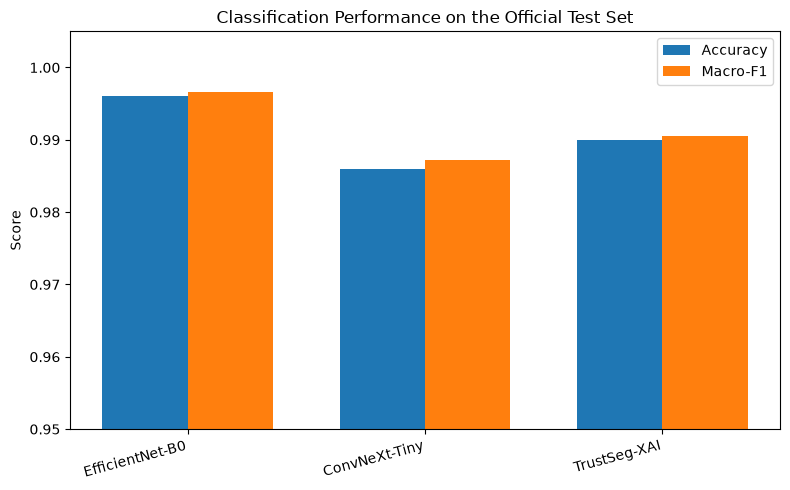

✅ Figure 1 saved.


In [478]:
# ============================================================
# PHASE 16.15 — Figure 1: Classification performance
# ============================================================

classification_plot_df = (

    phase16_classification_publication_df

    .set_index(
        "model"
    )
)


x = np.arange(
    len(
        classification_plot_df
    )
)


width = 0.36


fig, ax = plt.subplots(
    figsize=(8, 5)
)


ax.bar(

    x - width / 2,

    classification_plot_df[
        "accuracy"
    ],

    width,

    label="Accuracy"
)


ax.bar(

    x + width / 2,

    classification_plot_df[
        "macro_f1"
    ],

    width,

    label="Macro-F1"
)


ax.set_xticks(
    x
)


ax.set_xticklabels(
    classification_plot_df.index,
    rotation=15,
    ha="right"
)


ax.set_ylim(
    0.95,
    1.005
)


ax.set_ylabel(
    "Score"
)


ax.set_title(
    "Classification Performance on the Official Test Set"
)


ax.legend()


fig.tight_layout()


PHASE16_FIG1_FILE = (

    PHASE16_FIGURE_DIR
    / "figure1_classification_performance.png"
)


fig.savefig(

    PHASE16_FIG1_FILE,

    dpi=300,

    bbox_inches="tight"
)


plt.show()


print(
    "✅ Figure 1 saved."
)

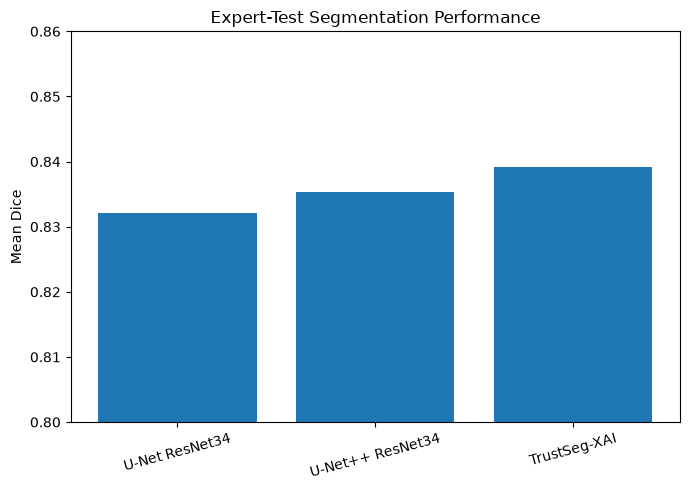

✅ Figure 2 saved.


In [480]:
# ============================================================
# PHASE 16.16 — Figure 2: Segmentation Dice
# ============================================================

fig, ax = plt.subplots(
    figsize=(7, 5)
)


ax.bar(

    phase16_segmentation_publication_df[
        "model"
    ],

    phase16_segmentation_publication_df[
        "dice"
    ]
)


ax.set_ylim(
    0.80,
    0.86
)


ax.set_ylabel(
    "Mean Dice"
)


ax.set_title(
    "Expert-Test Segmentation Performance"
)


ax.tick_params(
    axis="x",
    rotation=15
)


fig.tight_layout()


PHASE16_FIG2_FILE = (

    PHASE16_FIGURE_DIR
    / "figure2_segmentation_dice.png"
)


fig.savefig(

    PHASE16_FIG2_FILE,

    dpi=300,

    bbox_inches="tight"
)


plt.show()


print(
    "✅ Figure 2 saved."
)

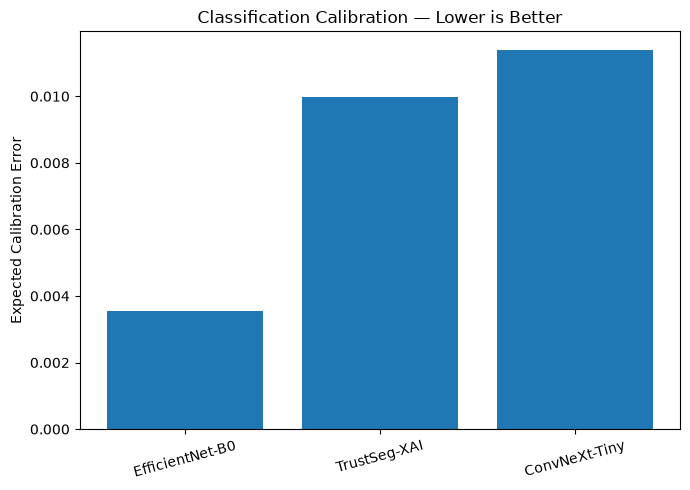

✅ Figure 3 saved.


In [481]:
# ============================================================
# PHASE 16.17 — Figure 3: Expected Calibration Error
# ============================================================

fig, ax = plt.subplots(
    figsize=(7, 5)
)


ax.bar(

    phase16_calibration_df[
        "model"
    ],

    phase16_calibration_df[
        "ece_15_bins"
    ]
)


ax.set_ylabel(
    "Expected Calibration Error"
)


ax.set_title(
    "Classification Calibration — Lower is Better"
)


ax.tick_params(
    axis="x",
    rotation=15
)


fig.tight_layout()


PHASE16_FIG3_FILE = (

    PHASE16_FIGURE_DIR
    / "figure3_calibration_ece.png"
)


fig.savefig(

    PHASE16_FIG3_FILE,

    dpi=300,

    bbox_inches="tight"
)


plt.show()


print(
    "✅ Figure 3 saved."
)

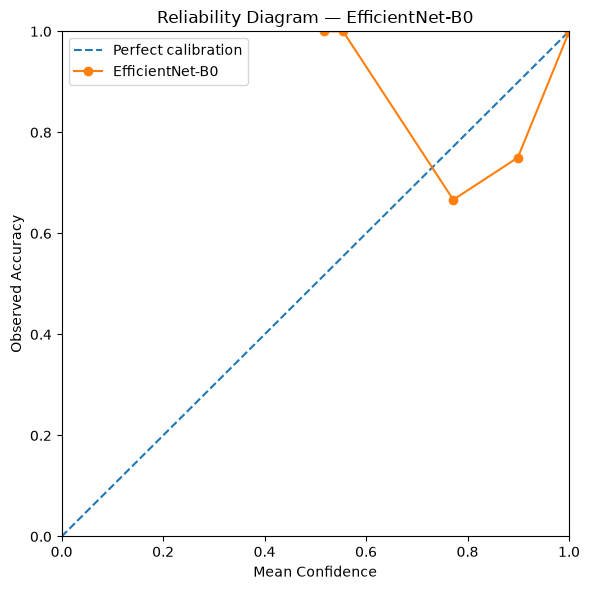

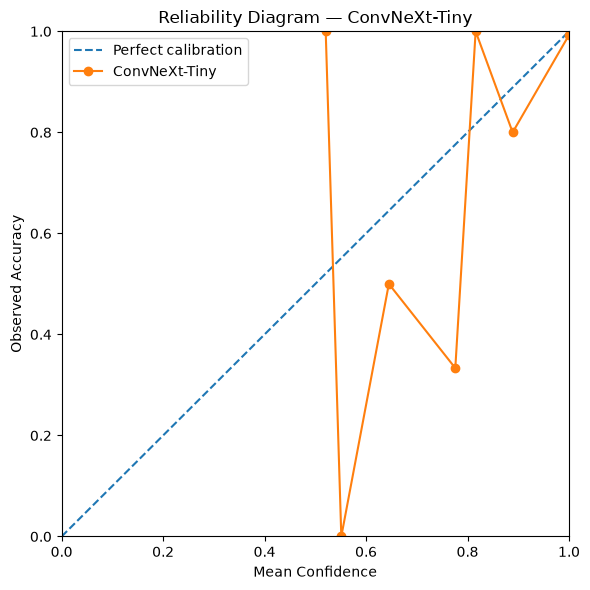

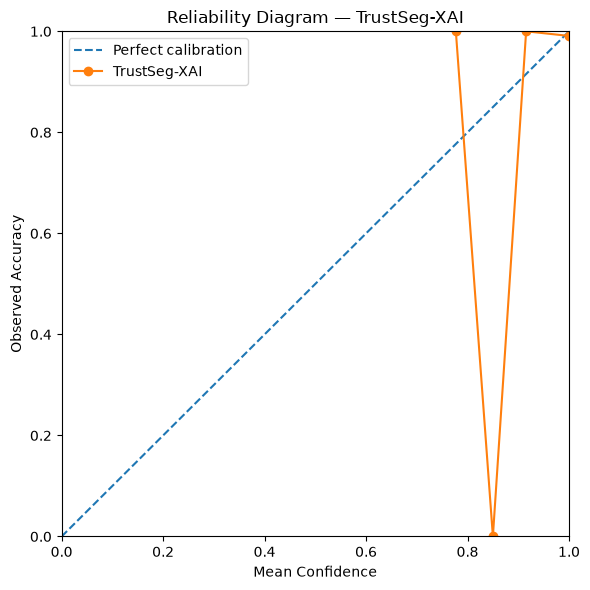

✅ Three reliability diagrams saved.


In [482]:
# ============================================================
# PHASE 16.18 — Reliability diagrams
# ============================================================

phase16_reliability_files = []


for model_name in [

    "EfficientNet-B0",
    "ConvNeXt-Tiny",
    "TrustSeg-XAI"
]:

    model_bins = (

        calibration_reliability_df[

            (
                calibration_reliability_df[
                    "model"
                ]
                ==
                model_name
            )

            &

            (
                calibration_reliability_df[
                    "n"
                ]
                >
                0
            )

        ]

        .copy()
    )


    fig, ax = plt.subplots(
        figsize=(6, 6)
    )


    ax.plot(

        [
            0,
            1
        ],

        [
            0,
            1
        ],

        linestyle="--",

        label="Perfect calibration"
    )


    ax.plot(

        model_bins[
            "mean_confidence"
        ],

        model_bins[
            "accuracy"
        ],

        marker="o",

        label=model_name
    )


    ax.set_xlim(
        0,
        1
    )


    ax.set_ylim(
        0,
        1
    )


    ax.set_xlabel(
        "Mean Confidence"
    )


    ax.set_ylabel(
        "Observed Accuracy"
    )


    ax.set_title(
        f"Reliability Diagram — {model_name}"
    )


    ax.legend()


    fig.tight_layout()


    safe_name = (

        model_name

        .lower()

        .replace(
            " ",
            "_"
        )

        .replace(
            "-",
            "_"
        )
    )


    figure_file = (

        PHASE16_FIGURE_DIR
        / f"figure4_reliability_{safe_name}.png"
    )


    fig.savefig(

        figure_file,

        dpi=300,

        bbox_inches="tight"
    )


    plt.show()


    phase16_reliability_files.append(
        figure_file
    )


assert len(
    phase16_reliability_files
) == 3


print(
    "✅ Three reliability diagrams saved."
)

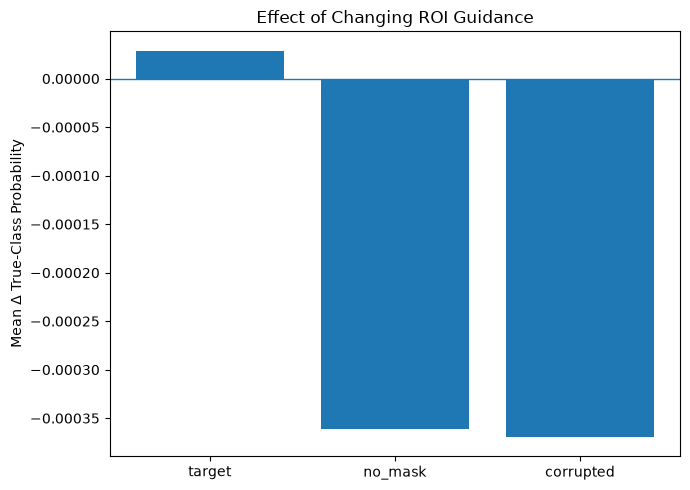

✅ Figure 5 saved.


In [483]:
# ============================================================
# PHASE 16.19 — Figure 5: Mask dependency
# ============================================================

mask_plot_df = (

    maskdep_stats_df.copy()
)


mask_plot_df[
    "label"
] = (

    mask_plot_df[
        "comparison"
    ]

    .str.replace(
        "predicted_vs_",
        "",
        regex=False
    )
)


fig, ax = plt.subplots(
    figsize=(7, 5)
)


ax.bar(

    mask_plot_df[
        "label"
    ],

    mask_plot_df[
        "mean_true_probability_delta"
    ]
)


ax.axhline(
    0,
    linewidth=1
)


ax.set_ylabel(
    "Mean Δ True-Class Probability"
)


ax.set_title(
    "Effect of Changing ROI Guidance"
)


fig.tight_layout()


PHASE16_FIG5_FILE = (

    PHASE16_FIGURE_DIR
    / "figure5_mask_dependency_probability_effect.png"
)


fig.savefig(

    PHASE16_FIG5_FILE,

    dpi=300,

    bbox_inches="tight"
)


plt.show()


print(
    "✅ Figure 5 saved."
)

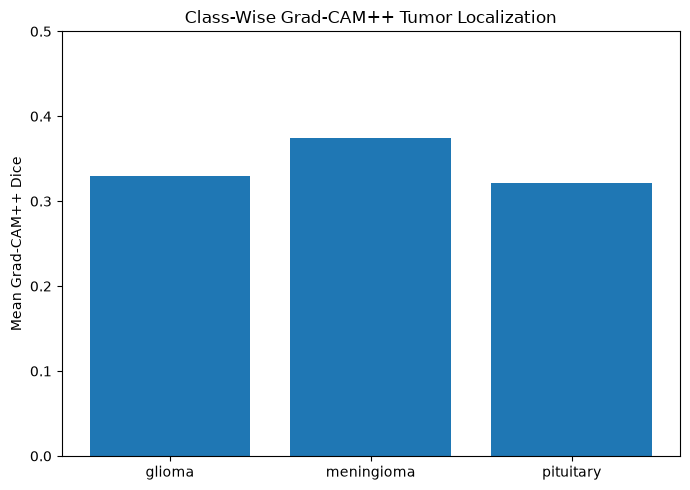

✅ Figure 6 saved.


In [484]:
# ============================================================
# PHASE 16.20 — Figure 6: Grad-CAM++ class-wise Dice
# ============================================================

fig, ax = plt.subplots(
    figsize=(7, 5)
)


ax.bar(

    gradcam_class_df[
        "class_name"
    ],

    gradcam_class_df[
        "xai_dice"
    ]
)


ax.set_ylim(
    0,
    0.5
)


ax.set_ylabel(
    "Mean Grad-CAM++ Dice"
)


ax.set_title(
    "Class-Wise Grad-CAM++ Tumor Localization"
)


fig.tight_layout()


PHASE16_FIG6_FILE = (

    PHASE16_FIGURE_DIR
    / "figure6_gradcam_classwise_dice.png"
)


fig.savefig(

    PHASE16_FIG6_FILE,

    dpi=300,

    bbox_inches="tight"
)


plt.show()


print(
    "✅ Figure 6 saved."
)

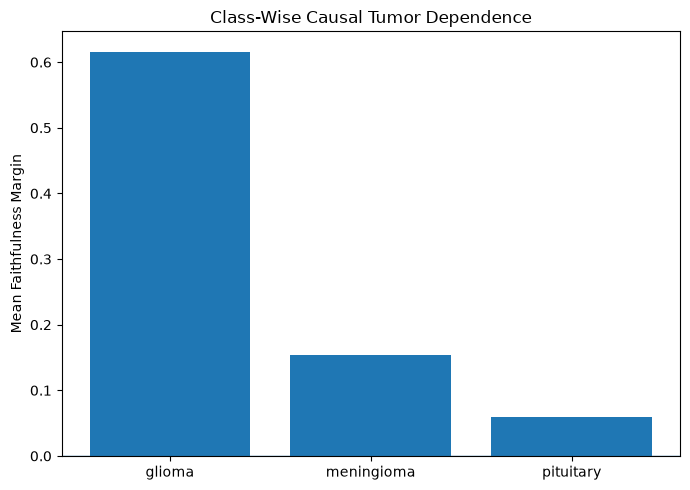

✅ Figure 7 saved.


In [485]:
# ============================================================
# PHASE 16.21 — Figure 7: Causal faithfulness by class
# ============================================================

fig, ax = plt.subplots(
    figsize=(7, 5)
)


ax.bar(

    causal_class_df[
        "class_name"
    ],

    causal_class_df[
        "mean_faithfulness_margin"
    ]
)


ax.axhline(
    0,
    linewidth=1
)


ax.set_ylabel(
    "Mean Faithfulness Margin"
)


ax.set_title(
    "Class-Wise Causal Tumor Dependence"
)


fig.tight_layout()


PHASE16_FIG7_FILE = (

    PHASE16_FIGURE_DIR
    / "figure7_causal_faithfulness_classwise.png"
)


fig.savefig(

    PHASE16_FIG7_FILE,

    dpi=300,

    bbox_inches="tight"
)


plt.show()


print(
    "✅ Figure 7 saved."
)

In [486]:
# ============================================================
# PHASE 16.22 — Paper-ready Results narrative
# ============================================================

def row_for_model(
    dataframe,
    model_name
):

    return (

        dataframe[

            dataframe[
                "model"
            ]
            ==
            model_name

        ]

        .iloc[
            0
        ]
    )


effnet_row = row_for_model(

    phase16_classification_table,

    "EfficientNet-B0"
)


convnext_row = row_for_model(

    phase16_classification_table,

    "ConvNeXt-Tiny"
)


trustseg_row = row_for_model(

    phase16_classification_table,

    "TrustSeg-XAI"
)


trustseg_seg_row = (

    segmentation_comparison_df[

        segmentation_comparison_df[
            "model"
        ]
        ==
        "TrustSeg-XAI"

    ]

    .iloc[
        0
    ]
)


unet_row = (

    segmentation_comparison_df[

        segmentation_comparison_df[
            "model"
        ]
        ==
        "U-Net ResNet34"

    ]

    .iloc[
        0
    ]
)


unetpp_row = (

    segmentation_comparison_df[

        segmentation_comparison_df[
            "model"
        ]
        ==
        "U-Net++ ResNet34"

    ]

    .iloc[
        0
    ]
)


eff_vs_conv = (

    mcnemar_df[

        (
            mcnemar_df[
                "model_a"
            ]
            ==
            "EfficientNet-B0"
        )

        &

        (
            mcnemar_df[
                "model_b"
            ]
            ==
            "ConvNeXt-Tiny"
        )

    ]

    .iloc[
        0
    ]
)


eff_vs_trust = (

    mcnemar_df[

        (
            mcnemar_df[
                "model_a"
            ]
            ==
            "EfficientNet-B0"
        )

        &

        (
            mcnemar_df[
                "model_b"
            ]
            ==
            "TrustSeg-XAI"
        )

    ]

    .iloc[
        0
    ]
)


conv_vs_trust = (

    mcnemar_df[

        (
            mcnemar_df[
                "model_a"
            ]
            ==
            "ConvNeXt-Tiny"
        )

        &

        (
            mcnemar_df[
                "model_b"
            ]
            ==
            "TrustSeg-XAI"
        )

    ]

    .iloc[
        0
    ]
)


no_mask_stats = (

    maskdep_stats_df[

        maskdep_stats_df[
            "comparison"
        ]
        ==
        "predicted_vs_no_mask"

    ]

    .iloc[
        0
    ]
)


corrupt_stats = (

    maskdep_stats_df[

        maskdep_stats_df[
            "comparison"
        ]
        ==
        "predicted_vs_corrupted"

    ]

    .iloc[
        0
    ]
)


eff_cal = row_for_model(

    calibration_metrics_df,

    "EfficientNet-B0"
)


conv_cal = row_for_model(

    calibration_metrics_df,

    "ConvNeXt-Tiny"
)


trust_cal = row_for_model(

    calibration_metrics_df,

    "TrustSeg-XAI"
)


results_markdown = f"""
# TrustSeg-XAI — Final Results Summary

## Classification Performance

On the locked 1,000-image official test set, EfficientNet-B0 achieved the
highest classification accuracy ({effnet_row.accuracy:.4f}) and Macro-F1
({effnet_row.macro_f1:.4f}). TrustSeg-XAI achieved an accuracy of
{trustseg_row.accuracy:.4f} and Macro-F1 of {trustseg_row.macro_f1:.4f},
while ConvNeXt-Tiny achieved {convnext_row.accuracy:.4f} accuracy and
{convnext_row.macro_f1:.4f} Macro-F1.

Bootstrap 95% confidence intervals were
[{effnet_row.accuracy_ci_lower:.4f}, {effnet_row.accuracy_ci_upper:.4f}]
for EfficientNet-B0 accuracy,
[{trustseg_row.accuracy_ci_lower:.4f}, {trustseg_row.accuracy_ci_upper:.4f}]
for TrustSeg-XAI, and
[{convnext_row.accuracy_ci_lower:.4f}, {convnext_row.accuracy_ci_upper:.4f}]
for ConvNeXt-Tiny.

Exact paired McNemar testing showed that EfficientNet-B0 outperformed
ConvNeXt-Tiny in paired correctness
(p={eff_vs_conv.p_value:.6g}), whereas the EfficientNet-B0 versus TrustSeg-XAI
comparison was not statistically significant
(p={eff_vs_trust.p_value:.6g}). The ConvNeXt-Tiny versus TrustSeg-XAI
difference was also not significant
(p={conv_vs_trust.p_value:.6g}).

## Segmentation Performance

On the 860 tumor-positive MRI with expert segmentation masks, TrustSeg-XAI
achieved a mean Dice score of {trustseg_seg_row.dice:.4f}, compared with
{unet_row.dice:.4f} for U-Net ResNet34 and {unetpp_row.dice:.4f} for
U-Net++ ResNet34. TrustSeg-XAI therefore had the highest local point estimate
for Dice among the three segmentation models. Its bootstrap 95% confidence
interval for mean Dice was
[{trustseg_dice_ci_row.ci_lower:.4f}, {trustseg_dice_ci_row.ci_upper:.4f}].
No pairwise statistical claim is made for the segmentation-model differences.

## Mask Dependency

Changing the explicit ROI guidance produced no hard classification changes
among any of the 1,000 test MRI. Predicted, target, no-mask and corrupted-mask
guidance all retained an accuracy of 0.9900 and Macro-F1 of 0.9906.

Removing guidance changed mean true-class probability by only
{no_mask_stats.mean_true_probability_delta:+.6f}, while spatially corrupting
guidance changed it by {corrupt_stats.mean_true_probability_delta:+.6f}.
Although these small probability shifts were statistically detectable, their
magnitude was very small. The results therefore indicate negligible
hard-decision dependence and only very weak soft dependence on the explicit
ROI-guidance pathway.

## Grad-CAM++ Anatomical Localization

Grad-CAM++ was evaluated on the permanently fixed, jointly stratified
150-image tumor subset. The mean XAI Dice was
{gradcam_overall['xai_dice']:.4f}, mean XAI IoU was
{gradcam_overall['xai_iou']:.4f}, Pointing Game accuracy was
{gradcam_overall['pointing_game']:.4f}, and the mean fraction of saliency
inside the expert tumor region was
{gradcam_overall['tumor_saliency_fraction']:.4f}. There were
{gradcam_overall['degenerate_cams']} degenerate CAMs.

The bootstrap 95% confidence interval for XAI IoU was
[{gradcam_iou_ci_row.ci_lower:.4f}, {gradcam_iou_ci_row.ci_upper:.4f}].
These results indicate partial but incomplete anatomical localization rather
than consistently strong localization.

## Causal Tumor Faithfulness

Direct tumor occlusion produced a mean target-class probability drop of
{causal_overall['mean_delta_p_tumor']:.4f}, whereas matched-background
occlusion produced a mean drop of only
{causal_overall['mean_delta_p_background']:.4f}. The mean causal
faithfulness margin was therefore
{causal_overall['mean_faithfulness_margin']:.4f}, with a bootstrap 95%
confidence interval of
[{causal_ci['lower']:.4f}, {causal_ci['upper']:.4f}].

Tumor removal had a greater probability effect than matched-background removal
in {causal_overall['tumor_greater_than_background']:.1%} of cases.
Tumor occlusion changed the target decision in
{causal_overall['tumor_flip_rate']:.1%} of cases, whereas the matched
background control changed it in
{causal_overall['background_flip_rate']:.1%}. The one-sided paired Wilcoxon
test was significant (p={causal_wilcoxon['p_value']:.6g}).

However, the median faithfulness margin was
{causal_overall['median_faithfulness_margin']:.6f}, indicating substantial
case-level heterogeneity. The evidence therefore supports strong average
causal tumor dependence, but not uniformly strong dependence for every MRI.

## No-Tumor Safety

On all 140 official no-tumor MRI, TrustSeg-XAI achieved
{no_tumor_overall['classification_accuracy']:.1%} classification accuracy.
The mean total tumor-class probability was only
{no_tumor_overall['mean_tumor_probability']:.8f}.

At the permanently fixed segmentation threshold of 0.5, the mean and maximum
false-tumor area ratios were both
{no_tumor_overall['mean_false_tumor_area_ratio']:.8f} and
{no_tumor_overall['max_false_tumor_area_ratio']:.8f}, respectively.
The empty-mask rate was
{no_tumor_overall['empty_prediction_rate']:.1%}, and no false-tumor
segmentation detections occurred in this cohort.

These findings indicate excellent no-tumor safety on the evaluated official
test cohort, without implying universal clinical safety.

## Calibration

EfficientNet-B0 was the best-calibrated classifier, with ECE
{eff_cal.ece_15_bins:.6f} and multiclass Brier score
{eff_cal.multiclass_brier:.6f}. TrustSeg-XAI had ECE
{trust_cal.ece_15_bins:.6f} and Brier score
{trust_cal.multiclass_brier:.6f}, while ConvNeXt-Tiny had ECE
{conv_cal.ece_15_bins:.6f} and Brier score
{conv_cal.multiclass_brier:.6f}.

All three classifiers were overconfident on average, with TrustSeg-XAI having
mean confidence {trust_cal.mean_confidence:.6f} despite accuracy
{trustseg_row.accuracy:.6f}.

## Integrated Trustworthiness Interpretation

The final experiments separate several dimensions of trustworthiness.

TrustSeg-XAI achieved strong diagnostic classification and the highest local
segmentation Dice point estimate among the evaluated segmentation models.
However, classification decisions showed negligible dependence on the explicit
ROI-guidance mask, indicating that the global ConvNeXt pathway dominated the
hard classification decision.

At the same time, directly removing expert-defined tumor content from the MRI
produced a large average probability reduction relative to area-matched
background removal. Thus, weak explicit mask dependence does not imply weak
dependence on tumor image content.

Grad-CAM++ provided only partial anatomical localization, whereas the causal
occlusion experiment demonstrated substantially stronger average tumor
dependence. These results show that post-hoc saliency localization and causal
faithfulness capture distinct properties and should not be treated as
interchangeable evidence of model trustworthiness.
"""


PHASE16_RESULTS_SUMMARY_FILE = (

    PHASE16_SUMMARY_DIR
    / "paper_ready_results_summary.md"
)


with open(

    PHASE16_RESULTS_SUMMARY_FILE,

    "w",

    encoding="utf-8"

) as file:

    file.write(
        results_markdown.strip()
        +
        "\n"
    )


print(
    results_markdown
)


print(
    "\n✅ Paper-ready Results narrative saved."
)


# TrustSeg-XAI — Final Results Summary

## Classification Performance

On the locked 1,000-image official test set, EfficientNet-B0 achieved the
highest classification accuracy (0.9960) and Macro-F1
(0.9965). TrustSeg-XAI achieved an accuracy of
0.9900 and Macro-F1 of 0.9906,
while ConvNeXt-Tiny achieved 0.9860 accuracy and
0.9872 Macro-F1.

Bootstrap 95% confidence intervals were
[0.9920, 0.9990]
for EfficientNet-B0 accuracy,
[0.9840, 0.9960]
for TrustSeg-XAI, and
[0.9780, 0.9930]
for ConvNeXt-Tiny.

Exact paired McNemar testing showed that EfficientNet-B0 outperformed
ConvNeXt-Tiny in paired correctness
(p=0.0129395), whereas the EfficientNet-B0 versus TrustSeg-XAI
comparison was not statistically significant
(p=0.145996). The ConvNeXt-Tiny versus TrustSeg-XAI
difference was also not significant
(p=0.454498).

## Segmentation Performance

On the 860 tumor-positive MRI with expert segmentation masks, TrustSeg-XAI
achieved a mean Dice score of 0.8392, compared with
0.8321 for U-Net Re

In [487]:
# ============================================================
# PHASE 16.23 — Consolidated machine-readable master JSON
# ============================================================

def phase16_records_json_safe(
    dataframe
):

    return json.loads(

        dataframe.to_json(
            orient="records"
        )
    )


phase16_master_results = {

    "study":
        "TrustSeg-XAI",

    "status":
        "all experiments permanently locked",

    "classification":
        phase16_records_json_safe(
            phase16_classification_publication_df
        ),

    "segmentation":
        phase16_records_json_safe(
            phase16_segmentation_publication_df
        ),

    "mask_dependency": {

        "conditions":
            phase16_records_json_safe(
                phase16_maskdep_publication_df
            ),

        "paired_statistics":
            phase16_records_json_safe(
                maskdep_stats_df
            )
    },

    "gradcam_plus_plus": {

        "overall":
            gradcam_overall,

        "classwise":
            phase16_records_json_safe(
                gradcam_class_df
            ),

        "planewise":
            phase16_records_json_safe(
                gradcam_plane_df
            )
    },

    "causal_faithfulness": {

        "overall":
            causal_overall,

        "wilcoxon":
            causal_wilcoxon,

        "bootstrap_margin_ci":
            causal_ci,

        "classwise":
            phase16_records_json_safe(
                causal_class_df
            ),

        "planewise":
            phase16_records_json_safe(
                causal_plane_df
            )
    },

    "no_tumor_safety": {

        "overall":
            no_tumor_overall,

        "planewise":
            phase16_records_json_safe(
                no_tumor_plane_df
            )
    },

    "calibration":
        phase16_records_json_safe(
            phase16_calibration_df
        ),

    "mcnemar":
        phase16_records_json_safe(
            phase16_mcnemar_df
        ),

    "bootstrap_confidence_intervals":
        phase16_records_json_safe(
            phase16_bootstrap_df
        ),

    "data_policy": {

        "official_test_used_for_tuning":
            False,

        "final_model_locked_before_test_analysis":
            True,

        "test_driven_retraining":
            False
    }
}


PHASE16_MASTER_JSON_FILE = (

    PHASE16_SUMMARY_DIR
    / "trustseg_xai_final_master_results.json"
)


with open(

    PHASE16_MASTER_JSON_FILE,

    "w",

    encoding="utf-8"

) as file:

    json.dump(

        phase16_master_results,

        file,

        indent=4,

        ensure_ascii=False
    )


print(
    "✅ Final master JSON saved."
)

✅ Final master JSON saved.


In [488]:
# ============================================================
# PHASE 16.24 — Figure manifest
# ============================================================

phase16_figure_manifest_df = pd.DataFrame([

    {
        "figure":
            "Figure 1",

        "file":
            str(
                PHASE16_FIG1_FILE
            ),

        "description":
            (
                "Official-test classification Accuracy "
                "and Macro-F1"
            )
    },

    {
        "figure":
            "Figure 2",

        "file":
            str(
                PHASE16_FIG2_FILE
            ),

        "description":
            "Expert-test segmentation Dice"
    },

    {
        "figure":
            "Figure 3",

        "file":
            str(
                PHASE16_FIG3_FILE
            ),

        "description":
            "15-bin Expected Calibration Error"
    },

    {
        "figure":
            "Figure 4A",

        "file":
            str(
                phase16_reliability_files[
                    0
                ]
            ),

        "description":
            "EfficientNet-B0 reliability diagram"
    },

    {
        "figure":
            "Figure 4B",

        "file":
            str(
                phase16_reliability_files[
                    1
                ]
            ),

        "description":
            "ConvNeXt-Tiny reliability diagram"
    },

    {
        "figure":
            "Figure 4C",

        "file":
            str(
                phase16_reliability_files[
                    2
                ]
            ),

        "description":
            "TrustSeg-XAI reliability diagram"
    },

    {
        "figure":
            "Figure 5",

        "file":
            str(
                PHASE16_FIG5_FILE
            ),

        "description":
            "Mask-guidance probability effects"
    },

    {
        "figure":
            "Figure 6",

        "file":
            str(
                PHASE16_FIG6_FILE
            ),

        "description":
            "Class-wise Grad-CAM++ Dice"
    },

    {
        "figure":
            "Figure 7",

        "file":
            str(
                PHASE16_FIG7_FILE
            ),

        "description":
            "Class-wise causal faithfulness margin"
    }
])


PHASE16_FIGURE_MANIFEST_FILE = (

    PHASE16_SUMMARY_DIR
    / "figure_manifest.csv"
)


phase16_figure_manifest_df.to_csv(

    PHASE16_FIGURE_MANIFEST_FILE,

    index=False
)


display(
    phase16_figure_manifest_df
)


print(
    "✅ Figure manifest saved."
)

,figure,file,description
0,Figure 1,D:\brain_tumor\phase16_final_outputs\figures\f...,Official-test classification Accuracy and Macr...
1,Figure 2,D:\brain_tumor\phase16_final_outputs\figures\f...,Expert-test segmentation Dice
2,Figure 3,D:\brain_tumor\phase16_final_outputs\figures\f...,15-bin Expected Calibration Error
3,Figure 4A,D:\brain_tumor\phase16_final_outputs\figures\f...,EfficientNet-B0 reliability diagram
4,Figure 4B,D:\brain_tumor\phase16_final_outputs\figures\f...,ConvNeXt-Tiny reliability diagram
5,Figure 4C,D:\brain_tumor\phase16_final_outputs\figures\f...,TrustSeg-XAI reliability diagram
6,Figure 5,D:\brain_tumor\phase16_final_outputs\figures\f...,Mask-guidance probability effects
7,Figure 6,D:\brain_tumor\phase16_final_outputs\figures\f...,Class-wise Grad-CAM++ Dice
8,Figure 7,D:\brain_tumor\phase16_final_outputs\figures\f...,Class-wise causal faithfulness margin


✅ Figure manifest saved.


In [489]:
# ============================================================
# PHASE 16.25 — Complete final artifact manifest
# ============================================================

artifact_records = []


for file_path in sorted(
    PHASE16_TABLE_DIR.glob(
        "*"
    )
):

    artifact_records.append({

        "type":
            "table",

        "name":
            file_path.name,

        "path":
            str(
                file_path
            ),

        "exists":
            file_path.exists()
    })


for file_path in sorted(
    PHASE16_FIGURE_DIR.glob(
        "*"
    )
):

    artifact_records.append({

        "type":
            "figure",

        "name":
            file_path.name,

        "path":
            str(
                file_path
            ),

        "exists":
            file_path.exists()
    })


for file_path in sorted(
    PHASE16_SUMMARY_DIR.glob(
        "*"
    )
):

    artifact_records.append({

        "type":
            "summary",

        "name":
            file_path.name,

        "path":
            str(
                file_path
            ),

        "exists":
            file_path.exists()
    })


phase16_artifact_manifest_df = pd.DataFrame(
    artifact_records
)


PHASE16_ARTIFACT_MANIFEST_FILE = (

    PHASE16_DIR
    / "final_artifact_manifest.csv"
)


phase16_artifact_manifest_df.to_csv(

    PHASE16_ARTIFACT_MANIFEST_FILE,

    index=False
)


print(
    "Final artifacts:",
    len(
        phase16_artifact_manifest_df
    )
)


display(
    phase16_artifact_manifest_df
)


assert phase16_artifact_manifest_df[
    "exists"
].all()


print(
    "\n✅ Complete artifact manifest saved."
)

Final artifacts: 12


,type,name,path,exists
0,figure,figure1_classification_performance.png,D:\brain_tumor\phase16_final_outputs\figures\f...,True
1,figure,figure2_segmentation_dice.png,D:\brain_tumor\phase16_final_outputs\figures\f...,True
2,figure,figure3_calibration_ece.png,D:\brain_tumor\phase16_final_outputs\figures\f...,True
3,figure,figure4_reliability_convnext_tiny.png,D:\brain_tumor\phase16_final_outputs\figures\f...,True
4,figure,figure4_reliability_efficientnet_b0.png,D:\brain_tumor\phase16_final_outputs\figures\f...,True
5,figure,figure4_reliability_trustseg_xai.png,D:\brain_tumor\phase16_final_outputs\figures\f...,True
6,figure,figure5_mask_dependency_probability_effect.png,D:\brain_tumor\phase16_final_outputs\figures\f...,True
7,figure,figure6_gradcam_classwise_dice.png,D:\brain_tumor\phase16_final_outputs\figures\f...,True
8,figure,figure7_causal_faithfulness_classwise.png,D:\brain_tumor\phase16_final_outputs\figures\f...,True
9,summary,figure_manifest.csv,D:\brain_tumor\phase16_final_outputs\summary\f...,True



✅ Complete artifact manifest saved.


In [494]:
# ============================================================
# PHASE 16.14 — Save publication-ready tables
# ============================================================

publication_tables = {

    "table1_classification_performance.csv":
        phase16_classification_publication_df,

    "table2_segmentation_performance.csv":
        phase16_segmentation_publication_df,

    "table3a_mask_dependency_conditions.csv":
        phase16_maskdep_publication_df,

    "table3b_mask_dependency_statistics.csv":
        maskdep_stats_df,

    "table4a_gradcam_overall.csv":
        phase16_gradcam_overall_df,

    "table4b_gradcam_classwise.csv":
        gradcam_class_df,

    "table4c_gradcam_planewise.csv":
        gradcam_plane_df,

    "table5a_causal_overall.csv":
        phase16_causal_overall_df,

    "table5b_causal_classwise.csv":
        causal_class_df,

    "table5c_causal_planewise.csv":
        causal_plane_df,

    "table6a_no_tumor_safety.csv":
        phase16_no_tumor_df,

    "table6b_no_tumor_planewise.csv":
        no_tumor_plane_df,

    "table7_calibration.csv":
        phase16_calibration_df,

    "table8_mcnemar.csv":
        phase16_mcnemar_df,

    "table9_bootstrap_ci.csv":
        phase16_bootstrap_df
}


print("=" * 115)
print("SAVING PHASE 16 PUBLICATION TABLES")
print("=" * 115)


for filename, dataframe in publication_tables.items():

    output_file = (
        PHASE16_TABLE_DIR
        /
        filename
    )

    dataframe.to_csv(
        output_file,
        index=False
    )

    assert output_file.exists()

    print(
        f"✅ {filename:<50} "
        f"rows={len(dataframe)}"
    )


saved_csv_files = list(

    PHASE16_TABLE_DIR.glob(
        "*.csv"
    )
)


print("\nSaved CSV count:", len(saved_csv_files))


assert len(saved_csv_files) == 15


print(
    "\n🎯 All 15 publication tables saved successfully."
)

SAVING PHASE 16 PUBLICATION TABLES
✅ table1_classification_performance.csv              rows=3
✅ table2_segmentation_performance.csv                rows=3
✅ table3a_mask_dependency_conditions.csv             rows=4
✅ table3b_mask_dependency_statistics.csv             rows=3
✅ table4a_gradcam_overall.csv                        rows=1
✅ table4b_gradcam_classwise.csv                      rows=3
✅ table4c_gradcam_planewise.csv                      rows=3
✅ table5a_causal_overall.csv                         rows=1
✅ table5b_causal_classwise.csv                       rows=3
✅ table5c_causal_planewise.csv                       rows=3
✅ table6a_no_tumor_safety.csv                        rows=1
✅ table6b_no_tumor_planewise.csv                     rows=3
✅ table7_calibration.csv                             rows=3
✅ table8_mcnemar.csv                                 rows=3
✅ table9_bootstrap_ci.csv                            rows=9

Saved CSV count: 15

🎯 All 15 publication tables saved successfu

In [495]:
from pathlib import Path
import json

PROJECT_ROOT = Path(r"D:\brain_tumor")

rename_map = {
    "phase4_unet_resnet34": "unet_resnet34",
    "phase5_unetplusplus_resnet34": "unetplusplus_resnet34",
    "phase6_efficientnet_b0": "efficientnet_b0",
    "phase7_convnext_tiny": "convnext_tiny",
    "phase8_trustseg_xai": "trustseg_xai",
    "phase10_mask_dependency": "mask_dependency",
    "phase11_gradcampp": "gradcampp",
    "phase12_causal_faithfulness": "causal_faithfulness",
    "phase13_no_tumor_safety": "no_tumor_safety",
    "phase14_calibration": "calibration",
    "phase15_statistical_analysis": "statistical_analysis",
    "phase16_final_outputs": "final_outputs",
}

print("=" * 100)
print("RENAMING PHASE FOLDERS")
print("=" * 100)

rename_results = []

for old_name, new_name in rename_map.items():
    old_path = PROJECT_ROOT / old_name
    new_path = PROJECT_ROOT / new_name

    if old_path.exists():
        if new_path.exists():
            status = f"⚠️ Skipped: target already exists -> {new_name}"
        else:
            old_path.rename(new_path)
            status = f"✅ Renamed: {old_name} -> {new_name}"
    else:
        if new_path.exists():
            status = f"✅ Already clean: {new_name}"
        else:
            status = f"❌ Not found: {old_name}"

    rename_results.append({
        "old_name": old_name,
        "new_name": new_name,
        "status": status
    })

    print(status)

# save rename log
metadata_dir = PROJECT_ROOT / "metadata"
metadata_dir.mkdir(exist_ok=True)

rename_log_file = metadata_dir / "folder_rename_log.json"
with open(rename_log_file, "w", encoding="utf-8") as f:
    json.dump(rename_results, f, indent=2, ensure_ascii=False)

print("\n" + "=" * 100)
print("FINAL TOP-LEVEL FOLDERS")
print("=" * 100)

for p in sorted(PROJECT_ROOT.iterdir()):
    if p.is_dir():
        print("📁", p.name)

print("\n✅ Folder rename log saved:")
print(rename_log_file)

RENAMING PHASE FOLDERS
✅ Renamed: phase4_unet_resnet34 -> unet_resnet34
✅ Renamed: phase5_unetplusplus_resnet34 -> unetplusplus_resnet34
✅ Renamed: phase6_efficientnet_b0 -> efficientnet_b0
✅ Renamed: phase7_convnext_tiny -> convnext_tiny
✅ Renamed: phase8_trustseg_xai -> trustseg_xai
✅ Renamed: phase10_mask_dependency -> mask_dependency
✅ Renamed: phase11_gradcampp -> gradcampp
✅ Renamed: phase12_causal_faithfulness -> causal_faithfulness
✅ Renamed: phase13_no_tumor_safety -> no_tumor_safety
✅ Renamed: phase14_calibration -> calibration
✅ Renamed: phase15_statistical_analysis -> statistical_analysis
✅ Renamed: phase16_final_outputs -> final_outputs

FINAL TOP-LEVEL FOLDERS
📁 calibration
📁 causal_faithfulness
📁 convnext_tiny
📁 efficientnet_b0
📁 final_outputs
📁 gradcampp
📁 mask_dependency
📁 metadata
📁 no_tumor_safety
📁 statistical_analysis
📁 trustseg_xai
📁 unet_resnet34
📁 unetplusplus_resnet34
📁 🧠 Brain Tumor MRI Dataset

✅ Folder rename log saved:
D:\brain_tumor\metadata\folder_rename_

In [496]:
from pathlib import Path

PROJECT_ROOT = Path(r"D:\brain_tumor")

def resolve_existing_dir(*names):
    for name in names:
        p = PROJECT_ROOT / name
        if p.exists():
            return p
    raise FileNotFoundError(
        "None of these folders were found:\n" + "\n".join(names)
    )

PHASE4_DIR  = resolve_existing_dir("unet_resnet34", "phase4_unet_resnet34")
PHASE5_DIR  = resolve_existing_dir("unetplusplus_resnet34", "phase5_unetplusplus_resnet34")
PHASE6_DIR  = resolve_existing_dir("efficientnet_b0", "phase6_efficientnet_b0")
PHASE7_DIR  = resolve_existing_dir("convnext_tiny", "phase7_convnext_tiny")
PHASE8_DIR  = resolve_existing_dir("trustseg_xai", "phase8_trustseg_xai")
PHASE10_DIR = resolve_existing_dir("mask_dependency", "phase10_mask_dependency")
PHASE11_DIR = resolve_existing_dir("gradcampp", "phase11_gradcampp")
PHASE12_DIR = resolve_existing_dir("causal_faithfulness", "phase12_causal_faithfulness")
PHASE13_DIR = resolve_existing_dir("no_tumor_safety", "phase13_no_tumor_safety")
PHASE14_DIR = resolve_existing_dir("calibration", "phase14_calibration")
PHASE15_DIR = resolve_existing_dir("statistical_analysis", "phase15_statistical_analysis")
PHASE16_DIR = resolve_existing_dir("final_outputs", "phase16_final_outputs")

print("=" * 100)
print("COMPATIBLE PHASE PATHS")
print("=" * 100)

print("PHASE4_DIR :", PHASE4_DIR)
print("PHASE5_DIR :", PHASE5_DIR)
print("PHASE6_DIR :", PHASE6_DIR)
print("PHASE7_DIR :", PHASE7_DIR)
print("PHASE8_DIR :", PHASE8_DIR)
print("PHASE10_DIR:", PHASE10_DIR)
print("PHASE11_DIR:", PHASE11_DIR)
print("PHASE12_DIR:", PHASE12_DIR)
print("PHASE13_DIR:", PHASE13_DIR)
print("PHASE14_DIR:", PHASE14_DIR)
print("PHASE15_DIR:", PHASE15_DIR)
print("PHASE16_DIR:", PHASE16_DIR)

print("\n✅ Old/new folder names both supported.")

COMPATIBLE PHASE PATHS
PHASE4_DIR : D:\brain_tumor\unet_resnet34
PHASE5_DIR : D:\brain_tumor\unetplusplus_resnet34
PHASE6_DIR : D:\brain_tumor\efficientnet_b0
PHASE7_DIR : D:\brain_tumor\convnext_tiny
PHASE8_DIR : D:\brain_tumor\trustseg_xai
PHASE10_DIR: D:\brain_tumor\mask_dependency
PHASE11_DIR: D:\brain_tumor\gradcampp
PHASE12_DIR: D:\brain_tumor\causal_faithfulness
PHASE13_DIR: D:\brain_tumor\no_tumor_safety
PHASE14_DIR: D:\brain_tumor\calibration
PHASE15_DIR: D:\brain_tumor\statistical_analysis
PHASE16_DIR: D:\brain_tumor\final_outputs

✅ Old/new folder names both supported.


In [497]:
# ============================================================
# FINAL OUTPUT — CLEAN TABLE / FIGURE / SUMMARY ORGANIZATION
# ============================================================

from pathlib import Path
import shutil


PROJECT_ROOT = Path(r"D:\brain_tumor")


# ------------------------------------------------------------
# Resolve clean or old Phase-16 folder
# ------------------------------------------------------------

if (PROJECT_ROOT / "final_outputs").exists():

    FINAL_OUTPUT_DIR = (
        PROJECT_ROOT
        / "final_outputs"
    )

elif (PROJECT_ROOT / "phase16_final_outputs").exists():

    FINAL_OUTPUT_DIR = (
        PROJECT_ROOT
        / "phase16_final_outputs"
    )

else:

    FINAL_OUTPUT_DIR = (
        PROJECT_ROOT
        / "final_outputs"
    )

    FINAL_OUTPUT_DIR.mkdir(
        parents=True,
        exist_ok=True
    )


# ------------------------------------------------------------
# Final subfolders
# ------------------------------------------------------------

PHASE16_DIR = FINAL_OUTPUT_DIR

PHASE16_TABLE_DIR = (
    FINAL_OUTPUT_DIR
    / "tables"
)

PHASE16_FIGURE_DIR = (
    FINAL_OUTPUT_DIR
    / "figures"
)

PHASE16_SUMMARY_DIR = (
    FINAL_OUTPUT_DIR
    / "summary"
)


for folder in [

    PHASE16_TABLE_DIR,
    PHASE16_FIGURE_DIR,
    PHASE16_SUMMARY_DIR

]:

    folder.mkdir(
        parents=True,
        exist_ok=True
    )


# ------------------------------------------------------------
# Move loose publication tables if any
# ------------------------------------------------------------

for file_path in list(
    FINAL_OUTPUT_DIR.glob(
        "table*.csv"
    )
):

    destination = (
        PHASE16_TABLE_DIR
        /
        file_path.name
    )

    if not destination.exists():

        shutil.move(
            str(file_path),
            str(destination)
        )


# ------------------------------------------------------------
# Move loose figures if any
# ------------------------------------------------------------

figure_extensions = [

    "*.png",
    "*.jpg",
    "*.jpeg",
    "*.svg",
    "*.pdf"
]


for pattern in figure_extensions:

    for file_path in list(
        FINAL_OUTPUT_DIR.glob(
            pattern
        )
    ):

        if not file_path.name.lower().startswith(
            "figure"
        ):

            continue

        destination = (
            PHASE16_FIGURE_DIR
            /
            file_path.name
        )

        if not destination.exists():

            shutil.move(
                str(file_path),
                str(destination)
            )


# ------------------------------------------------------------
# Move summary files if loose
# ------------------------------------------------------------

summary_files = [

    "paper_ready_results_summary.md",
    "trustseg_xai_final_master_results.json",
    "figure_manifest.csv"
]


for filename in summary_files:

    source = (
        FINAL_OUTPUT_DIR
        /
        filename
    )

    destination = (
        PHASE16_SUMMARY_DIR
        /
        filename
    )

    if (
        source.exists()
        and
        not destination.exists()
    ):

        shutil.move(
            str(source),
            str(destination)
        )


# ------------------------------------------------------------
# Update important variables
# ------------------------------------------------------------

PHASE16_RESULTS_SUMMARY_FILE = (

    PHASE16_SUMMARY_DIR
    / "paper_ready_results_summary.md"
)


PHASE16_MASTER_JSON_FILE = (

    PHASE16_SUMMARY_DIR
    / "trustseg_xai_final_master_results.json"
)


PHASE16_FIGURE_MANIFEST_FILE = (

    PHASE16_SUMMARY_DIR
    / "figure_manifest.csv"
)


PHASE16_ARTIFACT_MANIFEST_FILE = (

    PHASE16_DIR
    / "final_artifact_manifest.csv"
)


# ------------------------------------------------------------
# Verification
# ------------------------------------------------------------

table_files = sorted(
    PHASE16_TABLE_DIR.glob(
        "*.csv"
    )
)


figure_files = sorted([

    file_path

    for file_path in (
        PHASE16_FIGURE_DIR.iterdir()
    )

    if file_path.is_file()

])


summary_files_found = sorted([

    file_path

    for file_path in (
        PHASE16_SUMMARY_DIR.iterdir()
    )

    if file_path.is_file()

])


print("=" * 110)
print("FINAL OUTPUT FOLDER ORGANIZATION")
print("=" * 110)


print(
    "\n📁 Final output:"
)

print(
    FINAL_OUTPUT_DIR
)


print(
    "\n📊 TABLES"
)

print(
    "Folder:",
    PHASE16_TABLE_DIR
)

print(
    "Files :",
    len(
        table_files
    )
)


for file_path in table_files:

    print(
        "  ✅",
        file_path.name
    )


print(
    "\n🖼 FIGURES"
)

print(
    "Folder:",
    PHASE16_FIGURE_DIR
)

print(
    "Files :",
    len(
        figure_files
    )
)


for file_path in figure_files:

    print(
        "  ✅",
        file_path.name
    )


print(
    "\n📄 SUMMARY"
)

print(
    "Folder:",
    PHASE16_SUMMARY_DIR
)

print(
    "Files :",
    len(
        summary_files_found
    )
)


for file_path in summary_files_found:

    print(
        "  ✅",
        file_path.name
    )


print("\n" + "=" * 110)

print(
    "✅ Final publication outputs organized successfully."
)

print(
    "✅ Tables and figures are stored in separate folders."
)

print(
    "✅ Experimental results were not modified."
)

print("=" * 110)

FINAL OUTPUT FOLDER ORGANIZATION

📁 Final output:
D:\brain_tumor\final_outputs

📊 TABLES
Folder: D:\brain_tumor\final_outputs\tables
Files : 15
  ✅ table1_classification_performance.csv
  ✅ table2_segmentation_performance.csv
  ✅ table3a_mask_dependency_conditions.csv
  ✅ table3b_mask_dependency_statistics.csv
  ✅ table4a_gradcam_overall.csv
  ✅ table4b_gradcam_classwise.csv
  ✅ table4c_gradcam_planewise.csv
  ✅ table5a_causal_overall.csv
  ✅ table5b_causal_classwise.csv
  ✅ table5c_causal_planewise.csv
  ✅ table6a_no_tumor_safety.csv
  ✅ table6b_no_tumor_planewise.csv
  ✅ table7_calibration.csv
  ✅ table8_mcnemar.csv
  ✅ table9_bootstrap_ci.csv

🖼 FIGURES
Folder: D:\brain_tumor\final_outputs\figures
Files : 9
  ✅ figure1_classification_performance.png
  ✅ figure2_segmentation_dice.png
  ✅ figure3_calibration_ece.png
  ✅ figure4_reliability_convnext_tiny.png
  ✅ figure4_reliability_efficientnet_b0.png
  ✅ figure4_reliability_trustseg_xai.png
  ✅ figure5_mask_dependency_probability_effe

In [498]:
# ============================================================
# VIEW FINAL CLASSIFICATION PERFORMANCE
# ============================================================

from pathlib import Path
import pandas as pd

PROJECT_ROOT = Path(r"D:\brain_tumor")

CLASSIFICATION_TABLE = (
    PROJECT_ROOT
    / "final_outputs"
    / "tables"
    / "table1_classification_performance.csv"
)

classification_df = pd.read_csv(
    CLASSIFICATION_TABLE
)

print("=" * 110)
print("FINAL CLASSIFICATION MODEL PERFORMANCE")
print("=" * 110)

display(
    classification_df
)

FINAL CLASSIFICATION MODEL PERFORMANCE


,model,accuracy,accuracy_95ci,macro_f1,macro_f1_95ci,mcc,auc,mean_confidence,ece_15_bins,multiclass_brier
0,EfficientNet-B0,0.996,"0.9960 [0.9920, 0.9990]",0.996544,"0.9965 [0.9929, 0.9992]",0.994555,0.999630,0.997679,0.003536,0.007649
1,ConvNeXt-Tiny,0.986,"0.9860 [0.9780, 0.9930]",0.987241,"0.9872 [0.9800, 0.9935]",0.980927,0.999018,0.996055,0.011382,0.024853
2,TrustSeg-XAI,0.990,"0.9900 [0.9840, 0.9960]",0.990557,"0.9906 [0.9844, 0.9961]",0.986356,0.999219,0.999375,0.009990,0.019438


In [499]:
# ============================================================
# CLASSIFICATION PERFORMANCE — EASY VIEW
# ============================================================

view_df = classification_df[
    [
        "model",
        "accuracy",
        "macro_f1",
        "mcc",
        "auc"
    ]
].copy()

view_df["Accuracy (%)"] = (
    view_df["accuracy"] * 100
)

view_df["Macro-F1 (%)"] = (
    view_df["macro_f1"] * 100
)

view_df["MCC"] = (
    view_df["mcc"]
)

view_df["AUC (%)"] = (
    view_df["auc"] * 100
)

view_df = view_df[
    [
        "model",
        "Accuracy (%)",
        "Macro-F1 (%)",
        "MCC",
        "AUC (%)"
    ]
]

view_df = view_df.sort_values(
    "Accuracy (%)",
    ascending=False
).reset_index(drop=True)

display(
    view_df.round(4)
)

,model,Accuracy (%),Macro-F1 (%),MCC,AUC (%)
0,EfficientNet-B0,99.6,99.6544,0.9946,99.9630
1,TrustSeg-XAI,99.0,99.0557,0.9864,99.9219
2,ConvNeXt-Tiny,98.6,98.7241,0.9809,99.9018


In [500]:
# ============================================================
# VIEW FINAL SEGMENTATION PERFORMANCE
# ============================================================

SEGMENTATION_TABLE = (
    PROJECT_ROOT
    / "final_outputs"
    / "tables"
    / "table2_segmentation_performance.csv"
)

segmentation_df = pd.read_csv(
    SEGMENTATION_TABLE
)

print("=" * 110)
print("FINAL SEGMENTATION MODEL PERFORMANCE")
print("=" * 110)

display(
    segmentation_df
)

FINAL SEGMENTATION MODEL PERFORMANCE


,model,dice,dice_95ci,iou,precision,recall,specificity,hd95,hd95_penalized
0,U-Net ResNet34,0.832102,NaN,0.740506,0.840236,0.849692,0.997373,8.482558,9.715894
1,U-Net++ ResNet34,0.835310,NaN,0.743632,0.856876,0.839939,0.997560,9.367526,10.187692
2,TrustSeg-XAI,0.839223,"0.8392 [0.8280, 0.8495]",0.747783,0.865963,0.840963,0.997870,7.907168,9.966072


In [501]:
# ============================================================
# COMPLETE MODEL PERFORMANCE SUMMARY
# ============================================================

print("=" * 115)
print("TRUSTSEG-XAI STUDY — FINAL MODEL PERFORMANCE")
print("=" * 115)


print("\nCLASSIFICATION MODELS")
print("-" * 115)

for row in (
    classification_df
    .sort_values(
        "accuracy",
        ascending=False
    )
    .itertuples(index=False)
):

    print(
        f"{row.model:<20} | "
        f"Accuracy = {row.accuracy*100:6.2f}% | "
        f"Macro-F1 = {row.macro_f1*100:6.2f}% | "
        f"MCC = {row.mcc:.6f} | "
        f"AUC = {row.auc:.6f}"
    )


print("\nSEGMENTATION MODELS")
print("-" * 115)

for row in (
    segmentation_df
    .sort_values(
        "dice",
        ascending=False
    )
    .itertuples(index=False)
):

    print(
        f"{row.model:<20} | "
        f"Dice = {row.dice*100:6.2f}% | "
        f"IoU = {row.iou*100:6.2f}% | "
        f"Precision = {row.precision*100:6.2f}% | "
        f"Recall = {row.recall*100:6.2f}% | "
        f"HD95 = {row.hd95:.4f}"
    )


print("\n" + "=" * 115)

TRUSTSEG-XAI STUDY — FINAL MODEL PERFORMANCE

CLASSIFICATION MODELS
-------------------------------------------------------------------------------------------------------------------
EfficientNet-B0      | Accuracy =  99.60% | Macro-F1 =  99.65% | MCC = 0.994555 | AUC = 0.999630
TrustSeg-XAI         | Accuracy =  99.00% | Macro-F1 =  99.06% | MCC = 0.986356 | AUC = 0.999219
ConvNeXt-Tiny        | Accuracy =  98.60% | Macro-F1 =  98.72% | MCC = 0.980927 | AUC = 0.999018

SEGMENTATION MODELS
-------------------------------------------------------------------------------------------------------------------
TrustSeg-XAI         | Dice =  83.92% | IoU =  74.78% | Precision =  86.60% | Recall =  84.10% | HD95 = 7.9072
U-Net++ ResNet34     | Dice =  83.53% | IoU =  74.36% | Precision =  85.69% | Recall =  83.99% | HD95 = 9.3675
U-Net ResNet34       | Dice =  83.21% | IoU =  74.05% | Precision =  84.02% | Recall =  84.97% | HD95 = 8.4826



In [502]:
# ============================================================
# VIEW CALIBRATION PERFORMANCE
# ============================================================

CALIBRATION_TABLE = (
    PROJECT_ROOT
    / "final_outputs"
    / "tables"
    / "table7_calibration.csv"
)

calibration_df = pd.read_csv(
    CALIBRATION_TABLE
)

display(
    calibration_df
)

,model,accuracy,mean_confidence,confidence_minus_accuracy,ece_15_bins,multiclass_brier
0,EfficientNet-B0,0.996,0.997679,0.001679,0.003536,0.007649
1,TrustSeg-XAI,0.990,0.999375,0.009375,0.009990,0.019438
2,ConvNeXt-Tiny,0.986,0.996055,0.010055,0.011382,0.024853
